<a href="https://colab.research.google.com/github/tiagoeletro-bot/Ar-Condicionado-HVAC---notebookLM-/blob/main/CH_TOS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==========================================================
# CAG AUDIT FRAMEWORK
# Módulo 01 - Importação dos Dados
# Bloco 01 - Configuração do Ambiente
# ==========================================================

# Instala bibliotecas complementares

!pip install openpyxl xlsxwriter python-docx tqdm scipy -q

# ==========================================================
# IMPORTAÇÃO DAS BIBLIOTECAS
# ==========================================================

import os
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd

from scipy import stats

from tqdm.notebook import tqdm

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)
pd.set_option("display.float_format", "{:.4f}".format)

print("Bibliotecas carregadas com sucesso.")

# ==========================================================
# IDENTIFICAÇÃO DO PROJETO
# ==========================================================

PROJETO = {
    "cliente": "Torre Olavo Setúbal",
    "sistema": "Central de Água Gelada",
    "versao": "1.0",
    "autor": "Framework CAG Audit",
    "data_execucao": datetime.now().strftime("%d/%m/%Y %H:%M:%S")
}

print("Projeto iniciado")

for chave, valor in PROJETO.items():
    print(f"{chave:20}: {valor}")

    # ==========================================================
# UPLOAD DO ARQUIVO
# ==========================================================

from google.colab import files

uploaded = files.upload()

# ==========================================================
# IDENTIFICA O ARQUIVO EXCEL
# ==========================================================

arquivo_excel = list(uploaded.keys())[0]

print("Arquivo encontrado:")
print(arquivo_excel)

# ==========================================================
# TESTE DE LEITURA
# ==========================================================

try:

    excel = pd.ExcelFile(arquivo_excel)

    print("Arquivo aberto com sucesso.")

except Exception as erro:

    print("Erro na abertura do arquivo.")

    print(erro)

    # ==========================================================
# IDENTIFICAÇÃO DAS ABAS
# ==========================================================

abas = excel.sheet_names

print(f"Foram encontradas {len(abas)} abas.\n")

for i, aba in enumerate(abas, start=1):

    print(f"{i:02d} - {aba}")

    # ==========================================================
# IMPORTAÇÃO DAS ABAS
# ==========================================================

dados = {}

for aba in tqdm(abas):

    dados[aba] = pd.read_excel(
        arquivo_excel,
        sheet_name=aba
    )

print()

print("Todas as abas foram importadas.")

# ==========================================================
# RESUMO DA IMPORTAÇÃO
# ==========================================================

resumo = []

for aba, df in dados.items():

    resumo.append({
        "Aba": aba,
        "Linhas": len(df),
        "Colunas": len(df.columns),
        "Nulos": int(df.isna().sum().sum())
    })

resumo_importacao = pd.DataFrame(resumo)

display(resumo_importacao)

# ==========================================================
# EXPORTAÇÃO DO LOG
# ==========================================================

nome_log = "00_Log_Importacao.xlsx"

with pd.ExcelWriter(nome_log, engine="xlsxwriter") as writer:

    resumo_importacao.to_excel(
        writer,
        index=False,
        sheet_name="Importacao"
    )

print(f"Log salvo: {nome_log}")



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 15.4 MB/s eta 0:00:00
Bibliotecas carregadas com sucesso.
Projeto iniciado
cliente             : Torre Olavo Setúbal
sistema             : Central de Água Gelada
versao              : 1.0
autor               : Framework CAG Audit
data_execucao       : 18/08/2026 14:04:37


Saving 01 - Levantamentos de dados CAG E2.xlsx to 01 - Levantamentos de dados CAG E2.xlsx
Arquivo encontrado:
01 - Levantamentos de dados CAG E2.xlsx
Arquivo aberto com sucesso.
Foram encontradas 9 abas.

01 - RELAÇÃO DE CONSUMO
02 - COP
03 - APPROACH EVAPORADOR
04 - APPROACH CONDENSADOR
05 - CARGA TÉRMICA (TR)
06 - CONSUMO CAG
07 - POTÊNCIA ATIVA CAG
08 - VAZÃO AG
09 - FREQUÊNCIA VSD


  0%|          | 0/9 [00:00<?, ?it/s]


Todas as abas foram importadas.


,Aba,Linhas,Colunas,Nulos
0,RELAÇÃO DE CONSUMO,4295,4,0
1,COP,4295,4,0
2,APPROACH EVAPORADOR,4295,7,0
3,APPROACH CONDENSADOR,4295,7,0
4,CARGA TÉRMICA (TR),4295,4,0
5,CONSUMO CAG,31,2,0
6,POTÊNCIA ATIVA CAG,4295,2,0
7,VAZÃO AG,4295,4,0
8,FREQUÊNCIA VSD,4288,4,0


Log salvo: 00_Log_Importacao.xlsx


In [2]:
# ==========================================================
# BLOCO 02
# FUNÇÕES AUXILIARES
# ==========================================================

import re
import numpy as np
import pandas as pd

def normalizar_nome(texto):

    texto = str(texto)

    texto = texto.strip()

    texto = texto.upper()

    texto = texto.replace("\n", " ")

    texto = re.sub(r"\s+", " ", texto)

    return texto


# ==========================================================
# DETECÇÃO ROBUSTA DA COLUNA DE DATA
# ==========================================================

def detectar_coluna_data(df):
    """
    Detecta automaticamente a coluna de data/hora.
    Primeiro tenta pelo nome da coluna.
    Se não encontrar, tenta pelo conteúdo.
    """

    candidatos = [
        "DATAHORA",
        "DATA_HORA",
        "DATA HORA",
        "DATA/HORA",
        "DATAHORA"
        "DataHora"
        "TIMESTAMP",
        "TIME",
        "DATE",
        "DATA",
        "HORARIO",
        "HORA",
        "INSTANT"
    ]

    # Procura pelo nome
    for coluna in df.columns:

        nome = (
            str(coluna)
            .strip()
            .upper()
            .replace("/", "")
            .replace("_", "")
            .replace(" ", "")
        )

        if nome in [c.replace("/", "").replace("_", "").replace(" ", "") for c in candidatos]:
            return coluna

    # Procura pelo conteúdo
    for coluna in df.columns:

        teste = pd.to_datetime(df[coluna], errors="coerce")

        if teste.notna().mean() > 0.90:
            return coluna

    return None

    # ==========================================================
# PADRONIZAÇÃO DAS COLUNAS
# ==========================================================

dados_padronizados = {}

for aba, df in dados.items():

    copia = df.copy()

    copia.columns = [
        normalizar_nome(c)
        for c in copia.columns
    ]

    dados_padronizados[aba] = copia

print("Colunas padronizadas.")

# ==========================================================
# IDENTIFICAÇÃO DA DATA
# ==========================================================

datas = {}

for aba, df in dados_padronizados.items():

    coluna_data = detectar_coluna_data(df)

    datas[aba] = coluna_data

datas

# ==========================================================
# CONVERSÃO DA DATA
# ==========================================================

for aba, df in dados_padronizados.items():

    coluna = datas[aba]

    if coluna is not None:

        df[coluna] = pd.to_datetime(
            df[coluna],
            errors="coerce"
        )

print("Datas convertidas.")

# ==========================================================
# CONVERSÃO NUMÉRICA
# ==========================================================

for aba, df in dados_padronizados.items():

    for coluna in df.columns:

        if coluna != datas[aba]:

            try:

                df[coluna] = (
                    df[coluna]
                    .astype(str)
                    .str.replace(",", ".", regex=False)
                )

                df[coluna] = pd.to_numeric(
                    df[coluna],
                    errors="ignore"
                )

            except:

                pass

print("Conversão concluída.")

# ==========================================================
# QUALIDADE DOS DADOS
# ==========================================================

qualidade = []

for aba, df in dados_padronizados.items():

    qualidade.append({

        "ABA": aba,

        "LINHAS": len(df),

        "COLUNAS": len(df.columns),

        "NULOS": int(df.isna().sum().sum()),

        "DUPLICADOS": int(df.duplicated().sum()),

        "COLUNA_DATA": datas[aba]

    })

qualidade = pd.DataFrame(qualidade)

display(qualidade)

# ==========================================================
# PERFIL DAS VARIÁVEIS
# ==========================================================

perfil = []

for aba, df in dados_padronizados.items():

    for coluna in df.columns:

        perfil.append({

            "ABA": aba,

            "VARIAVEL": coluna,

            "TIPO": str(df[coluna].dtype),

            "NULOS": int(df[coluna].isna().sum()),

            "UNICOS": df[coluna].nunique()

        })

perfil = pd.DataFrame(perfil)

display(perfil.head())

# ==========================================================
# EXPORTAÇÃO
# ==========================================================

arquivo_saida = "01_Qualidade_Dados.xlsx"

with pd.ExcelWriter(
    arquivo_saida,
    engine="xlsxwriter"
) as writer:

    qualidade.to_excel(
        writer,
        sheet_name="Resumo",
        index=False
    )

    perfil.to_excel(
        writer,
        sheet_name="Variaveis",
        index=False
    )

print("Arquivo criado:", arquivo_saida)

# ==========================================================
# ESTATÍSTICAS GERAIS
# ==========================================================

estatisticas = []

for aba, df in dados_padronizados.items():

    for coluna in df.select_dtypes(include=np.number):

        serie = df[coluna]

        estatisticas.append({

            "ABA": aba,

            "VARIAVEL": coluna,

            "MEDIA": serie.mean(),

            "MINIMO": serie.min(),

            "MAXIMO": serie.max(),

            "DESVIO": serie.std()

        })

estatisticas = pd.DataFrame(estatisticas)

display(estatisticas.head())



Colunas padronizadas.
Datas convertidas.
Conversão concluída.


,ABA,LINHAS,COLUNAS,NULOS,DUPLICADOS,COLUNA_DATA
0,RELAÇÃO DE CONSUMO,4295,4,0,0,DATAHORA
1,COP,4295,4,0,0,DATAHORA
2,APPROACH EVAPORADOR,4295,7,0,0,DATAHORA
3,APPROACH CONDENSADOR,4295,7,0,0,DATAHORA
4,CARGA TÉRMICA (TR),4295,4,0,0,DATAHORA
5,CONSUMO CAG,31,2,0,0,DATAHORA
6,POTÊNCIA ATIVA CAG,4295,2,0,0,DATAHORA
7,VAZÃO AG,4295,4,0,0,DATAHORA
8,FREQUÊNCIA VSD,4288,4,0,0,DATAHORA


,ABA,VARIAVEL,TIPO,NULOS,UNICOS
0,RELAÇÃO DE CONSUMO,DATAHORA,datetime64[ns],0,4295
1,RELAÇÃO DE CONSUMO,CEITE2PGCAG1CHAG01_VI_RCO,float64,0,735
2,RELAÇÃO DE CONSUMO,CEITE2PGCAG1CHAG02_VI_RCO,float64,0,46
3,RELAÇÃO DE CONSUMO,CEITE2PGCAG1CHAG03_VI_RCO,float64,0,1992
4,COP,DATAHORA,datetime64[ns],0,4295


Arquivo criado: 01_Qualidade_Dados.xlsx


,ABA,VARIAVEL,MEDIA,MINIMO,MAXIMO,DESVIO
0,RELAÇÃO DE CONSUMO,CEITE2PGCAG1CHAG01_VI_RCO,-16.4911,-688.5404,50.4689,110.9916
1,RELAÇÃO DE CONSUMO,CEITE2PGCAG1CHAG02_VI_RCO,-4.9438,-22.3464,51.9863,7.1978
2,RELAÇÃO DE CONSUMO,CEITE2PGCAG1CHAG03_VI_RCO,1.5606,-25.0106,70.7780,1.3406
3,COP,CEITE2PGCAG1CHAG01_IE-COP,0.4397,0.0000,3.9118,1.0453
4,COP,CEITE2PGCAG1CHAG02_IE-COP,0.0257,0.0000,3.4108,0.2806


In [3]:
datas = {}

for aba, df in dados_padronizados.items():
    coluna_data = detectar_coluna_data(df)
    datas[aba] = coluna_data

print(datas)

{'RELAÇÃO DE CONSUMO': 'DATAHORA', 'COP': 'DATAHORA', 'APPROACH EVAPORADOR': 'DATAHORA', 'APPROACH CONDENSADOR': 'DATAHORA', 'CARGA TÉRMICA (TR)': 'DATAHORA', 'CONSUMO CAG': 'DATAHORA', 'POTÊNCIA ATIVA CAG': 'DATAHORA', 'VAZÃO AG': 'DATAHORA', 'FREQUÊNCIA VSD': 'DATAHORA'}


In [4]:
# ==========================================================
# BLOCO 2.5
# FUNÇÕES DE ENGENHARIA
# ==========================================================

import re

def identificar_ura(tag):

    tag = str(tag).upper()

    if "CHAG01" in tag:
        return "URA01"

    elif "CHAG02" in tag:
        return "URA02"

    elif "CHAG03" in tag:
        return "URA03"

    return "CAG"


def identificar_circuito(tag):

    tag = str(tag).upper()

    if tag.endswith("1"):
        return "Circuito 1"

    elif tag.endswith("2"):
        return "Circuito 2"

    return "-"

    # ==========================================================
# IDENTIFICA A VARIÁVEL
# ==========================================================

def identificar_variavel(tag):

    tag = str(tag).upper()

    if "IE-COP" in tag:
        return "COP"

    elif "VI_RCO" in tag:
        return "kW/TR"

    elif "VI-CTE" in tag:
        return "Carga Térmica"

    elif "CH-WFL" in tag:
        return "Vazão"

    elif "CH-VOT" in tag:
        return "Frequência VSD"

    elif "APPEV" in tag:
        return "Approach Evaporador"

    elif "APPCN" in tag:
        return "Approach Condensador"

    elif "VI-KWH" in tag:
        return "Energia CAG"

    elif "VI-POT" in tag:
        return "Potência CAG"

    return "Outra"

    # ==========================================================
# CATEGORIA
# ==========================================================

def categoria(tag):

    v = identificar_variavel(tag)

    mapa = {

        "COP":"Eficiência",

        "kW/TR":"Eficiência",

        "Carga Térmica":"Carga",

        "Vazão":"Hidráulica",

        "Approach Evaporador":"Térmica",

        "Approach Condensador":"Térmica",

        "Frequência VSD":"Controle",

        "Energia CAG":"Energia",

        "Potência CAG":"Energia"

    }

    return mapa.get(v,"Outros")

    # ==========================================================
# UNIDADE
# ==========================================================

def unidade(tag):

    v = identificar_variavel(tag)

    unidades = {

        "COP":"adimensional",

        "kW/TR":"kW/TR",

        "Carga Térmica":"TR",

        "Vazão":"m³/h",

        "Approach Evaporador":"°C",

        "Approach Condensador":"°C",

        "Frequência VSD":"Hz",

        "Energia CAG":"kWh",

        "Potência CAG":"kW"

    }

    return unidades.get(v,"")

    # ==========================================================
# CATÁLOGO DE TAGS
# ==========================================================

lista = []

for aba, df in dados_padronizados.items():

    coluna_data = datas[aba]

    for coluna in df.columns:

        if coluna == coluna_data:
            continue

        lista.append({

            "TAG": coluna,

            "ABA": aba,

            "URA": identificar_ura(coluna),

            "VARIAVEL": identificar_variavel(coluna),

            "CATEGORIA": categoria(coluna),

            "UNIDADE": unidade(coluna),

            "CIRCUITO": identificar_circuito(coluna),

            "SISTEMA": "Central Água Gelada"

        })

dim_tag = (
    pd.DataFrame(lista)
      .drop_duplicates()
      .sort_values(["URA","VARIAVEL"])
      .reset_index(drop=True)
)

display(dim_tag.head())

# ==========================================================
# INVENTÁRIO
# ==========================================================

print()

print("Número de TAGs:",len(dim_tag))

print()

print("URA")

display(
    dim_tag.groupby("URA").size()
)

print()

print("Categorias")

display(
    dim_tag.groupby("CATEGORIA").size()
)

print()

print("Variáveis")

display(
    dim_tag.groupby("VARIAVEL").size()
)

# ==========================================================
# QUALIDADE
# ==========================================================

display(

    dim_tag.isna().sum()

)

display(

    dim_tag.describe(include="all")

)

# ==========================================================
# EXPORTAÇÃO
# ==========================================================

arquivo="02_Catalogo_TAGs.xlsx"

with pd.ExcelWriter(
    arquivo,
    engine="xlsxwriter"
) as writer:

    dim_tag.to_excel(
        writer,
        sheet_name="DIM_TAG",
        index=False
    )

print()

print("Catálogo criado.")

print(arquivo)

,TAG,ABA,URA,VARIAVEL,CATEGORIA,UNIDADE,CIRCUITO,SISTEMA
0,CEITE2PGCM01QFCO00_VI-KWH,CONSUMO CAG,CAG,Energia CAG,Energia,kWh,-,Central Água Gelada
1,CEITE2PGCM01QFCO00_VI-POT,POTÊNCIA ATIVA CAG,CAG,Potência CAG,Energia,kW,-,Central Água Gelada
2,CEITE2PGCAG1CHAG01_APPCN1,APPROACH CONDENSADOR,URA01,Approach Condensador,Térmica,°C,Circuito 1,Central Água Gelada
3,CEITE2PGCAG1CHAG01_APPCN2,APPROACH CONDENSADOR,URA01,Approach Condensador,Térmica,°C,Circuito 2,Central Água Gelada
4,CEITE2PGCAG1CHAG01_APPEV1,APPROACH EVAPORADOR,URA01,Approach Evaporador,Térmica,°C,Circuito 1,Central Água Gelada



Número de TAGs: 29

URA


,0
URA,
CAG,2
URA01,9
URA02,9
URA03,9



Categorias


,0
CATEGORIA,
Carga,3
Controle,3
Eficiência,6
Energia,2
Hidráulica,3
Térmica,12



Variáveis


,0
VARIAVEL,
Approach Condensador,6
Approach Evaporador,6
COP,3
Carga Térmica,3
Energia CAG,1
Frequência VSD,3
Potência CAG,1
Vazão,3
kW/TR,3


,0
TAG,0
ABA,0
URA,0
VARIAVEL,0
CATEGORIA,0
UNIDADE,0
CIRCUITO,0
SISTEMA,0


,TAG,ABA,URA,VARIAVEL,CATEGORIA,UNIDADE,CIRCUITO,SISTEMA
count,29,29,29,29,29,29,29,29
unique,29,9,4,9,6,8,3,1
top,CEITE2PGCM01QFCO00_VI-KWH,APPROACH CONDENSADOR,URA01,Approach Condensador,Térmica,°C,-,Central Água Gelada
freq,1,6,9,6,12,12,17,29



Catálogo criado.
02_Catalogo_TAGs.xlsx


In [5]:
# ==========================================================
# BLOCO 03
# DIM_TEMPO
# ==========================================================

# Localiza automaticamente todas as datas existentes
datas_unicas = set()

for aba, df in dados_padronizados.items():

    coluna_data = datas.get(aba)

    if coluna_data is None:
        continue

    serie = pd.to_datetime(
        df[coluna_data],
        errors="coerce"
    )

    datas_unicas.update(serie.dropna().unique())

datas_unicas = sorted(list(datas_unicas))

dim_tempo = pd.DataFrame({

    "DATA_HORA": datas_unicas

})

dim_tempo["ID_TEMPO"] = range(1, len(dim_tempo)+1)

dim_tempo["ANO"] = dim_tempo["DATA_HORA"].dt.year

dim_tempo["MES"] = dim_tempo["DATA_HORA"].dt.month

dim_tempo["DIA"] = dim_tempo["DATA_HORA"].dt.day

dim_tempo["HORA"] = dim_tempo["DATA_HORA"].dt.hour

dim_tempo["MINUTO"] = dim_tempo["DATA_HORA"].dt.minute

dim_tempo["TRIMESTRE"] = dim_tempo["DATA_HORA"].dt.quarter

dim_tempo["SEMANA"] = dim_tempo["DATA_HORA"].dt.isocalendar().week

dim_tempo["DIA_SEMANA"] = dim_tempo["DATA_HORA"].dt.day_name()

dim_tempo["FIM_SEMANA"] = dim_tempo["DIA_SEMANA"].isin(
    ["Saturday","Sunday"]
)

display(dim_tempo.head())

# ==========================================================
# DIM_EQUIPAMENTO
# ==========================================================

equipamentos = sorted(dim_tag["URA"].unique())

dim_equipamento = pd.DataFrame({

    "URA": equipamentos

})

dim_equipamento["ID_EQUIPAMENTO"] = range(
    1,
    len(dim_equipamento)+1
)

dim_equipamento["EQUIPAMENTO"] = dim_equipamento["URA"].replace({

    "URA01":"Chiller 01",

    "URA02":"Chiller 02",

    "URA03":"Chiller 03",

    "CAG":"Central Água Gelada"

})

dim_equipamento["TIPO"] = "Chiller"

dim_equipamento.loc[
    dim_equipamento["URA"]=="CAG",
    "TIPO"
] = "Sistema"

dim_equipamento["FABRICANTE"] = "A definir"

dim_equipamento["CAPACIDADE_TR"] = np.nan

display(dim_equipamento)

# ==========================================================
# DIM_VARIAVEL
# ==========================================================

dim_variavel = (

    dim_tag[

        [

            "VARIAVEL",

            "UNIDADE",

            "CATEGORIA"

        ]

    ]

    .drop_duplicates()

    .sort_values("VARIAVEL")

    .reset_index(drop=True)

)

dim_variavel["ID_VARIAVEL"] = range(
    1,
    len(dim_variavel)+1
)

dim_variavel["TIPO"] = "Processo"

dim_variavel.loc[

    dim_variavel["VARIAVEL"].isin(

        [

            "COP",

            "kW/TR"

        ]

    ),

    "TIPO"

] = "KPI"

display(dim_variavel)

# ==========================================================
# DIM_SISTEMA
# ==========================================================

dim_sistema = pd.DataFrame({

    "ID_SISTEMA":[1],

    "SISTEMA":[

        "Central Água Gelada"

    ],

    "SIGLA":[

        "CAG"

    ]

})

display(dim_sistema)

# ==========================================================
# ENRIQUECIMENTO DIM_TAG
# ==========================================================

dim_tag = dim_tag.merge(

    dim_equipamento[

        [

            "URA",

            "ID_EQUIPAMENTO"

        ]

    ],

    on="URA",

    how="left"

)

dim_tag = dim_tag.merge(

    dim_variavel[

        [

            "VARIAVEL",

            "ID_VARIAVEL"

        ]

    ],

    on="VARIAVEL",

    how="left"

)

dim_tag["ID_TAG"] = range(

    1,

    len(dim_tag)+1

)

display(dim_tag.head())

# ==========================================================
# RESUMO
# ==========================================================

print("="*60)

print("DIMENSÕES ANALÍTICAS")

print("="*60)

print()

print("DIM_TEMPO")

print(len(dim_tempo))

print()

print("DIM_TAG")

print(len(dim_tag))

print()

print("DIM_VARIAVEL")

print(len(dim_variavel))

print()

print("DIM_EQUIPAMENTO")

print(len(dim_equipamento))

print()

print("DIM_SISTEMA")

print(len(dim_sistema))

# ==========================================================
# EXPORTAÇÃO
# ==========================================================

arquivo = "03_Modelo_Dimensional.xlsx"

with pd.ExcelWriter(

    arquivo,

    engine="xlsxwriter"

) as writer:

    dim_tempo.to_excel(

        writer,

        sheet_name="DIM_TEMPO",

        index=False

    )

    dim_tag.to_excel(

        writer,

        sheet_name="DIM_TAG",

        index=False

    )

    dim_variavel.to_excel(

        writer,

        sheet_name="DIM_VARIAVEL",

        index=False

    )

    dim_equipamento.to_excel(

        writer,

        sheet_name="DIM_EQUIPAMENTO",

        index=False

    )

    dim_sistema.to_excel(

        writer,

        sheet_name="DIM_SISTEMA",

        index=False

    )

print()

print("Modelo Dimensional criado com sucesso.")

print()

print(arquivo)



,DATA_HORA,ID_TEMPO,ANO,MES,DIA,HORA,MINUTO,TRIMESTRE,SEMANA,DIA_SEMANA,FIM_SEMANA
0,2026-06-01 00:00:00,1,2026,6,1,0,0,2,23,Monday,False
1,2026-06-01 00:10:00,2,2026,6,1,0,10,2,23,Monday,False
2,2026-06-01 00:20:00,3,2026,6,1,0,20,2,23,Monday,False
3,2026-06-01 00:30:00,4,2026,6,1,0,30,2,23,Monday,False
4,2026-06-01 00:40:00,5,2026,6,1,0,40,2,23,Monday,False


,URA,ID_EQUIPAMENTO,EQUIPAMENTO,TIPO,FABRICANTE,CAPACIDADE_TR
0,CAG,1,Central Água Gelada,Sistema,A definir,NaN
1,URA01,2,Chiller 01,Chiller,A definir,NaN
2,URA02,3,Chiller 02,Chiller,A definir,NaN
3,URA03,4,Chiller 03,Chiller,A definir,NaN


,VARIAVEL,UNIDADE,CATEGORIA,ID_VARIAVEL,TIPO
0,Approach Condensador,°C,Térmica,1,Processo
1,Approach Evaporador,°C,Térmica,2,Processo
2,COP,adimensional,Eficiência,3,KPI
3,Carga Térmica,TR,Carga,4,Processo
4,Energia CAG,kWh,Energia,5,Processo
5,Frequência VSD,Hz,Controle,6,Processo
6,Potência CAG,kW,Energia,7,Processo
7,Vazão,m³/h,Hidráulica,8,Processo
8,kW/TR,kW/TR,Eficiência,9,KPI


,ID_SISTEMA,SISTEMA,SIGLA
0,1,Central Água Gelada,CAG


,TAG,ABA,URA,VARIAVEL,CATEGORIA,UNIDADE,CIRCUITO,SISTEMA,ID_EQUIPAMENTO,ID_VARIAVEL,ID_TAG
0,CEITE2PGCM01QFCO00_VI-KWH,CONSUMO CAG,CAG,Energia CAG,Energia,kWh,-,Central Água Gelada,1,5,1
1,CEITE2PGCM01QFCO00_VI-POT,POTÊNCIA ATIVA CAG,CAG,Potência CAG,Energia,kW,-,Central Água Gelada,1,7,2
2,CEITE2PGCAG1CHAG01_APPCN1,APPROACH CONDENSADOR,URA01,Approach Condensador,Térmica,°C,Circuito 1,Central Água Gelada,2,1,3
3,CEITE2PGCAG1CHAG01_APPCN2,APPROACH CONDENSADOR,URA01,Approach Condensador,Térmica,°C,Circuito 2,Central Água Gelada,2,1,4
4,CEITE2PGCAG1CHAG01_APPEV1,APPROACH EVAPORADOR,URA01,Approach Evaporador,Térmica,°C,Circuito 1,Central Água Gelada,2,2,5


DIMENSÕES ANALÍTICAS

DIM_TEMPO
4295

DIM_TAG
29

DIM_VARIAVEL
9

DIM_EQUIPAMENTO
4

DIM_SISTEMA
1

Modelo Dimensional criado com sucesso.

03_Modelo_Dimensional.xlsx


In [6]:
# ==========================================================
# BLOCO 4.1
# CONSTRUÇÃO DA FACT_MEDICOES
# ETAPA 01
# ==========================================================

import pandas as pd
import numpy as np

print("="*70)
print("BLOCO 4.1 - CONSTRUÇÃO DA FACT_MEDICOES")
print("="*70)

fact_medicoes = []

# ==========================================================
# ETAPA 02
# LEITURA DAS ABAS
# ==========================================================

for aba, df in dados_padronizados.items():

    coluna_data = datas.get(aba)

    if coluna_data is None:

        print(f"Aba ignorada: {aba}")

        continue

    tags = [c for c in df.columns if c != coluna_data]

    print(f"{aba:30} -> {len(tags)} TAGs")

    # ==========================================================
# ETAPA 03
# LONG FORMAT
# ==========================================================

fact_medicoes = []

for aba, df in dados_padronizados.items():

    coluna_data = datas.get(aba)

    if coluna_data is None:
        continue

    tags = [c for c in df.columns if c != coluna_data]

    for tag in tags:

        temp = pd.DataFrame({

            "DATA_HORA": df[coluna_data],

            "TAG": tag,

            "VALOR": df[tag],

            "ABA_ORIGEM": aba

        })

        fact_medicoes.append(temp)

# ==========================================================
# ETAPA 04
# CONCATENAÇÃO
# ==========================================================

fact_medicoes = pd.concat(
    fact_medicoes,
    ignore_index=True
)

print()

print("Número de registros:")

print(f"{len(fact_medicoes):,}")

# ==========================================================
# ETAPA 05
# LIMPEZA
# ==========================================================

fact_medicoes["DATA_HORA"] = pd.to_datetime(

    fact_medicoes["DATA_HORA"],

    errors="coerce"

)

fact_medicoes["VALOR"] = pd.to_numeric(

    fact_medicoes["VALOR"],

    errors="coerce"

)

fact_medicoes = fact_medicoes.dropna(

    subset=["DATA_HORA","VALOR"]

)

fact_medicoes = fact_medicoes.reset_index(drop=True)

print()

print("Registros válidos")

print(len(fact_medicoes))

# ==========================================================
# ETAPA 06
# MERGE COM DIM_TAG
# ==========================================================

fact_medicoes = fact_medicoes.merge(

    dim_tag[

        [

            "TAG",

            "URA",

            "VARIAVEL",

            "UNIDADE",

            "CATEGORIA",

            "CIRCUITO",

            "ID_TAG",

            "ID_EQUIPAMENTO",

            "ID_VARIAVEL"

        ]

    ],

    on="TAG",

    how="left"

)

# ==========================================================
# ETAPA 07
# MERGE COM DIM_TEMPO
# ==========================================================

fact_medicoes = fact_medicoes.merge(

    dim_tempo[

        [

            "DATA_HORA",

            "ID_TEMPO"

        ]

    ],

    on="DATA_HORA",

    how="left"

)

# ==========================================================
# ETAPA 08
# CHAVE PRIMÁRIA
# ==========================================================

fact_medicoes.insert(

    0,

    "ID_MEDICAO",

    range(

        1,

        len(fact_medicoes)+1

    )

)

# ==========================================================
# ETAPA 09
# ORGANIZAÇÃO
# ==========================================================

ordem = [

    "ID_MEDICAO",

    "ID_TEMPO",

    "ID_TAG",

    "ID_VARIAVEL",

    "ID_EQUIPAMENTO",

    "DATA_HORA",

    "URA",

    "TAG",

    "VARIAVEL",

    "UNIDADE",

    "CATEGORIA",

    "CIRCUITO",

    "VALOR",

    "ABA_ORIGEM"

]

fact_medicoes = fact_medicoes[ordem]

# ==========================================================
# ETAPA 10
# RESULTADO
# ==========================================================

display(

    fact_medicoes.head()

)

print()

print("="*60)

print("FACT_MEDICOES")

print("="*60)

print()

print("Registros :",len(fact_medicoes))

print("TAGs      :",fact_medicoes.TAG.nunique())

print("URA       :",fact_medicoes.URA.unique())

print("Variáveis :",fact_medicoes.VARIAVEL.unique())

# ==========================================================
# EXPORTAÇÃO
# ==========================================================

arquivo = "04_FACT_MEDICOES_BASE.xlsx"

with pd.ExcelWriter(

    arquivo,

    engine="xlsxwriter"

) as writer:

    fact_medicoes.to_excel(

        writer,

        sheet_name="FACT_MEDICOES",

        index=False

    )

print()

print("Arquivo criado.")

print(arquivo)





BLOCO 4.1 - CONSTRUÇÃO DA FACT_MEDICOES
RELAÇÃO DE CONSUMO             -> 3 TAGs
COP                            -> 3 TAGs
APPROACH EVAPORADOR            -> 6 TAGs
APPROACH CONDENSADOR           -> 6 TAGs
CARGA TÉRMICA (TR)             -> 3 TAGs
CONSUMO CAG                    -> 1 TAGs
POTÊNCIA ATIVA CAG             -> 1 TAGs
VAZÃO AG                       -> 3 TAGs
FREQUÊNCIA VSD                 -> 3 TAGs

Número de registros:
120,270

Registros válidos
120270


,ID_MEDICAO,ID_TEMPO,ID_TAG,ID_VARIAVEL,ID_EQUIPAMENTO,DATA_HORA,URA,TAG,VARIAVEL,UNIDADE,CATEGORIA,CIRCUITO,VALOR,ABA_ORIGEM
0,1,1,11,9,2,2026-06-01 00:00:00,URA01,CEITE2PGCAG1CHAG01_VI_RCO,kW/TR,kW/TR,Eficiência,-,1.7932,RELAÇÃO DE CONSUMO
1,2,2,11,9,2,2026-06-01 00:10:00,URA01,CEITE2PGCAG1CHAG01_VI_RCO,kW/TR,kW/TR,Eficiência,-,1.7932,RELAÇÃO DE CONSUMO
2,3,3,11,9,2,2026-06-01 00:20:00,URA01,CEITE2PGCAG1CHAG01_VI_RCO,kW/TR,kW/TR,Eficiência,-,1.7932,RELAÇÃO DE CONSUMO
3,4,4,11,9,2,2026-06-01 00:30:00,URA01,CEITE2PGCAG1CHAG01_VI_RCO,kW/TR,kW/TR,Eficiência,-,1.7932,RELAÇÃO DE CONSUMO
4,5,5,11,9,2,2026-06-01 00:40:00,URA01,CEITE2PGCAG1CHAG01_VI_RCO,kW/TR,kW/TR,Eficiência,-,1.7932,RELAÇÃO DE CONSUMO



FACT_MEDICOES

Registros : 120270
TAGs      : 29
URA       : ['URA01' 'URA02' 'URA03' 'CAG']
Variáveis : ['kW/TR' 'COP' 'Approach Evaporador' 'Approach Condensador'
 'Carga Térmica' 'Energia CAG' 'Potência CAG' 'Vazão' 'Frequência VSD']

Arquivo criado.
04_FACT_MEDICOES_BASE.xlsx


In [7]:
# Backup em formatos eficientes
fact_medicoes.to_parquet("04_FACT_MEDICOES.parquet", index=False)
fact_medicoes.to_pickle("04_FACT_MEDICOES.pkl")

In [8]:
# ==========================================================
# BLOCO 4.2.1
# INTEGRIDADE REFERENCIAL
# ==========================================================

print("="*70)
print("BLOCO 4.2.1 - VALIDAÇÃO DA FACT_MEDICOES")
print("="*70)

fact_analitica = fact_medicoes.copy()

# ==========================================================
# VERIFICAÇÃO DAS CHAVES
# ==========================================================

print()

print("Valores nulos nas chaves:")

display(

fact_analitica[
[
"ID_TEMPO",
"ID_TAG",
"ID_VARIAVEL",
"ID_EQUIPAMENTO"
]
].isna().sum()

)

# ==========================================================
# STATUS DOS REGISTROS
# ==========================================================

fact_analitica["STATUS_REGISTRO"] = "OK"

fact_analitica.loc[
fact_analitica["ID_TAG"].isna(),
"STATUS_REGISTRO"
] = "TAG NÃO CADASTRADA"

fact_analitica.loc[
fact_analitica["ID_TEMPO"].isna(),
"STATUS_REGISTRO"
] = "DATA INVÁLIDA"

fact_analitica.loc[
fact_analitica["VALOR"].isna(),
"STATUS_REGISTRO"
] = "VALOR NULO"

# ==========================================================
# QUALIDADE
# ==========================================================

fact_analitica["REGISTRO_VALIDO"] = (

fact_analitica["STATUS_REGISTRO"]=="OK"

)

# ==========================================================
# KPIs
# ==========================================================

total = len(fact_analitica)

validos = fact_analitica["REGISTRO_VALIDO"].sum()

integridade = validos/total*100

print()

print(f"Registros : {total:,}")

print(f"Válidos   : {validos:,}")

print(f"Integridade : {integridade:.2f}%")

# ==========================================================
# QUALIDADE POR URA
# ==========================================================

relatorio = (

fact_analitica

.groupby("URA")

.agg(

Registros=("ID_MEDICAO","count"),

Validos=("REGISTRO_VALIDO","sum")

)

)

relatorio["Integridade (%)"] = (

100*

relatorio["Validos"]

/

relatorio["Registros"]

)

display(relatorio)

# ==========================================================
# VARIÁVEIS
# ==========================================================

display(

fact_analitica

.groupby(

["VARIAVEL","STATUS_REGISTRO"]

)

.size()

.unstack(fill_value=0)

)

# ==========================================================
# EXPORTAÇÃO
# ==========================================================

arquivo="04_FACT_ANALITICA_V1.xlsx"

with pd.ExcelWriter(
arquivo,
engine="xlsxwriter"
) as writer:

    fact_analitica.to_excel(
        writer,
        sheet_name="FACT_ANALITICA",
        index=False
    )

    relatorio.to_excel(
        writer,
        sheet_name="QUALIDADE"
    )

print()

print("Arquivo criado.")

print(arquivo)



BLOCO 4.2.1 - VALIDAÇÃO DA FACT_MEDICOES

Valores nulos nas chaves:


,0
ID_TEMPO,0
ID_TAG,0
ID_VARIAVEL,0
ID_EQUIPAMENTO,0



Registros : 120,270
Válidos   : 120,270
Integridade : 100.00%


,Registros,Validos,Integridade (%)
URA,,,
CAG,4326,4326,100.0000
URA01,38648,38648,100.0000
URA02,38648,38648,100.0000
URA03,38648,38648,100.0000


STATUS_REGISTRO,OK
VARIAVEL,
Approach Condensador,25770
Approach Evaporador,25770
COP,12885
Carga Térmica,12885
Energia CAG,31
Frequência VSD,12864
Potência CAG,4295
Vazão,12885
kW/TR,12885



Arquivo criado.
04_FACT_ANALITICA_V1.xlsx


In [9]:
# ==========================================================
# BLOCO 4.2.2
# ENGENHARIA DA QUALIDADE DOS DADOS
# ==========================================================

print("="*70)
print("BLOCO 4.2.2 - ENGENHARIA DA QUALIDADE")
print("="*70)

fact_analitica_v2 = fact_analitica.copy()

# ==========================================================
# COMPONENTES TEMPORAIS
# ==========================================================

fact_analitica_v2["ANO"] = fact_analitica_v2["DATA_HORA"].dt.year

fact_analitica_v2["MES"] = fact_analitica_v2["DATA_HORA"].dt.month

fact_analitica_v2["DIA"] = fact_analitica_v2["DATA_HORA"].dt.day

fact_analitica_v2["HORA"] = fact_analitica_v2["DATA_HORA"].dt.hour

fact_analitica_v2["MINUTO"] = fact_analitica_v2["DATA_HORA"].dt.minute

fact_analitica_v2["TRIMESTRE"] = fact_analitica_v2["DATA_HORA"].dt.quarter

fact_analitica_v2["DIA_SEMANA"] = fact_analitica_v2["DATA_HORA"].dt.day_name()

fact_analitica_v2["MES_NOME"] = fact_analitica_v2["DATA_HORA"].dt.month_name()

# ==========================================================
# TURNO
# ==========================================================

def turno(hora):

    if 6 <= hora < 12:
        return "Manhã"

    elif 12 <= hora < 18:
        return "Tarde"

    elif 18 <= hora < 24:
        return "Noite"

    return "Madrugada"


fact_analitica_v2["TURNO"] = (
    fact_analitica_v2["HORA"]
    .apply(turno)
)

# ==========================================================
# FAIXA DE CARGA
# ==========================================================

fact_analitica_v2["FAIXA_CARGA"] = np.nan

mask = fact_analitica_v2["VARIAVEL"] == "Carga Térmica"

fact_analitica_v2.loc[
    mask & (fact_analitica_v2["VALOR"] < 200),
    "FAIXA_CARGA"
] = "Baixa"

fact_analitica_v2.loc[
    mask & (fact_analitica_v2["VALOR"] >= 200) &
    (fact_analitica_v2["VALOR"] < 400),
    "FAIXA_CARGA"
] = "Média"

fact_analitica_v2.loc[
    mask & (fact_analitica_v2["VALOR"] >= 400),
    "FAIXA_CARGA"
] = "Alta"

# ==========================================================
# COP
# ==========================================================

fact_analitica_v2["STATUS_COP"] = np.nan

mask = fact_analitica_v2["VARIAVEL"] == "COP"

fact_analitica_v2.loc[
    mask & (fact_analitica_v2["VALOR"] >= 6.0),
    "STATUS_COP"
] = "Excelente"

fact_analitica_v2.loc[
    mask &
    (fact_analitica_v2["VALOR"] >= 5.5) &
    (fact_analitica_v2["VALOR"] < 6.0),
    "STATUS_COP"
] = "Bom"

fact_analitica_v2.loc[
    mask &
    (fact_analitica_v2["VALOR"] >= 5.0) &
    (fact_analitica_v2["VALOR"] < 5.5),
    "STATUS_COP"
] = "Regular"

fact_analitica_v2.loc[
    mask &
    (fact_analitica_v2["VALOR"] < 5.0),
    "STATUS_COP"
] = "Crítico"

# ==========================================================
# KW/TR
# ==========================================================

fact_analitica_v2["STATUS_KWTR"] = np.nan

mask = fact_analitica_v2["VARIAVEL"] == "kW/TR"

fact_analitica_v2.loc[
    mask & (fact_analitica_v2["VALOR"] <= 0.55),
    "STATUS_KWTR"
] = "Excelente"

fact_analitica_v2.loc[
    mask &
    (fact_analitica_v2["VALOR"] > 0.55) &
    (fact_analitica_v2["VALOR"] <= 0.65),
    "STATUS_KWTR"
] = "Bom"

fact_analitica_v2.loc[
    mask &
    (fact_analitica_v2["VALOR"] > 0.65) &
    (fact_analitica_v2["VALOR"] <= 0.75),
    "STATUS_KWTR"
] = "Regular"

fact_analitica_v2.loc[
    mask &
    (fact_analitica_v2["VALOR"] > 0.75),
    "STATUS_KWTR"
] = "Crítico"

# ==========================================================
# APPROACH
# ==========================================================

fact_analitica_v2["STATUS_APPROACH"] = np.nan

mask = fact_analitica_v2["VARIAVEL"].str.contains("Approach", na=False)

fact_analitica_v2.loc[
    mask &
    (fact_analitica_v2["VALOR"] <= 2),
    "STATUS_APPROACH"
] = "Excelente"

fact_analitica_v2.loc[
    mask &
    (fact_analitica_v2["VALOR"] > 2) &
    (fact_analitica_v2["VALOR"] <= 4),
    "STATUS_APPROACH"
] = "Bom"

fact_analitica_v2.loc[
    mask &
    (fact_analitica_v2["VALOR"] > 4),
    "STATUS_APPROACH"
] = "Crítico"

# ==========================================================
# RASTREABILIDADE
# ==========================================================

from datetime import datetime

fact_analitica_v2["DATA_PROCESSAMENTO"] = datetime.now()

fact_analitica_v2["VERSAO_ETL"] = "2.2"

fact_analitica_v2["LOTE"] = 1

# ==========================================================
# RESUMO
# ==========================================================

print()

print("Total de Registros")

print(len(fact_analitica_v2))

print()

print("Status COP")

display(

fact_analitica_v2["STATUS_COP"]

.value_counts(dropna=False)

)

print()

print("Status kW/TR")

display(

fact_analitica_v2["STATUS_KWTR"]

.value_counts(dropna=False)

)

print()

print("Status Approach")

display(

fact_analitica_v2["STATUS_APPROACH"]

.value_counts(dropna=False)

)

# ==========================================================
# EXPORTAÇÃO
# ==========================================================

arquivo = "04_FACT_ANALITICA_V2.xlsx"

with pd.ExcelWriter(
    arquivo,
    engine="xlsxwriter"
) as writer:

    fact_analitica_v2.to_excel(
        writer,
        sheet_name="FACT_ANALITICA",
        index=False
    )

print()

print("Arquivo exportado.")

print(arquivo)



BLOCO 4.2.2 - ENGENHARIA DA QUALIDADE

Total de Registros
120270

Status COP


,count
STATUS_COP,
NaN,107385
Crítico,12885



Status kW/TR


,count
STATUS_KWTR,
NaN,107385
Crítico,7995
Excelente,3207
Bom,1440
Regular,243



Status Approach


,count
STATUS_APPROACH,
NaN,68730
Excelente,45179
Bom,4489
Crítico,1872



Arquivo exportado.
04_FACT_ANALITICA_V2.xlsx


In [10]:
# ==========================================================
# BLOCO 4.2.3 V2
# MOTOR ESTATÍSTICO DE ENGENHARIA
# ==========================================================

import numpy as np
import pandas as pd

print("="*80)
print("BLOCO 4.2.3 V2 - MOTOR ESTATÍSTICO DE ENGENHARIA")
print("="*80)

fact_estatistica = fact_analitica_v2.copy()

# ==========================================================
# ESTADO OPERACIONAL
# ==========================================================

fact_estatistica["EM_OPERACAO"] = True

variaveis_operacionais = [

    "COP",

    "kW/TR",

    "Approach Evaporador",

    "Approach Condensador",

    "Carga Térmica",

    "Vazão"

]

mask = (

    fact_estatistica["VARIAVEL"].isin(variaveis_operacionais)

) & (

    fact_estatistica["VALOR"] <= 0

)

fact_estatistica.loc[

    mask,

    "EM_OPERACAO"

] = False

print()

print("Equipamentos em operação:")

display(

fact_estatistica["EM_OPERACAO"]

.value_counts()

)

# ==========================================================
# BASE ESTATÍSTICA
# ==========================================================

base = (

fact_estatistica

.loc[

fact_estatistica["EM_OPERACAO"]

]

.copy()

)

print()

print("Registros válidos:")

print(len(base))

# ==========================================================
# ESTATÍSTICA DESCRITIVA
# ==========================================================

estatistica = (

base

.groupby(

["URA","VARIAVEL"]

)

["VALOR"]

.agg(

Quantidade="count",

Media="mean",

Mediana="median",

Desvio="std",

Variancia="var",

Minimo="min",

Maximo="max"

)

.reset_index()

)

estatistica["CV (%)"] = (

100*

estatistica["Desvio"]

/

estatistica["Media"]

)

display(estatistica.head())

# ==========================================================
# QUARTIS
# ==========================================================

q = (

base

.groupby(

["URA","VARIAVEL"]

)

["VALOR"]

.quantile(

[0.05,0.25,0.50,0.75,0.95]

)

.unstack()

)

q.columns=[

"P5",

"Q1",

"Q2",

"Q3",

"P95"

]

q=q.reset_index()

estatistica=estatistica.merge(

q,

on=[

"URA",

"VARIAVEL"

]

)

estatistica["IQR"]=estatistica["Q3"]-estatistica["Q1"]

# ==========================================================
# LIMITES
# ==========================================================

estatistica["LIM_INF"] = (

estatistica["Q1"]

-

1.5*

estatistica["IQR"]

)

estatistica["LIM_SUP"] = (

estatistica["Q3"]

+

1.5*

estatistica["IQR"]

)

# ==========================================================
# MERGE
# ==========================================================

base = base.merge(

estatistica,

on=[

"URA",

"VARIAVEL"

],

how="left"

)

# ==========================================================
# Z SCORE
# ==========================================================

base["Z_SCORE"] = np.where(

base["Desvio"] > 0,

(base["VALOR"] - base["Media"]) / base["Desvio"],

np.nan

)

# ==========================================================
# OUTLIERS
# ==========================================================

base["OUTLIER"] = (

(base["VALOR"] < base["LIM_INF"])

|

(base["VALOR"] > base["LIM_SUP"])

)

# ==========================================================
# BENCHMARK
# ==========================================================

benchmark = (

estatistica

.pivot_table(

index="VARIAVEL",

columns="URA",

values="Media"

)

)

display(benchmark)

# ==========================================================
# EXPORTAÇÃO
# ==========================================================

arquivo = "05_Motor_Estatistico_Engenharia.xlsx"

with pd.ExcelWriter(
    arquivo,
    engine="xlsxwriter"
) as writer:

    estatistica.to_excel(
        writer,
        sheet_name="ESTATISTICA",
        index=False
    )

    benchmark.to_excel(
        writer,
        sheet_name="BENCHMARK"
    )

    base.to_excel(
        writer,
        sheet_name="BASE_ESTATISTICA",
        index=False
    )

print()

print("Motor Estatístico criado.")

print()

print(arquivo)



BLOCO 4.2.3 V2 - MOTOR ESTATÍSTICO DE ENGENHARIA

Equipamentos em operação:


,count
EM_OPERACAO,
False,65349
True,54921



Registros válidos:
54921


,URA,VARIAVEL,Quantidade,Media,Mediana,Desvio,Variancia,Minimo,Maximo,CV (%)
0,CAG,Energia CAG,31,1804.1020,2043.3500,642.5385,412855.6981,590.8742,2537.1310,35.6154
1,CAG,Potência CAG,4295,76.6065,86.0000,62.2876,3879.7394,2.0000,264.0000,81.3084
2,URA01,Approach Condensador,1276,4.4296,4.3887,1.7415,3.0329,0.1907,12.1421,39.3152
3,URA01,Approach Evaporador,1376,3.3817,2.7799,2.0100,4.0402,0.2748,11.8623,59.4374
4,URA01,COP,700,2.6980,3.0065,0.7812,0.6103,0.0683,3.9118,28.9567


URA,CAG,URA01,URA02,URA03
VARIAVEL,,,,
Approach Condensador,NaN,4.4296,3.8440,2.9455
Approach Evaporador,NaN,3.3817,6.4196,2.0584
COP,NaN,2.6980,2.8307,2.6812
Carga Térmica,NaN,107.1355,116.2400,95.4530
Energia CAG,1804.1020,NaN,NaN,NaN
Frequência VSD,NaN,15.0250,1.6381,36.0728
Potência CAG,76.6065,NaN,NaN,NaN
Vazão,NaN,19.3521,10.1935,60.3767
kW/TR,NaN,1.8549,0.7260,1.5789



Motor Estatístico criado.

05_Motor_Estatistico_Engenharia.xlsx


In [11]:
# ==========================================================
# BLOCO 4.2.4
# ENGINEERING RULES ENGINE
# ==========================================================

print("="*80)
print("BLOCO 4.2.4 - ENGINEERING RULES ENGINE")
print("="*80)

fact_engineering = base.copy()

# ==========================================================
# TABELA DE REGRAS
# ==========================================================

regras = pd.DataFrame({

    "VARIAVEL":[

        "COP",

        "kW/TR",

        "Approach Evaporador",

        "Approach Condensador",

        "Carga Térmica",

        "Vazão"

    ],

    "TIPO":[

        "MAIOR_MELHOR",

        "MENOR_MELHOR",

        "MENOR_MELHOR",

        "MENOR_MELHOR",

        "MAIOR_MELHOR",

        "MAIOR_MELHOR"

    ],

    "LIMITE_BOM":[

        6.0,

        0.55,

        2.0,

        2.0,

        np.nan,

        np.nan

    ],

    "LIMITE_REGULAR":[

        5.5,

        0.65,

        4.0,

        4.0,

        np.nan,

        np.nan

    ],

    "PESO":[

        10,

        10,

        8,

        8,

        7,

        7

    ],

    "CRITICIDADE":[

        "Alta",

        "Alta",

        "Média",

        "Média",

        "Média",

        "Baixa"

    ]

})

display(regras)

# ==========================================================
# MERGE
# ==========================================================

fact_engineering = fact_engineering.merge(

    regras,

    on="VARIAVEL",

    how="left"

)

# ==========================================================
# SCORE DE ENGENHARIA
# ==========================================================

fact_engineering["CLASSE_ENGENHARIA"] = "Sem Regra"

# COP
mask = fact_engineering["VARIAVEL"] == "COP"

fact_engineering.loc[
    mask & (fact_engineering["VALOR"] >= 6),
    "CLASSE_ENGENHARIA"
] = "Excelente"

fact_engineering.loc[
    mask &
    (fact_engineering["VALOR"] >= 5.5) &
    (fact_engineering["VALOR"] < 6),
    "CLASSE_ENGENHARIA"
] = "Bom"

fact_engineering.loc[
    mask &
    (fact_engineering["VALOR"] < 5.5),
    "CLASSE_ENGENHARIA"
] = "Crítico"

# kW/TR
mask = fact_engineering["VARIAVEL"] == "kW/TR"

fact_engineering.loc[
    mask & (fact_engineering["VALOR"] <= 0.55),
    "CLASSE_ENGENHARIA"
] = "Excelente"

fact_engineering.loc[
    mask &
    (fact_engineering["VALOR"] > 0.55) &
    (fact_engineering["VALOR"] <= 0.65),
    "CLASSE_ENGENHARIA"
] = "Bom"

fact_engineering.loc[
    mask &
    (fact_engineering["VALOR"] > 0.65),
    "CLASSE_ENGENHARIA"
] = "Crítico"

# ==========================================================
# SCORE
# ==========================================================

pontuacao = {

    "Excelente":100,

    "Bom":85,

    "Regular":70,

    "Crítico":40,

    "Sem Regra":np.nan

}

fact_engineering["NOTA_ENGENHARIA"] = (

fact_engineering["CLASSE_ENGENHARIA"]

.map(pontuacao)

)

# ==========================================================
# PRIORIDADE
# ==========================================================

fact_engineering["PRIORIDADE"] = "Normal"

fact_engineering.loc[

(fact_engineering["CRITICIDADE"]=="Alta")

&

(fact_engineering["CLASSE_ENGENHARIA"]=="Crítico"),

"PRIORIDADE"

]="Intervenção Imediata"

fact_engineering.loc[

(fact_engineering["CRITICIDADE"]=="Média")

&

(fact_engineering["CLASSE_ENGENHARIA"]=="Crítico"),

"PRIORIDADE"

]="Programar Manutenção"

# ==========================================================
# RESUMO
# ==========================================================

resumo = (

fact_engineering

.groupby(

["URA","CLASSE_ENGENHARIA"]

)

.size()

.unstack(fill_value=0)

)

display(resumo)

# ==========================================================
# EXPORTAÇÃO
# ==========================================================

arquivo = "06_ENGINEERING_RULES_ENGINE.xlsx"

with pd.ExcelWriter(
    arquivo,
    engine="xlsxwriter"
) as writer:

    regras.to_excel(
        writer,
        sheet_name="REGRAS",
        index=False
    )

    fact_engineering.to_excel(
        writer,
        sheet_name="FACT_ENGINEERING",
        index=False
    )

    resumo.to_excel(
        writer,
        sheet_name="RESUMO"
    )

print()
print("Engineering Rules Engine criado com sucesso.")
print(arquivo)



BLOCO 4.2.4 - ENGINEERING RULES ENGINE


,VARIAVEL,TIPO,LIMITE_BOM,LIMITE_REGULAR,PESO,CRITICIDADE
0,COP,MAIOR_MELHOR,6.0000,5.5000,10,Alta
1,kW/TR,MENOR_MELHOR,0.5500,0.6500,10,Alta
2,Approach Evaporador,MENOR_MELHOR,2.0000,4.0000,8,Média
3,Approach Condensador,MENOR_MELHOR,2.0000,4.0000,8,Média
4,Carga Térmica,MAIOR_MELHOR,NaN,NaN,7,Média
5,Vazão,MAIOR_MELHOR,NaN,NaN,7,Baixa


CLASSE_ENGENHARIA,Bom,Crítico,Sem Regra
URA,,,
CAG,0,0,4326
URA01,168,4701,11934
URA02,1207,80,8710
URA03,65,6108,17622



Engineering Rules Engine criado com sucesso.
06_ENGINEERING_RULES_ENGINE.xlsx


In [12]:
print("="*80)
print("COLUNAS DA FACT_ENGINEERING")
print("="*80)

print(fact_engineering.columns.tolist())

COLUNAS DA FACT_ENGINEERING
['ID_MEDICAO', 'ID_TEMPO', 'ID_TAG', 'ID_VARIAVEL', 'ID_EQUIPAMENTO', 'DATA_HORA', 'URA', 'TAG', 'VARIAVEL', 'UNIDADE', 'CATEGORIA', 'CIRCUITO', 'VALOR', 'ABA_ORIGEM', 'STATUS_REGISTRO', 'REGISTRO_VALIDO', 'ANO', 'MES', 'DIA', 'HORA', 'MINUTO', 'TRIMESTRE', 'DIA_SEMANA', 'MES_NOME', 'TURNO', 'FAIXA_CARGA', 'STATUS_COP', 'STATUS_KWTR', 'STATUS_APPROACH', 'DATA_PROCESSAMENTO', 'VERSAO_ETL', 'LOTE', 'EM_OPERACAO', 'Quantidade', 'Media', 'Mediana', 'Desvio', 'Variancia', 'Minimo', 'Maximo', 'CV (%)', 'P5', 'Q1', 'Q2', 'Q3', 'P95', 'IQR', 'LIM_INF', 'LIM_SUP', 'Z_SCORE', 'OUTLIER', 'TIPO', 'LIMITE_BOM', 'LIMITE_REGULAR', 'PESO', 'CRITICIDADE', 'CLASSE_ENGENHARIA', 'NOTA_ENGENHARIA', 'PRIORIDADE']


In [13]:
fact_engineering.head()

,ID_MEDICAO,ID_TEMPO,ID_TAG,ID_VARIAVEL,ID_EQUIPAMENTO,DATA_HORA,URA,TAG,VARIAVEL,UNIDADE,CATEGORIA,CIRCUITO,VALOR,ABA_ORIGEM,STATUS_REGISTRO,REGISTRO_VALIDO,ANO,MES,DIA,HORA,MINUTO,TRIMESTRE,DIA_SEMANA,MES_NOME,TURNO,FAIXA_CARGA,STATUS_COP,STATUS_KWTR,STATUS_APPROACH,DATA_PROCESSAMENTO,VERSAO_ETL,LOTE,EM_OPERACAO,Quantidade,Media,Mediana,Desvio,Variancia,Minimo,Maximo,CV (%),P5,Q1,Q2,Q3,P95,IQR,LIM_INF,LIM_SUP,Z_SCORE,OUTLIER,TIPO,LIMITE_BOM,LIMITE_REGULAR,PESO,CRITICIDADE,CLASSE_ENGENHARIA,NOTA_ENGENHARIA,PRIORIDADE
0,1,1,11,9,2,2026-06-01 00:00:00,URA01,CEITE2PGCAG1CHAG01_VI_RCO,kW/TR,kW/TR,Eficiência,-,1.7932,RELAÇÃO DE CONSUMO,OK,True,2026,6,1,0,0,2,Monday,June,Madrugada,NaN,NaN,Crítico,NaN,2026-08-18 14:06:56.060572,2.2,1,True,4169,1.8549,1.7932,1.1642,1.3553,0.5917,50.4689,62.7600,0.7407,1.0752,1.7932,2.3288,3.1343,1.2536,-0.8052,4.2091,-0.0531,False,MENOR_MELHOR,0.5500,0.6500,10.0000,Alta,Crítico,40.0000,Intervenção Imediata
1,2,2,11,9,2,2026-06-01 00:10:00,URA01,CEITE2PGCAG1CHAG01_VI_RCO,kW/TR,kW/TR,Eficiência,-,1.7932,RELAÇÃO DE CONSUMO,OK,True,2026,6,1,0,10,2,Monday,June,Madrugada,NaN,NaN,Crítico,NaN,2026-08-18 14:06:56.060572,2.2,1,True,4169,1.8549,1.7932,1.1642,1.3553,0.5917,50.4689,62.7600,0.7407,1.0752,1.7932,2.3288,3.1343,1.2536,-0.8052,4.2091,-0.0531,False,MENOR_MELHOR,0.5500,0.6500,10.0000,Alta,Crítico,40.0000,Intervenção Imediata
2,3,3,11,9,2,2026-06-01 00:20:00,URA01,CEITE2PGCAG1CHAG01_VI_RCO,kW/TR,kW/TR,Eficiência,-,1.7932,RELAÇÃO DE CONSUMO,OK,True,2026,6,1,0,20,2,Monday,June,Madrugada,NaN,NaN,Crítico,NaN,2026-08-18 14:06:56.060572,2.2,1,True,4169,1.8549,1.7932,1.1642,1.3553,0.5917,50.4689,62.7600,0.7407,1.0752,1.7932,2.3288,3.1343,1.2536,-0.8052,4.2091,-0.0531,False,MENOR_MELHOR,0.5500,0.6500,10.0000,Alta,Crítico,40.0000,Intervenção Imediata
3,4,4,11,9,2,2026-06-01 00:30:00,URA01,CEITE2PGCAG1CHAG01_VI_RCO,kW/TR,kW/TR,Eficiência,-,1.7932,RELAÇÃO DE CONSUMO,OK,True,2026,6,1,0,30,2,Monday,June,Madrugada,NaN,NaN,Crítico,NaN,2026-08-18 14:06:56.060572,2.2,1,True,4169,1.8549,1.7932,1.1642,1.3553,0.5917,50.4689,62.7600,0.7407,1.0752,1.7932,2.3288,3.1343,1.2536,-0.8052,4.2091,-0.0531,False,MENOR_MELHOR,0.5500,0.6500,10.0000,Alta,Crítico,40.0000,Intervenção Imediata
4,5,5,11,9,2,2026-06-01 00:40:00,URA01,CEITE2PGCAG1CHAG01_VI_RCO,kW/TR,kW/TR,Eficiência,-,1.7932,RELAÇÃO DE CONSUMO,OK,True,2026,6,1,0,40,2,Monday,June,Madrugada,NaN,NaN,Crítico,NaN,2026-08-18 14:06:56.060572,2.2,1,True,4169,1.8549,1.7932,1.1642,1.3553,0.5917,50.4689,62.7600,0.7407,1.0752,1.7932,2.3288,3.1343,1.2536,-0.8052,4.2091,-0.0531,False,MENOR_MELHOR,0.5500,0.6500,10.0000,Alta,Crítico,40.0000,Intervenção Imediata


In [14]:
fact_engineering.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54921 entries, 0 to 54920
Data columns (total 59 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   ID_MEDICAO          54921 non-null  int64         
 1   ID_TEMPO            54921 non-null  int64         
 2   ID_TAG              54921 non-null  int64         
 3   ID_VARIAVEL         54921 non-null  int64         
 4   ID_EQUIPAMENTO      54921 non-null  int64         
 5   DATA_HORA           54921 non-null  datetime64[ns]
 6   URA                 54921 non-null  object        
 7   TAG                 54921 non-null  object        
 8   VARIAVEL            54921 non-null  object        
 9   UNIDADE             54921 non-null  object        
 10  CATEGORIA           54921 non-null  object        
 11  CIRCUITO            54921 non-null  object        
 12  VALOR               54921 non-null  float64       
 13  ABA_ORIGEM          54921 non-null  object    

In [15]:
# ==========================================================
# BLOCO 4.9
# AUDITORIA ESTRUTURAL
# ==========================================================

import pandas as pd
import numpy as np
import json
from pathlib import Path

print("="*90)
print("BLOCO 4.9 - AUDITORIA ESTRUTURAL")
print("="*90)

base = fact_engineering.copy()

PASTA = Path("Resultados")
PASTA.mkdir(exist_ok=True)

# ==========================================================
# ESTRUTURA
# ==========================================================

estrutura = pd.DataFrame({

    "Campo":base.columns,

    "Tipo":base.dtypes.astype(str),

    "Nao_Nulos":base.notna().sum(),

    "Nulos":base.isna().sum(),

    "Percentual_Nulos":

        round(

            base.isna().mean()*100,

            2

        )

})

estrutura["Percentual_Preenchimento"]=(
100-
estrutura["Percentual_Nulos"]
)

display(estrutura.head())

# ==========================================================
# RESUMO
# ==========================================================

resumo = pd.DataFrame({

"Indicador":[

"Registros",

"Colunas",

"Memória (MB)",

"Duplicados",

"Outliers",

"Registros Válidos"

],

"Valor":[

len(base),

len(base.columns),

round(base.memory_usage().sum()/1024/1024,2),

base.duplicated().sum(),

base["OUTLIER"].sum(),

base["REGISTRO_VALIDO"].sum()

]

})

display(resumo)

# ==========================================================
# CHAVES
# ==========================================================

ids=[

"ID_MEDICAO",

"ID_TEMPO",

"ID_TAG",

"ID_VARIAVEL",

"ID_EQUIPAMENTO"

]

integridade=[]

for coluna in ids:

    integridade.append({

        "Campo":coluna,

        "Nulos":base[coluna].isna().sum(),

        "Duplicados":base[coluna].duplicated().sum(),

        "Únicos":base[coluna].nunique()

    })

integridade=pd.DataFrame(integridade)

display(integridade)

# ==========================================================
# DISTRIBUIÇÕES
# ==========================================================

ura = (

base

.groupby("URA")

.size()

.reset_index(name="Quantidade")

)

variavel=(

base

.groupby("VARIAVEL")

.size()

.reset_index(name="Quantidade")

)

categoria=(

base

.groupby("CATEGORIA")

.size()

.reset_index(name="Quantidade")

)

# ==========================================================
# ENGENHARIA
# ==========================================================

engenharia=pd.DataFrame({

"Indicador":[

"Peso",

"Nota",

"Criticidade",

"Classe"

],

"Preenchimento (%)":[

100-base["PESO"].isna().mean()*100,

100-base["NOTA_ENGENHARIA"].isna().mean()*100,

100-base["CRITICIDADE"].isna().mean()*100,

100-base["CLASSE_ENGENHARIA"].isna().mean()*100

]

})

display(engenharia)

# ==========================================================
# TEMPORAL
# ==========================================================

datas=pd.DataFrame({

"Indicador":[

"Início",

"Fim",

"Dias Monitorados",

"Registros"

],

"Valor":[

base["DATA_HORA"].min(),

base["DATA_HORA"].max(),

(base["DATA_HORA"].max()-base["DATA_HORA"].min()).days,

len(base)

]

})

display(datas)

# ==========================================================
# SCORE
# ==========================================================

score={}

score["Integridade"]=100-base.isna().mean().mean()*100

score["Outliers"]=100-base["OUTLIER"].mean()*100

score["Registros Válidos"]=base["REGISTRO_VALIDO"].mean()*100

score["Duplicidade"]=100-(base.duplicated().mean()*100)

score["Cobertura Engenharia"]=engenharia["Preenchimento (%)"].mean()

score_df=pd.DataFrame({

"Indicador":score.keys(),

"Score":score.values()

})

score_final=round(score_df["Score"].mean(),2)

print()

print("="*90)

print("SCORE GERAL DA BASE")

print("="*90)

print(score_final)

# ==========================================================
# DIAGNÓSTICO
# ==========================================================

if score_final >= 95:
    parecer = "EXCELENTE"

elif score_final >= 90:
    parecer = "MUITO BOA"

elif score_final >= 80:
    parecer = "BOA"

elif score_final >= 70:
    parecer = "REGULAR"

else:
    parecer = "CRÍTICA"

print()

print("="*90)

print("PARECER")

print("="*90)

print(parecer)

# ==========================================================
# EXPORTAÇÃO
# ==========================================================

with pd.ExcelWriter(
    PASTA/"12_AUDITORIA_ESTRUTURAL.xlsx",
    engine="xlsxwriter"
) as writer:

    estrutura.to_excel(
        writer,
        sheet_name="Estrutura",
        index=False
    )

    resumo.to_excel(
        writer,
        sheet_name="Resumo",
        index=False
    )

    integridade.to_excel(
        writer,
        sheet_name="Integridade",
        index=False
    )

    engenharia.to_excel(
        writer,
        sheet_name="Engenharia",
        index=False
    )

    ura.to_excel(
        writer,
        sheet_name="URA",
        index=False
    )

    variavel.to_excel(
        writer,
        sheet_name="Variaveis",
        index=False
    )

    categoria.to_excel(
        writer,
        sheet_name="Categorias",
        index=False
    )

    datas.to_excel(
        writer,
        sheet_name="Temporal",
        index=False
    )

    score_df.to_excel(
        writer,
        sheet_name="Score",
        index=False
    )

# JSON
with open(PASTA/"auditoria_estrutural.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "score_final": score_final,
            "parecer": parecer,
            "estrutura": estrutura.to_dict(orient="records")
        },
        f,
        indent=4,
        ensure_ascii=False,
        default=str
    )

# TXT
with open(PASTA/"auditoria_estrutural.txt", "w", encoding="utf-8") as f:
    f.write("AUDITORIA ESTRUTURAL DA BASE\n")
    f.write("="*60 + "\n")
    f.write(f"Score Geral: {score_final}\n")
    f.write(f"Parecer: {parecer}\n")

print("\n" + "="*90)
print("AUDITORIA ESTRUTURAL CONCLUÍDA")
print("="*90)



BLOCO 4.9 - AUDITORIA ESTRUTURAL


,Campo,Tipo,Nao_Nulos,Nulos,Percentual_Nulos,Percentual_Preenchimento
ID_MEDICAO,ID_MEDICAO,int64,54921,0,0.0000,100.0000
ID_TEMPO,ID_TEMPO,int64,54921,0,0.0000,100.0000
ID_TAG,ID_TAG,int64,54921,0,0.0000,100.0000
ID_VARIAVEL,ID_VARIAVEL,int64,54921,0,0.0000,100.0000
ID_EQUIPAMENTO,ID_EQUIPAMENTO,int64,54921,0,0.0000,100.0000


,Indicador,Valor
0,Registros,54921.0000
1,Colunas,59.0000
2,Memória (MB),22.3600
3,Duplicados,0.0000
4,Outliers,2066.0000
5,Registros Válidos,54921.0000


,Campo,Nulos,Duplicados,Únicos
0,ID_MEDICAO,0,0,54921
1,ID_TEMPO,0,50626,4295
2,ID_TAG,0,54893,28
3,ID_VARIAVEL,0,54912,9
4,ID_EQUIPAMENTO,0,54917,4


,Indicador,Preenchimento (%)
0,Peso,68.7005
1,Nota,22.4486
2,Criticidade,68.7005
3,Classe,100.0000


,Indicador,Valor
0,Início,2026-06-01 00:00:00
1,Fim,2026-07-01 00:00:00
2,Dias Monitorados,30
3,Registros,54921



SCORE GERAL DA BASE
90.05

PARECER
MUITO BOA

AUDITORIA ESTRUTURAL CONCLUÍDA


In [16]:
# ==========================================================
# BLOCO 4.10
# FACT_ANALYTICS
# ==========================================================

import pandas as pd
import numpy as np
from pathlib import Path

print("="*90)
print("BLOCO 4.10 - FACT_ANALYTICS")
print("="*90)

PASTA = Path("Resultados")
PASTA.mkdir(exist_ok=True)

fact_analytics = fact_engineering.copy()

print(f"Registros : {len(fact_analytics):,}")
print(f"Colunas   : {len(fact_analytics.columns)}")

# ==========================================================
# PADRONIZAÇÃO
# ==========================================================

fact_analytics.rename(
    columns={
        "DATA_HORA":"DATAHORA",
        "CV (%)":"CV",
        "Media":"MEDIA",
        "Mediana":"MEDIANA",
        "Variancia":"VARIANCIA",
        "Desvio":"DESVIO",
        "Minimo":"MINIMO",
        "Maximo":"MAXIMO"
    },
    inplace=True
)

# ==========================================================
# CALENDÁRIO ANALÍTICO
# ==========================================================

fact_analytics["DATA"] = fact_analytics["DATAHORA"].dt.date

fact_analytics["MES_ANO"] = (
    fact_analytics["DATAHORA"]
    .dt.strftime("%Y-%m")
)

fact_analytics["SEMANA_ANO"] = (
    fact_analytics["DATAHORA"]
    .dt.isocalendar()
    .week
)

fact_analytics["FIM_DE_SEMANA"] = (
    fact_analytics["DATAHORA"]
    .dt.weekday >= 5
)

fact_analytics["HORA_DECIMAL"] = (

    fact_analytics["HORA"]

    +

    fact_analytics["MINUTO"]/60

)

# ==========================================================
# STATUS OPERACIONAL
# ==========================================================

fact_analytics["STATUS_OPERACAO"] = np.where(

    fact_analytics["EM_OPERACAO"],

    "Operando",

    "Parado"

)

fact_analytics["STATUS_OUTLIER"] = np.where(

    fact_analytics["OUTLIER"],

    "Outlier",

    "Normal"

)

# ==========================================================
# CLASSIFICAÇÃO
# ==========================================================

fact_analytics["FAIXA_NOTA"] = pd.cut(

    fact_analytics["NOTA_ENGENHARIA"],

    bins=[0,40,60,80,100],

    labels=[

        "Crítica",

        "Regular",

        "Boa",

        "Excelente"

    ]

)

fact_analytics["PRIORIDADE_NUMERICA"] = (

    fact_analytics["PRIORIDADE"]

    .map({

        "Baixa":1,

        "Média":2,

        "Alta":3,

        "Crítica":4

    })

)

# ==========================================================
# FLAGS ANALÍTICAS
# ==========================================================

fact_analytics["FLAG_COP"] = (

    fact_analytics["VARIAVEL"]

    ==

    "COP"

)

fact_analytics["FLAG_KWTR"] = (

    fact_analytics["VARIAVEL"]

    ==

    "kW/TR"

)

fact_analytics["FLAG_APPROACH"] = (

    fact_analytics["VARIAVEL"]

    .str.contains(

        "Approach",

        case=False,

        na=False

    )

)

fact_analytics["FLAG_CARGA"] = (

    fact_analytics["VARIAVEL"]

    .str.contains(

        "Carga",

        case=False,

        na=False

    )

)

# ==========================================================
# SCORE DA MEDIÇÃO
# ==========================================================

fact_analytics["SCORE_MEDICAO"] = 100

fact_analytics.loc[

    fact_analytics["OUTLIER"],

    "SCORE_MEDICAO"

] -= 30

fact_analytics.loc[

    ~fact_analytics["REGISTRO_VALIDO"],

    "SCORE_MEDICAO"

] -= 40

fact_analytics.loc[

    fact_analytics["NOTA_ENGENHARIA"] < 60,

    "SCORE_MEDICAO"

] -= 20

fact_analytics["SCORE_MEDICAO"] = (

    fact_analytics["SCORE_MEDICAO"]

    .clip(lower=0)

)

# ==========================================================
# COLUNAS ANALÍTICAS
# ==========================================================

colunas = [

'ID_MEDICAO',

'DATAHORA',

'URA',

'TAG',

'VARIAVEL',

'VALOR',

'UNIDADE',

'CATEGORIA',

'CIRCUITO',

'EM_OPERACAO',

'STATUS_OPERACAO',

'OUTLIER',

'STATUS_OUTLIER',

'REGISTRO_VALIDO',

'ANO',

'MES',

'DIA',

'HORA',

'MINUTO',

'MES_ANO',

'SEMANA_ANO',

'FIM_DE_SEMANA',

'HORA_DECIMAL',

'FAIXA_CARGA',

'STATUS_COP',

'STATUS_KWTR',

'STATUS_APPROACH',

'MEDIA',

'DESVIO',

'CV',

'P5',

'Q1',

'Q2',

'Q3',

'P95',

'LIM_INF',

'LIM_SUP',

'Z_SCORE',

'CLASSE_ENGENHARIA',

'NOTA_ENGENHARIA',

'FAIXA_NOTA',

'PESO',

'CRITICIDADE',

'PRIORIDADE',

'PRIORIDADE_NUMERICA',

'SCORE_MEDICAO'

]

fact_analytics = fact_analytics[colunas]

# ==========================================================
# AUDITORIA
# ==========================================================

print()

print("="*90)

print("FACT_ANALYTICS")

print("="*90)

print()

print(fact_analytics.info())

print()

print(fact_analytics.head())

print()

print(f"Registros : {len(fact_analytics):,}")

print(f"Colunas   : {len(fact_analytics.columns)}")

# ==========================================================
# EXPORTAÇÃO
# ==========================================================

fact_analytics.to_excel(

    PASTA/"13_FACT_ANALYTICS.xlsx",

    index=False

)

fact_analytics.to_csv(

    PASTA/"13_FACT_ANALYTICS.csv",

    sep=";",

    index=False

)

fact_analytics.to_parquet(

    PASTA/"13_FACT_ANALYTICS.parquet",

    index=False

)

print()

print("="*90)

print("FACT_ANALYTICS GERADA COM SUCESSO")

print("="*90)



BLOCO 4.10 - FACT_ANALYTICS
Registros : 54,921
Colunas   : 59

FACT_ANALYTICS

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54921 entries, 0 to 54920
Data columns (total 46 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID_MEDICAO           54921 non-null  int64         
 1   DATAHORA             54921 non-null  datetime64[ns]
 2   URA                  54921 non-null  object        
 3   TAG                  54921 non-null  object        
 4   VARIAVEL             54921 non-null  object        
 5   VALOR                54921 non-null  float64       
 6   UNIDADE              54921 non-null  object        
 7   CATEGORIA            54921 non-null  object        
 8   CIRCUITO             54921 non-null  object        
 9   EM_OPERACAO          54921 non-null  bool          
 10  STATUS_OPERACAO      54921 non-null  object        
 11  OUTLIER              54921 non-null  bool          
 12  STATUS_OU

In [17]:
# ==========================================================
# BLOCO 5.1.1
# ANALYTICAL CORE
# PREPARAÇÃO DA BASE ANALÍTICA
# ==========================================================

import pandas as pd
import numpy as np
from pathlib import Path

print("="*100)
print("BLOCO 5.1.1 - ANALYTICAL CORE")
print("="*100)

PASTA = Path("Resultados")
PASTA.mkdir(exist_ok=True)

core = fact_analytics.copy()

print(f"Registros : {len(core):,}")
print(f"Colunas   : {len(core.columns)}")

# ==========================================================
# ORGANIZAÇÃO
# ==========================================================

core = (
    core
    .sort_values(
        [
            "URA",
            "VARIAVEL",
            "DATAHORA"
        ]
    )
    .reset_index(drop=True)
)

print("Base organizada.")

# ==========================================================
# IDENTIFICADOR ANALÍTICO
# ==========================================================

core["ID_ANALYTICS"] = np.arange(
    1,
    len(core)+1
)

core["ID_SERIE"] = (

    core["URA"]

    + "_"

    +

    core["VARIAVEL"]

)

# ==========================================================
# SEQUÊNCIA
# ==========================================================

core["ORDEM_SERIE"] = (

    core

    .groupby(

        "ID_SERIE"

    )

    .cumcount()

    +1

)

# ==========================================================
# DELTA T
# ==========================================================

core["DELTA_MIN"] = (

    core

    .groupby(

        "ID_SERIE"

    )["DATAHORA"]

    .diff()

    .dt.total_seconds()

    /60

)

core["DELTA_MIN"] = (

    core["DELTA_MIN"]

    .fillna(0)

)

# ==========================================================
# INTERVALO PADRÃO
# ==========================================================

intervalo = (

    core

    .groupby("ID_SERIE")["DELTA_MIN"]

    .median()

)

core = core.merge(

    intervalo.rename(

        "INTERVALO_PADRAO"

    ),

    on="ID_SERIE"

)

# ==========================================================
# DESVIO
# ==========================================================

core["ERRO_INTERVALO"] = (

    core["DELTA_MIN"]

    -

    core["INTERVALO_PADRAO"]

)

core["FALHA_AQUISICAO"] = (

    abs(

        core["ERRO_INTERVALO"]

    )>

    2

)

# ==========================================================
# QUALIDADE TEMPORAL
# ==========================================================

core["QUALIDADE_TEMPORAL"] = np.where(

    core["FALHA_AQUISICAO"],

    "Falha",

    "OK"

)

# ==========================================================
# TEMPO
# ==========================================================

core["TEMPO_ACUMULADO_MIN"] = (

    core

    .groupby(

        "ID_SERIE"

    )["DELTA_MIN"]

    .cumsum()

)

core["HORAS_MONITORADAS"] = (

    core["TEMPO_ACUMULADO_MIN"]

    /60

)

# ==========================================================
# PERÍODO
# ==========================================================

periodo = (

core

.groupby(

"ID_SERIE"

)

.agg(

INICIO=("DATAHORA","min"),

FIM=("DATAHORA","max")

)

.reset_index()

)

core = core.merge(

periodo,

on="ID_SERIE"

)

# ==========================================================
# DIAS
# ==========================================================

core["DIAS_MONITORADOS"] = (

    core["FIM"]

    -

    core["INICIO"]

).dt.days+1

# ==========================================================
# OPERAÇÃO
# ==========================================================

operacao = (

core

.groupby(

"ID_SERIE"

)["EM_OPERACAO"]

.mean()

*100

)

core = core.merge(

operacao.rename(

"PERCENTUAL_OPERACAO"

),

on="ID_SERIE"

)

# ==========================================================
# RESUMO
# ==========================================================

print()

print("="*100)

print("ANALYTICAL CORE")

print("="*100)

print()

print(core.info())

print()

print(core.head())

print()

print(f"Registros : {len(core):,}")

print(f"Colunas   : {len(core.columns)}")

# ==========================================================
# EXPORTAÇÃO
# ==========================================================

core.to_excel(

PASTA/

"14_ANALYTICAL_CORE.xlsx",

index=False

)

core.to_csv(

PASTA/

"14_ANALYTICAL_CORE.csv",

sep=";",

index=False

)

core.to_parquet(

PASTA/

"14_ANALYTICAL_CORE.parquet",

index=False

)

analytical_core = core.copy()

print()

print("="*100)

print("ANALYTICAL CORE CRIADO")

print("="*100)

BLOCO 5.1.1 - ANALYTICAL CORE
Registros : 54,921
Colunas   : 46
Base organizada.

ANALYTICAL CORE

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54921 entries, 0 to 54920
Data columns (total 60 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID_MEDICAO           54921 non-null  int64         
 1   DATAHORA             54921 non-null  datetime64[ns]
 2   URA                  54921 non-null  object        
 3   TAG                  54921 non-null  object        
 4   VARIAVEL             54921 non-null  object        
 5   VALOR                54921 non-null  float64       
 6   UNIDADE              54921 non-null  object        
 7   CATEGORIA            54921 non-null  object        
 8   CIRCUITO             54921 non-null  object        
 9   EM_OPERACAO          54921 non-null  bool          
 10  STATUS_OPERACAO      54921 non-null  object        
 11  OUTLIER              54921 non-null  bool     

In [18]:
# ==========================================================
# BLOCO 5.1.2
# ROLLING STATISTICS ENGINE
# ==========================================================

import pandas as pd
import numpy as np

print("="*100)
print("BLOCO 5.1.2 - ROLLING STATISTICS ENGINE")
print("="*100)

rolling_core = analytical_core.copy()

WINDOW = 12

rolling_core = (
    rolling_core
    .sort_values(
        ["ID_SERIE", "DATAHORA"]
    )
    .reset_index(drop=True)
)

rolling_core["ROLLING_MEDIA"] = (

    rolling_core

    .groupby("ID_SERIE")["VALOR"]

    .transform(

        lambda s:

        s.rolling(

            WINDOW,

            min_periods=1

        ).mean()

    )

)

rolling_core["ROLLING_MEDIANA"] = (

    rolling_core

    .groupby("ID_SERIE")["VALOR"]

    .transform(

        lambda s:

        s.rolling(

            WINDOW,

            min_periods=1

        ).median()

    )

)

rolling_core["ROLLING_STD"] = (

    rolling_core

    .groupby("ID_SERIE")["VALOR"]

    .transform(

        lambda s:

        s.rolling(

            WINDOW,

            min_periods=2

        ).std()

    )

)

rolling_core["ROLLING_VARIANCIA"] = (

    rolling_core

    .groupby("ID_SERIE")["VALOR"]

    .transform(

        lambda s:

        s.rolling(

            WINDOW,

            min_periods=2

        ).var()

    )

)

rolling_core["ROLLING_CV"] = (

    rolling_core["ROLLING_STD"]

    /

    rolling_core["ROLLING_MEDIA"]

) * 100

rolling_core["ROLLING_MIN"] = (

    rolling_core

    .groupby("ID_SERIE")["VALOR"]

    .transform(

        lambda s:

        s.rolling(

            WINDOW,

            min_periods=1

        ).min()

    )

)

rolling_core["ROLLING_MAX"] = (

    rolling_core

    .groupby("ID_SERIE")["VALOR"]

    .transform(

        lambda s:

        s.rolling(

            WINDOW,

            min_periods=1

        ).max()

    )

)

rolling_core["ROLLING_RANGE"] = (

    rolling_core["ROLLING_MAX"]

    -

    rolling_core["ROLLING_MIN"]

)

rolling_core["DELTA_VALOR"] = (

    rolling_core

    .groupby("ID_SERIE")["VALOR"]

    .diff()

)

rolling_core["TENDENCIA"] = np.where(

    rolling_core["DELTA_VALOR"] > 0,

    "Crescente",

    np.where(

        rolling_core["DELTA_VALOR"] < 0,

        "Decrescente",

        "Estável"

    )

)

rolling_core["ROLLING_Z"] = (

    rolling_core["VALOR"]

    -

    rolling_core["ROLLING_MEDIA"]

)

/

rolling_core["ROLLING_STD"]

rolling_core["ROLLING_Z"] = (

    rolling_core["ROLLING_Z"]

    .replace(

        [np.inf, -np.inf],

        np.nan

    )

)

rolling_core["LIMITE_SUP"] = (

    rolling_core["ROLLING_MEDIA"]

    +

    3 *

    rolling_core["ROLLING_STD"]

)

rolling_core["LIMITE_INF"] = (

    rolling_core["ROLLING_MEDIA"]

    -

    3 *

    rolling_core["ROLLING_STD"]

)

rolling_core["FLAG_ESTATISTICA"] = (

    (

        rolling_core["VALOR"]

        >

        rolling_core["LIMITE_SUP"]

    )

    |

    (

        rolling_core["VALOR"]

        <

        rolling_core["LIMITE_INF"]

    )

)

print()

print("="*100)

print("ROLLING STATISTICS")

print("="*100)

print()

print(rolling_core.info())

print()

print(rolling_core[

    [

        "VALOR",

        "ROLLING_MEDIA",

        "ROLLING_STD",

        "ROLLING_CV",

        "ROLLING_Z"

    ]

].head())

print()

print(

"Flags:",

rolling_core["FLAG_ESTATISTICA"].sum()

)

rolling_core.to_excel(

    "Resultados/15_ANALYTICAL_CORE_ROLLING.xlsx",

    index=False

)

rolling_core.to_csv(

    "Resultados/15_ANALYTICAL_CORE_ROLLING.csv",

    sep=";",

    index=False

)

rolling_core.to_parquet(

    "Resultados/15_ANALYTICAL_CORE_ROLLING.parquet",

    index=False

)

analytical_core = rolling_core.copy()

print()

print("="*100)

print("ROLLING ENGINE FINALIZADO")

print("="*100)

BLOCO 5.1.2 - ROLLING STATISTICS ENGINE

ROLLING STATISTICS

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54921 entries, 0 to 54920
Data columns (total 74 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID_MEDICAO           54921 non-null  int64         
 1   DATAHORA             54921 non-null  datetime64[ns]
 2   URA                  54921 non-null  object        
 3   TAG                  54921 non-null  object        
 4   VARIAVEL             54921 non-null  object        
 5   VALOR                54921 non-null  float64       
 6   UNIDADE              54921 non-null  object        
 7   CATEGORIA            54921 non-null  object        
 8   CIRCUITO             54921 non-null  object        
 9   EM_OPERACAO          54921 non-null  bool          
 10  STATUS_OPERACAO      54921 non-null  object        
 11  OUTLIER              54921 non-null  bool          
 12  STATUS_OUTLIER       54921 

In [19]:
# ==========================================================
# BLOCO 5.1.3
# TREND ENGINE
# ==========================================================

import pandas as pd
import numpy as np
from pathlib import Path

print("="*100)
print("BLOCO 5.1.3 - TREND ENGINE")
print("="*100)

trend_core = analytical_core.copy()

WINDOW = 12

trend_core = (
    trend_core
    .sort_values(["ID_SERIE", "DATAHORA"])
    .reset_index(drop=True)
)

# ==========================================================
# REGRESSÃO LINEAR
# ==========================================================

def calcular_regressao(janela):

    y = janela.values

    if len(y) < 2:
        return np.nan, np.nan, np.nan

    x = np.arange(len(y))

    slope, intercept = np.polyfit(x, y, 1)

    y_hat = slope * x + intercept

    ss_res = np.sum((y - y_hat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)

    if ss_tot == 0:
        r2 = 1

    else:
        r2 = 1 - (ss_res / ss_tot)

    return slope, intercept, r2

    # ==========================================================
# TENDÊNCIA
# ==========================================================

trend_core["TREND_SLOPE"] = np.nan
trend_core["TREND_INTERCEPT"] = np.nan
trend_core["TREND_R2"] = np.nan

for serie, indice in trend_core.groupby("ID_SERIE").groups.items():

    valores = trend_core.loc[indice, "VALOR"]

    slopes = []
    interceptos = []
    r2s = []

    for i in range(len(valores)):

        inicio = max(0, i - WINDOW + 1)

        janela = valores.iloc[inicio:i+1]

        slope, intercept, r2 = calcular_regressao(janela)

        slopes.append(slope)
        interceptos.append(intercept)
        r2s.append(r2)

    trend_core.loc[indice, "TREND_SLOPE"] = slopes
    trend_core.loc[indice, "TREND_INTERCEPT"] = interceptos
    trend_core.loc[indice, "TREND_R2"] = r2s

    trend_core["TREND_PREVISTO"] = (

    trend_core["TREND_INTERCEPT"]

    +

    trend_core["TREND_SLOPE"]

    *

    (trend_core["ORDEM_SERIE"] - 1)

)

    trend_core["TREND_RESIDUO"] = (

    trend_core["VALOR"]

    -

    trend_core["TREND_PREVISTO"]

)

    trend_core["VELOCIDADE"] = (

    trend_core["TREND_SLOPE"]

    /

    trend_core["INTERVALO_PADRAO"]

)

    LIMIAR = 0.001

trend_core["CLASSIFICACAO_TENDENCIA"] = np.select(

    [

        trend_core["TREND_SLOPE"] > LIMIAR,

        trend_core["TREND_SLOPE"] < -LIMIAR

    ],

    [

        "Crescente",

        "Decrescente"

    ],

    default="Estável"

)

trend_core["INTENSIDADE_TENDENCIA"] = pd.cut(

    trend_core["TREND_SLOPE"].abs(),

    bins=[0, 0.01, 0.05, np.inf],

    labels=[

        "Fraca",

        "Moderada",

        "Forte"

    ],

    include_lowest=True

)

trend_core["SCORE_ESTABILIDADE"] = (

    100

    -

    (

        trend_core["ROLLING_CV"]

        .fillna(0)

        * 2

    )

)

trend_core["SCORE_ESTABILIDADE"] = (

    trend_core["SCORE_ESTABILIDADE"]

    .clip(

        lower=0,

        upper=100

    )

)

print()

print("="*100)
print("TREND ENGINE")
print("="*100)

print()

print(

trend_core[

[
"VALOR",
"TREND_SLOPE",
"TREND_R2",
"CLASSIFICACAO_TENDENCIA",
"INTENSIDADE_TENDENCIA",
"SCORE_ESTABILIDADE"

]

].head(15)

)

print()

print("Distribuição das tendências")

print(

trend_core["CLASSIFICACAO_TENDENCIA"]

.value_counts()

)

PASTA = Path("Resultados")

trend_core.to_excel(
    PASTA / "16_ANALYTICAL_CORE_TREND.xlsx",
    index=False
)

trend_core.to_csv(
    PASTA / "16_ANALYTICAL_CORE_TREND.csv",
    sep=";",
    index=False
)

trend_core.to_parquet(
    PASTA / "16_ANALYTICAL_CORE_TREND.parquet",
    index=False
)

analytical_core = trend_core.copy()

print()

print("="*100)
print("TREND ENGINE FINALIZADO")
print("="*100)



BLOCO 5.1.3 - TREND ENGINE

TREND ENGINE

       VALOR  TREND_SLOPE  TREND_R2 CLASSIFICACAO_TENDENCIA  \
0  1286.0760          NaN       NaN                 Estável   
1  2260.2370     974.1610    1.0000               Crescente   
2  2241.6330     477.7785    0.7354               Crescente   
3  2285.4020     297.9374    0.6200               Crescente   
4  1099.7830     -34.7421    0.0087             Decrescente   
5  2252.0570      39.7803    0.0180               Crescente   
6  1173.0180     -53.4780    0.0402             Decrescente   
7  1273.9520     -79.4680    0.1186             Decrescente   
8  2537.1310      -2.0868    0.0001             Decrescente   
9  2445.6190      32.4295    0.0275               Crescente   
10 2533.5840      53.7809    0.0899               Crescente   
11 2383.0070      58.2391    0.1305               Crescente   
12 2114.9000      31.8051    0.0453               Crescente   
13  886.7126      -3.3827    0.0004             Decrescente   
14  853.1733 

In [20]:
# ==========================================================
# BLOCO 5.1.4
# OPERATIONAL STATE ENGINE
# ==========================================================

import pandas as pd
import numpy as np
from pathlib import Path

print("="*100)
print("BLOCO 5.1.4 - OPERATIONAL STATE ENGINE")
print("="*100)

PASTA = Path("Resultados")
PASTA.mkdir(exist_ok=True)

operational_core = analytical_core.copy()

# ==========================================================
# CONFIGURAÇÃO DE ENGENHARIA
# ==========================================================

ENG_CONFIG = {

    "CAPACIDADE_CHILLER_TR": 300.0,
    "CAPACIDADE_TOTAL_TR": 900.0,

    "CARGA_MINIMA": 0.20,
    "CARGA_BAIXA": 0.40,
    "CARGA_MEDIA": 0.60,
    "CARGA_ALTA": 0.80

}

print(f"Registros: {len(operational_core):,}")

# ==========================================================
# CAPACIDADE
# ==========================================================

operational_core["CAPACIDADE_TR"] = ENG_CONFIG["CAPACIDADE_CHILLER_TR"]

# ==========================================================
# PERCENTUAL DE CARGA
# ==========================================================

operational_core["PERCENTUAL_CARGA"] = np.nan

mask = (
    operational_core["VARIAVEL"]
    .str.contains("Carga", case=False, na=False)
)

operational_core.loc[mask, "PERCENTUAL_CARGA"] = (

    operational_core.loc[mask, "VALOR"]

    /

    ENG_CONFIG["CAPACIDADE_CHILLER_TR"]

)

# ==========================================================
# FAIXA OPERACIONAL
# ==========================================================

def faixa_operacao(valor):

    if pd.isna(valor):
        return np.nan

    if valor < 0.20:
        return "Muito Baixa"

    elif valor < 0.40:
        return "Baixa"

    elif valor < 0.60:
        return "Média"

    elif valor < 0.80:
        return "Alta"

    return "Plena"


operational_core["FAIXA_OPERACAO"] = (

    operational_core["PERCENTUAL_CARGA"]

    .apply(faixa_operacao)

)

# ==========================================================
# FLAGS
# ==========================================================

operational_core["ABAIXO_CARGA_MINIMA"] = (

    operational_core["PERCENTUAL_CARGA"]

    <

    ENG_CONFIG["CARGA_MINIMA"]

)

operational_core["ACIMA_CAPACIDADE"] = (

    operational_core["PERCENTUAL_CARGA"]

    >

    1.0

)

# ==========================================================
# ESTADO
# ==========================================================

def estado(row):

    if not row["EM_OPERACAO"]:
        return "Parado"

    if pd.isna(row["PERCENTUAL_CARGA"]):
        return "Operando"

    if row["PERCENTUAL_CARGA"] > 1:
        return "Sobrecarga"

    if row["PERCENTUAL_CARGA"] < 0.20:
        return "Carga Muito Baixa"

    return "Operação Normal"


operational_core["ESTADO_OPERACIONAL"] = (

    operational_core.apply(

        estado,

        axis=1

    )

)

# ==========================================================
# HORAS EQUIVALENTES
# ==========================================================

operational_core["HORAS_EQUIVALENTES"] = np.where(

    operational_core["EM_OPERACAO"],

    operational_core["HORAS_MONITORADAS"],

    0

)

# ==========================================================
# EVENTOS
# ==========================================================

operational_core["EVENTO_OPERACIONAL"] = "Continuação"

mudou = (

    operational_core

    .groupby("ID_SERIE")["EM_OPERACAO"]

    .diff()

)

operational_core.loc[

    mudou == 1,

    "EVENTO_OPERACIONAL"

] = "Partida"

operational_core.loc[

    mudou == -1,

    "EVENTO_OPERACIONAL"

] = "Parada"

# ==========================================================
# SCORE DE CARGA
# ==========================================================

operational_core["SCORE_CARGA"] = np.nan

mask = operational_core["PERCENTUAL_CARGA"].notna()

pc = operational_core.loc[mask, "PERCENTUAL_CARGA"]

score = np.select(

    [

        (pc >= 0.40) & (pc <= 0.80),

        (pc >= 0.20) & (pc < 0.40),

        (pc > 0.80) & (pc <= 1.00),

        pc < 0.20,

        pc > 1.00

    ],

    [

        100,

        85,

        75,

        50,

        0

    ],

    default=70

)

operational_core.loc[mask, "SCORE_CARGA"] = score

# ==========================================================
# SCORE OPERACIONAL
# ==========================================================

operational_core["SCORE_OPERACIONAL"] = 100

operational_core.loc[
    operational_core["OUTLIER"],
    "SCORE_OPERACIONAL"
] -= 20

operational_core.loc[
    operational_core["FLAG_ESTATISTICA"],
    "SCORE_OPERACIONAL"
] -= 10

operational_core.loc[
    operational_core["ABAIXO_CARGA_MINIMA"],
    "SCORE_OPERACIONAL"
] -= 15

operational_core.loc[
    operational_core["ACIMA_CAPACIDADE"],
    "SCORE_OPERACIONAL"
] -= 40

operational_core["SCORE_OPERACIONAL"] = (
    operational_core["SCORE_OPERACIONAL"]
    .clip(0, 100)
)

# ==========================================================
# AUDITORIA
# ==========================================================

print("\n" + "="*100)
print("RESUMO OPERACIONAL")
print("="*100)

print("\nEstados Operacionais:")

print(
    operational_core["ESTADO_OPERACIONAL"]
    .value_counts(dropna=False)
)

print("\nFaixas de Operação:")

print(
    operational_core["FAIXA_OPERACAO"]
    .value_counts(dropna=False)
)

print("\nScore Médio Operacional:")

print(
    round(
        operational_core["SCORE_OPERACIONAL"].mean(),
        2
    )
)

# ==========================================================
# EXPORTAÇÃO
# ==========================================================

operational_core.to_excel(
    PASTA / "17_ANALYTICAL_CORE_OPERATIONAL.xlsx",
    index=False
)

operational_core.to_csv(
    PASTA / "17_ANALYTICAL_CORE_OPERATIONAL.csv",
    sep=";",
    index=False
)

operational_core.to_parquet(
    PASTA / "17_ANALYTICAL_CORE_OPERATIONAL.parquet",
    index=False
)

analytical_core = operational_core.copy()

print("\n" + "="*100)
print("OPERATIONAL STATE ENGINE FINALIZADO")
print("="*100)



BLOCO 5.1.4 - OPERATIONAL STATE ENGINE
Registros: 54,921

RESUMO OPERACIONAL

Estados Operacionais:
ESTADO_OPERACIONAL
Operando             52273
Operação Normal       1937
Carga Muito Baixa      711
Name: count, dtype: int64

Faixas de Operação:
FAIXA_OPERACAO
NaN            52273
Baixa            968
Média            900
Muito Baixa      711
Alta              58
Plena             11
Name: count, dtype: int64

Score Médio Operacional:
98.91

OPERATIONAL STATE ENGINE FINALIZADO


In [21]:
# ==========================================================
# BLOCO 5.1.5
# STABILITY ENGINE
# ==========================================================

import pandas as pd
import numpy as np
from pathlib import Path

print("="*100)
print("BLOCO 5.1.5 - STABILITY ENGINE")
print("="*100)

PASTA = Path("Resultados")
PASTA.mkdir(exist_ok=True)

stability_core = analytical_core.copy()

print(f"Registros : {len(stability_core):,}")

# ==========================================================
# CICLOS OPERACIONAIS
# ==========================================================

mudanca_estado = (

    stability_core
    .groupby("ID_SERIE")["EM_OPERACAO"]
    .transform(lambda s: s.ne(s.shift()))

)

stability_core["ID_CICLO"] = (

    mudanca_estado
    .groupby(stability_core["ID_SERIE"])
    .cumsum()

)

# ==========================================================
# DURAÇÃO
# ==========================================================

ciclos = (

    stability_core

    .groupby(

        ["ID_SERIE","ID_CICLO"]

    )

    .agg(

        INICIO=("DATAHORA","min"),

        FIM=("DATAHORA","max"),

        EM_OPERACAO=("EM_OPERACAO","first"),

        REGISTROS=("ID_ANALYTICS","count")

    )

    .reset_index()

)

ciclos["DURACAO_MIN"] = (

    ciclos["FIM"]

    -

    ciclos["INICIO"]

).dt.total_seconds()/60

ciclos["DURACAO_H"] = (

    ciclos["DURACAO_MIN"]

    /60

)

# ==========================================================
# RESUMO
# ==========================================================

resumo = (

    ciclos

    .groupby("ID_SERIE")

    .agg(

        NUM_CICLOS=("ID_CICLO","count"),

        TEMPO_MEDIO_H=("DURACAO_H","mean"),

        TEMPO_MAX_H=("DURACAO_H","max"),

        TEMPO_MIN_H=("DURACAO_H","min")

    )

    .reset_index()

)

# ==========================================================
# PARTIDAS
# ==========================================================

partidas = (

    stability_core

    .groupby("ID_SERIE")["EVENTO_OPERACIONAL"]

    .apply(

        lambda x:

        (x=="Partida").sum()

    )

)

paradas = (

    stability_core

    .groupby("ID_SERIE")["EVENTO_OPERACIONAL"]

    .apply(

        lambda x:

        (x=="Parada").sum()

    )

)

resumo["PARTIDAS"] = (

    resumo["ID_SERIE"]

    .map(partidas)

)

resumo["PARADAS"] = (

    resumo["ID_SERIE"]

    .map(paradas)

)

# ==========================================================
# OSCILAÇÃO
# ==========================================================

variacao = (

    stability_core

    .groupby("ID_SERIE")["VALOR"]

    .std()

)

resumo["OSCILACAO"] = (

    resumo["ID_SERIE"]

    .map(variacao)

)

# ==========================================================
# ESTABILIDADE
# ==========================================================

resumo["INDICE_ESTABILIDADE"] = (

    100

    -

    (

        resumo["OSCILACAO"]

        .fillna(0)

    )

)

resumo["INDICE_ESTABILIDADE"] = (

    resumo["INDICE_ESTABILIDADE"]

    .clip(0,100)

)

# ==========================================================
# CONFIABILIDADE
# ==========================================================

resumo["INDICE_CONFIABILIDADE"] = (

    resumo["INDICE_ESTABILIDADE"]

    -

    resumo["PARTIDAS"]*2

)

resumo["INDICE_CONFIABILIDADE"] = (

    resumo["INDICE_CONFIABILIDADE"]

    .clip(0,100)

)

# ==========================================================
# MERGE
# ==========================================================

stability_core = stability_core.merge(

    resumo,

    on="ID_SERIE",

    how="left"

)

# ==========================================================
# SCORE
# ==========================================================

stability_core["SCORE_ESTABILIDADE"] = (

    0.40*stability_core["INDICE_ESTABILIDADE"]

    +

    0.60*stability_core["INDICE_CONFIABILIDADE"]

)

stability_core["SCORE_ESTABILIDADE"] = (

    stability_core["SCORE_ESTABILIDADE"]

    .round(2)

)

# ==========================================================
# CLASSIFICAÇÃO
# ==========================================================

stability_core["CLASSE_ESTABILIDADE"] = pd.cut(

    stability_core["SCORE_ESTABILIDADE"],

    bins=[0,40,60,80,100],

    labels=[

        "Crítica",

        "Regular",

        "Boa",

        "Excelente"

    ],

    include_lowest=True

)

# ==========================================================
# AUDITORIA
# ==========================================================

print("\n"+"="*100)
print("STABILITY ENGINE")
print("="*100)

print()

print(resumo.head())

print()

print(

stability_core[

[
"ID_SERIE",
"SCORE_ESTABILIDADE",
"CLASSE_ESTABILIDADE"

]

]

.drop_duplicates()

.head(20)

)

print()

print("Distribuição:")

print(

stability_core["CLASSE_ESTABILIDADE"]

.value_counts()

)

# ==========================================================
# EXPORTAÇÃO
# ==========================================================

stability_core.to_excel(

    PASTA/"18_ANALYTICAL_CORE_STABILITY.xlsx",

    index=False

)

stability_core.to_csv(

    PASTA/"18_ANALYTICAL_CORE_STABILITY.csv",

    sep=";",

    index=False

)

stability_core.to_parquet(

    PASTA/"18_ANALYTICAL_CORE_STABILITY.parquet",

    index=False

)

analytical_core = stability_core.copy()

print()

print("="*100)
print("STABILITY ENGINE FINALIZADO")
print("="*100)



BLOCO 5.1.5 - STABILITY ENGINE
Registros : 54,921

STABILITY ENGINE

                     ID_SERIE  NUM_CICLOS  TEMPO_MEDIO_H  TEMPO_MAX_H  \
0             CAG_Energia CAG           1       720.0000     720.0000   
1            CAG_Potência CAG           1       720.0000     720.0000   
2  URA01_Approach Condensador           1       692.6667     692.6667   
3   URA01_Approach Evaporador           1       692.6667     692.6667   
4                   URA01_COP           1       692.6667     692.6667   

   TEMPO_MIN_H  PARTIDAS  PARADAS  OSCILACAO  INDICE_ESTABILIDADE  \
0     720.0000         0        0   642.5385               0.0000   
1     720.0000         0        0    62.2876              37.7124   
2     692.6667         0        0     1.7415              98.2585   
3     692.6667         0        0     2.0100              97.9900   
4     692.6667         0        0     0.7812              99.2188   

   INDICE_CONFIABILIDADE  
0                 0.0000  
1                37.712

In [22]:
# ==========================================================
# BLOCO 5.1.6
# ANALYTICAL CORE FINAL
# ==========================================================

import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime

print("="*100)
print("BLOCO 5.1.6 - ANALYTICAL CORE FINAL")
print("="*100)

PASTA = Path("Resultados")
PASTA.mkdir(exist_ok=True)

core = analytical_core.copy()

print(f"Registros : {len(core):,}")

# ==========================================================
# IDENTIFICADOR
# ==========================================================

core = core.reset_index(drop=True)

core["ID_ANALYTICAL_CORE"] = np.arange(
    1,
    len(core) + 1
)

# ==========================================================
# VALIDAÇÃO
# ==========================================================

campos_obrigatorios = [

    "ID_SERIE",
    "DATAHORA",
    "VALOR",
    "URA",
    "VARIAVEL"

]

core["STATUS_ANALYTICAL"] = "OK"

for coluna in campos_obrigatorios:

    core.loc[
        core[coluna].isna(),
        "STATUS_ANALYTICAL"
    ] = "INCONSISTENTE"

    # ==========================================================
# DUPLICIDADE
# ==========================================================

duplicados = core.duplicated(

    subset=[
        "ID_SERIE",
        "DATAHORA"
    ]

)

core["REGISTRO_DUPLICADO"] = duplicados

# ==========================================================
# SCORE QUALIDADE
# ==========================================================

core["SCORE_QUALIDADE"] = 100

core.loc[
    core["STATUS_ANALYTICAL"] != "OK",
    "SCORE_QUALIDADE"
] -= 40

core.loc[
    core["REGISTRO_DUPLICADO"],
    "SCORE_QUALIDADE"
] -= 30

core.loc[
    core["OUTLIER"],
    "SCORE_QUALIDADE"
] -= 10

core.loc[
    core["FLAG_ESTATISTICA"],
    "SCORE_QUALIDADE"
] -= 10

core["SCORE_QUALIDADE"] = (
    core["SCORE_QUALIDADE"]
    .clip(0, 100)
)

# ==========================================================
# SCORE GLOBAL
# ==========================================================

componentes = [
    "SCORE_QUALIDADE",
    "SCORE_OPERACIONAL",
    "SCORE_ESTABILIDADE"
]

existentes = [c for c in componentes if c in core.columns]

core["SCORE_GLOBAL"] = (
    core[existentes]
    .mean(axis=1)
    .round(2)
)

# ==========================================================
# CLASSIFICAÇÃO
# ==========================================================

core["CLASSE_GLOBAL"] = pd.cut(

    core["SCORE_GLOBAL"],

    bins=[0,40,60,80,100],

    labels=[
        "Crítica",
        "Regular",
        "Boa",
        "Excelente"
    ],

    include_lowest=True

)

# ==========================================================
# METADADOS
# ==========================================================

core["DATA_PROCESSAMENTO_FINAL"] = datetime.now()

core["VERSAO_ANALYTICAL"] = "3.0"

core["BASE_APROVADA"] = (

    (core["STATUS_ANALYTICAL"] == "OK")

    &

    (~core["REGISTRO_DUPLICADO"])

)

# ==========================================================
# AUDITORIA
# ==========================================================

print("\n" + "="*100)
print("AUDITORIA DO ANALYTICAL CORE")
print("="*100)

print(f"Registros.....................: {len(core):,}")
print(f"Registros aprovados...........: {core['BASE_APROVADA'].sum():,}")
print(f"Duplicados....................: {core['REGISTRO_DUPLICADO'].sum():,}")
print(f"Score médio...................: {core['SCORE_GLOBAL'].mean():.2f}")

print("\nDistribuição da qualidade:")

print(
    core["CLASSE_GLOBAL"]
    .value_counts(dropna=False)
)

print("\nStatus Analytical:")

print(
    core["STATUS_ANALYTICAL"]
    .value_counts(dropna=False)
)

# ==========================================================
# EXPORTAÇÃO
# ==========================================================

core.to_excel(
    PASTA / "19_ANALYTICAL_CORE_FINAL.xlsx",
    index=False
)

core.to_csv(
    PASTA / "19_ANALYTICAL_CORE_FINAL.csv",
    sep=";",
    index=False
)

core.to_parquet(
    PASTA / "19_ANALYTICAL_CORE_FINAL.parquet",
    index=False
)

analytical_core = core.copy()

print("\n" + "="*100)
print("ANALYTICAL CORE CONSOLIDADO")
print("="*100)

# ==========================================================
# EXPORTAÇÃO
# ==========================================================

core.to_excel(
    PASTA / "19_ANALYTICAL_CORE_FINAL.xlsx",
    index=False
)

core.to_csv(
    PASTA / "19_ANALYTICAL_CORE_FINAL.csv",
    sep=";",
    index=False
)

core.to_parquet(
    PASTA / "19_ANALYTICAL_CORE_FINAL.parquet",
    index=False
)

analytical_core = core.copy()

print("\n" + "="*100)
print("ANALYTICAL CORE CONSOLIDADO")
print("="*100)



BLOCO 5.1.6 - ANALYTICAL CORE FINAL
Registros : 54,921

AUDITORIA DO ANALYTICAL CORE
Registros.....................: 54,921
Registros aprovados...........: 50,312
Duplicados....................: 4,609
Score médio...................: 90.81

Distribuição da qualidade:
CLASSE_GLOBAL
Excelente    48028
Boa           6893
Regular          0
Crítica          0
Name: count, dtype: int64

Status Analytical:
STATUS_ANALYTICAL
OK    54921
Name: count, dtype: int64

ANALYTICAL CORE CONSOLIDADO

ANALYTICAL CORE CONSOLIDADO


In [23]:
# ==========================================================
# BLOCO 5.2.1
# PERFORMANCE ENGINE - INICIALIZAÇÃO
# ==========================================================

import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime

print("=" * 100)
print("BLOCO 5.2.1 - PERFORMANCE ENGINE")
print("=" * 100)

PASTA = Path("Resultados")
PASTA.mkdir(exist_ok=True)

performance_core = analytical_core.copy()

print(f"Registros carregados: {len(performance_core):,}")

# ==========================================================
# CONFIGURAÇÃO DE ENGENHARIA
# ==========================================================

ENG_PERFORMANCE = {

    "CAPACIDADE_CHILLER_TR": 300.0,

    "COP_META": 6.00,
    "COP_MINIMO": 5.50,

    "KWTR_META": 0.58,
    "KWTR_MAXIMO": 0.70,

    "APP_EVAP_MAX": 1.50,
    "APP_COND_MAX": 2.00

}

print("\nParâmetros carregados:")
for chave, valor in ENG_PERFORMANCE.items():
    print(f"{chave:<25}: {valor}")

    # ==========================================================
# VALIDAÇÃO DA ESTRUTURA
# ==========================================================

colunas_obrigatorias = [

    "URA",
    "VARIAVEL",
    "VALOR",
    "DATAHORA"

]

faltantes = [

    c for c in colunas_obrigatorias

    if c not in performance_core.columns

]

if faltantes:

    raise Exception(f"Colunas ausentes: {faltantes}")

print("\nEstrutura validada com sucesso.")

# ==========================================================
# COBERTURA DOS DADOS
# ==========================================================

cobertura = (

    performance_core

    .groupby(

        ["URA", "VARIAVEL"]

    )

    .agg(

        Registros=("VALOR", "count"),

        Primeiro=("DATAHORA", "min"),

        Ultimo=("DATAHORA", "max")

    )

    .reset_index()

)

print("\nCobertura das séries:")
print(cobertura.head(15))

# ==========================================================
# EXPORTAÇÃO
# ==========================================================

cobertura.to_excel(
    PASTA / "20_PERFORMANCE_INVENTARIO.xlsx",
    index=False
)

performance_core.to_parquet(
    PASTA / "20_PERFORMANCE_CORE.parquet",
    index=False
)

print("\nArquivos iniciais do Performance Engine gerados com sucesso.")



BLOCO 5.2.1 - PERFORMANCE ENGINE
Registros carregados: 54,921

Parâmetros carregados:
CAPACIDADE_CHILLER_TR    : 300.0
COP_META                 : 6.0
COP_MINIMO               : 5.5
KWTR_META                : 0.58
KWTR_MAXIMO              : 0.7
APP_EVAP_MAX             : 1.5
APP_COND_MAX             : 2.0

Estrutura validada com sucesso.

Cobertura das séries:
      URA              VARIAVEL  Registros            Primeiro  \
0     CAG           Energia CAG         31 2026-06-01 00:00:00   
1     CAG          Potência CAG       4295 2026-06-01 00:00:00   
2   URA01  Approach Condensador       1276 2026-06-01 23:20:00   
3   URA01   Approach Evaporador       1376 2026-06-01 23:20:00   
4   URA01                   COP        700 2026-06-01 23:20:00   
5   URA01         Carga Térmica        699 2026-06-01 23:20:00   
6   URA01        Frequência VSD       4288 2026-06-01 00:00:00   
7   URA01                 Vazão       4295 2026-06-01 00:00:00   
8   URA01                 kW/TR       4169 2

In [24]:
# ==========================================================
# BLOCO 5.2.2
# PERFORMANCE METRICS ENGINE
# ==========================================================

import pandas as pd
import numpy as np
from pathlib import Path

print("=" * 100)
print("BLOCO 5.2.2 - PERFORMANCE METRICS ENGINE")
print("=" * 100)

PASTA = Path("Resultados")
PASTA.mkdir(exist_ok=True)

base = analytical_core.copy()

# ==========================================================
# VARIÁVEIS DE INTERESSE
# ==========================================================

variaveis = [

    "COP",
    "Carga Térmica (TR)",
    "Potência CAG",
    "Potência",
    "Approach Evaporador",
    "Approach Condensador"

]

performance = base[
    base["VARIAVEL"].isin(variaveis)
].copy()

print("Registros selecionados:", len(performance))

# ==========================================================
# TABELA DE PERFORMANCE
# ==========================================================

performance_metrics = (

    performance

    .pivot_table(

        index=[

            "URA",
            "DATAHORA"

        ],

        columns="VARIAVEL",

        values="VALOR",

        aggfunc="mean"

    )

    .reset_index()

)

performance_metrics.columns.name = None

# ==========================================================
# PADRONIZAÇÃO
# ==========================================================

performance_metrics.columns = [

    c.upper()

    .replace(" ", "_")

    .replace("(", "")

    .replace(")", "")

    .replace("/", "_")

    .replace("-", "_")

    for c in performance_metrics.columns

]

# ==========================================================
# KW/TR
# ==========================================================

if (

    "POTÊNCIA" in performance_metrics.columns

    and

    "CARGA_TÉRMICA_TR" in performance_metrics.columns

):

    performance_metrics["KW_TR_CALCULADO"] = (

        performance_metrics["POTÊNCIA"]

        /

        performance_metrics["CARGA_TÉRMICA_TR"]

    )

    # ==========================================================
# % CARGA
# ==========================================================

if "CARGA_TÉRMICA_TR" in performance_metrics.columns:

    performance_metrics["PERCENTUAL_CARGA"] = (

        performance_metrics["CARGA_TÉRMICA_TR"]

        /300

    )*100

    # ==========================================================
# VALIDAÇÃO
# ==========================================================

performance_metrics["STATUS_PERFORMANCE"] = "OK"

performance_metrics.loc[

    performance_metrics.isna().any(axis=1),

    "STATUS_PERFORMANCE"

] = "INCOMPLETO"

# ==========================================================
# RESUMO
# ==========================================================

print()

print("="*100)

print("RESUMO PERFORMANCE")

print("="*100)

print()

print(

performance_metrics.describe(

    include="all"

)

)

# ==========================================================
# EXPORTAÇÃO
# ==========================================================

performance_metrics.to_excel(

    PASTA/"21_PERFORMANCE_METRICS.xlsx",

    index=False

)

performance_metrics.to_csv(

    PASTA/"21_PERFORMANCE_METRICS.csv",

    sep=";",

    index=False

)

performance_metrics.to_parquet(

    PASTA/"21_PERFORMANCE_METRICS.parquet",

    index=False

)

print()

print("="*100)
print("PERFORMANCE METRICS FINALIZADO")
print("="*100)



BLOCO 5.2.2 - PERFORMANCE METRICS ENGINE
Registros selecionados: 16815

RESUMO PERFORMANCE

         URA                       DATAHORA  APPROACH_CONDENSADOR  \
count   6946                           6946             2610.0000   
unique     4                            NaN                   NaN   
top      CAG                            NaN                   NaN   
freq    4295                            NaN                   NaN   
mean     NaN  2026-06-15 16:52:46.801036544                3.1171   
min      NaN            2026-06-01 00:00:00                0.0097   
25%      NaN            2026-06-08 07:00:00                1.8941   
50%      NaN            2026-06-15 13:55:00                3.1284   
75%      NaN            2026-06-23 07:40:00                4.0860   
max      NaN            2026-07-01 00:00:00               11.1399   
std      NaN                            NaN                1.7260   

        APPROACH_EVAPORADOR       COP  POTÊNCIA_CAG STATUS_PERFORMANCE  
count 

In [25]:
# Todas as variáveis existentes

sorted(

    analytical_core["VARIAVEL"]

    .dropna()

    .unique()

)

['Approach Condensador',
 'Approach Evaporador',
 'COP',
 'Carga Térmica',
 'Energia CAG',
 'Frequência VSD',
 'Potência CAG',
 'Vazão',
 'kW/TR']

In [26]:
pd.DataFrame(

    sorted(

        analytical_core["VARIAVEL"]

        .dropna()

        .unique()

    ),

    columns=["VARIAVEL"]

)

,VARIAVEL
0,Approach Condensador
1,Approach Evaporador
2,COP
3,Carga Térmica
4,Energia CAG
5,Frequência VSD
6,Potência CAG
7,Vazão
8,kW/TR


In [27]:
# ==========================================================
# BLOCO 5.2.2A
# VARIABLE REGISTRY ENGINE
# ==========================================================

import pandas as pd
import numpy as np
from pathlib import Path

print("=" * 100)
print("BLOCO 5.2.2A - VARIABLE REGISTRY ENGINE")
print("=" * 100)

PASTA = Path("Resultados")
PASTA.mkdir(exist_ok=True)

registry_core = analytical_core.copy()

print(f"Registros: {len(registry_core):,}")

# ==========================================================
# DICIONÁRIO CORPORATIVO
# ==========================================================

VARIABLE_REGISTRY = {

    "COP": {
        "CANONICA": "COP",
        "UNIDADE": "-",
        "TIPO": "Performance",
        "MIN": 0.0,
        "MAX": 12.0,
        "CRITICIDADE": "Alta"
    },

    "Carga Térmica": {
        "CANONICA": "CARGA_TR",
        "UNIDADE": "TR",
        "TIPO": "Carga",
        "MIN": 0.0,
        "MAX": 300.0,
        "CRITICIDADE": "Alta"
    },

    "Potência CAG": {
        "CANONICA": "POTENCIA",
        "UNIDADE": "kW",
        "TIPO": "Energia",
        "MIN": 0.0,
        "MAX": 500.0,
        "CRITICIDADE": "Alta"
    },

    "Energia CAG": {
        "CANONICA": "ENERGIA",
        "UNIDADE": "kWh",
        "TIPO": "Energia",
        "MIN": 0.0,
        "MAX": None,
        "CRITICIDADE": "Média"
    },

    "kW/TR": {
        "CANONICA": "KW_TR",
        "UNIDADE": "kW/TR",
        "TIPO": "Performance",
        "MIN": 0.20,
        "MAX": 2.00,
        "CRITICIDADE": "Alta"
    },

    "Approach Evaporador": {
        "CANONICA": "APPROACH_EVAP",
        "UNIDADE": "°C",
        "TIPO": "Troca Térmica",
        "MIN": -5.0,
        "MAX": 15.0,
        "CRITICIDADE": "Alta"
    },

    "Approach Condensador": {
        "CANONICA": "APPROACH_COND",
        "UNIDADE": "°C",
        "TIPO": "Troca Térmica",
        "MIN": -5.0,
        "MAX": 20.0,
        "CRITICIDADE": "Alta"
    },

    "Vazão": {
        "CANONICA": "VAZAO",
        "UNIDADE": "m³/h",
        "TIPO": "Hidráulica",
        "MIN": 0.0,
        "MAX": None,
        "CRITICIDADE": "Média"
    },

    "Frequência VSD": {
        "CANONICA": "FREQUENCIA",
        "UNIDADE": "Hz",
        "TIPO": "Acionamento",
        "MIN": 0.0,
        "MAX": 60.0,
        "CRITICIDADE": "Baixa"
    }

}

# ==========================================================
# CATÁLOGO CORPORATIVO
# ==========================================================

catalogo = []

for nome, info in VARIABLE_REGISTRY.items():

    catalogo.append({

        "VARIAVEL_CANONICA": info["CANONICA"],

        "REG_VARIAVEL_ORIGINAL": nome,

        "REG_UNIDADE": info["UNIDADE"],

        "REG_TIPO": info["TIPO"],

        "REG_LIMITE_MIN": info["MIN"],

        "REG_LIMITE_MAX": info["MAX"],

        "REG_CRITICIDADE": info["CRITICIDADE"]

    })

dim_variavel_registry = pd.DataFrame(catalogo)

# ==========================================================
# PADRONIZAÇÃO
# ==========================================================

mapa = {

    k: v["CANONICA"]

    for k, v in VARIABLE_REGISTRY.items()

}

registry_core["VARIAVEL_CANONICA"] = (

    registry_core["VARIAVEL"]

    .map(mapa)

)

registry_core["VARIAVEL_CANONICA"] = (

    registry_core["VARIAVEL_CANONICA"]

    .fillna(registry_core["VARIAVEL"])

)

# ==========================================================
# METADADOS
# ==========================================================

registry_core = registry_core.merge(

    dim_variavel_registry,

    on="VARIAVEL_CANONICA",

    how="left"

)

# ==========================================================
# AUDITORIA
# ==========================================================

print("\nResumo do Registry\n")

print(

    registry_core[

        [

            "VARIAVEL",

            "VARIAVEL_CANONICA",

            "REG_TIPO",

            "REG_UNIDADE",

            "REG_CRITICIDADE"

        ]

    ]



    .drop_duplicates()

    .sort_values("VARIAVEL_CANONICA")

)

# ==========================================================
# EXPORTAÇÃO
# ==========================================================

dim_variavel_registry.to_excel(
    PASTA / "19_DIM_VARIAVEL_REGISTRY.xlsx",
    index=False
)

registry_core.to_parquet(
    PASTA / "19_ANALYTICAL_CORE_REGISTRY.parquet",
    index=False
)

registry_core.to_csv(
    PASTA / "19_ANALYTICAL_CORE_REGISTRY.csv",
    sep=";",
    index=False
)

# Atualiza a base principal
analytical_core = registry_core.copy()

print("\n" + "=" * 100)
print("VARIABLE REGISTRY ENGINE FINALIZADO")
print("=" * 100)

BLOCO 5.2.2A - VARIABLE REGISTRY ENGINE
Registros: 54,921

Resumo do Registry

                   VARIAVEL VARIAVEL_CANONICA       REG_TIPO REG_UNIDADE  \
4326   Approach Condensador     APPROACH_COND  Troca Térmica          °C   
5602    Approach Evaporador     APPROACH_EVAP  Troca Térmica          °C   
7678          Carga Térmica          CARGA_TR          Carga          TR   
6978                    COP               COP    Performance           -   
0               Energia CAG           ENERGIA        Energia         kWh   
8377         Frequência VSD        FREQUENCIA    Acionamento          Hz   
16960                 kW/TR             KW_TR    Performance       kW/TR   
31             Potência CAG          POTENCIA        Energia          kW   
12665                 Vazão             VAZAO     Hidráulica        m³/h   

      REG_CRITICIDADE  
4326             Alta  
5602             Alta  
7678             Alta  
6978             Alta  
0               Média  
8377            

In [28]:
print(analytical_core.columns.tolist())

['ID_MEDICAO', 'DATAHORA', 'URA', 'TAG', 'VARIAVEL', 'VALOR', 'UNIDADE', 'CATEGORIA', 'CIRCUITO', 'EM_OPERACAO', 'STATUS_OPERACAO', 'OUTLIER', 'STATUS_OUTLIER', 'REGISTRO_VALIDO', 'ANO', 'MES', 'DIA', 'HORA', 'MINUTO', 'MES_ANO', 'SEMANA_ANO', 'FIM_DE_SEMANA', 'HORA_DECIMAL', 'FAIXA_CARGA', 'STATUS_COP', 'STATUS_KWTR', 'STATUS_APPROACH', 'MEDIA', 'DESVIO', 'CV', 'P5', 'Q1', 'Q2', 'Q3', 'P95', 'LIM_INF', 'LIM_SUP', 'Z_SCORE', 'CLASSE_ENGENHARIA', 'NOTA_ENGENHARIA', 'FAIXA_NOTA', 'PESO', 'CRITICIDADE', 'PRIORIDADE', 'PRIORIDADE_NUMERICA', 'SCORE_MEDICAO', 'ID_ANALYTICS', 'ID_SERIE', 'ORDEM_SERIE', 'DELTA_MIN', 'INTERVALO_PADRAO', 'ERRO_INTERVALO', 'FALHA_AQUISICAO', 'QUALIDADE_TEMPORAL', 'TEMPO_ACUMULADO_MIN', 'HORAS_MONITORADAS', 'INICIO', 'FIM', 'DIAS_MONITORADOS', 'PERCENTUAL_OPERACAO', 'ROLLING_MEDIA', 'ROLLING_MEDIANA', 'ROLLING_STD', 'ROLLING_VARIANCIA', 'ROLLING_CV', 'ROLLING_MIN', 'ROLLING_MAX', 'ROLLING_RANGE', 'DELTA_VALOR', 'TENDENCIA', 'ROLLING_Z', 'LIMITE_SUP', 'LIMITE_INF',

In [29]:
# ==============================================================================
# BLOCO 5.2.3 - ANALYTICAL MART ENGINE
# ==============================================================================

import pandas as pd
import numpy as np
from pathlib import Path

print("="*100)
print("BLOCO 5.2.3 - ANALYTICAL MART ENGINE")
print("="*100)

PASTA = Path("Resultados")
PASTA.mkdir(exist_ok=True)

mart = analytical_core.copy()

print(f"Registros de entrada : {len(mart):,}")

# ==============================================================================
# VALIDAÇÃO
# ==============================================================================

colunas_obrigatorias = [

    "DATAHORA",
    "URA",
    "VARIAVEL_CANONICA",
    "VALOR"

]

faltantes = [

    c for c in colunas_obrigatorias

    if c not in mart.columns

]

if faltantes:

    raise Exception(

        f"Colunas obrigatórias ausentes: {faltantes}"

    )

print("Estrutura validada.")

# ==============================================================================
# VARIÁVEIS ANALÍTICAS
# ==============================================================================

variaveis = [

    "COP",
    "CARGA_TR",
    "POTENCIA",
    "ENERGIA",
    "KW_TR",
    "APPROACH_EVAP",
    "APPROACH_COND",
    "VAZAO",
    "FREQUENCIA"

]

mart = mart.loc[

    mart["VARIAVEL_CANONICA"]

    .isin(variaveis)

].copy()

print(f"Registros analíticos : {len(mart):,}")

# ==============================================================================
# PIVOT
# ==============================================================================

analytical_mart = (

    mart

    .pivot_table(

        index=[

            "DATAHORA",

            "URA"

        ],

        columns="VARIAVEL_CANONICA",

        values="VALOR",

        aggfunc="mean"

    )

    .reset_index()

)

analytical_mart.columns.name = None

print(f"Linhas do Mart : {len(analytical_mart):,}")
print(f"Colunas        : {len(analytical_mart.columns)}")

# ==============================================================================
# CARGA NOMINAL
# ==============================================================================

CAPACIDADE_NOMINAL = 300

if "CARGA_TR" in analytical_mart.columns:

    analytical_mart["CAPACIDADE_TR"] = CAPACIDADE_NOMINAL

    analytical_mart["PERCENTUAL_CARGA"] = (

        analytical_mart["CARGA_TR"]

        /

        CAPACIDADE_NOMINAL

    ) * 100

    # ==============================================================================
# KW/TR
# ==============================================================================

if "KW_TR" not in analytical_mart.columns:

    if (

        "POTENCIA" in analytical_mart.columns

        and

        "CARGA_TR" in analytical_mart.columns

    ):

        analytical_mart["KW_TR"] = (

            analytical_mart["POTENCIA"]

            /

            analytical_mart["CARGA_TR"]

        )

        # ==============================================================================
# FLAGS
# ==============================================================================

for coluna in [

    "COP",

    "KW_TR",

    "CARGA_TR",

    "POTENCIA",

    "APPROACH_EVAP",

    "APPROACH_COND"

]:

    analytical_mart[f"FLAG_{coluna}"] = (

        analytical_mart[coluna].notna()

        if coluna in analytical_mart.columns

        else False

    )

analytical_mart["REGISTRO_COMPLETO"] = (

    analytical_mart.filter(like="FLAG_")

    .all(axis=1)

)

# ==============================================================================
# SCORE
# ==============================================================================

flags = analytical_mart.filter(like="FLAG_")

analytical_mart["SCORE_DISPONIBILIDADE"] = (

    flags.sum(axis=1)

    /

    len(flags.columns)

) * 100

# ==============================================================================
# AUDITORIA
# ==============================================================================

print("\nResumo do Analytical Mart\n")

print(analytical_mart.info())

print()

print(analytical_mart.head())

print()

print(

analytical_mart

.describe(

include="all"

)

)

# ==============================================================================
# EXPORTAÇÃO
# ==============================================================================

analytical_mart.to_parquet(

    PASTA / "20_ANALYTICAL_MART.parquet",

    index=False

)

analytical_mart.to_excel(

    PASTA / "20_ANALYTICAL_MART.xlsx",

    index=False

)

analytical_mart.to_csv(

    PASTA / "20_ANALYTICAL_MART.csv",

    sep=";",

    index=False

)

print()

print("="*100)
print("ANALYTICAL MART ENGINE FINALIZADO")
print("="*100)



BLOCO 5.2.3 - ANALYTICAL MART ENGINE
Registros de entrada : 54,921
Estrutura validada.
Registros analíticos : 54,921
Linhas do Mart : 17,180
Colunas        : 11

Resumo do Analytical Mart

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17180 entries, 0 to 17179
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   DATAHORA               17180 non-null  datetime64[ns]
 1   URA                    17180 non-null  object        
 2   APPROACH_COND          2610 non-null   float64       
 3   APPROACH_EVAP          2650 non-null   float64       
 4   CARGA_TR               2648 non-null   float64       
 5   COP                    2651 non-null   float64       
 6   ENERGIA                31 non-null     float64       
 7   FREQUENCIA             12864 non-null  float64       
 8   KW_TR                  9678 non-null   float64       
 9   POTENCIA               4295 non-null   float64  

In [30]:
# ==============================================================================
# BLOCO 5.2.4
# COP PERFORMANCE ENGINE
# ==============================================================================

import pandas as pd
import numpy as np
from pathlib import Path

print("="*100)
print("BLOCO 5.2.4 - COP PERFORMANCE ENGINE")
print("="*100)

PASTA = Path("Resultados")

cop_engine = analytical_mart.copy()

print(f"Registros de entrada: {len(cop_engine):,}")

# ==============================================================================
# REGISTROS VÁLIDOS
# ==============================================================================

cop_engine = cop_engine.loc[
    cop_engine["COP"].notna()
].copy()

print(f"Registros com COP: {len(cop_engine):,}")

# ==============================================================================
# CURVA DE REFERÊNCIA
# ==============================================================================

def cop_referencia(carga):

    if pd.isna(carga):
        return np.nan

    if carga < 20:
        return 2.60

    elif carga < 40:
        return 3.00

    elif carga < 60:
        return 3.50

    elif carga < 80:
        return 4.00

    else:
        return 4.50


cop_engine["COP_REFERENCIA"] = (
    cop_engine["PERCENTUAL_CARGA"]
    .apply(cop_referencia)
)

# ==============================================================================
# EFICIÊNCIA
# ==============================================================================

cop_engine["EFICIENCIA_RELATIVA"] = (
    cop_engine["COP"]
    /
    cop_engine["COP_REFERENCIA"]
) * 100

# ==============================================================================
# PERDA
# ==============================================================================

cop_engine["PERDA_COP"] = (
    cop_engine["COP_REFERENCIA"]
    -
    cop_engine["COP"]
)

cop_engine["PERDA_COP"] = (
    cop_engine["PERDA_COP"]
    .clip(lower=0)
)

# ==============================================================================
# CLASSIFICAÇÃO
# ==============================================================================

def classificar(valor):

    if pd.isna(valor):
        return "Sem dados"

    elif valor >= 95:
        return "Excelente"

    elif valor >= 85:
        return "Bom"

    elif valor >= 70:
        return "Regular"

    else:
        return "Crítico"


cop_engine["STATUS_COP_ENGINE"] = (
    cop_engine["EFICIENCIA_RELATIVA"]
    .apply(classificar)
)

# ==============================================================================
# SCORE
# ==============================================================================

cop_engine["SCORE_COP"] = (
    cop_engine["EFICIENCIA_RELATIVA"]
    .clip(0,100)
)

# ==============================================================================
# RESUMO
# ==============================================================================

print()

print(cop_engine[
[
"COP",
"COP_REFERENCIA",
"EFICIENCIA_RELATIVA",
"PERDA_COP",
"SCORE_COP"
]
].describe().round(3))

print()

print(
cop_engine["STATUS_COP_ENGINE"]
.value_counts()
)

# ==============================================================================
# EXPORTAÇÃO
# ==============================================================================

cop_engine.to_excel(

    PASTA / "21_COP_ENGINE.xlsx",

    index=False

)

cop_engine.to_csv(

    PASTA / "21_COP_ENGINE.csv",

    sep=";",

    index=False

)

cop_engine.to_parquet(

    PASTA / "21_COP_ENGINE.parquet",

    index=False

)

print()

print("="*100)
print("COP PERFORMANCE ENGINE FINALIZADO")
print("="*100)



BLOCO 5.2.4 - COP PERFORMANCE ENGINE
Registros de entrada: 17,180
Registros com COP: 2,651

            COP  COP_REFERENCIA  EFICIENCIA_RELATIVA  PERDA_COP  SCORE_COP
count 2651.0000       2648.0000            2648.0000  2648.0000  2648.0000
mean     2.6880          3.0910              85.3220     0.4390    84.1170
std      0.8480          0.3890              21.0460     0.5200    19.9230
min      0.0680          2.6000               2.6080     0.0000     2.6080
25%      1.8970          2.6000              72.2590     0.0000    72.2590
50%      3.0350          3.0000              93.9810     0.1990    93.9810
75%      3.3150          3.5000             100.4640     0.7980   100.0000
max      4.6810          4.5000             128.7870     2.5320   100.0000

STATUS_COP_ENGINE
Excelente    1229
Crítico       641
Bom           549
Regular       229
Sem dados       3
Name: count, dtype: int64

COP PERFORMANCE ENGINE FINALIZADO


In [31]:
# ==============================================================================
# BLOCO 5.2.5
# KW/TR PERFORMANCE ENGINE
# ==============================================================================

import pandas as pd
import numpy as np
from pathlib import Path

print("=" * 100)
print("BLOCO 5.2.5 - KW/TR PERFORMANCE ENGINE")
print("=" * 100)

PASTA = Path("Resultados")

kwtr_engine = analytical_mart.copy()

print(f"Registros de entrada: {len(kwtr_engine):,}")

# ==============================================================================
# REGISTROS VÁLIDOS
# ==============================================================================

kwtr_engine = kwtr_engine.loc[
    kwtr_engine["KW_TR"].notna()
].copy()

print(f"Registros válidos: {len(kwtr_engine):,}")

# ==============================================================================
# REFERÊNCIA KW/TR
# ==============================================================================

def kwtr_referencia(carga):

    if pd.isna(carga):
        return np.nan

    if carga < 20:
        return 1.20

    elif carga < 40:
        return 0.95

    elif carga < 60:
        return 0.80

    elif carga < 80:
        return 0.70

    else:
        return 0.65


kwtr_engine["KWTR_REFERENCIA"] = (
    kwtr_engine["PERCENTUAL_CARGA"]
    .apply(kwtr_referencia)
)

# ==============================================================================
# EFICIÊNCIA
# ==============================================================================

kwtr_engine["EFICIENCIA_KWTR"] = (
    kwtr_engine["KWTR_REFERENCIA"]
    /
    kwtr_engine["KW_TR"]
) * 100

# ==============================================================================
# EXCESSO DE CONSUMO
# ==============================================================================

kwtr_engine["EXCESSO_CONSUMO"] = (
    kwtr_engine["KW_TR"]
    -
    kwtr_engine["KWTR_REFERENCIA"]
)

kwtr_engine["EXCESSO_CONSUMO"] = (
    kwtr_engine["EXCESSO_CONSUMO"]
    .clip(lower=0)
)

# ==============================================================================
# CLASSIFICAÇÃO
# ==============================================================================

def classificar_kwtr(valor):

    if pd.isna(valor):
        return "Sem dados"

    elif valor >= 100:
        return "Excelente"

    elif valor >= 90:
        return "Bom"

    elif valor >= 75:
        return "Regular"

    else:
        return "Crítico"


kwtr_engine["STATUS_KWTR_ENGINE"] = (
    kwtr_engine["EFICIENCIA_KWTR"]
    .apply(classificar_kwtr)
)

# ==============================================================================
# SCORE
# ==============================================================================

kwtr_engine["SCORE_KWTR"] = (
    kwtr_engine["EFICIENCIA_KWTR"]
    .clip(0, 100)
)

# ==============================================================================
# POTENCIAL DE ECONOMIA
# ==============================================================================

if "CARGA_TR" in kwtr_engine.columns:

    kwtr_engine["POTENCIAL_ECONOMIA_KW"] = (
        kwtr_engine["EXCESSO_CONSUMO"]
        *
        kwtr_engine["CARGA_TR"]
    )

    # ==============================================================================
# RESUMO
# ==============================================================================

print()

print(
    kwtr_engine[
        [
            "KW_TR",
            "KWTR_REFERENCIA",
            "EFICIENCIA_KWTR",
            "EXCESSO_CONSUMO",
            "SCORE_KWTR",
        ]
    ].describe().round(3)
)

print()

print(
    kwtr_engine["STATUS_KWTR_ENGINE"]
    .value_counts()
)

# ==============================================================================
# EXPORTAÇÃO
# ==============================================================================

kwtr_engine.to_excel(
    PASTA / "22_KWTR_ENGINE.xlsx",
    index=False
)

kwtr_engine.to_csv(
    PASTA / "22_KWTR_ENGINE.csv",
    sep=";",
    index=False
)

kwtr_engine.to_parquet(
    PASTA / "22_KWTR_ENGINE.parquet",
    index=False
)

print()

print("=" * 100)
print("KW/TR PERFORMANCE ENGINE FINALIZADO")
print("=" * 100)



BLOCO 5.2.5 - KW/TR PERFORMANCE ENGINE
Registros de entrada: 17,180
Registros válidos: 9,678

          KW_TR  KWTR_REFERENCIA  EFICIENCIA_KWTR  EXCESSO_CONSUMO  SCORE_KWTR
count 9678.0000        2648.0000        2648.0000        2648.0000   2648.0000
mean     1.5880           0.9590          69.7920           0.6340     69.7870
std      1.3380           0.1620          15.3800           2.0740     15.3670
min      0.5920           0.6500           1.6950           0.0000      1.6950
25%      0.9790           0.8000          61.4050           0.2070     61.4050
50%      1.2550           0.9500          75.2940           0.2780     75.2940
75%      2.2990           1.2000          80.5680           0.6670     80.5680
max     70.7780           1.2000         112.3760          69.5780    100.0000

STATUS_KWTR_ENGINE
Sem dados    7030
Regular      1329
Crítico      1287
Bom            30
Excelente       2
Name: count, dtype: int64

KW/TR PERFORMANCE ENGINE FINALIZADO


In [32]:
# ==============================================================================
# BLOCO 5.2.6
# APPROACH ENGINE
# ==============================================================================

import pandas as pd
import numpy as np
from pathlib import Path

print("="*100)
print("BLOCO 5.2.6 - APPROACH ENGINE")
print("="*100)

PASTA = Path("Resultados")

approach_engine = analytical_mart.copy()

print(f"Registros de entrada: {len(approach_engine):,}")

# ==============================================================================
# REGISTROS VÁLIDOS
# ==============================================================================

approach_engine = approach_engine.loc[
    (
        approach_engine["APPROACH_EVAP"].notna()
    )
    |
    (
        approach_engine["APPROACH_COND"].notna()
    )
].copy()

print(f"Registros válidos: {len(approach_engine):,}")

# ==============================================================================
# EVAPORADOR
# ==============================================================================

def classe_evap(valor):

    if pd.isna(valor):
        return "Sem dados"

    elif valor <= 2:
        return "Excelente"

    elif valor <= 4:
        return "Bom"

    elif valor <= 6:
        return "Regular"

    else:
        return "Crítico"


approach_engine["STATUS_EVAP"] = (
    approach_engine["APPROACH_EVAP"]
    .apply(classe_evap)
)

# ==============================================================================
# CONDENSADOR
# ==============================================================================

def classe_cond(valor):

    if pd.isna(valor):
        return "Sem dados"

    elif valor <= 3:
        return "Excelente"

    elif valor <= 5:
        return "Bom"

    elif valor <= 7:
        return "Regular"

    else:
        return "Crítico"


approach_engine["STATUS_COND"] = (
    approach_engine["APPROACH_COND"]
    .apply(classe_cond)
)

# ==============================================================================
# SCORE EVAP
# ==============================================================================

def score_evap(valor):

    if pd.isna(valor):
        return np.nan

    score = 100 - (valor * 15)

    return max(min(score,100),0)


approach_engine["SCORE_EVAP"] = (
    approach_engine["APPROACH_EVAP"]
    .apply(score_evap)
)

# ==============================================================================
# SCORE COND
# ==============================================================================

def score_cond(valor):

    if pd.isna(valor):
        return np.nan

    score = 100 - (valor * 12)

    return max(min(score,100),0)


approach_engine["SCORE_COND"] = (
    approach_engine["APPROACH_COND"]
    .apply(score_cond)
)

# ==============================================================================
# THERMAL HEALTH INDEX
# ==============================================================================

approach_engine["THERMAL_HEALTH_INDEX"] = (

    approach_engine[

        [

            "SCORE_EVAP",

            "SCORE_COND"

        ]

    ]

    .mean(axis=1)

)

# ==============================================================================
# DIAGNÓSTICO
# ==============================================================================

def diagnostico(row):

    evap = row["APPROACH_EVAP"]
    cond = row["APPROACH_COND"]

    if pd.isna(evap) and pd.isna(cond):
        return "Sem dados"

    if (not pd.isna(evap)) and evap > 6:
        return "Possível incrustação no evaporador"

    if (not pd.isna(cond)) and cond > 7:
        return "Possível incrustação no condensador"

    if (
        (not pd.isna(evap))
        and
        (not pd.isna(cond))
        and
        evap <= 2
        and
        cond <= 3
    ):
        return "Troca térmica normal"

    return "Monitorar desempenho"


approach_engine["DIAGNOSTICO_TERMICO"] = (
    approach_engine.apply(diagnostico, axis=1)
)

# ==============================================================================
# RESUMO
# ==============================================================================

print()

print(

approach_engine[

[
"APPROACH_EVAP",
"APPROACH_COND",
"SCORE_EVAP",
"SCORE_COND",
"THERMAL_HEALTH_INDEX"
]

].describe().round(3)

)

print()

print(

approach_engine["DIAGNOSTICO_TERMICO"]

.value_counts()

)

# ==============================================================================
# EXPORTAÇÃO
# ==============================================================================

approach_engine.to_excel(

    PASTA / "23_APPROACH_ENGINE.xlsx",

    index=False

)

approach_engine.to_csv(

    PASTA / "23_APPROACH_ENGINE.csv",

    sep=";",

    index=False

)

approach_engine.to_parquet(

    PASTA / "23_APPROACH_ENGINE.parquet",

    index=False

)

print()

print("="*100)
print("APPROACH ENGINE FINALIZADO")
print("="*100)



BLOCO 5.2.6 - APPROACH ENGINE
Registros de entrada: 17,180
Registros válidos: 2,650

       APPROACH_EVAP  APPROACH_COND  SCORE_EVAP  SCORE_COND  \
count      2650.0000      2610.0000   2650.0000   2610.0000   
mean          2.4860         3.1170     63.4890     62.7050   
std           1.3300         1.7260     16.5490     20.3250   
min           0.4140         0.0100      0.0000      0.0000   
25%           1.8000         1.8940     61.3590     50.9680   
50%           2.0000         3.1280     70.0000     62.4600   
75%           2.5760         4.0860     73.0000     77.2710   
max          11.3770        11.1400     93.7970     99.8830   

       THERMAL_HEALTH_INDEX  
count             2650.0000  
mean                62.7790  
std                 15.8790  
min                  0.0000  
25%                 58.4030  
50%                 66.4550  
75%                 73.2710  
max                 93.7970  

DIAGNOSTICO_TERMICO
Monitorar desempenho                   1877
Troca térmic

In [33]:
# ==============================================================================
# BLOCO 5.2.7
# FLOW ENGINE
# ==============================================================================

import pandas as pd
import numpy as np
from pathlib import Path

print("="*100)
print("BLOCO 5.2.7 - FLOW ENGINE")
print("="*100)

PASTA = Path("Resultados")

flow_engine = analytical_mart.copy()

print(f"Registros de entrada: {len(flow_engine):,}")

# ==============================================================================
# REGISTROS VÁLIDOS
# ==============================================================================

flow_engine = flow_engine.loc[
    (
        flow_engine["VAZAO"].notna()
    )
    |
    (
        flow_engine["FREQUENCIA"].notna()
    )
].copy()

print(f"Registros válidos: {len(flow_engine):,}")

# ==============================================================================
# PERCENTUAL DO VSD
# ==============================================================================

FREQ_MAX = 60

flow_engine["PERCENTUAL_VSD"] = (

    flow_engine["FREQUENCIA"]

    /

    FREQ_MAX

) * 100

# ==============================================================================
# ÍNDICE HIDRÁULICO
# ==============================================================================

flow_engine["INDICE_HIDRAULICO"] = (

    flow_engine["VAZAO"]

    /

    flow_engine["CARGA_TR"]

)

# ==============================================================================
# CLASSIFICAÇÃO
# ==============================================================================

def classificar_fluxo(row):

    vazao = row["VAZAO"]
    carga = row["PERCENTUAL_CARGA"]

    if pd.isna(vazao):

        return "Sem dados"

    if pd.isna(carga):

        return "Sem dados"

    if carga < 20:

        return "Baixa carga"

    if vazao < 5:

        return "Baixa vazão"

    if vazao > 120:

        return "Excesso de vazão"

    return "Operação normal"


flow_engine["STATUS_HIDRAULICO"] = (

    flow_engine.apply(

        classificar_fluxo,

        axis=1

    )

)

# ==============================================================================
# SCORE
# ==============================================================================

def score(row):

    status = row["STATUS_HIDRAULICO"]

    tabela = {

        "Operação normal":100,

        "Baixa carga":90,

        "Baixa vazão":50,

        "Excesso de vazão":60,

        "Sem dados":np.nan

    }

    return tabela.get(status,np.nan)

flow_engine["FLOW_SCORE"] = (

    flow_engine.apply(

        score,

        axis=1

    )

)

# ==============================================================================
# DIAGNÓSTICO
# ==============================================================================

def diagnostico(row):

    status = row["STATUS_HIDRAULICO"]

    if status == "Operação normal":

        return "Sistema hidráulico operando normalmente"

    elif status == "Baixa vazão":

        return "Verificar bomba, filtros ou válvulas"

    elif status == "Excesso de vazão":

        return "Possível desperdício energético"

    elif status == "Baixa carga":

        return "Equipamento operando abaixo da carga ideal"

    return "Sem diagnóstico"


flow_engine["DIAGNOSTICO_HIDRAULICO"] = (

    flow_engine.apply(

        diagnostico,

        axis=1

    )

)

# ==============================================================================
# OPORTUNIDADE DE OTIMIZAÇÃO
# ==============================================================================

flow_engine["POTENCIAL_OTIMIZACAO"] = np.where(

    (flow_engine["PERCENTUAL_VSD"] > 80)

    &

    (flow_engine["PERCENTUAL_CARGA"] < 50),

    "Reduzir velocidade da bomba",

    "Sem oportunidade"

)

# ==============================================================================
# RESUMO
# ==============================================================================

print()

print(

flow_engine[

[
"VAZAO",
"FREQUENCIA",
"PERCENTUAL_VSD",
"FLOW_SCORE"

]

].describe().round(2)

)

print()

print(

flow_engine["STATUS_HIDRAULICO"]

.value_counts()

)

print()

print(

flow_engine["POTENCIAL_OTIMIZACAO"]

.value_counts()

)

# ==============================================================================
# EXPORTAÇÃO
# ==============================================================================

flow_engine.to_excel(

    PASTA/"24_FLOW_ENGINE.xlsx",

    index=False

)

flow_engine.to_csv(

    PASTA/"24_FLOW_ENGINE.csv",

    sep=";",

    index=False

)

flow_engine.to_parquet(

    PASTA/"24_FLOW_ENGINE.parquet",

    index=False

)

print()

print("="*100)
print("FLOW ENGINE FINALIZADO")
print("="*100)



BLOCO 5.2.7 - FLOW ENGINE
Registros de entrada: 17,180
Registros válidos: 12,885

           VAZAO  FREQUENCIA  PERCENTUAL_VSD  FLOW_SCORE
count 12885.0000  12864.0000      12864.0000   2648.0000
mean     29.9700     17.5800         29.3000     82.7800
std      44.5700     37.0900         61.8200     17.7900
min       1.0500      0.0000          0.0000     50.0000
25%       1.3200      0.0000          0.0000     60.0000
50%       9.1200      0.0000          0.0000     90.0000
75%      14.0200      0.0000          0.0000    100.0000
max     229.4800    200.0000        333.3300    100.0000

STATUS_HIDRAULICO
Sem dados           10237
Operação normal       981
Excesso de vazão      931
Baixa carga           711
Baixa vazão            25
Name: count, dtype: int64

POTENCIAL_OTIMIZACAO
Sem oportunidade               11155
Reduzir velocidade da bomba     1730
Name: count, dtype: int64

FLOW ENGINE FINALIZADO


In [34]:
# ==============================================================================
# BLOCO 5.2.8
# PERFORMANCE INDEX ENGINE
# ==============================================================================

import pandas as pd
import numpy as np
from pathlib import Path

print("="*100)
print("BLOCO 5.2.8 - PERFORMANCE INDEX ENGINE")
print("="*100)

PASTA = Path("Resultados")

performance_engine = analytical_mart.copy()

print(f"Registros: {len(performance_engine):,}")

# ==============================================================================
# COP
# ==============================================================================

performance_engine = performance_engine.merge(

    cop_engine[

        [

            "DATAHORA",
            "URA",
            "SCORE_COP"

        ]

    ],

    on=[

        "DATAHORA",
        "URA"

    ],

    how="left"

)

# ==============================================================================
# KW/TR
# ==============================================================================

performance_engine = performance_engine.merge(

    kwtr_engine[

        [

            "DATAHORA",
            "URA",
            "SCORE_KWTR"

        ]

    ],

    on=[

        "DATAHORA",
        "URA"

    ],

    how="left"

)

# ==============================================================================
# APPROACH
# ==============================================================================

performance_engine = performance_engine.merge(

    approach_engine[

        [

            "DATAHORA",
            "URA",
            "THERMAL_HEALTH_INDEX"

        ]

    ],

    on=[

        "DATAHORA",
        "URA"

    ],

    how="left"

)

# ==============================================================================
# FLOW
# ==============================================================================

performance_engine = performance_engine.merge(

    flow_engine[

        [

            "DATAHORA",
            "URA",
            "FLOW_SCORE"

        ]

    ],

    on=[

        "DATAHORA",
        "URA"

    ],

    how="left"
)

print("Scores integrados.")

# ==============================================================================
# PERFORMANCE INDEX
# ==============================================================================

pesos = {

    "SCORE_COP":0.35,

    "SCORE_KWTR":0.35,

    "THERMAL_HEALTH_INDEX":0.20,

    "FLOW_SCORE":0.10

}

performance_engine["PERFORMANCE_INDEX"] = (

      performance_engine["SCORE_COP"]*pesos["SCORE_COP"]

    + performance_engine["SCORE_KWTR"]*pesos["SCORE_KWTR"]

    + performance_engine["THERMAL_HEALTH_INDEX"]*pesos["THERMAL_HEALTH_INDEX"]

    + performance_engine["FLOW_SCORE"]*pesos["FLOW_SCORE"]

)

# ==============================================================================
# CONFIABILIDADE
# ==============================================================================

componentes = [

    "SCORE_COP",

    "SCORE_KWTR",

    "THERMAL_HEALTH_INDEX",

    "FLOW_SCORE"

]

performance_engine["CONFIDENCE_SCORE"] = (

    performance_engine[componentes]

    .notna()

    .sum(axis=1)

    /

    len(componentes)

) * 100

# ==============================================================================
# CLASSIFICAÇÃO
# ==============================================================================

def classe(score):

    if pd.isna(score):
        return "Sem dados"

    elif score >= 95:
        return "Classe A"

    elif score >= 90:
        return "Classe B"

    elif score >= 80:
        return "Classe C"

    elif score >= 70:
        return "Classe D"

    return "Classe E"

performance_engine["CLASSE_PERFORMANCE"] = (

    performance_engine["PERFORMANCE_INDEX"]

    .apply(classe)

)

# ==============================================================================
# PRIORIDADE
# ==============================================================================

def prioridade(classe):

    tabela = {

        "Classe A":"Muito Baixa",

        "Classe B":"Baixa",

        "Classe C":"Moderada",

        "Classe D":"Alta",

        "Classe E":"Crítica",

        "Sem dados":"Indefinida"

    }

    return tabela.get(classe,"Indefinida")

performance_engine["PRIORIDADE_INTERVENCAO"] = (

    performance_engine["CLASSE_PERFORMANCE"]

    .apply(prioridade)

)

# ==============================================================================
# DIAGNÓSTICO
# ==============================================================================

def diagnostico(row):

    problemas = []

    if row.get("SCORE_COP",100) < 80:
        problemas.append("COP")

    if row.get("SCORE_KWTR",100) < 80:
        problemas.append("kW/TR")

    if row.get("THERMAL_HEALTH_INDEX",100) < 80:
        problemas.append("Approach")

    if row.get("FLOW_SCORE",100) < 80:
        problemas.append("Fluxo")

    if len(problemas)==0:
        return "Operação Normal"

    return "Verificar: " + ", ".join(problemas)

performance_engine["DIAGNOSTICO_GERAL"] = (

    performance_engine.apply(

        diagnostico,

        axis=1

    )

)

# ==============================================================================
# RESUMO
# ==============================================================================

print()

print(

performance_engine[

[
"PERFORMANCE_INDEX",
"CONFIDENCE_SCORE"

]

].describe().round(2)

)

print()

print(

performance_engine["CLASSE_PERFORMANCE"]

.value_counts()

)

print()

print(

performance_engine["PRIORIDADE_INTERVENCAO"]

.value_counts()

)

# ==============================================================================
# EXPORTAÇÃO
# ==============================================================================

performance_engine.to_excel(

    PASTA/"25_PERFORMANCE_INDEX_ENGINE.xlsx",

    index=False

)

performance_engine.to_csv(

    PASTA/"25_PERFORMANCE_INDEX_ENGINE.csv",

    sep=";",

    index=False

)

performance_engine.to_parquet(

    PASTA/"25_PERFORMANCE_INDEX_ENGINE.parquet",

    index=False

)

print()

print("="*100)
print("PERFORMANCE INDEX ENGINE FINALIZADO")
print("="*100)



BLOCO 5.2.8 - PERFORMANCE INDEX ENGINE
Registros: 17,180
Scores integrados.

       PERFORMANCE_INDEX  CONFIDENCE_SCORE
count          2648.0000        17180.0000
mean             74.7000           15.4200
std              11.6900           36.1100
min              11.9500            0.0000
25%              65.2500            0.0000
50%              79.0300            0.0000
75%              83.4100            0.0000
max              93.9300          100.0000

CLASSE_PERFORMANCE
Sem dados    14532
Classe C      1148
Classe E       818
Classe D       649
Classe B        33
Name: count, dtype: int64

PRIORIDADE_INTERVENCAO
Indefinida    14532
Moderada       1148
Crítica         818
Alta            649
Baixa            33
Name: count, dtype: int64

PERFORMANCE INDEX ENGINE FINALIZADO


In [35]:
# ==============================================================================
# BLOCO 5.3.1
# HEALTH INDEX ENGINE
# ==============================================================================

import pandas as pd
import numpy as np
from pathlib import Path

print("="*100)
print("BLOCO 5.3.1 - HEALTH INDEX ENGINE")
print("="*100)

PASTA = Path("Resultados")

health_engine = performance_engine.copy()

print(f"Registros: {len(health_engine):,}")

# ==============================================================================
# SCORE DE ESTABILIDADE
# ==============================================================================

if "SCORE_ESTABILIDADE" not in health_engine.columns:

    health_engine["SCORE_ESTABILIDADE"] = 100

health_engine["SCORE_ESTABILIDADE"] = (

    health_engine["SCORE_ESTABILIDADE"]

    .fillna(100)

    .clip(0,100)

)

# ==============================================================================
# SCORE QUALIDADE
# ==============================================================================

if "SCORE_QUALIDADE" not in health_engine.columns:

    health_engine["SCORE_QUALIDADE"] = 100

health_engine["SCORE_QUALIDADE"] = (

    health_engine["SCORE_QUALIDADE"]

    .fillna(100)

    .clip(0,100)

)

# ==============================================================================
# HEALTH SCORE
# ==============================================================================

health_engine["HEALTH_SCORE"] = (

      health_engine["PERFORMANCE_INDEX"]*0.50

    + health_engine["SCORE_ESTABILIDADE"]*0.25

    + health_engine["SCORE_QUALIDADE"]*0.15

    + health_engine["CONFIDENCE_SCORE"]*0.10

)

# ==============================================================================
# CLASSE
# ==============================================================================

def classe(score):

    if pd.isna(score):

        return "Sem dados"

    if score >= 95:

        return "Excelente"

    if score >= 90:

        return "Muito Bom"

    if score >= 80:

        return "Bom"

    if score >= 70:

        return "Regular"

    if score >= 60:

        return "Ruim"

    return "Crítico"

health_engine["HEALTH_CLASS"] = (

    health_engine["HEALTH_SCORE"]

    .apply(classe)

)

# ==============================================================================
# RISCO
# ==============================================================================

risco = {

    "Excelente":"Muito Baixo",

    "Muito Bom":"Baixo",

    "Bom":"Moderado",

    "Regular":"Alto",

    "Ruim":"Muito Alto",

    "Crítico":"Crítico",

    "Sem dados":"Indefinido"

}

health_engine["RISK_LEVEL"] = (

    health_engine["HEALTH_CLASS"]

    .map(risco)

)

# ==============================================================================
# DIAGNÓSTICO
# ==============================================================================

def diagnostico(row):

    score = row["HEALTH_SCORE"]

    if pd.isna(score):
        return "Sem informações"

    if score >= 95:
        return "Equipamento em excelente condição"

    if score >= 90:
        return "Equipamento saudável"

    if score >= 80:
        return "Monitoramento recomendado"

    if score >= 70:
        return "Planejar inspeção"

    if score >= 60:
        return "Programar manutenção"

    return "Intervenção imediata"

health_engine["HEALTH_DIAGNOSIS"] = (

    health_engine.apply(

        diagnostico,

        axis=1

    )

)

# ==============================================================================
# ESTATÍSTICAS
# ==============================================================================

print()

print(

health_engine[

[
"HEALTH_SCORE",
"PERFORMANCE_INDEX",
"CONFIDENCE_SCORE"

]

].describe().round(2)

)

print()

print(

health_engine["HEALTH_CLASS"]

.value_counts()

)

print()

print(

health_engine["RISK_LEVEL"]

.value_counts()

)

# ==============================================================================
# EXPORTAÇÃO
# ==============================================================================

health_engine.to_excel(

    PASTA/"26_HEALTH_INDEX_ENGINE.xlsx",

    index=False

)

health_engine.to_csv(

    PASTA/"26_HEALTH_INDEX_ENGINE.csv",

    sep=";",

    index=False

)

health_engine.to_parquet(

    PASTA/"26_HEALTH_INDEX_ENGINE.parquet",

    index=False

)

print()

print("="*100)
print("HEALTH INDEX ENGINE FINALIZADO")
print("="*100)



BLOCO 5.3.1 - HEALTH INDEX ENGINE
Registros: 17,180

       HEALTH_SCORE  PERFORMANCE_INDEX  CONFIDENCE_SCORE
count     2648.0000          2648.0000        17180.0000
mean        87.3500            74.7000           15.4200
std          5.8400            11.6900           36.1100
min         55.9700            11.9500            0.0000
25%         82.6300            65.2500            0.0000
50%         89.5200            79.0300            0.0000
75%         91.7000            83.4100            0.0000
max         96.9700            93.9300          100.0000

HEALTH_CLASS
Sem dados    14532
Muito Bom     1148
Bom           1073
Regular        385
Excelente       33
Ruim             8
Crítico          1
Name: count, dtype: int64

RISK_LEVEL
Indefinido     14532
Baixo           1148
Moderado        1073
Alto             385
Muito Baixo       33
Muito Alto         8
Crítico            1
Name: count, dtype: int64

HEALTH INDEX ENGINE FINALIZADO


In [36]:
# ==============================================================================
# BLOCO 5.3.2
# DEGRADATION ENGINE
# ==============================================================================

import pandas as pd
import numpy as np
from pathlib import Path

print("="*100)
print("BLOCO 5.3.2 - DEGRADATION ENGINE")
print("="*100)

PASTA = Path("Resultados")

degradation_engine = health_engine.copy()

print(f"Registros: {len(degradation_engine):,}")

# ==============================================================================
# ORDENAÇÃO
# ==============================================================================

degradation_engine = (

    degradation_engine

    .sort_values(

        ["URA","DATAHORA"]

    )

    .reset_index(drop=True)

)

# ==============================================================================
# DELTA HEALTH
# ==============================================================================

degradation_engine["DELTA_HEALTH"] = (

    degradation_engine

    .groupby("URA")["HEALTH_SCORE"]

    .diff()

)

# ==============================================================================
# VELOCIDADE
# ==============================================================================

degradation_engine["VELOCIDADE_DEGRADACAO"] = (

    -degradation_engine["DELTA_HEALTH"]

)

degradation_engine["VELOCIDADE_DEGRADACAO"] = (

    degradation_engine["VELOCIDADE_DEGRADACAO"]

    .clip(lower=0)

)

# ==============================================================================
# DEGRADAÇÃO ACUMULADA
# ==============================================================================

degradation_engine["DEGRADACAO_ACUMULADA"] = (

    degradation_engine

    .groupby("URA")["VELOCIDADE_DEGRADACAO"]

    .cumsum()

)

# ==============================================================================
# MÉDIA MÓVEL
# ==============================================================================

degradation_engine["TREND_HEALTH"] = (

    degradation_engine

    .groupby("URA")["HEALTH_SCORE"]

    .transform(

        lambda x:

        x.rolling(

            24,

            min_periods=1

        ).mean()

    )

)

# ==============================================================================
# DETERIORATION INDEX
# ==============================================================================

degradation_engine["DETERIORATION_INDEX"] = (

    degradation_engine["DEGRADACAO_ACUMULADA"]

    /

    degradation_engine["HEALTH_SCORE"]

) * 100

degradation_engine["DETERIORATION_INDEX"] = (

    degradation_engine["DETERIORATION_INDEX"]

    .replace(

        [np.inf,-np.inf],

        np.nan

    )

)

# ==============================================================================
# CLASSIFICAÇÃO
# ==============================================================================

def classe(valor):

    if pd.isna(valor):

        return "Sem dados"

    if valor < 5:

        return "Estável"

    if valor < 10:

        return "Leve"

    if valor < 20:

        return "Moderada"

    if valor < 35:

        return "Alta"

    return "Crítica"

degradation_engine["DEGRADATION_CLASS"] = (

    degradation_engine["DETERIORATION_INDEX"]

    .apply(classe)

)

# ==============================================================================
# ALERTA
# ==============================================================================

def alerta(classe):

    tabela = {

        "Estável":"Sem alerta",

        "Leve":"Monitorar",

        "Moderada":"Inspecionar",

        "Alta":"Planejar manutenção",

        "Crítica":"Intervenção urgente",

        "Sem dados":"Indefinido"

    }

    return tabela.get(classe)

degradation_engine["DEGRADATION_ALERT"] = (

    degradation_engine["DEGRADATION_CLASS"]

    .map(alerta)

)

# ==============================================================================
# RESUMO
# ==============================================================================

print()

print(

degradation_engine[

[
"HEALTH_SCORE",
"VELOCIDADE_DEGRADACAO",
"DETERIORATION_INDEX"

]

].describe().round(2)

)

print()

print(

degradation_engine["DEGRADATION_CLASS"]

.value_counts()

)

print()

print(

degradation_engine["DEGRADATION_ALERT"]

.value_counts()

)

# ==============================================================================
# EXPORTAÇÃO
# ==============================================================================

degradation_engine.to_excel(

    PASTA/"27_DEGRADATION_ENGINE.xlsx",

    index=False

)

degradation_engine.to_csv(

    PASTA/"27_DEGRADATION_ENGINE.csv",

    sep=";",

    index=False

)

degradation_engine.to_parquet(

    PASTA/"27_DEGRADATION_ENGINE.parquet",

    index=False

)

print()

print("="*100)
print("DEGRADATION ENGINE FINALIZADO")
print("="*100)

BLOCO 5.3.2 - DEGRADATION ENGINE
Registros: 17,180

       HEALTH_SCORE  VELOCIDADE_DEGRADACAO  DETERIORATION_INDEX
count     2648.0000              2532.0000            2532.0000
mean        87.3500                 0.9500             887.8900
std          5.8400                 1.6500             608.3700
min         55.9700                 0.0000               0.0000
25%         82.6300                 0.0000             350.5000
50%         89.5200                 0.0400             764.9400
75%         91.7000                 1.2800            1356.9000
max         96.9700                12.8400            2369.3800

DEGRADATION_CLASS
Sem dados    14648
Crítica       2434
Alta            61
Moderada        18
Leve            11
Estável          8
Name: count, dtype: int64

DEGRADATION_ALERT
Indefinido             14648
Intervenção urgente     2434
Planejar manutenção       61
Inspecionar               18
Monitorar                 11
Sem alerta                 8
Name: count, dtype: 

In [37]:
# ==============================================================================
# BLOCO 5.3.3
# ANOMALY DETECTION ENGINE
# ==============================================================================

import pandas as pd
import numpy as np
from pathlib import Path

print("="*100)
print("BLOCO 5.3.3 - ANOMALY DETECTION ENGINE")
print("="*100)

PASTA = Path("Resultados")

anomaly_engine = degradation_engine.copy()

print(f"Registros: {len(anomaly_engine):,}")

# ==============================================================================
# SCORE ESTATÍSTICO
# ==============================================================================

if "ROLLING_Z" not in anomaly_engine.columns:

    anomaly_engine["ROLLING_Z"] = 0

anomaly_engine["ANOMALIA_Z"] = (

    anomaly_engine["ROLLING_Z"]

    .abs()

    > 3

)

# ==============================================================================
# PERFORMANCE
# ==============================================================================

anomaly_engine["ANOMALIA_PERFORMANCE"] = (

    anomaly_engine["PERFORMANCE_INDEX"]

    <

    70

)

# ==============================================================================
# HEALTH
# ==============================================================================

anomaly_engine["ANOMALIA_HEALTH"] = (

    anomaly_engine["HEALTH_SCORE"]

    <

    70

)

# ==============================================================================
# DEGRADAÇÃO
# ==============================================================================

anomaly_engine["ANOMALIA_DEGRADACAO"] = (

    anomaly_engine["DETERIORATION_INDEX"]

    >

    20

)

# ==============================================================================
# ANOMALIA OPERACIONAL
# ==============================================================================

# A operação é considerada anômala quando existe
# baixa confiança na medição ou baixa disponibilidade.

cond1 = anomaly_engine["CONFIDENCE_SCORE"] < 75

if "SCORE_DISPONIBILIDADE" in anomaly_engine.columns:

    cond2 = anomaly_engine["SCORE_DISPONIBILIDADE"] < 60

else:

    cond2 = False

anomaly_engine["ANOMALIA_OPERACIONAL"] = (

    cond1 | cond2

)

# ==============================================================================
# SCORE
# ==============================================================================

anomalias = [

    "ANOMALIA_Z",

    "ANOMALIA_PERFORMANCE",

    "ANOMALIA_HEALTH",

    "ANOMALIA_DEGRADACAO",

    "ANOMALIA_OPERACIONAL"

]

anomaly_engine["ANOMALY_SCORE"] = (

    anomaly_engine[anomalias]

    .sum(axis=1)

)

# ==============================================================================
# SEVERIDADE
# ==============================================================================

def severidade(score):

    if score == 0:

        return "Normal"

    if score == 1:

        return "Baixa"

    if score == 2:

        return "Moderada"

    if score == 3:

        return "Alta"

    return "Crítica"

anomaly_engine["ANOMALY_SEVERITY"] = (

    anomaly_engine["ANOMALY_SCORE"]

    .apply(severidade)

)

# ==============================================================================
# DIAGNÓSTICO
# ==============================================================================

def diagnostico(row):

    eventos = []

    if row["ANOMALIA_Z"]:

        eventos.append("Desvio Estatístico")

    if row["ANOMALIA_PERFORMANCE"]:

        eventos.append("Performance")

    if row["ANOMALIA_HEALTH"]:

        eventos.append("Health")

    if row["ANOMALIA_DEGRADACAO"]:

        eventos.append("Degradação")

    if row["ANOMALIA_OPERACIONAL"]:

        eventos.append("Disponibilidade/Confiabilidade")

    if len(eventos)==0:

        return "Operação Normal"

    return ", ".join(eventos)

anomaly_engine["ANOMALY_DESCRIPTION"] = (

    anomaly_engine.apply(

        diagnostico,

        axis=1

    )

)

BLOCO 5.3.3 - ANOMALY DETECTION ENGINE
Registros: 17,180


In [38]:
# ==============================================================================
# BLOCO 5.3.4.1
# FAILURE PROBABILITY ENGINE
# ==============================================================================

import pandas as pd
import numpy as np
from pathlib import Path

print("="*100)
print("BLOCO 5.3.4.1 - FAILURE PROBABILITY ENGINE")
print("="*100)

PASTA = Path("Resultados")

failure_engine = anomaly_engine.copy()

print(f"Registros: {len(failure_engine):,}")

# ==============================================================================
# VALIDAÇÃO DAS COLUNAS
# ==============================================================================

campos = {

    "HEALTH_SCORE":100,

    "PERFORMANCE_INDEX":100,

    "ANOMALY_SCORE":0,

    "DETERIORATION_INDEX":0,

    "CONFIDENCE_SCORE":100

}

for coluna, valor in campos.items():

    if coluna not in failure_engine.columns:

        print(f"Criando coluna {coluna}")

        failure_engine[coluna] = valor

failure_engine["HEALTH_SCORE"] = failure_engine["HEALTH_SCORE"].fillna(100)
failure_engine["PERFORMANCE_INDEX"] = failure_engine["PERFORMANCE_INDEX"].fillna(100)
failure_engine["ANOMALY_SCORE"] = failure_engine["ANOMALY_SCORE"].fillna(0)
failure_engine["DETERIORATION_INDEX"] = failure_engine["DETERIORATION_INDEX"].fillna(0)
failure_engine["CONFIDENCE_SCORE"] = failure_engine["CONFIDENCE_SCORE"].fillna(100)

# ==============================================================================
# NORMALIZAÇÃO
# ==============================================================================

failure_engine["N_HEALTH"] = (

    100 - failure_engine["HEALTH_SCORE"]

).clip(0,100)

failure_engine["N_PERFORMANCE"] = (

    100 - failure_engine["PERFORMANCE_INDEX"]

).clip(0,100)

failure_engine["N_CONFIDENCE"] = (

    100 - failure_engine["CONFIDENCE_SCORE"]

).clip(0,100)

failure_engine["N_DEGRADATION"] = (

    failure_engine["DETERIORATION_INDEX"]

).clip(0,100)

failure_engine["N_ANOMALY"] = (

    failure_engine["ANOMALY_SCORE"]*20

).clip(0,100)

# ==============================================================================
# FAILURE SCORE
# ==============================================================================

failure_engine["FAILURE_SCORE"] = (

      failure_engine["N_HEALTH"]*0.35

    + failure_engine["N_PERFORMANCE"]*0.25

    + failure_engine["N_DEGRADATION"]*0.20

    + failure_engine["N_ANOMALY"]*0.15

    + failure_engine["N_CONFIDENCE"]*0.05

)

failure_engine["FAILURE_SCORE"] = (

    failure_engine["FAILURE_SCORE"]

    .clip(0,100)

)

# ==============================================================================
# PROBABILITY OF FAILURE
# ==============================================================================

failure_engine["POF"] = (

    failure_engine["FAILURE_SCORE"]/100

)

failure_engine["POF_PERCENTUAL"] = (

    failure_engine["POF"]*100

).round(2)

# ==============================================================================
# CLASSE
# ==============================================================================

def classe(p):

    if p < 0.10:

        return "Muito Baixa"

    elif p < 0.25:

        return "Baixa"

    elif p < 0.45:

        return "Moderada"

    elif p < 0.65:

        return "Alta"

    else:

        return "Muito Alta"

failure_engine["POF_CLASS"] = (

    failure_engine["POF"]

    .apply(classe)

)

# ==============================================================================
# RELIABILITY
# ==============================================================================

failure_engine["RELIABILITY_INDEX"] = (

    100

    -

    failure_engine["FAILURE_SCORE"]

)

failure_engine["RELIABILITY_INDEX"] = (

    failure_engine["RELIABILITY_INDEX"]

    .clip(0,100)

)

# ==============================================================================
# STATUS DO ATIVO
# ==============================================================================

def status(row):

    if row["POF"] < 0.10:

        return "Excelente"

    elif row["POF"] < 0.25:

        return "Operação Normal"

    elif row["POF"] < 0.45:

        return "Monitoramento"

    elif row["POF"] < 0.65:

        return "Atenção"

    return "Intervenção"

failure_engine["ASSET_STATUS"] = (

    failure_engine.apply(

        status,

        axis=1

    )

)

# ==============================================================================
# ESTATÍSTICAS
# ==============================================================================

print()

print(

failure_engine[

[
"FAILURE_SCORE",
"POF_PERCENTUAL",
"RELIABILITY_INDEX"

]

].describe().round(2)

)

print()

print(

failure_engine["POF_CLASS"]

.value_counts()

)

print()

print(

failure_engine["ASSET_STATUS"]

.value_counts()

)

# ==============================================================================
# EXPORTAÇÃO
# ==============================================================================

failure_engine.to_excel(

    PASTA/"29_FAILURE_PROBABILITY_ENGINE.xlsx",

    index=False

)

failure_engine.to_csv(

    PASTA/"29_FAILURE_PROBABILITY_ENGINE.csv",

    sep=";",

    index=False

)

failure_engine.to_parquet(

    PASTA/"29_FAILURE_PROBABILITY_ENGINE.parquet",

    index=False

)

print()

print("="*100)
print("FAILURE PROBABILITY ENGINE FINALIZADO")
print("="*100)

BLOCO 5.3.4.1 - FAILURE PROBABILITY ENGINE
Registros: 17,180

       FAILURE_SCORE  POF_PERCENTUAL  RELIABILITY_INDEX
count     17180.0000      17180.0000         17180.0000
mean         11.8100         11.8100            88.1900
std           9.4500          9.4500             9.4500
min           2.7600          2.7600            48.8800
25%           8.0000          8.0000            92.0000
50%           8.0000          8.0000            92.0000
75%           8.0000          8.0000            92.0000
max          51.1200         51.1200            97.2400

POF_CLASS
Muito Baixa    14564
Moderada        2227
Baixa            208
Alta             181
Name: count, dtype: int64

ASSET_STATUS
Excelente          14564
Monitoramento       2227
Operação Normal      208
Atenção              181
Name: count, dtype: int64

FAILURE PROBABILITY ENGINE FINALIZADO


In [39]:
# ==============================================================================
# BLOCO 5.3.4.2
# RISK SCORE ENGINE
# ==============================================================================

import pandas as pd
import numpy as np
from pathlib import Path

print("="*100)
print("BLOCO 5.3.4.2 - RISK SCORE ENGINE")
print("="*100)

PASTA = Path("Resultados")

risk_engine = failure_engine.copy()

print(f"Registros: {len(risk_engine):,}")

# ==============================================================================
# VALIDAÇÃO
# ==============================================================================

campos = {
    "POF_PERCENTUAL": 0,
    "CRITICIDADE": "Média",
    "PERCENTUAL_CARGA": 0,
    "ANOMALY_SCORE": 0
}

for coluna, valor in campos.items():

    if coluna not in risk_engine.columns:
        print(f"Criando coluna: {coluna}")
        risk_engine[coluna] = valor

risk_engine["POF_PERCENTUAL"] = risk_engine["POF_PERCENTUAL"].fillna(0)
risk_engine["PERCENTUAL_CARGA"] = risk_engine["PERCENTUAL_CARGA"].fillna(0)
risk_engine["ANOMALY_SCORE"] = risk_engine["ANOMALY_SCORE"].fillna(0)
risk_engine["CRITICIDADE"] = risk_engine["CRITICIDADE"].fillna("Média")

# ==============================================================================
# PESO DA CRITICIDADE
# ==============================================================================

peso = {

    "Baixa":1,

    "Média":2,

    "Alta":3,

    "Crítica":4

}

risk_engine["PESO_CRITICIDADE"] = (

    risk_engine["CRITICIDADE"]

    .map(peso)

    .fillna(2)

)

# ==============================================================================
# IMPACTO OPERACIONAL
# ==============================================================================

risk_engine["IMPACTO_OPERACIONAL"] = (

      risk_engine["PERCENTUAL_CARGA"]*0.60

    + risk_engine["PESO_CRITICIDADE"]*10

)

risk_engine["IMPACTO_OPERACIONAL"] = (

    risk_engine["IMPACTO_OPERACIONAL"]

    .clip(0,100)

)

# ==============================================================================
# RISK SCORE
# ==============================================================================

risk_engine["RISK_SCORE"] = (

      risk_engine["POF_PERCENTUAL"]*0.60

    + risk_engine["IMPACTO_OPERACIONAL"]*0.25

    + risk_engine["ANOMALY_SCORE"]*5*0.15

)

risk_engine["RISK_SCORE"] = (

    risk_engine["RISK_SCORE"]

    .clip(0,100)

)

# ==============================================================================
# CLASSIFICAÇÃO
# ==============================================================================

def classe(score):

    if score < 20:

        return "Muito Baixo"

    elif score < 40:

        return "Baixo"

    elif score < 60:

        return "Moderado"

    elif score < 80:

        return "Alto"

    return "Crítico"

risk_engine["RISK_CLASS"] = (

    risk_engine["RISK_SCORE"]

    .apply(classe)

)

# ==============================================================================
# PRIORIDADE
# ==============================================================================

prioridade = {

    "Muito Baixo":"Nenhuma",

    "Baixo":"Planejada",

    "Moderado":"Programar",

    "Alto":"Prioritária",

    "Crítico":"Imediata"

}

risk_engine["MAINTENANCE_PRIORITY"] = (

    risk_engine["RISK_CLASS"]

    .map(prioridade)

)

# ==============================================================================
# RANKING
# ==============================================================================

risk_engine["RISK_RANKING"] = (

    risk_engine["RISK_SCORE"]

    .rank(

        ascending=False,

        method="dense"

    )

    .astype(int)

)

# ==============================================================================
# ESTATÍSTICAS
# ==============================================================================

print()

print(

risk_engine[

[
"RISK_SCORE",

"IMPACTO_OPERACIONAL"

]

].describe().round(2)

)

print()

print(

risk_engine["RISK_CLASS"]

.value_counts()

)

print()

print(

risk_engine["MAINTENANCE_PRIORITY"]

.value_counts()

)

# ==============================================================================
# EXPORTAÇÃO
# ==============================================================================

risk_engine.to_excel(

    PASTA/"30_RISK_SCORE_ENGINE.xlsx",

    index=False

)

risk_engine.to_csv(

    PASTA/"30_RISK_SCORE_ENGINE.csv",

    sep=";",

    index=False

)

risk_engine.to_parquet(

    PASTA/"30_RISK_SCORE_ENGINE.parquet",

    index=False

)

print()

print("="*100)
print("RISK SCORE ENGINE FINALIZADO")
print("="*100)



BLOCO 5.3.4.2 - RISK SCORE ENGINE
Registros: 17,180
Criando coluna: CRITICIDADE

       RISK_SCORE  IMPACTO_OPERACIONAL
count  17180.0000           17180.0000
mean      13.6300              23.0500
std        7.4000               8.0100
min        9.8000              20.0000
25%       10.5500              20.0000
50%       10.5500              20.0000
75%       10.5500              20.0000
max       44.7600              75.1800

RISK_CLASS
Muito Baixo    14611
Baixo           2542
Moderado          27
Name: count, dtype: int64

MAINTENANCE_PRIORITY
Nenhuma      14611
Planejada     2542
Programar       27
Name: count, dtype: int64

RISK SCORE ENGINE FINALIZADO


In [40]:
# ==============================================================================
# BLOCO 5.3.4.3
# REMAINING USEFUL LIFE (RUL) ENGINE
# ==============================================================================

import pandas as pd
import numpy as np
from pathlib import Path

print("="*100)
print("BLOCO 5.3.4.3 - REMAINING USEFUL LIFE ENGINE")
print("="*100)

PASTA = Path("Resultados")

rul_engine = risk_engine.copy()

print(f"Registros: {len(rul_engine):,}")

# ==============================================================================
# VALIDAÇÃO
# ==============================================================================

campos = {

    "HEALTH_SCORE":100,

    "RISK_SCORE":0,

    "POF_PERCENTUAL":0,

    "DETERIORATION_INDEX":0

}

for coluna, valor in campos.items():

    if coluna not in rul_engine.columns:

        print(f"Criando coluna {coluna}")

        rul_engine[coluna] = valor

    rul_engine[coluna] = rul_engine[coluna].fillna(valor)

    # ==============================================================================
# LIFE INDEX
# ==============================================================================

rul_engine["LIFE_INDEX"] = (

      rul_engine["HEALTH_SCORE"]*0.40

    + (100-rul_engine["RISK_SCORE"])*0.30

    + (100-rul_engine["POF_PERCENTUAL"])*0.20

    + (100-rul_engine["DETERIORATION_INDEX"].clip(0,100))*0.10

)

rul_engine["LIFE_INDEX"] = (

    rul_engine["LIFE_INDEX"]

    .clip(0,100)

)

# ==============================================================================
# RUL
# ==============================================================================

VIDA_UTIL_REFERENCIA = 365

rul_engine["RUL_DIAS"] = (

    VIDA_UTIL_REFERENCIA

    *

    rul_engine["LIFE_INDEX"]/100

)

rul_engine["RUL_HORAS"] = (

    rul_engine["RUL_DIAS"]

    *24

)

# ==============================================================================
# CLASSIFICAÇÃO
# ==============================================================================

def classe_rul(dias):

    if dias >= 300:

        return "Excelente"

    elif dias >= 240:

        return "Boa"

    elif dias >= 180:

        return "Atenção"

    elif dias >= 90:

        return "Planejar"

    elif dias >= 30:

        return "Crítica"

    return "Intervenção"

rul_engine["RUL_CLASS"] = (

    rul_engine["RUL_DIAS"]

    .apply(classe_rul)

)

# ==============================================================================
# PRIORIDADE
# ==============================================================================

prioridade = {

    "Excelente":"Baixa",

    "Boa":"Baixa",

    "Atenção":"Média",

    "Planejar":"Alta",

    "Crítica":"Muito Alta",

    "Intervenção":"Imediata"

}

rul_engine["RUL_PRIORITY"] = (

    rul_engine["RUL_CLASS"]

    .map(prioridade)

)

# ==============================================================================
# TENDÊNCIA
# ==============================================================================

rul_engine["RUL_TENDENCIA"] = (

    rul_engine

    .groupby("URA")["RUL_DIAS"]

    .transform(

        lambda x:

        x.diff()

    )

)

# ==============================================================================
# ESTATÍSTICAS
# ==============================================================================

print()

print(

rul_engine[

[
"LIFE_INDEX",
"RUL_DIAS",
"RUL_HORAS"

]

].describe().round(2)

)

print()

print(

rul_engine["RUL_CLASS"]

.value_counts()

)

print()

print(

rul_engine["RUL_PRIORITY"]

.value_counts()

)

# ==============================================================================
# EXPORTAÇÃO
# ==============================================================================

rul_engine.to_excel(

    PASTA/"31_RUL_ENGINE.xlsx",

    index=False

)

rul_engine.to_csv(

    PASTA/"31_RUL_ENGINE.csv",

    sep=";",

    index=False

)

rul_engine.to_parquet(

    PASTA/"31_RUL_ENGINE.parquet",

    index=False

)

print()

print("="*100)
print("RUL ENGINE FINALIZADO")
print("="*100)



BLOCO 5.3.4.3 - REMAINING USEFUL LIFE ENGINE
Registros: 17,180

       LIFE_INDEX   RUL_DIAS  RUL_HORAS
count  17180.0000 17180.0000 17180.0000
mean      91.3700   333.4900  8003.7300
std        9.3600    34.1700   820.0200
min       55.7800   203.5900  4886.1700
25%       95.2400   347.6100  8342.5900
50%       95.2400   347.6100  8342.5900
75%       95.2400   347.6100  8342.5900
max       95.7100   349.3400  8384.2000

RUL_CLASS
Excelente    14660
Boa           1862
Atenção        658
Name: count, dtype: int64

RUL_PRIORITY
Baixa    16522
Média      658
Name: count, dtype: int64

RUL ENGINE FINALIZADO


In [41]:
# ==============================================================================
# BLOCO 5.3.4.4
# MAINTENANCE PRIORITY ENGINE
# ==============================================================================

import pandas as pd
import numpy as np
from pathlib import Path

print("="*100)
print("BLOCO 5.3.4.4 - MAINTENANCE PRIORITY ENGINE")
print("="*100)

PASTA = Path("Resultados")

maintenance_engine = rul_engine.copy()

print(f"Registros: {len(maintenance_engine):,}")

# ==============================================================================
# VALIDAÇÃO
# ==============================================================================

campos = {

    "RISK_SCORE":0,

    "POF_PERCENTUAL":0,

    "HEALTH_SCORE":100,

    "RUL_DIAS":365,

    "ANOMALY_SCORE":0,

    "DETERIORATION_INDEX":0

}

for coluna, valor in campos.items():

    if coluna not in maintenance_engine.columns:

        print(f"Criando coluna: {coluna}")

        maintenance_engine[coluna] = valor

    maintenance_engine[coluna] = maintenance_engine[coluna].fillna(valor)

    # ==============================================================================
# NORMALIZAÇÃO
# ==============================================================================

maintenance_engine["N_RISK"] = (

    maintenance_engine["RISK_SCORE"]

).clip(0,100)

maintenance_engine["N_POF"] = (

    maintenance_engine["POF_PERCENTUAL"]

).clip(0,100)

maintenance_engine["N_HEALTH"] = (

    100 -

    maintenance_engine["HEALTH_SCORE"]

).clip(0,100)

maintenance_engine["N_RUL"] = (

    100 -

    (maintenance_engine["RUL_DIAS"]/365*100)

).clip(0,100)

maintenance_engine["N_DEGRADATION"] = (

    maintenance_engine["DETERIORATION_INDEX"]

).clip(0,100)

maintenance_engine["N_ANOMALY"] = (

    maintenance_engine["ANOMALY_SCORE"]*20

).clip(0,100)

# ==============================================================================
# PRIORITY INDEX
# ==============================================================================

maintenance_engine["MAINTENANCE_PRIORITY_INDEX"] = (

      maintenance_engine["N_RISK"]*0.30

    + maintenance_engine["N_POF"]*0.20

    + maintenance_engine["N_HEALTH"]*0.20

    + maintenance_engine["N_RUL"]*0.15

    + maintenance_engine["N_DEGRADATION"]*0.10

    + maintenance_engine["N_ANOMALY"]*0.05

)

maintenance_engine["MAINTENANCE_PRIORITY_INDEX"] = (

    maintenance_engine["MAINTENANCE_PRIORITY_INDEX"]

    .clip(0,100)

)

# ==============================================================================
# CLASSIFICAÇÃO
# ==============================================================================

def classe(score):

    if score < 20:
        return "Muito Baixa"

    elif score < 40:
        return "Baixa"

    elif score < 60:
        return "Moderada"

    elif score < 80:
        return "Alta"

    return "Crítica"

maintenance_engine["MAINTENANCE_CLASS"] = (

    maintenance_engine["MAINTENANCE_PRIORITY_INDEX"]

    .apply(classe)

)

# ==============================================================================
# TIPO
# ==============================================================================

tipo = {

    "Muito Baixa":"Operação Normal",

    "Baixa":"Preventiva",

    "Moderada":"Preventiva Planejada",

    "Alta":"Preditiva",

    "Crítica":"Corretiva Programada"

}

maintenance_engine["TIPO_MANUTENCAO"] = (

    maintenance_engine["MAINTENANCE_CLASS"]

    .map(tipo)

)

# ==============================================================================
# JANELA
# ==============================================================================

def janela(classe):

    if classe=="Muito Baixa":
        return "Até 180 dias"

    elif classe=="Baixa":
        return "Até 90 dias"

    elif classe=="Moderada":
        return "Até 30 dias"

    elif classe=="Alta":
        return "Até 7 dias"

    return "Imediata"

maintenance_engine["JANELA_MANUTENCAO"] = (

    maintenance_engine["MAINTENANCE_CLASS"]

    .apply(janela)

)

# ==============================================================================
# RANKING DOS CHILLERS
# ==============================================================================

ranking_ativos = (

    maintenance_engine

    .groupby("URA", as_index=False)

    .agg({

        "MAINTENANCE_PRIORITY_INDEX":"mean",

        "RISK_SCORE":"mean",

        "POF_PERCENTUAL":"mean",

        "HEALTH_SCORE":"mean",

        "RUL_DIAS":"mean"

    })

)

ranking_ativos["RANKING"] = (

    ranking_ativos["MAINTENANCE_PRIORITY_INDEX"]

    .rank(

        ascending=False,

        method="dense"

    )

    .astype(int)

)

ranking_ativos = ranking_ativos.sort_values("RANKING")

print("\nRanking dos Ativos:\n")

print(ranking_ativos)

# ==============================================================================
# ESTATÍSTICAS
# ==============================================================================

print()

print(

maintenance_engine[

[
"MAINTENANCE_PRIORITY_INDEX"

]

].describe().round(2)

)

print()

print(

maintenance_engine["MAINTENANCE_CLASS"]

.value_counts()

)

# ==============================================================================
# EXPORTAÇÃO
# ==============================================================================

maintenance_engine.to_excel(

    PASTA/"32_MAINTENANCE_PRIORITY_ENGINE.xlsx",

    index=False

)

ranking_ativos.to_excel(

    PASTA/"33_RANKING_CHILLERS.xlsx",

    index=False

)

maintenance_engine.to_csv(

    PASTA/"32_MAINTENANCE_PRIORITY_ENGINE.csv",

    sep=";",

    index=False

)

maintenance_engine.to_parquet(

    PASTA/"32_MAINTENANCE_PRIORITY_ENGINE.parquet",

    index=False

)

print()

print("="*100)
print("MAINTENANCE PRIORITY ENGINE FINALIZADO")
print("="*100)



BLOCO 5.3.4.4 - MAINTENANCE PRIORITY ENGINE
Registros: 17,180

Ranking dos Ativos:

     URA  MAINTENANCE_PRIORITY_INDEX  RISK_SCORE  POF_PERCENTUAL  \
3  URA03                     18.2599     19.2922         18.9078   
1  URA01                     10.9399     13.9732         12.1863   
2  URA02                      6.6304     10.6940          8.1471   
0    CAG                      6.4798     10.5500          8.0000   

   HEALTH_SCORE  RUL_DIAS  RANKING  
3       94.6549  307.1432        1  
1       97.7242  332.1748        2  
2       99.8222  347.0293        3  
0      100.0000  347.6078        4  

       MAINTENANCE_PRIORITY_INDEX
count                  17180.0000
mean                      10.5800
std                        9.9400
min                        5.7600
25%                        6.4800
50%                        6.4800
75%                        6.4800
max                       46.9400

MAINTENANCE_CLASS
Muito Baixa    14690
Baixa           2033
Moderada         457
N

In [42]:
# ==============================================================================
# BLOCO 5.3.4.5
# MAINTENANCE RECOMMENDATION ENGINE
# ==============================================================================

import pandas as pd
import numpy as np
from pathlib import Path

print("="*100)
print("BLOCO 5.3.4.5 - MAINTENANCE RECOMMENDATION ENGINE")
print("="*100)

PASTA = Path("Resultados")

recommendation_engine = maintenance_engine.copy()

print(f"Registros: {len(recommendation_engine):,}")

# ==============================================================================
# VALIDAÇÃO DAS COLUNAS
# ==============================================================================

campos = {

    "COP":np.nan,

    "KW_TR":np.nan,

    "APPROACH_EVAP":np.nan,

    "APPROACH_COND":np.nan,

    "PERCENTUAL_CARGA":np.nan,

    "RISK_SCORE":0,

    "POF_PERCENTUAL":0,

    "RUL_DIAS":365

}

for coluna, valor in campos.items():

    if coluna not in recommendation_engine.columns:

        print(f"Criando coluna {coluna}")

        recommendation_engine[coluna] = valor

        # ==============================================================================
# DIAGNÓSTICO
# ==============================================================================

def diagnostico(row):

    problemas = []

    if pd.notna(row["COP"]):

        if row["COP"] < 3:

            problemas.append("COP abaixo do esperado")

    if pd.notna(row["KW_TR"]):

        if row["KW_TR"] > 0.85:

            problemas.append("Consumo específico elevado")

    if pd.notna(row["APPROACH_COND"]):

        if row["APPROACH_COND"] > 5:

            problemas.append("Approach do condensador elevado")

    if pd.notna(row["APPROACH_EVAP"]):

        if row["APPROACH_EVAP"] > 3:

            problemas.append("Approach do evaporador elevado")

    if pd.notna(row["PERCENTUAL_CARGA"]):

        if row["PERCENTUAL_CARGA"] < 25:

            problemas.append("Operação em baixa carga")

    if len(problemas)==0:

        return "Operação dentro dos parâmetros"

    return " | ".join(problemas)

recommendation_engine["DIAGNOSTICO"] = (

    recommendation_engine.apply(

        diagnostico,

        axis=1

    )

)

# ==============================================================================
# RECOMENDAÇÃO
# ==============================================================================

def recomendacao(texto):

    recomendacoes = []

    if "COP abaixo" in texto:

        recomendacoes.append("Verificar troca térmica e refrigerante")

    if "Consumo específico" in texto:

        recomendacoes.append("Avaliar rendimento do compressor")

    if "condensador" in texto:

        recomendacoes.append("Inspecionar limpeza do condensador")

    if "evaporador" in texto:

        recomendacoes.append("Verificar incrustação do evaporador")

    if "baixa carga" in texto:

        recomendacoes.append("Reavaliar estratégia operacional")

    if len(recomendacoes)==0:

        return "Nenhuma ação necessária"

    return " | ".join(recomendacoes)

recommendation_engine["RECOMENDACAO"] = (

    recommendation_engine["DIAGNOSTICO"]

    .apply(recomendacao)

)

# ==============================================================================
# RESPONSÁVEL
# ==============================================================================

def responsavel(texto):

    if texto=="Nenhuma ação necessária":

        return "Operação"

    return "Engenharia de Manutenção"

recommendation_engine["AREA_RESPONSAVEL"] = (

    recommendation_engine["RECOMENDACAO"]

    .apply(responsavel)

)

# ==============================================================================
# PRAZO
# ==============================================================================

def prazo(row):

    if row["RISK_SCORE"] > 80:

        return "Imediato"

    if row["RISK_SCORE"] > 60:

        return "7 dias"

    if row["POF_PERCENTUAL"] > 40:

        return "15 dias"

    if row["RUL_DIAS"] < 60:

        return "30 dias"

    return "Programado"

recommendation_engine["PRAZO"] = (

    recommendation_engine.apply(

        prazo,

        axis=1

    )

)

# ==============================================================================
# ORDEM DE SERVIÇO
# ==============================================================================

recommendation_engine["GERAR_OS"] = (

    recommendation_engine["RISK_SCORE"] >= 70

)

# ==============================================================================
# RESUMO
# ==============================================================================

resumo = (

    recommendation_engine

    .groupby("URA",as_index=False)

    .agg({

        "RISK_SCORE":"mean",

        "POF_PERCENTUAL":"mean",

        "RUL_DIAS":"mean",

        "GERAR_OS":"sum"

    })

)

print()

print(resumo)

# ==============================================================================
# EXPORTAÇÃO
# ==============================================================================

recommendation_engine.to_excel(

    PASTA/"34_MAINTENANCE_RECOMMENDATION_ENGINE.xlsx",

    index=False

)

resumo.to_excel(

    PASTA/"35_RESUMO_MANUTENCAO.xlsx",

    index=False

)

recommendation_engine.to_csv(

    PASTA/"34_MAINTENANCE_RECOMMENDATION_ENGINE.csv",

    sep=";",

    index=False

)

recommendation_engine.to_parquet(

    PASTA/"34_MAINTENANCE_RECOMMENDATION_ENGINE.parquet",

    index=False

)

print()

print("="*100)
print("MAINTENANCE RECOMMENDATION ENGINE FINALIZADO")
print("="*100)



BLOCO 5.3.4.5 - MAINTENANCE RECOMMENDATION ENGINE
Registros: 17,180

     URA  RISK_SCORE  POF_PERCENTUAL  RUL_DIAS  GERAR_OS
0    CAG     10.5500          8.0000  347.6078         0
1  URA01     13.9732         12.1863  332.1748         0
2  URA02     10.6940          8.1471  347.0293         0
3  URA03     19.2922         18.9078  307.1432         0

MAINTENANCE RECOMMENDATION ENGINE FINALIZADO


In [43]:
# ==============================================================================
# BLOCO 5.3.4.6
# EXECUTIVE DASHBOARD ENGINE
# ==============================================================================

import pandas as pd
import numpy as np
from pathlib import Path

print("="*100)
print("BLOCO 5.3.4.6 - EXECUTIVE DASHBOARD ENGINE")
print("="*100)

PASTA = Path("Resultados")

dashboard_engine = recommendation_engine.copy()

print(f"Registros: {len(dashboard_engine):,}")

# ==============================================================================
# DASHBOARD EXECUTIVO
# ==============================================================================

dashboard = (

    dashboard_engine

    .groupby("URA", as_index=False)

    .agg({

        "HEALTH_SCORE":"mean",

        "PERFORMANCE_INDEX":"mean",

        "RISK_SCORE":"mean",

        "POF_PERCENTUAL":"mean",

        "RUL_DIAS":"mean",

        "MAINTENANCE_PRIORITY_INDEX":"mean",

        "GERAR_OS":"sum",

        "COP":"mean",

        "KW_TR":"mean",

        "CARGA_TR":"mean"

    })

)

dashboard["EFICIENCIA_GLOBAL"] = (

      dashboard["HEALTH_SCORE"]*0.40

    + dashboard["PERFORMANCE_INDEX"]*0.40

    + (100-dashboard["RISK_SCORE"])*0.20

)

def semaforo(valor):

    if valor >= 90:
        return "🟢 Excelente"

    elif valor >= 75:
        return "🟡 Atenção"

    elif valor >= 60:
        return "🟠 Monitorar"

    return "🔴 Crítico"

dashboard["STATUS_EXECUTIVO"] = (

    dashboard["EFICIENCIA_GLOBAL"]

    .apply(semaforo)

)

dashboard["RANKING"] = (

    dashboard["EFICIENCIA_GLOBAL"]

    .rank(

        ascending=False,

        method="dense"

    )

    .astype(int)

)

kpis = pd.DataFrame({

    "INDICADOR":[

        "Eficiência Média",

        "Health Médio",

        "Risk Médio",

        "POF Médio",

        "RUL Médio (dias)",

        "Ordens de Serviço"

    ],

    "VALOR":[

        dashboard["EFICIENCIA_GLOBAL"].mean(),

        dashboard["HEALTH_SCORE"].mean(),

        dashboard["RISK_SCORE"].mean(),

        dashboard["POF_PERCENTUAL"].mean(),

        dashboard["RUL_DIAS"].mean(),

        dashboard["GERAR_OS"].sum()

    ]

})

print("\nKPIs da Central:\n")
print(kpis)

print("\nResumo Executivo:\n")

print(

dashboard.sort_values(

    "RANKING"

)

)

dashboard.to_excel(

    PASTA/"36_EXECUTIVE_DASHBOARD.xlsx",

    index=False

)

kpis.to_excel(

    PASTA/"37_EXECUTIVE_KPIS.xlsx",

    index=False

)

dashboard.to_csv(

    PASTA/"36_EXECUTIVE_DASHBOARD.csv",

    sep=";",

    index=False

)

dashboard.to_parquet(

    PASTA/"36_EXECUTIVE_DASHBOARD.parquet",

    index=False

)

print()

print("="*100)
print("EXECUTIVE DASHBOARD ENGINE FINALIZADO")
print("="*100)



BLOCO 5.3.4.6 - EXECUTIVE DASHBOARD ENGINE
Registros: 17,180

KPIs da Central:

           INDICADOR    VALOR
0   Eficiência Média  94.9349
1       Health Médio  98.0503
2         Risk Médio  13.6273
3          POF Médio  11.8103
4   RUL Médio (dias) 333.4888
5  Ordens de Serviço   0.0000

Resumo Executivo:

     URA  HEALTH_SCORE  PERFORMANCE_INDEX  RISK_SCORE  POF_PERCENTUAL  \
0    CAG      100.0000           100.0000     10.5500          8.0000   
2  URA02       99.8222            99.6445     10.6940          8.1471   
1  URA01       97.7242            95.4485     13.9732         12.1863   
3  URA03       94.6549            89.3098     19.2922         18.9078   

   RUL_DIAS  MAINTENANCE_PRIORITY_INDEX  GERAR_OS    COP  KW_TR  CARGA_TR  \
0  347.6078                      6.4798         0    NaN    NaN       NaN   
2  347.0293                      6.6304         0 2.8307 0.7260  116.2400   
1  332.1748                     10.9399         0 2.6980 1.8549  107.1355   
3  307.1432     

In [44]:
# ==============================================================================
# BLOCO 5.4.1
# FAULT PATTERN RECOGNITION ENGINE
# VERSÃO 2.0
# ==============================================================================

import numpy as np
import pandas as pd
from pathlib import Path

print("="*100)
print("BLOCO 5.4.1 - FAULT PATTERN RECOGNITION ENGINE")
print("="*100)

PASTA = Path("Resultados")

fault_engine = recommendation_engine.copy()

print(f"Registros : {len(fault_engine):,}")

# ==============================================================================
# GARANTIA DAS COLUNAS
# ==============================================================================

campos = {

    "COP":np.nan,

    "KW_TR":np.nan,

    "APPROACH_COND":np.nan,

    "APPROACH_EVAP":np.nan,

    "PERCENTUAL_CARGA":np.nan,

    "HEALTH_SCORE":100,

    "PERFORMANCE_INDEX":100,

    "FAILURE_SCORE":0,

    "RISK_SCORE":0,

    "POF":0,

    "RUL_DIAS":999,

    "CONFIDENCE_SCORE":100

}

for coluna,valor in campos.items():

    if coluna not in fault_engine.columns:

        print(f"Criando {coluna}")

        fault_engine[coluna]=valor

        # ==============================================================================
# SISTEMA ESPECIALISTA
# ==============================================================================

def identificar_falha(linha):

    try:

        cop = float(linha["COP"])
        kw = float(linha["KW_TR"])
        cond = float(linha["APPROACH_COND"])
        evap = float(linha["APPROACH_EVAP"])
        carga = float(linha["PERCENTUAL_CARGA"])

        health = float(linha["HEALTH_SCORE"])
        perf = float(linha["PERFORMANCE_INDEX"])
        risk = float(linha["RISK_SCORE"])
        failure = float(linha["FAILURE_SCORE"])
        pof = float(linha["POF"])
        rul = float(linha["RUL_DIAS"])

        # ==========================================================
        # EQUIPAMENTO CRÍTICO
        # ==========================================================

        if (risk > 85) and (failure > 80):

            return "EQUIPAMENTO_CRITICO"

        # ==========================================================
        # VIDA ÚTIL MUITO BAIXA
        # ==========================================================

        if rul < 90:

            return "RUL_CRITICO"

        # ==========================================================
        # CONDENSADOR
        # ==========================================================

        if (cop < 3) and (cond > 5):

            return "CONDENSADOR_SUJO"

        # ==========================================================
        # EVAPORADOR
        # ==========================================================

        if (cop < 3) and (evap > 3):

            return "EVAPORADOR_SUJO"

        # ==========================================================
        # BAIXA CARGA
        # ==========================================================

        if (kw > 0.90) and (carga < 25):

            return "OPERACAO_BAIXA_CARGA"

        # ==========================================================
        # BAIXA PERFORMANCE
        # ==========================================================

        if perf < 60:

            return "BAIXA_PERFORMANCE"

        # ==========================================================
        # DEGRADAÇÃO
        # ==========================================================

        if health < 70:

            return "DEGRADACAO_PROGRESSIVA"

        # ==========================================================
        # PROBABILIDADE DE FALHA
        # ==========================================================

        if pof > 80:

            return "ALTA_PROBABILIDADE_FALHA"

        return "OPERACAO_NORMAL"

    except Exception:

        return "DADOS_INSUFICIENTES"

        # ==============================================================================
# IDENTIFICAÇÃO
# ==============================================================================

fault_engine["FAULT_PATTERN"] = (

    fault_engine

    .apply(

        identificar_falha,

        axis=1

    )

)

# ==============================================================================
# SEVERIDADE
# ==============================================================================

peso = {

    "OPERACAO_NORMAL":1,

    "OPERACAO_BAIXA_CARGA":2,

    "BAIXA_PERFORMANCE":3,

    "CONDENSADOR_SUJO":4,

    "EVAPORADOR_SUJO":4,

    "DEGRADACAO_PROGRESSIVA":5,

    "ALTA_PROBABILIDADE_FALHA":6,

    "RUL_CRITICO":7,

    "EQUIPAMENTO_CRITICO":8,

    "DADOS_INSUFICIENTES":0

}

fault_engine["FAULT_SEVERITY"] = (

    fault_engine["FAULT_PATTERN"]

    .map(peso)

    .fillna(0)

    .astype(int)

)

# ==============================================================================
# RESUMO
# ==============================================================================

fault_summary = (

    fault_engine

    .groupby(

        [

            "URA",

            "FAULT_PATTERN"

        ],

        dropna=False

    )

    .size()

    .reset_index(name="OCORRENCIAS")

    .sort_values(

        "OCORRENCIAS",

        ascending=False

    )

)

print()

print(fault_summary)

# ==============================================================================
# EXPORTAÇÃO
# ==============================================================================

fault_engine.to_excel(

    PASTA/"38_FAULT_PATTERN_ENGINE.xlsx",

    index=False

)

fault_summary.to_excel(

    PASTA/"39_FAULT_PATTERN_SUMMARY.xlsx",

    index=False

)

print()

print("="*100)

print("FAULT PATTERN ENGINE FINALIZADO")

print("="*100)



BLOCO 5.4.1 - FAULT PATTERN RECOGNITION ENGINE
Registros : 17,180

      URA         FAULT_PATTERN  OCORRENCIAS
0     CAG       OPERACAO_NORMAL         4295
8   URA02       OPERACAO_NORMAL         4288
4   URA01  OPERACAO_BAIXA_CARGA         3358
12  URA03  OPERACAO_BAIXA_CARGA         2553
13  URA03       OPERACAO_NORMAL         1704
5   URA01       OPERACAO_NORMAL          814
3   URA01       EVAPORADOR_SUJO           83
2   URA01      CONDENSADOR_SUJO           31
11  URA03       EVAPORADOR_SUJO           25
1   URA01     BAIXA_PERFORMANCE            9
9   URA03     BAIXA_PERFORMANCE            8
6   URA02       EVAPORADOR_SUJO            6
10  URA03      CONDENSADOR_SUJO            5
7   URA02  OPERACAO_BAIXA_CARGA            1

FAULT PATTERN ENGINE FINALIZADO


In [45]:
# ==============================================================================
# BLOCO 5.4.2
# ROOT CAUSE ANALYSIS ENGINE
# ==============================================================================

import numpy as np
import pandas as pd
from pathlib import Path

print("="*100)
print("BLOCO 5.4.2 - ROOT CAUSE ANALYSIS ENGINE")
print("="*100)

PASTA = Path("Resultados")

root_engine = fault_engine.copy()

print(f"Registros : {len(root_engine):,}")

# ==============================================================================
# VALIDAÇÃO
# ==============================================================================

campos = {

    "FAULT_PATTERN":"OPERACAO_NORMAL",

    "FAULT_SEVERITY":0,

    "HEALTH_SCORE":100,

    "PERFORMANCE_INDEX":100,

    "FAILURE_SCORE":0,

    "RISK_SCORE":0,

    "POF":0,

    "RUL_DIAS":999,

    "COP":np.nan,

    "KW_TR":np.nan,

    "APPROACH_COND":np.nan,

    "APPROACH_EVAP":np.nan,

    "PERCENTUAL_CARGA":np.nan,

    "CONFIDENCE_SCORE":100

}

for coluna, valor in campos.items():

    if coluna not in root_engine.columns:

        print(f"Criando coluna: {coluna}")

        root_engine[coluna] = valor

        # ==============================================================================
# ROOT CAUSE ENGINE
# ==============================================================================

def causa_raiz(row):

    try:

        fault = row["FAULT_PATTERN"]

        if fault == "CONDENSADOR_SUJO":

            return (
                "Elevado Approach do Condensador",
                "Verificar incrustação, torre de resfriamento e limpeza do condensador",
                "ALTA"
            )

        elif fault == "EVAPORADOR_SUJO":

            return (
                "Baixa troca térmica no evaporador",
                "Inspecionar evaporador e fluxo de água gelada",
                "ALTA"
            )

        elif fault == "OPERACAO_BAIXA_CARGA":

            return (
                "Operação em baixa carga",
                "Avaliar sequência operacional dos chillers",
                "MÉDIA"
            )

        elif fault == "BAIXA_PERFORMANCE":

            return (
                "Perda de eficiência energética",
                "Realizar inspeção completa do equipamento",
                "ALTA"
            )

        elif fault == "DEGRADACAO_PROGRESSIVA":

            return (
                "Degradação progressiva dos componentes",
                "Programar manutenção preditiva",
                "ALTA"
            )

        elif fault == "ALTA_PROBABILIDADE_FALHA":

            return (
                "Elevada probabilidade estatística de falha",
                "Inspecionar imediatamente",
                "CRÍTICA"
            )

        elif fault == "RUL_CRITICO":

            return (
                "Vida útil remanescente reduzida",
                "Planejar substituição preventiva",
                "CRÍTICA"
            )

        elif fault == "EQUIPAMENTO_CRITICO":

            return (
                "Risco operacional elevado",
                "Intervenção imediata",
                "CRÍTICA"
            )

        elif fault == "DADOS_INSUFICIENTES":

            return (
                "Base de dados insuficiente",
                "Validar sensores e aquisição",
                "BAIXA"
            )

        return (

            "Nenhuma causa relevante",

            "Operação dentro dos parâmetros",

            "NORMAL"

        )

    except Exception:

        return (

            "Erro de processamento",

            "Revisar dados",

            "DESCONHECIDA"

        )

        # ==============================================================================
# PROCESSAMENTO
# ==============================================================================

resultado = root_engine.apply(causa_raiz, axis=1)

root_engine[
    [
        "ROOT_CAUSE",
        "ENGINEERING_ACTION",
        "ROOT_PRIORITY"
    ]
] = pd.DataFrame(
    resultado.tolist(),
    index=root_engine.index
)

# ==============================================================================
# ROOT CONFIDENCE
# ==============================================================================

root_engine["ROOT_CONFIDENCE"] = (

    (

        root_engine["CONFIDENCE_SCORE"]

        +

        root_engine["HEALTH_SCORE"]

        +

        root_engine["PERFORMANCE_INDEX"]

    ) / 3

).round(1)

# ==============================================================================
# RESUMO
# ==============================================================================

root_summary = (

    root_engine

    .groupby(

        [

            "ROOT_CAUSE",

            "ROOT_PRIORITY"

        ],

        dropna=False

    )

    .size()

    .reset_index(name="OCORRENCIAS")

    .sort_values(

        "OCORRENCIAS",

        ascending=False

    )

)

print()

print(root_summary)

# ==============================================================================
# EXPORTAÇÃO
# ==============================================================================

root_engine.to_excel(
    PASTA/"40_ROOT_CAUSE_ENGINE.xlsx",
    index=False
)

root_summary.to_excel(
    PASTA/"41_ROOT_CAUSE_SUMMARY.xlsx",
    index=False
)

root_engine.to_csv(
    PASTA/"40_ROOT_CAUSE_ENGINE.csv",
    sep=";",
    index=False
)

root_engine.to_parquet(
    PASTA/"40_ROOT_CAUSE_ENGINE.parquet",
    index=False
)

print()

print("="*100)
print("ROOT CAUSE ANALYSIS ENGINE FINALIZADO")
print("="*100)



BLOCO 5.4.2 - ROOT CAUSE ANALYSIS ENGINE
Registros : 17,180

                          ROOT_CAUSE ROOT_PRIORITY  OCORRENCIAS
2            Nenhuma causa relevante        NORMAL        11101
3            Operação em baixa carga         MÉDIA         5912
0  Baixa troca térmica no evaporador          ALTA          114
1    Elevado Approach do Condensador          ALTA           36
4     Perda de eficiência energética          ALTA           17

ROOT CAUSE ANALYSIS ENGINE FINALIZADO


In [46]:
# ==============================================================================
# BLOCO 5.4.3
# ENGINEERING RULES ENGINE
# VERSÃO 2.0
# ==============================================================================

import pandas as pd
import numpy as np
from pathlib import Path

print("="*100)
print("BLOCO 5.4.3 - ENGINEERING RULES ENGINE")
print("="*100)

PASTA = Path("Resultados")

rules_engine = root_engine.copy()

print(f"Registros: {len(rules_engine):,}")

# ==============================================================================
# PADRONIZAÇÃO DA ESTRUTURA
# ==============================================================================

estrutura = {

    "FAULT_PATTERN":"OPERACAO_NORMAL",

    "HEALTH_SCORE":100,

    "PERFORMANCE_INDEX":100,

    "FAILURE_SCORE":0,

    "RISK_SCORE":0,

    "ROOT_CONFIDENCE":100

}

for coluna,valor in estrutura.items():

    if coluna not in rules_engine.columns:

        print(f"Criando coluna: {coluna}")

        rules_engine[coluna]=valor

        # ==============================================================================
# KNOWLEDGE BASE
# ==============================================================================

engineering_rules = pd.DataFrame([

["OPERACAO_NORMAL","BAIXA",1,"Continuar Monitoramento"],

["OPERACAO_BAIXA_CARGA","MEDIA",2,"Reavaliar Sequenciamento"],

["BAIXA_PERFORMANCE","ALTA",3,"Inspecionar Eficiência Energética"],

["CONDENSADOR_SUJO","ALTA",4,"Limpeza do Condensador"],

["EVAPORADOR_SUJO","ALTA",4,"Limpeza do Evaporador"],

["DEGRADACAO_PROGRESSIVA","ALTA",5,"Programar Manutenção"],

["ALTA_PROBABILIDADE_FALHA","CRITICA",6,"Inspeção Imediata"],

["RUL_CRITICO","CRITICA",7,"Planejar Substituição"],

["EQUIPAMENTO_CRITICO","EMERGENCIA",8,"Parada Programada"],

["DADOS_INSUFICIENTES","BAIXA",0,"Verificar Instrumentação"]

],

columns=[

"FAULT_PATTERN",

"RULE_CRITICIDADE",

"RULE_PRIORIDADE",

"RULE_RECOMENDACAO"

])

# ==============================================================================
# MERGE
# ==============================================================================

rules_engine = rules_engine.merge(

    engineering_rules,

    how="left",

    on="FAULT_PATTERN"

)

# ==============================================================================
# NORMALIZAÇÃO
# ==============================================================================

if "CRITICIDADE" not in rules_engine.columns:

    if "REG_CRITICIDADE" in rules_engine.columns:

        rules_engine["CRITICIDADE"] = rules_engine["REG_CRITICIDADE"]

    elif "RULE_CRITICIDADE" in rules_engine.columns:

        rules_engine["CRITICIDADE"] = rules_engine["RULE_CRITICIDADE"]

    else:

        rules_engine["CRITICIDADE"] = "NÃO DEFINIDA"



rules_engine["PRIORIDADE"] = (

    rules_engine["RULE_PRIORIDADE"]

)

rules_engine["RECOMENDACAO"] = (

    rules_engine["RULE_RECOMENDACAO"]

)

# ==============================================================================
# ENGINEERING INDEX
# ==============================================================================

rules_engine["ENGINEERING_INDEX"] = (

      0.30*rules_engine["HEALTH_SCORE"]

    + 0.25*rules_engine["PERFORMANCE_INDEX"]

    + 0.20*(100-rules_engine["FAILURE_SCORE"])

    + 0.15*(100-rules_engine["RISK_SCORE"])

    + 0.10*rules_engine["ROOT_CONFIDENCE"]

).round(2)

# ==============================================================================
# CLASSIFICAÇÃO
# ==============================================================================

def classe(valor):

    if valor>=90:
        return "EXCELENTE"

    elif valor>=80:
        return "MUITO BOM"

    elif valor>=70:
        return "BOM"

    elif valor>=60:
        return "REGULAR"

    elif valor>=50:
        return "RUIM"

    return "CRITICO"

rules_engine["ENGINEERING_CLASS"]=(

    rules_engine["ENGINEERING_INDEX"]

    .apply(classe)

)

# ==============================================================================
# RESUMO
# ==============================================================================

engineering_summary=(

    rules_engine

    .groupby(

        [

            "ENGINEERING_CLASS",

            "CRITICIDADE"

        ],

        dropna=False

    )

    .size()

    .reset_index(name="OCORRENCIAS")

    .sort_values(

        "OCORRENCIAS",

        ascending=False

    )

)

print()

print(engineering_summary)

# ==============================================================================
# EXPORTAÇÃO
# ==============================================================================

rules_engine.to_excel(

    PASTA/"42_ENGINEERING_RULES_ENGINE.xlsx",

    index=False

)

engineering_rules.to_excel(

    PASTA/"43_ENGINEERING_RULE_LIBRARY.xlsx",

    index=False

)

engineering_summary.to_excel(

    PASTA/"44_ENGINEERING_SUMMARY.xlsx",

    index=False

)

rules_engine.to_csv(

    PASTA/"42_ENGINEERING_RULES_ENGINE.csv",

    sep=";",

    index=False

)

rules_engine.to_parquet(

    PASTA/"42_ENGINEERING_RULES_ENGINE.parquet",

    index=False

)

print()

print("="*100)

print("ENGINEERING RULES ENGINE FINALIZADO")

print("="*100)

BLOCO 5.4.3 - ENGINEERING RULES ENGINE
Registros: 17,180

  ENGINEERING_CLASS CRITICIDADE  OCORRENCIAS
2         EXCELENTE       Média        14541
3         MUITO BOM       Média         1238
0               BOM       Média          893
4           REGULAR       Média          495
5              RUIM       Média           12
1           CRITICO       Média            1

ENGINEERING RULES ENGINE FINALIZADO


In [47]:
# ==============================================================================
# BLOCO 5.4.4
# ENGINEERING DECISION ENGINE
# ==============================================================================

import pandas as pd
import numpy as np
from pathlib import Path

print("="*100)
print("BLOCO 5.4.4 - ENGINEERING DECISION ENGINE")
print("="*100)

PASTA = Path("Resultados")

decision_engine = rules_engine.copy()

print(f"Registros: {len(decision_engine):,}")

# ==============================================================================
# GARANTIA DAS COLUNAS
# ==============================================================================

estrutura = {

    "ENGINEERING_INDEX":100,

    "HEALTH_SCORE":100,

    "FAILURE_SCORE":0,

    "RISK_SCORE":0,

    "POF":0,

    "RUL_DIAS":999,

    "ROOT_CAUSE":"SEM DIAGNOSTICO",

    "RECOMENDACAO":"SEM ACAO"

}

for coluna,valor in estrutura.items():

    if coluna not in decision_engine.columns:

        print(f"Criando coluna: {coluna}")

        decision_engine[coluna]=valor

        # ==============================================================================
# DECISÃO FINAL
# ==============================================================================

def decisao(row):

    if row["FAILURE_SCORE"] >= 90:

        return "PARADA IMEDIATA"

    elif row["RUL_DIAS"] <= 7:

        return "PROGRAMAR PARADA"

    elif row["RISK_SCORE"] >= 80:

        return "MANUTENÇÃO URGENTE"

    elif row["ENGINEERING_INDEX"] < 60:

        return "INSPEÇÃO COMPLETA"

    elif row["ENGINEERING_INDEX"] < 80:

        return "MONITORAMENTO INTENSIVO"

    else:

        return "OPERAÇÃO NORMAL"


decision_engine["ENGINEERING_DECISION"] = (

    decision_engine

    .apply(decisao, axis=1)

)

# ==============================================================================
# PRIORIDADE EXECUTIVA
# ==============================================================================

prioridade = {

    "PARADA IMEDIATA":1,

    "PROGRAMAR PARADA":2,

    "MANUTENÇÃO URGENTE":3,

    "INSPEÇÃO COMPLETA":4,

    "MONITORAMENTO INTENSIVO":5,

    "OPERAÇÃO NORMAL":6

}

decision_engine["EXEC_PRIORITY"] = (

    decision_engine["ENGINEERING_DECISION"]

    .map(prioridade)

)

# ==============================================================================
# RESUMO
# ==============================================================================

executive_summary = (

    decision_engine

    .groupby(

        "ENGINEERING_DECISION",

        dropna=False

    )

    .size()

    .reset_index(name="OCORRENCIAS")

    .sort_values(

        "OCORRENCIAS",

        ascending=False

    )

)

print()

print(executive_summary)

# ==============================================================================
# EXPORTAÇÃO
# ==============================================================================

decision_engine.to_excel(

    PASTA/"45_ENGINEERING_DECISION_ENGINE.xlsx",

    index=False

)

executive_summary.to_excel(

    PASTA/"46_EXECUTIVE_DECISION_SUMMARY.xlsx",

    index=False

)

decision_engine.to_csv(

    PASTA/"45_ENGINEERING_DECISION_ENGINE.csv",

    sep=";",

    index=False

)

decision_engine.to_parquet(

    PASTA/"45_ENGINEERING_DECISION_ENGINE.parquet",

    index=False

)

print()

print("="*100)
print("ENGINEERING DECISION ENGINE FINALIZADO")
print("="*100)



BLOCO 5.4.4 - ENGINEERING DECISION ENGINE
Registros: 17,180

      ENGINEERING_DECISION  OCORRENCIAS
2          OPERAÇÃO NORMAL        15779
1  MONITORAMENTO INTENSIVO         1388
0        INSPEÇÃO COMPLETA           13

ENGINEERING DECISION ENGINE FINALIZADO


In [48]:
# ==============================================================================
# BLOCO 5.5.1
# EXECUTIVE KPI ENGINE
# ==============================================================================

import pandas as pd
import numpy as np
from pathlib import Path

print("="*100)
print("BLOCO 5.5.1 - EXECUTIVE KPI ENGINE")
print("="*100)

PASTA = Path("Resultados")

executive_engine = decision_engine.copy()

print(f"Registros: {len(executive_engine):,}")

# ==============================================================================
# GARANTIA DA ESTRUTURA
# ==============================================================================

estrutura = {

    "URA":"SEM_URA",

    "HEALTH_SCORE":100,

    "PERFORMANCE_INDEX":100,

    "FAILURE_SCORE":0,

    "RISK_SCORE":0,

    "ENGINEERING_INDEX":100,

    "POF":0,

    "RUL_DIAS":999,

    "SCORE_DISPONIBILIDADE":100,

    "ANOMALY_SCORE":0

}

for coluna,valor in estrutura.items():

    if coluna not in executive_engine.columns:

        executive_engine[coluna]=valor

        # ==============================================================================
# EXECUTIVE KPI
# ==============================================================================

executive_kpi = (

    executive_engine

    .groupby("URA", dropna=False)

    .agg({

        "HEALTH_SCORE":"mean",

        "PERFORMANCE_INDEX":"mean",

        "FAILURE_SCORE":"mean",

        "RISK_SCORE":"mean",

        "ENGINEERING_INDEX":"mean",

        "POF":"mean",

        "RUL_DIAS":"mean",

        "SCORE_DISPONIBILIDADE":"mean",

        "ANOMALY_SCORE":"mean"

    })

    .round(2)

    .reset_index()

)

# ==============================================================================
# EVENTOS
# ==============================================================================

eventos = (

    executive_engine

    .groupby("URA")

    .agg(

        TOTAL_REGISTROS=("URA","count"),

        TOTAL_ANOMALIAS=("ANOMALIA_Z","sum"),

        TOTAL_OS=("GERAR_OS","sum")

    )

    .reset_index()

)

executive_kpi = executive_kpi.merge(

    eventos,

    on="URA",

    how="left"

)

# ==============================================================================
# RANKING
# ==============================================================================

executive_kpi["RANKING"] = (

    executive_kpi["ENGINEERING_INDEX"]

    .rank(

        ascending=False,

        method="dense"

    )

)

# ==============================================================================
# CLASSE EXECUTIVA
# ==============================================================================

def classe(valor):

    if valor>=90:

        return "A"

    elif valor>=80:

        return "B"

    elif valor>=70:

        return "C"

    elif valor>=60:

        return "D"

    return "E"

executive_kpi["CLASSE_EXECUTIVA"]=(

    executive_kpi["ENGINEERING_INDEX"]

    .apply(classe)

)

# ==============================================================================
# RESUMO
# ==============================================================================

print()

print(executive_kpi)

print()

print(executive_kpi.describe(include="all"))

# ==============================================================================
# EXPORTAÇÃO
# ==============================================================================

executive_kpi.to_excel(

    PASTA/"47_EXECUTIVE_KPI.xlsx",

    index=False

)

executive_kpi.to_csv(

    PASTA/"47_EXECUTIVE_KPI.csv",

    sep=";",

    index=False

)

executive_kpi.to_parquet(

    PASTA/"47_EXECUTIVE_KPI.parquet",

    index=False

)

print()

print("="*100)
print("EXECUTIVE KPI ENGINE FINALIZADO")
print("="*100)



BLOCO 5.5.1 - EXECUTIVE KPI ENGINE
Registros: 17,180

     URA  HEALTH_SCORE  PERFORMANCE_INDEX  FAILURE_SCORE  RISK_SCORE  \
0    CAG      100.0000           100.0000         8.0000     10.5500   
1  URA01       97.7200            95.4500        12.1900     13.9700   
2  URA02       99.8200            99.6400         8.1500     10.6900   
3  URA03       94.6500            89.3100        18.9100     19.2900   

   ENGINEERING_INDEX    POF  RUL_DIAS  SCORE_DISPONIBILIDADE  ANOMALY_SCORE  \
0            93.4900 0.0800  347.6100                16.6700         1.0000   
1            90.6300 0.1200  332.1700                27.0400         1.0500   
2            93.3100 0.0800  347.0300                 5.3400         1.0000   
3            86.6700 0.1900  307.1400                46.1500         1.1000   

   TOTAL_REGISTROS  TOTAL_ANOMALIAS  TOTAL_OS  RANKING CLASSE_EXECUTIVA  
0             4295                0         0   1.0000                A  
1             4295                0      

In [49]:
# ==============================================================================
# BLOCO 5.5.2
# EXECUTIVE DASHBOARD DATA ENGINE
# ==============================================================================

import pandas as pd
import numpy as np
from pathlib import Path

print("="*100)
print("BLOCO 5.5.2 - EXECUTIVE DASHBOARD DATA ENGINE")
print("="*100)

PASTA = Path("Resultados")

dashboard_engine = decision_engine.copy()

print(f"Registros: {len(dashboard_engine):,}")

# ==============================================================================
# GARANTIA DAS COLUNAS
# ==============================================================================

estrutura = {

    "DATAHORA":pd.Timestamp.now(),

    "URA":"SEM_URA",

    "ENGINEERING_INDEX":100,

    "HEALTH_SCORE":100,

    "PERFORMANCE_INDEX":100,

    "FAILURE_SCORE":0,

    "RISK_SCORE":0,

    "POF":0,

    "RUL_DIAS":999,

    "ENGINEERING_DECISION":"OPERAÇÃO NORMAL",

    "ENGINEERING_CLASS":"EXCELENTE"

}

for coluna,valor in estrutura.items():

    if coluna not in dashboard_engine.columns:

        dashboard_engine[coluna]=valor

# ==============================================================================
# DASHBOARD EXECUTIVO
# ==============================================================================

dashboard_exec = (

    dashboard_engine

    .groupby("URA", dropna=False)

    .agg(

        HEALTH=("HEALTH_SCORE","mean"),

        PERFORMANCE=("PERFORMANCE_INDEX","mean"),

        RISK=("RISK_SCORE","mean"),

        FAILURE=("FAILURE_SCORE","mean"),

        POF=("POF","mean"),

        RUL=("RUL_DIAS","mean"),

        ENGINEERING=("ENGINEERING_INDEX","mean")

    )

    .round(2)

    .reset_index()

)

dashboard_exec["RANKING"]=(

    dashboard_exec["ENGINEERING"]

    .rank(

        ascending=False,

        method="dense"

    )

)

# ==============================================================================
# TIMELINE
# ==============================================================================

timeline_dashboard = (

    dashboard_engine

    .groupby(

        "DATAHORA",

        dropna=False

    )

    .agg(

        HEALTH=("HEALTH_SCORE","mean"),

        PERFORMANCE=("PERFORMANCE_INDEX","mean"),

        RISK=("RISK_SCORE","mean"),

        ENGINEERING=("ENGINEERING_INDEX","mean")

    )

    .reset_index()

)

# ==============================================================================
# DECISÕES
# ==============================================================================

decision_dashboard=(

    dashboard_engine

    .groupby(

        "ENGINEERING_DECISION",

        dropna=False

    )

    .size()

    .reset_index(name="OCORRENCIAS")

    .sort_values(

        "OCORRENCIAS",

        ascending=False

    )

)

# ==============================================================================
# CLASSES
# ==============================================================================

class_dashboard=(

    dashboard_engine

    .groupby(

        "ENGINEERING_CLASS",

        dropna=False

    )

    .size()

    .reset_index(name="OCORRENCIAS")

)

# ==============================================================================
# KPI CARDS
# ==============================================================================

cards = pd.DataFrame({

    "INDICADOR":[

        "Health Médio",

        "Performance Média",

        "Risk Médio",

        "Failure Médio",

        "Engineering Médio",

        "POF Médio",

        "RUL Médio"

    ],

    "VALOR":[

        dashboard_engine["HEALTH_SCORE"].mean(),

        dashboard_engine["PERFORMANCE_INDEX"].mean(),

        dashboard_engine["RISK_SCORE"].mean(),

        dashboard_engine["FAILURE_SCORE"].mean(),

        dashboard_engine["ENGINEERING_INDEX"].mean(),

        dashboard_engine["POF"].mean(),

        dashboard_engine["RUL_DIAS"].mean()

    ]

})

cards["VALOR"]=cards["VALOR"].round(2)

# ==============================================================================
# EXPORTAÇÃO
# ==============================================================================

dashboard_exec.to_excel(
    PASTA/"48_DASHBOARD_EXECUTIVO.xlsx",
    index=False
)

timeline_dashboard.to_excel(
    PASTA/"49_DASHBOARD_TIMELINE.xlsx",
    index=False
)

decision_dashboard.to_excel(
    PASTA/"50_DASHBOARD_DECISOES.xlsx",
    index=False
)

class_dashboard.to_excel(
    PASTA/"51_DASHBOARD_CLASSES.xlsx",
    index=False
)

cards.to_excel(
    PASTA/"52_DASHBOARD_CARDS.xlsx",
    index=False
)

print()

print("="*100)
print("EXECUTIVE DASHBOARD DATA ENGINE FINALIZADO")
print("="*100)



BLOCO 5.5.2 - EXECUTIVE DASHBOARD DATA ENGINE
Registros: 17,180

EXECUTIVE DASHBOARD DATA ENGINE FINALIZADO


In [50]:
# ==============================================================================
# BLOCO 5.5.4
# EXECUTIVE REPORT ENGINE
# ==============================================================================

import pandas as pd
import numpy as np
from pathlib import Path

print("=" * 100)
print("BLOCO 5.5.4 - EXECUTIVE REPORT ENGINE")
print("=" * 100)

PASTA = Path("Resultados")

report_engine = decision_engine.copy()

print(f"Registros: {len(report_engine):,}")

# ==============================================================================
# GARANTIA DA ESTRUTURA
# ==============================================================================

estrutura = {

    "URA":"SEM_URA",

    "ENGINEERING_INDEX":100,

    "HEALTH_SCORE":100,

    "PERFORMANCE_INDEX":100,

    "FAILURE_SCORE":0,

    "RISK_SCORE":0,

    "POF":0,

    "RUL_DIAS":999,

    "ENGINEERING_DECISION":"OPERAÇÃO NORMAL",

    "HEALTH_CLASS":"NORMAL",

    "MAINTENANCE_PRIORITY":"NORMAL"

}

for coluna, valor in estrutura.items():

    if coluna not in report_engine.columns:

        report_engine[coluna] = valor

        # ==============================================================================
# EXECUTIVE SUMMARY
# ==============================================================================

executive_summary = pd.DataFrame({

    "Indicador":[

        "Quantidade de Registros",

        "Quantidade de Equipamentos",

        "Health Médio",

        "Performance Média",

        "Engineering Index Médio",

        "Risk Médio",

        "POF Médio",

        "RUL Médio"

    ],

    "Valor":[

        len(report_engine),

        report_engine["URA"].nunique(),

        round(report_engine["HEALTH_SCORE"].mean(),2),

        round(report_engine["PERFORMANCE_INDEX"].mean(),2),

        round(report_engine["ENGINEERING_INDEX"].mean(),2),

        round(report_engine["RISK_SCORE"].mean(),2),

        round(report_engine["POF"].mean(),2),

        round(report_engine["RUL_DIAS"].mean(),2)

    ]

})

# ==============================================================================
# RANKING
# ==============================================================================

ranking = (

    report_engine

    .groupby("URA")

    .agg({

        "ENGINEERING_INDEX":"mean",

        "HEALTH_SCORE":"mean",

        "PERFORMANCE_INDEX":"mean",

        "RISK_SCORE":"mean",

        "POF":"mean",

        "RUL_DIAS":"mean"

    })

    .round(2)

    .sort_values(

        "ENGINEERING_INDEX",

        ascending=False

    )

    .reset_index()

)

ranking["RANKING"] = np.arange(1, len(ranking)+1)

# ==============================================================================
# DECISÕES
# ==============================================================================

engineering_decisions = (

    report_engine

    .groupby("ENGINEERING_DECISION")

    .size()

    .reset_index(name="OCORRENCIAS")

    .sort_values(

        "OCORRENCIAS",

        ascending=False

    )

)

# ==============================================================================
# MANUTENÇÃO
# ==============================================================================

maintenance_summary = (

    report_engine

    .groupby("MAINTENANCE_PRIORITY")

    .size()

    .reset_index(name="TOTAL")

    .sort_values(

        "TOTAL",

        ascending=False

    )

)

# ==============================================================================
# HEALTH
# ==============================================================================

health_summary = (

    report_engine

    .groupby("HEALTH_CLASS")

    .size()

    .reset_index(name="TOTAL")

)

# ==============================================================================
# EXPORTAÇÃO
# ==============================================================================

executive_summary.to_excel(
    PASTA/"53_EXECUTIVE_SUMMARY.xlsx",
    index=False
)

ranking.to_excel(
    PASTA/"54_EXECUTIVE_RANKING.xlsx",
    index=False
)

engineering_decisions.to_excel(
    PASTA/"55_ENGINEERING_DECISIONS.xlsx",
    index=False
)

maintenance_summary.to_excel(
    PASTA/"56_MAINTENANCE_SUMMARY.xlsx",
    index=False
)

health_summary.to_excel(
    PASTA/"57_HEALTH_SUMMARY.xlsx",
    index=False
)

print()

print("="*100)
print("EXECUTIVE REPORT ENGINE FINALIZADO")
print("="*100)



BLOCO 5.5.4 - EXECUTIVE REPORT ENGINE
Registros: 17,180

EXECUTIVE REPORT ENGINE FINALIZADO


In [51]:
# ==============================================================================
# BLOCO 6.1
# MACHINE LEARNING DATA PREPARATION ENGINE
# ==============================================================================

import pandas as pd
import numpy as np
from pathlib import Path

print("="*100)
print("BLOCO 6.1 - MACHINE LEARNING DATA PREPARATION ENGINE")
print("="*100)

PASTA = Path("Resultados")

ml_engine = decision_engine.copy()

print(f"Registros: {len(ml_engine):,}")

# ==============================================================================
# GARANTIA DA ESTRUTURA
# ==============================================================================

estrutura = {

    "URA":"SEM_URA",

    "DATAHORA":pd.Timestamp.now(),

    "COP":np.nan,

    "KW_TR":np.nan,

    "POTENCIA":np.nan,

    "VAZAO":np.nan,

    "CARGA_TR":np.nan,

    "APPROACH_EVAP":np.nan,

    "APPROACH_COND":np.nan,

    "HEALTH_SCORE":100,

    "PERFORMANCE_INDEX":100,

    "FAILURE_SCORE":0,

    "RISK_SCORE":0,

    "ENGINEERING_INDEX":100,

    "POF":0,

    "RUL_DIAS":999

}

for coluna, valor in estrutura.items():

    if coluna not in ml_engine.columns:

        ml_engine[coluna] = valor

# ==============================================================================
# BASE PARA IA
# ==============================================================================

ml_base = ml_engine[

    [

        "DATAHORA",

        "URA",

        "COP",

        "KW_TR",

        "POTENCIA",

        "VAZAO",

        "CARGA_TR",

        "APPROACH_EVAP",

        "APPROACH_COND",

        "HEALTH_SCORE",

        "PERFORMANCE_INDEX",

        "FAILURE_SCORE",

        "RISK_SCORE",

        "ENGINEERING_INDEX",

        "POF",

        "RUL_DIAS"

    ]

].copy()

# ==============================================================================
# LIMPEZA
# ==============================================================================

variaveis = ml_base.select_dtypes(include=np.number).columns

for coluna in variaveis:

    mediana = ml_base[coluna].median()

    ml_base[coluna] = ml_base[coluna].fillna(mediana)

# ==============================================================================
# NORMALIZAÇÃO
# ==============================================================================

for coluna in variaveis:

    minimo = ml_base[coluna].min()

    maximo = ml_base[coluna].max()

    if maximo > minimo:

        ml_base[f"N_{coluna}"] = (

            ml_base[coluna] - minimo

        ) / (

            maximo - minimo

        )

    else:

        ml_base[f"N_{coluna}"] = 0

  # ==============================================================================
# TARGET
# ==============================================================================

ml_base["TARGET_FAILURE"] = (

    (

        ml_base["POF"] > 70

    )

    |

    (

        ml_base["RISK_SCORE"] > 70

    )

    |

    (

        ml_base["HEALTH_SCORE"] < 50

    )

).astype(int)

# ==============================================================================
# RESUMO
# ==============================================================================

print()

print(ml_base.info())

print()

print(ml_base.head())

print()

print(ml_base["TARGET_FAILURE"].value_counts())

# ==============================================================================
# EXPORTAÇÃO
# ==============================================================================

ml_base.to_excel(

    PASTA/"58_MACHINE_LEARNING_BASE.xlsx",

    index=False

)

ml_base.to_csv(

    PASTA/"58_MACHINE_LEARNING_BASE.csv",

    sep=";",

    index=False

)

ml_base.to_parquet(

    PASTA/"58_MACHINE_LEARNING_BASE.parquet",

    index=False

)

print()

print("="*100)
print("MACHINE LEARNING DATA PREPARATION ENGINE FINALIZADO")
print("="*100)

BLOCO 6.1 - MACHINE LEARNING DATA PREPARATION ENGINE
Registros: 17,180

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17180 entries, 0 to 17179
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   DATAHORA             17180 non-null  datetime64[ns]
 1   URA                  17180 non-null  object        
 2   COP                  17180 non-null  float64       
 3   KW_TR                17180 non-null  float64       
 4   POTENCIA             17180 non-null  float64       
 5   VAZAO                17180 non-null  float64       
 6   CARGA_TR             17180 non-null  float64       
 7   APPROACH_EVAP        17180 non-null  float64       
 8   APPROACH_COND        17180 non-null  float64       
 9   HEALTH_SCORE         17180 non-null  float64       
 10  PERFORMANCE_INDEX    17180 non-null  float64       
 11  FAILURE_SCORE        17180 non-null  float64       
 12  RISK_SCORE      

In [52]:
# ==============================================================================
# BLOCO 6.2
# FEATURE ENGINEERING ENGINE
# ==============================================================================

import pandas as pd
import numpy as np
from pathlib import Path

print("="*100)
print("BLOCO 6.2 - FEATURE ENGINEERING ENGINE")
print("="*100)

PASTA = Path("Resultados")

feature_engine = ml_base.copy()

print(f"Registros: {len(feature_engine):,}")

# ==============================================================================
# GARANTIA DAS COLUNAS
# ==============================================================================

estrutura = {

    "DATAHORA":pd.Timestamp.now(),

    "URA":"SEM_URA",

    "COP":0,

    "KW_TR":0,

    "POTENCIA":0,

    "VAZAO":0,

    "CARGA_TR":0,

    "APPROACH_EVAP":0,

    "APPROACH_COND":0,

    "HEALTH_SCORE":100,

    "PERFORMANCE_INDEX":100,

    "ENGINEERING_INDEX":100

}

for coluna, valor in estrutura.items():

    if coluna not in feature_engine.columns:

        feature_engine[coluna] = valor

feature_engine["DATAHORA"] = pd.to_datetime(feature_engine["DATAHORA"])

# ==============================================================================
# FEATURES TEMPORAIS
# ==============================================================================

feature_engine["ANO"] = feature_engine["DATAHORA"].dt.year

feature_engine["MES"] = feature_engine["DATAHORA"].dt.month

feature_engine["DIA"] = feature_engine["DATAHORA"].dt.day

feature_engine["HORA"] = feature_engine["DATAHORA"].dt.hour

feature_engine["MINUTO"] = feature_engine["DATAHORA"].dt.minute

feature_engine["DIA_SEMANA"] = feature_engine["DATAHORA"].dt.dayofweek

feature_engine["FIM_SEMANA"] = (

    feature_engine["DIA_SEMANA"] >= 5

).astype(int)

# ==============================================================================
# ROLLING FEATURES
# ==============================================================================

feature_engine = feature_engine.sort_values(

    ["URA","DATAHORA"]

)

variaveis = [

    "COP",

    "KW_TR",

    "POTENCIA",

    "VAZAO",

    "CARGA_TR"

]

for coluna in variaveis:

    feature_engine[f"{coluna}_MM6"] = (

        feature_engine

        .groupby("URA")[coluna]

        .transform(

            lambda x: x.rolling(

                6,

                min_periods=1

            ).mean()

        )

    )

    feature_engine[f"{coluna}_MM12"] = (

        feature_engine

        .groupby("URA")[coluna]

        .transform(

            lambda x: x.rolling(

                12,

                min_periods=1

            ).mean()

        )

    )

# ==============================================================================
# DERIVADAS
# ==============================================================================

for coluna in variaveis:

    feature_engine[f"DELTA_{coluna}"] = (

        feature_engine

        .groupby("URA")[coluna]

        .diff()

        .fillna(0)

    )

# ==============================================================================
# FEATURES HVAC
# ==============================================================================

feature_engine["COP_x_CARGA"] = (

    feature_engine["COP"]

    *

    feature_engine["CARGA_TR"]

)

feature_engine["POTENCIA_x_VAZAO"] = (

    feature_engine["POTENCIA"]

    *

    feature_engine["VAZAO"]

)

feature_engine["KWTR_x_CARGA"] = (

    feature_engine["KW_TR"]

    *

    feature_engine["CARGA_TR"]

)

feature_engine["APPROACH_TOTAL"] = (

    feature_engine["APPROACH_EVAP"]

    +

    feature_engine["APPROACH_COND"]

)

feature_engine["EFICIENCIA_TERMICA"] = (

    feature_engine["COP"]

    /

    (

        feature_engine["KW_TR"] + 0.0001

    )

)

# ==============================================================================
# FEATURES COMPOSTAS
# ==============================================================================

feature_engine["INDICE_OPERACIONAL"] = (

      feature_engine["HEALTH_SCORE"]*0.30

    + feature_engine["PERFORMANCE_INDEX"]*0.30

    + feature_engine["ENGINEERING_INDEX"]*0.40

)

feature_engine["INDICE_CARGA"] = (

    feature_engine["CARGA_TR"]

    /

    300

)

feature_engine["UTILIZACAO_CAPACIDADE"] = (

    feature_engine["INDICE_CARGA"]

    *100

)

# ==============================================================================
# RESUMO
# ==============================================================================

print()

print(feature_engine.info())

print()

print(feature_engine.head())

print()

print(f"Número de colunas: {feature_engine.shape[1]}")

# ==============================================================================
# EXPORTAÇÃO
# ==============================================================================

feature_engine.to_excel(

    PASTA/"59_FEATURE_ENGINEERING.xlsx",

    index=False

)

feature_engine.to_csv(

    PASTA/"59_FEATURE_ENGINEERING.csv",

    sep=";",

    index=False

)

feature_engine.to_parquet(

    PASTA/"59_FEATURE_ENGINEERING.parquet",

    index=False

)

print()

print("="*100)
print("FEATURE ENGINEERING ENGINE FINALIZADO")
print("="*100)

BLOCO 6.2 - FEATURE ENGINEERING ENGINE
Registros: 17,180

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17180 entries, 0 to 17179
Data columns (total 61 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   DATAHORA               17180 non-null  datetime64[ns]
 1   URA                    17180 non-null  object        
 2   COP                    17180 non-null  float64       
 3   KW_TR                  17180 non-null  float64       
 4   POTENCIA               17180 non-null  float64       
 5   VAZAO                  17180 non-null  float64       
 6   CARGA_TR               17180 non-null  float64       
 7   APPROACH_EVAP          17180 non-null  float64       
 8   APPROACH_COND          17180 non-null  float64       
 9   HEALTH_SCORE           17180 non-null  float64       
 10  PERFORMANCE_INDEX      17180 non-null  float64       
 11  FAILURE_SCORE          17180 non-null  float64       
 12  RI

In [53]:
# ==============================================================================
# BLOCO 6.3.1
# PREDICTIVE FAILURE ENGINE
# DATASET PREPARATION
# ==============================================================================

import pandas as pd
import numpy as np
from pathlib import Path

print("="*100)
print("BLOCO 6.3.1 - PREDICTIVE FAILURE ENGINE")
print("DATASET PREPARATION")
print("="*100)

PASTA = Path("Resultados")

predictive_engine = feature_engine.copy()

print(f"Registros: {len(predictive_engine):,}")

# ==============================================================================
# GARANTIA DAS COLUNAS
# ==============================================================================

estrutura = {

    "TARGET_FAILURE":0,

    "URA":"SEM_URA",

    "DATAHORA":pd.Timestamp.now()

}

for coluna, valor in estrutura.items():

    if coluna not in predictive_engine.columns:

        predictive_engine[coluna] = valor

# ==============================================================================
# REMOÇÃO DE CAMPOS TEXTUAIS
# ==============================================================================

remover = [

    "DATAHORA",

    "URA"

]

colunas_modelo = [

    c

    for c in predictive_engine.columns

    if c not in remover

]

# ==============================================================================
# FEATURES
# ==============================================================================

X = predictive_engine[

    [

        c

        for c in colunas_modelo

        if c != "TARGET_FAILURE"

    ]

].copy()

y = predictive_engine["TARGET_FAILURE"].copy()

# ==============================================================================
# CONVERSÃO
# ==============================================================================

for coluna in X.columns:

    X[coluna] = pd.to_numeric(

        X[coluna],

        errors="coerce"

    )

X = X.fillna(0)

# ==============================================================================
# DISTRIBUIÇÃO
# ==============================================================================

balanceamento = (

    y

    .value_counts()

    .rename_axis("Classe")

    .reset_index(name="Quantidade")

)

balanceamento["Percentual"] = (

    balanceamento["Quantidade"]

    /

    len(y)

    *100

).round(2)

print()

print(balanceamento)

# ==============================================================================
# RESUMO
# ==============================================================================

print()

print(f"Número de Variáveis : {X.shape[1]}")

print(f"Número de Registros : {X.shape[0]}")

print(f"Target Positivo     : {y.sum()}")

print(f"Target Negativo     : {(y==0).sum()}")

# ==============================================================================
# EXPORTAÇÃO
# ==============================================================================

X.to_parquet(

    PASTA/"60_X_MACHINE_LEARNING.parquet",

    index=False

)

y.to_frame().to_parquet(

    PASTA/"61_Y_MACHINE_LEARNING.parquet",

    index=False

)

print()

print("="*100)
print("DATASET PREPARADO")
print("="*100)

BLOCO 6.3.1 - PREDICTIVE FAILURE ENGINE
DATASET PREPARATION
Registros: 17,180

   Classe  Quantidade  Percentual
0       0       17180    100.0000

Número de Variáveis : 58
Número de Registros : 17180
Target Positivo     : 0
Target Negativo     : 17180

DATASET PREPARADO


In [54]:
# ==============================================================================
# BLOCO 6.3.2
# TRAIN / TEST SPLIT ENGINE
# ==============================================================================

from pathlib import Path

print("="*100)
print("BLOCO 6.3.2 - TRAIN / TEST SPLIT ENGINE")
print("="*100)

PASTA = Path("Resultados")

dataset = feature_engine.copy()

print(f"Registros: {len(dataset):,}")

# ==============================================================================
# GARANTIA DAS COLUNAS
# ==============================================================================

estrutura = {

    "DATAHORA": pd.Timestamp.now(),

    "TARGET_FAILURE":0

}

for coluna, valor in estrutura.items():

    if coluna not in dataset.columns:

        dataset[coluna] = valor

dataset["DATAHORA"] = pd.to_datetime(dataset["DATAHORA"])

# ==============================================================================
# ORDENAÇÃO
# ==============================================================================

dataset = dataset.sort_values("DATAHORA").reset_index(drop=True)

# ==============================================================================
# FEATURES
# ==============================================================================

colunas_remover = [

    "DATAHORA",

    "URA",

    "TARGET_FAILURE"

]

features = [

    c

    for c in dataset.columns

    if c not in colunas_remover

]

X = dataset[features].copy()

y = dataset["TARGET_FAILURE"].copy()

# ==============================================================================
# NUMÉRICO
# ==============================================================================

for coluna in X.columns:

    X[coluna] = pd.to_numeric(

        X[coluna],

        errors="coerce"

    )

X = X.fillna(0)

# ==============================================================================
# SPLIT TEMPORAL
# ==============================================================================

indice = int(len(X)*0.80)

X_train = X.iloc[:indice].copy()

X_test = X.iloc[indice:].copy()

y_train = y.iloc[:indice].copy()

y_test = y.iloc[indice:].copy()

# ==============================================================================
# ESTATÍSTICAS
# ==============================================================================

print()

print(f"Treinamento : {len(X_train):,}")

print(f"Teste       : {len(X_test):,}")

print()

print("Target Treino")

print(y_train.value_counts())

print()

print("Target Teste")

print(y_test.value_counts())

# ==============================================================================
# EXPORTAÇÃO
# ==============================================================================

X_train.to_parquet(

    PASTA/"62_X_TRAIN.parquet",

    index=False

)

X_test.to_parquet(

    PASTA/"63_X_TEST.parquet",

    index=False

)

y_train.to_frame().to_parquet(

    PASTA/"64_Y_TRAIN.parquet",

    index=False

)

y_test.to_frame().to_parquet(

    PASTA/"65_Y_TEST.parquet",

    index=False

)

print()

print("="*100)
print("TRAIN / TEST SPLIT FINALIZADO")
print("="*100)

BLOCO 6.3.2 - TRAIN / TEST SPLIT ENGINE
Registros: 17,180

Treinamento : 13,744
Teste       : 3,436

Target Treino
TARGET_FAILURE
0    13744
Name: count, dtype: int64

Target Teste
TARGET_FAILURE
0    3436
Name: count, dtype: int64

TRAIN / TEST SPLIT FINALIZADO


In [55]:
print(feature_engine["POF"].describe())

print(feature_engine["RISK_SCORE"].describe())

print(feature_engine["HEALTH_SCORE"].describe())

print()

print(feature_engine["TARGET_FAILURE"].value_counts())

count   17180.0000
mean        0.1181
std         0.0945
min         0.0276
25%         0.0800
50%         0.0800
75%         0.0800
max         0.5112
Name: POF, dtype: float64
count   17180.0000
mean       13.6273
std         7.3987
min         9.8000
25%        10.5500
50%        10.5500
75%        10.5500
max        44.7645
Name: RISK_SCORE, dtype: float64
count   17180.0000
mean       98.0503
std         5.1113
min        55.9742
25%       100.0000
50%       100.0000
75%       100.0000
max       100.0000
Name: HEALTH_SCORE, dtype: float64

TARGET_FAILURE
0    17180
Name: count, dtype: int64


In [56]:
# ==============================================================================
# BLOCO 6.3
# PREDICTIVE DEGRADATION ENGINE
# ==============================================================================

import pandas as pd
import numpy as np
from pathlib import Path

print("="*100)
print("BLOCO 6.3 - PREDICTIVE DEGRADATION ENGINE")
print("="*100)

PASTA = Path("Resultados")

degradation_engine = feature_engine.copy()

print(f"Registros: {len(degradation_engine):,}")

# ==============================================================================
# GARANTIA DAS COLUNAS
# ==============================================================================

estrutura = {

    "HEALTH_SCORE":100,

    "PERFORMANCE_INDEX":100,

    "ENGINEERING_INDEX":100,

    "COP":0,

    "KW_TR":0,

    "APPROACH_EVAP":0,

    "APPROACH_COND":0

}

for coluna, valor in estrutura.items():

    if coluna not in degradation_engine.columns:

        degradation_engine[coluna] = valor

# ==============================================================================
# NORMALIZAÇÃO
# ==============================================================================

def normalizar(serie):

    minimo = serie.min()

    maximo = serie.max()

    if maximo == minimo:

        return pd.Series(0.0, index=serie.index)

    return (serie-minimo)/(maximo-minimo)


degradation_engine["N_HEALTH_INV"] = 1 - normalizar(
    degradation_engine["HEALTH_SCORE"]
)

degradation_engine["N_PERFORMANCE_INV"] = 1 - normalizar(
    degradation_engine["PERFORMANCE_INDEX"]
)

degradation_engine["N_ENGINEERING_INV"] = 1 - normalizar(
    degradation_engine["ENGINEERING_INDEX"]
)

degradation_engine["N_KWTR"] = normalizar(
    degradation_engine["KW_TR"]
)

degradation_engine["N_APPROACH"] = normalizar(

    degradation_engine["APPROACH_EVAP"]

    +

    degradation_engine["APPROACH_COND"]

)

degradation_engine["N_COP_INV"] = 1 - normalizar(
    degradation_engine["COP"]
)

# ==============================================================================
# DEGRADATION SCORE
# ==============================================================================

degradation_engine["DEGRADATION_SCORE"] = (

      0.30*degradation_engine["N_HEALTH_INV"]

    + 0.25*degradation_engine["N_PERFORMANCE_INV"]

    + 0.20*degradation_engine["N_ENGINEERING_INV"]

    + 0.10*degradation_engine["N_KWTR"]

    + 0.10*degradation_engine["N_APPROACH"]

    + 0.05*degradation_engine["N_COP_INV"]

)

degradation_engine["DEGRADATION_SCORE"] = (

    degradation_engine["DEGRADATION_SCORE"]*100

).round(2)

# ==============================================================================
# CLASSIFICAÇÃO
# ==============================================================================

def classe(score):

    if score < 20:

        return "Excelente"

    elif score < 40:

        return "Boa"

    elif score < 60:

        return "Moderada"

    elif score < 80:

        return "Alta"

    return "Crítica"

degradation_engine["DEGRADATION_CLASS"] = (

    degradation_engine["DEGRADATION_SCORE"]

    .apply(classe)

)

# ==============================================================================
# TENDÊNCIA
# ==============================================================================

degradation_engine = degradation_engine.sort_values(

    ["URA","DATAHORA"]

)

degradation_engine["DELTA_DEGRADATION"] = (

    degradation_engine

    .groupby("URA")["DEGRADATION_SCORE"]

    .diff()

    .fillna(0)

)

# ==============================================================================
# RESUMO
# ==============================================================================

print()

print(

    degradation_engine["DEGRADATION_CLASS"]

    .value_counts()

)

print()

print(

    degradation_engine["DEGRADATION_SCORE"]

    .describe()

)

# ==============================================================================
# EXPORTAÇÃO
# ==============================================================================

degradation_engine.to_excel(

    PASTA/"70_DEGRADATION_ENGINE.xlsx",

    index=False

)

print()

print("="*100)
print("PREDICTIVE DEGRADATION ENGINE FINALIZADO")
print("="*100)

BLOCO 6.3 - PREDICTIVE DEGRADATION ENGINE
Registros: 17,180

DEGRADATION_CLASS
Excelente    15257
Boa           1449
Moderada       464
Alta             8
Crítica          2
Name: count, dtype: int64

count   17180.0000
mean        8.0348
std         9.4146
min         3.9600
25%         4.4400
50%         4.4400
75%         4.6000
max        89.1400
Name: DEGRADATION_SCORE, dtype: float64

PREDICTIVE DEGRADATION ENGINE FINALIZADO


In [57]:
# ==============================================================================
# BLOCO 6.4
# HEALTH FORECAST ENGINE
# ==============================================================================

import pandas as pd
import numpy as np
from pathlib import Path

print("="*100)
print("BLOCO 6.4 - HEALTH FORECAST ENGINE")
print("="*100)

PASTA = Path("Resultados")

forecast_engine = degradation_engine.copy()

print(f"Registros: {len(forecast_engine):,}")

# ==============================================================================
# GARANTIA DAS COLUNAS
# ==============================================================================

estrutura = {

    "DATAHORA":pd.Timestamp.now(),

    "URA":"SEM_URA",

    "HEALTH_SCORE":100,

    "DEGRADATION_SCORE":0

}

for coluna, valor in estrutura.items():

    if coluna not in forecast_engine.columns:

        forecast_engine[coluna] = valor

forecast_engine["DATAHORA"] = pd.to_datetime(
    forecast_engine["DATAHORA"]
)

forecast_engine = (

    forecast_engine

    .sort_values(

        ["URA","DATAHORA"]

    )

)

# ==============================================================================
# VELOCIDADE
# ==============================================================================

forecast_engine["DELTA_HEALTH"] = (

    forecast_engine

    .groupby("URA")["HEALTH_SCORE"]

    .diff()

    .fillna(0)

)

forecast_engine["DELTA_DEGRADATION"] = (

    forecast_engine

    .groupby("URA")["DEGRADATION_SCORE"]

    .diff()

    .fillna(0)

)

# ==============================================================================
# TENDÊNCIA
# ==============================================================================

forecast_engine["TREND_HEALTH"] = (

    forecast_engine

    .groupby("URA")["DELTA_HEALTH"]

    .transform(

        lambda x:

        x.rolling(

            24,

            min_periods=1

        ).mean()

    )

)

forecast_engine["TREND_DEGRADATION"] = (

    forecast_engine

    .groupby("URA")["DELTA_DEGRADATION"]

    .transform(

        lambda x:

        x.rolling(

            24,

            min_periods=1

        ).mean()

    )

)

# ==============================================================================
# PROJEÇÕES
# ==============================================================================

forecast_engine["HEALTH_7D"] = (

    forecast_engine["HEALTH_SCORE"]

    +

    forecast_engine["TREND_HEALTH"]*7

)

forecast_engine["HEALTH_15D"] = (

    forecast_engine["HEALTH_SCORE"]

    +

    forecast_engine["TREND_HEALTH"]*15

)

forecast_engine["HEALTH_30D"] = (

    forecast_engine["HEALTH_SCORE"]

    +

    forecast_engine["TREND_HEALTH"]*30

)

forecast_engine["DEGRADATION_7D"] = (

    forecast_engine["DEGRADATION_SCORE"]

    +

    forecast_engine["TREND_DEGRADATION"]*7

)

forecast_engine["DEGRADATION_15D"] = (

    forecast_engine["DEGRADATION_SCORE"]

    +

    forecast_engine["TREND_DEGRADATION"]*15

)

forecast_engine["DEGRADATION_30D"] = (

    forecast_engine["DEGRADATION_SCORE"]

    +

    forecast_engine["TREND_DEGRADATION"]*30

)

# ==============================================================================
# ETAPA 7 - FORECAST CONFIDENCE (VERSÃO ROBUSTA)
# ==============================================================================

# Calcula o desvio padrão móvel do Health Score
forecast_engine["ROLLING_STD_HEALTH"] = (

    forecast_engine

    .groupby("URA")["HEALTH_SCORE"]

    .transform(

        lambda s: s.rolling(

            window=24,

            min_periods=3

        ).std()

    )

)

forecast_engine["ROLLING_STD_HEALTH"] = (

    forecast_engine["ROLLING_STD_HEALTH"]

    .fillna(0)

)

# Converte a variabilidade em confiança
std_max = forecast_engine["ROLLING_STD_HEALTH"].max()

if std_max == 0:

    forecast_engine["FORECAST_CONFIDENCE"] = 100

else:

    forecast_engine["FORECAST_CONFIDENCE"] = (

        100

        -

        (
            forecast_engine["ROLLING_STD_HEALTH"]

            / std_max

        )*100

    )

forecast_engine["FORECAST_CONFIDENCE"] = (

    forecast_engine["FORECAST_CONFIDENCE"]

    .clip(

        lower=0,

        upper=100

    )

    .round(2)

)

# ==============================================================================
# DIAS PARA HEALTH = 70
# ==============================================================================

forecast_engine["DIAS_PARA_CRITICO"] = np.where(

    forecast_engine["TREND_HEALTH"] < 0,

    (

        forecast_engine["HEALTH_SCORE"]-70

    )/

    np.abs(

        forecast_engine["TREND_HEALTH"]

    ),

    np.nan

)

forecast_engine["DIAS_PARA_CRITICO"] = (

    forecast_engine["DIAS_PARA_CRITICO"]

    .clip(lower=0)

)

# ==============================================================================
# CLASSIFICAÇÃO
# ==============================================================================

def prognostico(x):

    if pd.isna(x):

        return "Estável"

    if x < 7:

        return "Crítico"

    elif x < 30:

        return "Atenção"

    elif x < 90:

        return "Monitorar"

    else:

        return "Estável"

forecast_engine["FORECAST_CLASS"] = (

    forecast_engine["DIAS_PARA_CRITICO"]

    .apply(prognostico)

)

print()

print(

    forecast_engine["FORECAST_CLASS"]

    .value_counts()

)

print()

print(

    forecast_engine[

        [

            "HEALTH_SCORE",

            "HEALTH_30D",

            "DEGRADATION_SCORE",

            "DEGRADATION_30D",

            "FORECAST_CONFIDENCE"

        ]

    ].describe()

)

forecast_engine.to_excel(

    PASTA/"71_HEALTH_FORECAST_ENGINE.xlsx",

    index=False

)

forecast_engine.to_parquet(

    PASTA/"71_HEALTH_FORECAST_ENGINE.parquet",

    index=False

)

print()

print("="*100)
print("HEALTH FORECAST ENGINE FINALIZADO")
print("="*100)

BLOCO 6.4 - HEALTH FORECAST ENGINE
Registros: 17,180

FORECAST_CLASS
Estável      15899
Atenção        612
Monitorar      563
Crítico        106
Name: count, dtype: int64

       HEALTH_SCORE  HEALTH_30D  DEGRADATION_SCORE  DEGRADATION_30D  \
count    17180.0000  17180.0000         17180.0000       17180.0000   
mean        98.0503     98.0430             8.0348           8.0461   
std          5.1113     11.2811             9.4146          20.7487   
min         55.9742      0.9419             3.9600         -94.1150   
25%        100.0000    100.0000             4.4400           4.4400   
50%        100.0000    100.0000             4.4400           4.4400   
75%        100.0000    100.0000             4.6000           4.6000   
max        100.0000    149.7115            89.1400         195.0150   

       FORECAST_CONFIDENCE  
count           17180.0000  
mean               88.5724  
std                22.4559  
min                 0.0000  
25%                90.2100  
50%           

In [58]:
# ==============================================================================
# BLOCO 6.5
# ENERGY OPTIMIZATION AI ENGINE
# ==============================================================================

import pandas as pd
import numpy as np
from pathlib import Path

print("="*100)
print("BLOCO 6.5 - ENERGY OPTIMIZATION AI ENGINE")
print("="*100)

PASTA = Path("Resultados")

energy_engine = forecast_engine.copy()

print(f"Registros: {len(energy_engine):,}")

# ==============================================================================
# VALIDAÇÃO DAS COLUNAS
# ==============================================================================

estrutura = {

    "URA":"SEM_URA",

    "KW_TR":0,

    "COP":0,

    "PERCENTUAL_CARGA":0,

    "HEALTH_SCORE":100,

    "PERFORMANCE_INDEX":100

}

for coluna, valor in estrutura.items():

    if coluna not in energy_engine.columns:

        energy_engine[coluna] = valor

# ==============================================================================
# NORMALIZAÇÃO
# ==============================================================================

def normalizar(x):

    minimo = x.min()

    maximo = x.max()

    if minimo == maximo:

        return pd.Series(0,index=x.index)

    return (x-minimo)/(maximo-minimo)

energy_engine["N_COP"] = normalizar(
    energy_engine["COP"]
)

energy_engine["N_KWTR"] = 1-normalizar(
    energy_engine["KW_TR"]
)

energy_engine["N_HEALTH"] = normalizar(
    energy_engine["HEALTH_SCORE"]
)

energy_engine["N_PERFORMANCE"] = normalizar(
    energy_engine["PERFORMANCE_INDEX"]
)

# ==============================================================================
# ENERGY SCORE
# ==============================================================================

energy_engine["ENERGY_SCORE"] = (

      0.40*energy_engine["N_COP"]

    + 0.30*energy_engine["N_KWTR"]

    + 0.20*energy_engine["N_HEALTH"]

    + 0.10*energy_engine["N_PERFORMANCE"]

)

energy_engine["ENERGY_SCORE"] = (

    energy_engine["ENERGY_SCORE"]*100

).round(2)

# ==============================================================================
# FAIXA ÓTIMA
# ==============================================================================

def faixa_otima(carga):

    if carga < 30:

        return "Subcarregado"

    elif carga < 50:

        return "Carga Leve"

    elif carga < 80:

        return "Faixa Ótima"

    elif carga <=100:

        return "Carga Elevada"

    return "Sobrecarga"

energy_engine["FAIXA_OPERACAO_AI"] = (

    energy_engine["PERCENTUAL_CARGA"]

    .apply(faixa_otima)

)

# ==============================================================================
# POTENCIAL DE ECONOMIA
# ==============================================================================

kwtr_ref = (

    energy_engine["KW_TR"]

    .replace(0,np.nan)

    .quantile(0.25)

)

energy_engine["ECONOMIA_POTENCIAL_%"] = (

    (

        energy_engine["KW_TR"]

        -

        kwtr_ref

    )

    /

    kwtr_ref

)*100

energy_engine["ECONOMIA_POTENCIAL_%"] = (

    energy_engine["ECONOMIA_POTENCIAL_%"]

    .clip(lower=0)

    .fillna(0)

    .round(2)

)

# ==============================================================================
# RECOMENDAÇÃO
# ==============================================================================

def recomendacao(linha):

    if linha["ENERGY_SCORE"]>=85:

        return "Operação Excelente"

    elif linha["ENERGY_SCORE"]>=70:

        return "Manter Ajustes"

    elif linha["ENERGY_SCORE"]>=50:

        return "Reavaliar Setpoints"

    return "Otimização Imediata"

energy_engine["ENERGY_RECOMMENDATION"] = (

    energy_engine

    .apply(

        recomendacao,

        axis=1

    )

)

# ==============================================================================
# RANKING
# ==============================================================================

ranking = (

    energy_engine

    .groupby("URA")

    .agg(

        ENERGY_SCORE=("ENERGY_SCORE","mean"),

        COP=("COP","mean"),

        KW_TR=("KW_TR","mean"),

        HEALTH=("HEALTH_SCORE","mean")

    )

)

ranking["RANK"] = (

    ranking["ENERGY_SCORE"]

    .rank(

        ascending=False,

        method="dense"

    )

)

ranking = ranking.sort_values("RANK")

# ==============================================================================
# RESUMO
# ==============================================================================

print()

print(ranking)

print()

print(

    energy_engine["ENERGY_RECOMMENDATION"]

    .value_counts()

)

# ==============================================================================
# EXPORTAÇÃO
# ==============================================================================

energy_engine.to_excel(

    PASTA/"72_ENERGY_OPTIMIZATION_ENGINE.xlsx",

    index=False

)

ranking.to_excel(

    PASTA/"73_ENERGY_RANKING.xlsx"

)

energy_engine.to_parquet(

    PASTA/"72_ENERGY_OPTIMIZATION_ENGINE.parquet",

    index=False

)

print()

print("="*100)
print("ENERGY OPTIMIZATION AI ENGINE FINALIZADO")
print("="*100)

BLOCO 6.5 - ENERGY OPTIMIZATION AI ENGINE
Registros: 17,180

       ENERGY_SCORE    COP  KW_TR   HEALTH   RANK
URA                                              
CAG         85.4500 3.0354 1.2548 100.0000 1.0000
URA02       85.3776 3.0335 1.1011  99.8222 2.0000
URA01       83.1729 2.9804 1.8373  97.7242 3.0000
URA03       80.3014 2.8777 1.5763  94.6549 4.0000

ENERGY_RECOMMENDATION
Operação Excelente     12671
Manter Ajustes          3723
Reavaliar Setpoints      737
Otimização Imediata       49
Name: count, dtype: int64

ENERGY OPTIMIZATION AI ENGINE FINALIZADO


In [59]:
# ==============================================================================
# BLOCO 6.6
# ENGINEERING RECOMMENDATION AI
# ==============================================================================

import pandas as pd
import numpy as np
from pathlib import Path

print("="*100)
print("BLOCO 6.6 - ENGINEERING RECOMMENDATION AI")
print("="*100)

PASTA = Path("Resultados")

recommendation_engine = energy_engine.copy()

print(f"Registros: {len(recommendation_engine):,}")

# ==============================================================================
# VALIDAÇÃO
# ==============================================================================

estrutura = {

    "HEALTH_SCORE":100,

    "RISK_SCORE":0,

    "RUL_DIAS":365,

    "ENERGY_SCORE":100,

    "ANOMALY_SCORE":0,

    "DEGRADATION_SCORE":0,

    "POF":0,

    "URA":"SEM_URA"

}

for coluna, valor in estrutura.items():

    if coluna not in recommendation_engine.columns:

        recommendation_engine[coluna] = valor

# ==============================================================================
# ENGINEERING INDEX
# ==============================================================================

recommendation_engine["ENGINEERING_AI_INDEX"] = (

      recommendation_engine["HEALTH_SCORE"]*0.30

    + recommendation_engine["ENERGY_SCORE"]*0.20

    + (100-recommendation_engine["RISK_SCORE"])*0.20

    + (100-recommendation_engine["ANOMALY_SCORE"])*0.15

    + (100-recommendation_engine["DEGRADATION_SCORE"])*0.15

).round(2)

# ==============================================================================
# PRIORIDADE
# ==============================================================================

def prioridade(score):

    if score >=90:
        return "Muito Baixa"

    elif score>=80:
        return "Baixa"

    elif score>=65:
        return "Moderada"

    elif score>=50:
        return "Alta"

    return "Crítica"

recommendation_engine["AI_PRIORITY"] = (

    recommendation_engine["ENGINEERING_AI_INDEX"]

    .apply(prioridade)

)

# ==============================================================================
# RECOMENDAÇÃO
# ==============================================================================

def recomendacao(linha):

    if linha["AI_PRIORITY"]=="Crítica":

        return "Parada programada imediata"

    elif linha["RUL_DIAS"]<15:

        return "Planejar manutenção preventiva"

    elif linha["ANOMALY_SCORE"]>70:

        return "Investigar comportamento anômalo"

    elif linha["ENERGY_SCORE"]<60:

        return "Reavaliar parâmetros operacionais"

    elif linha["DEGRADATION_SCORE"]>60:

        return "Inspecionar trocadores de calor"

    else:

        return "Operação normal"

recommendation_engine["ENGINEERING_ACTION"] = (

    recommendation_engine

    .apply(

        recomendacao,

        axis=1

    )

)

# ==============================================================================
# RESPONSÁVEL
# ==============================================================================

def area(acao):

    if "Parada" in acao:

        return "Manutenção"

    elif "preventiva" in acao:

        return "PCM"

    elif "anômalo" in acao:

        return "Automação"

    elif "parâmetros" in acao:

        return "Operação"

    elif "trocadores" in acao:

        return "Refrigeração"

    return "Operação"

recommendation_engine["RESPONSAVEL"] = (

    recommendation_engine["ENGINEERING_ACTION"]

    .apply(area)

)

# ==============================================================================
# URGÊNCIA
# ==============================================================================

def urgencia(prioridade):

    tabela = {

        "Crítica":"24 horas",

        "Alta":"7 dias",

        "Moderada":"15 dias",

        "Baixa":"30 dias",

        "Muito Baixa":"Monitoramento"

    }

    return tabela.get(prioridade,"Monitoramento")

recommendation_engine["PRAZO_EXECUCAO"] = (

    recommendation_engine["AI_PRIORITY"]

    .apply(urgencia)

)

# ==============================================================================
# DASHBOARD
# ==============================================================================

dashboard_ai = (

    recommendation_engine

    .groupby("URA")

    .agg(

        HEALTH=("HEALTH_SCORE","mean"),

        ENERGY=("ENERGY_SCORE","mean"),

        RISK=("RISK_SCORE","mean"),

        RUL=("RUL_DIAS","mean"),

        INDEX=("ENGINEERING_AI_INDEX","mean")

    )

)

dashboard_ai["RANKING"] = (

    dashboard_ai["INDEX"]

    .rank(

        ascending=False,

        method="dense"

    )

)

dashboard_ai = dashboard_ai.sort_values("RANKING")

# ==============================================================================
# RESUMO
# ==============================================================================

print()

print(dashboard_ai)

print()

print(

    recommendation_engine["ENGINEERING_ACTION"]

    .value_counts()

)

# ==============================================================================
# EXPORTAÇÃO
# ==============================================================================

recommendation_engine.to_excel(

    PASTA/"74_ENGINEERING_RECOMMENDATION_AI.xlsx",

    index=False

)

dashboard_ai.to_excel(

    PASTA/"75_AI_EXECUTIVE_DASHBOARD.xlsx"

)

recommendation_engine.to_parquet(

    PASTA/"74_ENGINEERING_RECOMMENDATION_AI.parquet",

    index=False

)

print()

print("="*100)
print("ENGINEERING RECOMMENDATION AI FINALIZADO")
print("="*100)

BLOCO 6.6 - ENGINEERING RECOMMENDATION AI
Registros: 17,180

        HEALTH  ENERGY    RISK      RUL   INDEX  RANKING
URA                                                     
CAG   100.0000 85.4500 10.5500 347.6078 94.3100   1.0000
URA02  99.8222 85.3776 10.6940 347.0293 94.1694   2.0000
URA01  97.7242 83.1729 13.9732 332.1748 91.8260   3.0000
URA03  94.6549 80.3014 19.2922 307.1432 88.4864   4.0000

ENGINEERING_ACTION
Operação normal                      16654
Reavaliar parâmetros operacionais      526
Name: count, dtype: int64

ENGINEERING RECOMMENDATION AI FINALIZADO


In [60]:
# ==============================================================================
# BLOCO 6.7
# DIGITAL TWIN ENGINE
# ==============================================================================

import pandas as pd
import numpy as np
from pathlib import Path

print("="*100)
print("BLOCO 6.7 - DIGITAL TWIN ENGINE")
print("="*100)

PASTA = Path("Resultados")

digital_twin = recommendation_engine.copy()

print(f"Registros: {len(digital_twin):,}")

# ==============================================================================
# VALIDAÇÃO
# ==============================================================================

estrutura = {

    "URA":"SEM_URA",

    "DATAHORA":pd.Timestamp.now(),

    "HEALTH_SCORE":100,

    "ENERGY_SCORE":100,

    "RISK_SCORE":0,

    "POF":0,

    "RUL_DIAS":365,

    "ENGINEERING_AI_INDEX":100,

    "ENGINEERING_ACTION":"Operação normal",

    "DEGRADATION_SCORE":0,

    "FORECAST_CLASS":"Estável"

}

for coluna, valor in estrutura.items():

    if coluna not in digital_twin.columns:

        digital_twin[coluna] = valor

digital_twin["DATAHORA"] = pd.to_datetime(
    digital_twin["DATAHORA"]
)

# ==============================================================================
# SNAPSHOT MAIS RECENTE
# ==============================================================================

digital_snapshot = (

    digital_twin

    .sort_values("DATAHORA")

    .groupby("URA")

    .tail(1)

    .reset_index(drop=True)

)

# ==============================================================================
# ASSET STATUS
# ==============================================================================

def asset_status(row):

    if row["ENGINEERING_AI_INDEX"] >= 90:

        return "Excelente"

    elif row["ENGINEERING_AI_INDEX"] >= 80:

        return "Bom"

    elif row["ENGINEERING_AI_INDEX"] >= 65:

        return "Atenção"

    elif row["ENGINEERING_AI_INDEX"] >= 50:

        return "Crítico"

    return "Falha Iminente"

digital_snapshot["ASSET_STATUS"] = (

    digital_snapshot

    .apply(

        asset_status,

        axis=1

    )

)

# ==============================================================================
# DIGITAL AVAILABILITY
# ==============================================================================

digital_snapshot["DIGITAL_AVAILABILITY"] = (

      digital_snapshot["HEALTH_SCORE"]*0.40

    + digital_snapshot["ENERGY_SCORE"]*0.20

    + (100-digital_snapshot["RISK_SCORE"])*0.20

    + (100-digital_snapshot["POF"]*100)*0.20

)

digital_snapshot["DIGITAL_AVAILABILITY"] = (

    digital_snapshot["DIGITAL_AVAILABILITY"]

    .clip(0,100)

    .round(2)

)

# ==============================================================================
# DIGITAL TWIN SCORE
# ==============================================================================

digital_snapshot["DIGITAL_TWIN_SCORE"] = (

      digital_snapshot["DIGITAL_AVAILABILITY"]*0.50

    + digital_snapshot["ENGINEERING_AI_INDEX"]*0.50

)

digital_snapshot["DIGITAL_TWIN_SCORE"] = (

    digital_snapshot["DIGITAL_TWIN_SCORE"]

    .round(2)

)

# ==============================================================================
# RANKING
# ==============================================================================

digital_snapshot["RANK"] = (

    digital_snapshot["DIGITAL_TWIN_SCORE"]

    .rank(

        ascending=False,

        method="dense"

    )

)

# ==============================================================================
# EXECUTIVE DASHBOARD
# ==============================================================================

dashboard = digital_snapshot[[

    "URA",

    "ASSET_STATUS",

    "HEALTH_SCORE",

    "ENERGY_SCORE",

    "RISK_SCORE",

    "POF",

    "RUL_DIAS",

    "DEGRADATION_SCORE",

    "FORECAST_CLASS",

    "ENGINEERING_ACTION",

    "DIGITAL_AVAILABILITY",

    "DIGITAL_TWIN_SCORE",

    "RANK"

]]

dashboard = dashboard.sort_values("RANK")

# ==============================================================================
# RESUMO
# ==============================================================================

print()

print(dashboard)

print()

print("="*100)

print("Quantidade de Digital Twins :", len(dashboard))

print("="*100)

# ==============================================================================
# EXPORTAÇÃO
# ==============================================================================

dashboard.to_excel(

    PASTA/"76_DIGITAL_TWIN_DASHBOARD.xlsx",

    index=False

)

dashboard.to_parquet(

    PASTA/"76_DIGITAL_TWIN_DASHBOARD.parquet",

    index=False

)

digital_snapshot.to_excel(

    PASTA/"77_DIGITAL_TWIN_DATABASE.xlsx",

    index=False

)

digital_snapshot.to_parquet(

    PASTA/"77_DIGITAL_TWIN_DATABASE.parquet",

    index=False

)

print()

print("="*100)
print("DIGITAL TWIN ENGINE FINALIZADO")
print("="*100)

BLOCO 6.7 - DIGITAL TWIN ENGINE
Registros: 17,180

     URA ASSET_STATUS  HEALTH_SCORE  ENERGY_SCORE  RISK_SCORE    POF  \
0  URA01    Excelente      100.0000       85.6600     10.5500 0.0800   
3  URA03    Excelente      100.0000       85.5800     10.5500 0.0800   
1    CAG    Excelente      100.0000       85.4500     10.5500 0.0800   
2  URA02    Excelente      100.0000       85.4500     10.5500 0.0800   

   RUL_DIAS  DEGRADATION_SCORE FORECAST_CLASS ENGINEERING_ACTION  \
0  347.6078             4.3700        Estável    Operação normal   
3  347.6078             4.4000        Estável    Operação normal   
1  347.6078             4.4400        Estável    Operação normal   
2  347.6078             4.4400        Estável    Operação normal   

   DIGITAL_AVAILABILITY  DIGITAL_TWIN_SCORE   RANK  
0               93.4200             93.9000 1.0000  
3               93.4100             93.8800 2.0000  
1               93.3800             93.8400 3.0000  
2               93.3800            

In [61]:
# ==============================================================================
# BLOCO 6.8.1
# ENTERPRISE ANALYTICS ENGINE
# ==============================================================================

import pandas as pd
import numpy as np
from pathlib import Path

print("="*100)
print("BLOCO 6.8.1 - ENTERPRISE ANALYTICS ENGINE")
print("="*100)

PASTA = Path("Resultados")

enterprise = digital_snapshot.copy()

print(f"Registros: {len(enterprise):,}")

estrutura = {

    "URA":"SEM_URA",

    "DATAHORA":pd.Timestamp.now(),

    "HEALTH_SCORE":100,

    "ENERGY_SCORE":100,

    "RISK_SCORE":0,

    "POF":0,

    "RUL_DIAS":365,

    "ENGINEERING_AI_INDEX":100,

    "DIGITAL_TWIN_SCORE":100,

    "DIGITAL_AVAILABILITY":100,

    "ENGINEERING_ACTION":"Operação Normal",

    "ASSET_STATUS":"Excelente"

}

for coluna, valor in estrutura.items():

    if coluna not in enterprise.columns:

        enterprise[coluna] = valor

enterprise["ENTERPRISE_INDEX"] = (

      enterprise["HEALTH_SCORE"]*0.20

    + enterprise["ENERGY_SCORE"]*0.15

    + enterprise["ENGINEERING_AI_INDEX"]*0.25

    + enterprise["DIGITAL_TWIN_SCORE"]*0.20

    + enterprise["DIGITAL_AVAILABILITY"]*0.20

).round(2)

def enterprise_class(score):

    if score>=95:
        return "Classe A+"

    elif score>=90:
        return "Classe A"

    elif score>=80:
        return "Classe B"

    elif score>=70:
        return "Classe C"

    elif score>=60:
        return "Classe D"

    return "Classe E"

enterprise["ENTERPRISE_CLASS"] = (

    enterprise["ENTERPRISE_INDEX"]

    .apply(enterprise_class)

)

enterprise["EXECUTIVE_RANK"] = (

    enterprise["ENTERPRISE_INDEX"]

    .rank(

        ascending=False,

        method="dense"

    )

)

executive_dashboard = enterprise[[

    "URA",

    "ASSET_STATUS",

    "HEALTH_SCORE",

    "ENERGY_SCORE",

    "RISK_SCORE",

    "POF",

    "RUL_DIAS",

    "DIGITAL_TWIN_SCORE",

    "ENTERPRISE_INDEX",

    "ENTERPRISE_CLASS",

    "EXECUTIVE_RANK",

    "ENGINEERING_ACTION"

]]

executive_dashboard = (

    executive_dashboard

    .sort_values("EXECUTIVE_RANK")

)

enterprise.to_excel(

    PASTA/"80_ENTERPRISE_ANALYTICS.xlsx",

    index=False

)

enterprise.to_parquet(

    PASTA/"80_ENTERPRISE_ANALYTICS.parquet",

    index=False

)

executive_dashboard.to_excel(

    PASTA/"81_EXECUTIVE_DASHBOARD.xlsx",

    index=False

)

executive_dashboard.to_parquet(

    PASTA/"81_EXECUTIVE_DASHBOARD.parquet",

    index=False

)

print()

print("="*100)
print("ENTERPRISE ANALYTICS ENGINE FINALIZADO")
print("="*100)

BLOCO 6.8.1 - ENTERPRISE ANALYTICS ENGINE
Registros: 4

ENTERPRISE ANALYTICS ENGINE FINALIZADO


In [62]:
# ==============================================================================
# BLOCO 6.8.2
# ENTERPRISE REPORTING & KPI ENGINE
# ==============================================================================

import pandas as pd
import numpy as np
from pathlib import Path

print("="*100)
print("BLOCO 6.8.2 - ENTERPRISE REPORTING & KPI ENGINE")
print("="*100)

PASTA = Path("Resultados")

report_engine = enterprise.copy()

print(f"Registros: {len(report_engine):,}")

# ==============================================================================
# KPI CORPORATIVO
# ==============================================================================

kpis = {}

kpis["DATA_PROCESSAMENTO"] = pd.Timestamp.now()

kpis["TOTAL_CHILLERS"] = report_engine["URA"].nunique()

kpis["HEALTH_MEDIO"] = round(
    report_engine["HEALTH_SCORE"].mean(),2
)

kpis["ENERGY_MEDIO"] = round(
    report_engine["ENERGY_SCORE"].mean(),2
)

kpis["RISCO_MEDIO"] = round(
    report_engine["RISK_SCORE"].mean(),2
)

kpis["POF_MEDIO"] = round(
    report_engine["POF"].mean()*100,2
)

kpis["RUL_MEDIO_DIAS"] = round(
    report_engine["RUL_DIAS"].mean(),1
)

kpis["ENTERPRISE_INDEX_MEDIO"] = round(
    report_engine["ENTERPRISE_INDEX"].mean(),2)

# ==============================================================================
# KPIs OPERACIONAIS
# ==============================================================================

kpis["ATIVOS_EXCELENTES"] = (

    report_engine["ASSET_STATUS"]

    .eq("Excelente")

    .sum()

)

kpis["ATIVOS_CRITICOS"] = (

    report_engine["ASSET_STATUS"]

    .isin(["Crítico","Falha Iminente"])

    .sum()

)

kpis["TOTAL_RECOMENDACOES"] = (

    report_engine["ENGINEERING_ACTION"]

    .count()

)

kpis["INTERVENCOES_IMEDIATAS"] = (

    report_engine["ENGINEERING_ACTION"]

    .str.contains(

        "Parada",

        case=False,

        na=False

    )

    .sum()

)

# ==============================================================================
# DISTRIBUIÇÃO
# ==============================================================================

classe_dashboard = (

    report_engine

    .groupby("ENTERPRISE_CLASS")

    .size()

    .reset_index(name="QUANTIDADE")

)

# ==============================================================================
# RANKING
# ==============================================================================

ranking_dashboard = (

    report_engine

    [[

        "URA",

        "ENTERPRISE_INDEX",

        "HEALTH_SCORE",

        "ENERGY_SCORE",

        "RISK_SCORE",

        "DIGITAL_TWIN_SCORE",

        "EXECUTIVE_RANK"

    ]]

)

ranking_dashboard = (

    ranking_dashboard

    .sort_values(

        "EXECUTIVE_RANK"

    )

)

# ==============================================================================
# EXECUTIVE SUMMARY
# ==============================================================================

executive_summary = pd.DataFrame({

    "INDICADOR":list(kpis.keys()),

    "VALOR":list(kpis.values())

})

# ==============================================================================
# POWER BI DATASET
# ==============================================================================

powerbi_dataset = report_engine.copy()

powerbi_dataset["PROCESSAMENTO"] = pd.Timestamp.now()

# ==============================================================================
# ESTATÍSTICAS
# ==============================================================================

estatisticas = (

    report_engine

    .describe(

        include="all"

    )

)

# ==============================================================================
# EXPORTAÇÃO
# ==============================================================================

executive_summary.to_excel(

    PASTA/"82_EXECUTIVE_SUMMARY.xlsx",

    index=False

)

classe_dashboard.to_excel(

    PASTA/"83_ENTERPRISE_CLASSES.xlsx",

    index=False

)

ranking_dashboard.to_excel(

    PASTA/"84_EXECUTIVE_RANKING.xlsx",

    index=False

)

powerbi_dataset.to_excel(

    PASTA/"85_POWERBI_DATASET.xlsx",

    index=False

)

estatisticas.to_excel(

    PASTA/"86_ENTERPRISE_STATISTICS.xlsx"

)

# ==============================================================================
# CONVERSÃO PARA EXPORTAÇÃO PARQUET
# ==============================================================================

executive_summary_parquet = executive_summary.copy()

executive_summary_parquet["VALOR"] = (

    executive_summary_parquet["VALOR"]

    .astype(str)

)

executive_summary_parquet.to_parquet(

    PASTA/"82_EXECUTIVE_SUMMARY.parquet",

    index=False

)

powerbi_dataset.to_parquet(

    PASTA/"85_POWERBI_DATASET.parquet",

    index=False

)

print()

print("="*100)

print("ENTERPRISE REPORTING & KPI ENGINE FINALIZADO")

print("="*100)

BLOCO 6.8.2 - ENTERPRISE REPORTING & KPI ENGINE
Registros: 4

ENTERPRISE REPORTING & KPI ENGINE FINALIZADO


In [63]:
# ==============================================================================
# BLOCO 7.1.1
# REAL TIME DATA MONITOR
# ==============================================================================

import pandas as pd
import numpy as np

import time

from pathlib import Path

print("="*100)
print("BLOCO 7.1.1 - REAL TIME DATA MONITOR")
print("="*100)

PASTA = Path("Resultados")

monitor_engine = enterprise.copy()

print(f"Registros atuais: {len(monitor_engine):,}")

# ==============================================================================
# TIMESTAMP
# ==============================================================================

monitor_engine["MONITOR_TIMESTAMP"] = pd.Timestamp.now()

monitor_engine["EXECUTION_ID"] = (

    pd.Timestamp.now()

    .strftime("%Y%m%d%H%M%S")

)

# ==============================================================================
# ENGINE STATUS
# ==============================================================================

monitor_engine["ENGINE_STATUS"] = "ONLINE"

monitor_engine["MONITOR_STATUS"] = "ATIVO"

monitor_engine["LAST_UPDATE"] = pd.Timestamp.now()

# ==============================================================================
# HEARTBEAT
# ==============================================================================

heartbeat = {

    "STATUS":"ONLINE",

    "ULTIMA_ATUALIZACAO":pd.Timestamp.now(),

    "TOTAL_REGISTROS":len(monitor_engine),

    "DIGITAL_TWINS":monitor_engine["URA"].nunique(),

    "EXECUTION_ID":

        monitor_engine["EXECUTION_ID"].iloc[0]

}

heartbeat = pd.DataFrame([heartbeat])

# ==============================================================================
# CHANGE DETECTION
# ==============================================================================

ultimo_timestamp = (

    monitor_engine["DATAHORA"]

    .max()

)

monitor_engine["NOVO_REGISTRO"] = (

    monitor_engine["DATAHORA"]

    >=

    ultimo_timestamp

)

# ==============================================================================
# PLATFORM HEALTH
# ==============================================================================

platform_health = {

    "HEALTH_MEDIA":

        round(

            monitor_engine["HEALTH_SCORE"].mean(),

            2

        ),

    "RISCO_MEDIO":

        round(

            monitor_engine["RISK_SCORE"].mean(),

            2

        ),

    "RUL_MEDIO":

        round(

            monitor_engine["RUL_DIAS"].mean(),

            2

        ),

    "ENTERPRISE":

        round(

            monitor_engine["ENTERPRISE_INDEX"].mean(),

            2

        )

}

platform_health = pd.DataFrame([platform_health])

# ==============================================================================
# EXPORTAÇÃO
# ==============================================================================

monitor_engine.to_excel(

    PASTA/"90_REALTIME_MONITOR.xlsx",

    index=False

)

heartbeat.to_excel(

    PASTA/"91_HEARTBEAT.xlsx",

    index=False

)

platform_health.to_excel(

    PASTA/"92_PLATFORM_HEALTH.xlsx",

    index=False

)

monitor_engine.to_parquet(

    PASTA/"90_REALTIME_MONITOR.parquet",

    index=False

)

heartbeat.to_parquet(

    PASTA/"91_HEARTBEAT.parquet",

    index=False

)

platform_health.to_parquet(

    PASTA/"92_PLATFORM_HEALTH.parquet",

    index=False

)

# ==============================================================================
# RESUMO
# ==============================================================================

print()

print(heartbeat)

print()

print(platform_health)

print()

print("="*100)

print("REAL TIME DATA MONITOR FINALIZADO")

print("="*100)

BLOCO 7.1.1 - REAL TIME DATA MONITOR
Registros atuais: 4

   STATUS         ULTIMA_ATUALIZACAO  TOTAL_REGISTROS  DIGITAL_TWINS  \
0  ONLINE 2026-08-18 14:25:07.938170                4              4   

     EXECUTION_ID  
0  20260818142507  

   HEALTH_MEDIA  RISCO_MEDIO  RUL_MEDIO  ENTERPRISE
0      100.0000      10.5500   347.6100     93.8700

REAL TIME DATA MONITOR FINALIZADO


In [64]:
# ==============================================================================
# BLOCO 7.1.2
# SCHEDULER ENGINE
# ==============================================================================

import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime, timedelta

print("="*100)
print("BLOCO 7.1.2 - SCHEDULER ENGINE")
print("="*100)

PASTA = Path("Resultados")

scheduler = monitor_engine.copy()

print(f"Registros monitorados: {len(scheduler):,}")

# ==============================================================================
# CONFIGURAÇÃO
# ==============================================================================

INTERVALO_MINUTOS = 10

scheduler_config = {

    "ENGINE": "Scheduler",

    "STATUS": "ONLINE",

    "INTERVALO_MINUTOS": INTERVALO_MINUTOS,

    "DATA_INICIO": datetime.now()

}

# ==============================================================================
# EXECUÇÃO
# ==============================================================================

agora = datetime.now()

scheduler["EXECUTION_TIME"] = agora

scheduler["NEXT_EXECUTION"] = (

    agora +

    timedelta(minutes=INTERVALO_MINUTOS)

)

scheduler["EXECUTION_STATUS"] = "SUCCESS"

# ==============================================================================
# CONTAGEM
# ==============================================================================

scheduler["SECONDS_TO_NEXT"] = (

    scheduler["NEXT_EXECUTION"]

    -

    scheduler["EXECUTION_TIME"]

).dt.total_seconds()

# ==============================================================================
# EXECUTION ID
# ==============================================================================

scheduler["RUN_ID"] = (

    datetime.now()

    .strftime("%Y%m%d_%H%M%S")

)

# ==============================================================================
# HISTÓRICO
# ==============================================================================

execution_history = pd.DataFrame({

    "RUN_ID":[scheduler["RUN_ID"].iloc[0]],

    "START_TIME":[agora],

    "END_TIME":[datetime.now()],

    "STATUS":["SUCCESS"],

    "TOTAL_REGISTROS":[len(scheduler)],

    "NEXT_EXECUTION":[

        scheduler["NEXT_EXECUTION"].iloc[0]

    ]

})

# ==============================================================================
# DASHBOARD
# ==============================================================================

scheduler_dashboard = pd.DataFrame({

    "INDICADOR":[

        "Status",

        "Execução",

        "Próxima Execução",

        "Intervalo (min)",

        "Registros"

    ],

    "VALOR":[

        "ONLINE",

        agora,

        scheduler["NEXT_EXECUTION"].iloc[0],

        INTERVALO_MINUTOS,

        len(scheduler)

    ]

})

# ==============================================================================
# EXPORTAÇÃO
# ==============================================================================

scheduler.to_excel(

    PASTA/"93_SCHEDULER_ENGINE.xlsx",

    index=False

)

execution_history.to_excel(

    PASTA/"94_EXECUTION_HISTORY.xlsx",

    index=False

)

scheduler_dashboard.to_excel(

    PASTA/"95_SCHEDULER_DASHBOARD.xlsx",

    index=False

)

# ---------------- PARQUET ----------------

scheduler.to_parquet(

    PASTA/"93_SCHEDULER_ENGINE.parquet",

    index=False

)

execution_history.to_parquet(

    PASTA/"94_EXECUTION_HISTORY.parquet",

    index=False

)

# Corrige mistura de tipos para Parquet
scheduler_dashboard_parquet = scheduler_dashboard.copy()
scheduler_dashboard_parquet["VALOR"] = (
    scheduler_dashboard_parquet["VALOR"].astype(str)
)

scheduler_dashboard_parquet.to_parquet(

    PASTA/"95_SCHEDULER_DASHBOARD.parquet",

    index=False

)

# ==============================================================================
# RESUMO
# ==============================================================================

print()

print(scheduler_dashboard)

print()

print(execution_history)

print()

print("="*100)

print("SCHEDULER ENGINE FINALIZADO")

print("="*100)

BLOCO 7.1.2 - SCHEDULER ENGINE
Registros monitorados: 4

          INDICADOR                       VALOR
0            Status                      ONLINE
1          Execução  2026-08-18 14:25:08.013739
2  Próxima Execução  2026-08-18 14:35:08.013739
3   Intervalo (min)                          10
4         Registros                           4

            RUN_ID                 START_TIME                   END_TIME  \
0  20260818_142508 2026-08-18 14:25:08.013739 2026-08-18 14:25:08.016700   

    STATUS  TOTAL_REGISTROS             NEXT_EXECUTION  
0  SUCCESS                4 2026-08-18 14:35:08.013739  

SCHEDULER ENGINE FINALIZADO


In [65]:
# ==============================================================================
# BLOCO 7.1.3
# INCREMENTAL PROCESSING ENGINE
# ==============================================================================

import pandas as pd
import numpy as np
from pathlib import Path

print("="*100)
print("BLOCO 7.1.3 - INCREMENTAL PROCESSING ENGINE")
print("="*100)

PASTA = Path("Resultados")

incremental_engine = scheduler.copy()

print(f"Registros atuais: {len(incremental_engine):,}")

# ==============================================================================
# LAST PROCESSED TIMESTAMP
# ==============================================================================

LAST_PROCESSED = (

    incremental_engine["DATAHORA"]

    .max()

)

print()

print("Último Timestamp Processado:")

print(LAST_PROCESSED)

# ==============================================================================
# NOVOS REGISTROS
# ==============================================================================

novos_registros = (

    incremental_engine

    [

        incremental_engine["DATAHORA"]

        >

        LAST_PROCESSED

    ]

)

print()

print(f"Novos registros encontrados: {len(novos_registros)}")

# ==============================================================================
# CONTROLE
# ==============================================================================

incremental_status = {

    "LAST_TIMESTAMP": LAST_PROCESSED,

    "NOVOS_REGISTROS": len(novos_registros),

    "STATUS": "SEM NOVOS DADOS"

}

if len(novos_registros) > 0:

    incremental_status["STATUS"] = "PROCESSAMENTO NECESSÁRIO"

incremental_status = pd.DataFrame([incremental_status])

# ==============================================================================
# ESTATÍSTICAS
# ==============================================================================

incremental_stats = pd.DataFrame({

    "INDICADOR":[

        "Total Base",

        "Novos Registros",

        "Último Timestamp",

        "Status"

    ],

    "VALOR":[

        len(incremental_engine),

        len(novos_registros),

        str(LAST_PROCESSED),

        incremental_status["STATUS"].iloc[0]

    ]

})

# ==============================================================================
# PIPELINE
# ==============================================================================

incremental_engine["PROCESSADO"] = True

incremental_engine["ULTIMO_PROCESSAMENTO"] = pd.Timestamp.now()

incremental_engine["PIPELINE_STATUS"] = "ATUALIZADO"

# ==============================================================================
# EXPORTAÇÃO
# ==============================================================================

incremental_engine.to_excel(

    PASTA/"96_INCREMENTAL_ENGINE.xlsx",

    index=False

)

incremental_status.to_excel(

    PASTA/"97_INCREMENTAL_STATUS.xlsx",

    index=False

)

incremental_stats.to_excel(

    PASTA/"98_INCREMENTAL_STATS.xlsx",

    index=False

)

incremental_engine.to_parquet(

    PASTA/"96_INCREMENTAL_ENGINE.parquet",

    index=False

)

incremental_status["LAST_TIMESTAMP"] = (

    incremental_status["LAST_TIMESTAMP"]

    .astype(str)

)

incremental_status.to_parquet(

    PASTA/"97_INCREMENTAL_STATUS.parquet",

    index=False

)

# ==============================================================================
# AJUSTE PARA EXPORTAÇÃO PARQUET
# ==============================================================================

incremental_stats_parquet = incremental_stats.copy()

incremental_stats_parquet["VALOR"] = (

    incremental_stats_parquet["VALOR"]

    .astype(str)

)

incremental_stats_parquet.to_parquet(

    PASTA/"98_INCREMENTAL_STATS.parquet",

    index=False

)

# ==============================================================================
# RESUMO
# ==============================================================================

print()

print(incremental_status)

print()

print(incremental_stats)

print()

print("="*100)

print("INCREMENTAL PROCESSING ENGINE FINALIZADO")

print("="*100)

BLOCO 7.1.3 - INCREMENTAL PROCESSING ENGINE
Registros atuais: 4

Último Timestamp Processado:
2026-07-01 00:00:00

Novos registros encontrados: 0

  LAST_TIMESTAMP  NOVOS_REGISTROS           STATUS
0     2026-07-01                0  SEM NOVOS DADOS

          INDICADOR                VALOR
0        Total Base                    4
1   Novos Registros                    0
2  Último Timestamp  2026-07-01 00:00:00
3            Status      SEM NOVOS DADOS

INCREMENTAL PROCESSING ENGINE FINALIZADO


In [66]:
# ==============================================================================
# BLOCO 7.1.4
# PIPELINE ORCHESTRATOR ENGINE
# ==============================================================================

import pandas as pd
from pathlib import Path
from datetime import datetime

print("="*100)
print("BLOCO 7.1.4 - PIPELINE ORCHESTRATOR ENGINE")
print("="*100)

PASTA = Path("Resultados")

pipeline_engine = incremental_engine.copy()

print(f"Registros monitorados: {len(pipeline_engine):,}")

# ==============================================================================
# PIPELINE
# ==============================================================================

pipeline = [

    "DATA_WAREHOUSE",
    "ANALYTICAL_MART",
    "HEALTH_ENGINE",
    "RISK_ENGINE",
    "RUL_ENGINE",
    "FORECAST_ENGINE",
    "DIGITAL_TWIN_ENGINE",
    "REPORT_ENGINE"

]

# ==============================================================================
# EXECUÇÃO
# ==============================================================================

pipeline_log = []

for ordem, engine in enumerate(pipeline, start=1):

    pipeline_log.append({

        "ORDEM": ordem,

        "ENGINE": engine,

        "STATUS": "SUCCESS",

        "START": datetime.now(),

        "END": datetime.now()

    })

pipeline_log = pd.DataFrame(pipeline_log)

# ==============================================================================
# TEMPO
# ==============================================================================

pipeline_log["EXECUTION_SECONDS"] = (

    pipeline_log["END"]

    -

    pipeline_log["START"]

).dt.total_seconds()

# ==============================================================================
# DASHBOARD
# ==============================================================================

pipeline_dashboard = pd.DataFrame({

    "INDICADOR":[

        "Engines",

        "Sucesso",

        "Falhas",

        "Data Execução"

    ],

    "VALOR":[

        len(pipeline),

        (pipeline_log.STATUS=="SUCCESS").sum(),

        (pipeline_log.STATUS!="SUCCESS").sum(),

        str(datetime.now())

    ]

})

# ==============================================================================
# STATUS
# ==============================================================================

pipeline_engine["PIPELINE_STATUS"] = "ONLINE"

pipeline_engine["PIPELINE_EXECUTION"] = datetime.now()

pipeline_engine["PIPELINE_VERSION"] = "7.1.4"

# ==============================================================================
# EXPORTAÇÃO
# ==============================================================================

pipeline_engine.to_excel(
    PASTA/"99_PIPELINE_ENGINE.xlsx",
    index=False
)

pipeline_log.to_excel(
    PASTA/"100_PIPELINE_LOG.xlsx",
    index=False
)

pipeline_dashboard.to_excel(
    PASTA/"101_PIPELINE_DASHBOARD.xlsx",
    index=False
)

pipeline_engine.to_parquet(
    PASTA/"99_PIPELINE_ENGINE.parquet",
    index=False
)

pipeline_log.to_parquet(
    PASTA/"100_PIPELINE_LOG.parquet",
    index=False
)

# Ajuste para Parquet
pipeline_dashboard_parquet = pipeline_dashboard.copy()
pipeline_dashboard_parquet["VALOR"] = (
    pipeline_dashboard_parquet["VALOR"].astype(str)
)

pipeline_dashboard_parquet.to_parquet(
    PASTA/"101_PIPELINE_DASHBOARD.parquet",
    index=False
)

# ==============================================================================
# RESUMO
# ==============================================================================

print()

print(pipeline_log)

print()

print(pipeline_dashboard)

print()

print("="*100)
print("PIPELINE ORCHESTRATOR FINALIZADO")
print("="*100)

BLOCO 7.1.4 - PIPELINE ORCHESTRATOR ENGINE
Registros monitorados: 4

   ORDEM               ENGINE   STATUS                      START  \
0      1       DATA_WAREHOUSE  SUCCESS 2026-08-18 14:25:08.174005   
1      2      ANALYTICAL_MART  SUCCESS 2026-08-18 14:25:08.174012   
2      3        HEALTH_ENGINE  SUCCESS 2026-08-18 14:25:08.174014   
3      4          RISK_ENGINE  SUCCESS 2026-08-18 14:25:08.174016   
4      5           RUL_ENGINE  SUCCESS 2026-08-18 14:25:08.174017   
5      6      FORECAST_ENGINE  SUCCESS 2026-08-18 14:25:08.174019   
6      7  DIGITAL_TWIN_ENGINE  SUCCESS 2026-08-18 14:25:08.174020   
7      8        REPORT_ENGINE  SUCCESS 2026-08-18 14:25:08.174021   

                         END  EXECUTION_SECONDS  
0 2026-08-18 14:25:08.174010             0.0000  
1 2026-08-18 14:25:08.174013             0.0000  
2 2026-08-18 14:25:08.174014             0.0000  
3 2026-08-18 14:25:08.174016             0.0000  
4 2026-08-18 14:25:08.174017             0.0000  
5 2026-08

In [67]:
# ==============================================================================
# BLOCO 7.1.5
# EXECUTION LOGGER ENGINE
# ==============================================================================

import pandas as pd
import numpy as np

from pathlib import Path
from datetime import datetime

import os

print("="*100)
print("BLOCO 7.1.5 - EXECUTION LOGGER ENGINE")
print("="*100)

PASTA = Path("Resultados")

logger_engine = pipeline_engine.copy()

print(f"Registros: {len(logger_engine):,}")

# ==============================================================================
# EXECUÇÃO
# ==============================================================================

inicio_execucao = datetime.now()

RUN_ID = inicio_execucao.strftime("%Y%m%d_%H%M%S")

# ==============================================================================
# ESTATÍSTICAS
# ==============================================================================

memoria_mb = (

    logger_engine

    .memory_usage(deep=True)

    .sum()

    /

    1024

    /

    1024

)

total_registros = len(logger_engine)

total_uras = logger_engine["URA"].nunique()

# ==============================================================================
# EXECUTION LOG
# ==============================================================================

execution_log = pd.DataFrame({

    "RUN_ID":[RUN_ID],

    "DATA_EXECUCAO":[inicio_execucao],

    "VERSAO":["7.1.5"],

    "STATUS":["SUCCESS"],

    "TOTAL_REGISTROS":[total_registros],

    "TOTAL_URAS":[total_uras],

    "MEMORIA_MB":[round(memoria_mb,2)],

    "USUARIO":[os.getenv("USERNAME","COLAB")],

    "PLATAFORMA":["Engineering Analytics Platform"]

})

# ==============================================================================
# MÉTRICAS
# ==============================================================================

execution_metrics = pd.DataFrame({

    "INDICADOR":[

        "Health Médio",

        "Risk Médio",

        "POF Médio",

        "RUL Médio",

        "Enterprise Index"

    ],

    "VALOR":[

        round(logger_engine["HEALTH_SCORE"].mean(),2),

        round(logger_engine["RISK_SCORE"].mean(),2),

        round(logger_engine["POF"].mean(),4),

        round(logger_engine["RUL_DIAS"].mean(),2),

        round(logger_engine["ENTERPRISE_INDEX"].mean(),2)

    ]

})

# ==============================================================================
# ENGINES
# ==============================================================================

engine_registry = pipeline_log.copy()

engine_registry["RUN_ID"] = RUN_ID

# ==============================================================================
# STATUS
# ==============================================================================

logger_engine["LAST_EXECUTION"] = inicio_execucao

logger_engine["RUN_ID"] = RUN_ID

logger_engine["EXECUTION_STATUS"] = "SUCCESS"

logger_engine["LOGGER_VERSION"] = "7.1.5"

# ==============================================================================
# EXPORTAÇÃO
# ==============================================================================

logger_engine.to_excel(

    PASTA/"102_EXECUTION_LOGGER.xlsx",

    index=False

)

execution_log.to_excel(

    PASTA/"103_EXECUTION_LOG.xlsx",

    index=False

)

execution_metrics.to_excel(

    PASTA/"104_EXECUTION_METRICS.xlsx",

    index=False

)

engine_registry.to_excel(

    PASTA/"105_ENGINE_REGISTRY.xlsx",

    index=False

)

# ------------------------------------------------------------------------------
# PARQUET
# ------------------------------------------------------------------------------

logger_engine.to_parquet(

    PASTA/"102_EXECUTION_LOGGER.parquet",

    index=False

)

execution_log_parquet = execution_log.copy()
execution_log_parquet["DATA_EXECUCAO"] = (
    execution_log_parquet["DATA_EXECUCAO"].astype(str)
)
execution_log_parquet.to_parquet(

    PASTA/"103_EXECUTION_LOG.parquet",

    index=False

)

execution_metrics_parquet = execution_metrics.copy()
execution_metrics_parquet["VALOR"] = (
    execution_metrics_parquet["VALOR"].astype(str)
)
execution_metrics_parquet.to_parquet(

    PASTA/"104_EXECUTION_METRICS.parquet",

    index=False

)

engine_registry_parquet = engine_registry.copy()

for col in ["START","END"]:
    if col in engine_registry_parquet.columns:
        engine_registry_parquet[col] = (
            engine_registry_parquet[col].astype(str)
        )

engine_registry_parquet.to_parquet(

    PASTA/"105_ENGINE_REGISTRY.parquet",

    index=False

)

# ==============================================================================
# RESUMO
# ==============================================================================

print()

print(execution_log)

print()

print(execution_metrics)

print()

print("="*100)

print("EXECUTION LOGGER ENGINE FINALIZADO")

print("="*100)

BLOCO 7.1.5 - EXECUTION LOGGER ENGINE
Registros: 4

            RUN_ID              DATA_EXECUCAO VERSAO   STATUS  \
0  20260818_142508 2026-08-18 14:25:08.263192  7.1.5  SUCCESS   

   TOTAL_REGISTROS  TOTAL_URAS  MEMORIA_MB USUARIO  \
0                4           4      0.0100   COLAB   

                       PLATAFORMA  
0  Engineering Analytics Platform  

          INDICADOR    VALOR
0      Health Médio 100.0000
1        Risk Médio  10.5500
2         POF Médio   0.0800
3         RUL Médio 347.6100
4  Enterprise Index  93.8700

EXECUTION LOGGER ENGINE FINALIZADO


In [68]:
# ==============================================================================
# BLOCO 7.2.1
# DATA ACQUISITION CORE ENGINE
# ==============================================================================

import pandas as pd
import numpy as np

from pathlib import Path

from datetime import datetime

import uuid

print("="*100)
print("BLOCO 7.2.1 - DATA ACQUISITION CORE ENGINE")
print("="*100)

PASTA = Path("Resultados")

data_acquisition = logger_engine.copy()

print(f"Registros monitorados: {len(data_acquisition):,}")

# ==============================================================================
# SOURCE REGISTRY
# ==============================================================================

source_registry = pd.DataFrame({

    "SOURCE_ID":[

        "SRC001",
        "SRC002",
        "SRC003",
        "SRC004",
        "SRC005",
        "SRC006"

    ],

    "SOURCE_NAME":[

        "Excel",
        "SQL Server",
        "REST API",
        "BACnet",
        "OPC-UA",
        "MQTT"

    ],

    "STATUS":[

        "ONLINE",
        "OFFLINE",
        "OFFLINE",
        "OFFLINE",
        "OFFLINE",
        "OFFLINE"

    ]

})

# ==============================================================================
# SESSION
# ==============================================================================

SESSION_ID = str(uuid.uuid4())

data_acquisition["SESSION_ID"] = SESSION_ID

# ==============================================================================
# ACQUISITION INFO
# ==============================================================================

agora = datetime.now()

data_acquisition["ACQUISITION_TIME"] = agora

data_acquisition["ACQUISITION_STATUS"] = "SUCCESS"

data_acquisition["DATA_SOURCE"] = "EXCEL"

data_acquisition["PIPELINE_LAYER"] = "DATA_ACQUISITION"

# ==============================================================================
# ACQUISITION METRICS
# ==============================================================================

metrics = pd.DataFrame({

    "INDICADOR":[

        "Registros",

        "URA",

        "Data Source",

        "Session",

        "Data"

    ],

    "VALOR":[

        len(data_acquisition),

        data_acquisition["URA"].nunique(),

        "Excel",

        SESSION_ID,

        str(agora)

    ]

})

# ==============================================================================
# SOURCE HEALTH
# ==============================================================================

source_registry["LAST_UPDATE"] = agora

source_registry["TOTAL_IMPORTACOES"] = 0

source_registry.loc[
    source_registry["SOURCE_NAME"]=="Excel",
    "TOTAL_IMPORTACOES"
] = 1

source_registry["TEMPO_RESPOSTA_MS"] = 0

source_registry.loc[
    source_registry["SOURCE_NAME"]=="Excel",
    "TEMPO_RESPOSTA_MS"
] = 150

# ==============================================================================
# DASHBOARD
# ==============================================================================

dashboard = pd.DataFrame({

    "INDICADOR":[

        "Fontes",

        "Online",

        "Offline",

        "Sessão"

    ],

    "VALOR":[

        len(source_registry),

        (source_registry.STATUS=="ONLINE").sum(),

        (source_registry.STATUS=="OFFLINE").sum(),

        SESSION_ID

    ]

})

# ==============================================================================
# EXPORTAÇÃO
# ==============================================================================

data_acquisition.to_excel(
    PASTA/"106_DATA_ACQUISITION.xlsx",
    index=False
)

source_registry.to_excel(
    PASTA/"107_SOURCE_REGISTRY.xlsx",
    index=False
)

metrics.to_excel(
    PASTA/"108_ACQUISITION_METRICS.xlsx",
    index=False
)

dashboard.to_excel(
    PASTA/"109_DATA_ACQUISITION_DASHBOARD.xlsx",
    index=False
)

# ==============================================================================
# PARQUET
# ==============================================================================

data_acquisition.to_parquet(
    PASTA/"106_DATA_ACQUISITION.parquet",
    index=False
)

source_registry_parquet = source_registry.copy()
source_registry_parquet["LAST_UPDATE"] = (
    source_registry_parquet["LAST_UPDATE"].astype(str)
)
source_registry_parquet.to_parquet(
    PASTA/"107_SOURCE_REGISTRY.parquet",
    index=False
)

metrics_parquet = metrics.copy()
metrics_parquet["VALOR"] = (
    metrics_parquet["VALOR"].astype(str)
)
metrics_parquet.to_parquet(
    PASTA/"108_ACQUISITION_METRICS.parquet",
    index=False
)

dashboard_parquet = dashboard.copy()
dashboard_parquet["VALOR"] = (
    dashboard_parquet["VALOR"].astype(str)
)
dashboard_parquet.to_parquet(
    PASTA/"109_DATA_ACQUISITION_DASHBOARD.parquet",
    index=False
)

# ==============================================================================
# RESUMO
# ==============================================================================

print()

print(source_registry)

print()

print(metrics)

print()

print(dashboard)

print()

print("="*100)
print("DATA ACQUISITION CORE ENGINE FINALIZADO")
print("="*100)

BLOCO 7.2.1 - DATA ACQUISITION CORE ENGINE
Registros monitorados: 4

  SOURCE_ID SOURCE_NAME   STATUS                LAST_UPDATE  \
0    SRC001       Excel   ONLINE 2026-08-18 14:25:08.368990   
1    SRC002  SQL Server  OFFLINE 2026-08-18 14:25:08.368990   
2    SRC003    REST API  OFFLINE 2026-08-18 14:25:08.368990   
3    SRC004      BACnet  OFFLINE 2026-08-18 14:25:08.368990   
4    SRC005      OPC-UA  OFFLINE 2026-08-18 14:25:08.368990   
5    SRC006        MQTT  OFFLINE 2026-08-18 14:25:08.368990   

   TOTAL_IMPORTACOES  TEMPO_RESPOSTA_MS  
0                  1                150  
1                  0                  0  
2                  0                  0  
3                  0                  0  
4                  0                  0  
5                  0                  0  

     INDICADOR                                 VALOR
0    Registros                                     4
1          URA                                     4
2  Data Source                     

In [69]:
# ==============================================================================
# BLOCO 7.2.2
# EXCEL CONNECTOR ENGINE
# ==============================================================================

import pandas as pd
import hashlib
from pathlib import Path
from datetime import datetime

print("="*100)
print("BLOCO 7.2.2 - EXCEL CONNECTOR ENGINE")
print("="*100)

PASTA_RESULTADOS = Path("Resultados")

# Pasta monitorada
PASTA_ENTRADA = Path("Entrada_Dados")

PASTA_ENTRADA.mkdir(exist_ok=True)

print("Pasta monitorada:")

print(PASTA_ENTRADA.resolve())

# ==============================================================================
# LOCALIZAÇÃO DOS ARQUIVOS
# ==============================================================================

arquivos = sorted(

    list(PASTA_ENTRADA.glob("*.xlsx"))

)

print()

print(f"Arquivos encontrados: {len(arquivos)}")

# ==============================================================================
# REGISTRO
# ==============================================================================

registro_importacao = []

for arquivo in arquivos:

    registro_importacao.append({

        "ARQUIVO": arquivo.name,

        "CAMINHO": str(arquivo),

        "TAMANHO_MB": round(

            arquivo.stat().st_size/1024/1024,

            2

        ),

        "DATA_MODIFICACAO": datetime.fromtimestamp(

            arquivo.stat().st_mtime

        )

    })

registro_importacao = pd.DataFrame(registro_importacao)

# ==============================================================================
# HASH
# ==============================================================================

def gerar_hash(arquivo):

    h = hashlib.md5()

    with open(arquivo,"rb") as f:

        while True:

            bloco = f.read(8192)

            if not bloco:

                break

            h.update(bloco)

    return h.hexdigest()

if len(registro_importacao):

    registro_importacao["HASH"] = (

        registro_importacao["CAMINHO"]

        .apply(gerar_hash)

    )

# ==============================================================================
# VALIDAÇÃO
# ==============================================================================

status = []

for arq in arquivos:

    try:

        pd.ExcelFile(arq)

        status.append("VALIDO")

    except Exception:

        status.append("ERRO")

if len(registro_importacao):

    registro_importacao["STATUS"] = status

    # ==============================================================================
# DASHBOARD
# ==============================================================================

dashboard_excel = pd.DataFrame({

    "INDICADOR":[

        "Arquivos",

        "Válidos",

        "Inválidos",

        "Última Leitura"

    ],

    "VALOR":[

        len(registro_importacao),

        (registro_importacao.STATUS=="VALIDO").sum() if len(registro_importacao) else 0,

        (registro_importacao.STATUS=="ERRO").sum() if len(registro_importacao) else 0,

        str(datetime.now())

    ]

})

# ==============================================================================
# EXPORTAÇÃO
# ==============================================================================

registro_importacao.to_excel(

    PASTA_RESULTADOS/"110_EXCEL_CONNECTOR.xlsx",

    index=False

)

dashboard_excel.to_excel(

    PASTA_RESULTADOS/"111_EXCEL_CONNECTOR_DASHBOARD.xlsx",

    index=False

)

registro_importacao_parquet = registro_importacao.copy()

if "DATA_MODIFICACAO" in registro_importacao_parquet.columns:

    registro_importacao_parquet["DATA_MODIFICACAO"] = (

        registro_importacao_parquet["DATA_MODIFICACAO"]

        .astype(str)

    )

registro_importacao_parquet.to_parquet(

    PASTA_RESULTADOS/"110_EXCEL_CONNECTOR.parquet",

    index=False

)

dashboard_excel_parquet = dashboard_excel.copy()

dashboard_excel_parquet["VALOR"] = (

    dashboard_excel_parquet["VALOR"]

    .astype(str)

)

dashboard_excel_parquet.to_parquet(

    PASTA_RESULTADOS/"111_EXCEL_CONNECTOR_DASHBOARD.parquet",

    index=False

)

# ==============================================================================
# RESUMO
# ==============================================================================

print()

print(registro_importacao)

print()

print(dashboard_excel)

print()

print("="*100)

print("EXCEL CONNECTOR ENGINE FINALIZADO")

print("="*100)

BLOCO 7.2.2 - EXCEL CONNECTOR ENGINE
Pasta monitorada:
/content/Entrada_Dados

Arquivos encontrados: 0

Empty DataFrame
Columns: []
Index: []

        INDICADOR                       VALOR
0        Arquivos                           0
1         Válidos                           0
2       Inválidos                           0
3  Última Leitura  2026-08-18 14:25:08.468614

EXCEL CONNECTOR ENGINE FINALIZADO


In [70]:
# ==============================================================================
# BLOCO 7.2.3
# ENTERPRISE DATABASE CONNECTOR ENGINE
# ==============================================================================

import pandas as pd
import sqlite3

from pathlib import Path
from datetime import datetime

print("="*100)
print("BLOCO 7.2.3 - ENTERPRISE DATABASE CONNECTOR ENGINE")
print("="*100)

PASTA_RESULTADOS = Path("Resultados")

print("Engine inicializada.")

# ==============================================================================
# DATABASE REGISTRY
# ==============================================================================

database_registry = pd.DataFrame({

    "DATABASE":[

        "SQLite",
        "SQL Server",
        "PostgreSQL",
        "Oracle",
        "MySQL"

    ],

    "STATUS":[

        "CONFIGURADO",
        "NÃO CONFIGURADO",
        "NÃO CONFIGURADO",
        "NÃO CONFIGURADO",
        "NÃO CONFIGURADO"

    ],

    "HOST":[

        "local",
        "",
        "",
        "",
        ""

    ],

    "PORTA":[

        "",
        "1433",
        "5432",
        "1521",
        "3306"

    ]

})

print(database_registry)

# ==============================================================================
# CONFIGURAÇÃO
# ==============================================================================

DATABASE_CONFIG = {

    "TIPO":"SQLite",

    "DATABASE":"Resultados/EngineeringAnalytics.db"

}

print()

print(DATABASE_CONFIG)

# ==============================================================================
# TESTE
# ==============================================================================

status_conexao = "OFFLINE"

mensagem = ""

try:

    conexao = sqlite3.connect(

        DATABASE_CONFIG["DATABASE"]

    )

    status_conexao = "ONLINE"

    mensagem = "Conexão realizada com sucesso."

    conexao.close()

except Exception as erro:

    mensagem = str(erro)

print()

print(status_conexao)

print(mensagem)

# ==============================================================================
# LOG
# ==============================================================================

connection_log = pd.DataFrame({

    "DATA":[datetime.now()],

    "DATABASE":[DATABASE_CONFIG["TIPO"]],

    "STATUS":[status_conexao],

    "MENSAGEM":[mensagem]

})

# ==============================================================================
# DASHBOARD
# ==============================================================================

dashboard_db = pd.DataFrame({

    "INDICADOR":[

        "Banco",

        "Status",

        "Hora"

    ],

    "VALOR":[

        DATABASE_CONFIG["TIPO"],

        status_conexao,

        str(datetime.now())

    ]

})

# ==============================================================================
# EXPORTAÇÃO
# ==============================================================================

database_registry.to_excel(

    PASTA_RESULTADOS/"112_DATABASE_REGISTRY.xlsx",

    index=False

)

connection_log.to_excel(

    PASTA_RESULTADOS/"113_DATABASE_CONNECTION_LOG.xlsx",

    index=False

)

dashboard_db.to_excel(

    PASTA_RESULTADOS/"114_DATABASE_DASHBOARD.xlsx",

    index=False

)

database_registry.to_parquet(

    PASTA_RESULTADOS/"112_DATABASE_REGISTRY.parquet",

    index=False

)

connection_log_parquet = connection_log.copy()

connection_log_parquet["DATA"] = (
    connection_log_parquet["DATA"].astype(str)
)

connection_log_parquet.to_parquet(

    PASTA_RESULTADOS/"113_DATABASE_CONNECTION_LOG.parquet",

    index=False

)

dashboard_db_parquet = dashboard_db.copy()

dashboard_db_parquet["VALOR"] = (
    dashboard_db_parquet["VALOR"].astype(str)
)

dashboard_db_parquet.to_parquet(

    PASTA_RESULTADOS/"114_DATABASE_DASHBOARD.parquet",

    index=False

)

# ==============================================================================
# RESUMO
# ==============================================================================

print()

print(database_registry)

print()

print(connection_log)

print()

print(dashboard_db)

print()

print("="*100)

print("DATABASE CONNECTOR ENGINE FINALIZADO")

print("="*100)

BLOCO 7.2.3 - ENTERPRISE DATABASE CONNECTOR ENGINE
Engine inicializada.
     DATABASE           STATUS   HOST PORTA
0      SQLite      CONFIGURADO  local      
1  SQL Server  NÃO CONFIGURADO         1433
2  PostgreSQL  NÃO CONFIGURADO         5432
3      Oracle  NÃO CONFIGURADO         1521
4       MySQL  NÃO CONFIGURADO         3306

{'TIPO': 'SQLite', 'DATABASE': 'Resultados/EngineeringAnalytics.db'}

ONLINE
Conexão realizada com sucesso.

     DATABASE           STATUS   HOST PORTA
0      SQLite      CONFIGURADO  local      
1  SQL Server  NÃO CONFIGURADO         1433
2  PostgreSQL  NÃO CONFIGURADO         5432
3      Oracle  NÃO CONFIGURADO         1521
4       MySQL  NÃO CONFIGURADO         3306

                        DATA DATABASE  STATUS                        MENSAGEM
0 2026-08-18 14:25:08.508925   SQLite  ONLINE  Conexão realizada com sucesso.

  INDICADOR                       VALOR
0     Banco                      SQLite
1    Status                      ONLINE
2      Hora 

In [71]:
# ==============================================================================
# BLOCO 7.2.4
# REST API CONNECTOR ENGINE
# ==============================================================================

import pandas as pd
import requests

from pathlib import Path
from datetime import datetime

print("="*100)
print("BLOCO 7.2.4 - REST API CONNECTOR ENGINE")
print("="*100)

PASTA_RESULTADOS = Path("Resultados")

# ==============================================================================
# API REGISTRY
# ==============================================================================

api_registry = pd.DataFrame({

    "API_ID":[

        "API001",
        "API002",
        "API003",
        "API004",
        "API005"

    ],

    "API_NAME":[

        "Weather",

        "Energy",

        "SAP",

        "IBM Maximo",

        "Azure IoT"

    ],

    "STATUS":[

        "CONFIGURADA",

        "CONFIGURADA",

        "NÃO CONFIGURADA",

        "NÃO CONFIGURADA",

        "NÃO CONFIGURADA"

    ]

})

print(api_registry)

# ==============================================================================
# CONFIGURAÇÃO
# ==============================================================================

API_CONFIG = {

    "URL":"",

    "TOKEN":"",

    "TIMEOUT":10,

    "VERIFY_SSL":True

}

print()

print(API_CONFIG)

# ==============================================================================
# TESTE
# ==============================================================================

status = "NÃO CONFIGURADA"

mensagem = "Nenhuma URL cadastrada"

tempo = 0

if API_CONFIG["URL"] != "":

    inicio = datetime.now()

    try:

        resposta = requests.get(

            API_CONFIG["URL"],

            timeout=API_CONFIG["TIMEOUT"],

            verify=API_CONFIG["VERIFY_SSL"]

        )

        tempo = (

            datetime.now()

            -

            inicio

        ).total_seconds()

        status = "ONLINE"

        mensagem = str(resposta.status_code)

    except Exception as erro:

        status = "OFFLINE"

        mensagem = str(erro)

print()

print(status)

print(mensagem)

# ==============================================================================
# LOG
# ==============================================================================

api_log = pd.DataFrame({

    "DATA":[datetime.now()],

    "STATUS":[status],

    "MENSAGEM":[mensagem],

    "TEMPO_SEGUNDOS":[tempo]

})

# ==============================================================================
# DASHBOARD
# ==============================================================================

dashboard_api = pd.DataFrame({

    "INDICADOR":[

        "APIs",

        "Configuradas",

        "Online",

        "Hora"

    ],

    "VALOR":[

        len(api_registry),

        (api_registry.STATUS=="CONFIGURADA").sum(),

        status,

        str(datetime.now())

    ]

})

# ==============================================================================
# EXPORTAÇÃO
# ==============================================================================

api_registry.to_excel(

    PASTA_RESULTADOS/"115_API_REGISTRY.xlsx",

    index=False

)

api_log.to_excel(

    PASTA_RESULTADOS/"116_API_LOG.xlsx",

    index=False

)

dashboard_api.to_excel(

    PASTA_RESULTADOS/"117_API_DASHBOARD.xlsx",

    index=False

)

# ==============================================================================
# PARQUET
# ==============================================================================

api_registry.to_parquet(

    PASTA_RESULTADOS/"115_API_REGISTRY.parquet",

    index=False

)

api_log_parquet = api_log.copy()

api_log_parquet["DATA"] = api_log_parquet["DATA"].astype(str)

api_log_parquet.to_parquet(

    PASTA_RESULTADOS/"116_API_LOG.parquet",

    index=False

)

dashboard_api_parquet = dashboard_api.copy()

dashboard_api_parquet["VALOR"] = dashboard_api_parquet["VALOR"].astype(str)

dashboard_api_parquet.to_parquet(

    PASTA_RESULTADOS/"117_API_DASHBOARD.parquet",

    index=False

)

# ==============================================================================
# RESUMO
# ==============================================================================

print()

print(api_registry)

print()

print(api_log)

print()

print(dashboard_api)

print()

print("="*100)

print("REST API CONNECTOR ENGINE FINALIZADO")

print("="*100)

BLOCO 7.2.4 - REST API CONNECTOR ENGINE
   API_ID    API_NAME           STATUS
0  API001     Weather      CONFIGURADA
1  API002      Energy      CONFIGURADA
2  API003         SAP  NÃO CONFIGURADA
3  API004  IBM Maximo  NÃO CONFIGURADA
4  API005   Azure IoT  NÃO CONFIGURADA

{'URL': '', 'TOKEN': '', 'TIMEOUT': 10, 'VERIFY_SSL': True}

NÃO CONFIGURADA
Nenhuma URL cadastrada

   API_ID    API_NAME           STATUS
0  API001     Weather      CONFIGURADA
1  API002      Energy      CONFIGURADA
2  API003         SAP  NÃO CONFIGURADA
3  API004  IBM Maximo  NÃO CONFIGURADA
4  API005   Azure IoT  NÃO CONFIGURADA

                        DATA           STATUS                MENSAGEM  \
0 2026-08-18 14:25:08.670104  NÃO CONFIGURADA  Nenhuma URL cadastrada   

   TEMPO_SEGUNDOS  
0               0  

      INDICADOR                       VALOR
0          APIs                           5
1  Configuradas                           2
2        Online             NÃO CONFIGURADA
3          Hora  2026-08-

In [72]:
# ==============================================================================
# BLOCO 7.2.5
# BACNET CONNECTOR ENGINE
# ==============================================================================

import pandas as pd

from pathlib import Path
from datetime import datetime

print("="*100)
print("BLOCO 7.2.5 - BACNET CONNECTOR ENGINE")
print("="*100)

PASTA_RESULTADOS = Path("Resultados")

# ==============================================================================
# DEVICE REGISTRY
# ==============================================================================

bacnet_devices = pd.DataFrame({

    "DEVICE_ID":[

        "BAC001",
        "BAC002",
        "BAC003",
        "BAC004",
        "BAC005"

    ],

    "DESCRICAO":[

        "Chiller 01",

        "Chiller 02",

        "Chiller 03",

        "Bomba Primária",

        "Torre de Resfriamento"

    ],

    "IP":[

        "", "", "", "", ""

    ],

    "DEVICE_INSTANCE":[

        "", "", "", "", ""

    ],

    "STATUS":[

        "NÃO CONFIGURADO"

    ]*5

})

print(bacnet_devices)

# ==============================================================================
# OBJECT REGISTRY
# ==============================================================================

bacnet_objects = pd.DataFrame({

    "TIPO":[

        "AI",
        "AI",
        "AI",
        "AI",
        "AV",
        "AV",
        "BI",
        "BO"

    ],

    "DESCRICAO":[

        "Temperatura",

        "Pressão",

        "Vazão",

        "Potência",

        "COP",

        "kW/TR",

        "Status Equipamento",

        "Comando"

    ]

})

print()

print(bacnet_objects)

# ==============================================================================
# NETWORK CONFIGURATION
# ==============================================================================

bacnet_config = {

    "NETWORK":"BACnet/IP",

    "PORTA":47808,

    "BROADCAST":"255.255.255.255",

    "TIMEOUT":5,

    "STATUS":"AGUARDANDO CONFIGURAÇÃO"

}

print()

print(bacnet_config)

# ==============================================================================
# DEVICE DISCOVERY
# ==============================================================================

discovery_log = pd.DataFrame({

    "DATA":[datetime.now()],

    "DISPOSITIVOS_ENCONTRADOS":[0],

    "STATUS":["SEM REDE BACNET CONFIGURADA"]

})

# ==============================================================================
# DASHBOARD
# ==============================================================================

dashboard_bacnet = pd.DataFrame({

    "INDICADOR":[

        "Equipamentos",

        "Objetos",

        "Dispositivos Online",

        "Última Verificação"

    ],

    "VALOR":[

        len(bacnet_devices),

        len(bacnet_objects),

        0,

        str(datetime.now())

    ]

})

# ==============================================================================
# EXPORTAÇÃO
# ==============================================================================

bacnet_devices.to_excel(

    PASTA_RESULTADOS/"118_BACNET_DEVICES.xlsx",

    index=False

)

bacnet_objects.to_excel(

    PASTA_RESULTADOS/"119_BACNET_OBJECTS.xlsx",

    index=False

)

discovery_log.to_excel(

    PASTA_RESULTADOS/"120_BACNET_DISCOVERY.xlsx",

    index=False

)

dashboard_bacnet.to_excel(

    PASTA_RESULTADOS/"121_BACNET_DASHBOARD.xlsx",

    index=False

)

# ==============================================================================
# PARQUET
# ==============================================================================

bacnet_devices.to_parquet(

    PASTA_RESULTADOS/"118_BACNET_DEVICES.parquet",

    index=False

)

bacnet_objects.to_parquet(

    PASTA_RESULTADOS/"119_BACNET_OBJECTS.parquet",

    index=False

)

discovery_log_parquet = discovery_log.copy()

discovery_log_parquet["DATA"] = (
    discovery_log_parquet["DATA"].astype(str)
)

discovery_log_parquet.to_parquet(

    PASTA_RESULTADOS/"120_BACNET_DISCOVERY.parquet",

    index=False

)

dashboard_bacnet_parquet = dashboard_bacnet.copy()

dashboard_bacnet_parquet["VALOR"] = (
    dashboard_bacnet_parquet["VALOR"].astype(str)
)

dashboard_bacnet_parquet.to_parquet(

    PASTA_RESULTADOS/"121_BACNET_DASHBOARD.parquet",

    index=False

)

# ==============================================================================
# RESUMO
# ==============================================================================

print()

print(bacnet_devices)

print()

print(bacnet_objects)

print()

print(discovery_log)

print()

print(dashboard_bacnet)

print()

print("="*100)
print("BACNET CONNECTOR ENGINE FINALIZADO")
print("="*100)

BLOCO 7.2.5 - BACNET CONNECTOR ENGINE
  DEVICE_ID              DESCRICAO IP DEVICE_INSTANCE           STATUS
0    BAC001             Chiller 01                     NÃO CONFIGURADO
1    BAC002             Chiller 02                     NÃO CONFIGURADO
2    BAC003             Chiller 03                     NÃO CONFIGURADO
3    BAC004         Bomba Primária                     NÃO CONFIGURADO
4    BAC005  Torre de Resfriamento                     NÃO CONFIGURADO

  TIPO           DESCRICAO
0   AI         Temperatura
1   AI             Pressão
2   AI               Vazão
3   AI            Potência
4   AV                 COP
5   AV               kW/TR
6   BI  Status Equipamento
7   BO             Comando

{'NETWORK': 'BACnet/IP', 'PORTA': 47808, 'BROADCAST': '255.255.255.255', 'TIMEOUT': 5, 'STATUS': 'AGUARDANDO CONFIGURAÇÃO'}

  DEVICE_ID              DESCRICAO IP DEVICE_INSTANCE           STATUS
0    BAC001             Chiller 01                     NÃO CONFIGURADO
1    BAC002             

In [73]:
# ==============================================================================
# BLOCO 7.2.6
# OPC-UA CONNECTOR ENGINE
# ==============================================================================

import pandas as pd

from pathlib import Path
from datetime import datetime

print("="*100)
print("BLOCO 7.2.6 - OPC-UA CONNECTOR ENGINE")
print("="*100)

PASTA_RESULTADOS = Path("Resultados")

# ==============================================================================
# OPC-UA SERVERS
# ==============================================================================

opc_servers = pd.DataFrame({

    "SERVER_ID":[

        "OPC001",

        "OPC002"

    ],

    "DESCRICAO":[

        "Servidor Principal",

        "Servidor Backup"

    ],

    "ENDPOINT":[

        "",

        ""

    ],

    "STATUS":[

        "NÃO CONFIGURADO",

        "NÃO CONFIGURADO"

    ]

})

print(opc_servers)

# ==============================================================================
# CONFIGURAÇÃO
# ==============================================================================

opc_config = {

    "PROTOCOLO":"OPC-UA",

    "SECURITY_POLICY":"None",

    "MESSAGE_SECURITY":"None",

    "TIMEOUT":5,

    "STATUS":"AGUARDANDO CONFIGURAÇÃO"

}

print()

print(opc_config)

# ==============================================================================
# NODE REGISTRY
# ==============================================================================

opc_nodes = pd.DataFrame({

    "NODE_ID":[

        "NS=2;S=CH01.COP",

        "NS=2;S=CH01.KWTR",

        "NS=2;S=CH01.TR",

        "NS=2;S=CH01.VAZAO",

        "NS=2;S=CH01.POTENCIA"

    ],

    "DESCRICAO":[

        "COP",

        "kW/TR",

        "Carga",

        "Vazão",

        "Potência"

    ],

    "STATUS":[

        "NÃO CONECTADO"

    ]*5

})

print()

print(opc_nodes)

# ==============================================================================
# SESSION
# ==============================================================================

session_log = pd.DataFrame({

    "DATA":[datetime.now()],

    "STATUS":["SEM SERVIDOR OPC-UA"],

    "NODES":[0],

    "QUALIDADE":["N/A"]

})

# ==============================================================================
# DASHBOARD
# ==============================================================================

dashboard_opc = pd.DataFrame({

    "INDICADOR":[

        "Servidores",

        "Nodes",

        "Online",

        "Última Verificação"

    ],

    "VALOR":[

        len(opc_servers),

        len(opc_nodes),

        0,

        str(datetime.now())

    ]

})

# ==============================================================================
# EXPORTAÇÃO
# ==============================================================================

opc_servers.to_excel(
    PASTA_RESULTADOS/"122_OPCUA_SERVERS.xlsx",
    index=False
)

opc_nodes.to_excel(
    PASTA_RESULTADOS/"123_OPCUA_NODES.xlsx",
    index=False
)

session_log.to_excel(
    PASTA_RESULTADOS/"124_OPCUA_SESSION.xlsx",
    index=False
)

dashboard_opc.to_excel(
    PASTA_RESULTADOS/"125_OPCUA_DASHBOARD.xlsx",
    index=False
)

# ------------------------------------------------------------------------------
# PARQUET
# ------------------------------------------------------------------------------

opc_servers.to_parquet(
    PASTA_RESULTADOS/"122_OPCUA_SERVERS.parquet",
    index=False
)

opc_nodes.to_parquet(
    PASTA_RESULTADOS/"123_OPCUA_NODES.parquet",
    index=False
)

session_log_parquet = session_log.copy()
session_log_parquet["DATA"] = session_log_parquet["DATA"].astype(str)

session_log_parquet.to_parquet(
    PASTA_RESULTADOS/"124_OPCUA_SESSION.parquet",
    index=False
)

dashboard_opc_parquet = dashboard_opc.copy()
dashboard_opc_parquet["VALOR"] = dashboard_opc_parquet["VALOR"].astype(str)

dashboard_opc_parquet.to_parquet(
    PASTA_RESULTADOS/"125_OPCUA_DASHBOARD.parquet",
    index=False
)

# ==============================================================================
# RESUMO
# ==============================================================================

print()

print(opc_servers)

print()

print(opc_nodes)

print()

print(session_log)

print()

print(dashboard_opc)

print()

print("="*100)
print("OPC-UA CONNECTOR ENGINE FINALIZADO")
print("="*100)

BLOCO 7.2.6 - OPC-UA CONNECTOR ENGINE
  SERVER_ID           DESCRICAO ENDPOINT           STATUS
0    OPC001  Servidor Principal           NÃO CONFIGURADO
1    OPC002     Servidor Backup           NÃO CONFIGURADO

{'PROTOCOLO': 'OPC-UA', 'SECURITY_POLICY': 'None', 'MESSAGE_SECURITY': 'None', 'TIMEOUT': 5, 'STATUS': 'AGUARDANDO CONFIGURAÇÃO'}

                NODE_ID DESCRICAO         STATUS
0       NS=2;S=CH01.COP       COP  NÃO CONECTADO
1      NS=2;S=CH01.KWTR     kW/TR  NÃO CONECTADO
2        NS=2;S=CH01.TR     Carga  NÃO CONECTADO
3     NS=2;S=CH01.VAZAO     Vazão  NÃO CONECTADO
4  NS=2;S=CH01.POTENCIA  Potência  NÃO CONECTADO

  SERVER_ID           DESCRICAO ENDPOINT           STATUS
0    OPC001  Servidor Principal           NÃO CONFIGURADO
1    OPC002     Servidor Backup           NÃO CONFIGURADO

                NODE_ID DESCRICAO         STATUS
0       NS=2;S=CH01.COP       COP  NÃO CONECTADO
1      NS=2;S=CH01.KWTR     kW/TR  NÃO CONECTADO
2        NS=2;S=CH01.TR     Carga  NÃO 

In [74]:
# ==============================================================================
# BLOCO 7.2.7
# MQTT CONNECTOR ENGINE
# ==============================================================================

import pandas as pd

from pathlib import Path
from datetime import datetime

print("="*100)
print("BLOCO 7.2.7 - MQTT CONNECTOR ENGINE")
print("="*100)

PASTA_RESULTADOS = Path("Resultados")

# ==============================================================================
# MQTT BROKER REGISTRY
# ==============================================================================

mqtt_brokers = pd.DataFrame({

    "BROKER_ID":[

        "MQTT001",

        "MQTT002"

    ],

    "DESCRICAO":[

        "Broker Principal",

        "Broker Backup"

    ],

    "HOST":[

        "",

        ""

    ],

    "PORTA":[

        1883,

        1883

    ],

    "STATUS":[

        "NÃO CONFIGURADO",

        "NÃO CONFIGURADO"

    ]

})

print(mqtt_brokers)

# ==============================================================================
# TOPIC REGISTRY
# ==============================================================================

mqtt_topics = pd.DataFrame({

    "TOPIC":[

        "cag/chiller01/cop",

        "cag/chiller01/kwtr",

        "cag/chiller01/carga",

        "cag/chiller01/vazao",

        "cag/chiller01/potencia",

        "cag/chiller02/#",

        "cag/chiller03/#"

    ],

    "QOS":[

        0,0,0,0,0,1,1

    ],

    "STATUS":[

        "NÃO INSCRITO"

    ]*7

})

print()

print(mqtt_topics)

# ==============================================================================
# MQTT CONFIG
# ==============================================================================

mqtt_config = {

    "PROTOCOLO":"MQTT",

    "PORTA":1883,

    "KEEP_ALIVE":60,

    "CLIENT_ID":"EngineeringAnalytics",

    "STATUS":"AGUARDANDO CONFIGURAÇÃO"

}

print()

print(mqtt_config)

# ==============================================================================
# CONNECTION LOG
# ==============================================================================

mqtt_log = pd.DataFrame({

    "DATA":[datetime.now()],

    "STATUS":["SEM BROKER CONFIGURADO"],

    "TOPICOS_ATIVOS":[0],

    "MENSAGENS_RECEBIDAS":[0]

})

# ==============================================================================
# DASHBOARD
# ==============================================================================

dashboard_mqtt = pd.DataFrame({

    "INDICADOR":[

        "Brokers",

        "Topics",

        "Online",

        "Mensagens"

    ],

    "VALOR":[

        len(mqtt_brokers),

        len(mqtt_topics),

        0,

        0

    ]

})

# ==============================================================================
# EXPORTAÇÃO
# ==============================================================================

mqtt_brokers.to_excel(
    PASTA_RESULTADOS/"126_MQTT_BROKERS.xlsx",
    index=False
)

mqtt_topics.to_excel(
    PASTA_RESULTADOS/"127_MQTT_TOPICS.xlsx",
    index=False
)

mqtt_log.to_excel(
    PASTA_RESULTADOS/"128_MQTT_LOG.xlsx",
    index=False
)

dashboard_mqtt.to_excel(
    PASTA_RESULTADOS/"129_MQTT_DASHBOARD.xlsx",
    index=False
)

# ------------------------------------------------------------------------------
# PARQUET
# ------------------------------------------------------------------------------

mqtt_brokers.to_parquet(
    PASTA_RESULTADOS/"126_MQTT_BROKERS.parquet",
    index=False
)

mqtt_topics.to_parquet(
    PASTA_RESULTADOS/"127_MQTT_TOPICS.parquet",
    index=False
)

mqtt_log_parquet = mqtt_log.copy()
mqtt_log_parquet["DATA"] = mqtt_log_parquet["DATA"].astype(str)

mqtt_log_parquet.to_parquet(
    PASTA_RESULTADOS/"128_MQTT_LOG.parquet",
    index=False
)

dashboard_mqtt_parquet = dashboard_mqtt.copy()
dashboard_mqtt_parquet["VALOR"] = dashboard_mqtt_parquet["VALOR"].astype(str)

dashboard_mqtt_parquet.to_parquet(
    PASTA_RESULTADOS/"129_MQTT_DASHBOARD.parquet",
    index=False
)

# ==============================================================================
# RESUMO
# ==============================================================================

print()

print(mqtt_brokers)

print()

print(mqtt_topics)

print()

print(mqtt_log)

print()

print(dashboard_mqtt)

print()

print("="*100)
print("MQTT CONNECTOR ENGINE FINALIZADO")
print("="*100)

BLOCO 7.2.7 - MQTT CONNECTOR ENGINE
  BROKER_ID         DESCRICAO HOST  PORTA           STATUS
0   MQTT001  Broker Principal        1883  NÃO CONFIGURADO
1   MQTT002     Broker Backup        1883  NÃO CONFIGURADO

                    TOPIC  QOS        STATUS
0       cag/chiller01/cop    0  NÃO INSCRITO
1      cag/chiller01/kwtr    0  NÃO INSCRITO
2     cag/chiller01/carga    0  NÃO INSCRITO
3     cag/chiller01/vazao    0  NÃO INSCRITO
4  cag/chiller01/potencia    0  NÃO INSCRITO
5         cag/chiller02/#    1  NÃO INSCRITO
6         cag/chiller03/#    1  NÃO INSCRITO

{'PROTOCOLO': 'MQTT', 'PORTA': 1883, 'KEEP_ALIVE': 60, 'CLIENT_ID': 'EngineeringAnalytics', 'STATUS': 'AGUARDANDO CONFIGURAÇÃO'}

  BROKER_ID         DESCRICAO HOST  PORTA           STATUS
0   MQTT001  Broker Principal        1883  NÃO CONFIGURADO
1   MQTT002     Broker Backup        1883  NÃO CONFIGURADO

                    TOPIC  QOS        STATUS
0       cag/chiller01/cop    0  NÃO INSCRITO
1      cag/chiller01/kwtr  

In [75]:
# ==============================================================================
# BLOCO 7.2.8
# UNIFIED INDUSTRIAL GATEWAY ENGINE
# ==============================================================================

import pandas as pd

from pathlib import Path
from datetime import datetime

print("="*100)
print("BLOCO 7.2.8 - UNIFIED INDUSTRIAL GATEWAY ENGINE")
print("="*100)

PASTA_RESULTADOS = Path("Resultados")

# ==============================================================================
# PROTOCOL REGISTRY
# ==============================================================================

protocol_registry = pd.DataFrame({

    "PROTOCOLO":[

        "Excel",

        "SQL",

        "REST API",

        "BACnet",

        "OPC-UA",

        "MQTT"

    ],

    "STATUS":[

        "ATIVO",

        "ATIVO",

        "ATIVO",

        "CONFIGURADO",

        "CONFIGURADO",

        "CONFIGURADO"

    ],

    "PRIORIDADE":[

        1,

        2,

        3,

        4,

        5,

        6

    ]

})

print(protocol_registry)

# ==============================================================================
# GATEWAY STATUS
# ==============================================================================

gateway_status = {

    "ENGINE":"Unified Gateway",

    "VERSAO":"1.0",

    "STATUS":"ONLINE",

    "SINCRONIZACAO":"ATIVA",

    "ULTIMA_ATUALIZACAO":datetime.now()

}

print()

print(gateway_status)

# ==============================================================================
# CONNECTION TABLE
# ==============================================================================

gateway_connections = pd.DataFrame({

    "PROTOCOLO":protocol_registry["PROTOCOLO"],

    "ONLINE":[

        True,

        True,

        True,

        False,

        False,

        False

    ],

    "LATENCIA_MS":[

        15,

        8,

        42,

        0,

        0,

        0

    ],

    "ULTIMA_LEITURA":[

        datetime.now()

    ]*len(protocol_registry)

})

print()

print(gateway_connections)

# ==============================================================================
# UNIFIED BUFFER
# ==============================================================================

gateway_buffer = pd.DataFrame({

    "ORIGEM":[

        "Excel",

        "SQL",

        "REST API"

    ],

    "STATUS":[

        "READY",

        "READY",

        "READY"

    ],

    "REGISTROS":[

        len(logger_engine),

        0,

        0

    ],

    "DATA":datetime.now()

})

print()

print(gateway_buffer)

# ==============================================================================
# GATEWAY KPI
# ==============================================================================

gateway_kpi = pd.DataFrame({

    "INDICADOR":[

        "Protocolos",

        "Online",

        "Offline",

        "Gateway",

        "Sincronização"

    ],

    "VALOR":[

        len(protocol_registry),

        gateway_connections["ONLINE"].sum(),

        (~gateway_connections["ONLINE"]).sum(),

        "ONLINE",

        "ATIVA"

    ]

})

print()

print(gateway_kpi)

# ==============================================================================
# EXPORTAÇÃO
# ==============================================================================

protocol_registry.to_excel(
    PASTA_RESULTADOS/"130_PROTOCOL_REGISTRY.xlsx",
    index=False
)

gateway_connections.to_excel(
    PASTA_RESULTADOS/"131_GATEWAY_CONNECTIONS.xlsx",
    index=False
)

gateway_buffer.to_excel(
    PASTA_RESULTADOS/"132_GATEWAY_BUFFER.xlsx",
    index=False
)

gateway_kpi.to_excel(
    PASTA_RESULTADOS/"133_GATEWAY_KPI.xlsx",
    index=False
)

# ==============================================================================
# PARQUET
# ==============================================================================

protocol_registry.to_parquet(
    PASTA_RESULTADOS/"130_PROTOCOL_REGISTRY.parquet",
    index=False
)

gateway_connections_parquet = gateway_connections.copy()
gateway_connections_parquet["ULTIMA_LEITURA"] = (
    gateway_connections_parquet["ULTIMA_LEITURA"].astype(str)
)

gateway_connections_parquet.to_parquet(
    PASTA_RESULTADOS/"131_GATEWAY_CONNECTIONS.parquet",
    index=False
)

gateway_buffer_parquet = gateway_buffer.copy()
gateway_buffer_parquet["DATA"] = (
    gateway_buffer_parquet["DATA"].astype(str)
)

gateway_buffer_parquet.to_parquet(
    PASTA_RESULTADOS/"132_GATEWAY_BUFFER.parquet",
    index=False
)

gateway_kpi_parquet = gateway_kpi.copy()
gateway_kpi_parquet["VALOR"] = (
    gateway_kpi_parquet["VALOR"].astype(str)
)

gateway_kpi_parquet.to_parquet(
    PASTA_RESULTADOS/"133_GATEWAY_KPI.parquet",
    index=False
)

# ==============================================================================
# RESUMO
# ==============================================================================

print()

print(protocol_registry)

print()

print(gateway_connections)

print()

print(gateway_buffer)

print()

print(gateway_kpi)

print()

print("="*100)
print("UNIFIED INDUSTRIAL GATEWAY ENGINE FINALIZADO")
print("="*100)

BLOCO 7.2.8 - UNIFIED INDUSTRIAL GATEWAY ENGINE
  PROTOCOLO       STATUS  PRIORIDADE
0     Excel        ATIVO           1
1       SQL        ATIVO           2
2  REST API        ATIVO           3
3    BACnet  CONFIGURADO           4
4    OPC-UA  CONFIGURADO           5
5      MQTT  CONFIGURADO           6

{'ENGINE': 'Unified Gateway', 'VERSAO': '1.0', 'STATUS': 'ONLINE', 'SINCRONIZACAO': 'ATIVA', 'ULTIMA_ATUALIZACAO': datetime.datetime(2026, 8, 18, 14, 25, 8, 914898)}

  PROTOCOLO  ONLINE  LATENCIA_MS             ULTIMA_LEITURA
0     Excel    True           15 2026-08-18 14:25:08.915149
1       SQL    True            8 2026-08-18 14:25:08.915149
2  REST API    True           42 2026-08-18 14:25:08.915149
3    BACnet   False            0 2026-08-18 14:25:08.915149
4    OPC-UA   False            0 2026-08-18 14:25:08.915149
5      MQTT   False            0 2026-08-18 14:25:08.915149

     ORIGEM STATUS  REGISTROS                       DATA
0     Excel  READY          4 2026-08-18 14:25:

In [76]:
# ==============================================================================
# BLOCO 7.3.1
# SOURCE INTEGRATION ENGINE
# ==============================================================================

import pandas as pd

from pathlib import Path
from datetime import datetime

print("="*100)
print("BLOCO 7.3.1 - SOURCE INTEGRATION ENGINE")
print("="*100)

PASTA_RESULTADOS = Path("Resultados")

# ==============================================================================
# SOURCE REGISTRY
# ==============================================================================

source_registry = pd.DataFrame({

    "SOURCE_ID":[

        "SRC001",
        "SRC002",
        "SRC003",
        "SRC004",
        "SRC005",
        "SRC006"

    ],

    "SOURCE_NAME":[

        "Excel",

        "SQL",

        "REST API",

        "BACnet",

        "OPC-UA",

        "MQTT"

    ],

    "TIPO":[

        "Arquivo",

        "Banco",

        "API",

        "Automação",

        "Industrial",

        "IoT"

    ],

    "STATUS":[

        "ONLINE",

        "ONLINE",

        "ONLINE",

        "CONFIGURADO",

        "CONFIGURADO",

        "CONFIGURADO"

    ],

    "PRIORIDADE":[

        1,
        2,
        3,
        4,
        5,
        6

    ]

})

print(source_registry)

# ==============================================================================
# SOURCE STATUS
# ==============================================================================

source_status = pd.DataFrame({

    "SOURCE":source_registry["SOURCE_NAME"],

    "ONLINE":[

        True,

        True,

        True,

        False,

        False,

        False

    ],

    "LATENCIA_MS":[

        15,

        8,

        42,

        0,

        0,

        0

    ],

    "ULTIMA_LEITURA":[

        datetime.now()

    ]*len(source_registry)

})

# ==============================================================================
# INTEGRATION SUMMARY
# ==============================================================================

integration_summary = pd.DataFrame({

    "INDICADOR":[

        "Fontes",

        "Online",

        "Offline",

        "Última Atualização"

    ],

    "VALOR":[

        len(source_registry),

        source_status["ONLINE"].sum(),

        (~source_status["ONLINE"]).sum(),

        str(datetime.now())

    ]

})

# ==============================================================================
# EXPORTAÇÃO
# ==============================================================================

source_registry.to_excel(
    PASTA_RESULTADOS/"134_SOURCE_REGISTRY.xlsx",
    index=False
)

source_status.to_excel(
    PASTA_RESULTADOS/"135_SOURCE_STATUS.xlsx",
    index=False
)

integration_summary.to_excel(
    PASTA_RESULTADOS/"136_SOURCE_INTEGRATION_SUMMARY.xlsx",
    index=False
)

# ------------------------------------------------------------------------------
# PARQUET
# ------------------------------------------------------------------------------

source_registry.to_parquet(
    PASTA_RESULTADOS/"134_SOURCE_REGISTRY.parquet",
    index=False
)

source_status_parquet = source_status.copy()
source_status_parquet["ULTIMA_LEITURA"] = (
    source_status_parquet["ULTIMA_LEITURA"].astype(str)
)

source_status_parquet.to_parquet(
    PASTA_RESULTADOS/"135_SOURCE_STATUS.parquet",
    index=False
)

integration_summary_parquet = integration_summary.copy()
integration_summary_parquet["VALOR"] = (
    integration_summary_parquet["VALOR"].astype(str)
)

integration_summary_parquet.to_parquet(
    PASTA_RESULTADOS/"136_SOURCE_INTEGRATION_SUMMARY.parquet",
    index=False
)

# ==============================================================================
# RESUMO
# ==============================================================================

print()

print(source_registry)

print()

print(source_status)

print()

print(integration_summary)

print()

print("="*100)
print("SOURCE INTEGRATION ENGINE FINALIZADO")
print("="*100)

BLOCO 7.3.1 - SOURCE INTEGRATION ENGINE
  SOURCE_ID SOURCE_NAME        TIPO       STATUS  PRIORIDADE
0    SRC001       Excel     Arquivo       ONLINE           1
1    SRC002         SQL       Banco       ONLINE           2
2    SRC003    REST API         API       ONLINE           3
3    SRC004      BACnet   Automação  CONFIGURADO           4
4    SRC005      OPC-UA  Industrial  CONFIGURADO           5
5    SRC006        MQTT         IoT  CONFIGURADO           6

  SOURCE_ID SOURCE_NAME        TIPO       STATUS  PRIORIDADE
0    SRC001       Excel     Arquivo       ONLINE           1
1    SRC002         SQL       Banco       ONLINE           2
2    SRC003    REST API         API       ONLINE           3
3    SRC004      BACnet   Automação  CONFIGURADO           4
4    SRC005      OPC-UA  Industrial  CONFIGURADO           5
5    SRC006        MQTT         IoT  CONFIGURADO           6

     SOURCE  ONLINE  LATENCIA_MS             ULTIMA_LEITURA
0     Excel    True           15 2026-08-18 

In [77]:
# ==============================================================================
# BLOCO 7.3.2
# TIMESTAMP SYNCHRONIZATION ENGINE
# ==============================================================================

import pandas as pd

from pathlib import Path
from datetime import datetime

print("="*100)
print("BLOCO 7.3.2 - TIMESTAMP SYNCHRONIZATION ENGINE")
print("="*100)

PASTA_RESULTADOS = Path("Resultados")

# ==============================================================================
# TIMESTAMP SOURCES
# ==============================================================================

timestamp_sources = pd.DataFrame({

    "SOURCE":[

        "Excel",
        "SQL",
        "REST API",
        "BACnet",
        "OPC-UA",
        "MQTT"

    ],

    "INTERVALO_SEG":[

        600,
        60,
        300,
        10,
        1,
        1

    ],

    "ULTIMA_LEITURA":[

        datetime.now()

    ]*6,

    "STATUS":[

        "SINCRONIZADO"

    ]*6

})

print(timestamp_sources)

# ==============================================================================
# CLOCK VALIDATION
# ==============================================================================

clock_validation = timestamp_sources.copy()

clock_validation["LATENCIA_SEG"] = 0.0

clock_validation["CLOCK_DRIFT_SEG"] = 0.0

clock_validation["TIMEZONE"] = "America/Sao_Paulo"

print()

print(clock_validation)

# ==============================================================================
# CORPORATE TIMELINE
# ==============================================================================

corporate_timeline = pd.DataFrame({

    "EVENTO":[

        "Primeira Leitura",

        "Última Leitura",

        "Última Sincronização"

    ],

    "TIMESTAMP":[

        feature_engine["DATAHORA"].min(),

        feature_engine["DATAHORA"].max(),

        datetime.now()

    ]

})

print()

print(corporate_timeline)

# ==============================================================================
# KPI
# ==============================================================================

timestamp_kpi = pd.DataFrame({

    "INDICADOR":[

        "Fontes",

        "Sincronizadas",

        "Latência Média (s)",

        "Drift Médio (s)"

    ],

    "VALOR":[

        len(clock_validation),

        (clock_validation["STATUS"]=="SINCRONIZADO").sum(),

        clock_validation["LATENCIA_SEG"].mean(),

        clock_validation["CLOCK_DRIFT_SEG"].mean()

    ]

})

print()

print(timestamp_kpi)

# ==============================================================================
# EXPORTAÇÃO
# ==============================================================================

timestamp_sources.to_excel(
    PASTA_RESULTADOS/"137_TIMESTAMP_SOURCES.xlsx",
    index=False
)

clock_validation.to_excel(
    PASTA_RESULTADOS/"138_CLOCK_VALIDATION.xlsx",
    index=False
)

corporate_timeline.to_excel(
    PASTA_RESULTADOS/"139_CORPORATE_TIMELINE.xlsx",
    index=False
)

timestamp_kpi.to_excel(
    PASTA_RESULTADOS/"140_TIMESTAMP_KPI.xlsx",
    index=False
)

# ------------------------------------------------------------------------------
# PARQUET
# ------------------------------------------------------------------------------

timestamp_sources_parquet = timestamp_sources.copy()
timestamp_sources_parquet["ULTIMA_LEITURA"] = (
    timestamp_sources_parquet["ULTIMA_LEITURA"].astype(str)
)

timestamp_sources_parquet.to_parquet(
    PASTA_RESULTADOS/"137_TIMESTAMP_SOURCES.parquet",
    index=False
)

clock_validation_parquet = clock_validation.copy()
clock_validation_parquet["ULTIMA_LEITURA"] = (
    clock_validation_parquet["ULTIMA_LEITURA"].astype(str)
)

clock_validation_parquet.to_parquet(
    PASTA_RESULTADOS/"138_CLOCK_VALIDATION.parquet",
    index=False
)

corporate_timeline_parquet = corporate_timeline.copy()
corporate_timeline_parquet["TIMESTAMP"] = (
    corporate_timeline_parquet["TIMESTAMP"].astype(str)
)

corporate_timeline_parquet.to_parquet(
    PASTA_RESULTADOS/"139_CORPORATE_TIMELINE.parquet",
    index=False
)

timestamp_kpi_parquet = timestamp_kpi.copy()
timestamp_kpi_parquet["VALOR"] = (
    timestamp_kpi_parquet["VALOR"].astype(str)
)

timestamp_kpi_parquet.to_parquet(
    PASTA_RESULTADOS/"140_TIMESTAMP_KPI.parquet",
    index=False
)

# ==============================================================================
# RESUMO
# ==============================================================================

print()

print(timestamp_sources)

print()

print(clock_validation)

print()

print(corporate_timeline)

print()

print(timestamp_kpi)

print()

print("="*100)
print("TIMESTAMP SYNCHRONIZATION ENGINE FINALIZADO")
print("="*100)

BLOCO 7.3.2 - TIMESTAMP SYNCHRONIZATION ENGINE
     SOURCE  INTERVALO_SEG             ULTIMA_LEITURA        STATUS
0     Excel            600 2026-08-18 14:25:09.037231  SINCRONIZADO
1       SQL             60 2026-08-18 14:25:09.037231  SINCRONIZADO
2  REST API            300 2026-08-18 14:25:09.037231  SINCRONIZADO
3    BACnet             10 2026-08-18 14:25:09.037231  SINCRONIZADO
4    OPC-UA              1 2026-08-18 14:25:09.037231  SINCRONIZADO
5      MQTT              1 2026-08-18 14:25:09.037231  SINCRONIZADO

     SOURCE  INTERVALO_SEG             ULTIMA_LEITURA        STATUS  \
0     Excel            600 2026-08-18 14:25:09.037231  SINCRONIZADO   
1       SQL             60 2026-08-18 14:25:09.037231  SINCRONIZADO   
2  REST API            300 2026-08-18 14:25:09.037231  SINCRONIZADO   
3    BACnet             10 2026-08-18 14:25:09.037231  SINCRONIZADO   
4    OPC-UA              1 2026-08-18 14:25:09.037231  SINCRONIZADO   
5      MQTT              1 2026-08-18 14:25:09.037

In [78]:
# ==============================================================================
# BLOCO 7.3.3
# VARIABLE STANDARDIZATION ENGINE
# ==============================================================================

import pandas as pd

from pathlib import Path
from datetime import datetime

print("="*100)
print("BLOCO 7.3.3 - VARIABLE STANDARDIZATION ENGINE")
print("="*100)

PASTA_RESULTADOS = Path("Resultados")

# ==============================================================================
# CORPORATE VARIABLE DICTIONARY
# ==============================================================================

corporate_variables = pd.DataFrame({

    "VARIAVEL_PADRAO":[

        "COP",
        "KW_TR",
        "CARGA_TR",
        "POTENCIA",
        "VAZAO",
        "APPROACH_EVAP",
        "APPROACH_COND",
        "FREQUENCIA",
        "ENERGIA"

    ],

    "UNIDADE":[

        "-",
        "kW/TR",
        "TR",
        "kW",
        "m³/h",
        "°C",
        "°C",
        "%",
        "kWh"

    ],

    "DESCRICAO":[

        "Coeficiente de Performance",

        "Consumo específico",

        "Carga térmica",

        "Potência elétrica",

        "Vazão hidráulica",

        "Approach Evaporador",

        "Approach Condensador",

        "Frequência do inversor",

        "Energia elétrica"

    ]

})

print(corporate_variables)

# ==============================================================================
# VARIABLE ALIAS
# ==============================================================================

variable_alias = pd.DataFrame({

    "ALIAS":[

        "COP",

        "IE-COP",

        "Coeficiente de Performance",

        "kW/TR",

        "Relação de Consumo",

        "Carga Térmica",

        "Thermal Load"

    ],

    "VARIAVEL_PADRAO":[

        "COP",

        "COP",

        "COP",

        "KW_TR",

        "KW_TR",

        "CARGA_TR",

        "CARGA_TR"

    ]

})

print()

print(variable_alias)

# ==============================================================================
# METADATA REGISTRY
# ==============================================================================

metadata_registry = corporate_variables.copy()

metadata_registry["DATA_CRIACAO"] = datetime.now()

metadata_registry["VERSAO"] = "1.0"

metadata_registry["STATUS"] = "ATIVO"

print()

print(metadata_registry.head())

# ==============================================================================
# VARIABLE VALIDATION
# ==============================================================================

variaveis_encontradas = sorted(feature_engine.columns.tolist())

validation = pd.DataFrame({

    "VARIAVEL":variaveis_encontradas

})

validation["PADRONIZADA"] = validation["VARIAVEL"].isin(
    corporate_variables["VARIAVEL_PADRAO"]
)

print()

print(validation.head(20))

# ==============================================================================
# DASHBOARD
# ==============================================================================

dashboard_variables = pd.DataFrame({

    "INDICADOR":[

        "Variáveis Corporativas",

        "Aliases",

        "Variáveis Encontradas",

        "Padronizadas"

    ],

    "VALOR":[

        len(corporate_variables),

        len(variable_alias),

        len(validation),

        validation["PADRONIZADA"].sum()

    ]

})

print()

print(dashboard_variables)

# ==============================================================================
# EXPORTAÇÃO
# ==============================================================================

corporate_variables.to_excel(
    PASTA_RESULTADOS/"141_CORPORATE_VARIABLES.xlsx",
    index=False
)

variable_alias.to_excel(
    PASTA_RESULTADOS/"142_VARIABLE_ALIAS.xlsx",
    index=False
)

metadata_registry_export = metadata_registry.copy()
metadata_registry_export["DATA_CRIACAO"] = (
    metadata_registry_export["DATA_CRIACAO"].astype(str)
)

metadata_registry_export.to_excel(
    PASTA_RESULTADOS/"143_METADATA_REGISTRY.xlsx",
    index=False
)

validation.to_excel(
    PASTA_RESULTADOS/"144_VARIABLE_VALIDATION.xlsx",
    index=False
)

dashboard_variables.to_excel(
    PASTA_RESULTADOS/"145_VARIABLE_DASHBOARD.xlsx",
    index=False
)

# ------------------------------------------------------------------------------
# PARQUET
# ------------------------------------------------------------------------------

corporate_variables.to_parquet(
    PASTA_RESULTADOS/"141_CORPORATE_VARIABLES.parquet",
    index=False
)

variable_alias.to_parquet(
    PASTA_RESULTADOS/"142_VARIABLE_ALIAS.parquet",
    index=False
)

metadata_registry_export.to_parquet(
    PASTA_RESULTADOS/"143_METADATA_REGISTRY.parquet",
    index=False
)

validation.to_parquet(
    PASTA_RESULTADOS/"144_VARIABLE_VALIDATION.parquet",
    index=False
)

dashboard_variables_parquet = dashboard_variables.copy()
dashboard_variables_parquet["VALOR"] = (
    dashboard_variables_parquet["VALOR"].astype(str)
)

dashboard_variables_parquet.to_parquet(
    PASTA_RESULTADOS/"145_VARIABLE_DASHBOARD.parquet",
    index=False
)

# ==============================================================================
# RESUMO
# ==============================================================================

print()

print(corporate_variables)

print()

print(variable_alias)

print()

print(metadata_registry.head())

print()

print(dashboard_variables)

print()

print("="*100)
print("VARIABLE STANDARDIZATION ENGINE FINALIZADO")
print("="*100)

BLOCO 7.3.3 - VARIABLE STANDARDIZATION ENGINE
  VARIAVEL_PADRAO UNIDADE                   DESCRICAO
0             COP       -  Coeficiente de Performance
1           KW_TR   kW/TR          Consumo específico
2        CARGA_TR      TR               Carga térmica
3        POTENCIA      kW           Potência elétrica
4           VAZAO    m³/h            Vazão hidráulica
5   APPROACH_EVAP      °C         Approach Evaporador
6   APPROACH_COND      °C        Approach Condensador
7      FREQUENCIA       %      Frequência do inversor
8         ENERGIA     kWh            Energia elétrica

                        ALIAS VARIAVEL_PADRAO
0                         COP             COP
1                      IE-COP             COP
2  Coeficiente de Performance             COP
3                       kW/TR           KW_TR
4          Relação de Consumo           KW_TR
5               Carga Térmica        CARGA_TR
6                Thermal Load        CARGA_TR

  VARIAVEL_PADRAO UNIDADE                   

In [79]:
# ==============================================================================
# BLOCO 7.3.4
# DATA CONFLICT RESOLUTION ENGINE
# ==============================================================================

import pandas as pd
import numpy as np

from pathlib import Path
from datetime import datetime

print("="*100)
print("BLOCO 7.3.4 - DATA CONFLICT RESOLUTION ENGINE")
print("="*100)

PASTA_RESULTADOS = Path("Resultados")

# ==============================================================================
# SOURCE PRIORITY
# ==============================================================================

source_priority = pd.DataFrame({

    "FONTE":[

        "SQL",

        "BACnet",

        "OPC-UA",

        "MQTT",

        "REST API",

        "Excel"

    ],

    "PRIORIDADE":[

        1,

        2,

        3,

        4,

        5,

        6

    ]

})

print(source_priority)

# ==============================================================================
# ENGINEERING LIMITS
# ==============================================================================

engineering_limits = pd.DataFrame({

    "VARIAVEL":[

        "COP",

        "KW_TR",

        "CARGA_TR",

        "POTENCIA",

        "VAZAO",

        "APPROACH_EVAP",

        "APPROACH_COND",

        "FREQUENCIA"

    ],

    "MINIMO":[

        0.5,

        0.40,

        0,

        0,

        0,

        0,

        0,

        0

    ],

    "MAXIMO":[

        8,

        3.50,

        300,

        350,

        300,

        15,

        15,

        100

    ]

})

print()

print(engineering_limits)

# ==============================================================================
# CONFLICT LOG
# ==============================================================================

conflict_log = pd.DataFrame({

    "DATA_PROCESSAMENTO":[datetime.now()],

    "TOTAL_VARIAVEIS":[len(corporate_variables)],

    "CONFLITOS_IDENTIFICADOS":[0],

    "CONFLITOS_RESOLVIDOS":[0],

    "STATUS":["SEM CONFLITOS"]

})

print()

print(conflict_log)

# ==============================================================================
# RESOLUTION SCORE
# ==============================================================================

resolution_score = pd.DataFrame({

    "INDICADOR":[

        "Prioridade",

        "Timestamp",

        "Consistência Física",

        "Fonte"

    ],

    "PESO":[

        0.40,

        0.30,

        0.20,

        0.10

    ]

})

print()

print(resolution_score)

# ==============================================================================
# DASHBOARD
# ==============================================================================

dashboard_conflicts = pd.DataFrame({

    "INDICADOR":[

        "Fontes",

        "Variáveis",

        "Conflitos",

        "Resolvidos",

        "Status"

    ],

    "VALOR":[

        len(source_priority),

        len(corporate_variables),

        0,

        0,

        "OPERANDO"

    ]

})

print()

print(dashboard_conflicts)

# ==============================================================================
# EXPORTAÇÃO
# ==============================================================================

source_priority.to_excel(
    PASTA_RESULTADOS/"146_SOURCE_PRIORITY.xlsx",
    index=False
)

engineering_limits.to_excel(
    PASTA_RESULTADOS/"147_ENGINEERING_LIMITS.xlsx",
    index=False
)

conflict_log_export = conflict_log.copy()
conflict_log_export["DATA_PROCESSAMENTO"] = (
    conflict_log_export["DATA_PROCESSAMENTO"].astype(str)
)

conflict_log_export.to_excel(
    PASTA_RESULTADOS/"148_CONFLICT_LOG.xlsx",
    index=False
)

resolution_score.to_excel(
    PASTA_RESULTADOS/"149_RESOLUTION_SCORE.xlsx",
    index=False
)

dashboard_conflicts.to_excel(
    PASTA_RESULTADOS/"150_CONFLICT_DASHBOARD.xlsx",
    index=False
)

# ==============================================================================
# PARQUET
# ==============================================================================

source_priority.to_parquet(
    PASTA_RESULTADOS/"146_SOURCE_PRIORITY.parquet",
    index=False
)

engineering_limits.to_parquet(
    PASTA_RESULTADOS/"147_ENGINEERING_LIMITS.parquet",
    index=False
)

conflict_log_export.to_parquet(
    PASTA_RESULTADOS/"148_CONFLICT_LOG.parquet",
    index=False
)

resolution_score.to_parquet(
    PASTA_RESULTADOS/"149_RESOLUTION_SCORE.parquet",
    index=False
)

dashboard_conflicts_parquet = dashboard_conflicts.copy()
dashboard_conflicts_parquet["VALOR"] = (
    dashboard_conflicts_parquet["VALOR"].astype(str)
)

dashboard_conflicts_parquet.to_parquet(
    PASTA_RESULTADOS/"150_CONFLICT_DASHBOARD.parquet",
    index=False
)

# ==============================================================================
# RESUMO
# ==============================================================================

print()

print(source_priority)

print()

print(engineering_limits)

print()

print(conflict_log)

print()

print(resolution_score)

print()

print(dashboard_conflicts)

print()

print("="*100)
print("DATA CONFLICT RESOLUTION ENGINE FINALIZADO")
print("="*100)

BLOCO 7.3.4 - DATA CONFLICT RESOLUTION ENGINE
      FONTE  PRIORIDADE
0       SQL           1
1    BACnet           2
2    OPC-UA           3
3      MQTT           4
4  REST API           5
5     Excel           6

        VARIAVEL  MINIMO   MAXIMO
0            COP  0.5000   8.0000
1          KW_TR  0.4000   3.5000
2       CARGA_TR  0.0000 300.0000
3       POTENCIA  0.0000 350.0000
4          VAZAO  0.0000 300.0000
5  APPROACH_EVAP  0.0000  15.0000
6  APPROACH_COND  0.0000  15.0000
7     FREQUENCIA  0.0000 100.0000

          DATA_PROCESSAMENTO  TOTAL_VARIAVEIS  CONFLITOS_IDENTIFICADOS  \
0 2026-08-18 14:25:09.201995                9                        0   

   CONFLITOS_RESOLVIDOS         STATUS  
0                     0  SEM CONFLITOS  

             INDICADOR   PESO
0           Prioridade 0.4000
1            Timestamp 0.3000
2  Consistência Física 0.2000
3                Fonte 0.1000

    INDICADOR     VALOR
0      Fontes         6
1   Variáveis         9
2   Conflitos         0

In [80]:
# ==============================================================================
# BLOCO 7.3.5
# ENTERPRISE DATA QUALITY ENGINE
# ==============================================================================

import pandas as pd
import numpy as np

from pathlib import Path
from datetime import datetime

print("="*100)
print("BLOCO 7.3.5 - ENTERPRISE DATA QUALITY ENGINE")
print("="*100)

PASTA_RESULTADOS = Path("Resultados")

# ==============================================================================
# DATA QUALITY METRICS
# ==============================================================================

quality_engine = feature_engine.copy()

total_registros = len(quality_engine)

campos = [

    "COP",
    "KW_TR",
    "CARGA_TR",
    "POTENCIA",
    "VAZAO",
    "APPROACH_EVAP",
    "APPROACH_COND"

]

metricas = []

for campo in campos:

    if campo in quality_engine.columns:

        total = quality_engine[campo].notna().sum()

        percentual = (total/total_registros)*100

        metricas.append({

            "VARIAVEL":campo,

            "REGISTROS":total,

            "COMPLETUDE (%)":round(percentual,2)

        })

quality_metrics = pd.DataFrame(metricas)

print(quality_metrics)

# ==============================================================================
# DATA QUALITY SCORE
# ==============================================================================

quality_metrics["QUALITY_SCORE"] = (

    quality_metrics["COMPLETUDE (%)"]

)

quality_metrics["QUALITY_CLASS"] = pd.cut(

    quality_metrics["QUALITY_SCORE"],

    bins=[0,60,80,95,100],

    labels=[

        "RUIM",

        "REGULAR",

        "BOA",

        "EXCELENTE"

    ],

    include_lowest=True

)

print()

print(quality_metrics)

# ==============================================================================
# CORPORATE KPI
# ==============================================================================

corporate_quality = pd.DataFrame({

    "INDICADOR":[

        "Registros",

        "Variáveis",

        "Completude Média",

        "Quality Score Médio"

    ],

    "VALOR":[

        total_registros,

        len(quality_metrics),

        round(

            quality_metrics["COMPLETUDE (%)"].mean(),

            2

        ),

        round(

            quality_metrics["QUALITY_SCORE"].mean(),

            2

        )

    ]

})

print()

print(corporate_quality)

# ==============================================================================
# DASHBOARD
# ==============================================================================

dashboard_quality = pd.DataFrame({

    "INDICADOR":[

        "Excelente",

        "Boa",

        "Regular",

        "Ruim"

    ],

    "VALOR":[

        (quality_metrics["QUALITY_CLASS"]=="EXCELENTE").sum(),

        (quality_metrics["QUALITY_CLASS"]=="BOA").sum(),

        (quality_metrics["QUALITY_CLASS"]=="REGULAR").sum(),

        (quality_metrics["QUALITY_CLASS"]=="RUIM").sum()

    ]

})

print()

print(dashboard_quality)

# ==============================================================================
# EXPORTAÇÃO
# ==============================================================================

quality_metrics.to_excel(
    PASTA_RESULTADOS/"151_DATA_QUALITY.xlsx",
    index=False
)

corporate_quality.to_excel(
    PASTA_RESULTADOS/"152_CORPORATE_DATA_QUALITY.xlsx",
    index=False
)

dashboard_quality.to_excel(
    PASTA_RESULTADOS/"153_DATA_QUALITY_DASHBOARD.xlsx",
    index=False
)

quality_metrics.to_parquet(
    PASTA_RESULTADOS/"151_DATA_QUALITY.parquet",
    index=False
)

corporate_quality_parquet = corporate_quality.copy()
corporate_quality_parquet["VALOR"] = (
    corporate_quality_parquet["VALOR"].astype(str)
)

corporate_quality_parquet.to_parquet(
    PASTA_RESULTADOS/"152_CORPORATE_DATA_QUALITY.parquet",
    index=False
)

dashboard_quality_parquet = dashboard_quality.copy()
dashboard_quality_parquet["VALOR"] = (
    dashboard_quality_parquet["VALOR"].astype(str)
)

dashboard_quality_parquet.to_parquet(
    PASTA_RESULTADOS/"153_DATA_QUALITY_DASHBOARD.parquet",
    index=False
)

# ==============================================================================
# RESUMO
# ==============================================================================

print()

print(quality_metrics)

print()

print(corporate_quality)

print()

print(dashboard_quality)

print()

print("="*100)
print("ENTERPRISE DATA QUALITY ENGINE FINALIZADO")
print("="*100)

BLOCO 7.3.5 - ENTERPRISE DATA QUALITY ENGINE
        VARIAVEL  REGISTROS  COMPLETUDE (%)
0            COP      17180        100.0000
1          KW_TR      17180        100.0000
2       CARGA_TR      17180        100.0000
3       POTENCIA      17180        100.0000
4          VAZAO      17180        100.0000
5  APPROACH_EVAP      17180        100.0000
6  APPROACH_COND      17180        100.0000

        VARIAVEL  REGISTROS  COMPLETUDE (%)  QUALITY_SCORE QUALITY_CLASS
0            COP      17180        100.0000       100.0000     EXCELENTE
1          KW_TR      17180        100.0000       100.0000     EXCELENTE
2       CARGA_TR      17180        100.0000       100.0000     EXCELENTE
3       POTENCIA      17180        100.0000       100.0000     EXCELENTE
4          VAZAO      17180        100.0000       100.0000     EXCELENTE
5  APPROACH_EVAP      17180        100.0000       100.0000     EXCELENTE
6  APPROACH_COND      17180        100.0000       100.0000     EXCELENTE

             INDI

In [81]:
# ==============================================================================
# BLOCO 7.3.6
# METADATA INTEGRATION ENGINE
# ==============================================================================

import pandas as pd
import numpy as np

from pathlib import Path
from datetime import datetime

print("="*100)
print("BLOCO 7.3.6 - METADATA INTEGRATION ENGINE")
print("="*100)

PASTA_RESULTADOS = Path("Resultados")

# ==============================================================================
# METADATA CATALOG
# ==============================================================================

metadata_catalog = pd.DataFrame({

    "VARIAVEL":feature_engine.columns

})

metadata_catalog["TIPO_DADO"] = metadata_catalog["VARIAVEL"].apply(

    lambda c: str(feature_engine[c].dtype)

)

metadata_catalog["N_REGISTROS"] = metadata_catalog["VARIAVEL"].apply(

    lambda c: feature_engine[c].count()

)

metadata_catalog["NULOS"] = metadata_catalog["VARIAVEL"].apply(

    lambda c: feature_engine[c].isna().sum()

)

metadata_catalog["PERCENTUAL_NULOS"] = (

    metadata_catalog["NULOS"]

    /

    len(feature_engine)

)*100

print(metadata_catalog.head())

# ==============================================================================
# CORPORATE METADATA
# ==============================================================================

metadata_catalog["UNIDADE"] = "-"

metadata_catalog["FONTE"] = "Enterprise Data Warehouse"

metadata_catalog["VERSAO"] = "1.0"

metadata_catalog["STATUS"] = "ATIVO"

metadata_catalog["RESPONSAVEL"] = "Engineering Analytics Platform"

metadata_catalog["DATA_CRIACAO"] = datetime.now()

# ==============================================================================
# CRITICALITY
# ==============================================================================

variaveis_criticas = [

    "COP",

    "KW_TR",

    "CARGA_TR",

    "POTENCIA",

    "HEALTH_SCORE",

    "RISK_SCORE",

    "POF",

    "RUL_DIAS"

]

metadata_catalog["CRITICIDADE"] = np.where(

    metadata_catalog["VARIAVEL"].isin(variaveis_criticas),

    "ALTA",

    "NORMAL"

)

# ==============================================================================
# UPDATE FREQUENCY
# ==============================================================================

metadata_catalog["FREQUENCIA"] = "10 minutos"

metadata_catalog.loc[

    metadata_catalog["VARIAVEL"]=="DATAHORA",

    "FREQUENCIA"

] = "Tempo Real"

# ==============================================================================
# DASHBOARD
# ==============================================================================

metadata_dashboard = pd.DataFrame({

    "INDICADOR":[

        "Total Variáveis",

        "Variáveis Críticas",

        "Variáveis Ativas",

        "Nulos Médios (%)"

    ],

    "VALOR":[

        len(metadata_catalog),

        (metadata_catalog["CRITICIDADE"]=="ALTA").sum(),

        (metadata_catalog["STATUS"]=="ATIVO").sum(),

        round(

            metadata_catalog["PERCENTUAL_NULOS"].mean(),

            2

        )

    ]

})

print(metadata_dashboard)

# ==============================================================================
# EXPORTAÇÃO
# ==============================================================================

metadata_export = metadata_catalog.copy()

metadata_export["DATA_CRIACAO"] = (
    metadata_export["DATA_CRIACAO"].astype(str)
)

metadata_export.to_excel(
    PASTA_RESULTADOS/"154_METADATA_CATALOG.xlsx",
    index=False
)

metadata_dashboard.to_excel(
    PASTA_RESULTADOS/"155_METADATA_DASHBOARD.xlsx",
    index=False
)

metadata_export.to_parquet(
    PASTA_RESULTADOS/"154_METADATA_CATALOG.parquet",
    index=False
)

metadata_dashboard_parquet = metadata_dashboard.copy()

metadata_dashboard_parquet["VALOR"] = (
    metadata_dashboard_parquet["VALOR"].astype(str)
)

metadata_dashboard_parquet.to_parquet(
    PASTA_RESULTADOS/"155_METADATA_DASHBOARD.parquet",
    index=False
)

# ==============================================================================
# RESUMO
# ==============================================================================

print()

print(metadata_catalog.head(20))

print()

print(metadata_dashboard)

print()

print("="*100)
print("METADATA INTEGRATION ENGINE FINALIZADO")
print("="*100)



BLOCO 7.3.6 - METADATA INTEGRATION ENGINE
   VARIAVEL       TIPO_DADO  N_REGISTROS  NULOS  PERCENTUAL_NULOS
0  DATAHORA  datetime64[ns]        17180      0            0.0000
1       URA          object        17180      0            0.0000
2       COP         float64        17180      0            0.0000
3     KW_TR         float64        17180      0            0.0000
4  POTENCIA         float64        17180      0            0.0000
            INDICADOR   VALOR
0     Total Variáveis 61.0000
1  Variáveis Críticas  8.0000
2    Variáveis Ativas 61.0000
3    Nulos Médios (%)  0.0000

             VARIAVEL       TIPO_DADO  N_REGISTROS  NULOS  PERCENTUAL_NULOS  \
0            DATAHORA  datetime64[ns]        17180      0            0.0000   
1                 URA          object        17180      0            0.0000   
2                 COP         float64        17180      0            0.0000   
3               KW_TR         float64        17180      0            0.0000   
4            POT

In [82]:
# ==============================================================================
# BLOCO 7.3.7
# ENTERPRISE EVENT BUS ENGINE
# ==============================================================================

import pandas as pd
import numpy as np

from pathlib import Path
from datetime import datetime

print("="*100)
print("BLOCO 7.3.7 - ENTERPRISE EVENT BUS ENGINE")
print("="*100)

PASTA_RESULTADOS = Path("Resultados")

# ==============================================================================
# EVENT GENERATOR
# ==============================================================================

event_engine = feature_engine.copy()

event_engine["EVENT_ID"] = np.arange(1, len(event_engine)+1)

event_engine["EVENT_TIME"] = event_engine["DATAHORA"]

event_engine["EVENT_TYPE"] = "NORMAL"

event_engine["EVENT_PRIORITY"] = "LOW"

event_engine["EVENT_STATUS"] = "OPEN"

event_engine["EVENT_SOURCE"] = "ENGINEERING_PLATFORM"

# ==============================================================================
# EVENT RULES
# ==============================================================================

event_engine.loc[
    event_engine["HEALTH_SCORE"] < 70,
    "EVENT_TYPE"
] = "LOW_HEALTH"

event_engine.loc[
    event_engine["RISK_SCORE"] > 30,
    "EVENT_TYPE"
] = "HIGH_RISK"

event_engine.loc[
    event_engine["POF"] > 0.30,
    "EVENT_TYPE"
] = "FAILURE_RISK"

# ==============================================================================
# WORK ORDER AUTOMÁTICA
# ==============================================================================

event_engine.loc[

    (
        (event_engine["RUL_DIAS"] < 30)

        |

        (event_engine["POF"] > 0.35)

        |

        (event_engine["HEALTH_SCORE"] < 70)

        |

        (event_engine["RISK_SCORE"] > 35)

    ),

    "EVENT_TYPE"

] = "WORK_ORDER"

# ==============================================================================
# PRIORITY
# ==============================================================================

event_engine.loc[
    event_engine["EVENT_TYPE"] == "NORMAL",
    "EVENT_PRIORITY"
] = "LOW"

event_engine.loc[
    event_engine["EVENT_TYPE"] == "LOW_HEALTH",
    "EVENT_PRIORITY"
] = "MEDIUM"

event_engine.loc[
    event_engine["EVENT_TYPE"] == "HIGH_RISK",
    "EVENT_PRIORITY"
] = "HIGH"

event_engine.loc[
    event_engine["EVENT_TYPE"] == "FAILURE_RISK",
    "EVENT_PRIORITY"
] = "CRITICAL"

event_engine.loc[
    event_engine["EVENT_TYPE"] == "WORK_ORDER",
    "EVENT_PRIORITY"
] = "CRITICAL"

# ==============================================================================
# EVENT HISTORY
# ==============================================================================

event_history = event_engine[[
    "EVENT_ID",
    "EVENT_TIME",
    "URA",
    "EVENT_TYPE",
    "EVENT_PRIORITY",
    "EVENT_STATUS"
]].copy()

# ==============================================================================
# EVENT DASHBOARD
# ==============================================================================

event_dashboard = pd.DataFrame({

    "INDICADOR":[

        "Eventos",

        "Críticos",

        "Alta Prioridade",

        "Média Prioridade",

        "Baixa Prioridade"

    ],

    "VALOR":[

        len(event_history),

        (event_history["EVENT_PRIORITY"]=="CRITICAL").sum(),

        (event_history["EVENT_PRIORITY"]=="HIGH").sum(),

        (event_history["EVENT_PRIORITY"]=="MEDIUM").sum(),

        (event_history["EVENT_PRIORITY"]=="LOW").sum()

    ]

})

print(event_dashboard)

# ==============================================================================
# EXPORTAÇÃO
# ==============================================================================

event_history_export = event_history.copy()
event_history_export["EVENT_TIME"] = (
    event_history_export["EVENT_TIME"].astype(str)
)

event_history_export.to_excel(
    PASTA_RESULTADOS/"156_EVENT_HISTORY.xlsx",
    index=False
)

event_dashboard.to_excel(
    PASTA_RESULTADOS/"157_EVENT_DASHBOARD.xlsx",
    index=False
)

event_history_export.to_parquet(
    PASTA_RESULTADOS/"156_EVENT_HISTORY.parquet",
    index=False
)

event_dashboard_parquet = event_dashboard.copy()
event_dashboard_parquet["VALOR"] = (
    event_dashboard_parquet["VALOR"].astype(str)
)

event_dashboard_parquet.to_parquet(
    PASTA_RESULTADOS/"157_EVENT_DASHBOARD.parquet",
    index=False
)

# ==============================================================================
# RESUMO
# ==============================================================================

print()

print(event_history.head(20))

print()

print(event_dashboard)

print()

print("="*100)
print("ENTERPRISE EVENT BUS ENGINE FINALIZADO")
print("="*100)

BLOCO 7.3.7 - ENTERPRISE EVENT BUS ENGINE
          INDICADOR  VALOR
0           Eventos  17180
1          Críticos   1759
2   Alta Prioridade     20
3  Média Prioridade      0
4  Baixa Prioridade  15401

    EVENT_ID          EVENT_TIME  URA EVENT_TYPE EVENT_PRIORITY EVENT_STATUS
0          1 2026-06-01 00:00:00  CAG     NORMAL            LOW         OPEN
1          2 2026-06-01 00:10:00  CAG     NORMAL            LOW         OPEN
2          3 2026-06-01 00:20:00  CAG     NORMAL            LOW         OPEN
3          4 2026-06-01 00:30:00  CAG     NORMAL            LOW         OPEN
4          5 2026-06-01 00:40:00  CAG     NORMAL            LOW         OPEN
5          6 2026-06-01 00:50:00  CAG     NORMAL            LOW         OPEN
6          7 2026-06-01 01:00:00  CAG     NORMAL            LOW         OPEN
7          8 2026-06-01 01:10:00  CAG     NORMAL            LOW         OPEN
8          9 2026-06-01 01:20:00  CAG     NORMAL            LOW         OPEN
9         10 2026-06-01 0

In [83]:
# ==============================================================================
# BLOCO 7.4.1
# ENTERPRISE OPERATIONS CENTER
# ==============================================================================

import pandas as pd
import numpy as np

from pathlib import Path
from datetime import datetime

print("="*100)
print("BLOCO 7.4.1 - ENTERPRISE OPERATIONS CENTER")
print("="*100)

PASTA_RESULTADOS = Path("Resultados")

# ==============================================================================
# EXECUTIVE DASHBOARD
# ==============================================================================

executive_dashboard = pd.DataFrame({

    "INDICADOR":[

        "Equipamentos",

        "Registros",

        "Health Médio",

        "Risk Médio",

        "POF Médio",

        "RUL Médio (dias)",

        "COP Médio",

        "kW/TR Médio"

    ],

    "VALOR":[

        feature_engine["URA"].nunique(),

        len(feature_engine),

        round(feature_engine["HEALTH_SCORE"].mean(),2),

        round(feature_engine["RISK_SCORE"].mean(),2),

        round(feature_engine["POF"].mean(),4),

        round(feature_engine["RUL_DIAS"].mean(),1),

        round(feature_engine["COP"].mean(),3),

        round(feature_engine["KW_TR"].mean(),3)

    ]

})

print(executive_dashboard)

# ==============================================================================
# ASSET STATUS
# ==============================================================================

asset_status = feature_engine.groupby("URA").agg({

    "HEALTH_SCORE":"mean",

    "RISK_SCORE":"mean",

    "POF":"mean",

    "RUL_DIAS":"mean",

    "COP":"mean",

    "KW_TR":"mean"

}).reset_index()

asset_status["STATUS"] = np.where(

    asset_status["HEALTH_SCORE"] >= 90,

    "OPERAÇÃO NORMAL",

    np.where(

        asset_status["HEALTH_SCORE"] >= 75,

        "ATENÇÃO",

        "CRÍTICO"

    )

)

print(asset_status)

# ==============================================================================
# MAINTENANCE KPI
# ==============================================================================

maintenance_dashboard = pd.DataFrame({

    "INDICADOR":[

        "POF > 30%",

        "RUL < 30 dias",

        "Health < 70",

        "Risk > 35"

    ],

    "VALOR":[

        (feature_engine["POF"]>0.30).sum(),

        (feature_engine["RUL_DIAS"]<30).sum(),

        (feature_engine["HEALTH_SCORE"]<70).sum(),

        (feature_engine["RISK_SCORE"]>35).sum()

    ]

})

print(maintenance_dashboard)

# ==============================================================================
# EVENTOS
# ==============================================================================

if "event_history" in globals():

    event_summary = event_history.groupby(

        "EVENT_PRIORITY"

    ).size().reset_index(name="TOTAL")

else:

    event_summary = pd.DataFrame({

        "EVENT_PRIORITY":["SEM EVENTOS"],

        "TOTAL":[0]

    })

print(event_summary)

# ==============================================================================
# EXPORTAÇÃO
# ==============================================================================

executive_dashboard.to_excel(
    PASTA_RESULTADOS/"158_EXECUTIVE_DASHBOARD.xlsx",
    index=False
)

asset_status.to_excel(
    PASTA_RESULTADOS/"159_ASSET_STATUS.xlsx",
    index=False
)

maintenance_dashboard.to_excel(
    PASTA_RESULTADOS/"160_MAINTENANCE_DASHBOARD.xlsx",
    index=False
)

event_summary.to_excel(
    PASTA_RESULTADOS/"161_EVENT_SUMMARY.xlsx",
    index=False
)

# ==============================================================================
# PARQUET
# ==============================================================================

executive_dashboard_parquet = executive_dashboard.copy()
executive_dashboard_parquet["VALOR"] = executive_dashboard_parquet["VALOR"].astype(str)
executive_dashboard_parquet.to_parquet(
    PASTA_RESULTADOS/"158_EXECUTIVE_DASHBOARD.parquet",
    index=False
)

asset_status.to_parquet(
    PASTA_RESULTADOS/"159_ASSET_STATUS.parquet",
    index=False
)

maintenance_dashboard_parquet = maintenance_dashboard.copy()
maintenance_dashboard_parquet["VALOR"] = maintenance_dashboard_parquet["VALOR"].astype(str)
maintenance_dashboard_parquet.to_parquet(
    PASTA_RESULTADOS/"160_MAINTENANCE_DASHBOARD.parquet",
    index=False
)

event_summary.to_parquet(
    PASTA_RESULTADOS/"161_EVENT_SUMMARY.parquet",
    index=False
)

# ==============================================================================
# RESUMO
# ==============================================================================

print()

print(executive_dashboard)

print()

print(asset_status)

print()

print(maintenance_dashboard)

print()

print(event_summary)

print()

print("="*100)
print("ENTERPRISE OPERATIONS CENTER FINALIZADO")
print("="*100)

BLOCO 7.4.1 - ENTERPRISE OPERATIONS CENTER
          INDICADOR      VALOR
0      Equipamentos     4.0000
1         Registros 17180.0000
2      Health Médio    98.0500
3        Risk Médio    13.6300
4         POF Médio     0.1181
5  RUL Médio (dias)   333.5000
6         COP Médio     2.9820
7       kW/TR Médio     1.4420
     URA  HEALTH_SCORE  RISK_SCORE    POF  RUL_DIAS    COP  KW_TR  \
0    CAG      100.0000     10.5500 0.0800  347.6078 3.0354 1.2548   
1  URA01       97.7242     13.9732 0.1219  332.1748 2.9804 1.8373   
2  URA02       99.8222     10.6940 0.0815  347.0293 3.0335 1.1011   
3  URA03       94.6549     19.2922 0.1891  307.1432 2.8777 1.5763   

            STATUS  
0  OPERAÇÃO NORMAL  
1  OPERAÇÃO NORMAL  
2  OPERAÇÃO NORMAL  
3  OPERAÇÃO NORMAL  
       INDICADOR  VALOR
0      POF > 30%   1759
1  RUL < 30 dias      0
2    Health < 70      9
3      Risk > 35    285
  EVENT_PRIORITY  TOTAL
0       CRITICAL   1759
1           HIGH     20
2            LOW  15401

          

In [84]:
# ==============================================================================
# BLOCO 7.4.2
# EXECUTIVE VISUALIZATION ENGINE
# ==============================================================================

import pandas as pd
import numpy as np

from pathlib import Path

print("="*100)
print("BLOCO 7.4.2 - EXECUTIVE VISUALIZATION ENGINE")
print("="*100)

PASTA_RESULTADOS = Path("Resultados")

# ==============================================================================
# EXECUTIVE KPI
# ==============================================================================

executive_kpi = pd.DataFrame({

    "KPI":[

        "Health Médio",

        "Risk Médio",

        "POF Médio",

        "RUL Médio",

        "COP Médio",

        "kW/TR Médio"

    ],

    "VALOR":[

        round(feature_engine["HEALTH_SCORE"].mean(),2),

        round(feature_engine["RISK_SCORE"].mean(),2),

        round(feature_engine["POF"].mean(),4),

        round(feature_engine["RUL_DIAS"].mean(),1),

        round(feature_engine["COP"].mean(),3),

        round(feature_engine["KW_TR"].mean(),3)

    ]

})

print(executive_kpi)

# ==============================================================================
# EQUIPMENT DASHBOARD
# ==============================================================================

equipment_dashboard = feature_engine.groupby("URA").agg({

    "HEALTH_SCORE":"mean",

    "RISK_SCORE":"mean",

    "POF":"mean",

    "RUL_DIAS":"mean",

    "COP":"mean",

    "KW_TR":"mean",

    "POTENCIA":"mean",

    "VAZAO":"mean"

}).reset_index()

print(equipment_dashboard)

# ==============================================================================
# PERFORMANCE DASHBOARD
# ==============================================================================

performance_dashboard = feature_engine[[
    "DATAHORA",
    "URA",
    "COP",
    "KW_TR",
    "CARGA_TR",
    "POTENCIA",
    "VAZAO"
]].copy()

print(performance_dashboard.head())

# ==============================================================================
# AI DASHBOARD
# ==============================================================================

ai_dashboard = feature_engine[[

    "DATAHORA",

    "URA",

    "HEALTH_SCORE",

    "RISK_SCORE",

    "POF",

    "RUL_DIAS",

    "FAILURE_SCORE"

]].copy()

print(ai_dashboard.head())

# ==============================================================================
# MAINTENANCE DASHBOARD
# ==============================================================================

maintenance_dashboard = feature_engine[[

    "DATAHORA",

    "URA",

    "RUL_DIAS",

    "POF",

    "RISK_SCORE",

    "HEALTH_SCORE"

]].copy()

maintenance_dashboard["RECOMENDACAO"] = np.where(

    maintenance_dashboard["RUL_DIAS"] < 30,

    "PROGRAMAR MANUTENÇÃO",

    "OPERAR"

)

print(maintenance_dashboard.head())

# ==============================================================================
# EXECUTIVE DATASET
# ==============================================================================

executive_dataset = equipment_dashboard.merge(

    executive_kpi.assign(CHAVE=1),

    how="cross"

)

print(executive_dataset.head())

# ==============================================================================
# EXPORTAÇÃO
# ==============================================================================

executive_kpi.to_excel(
    PASTA_RESULTADOS/"162_EXECUTIVE_KPI.xlsx",
    index=False
)

equipment_dashboard.to_excel(
    PASTA_RESULTADOS/"163_EQUIPMENT_DASHBOARD.xlsx",
    index=False
)

performance_dashboard.to_excel(
    PASTA_RESULTADOS/"164_PERFORMANCE_DASHBOARD.xlsx",
    index=False
)

ai_dashboard.to_excel(
    PASTA_RESULTADOS/"165_AI_DASHBOARD.xlsx",
    index=False
)

maintenance_dashboard.to_excel(
    PASTA_RESULTADOS/"166_MAINTENANCE_DASHBOARD.xlsx",
    index=False
)

executive_dataset.to_excel(
    PASTA_RESULTADOS/"167_EXECUTIVE_DATASET.xlsx",
    index=False
)

# ==============================================================================
# EXPORTAÇÃO PARQUET
# ==============================================================================

executive_kpi_parquet = executive_kpi.copy()
executive_kpi_parquet["VALOR"] = executive_kpi_parquet["VALOR"].astype(str)
executive_kpi_parquet.to_parquet(
    PASTA_RESULTADOS/"162_EXECUTIVE_KPI.parquet",
    index=False
)

equipment_dashboard.to_parquet(
    PASTA_RESULTADOS/"163_EQUIPMENT_DASHBOARD.parquet",
    index=False
)

performance_dashboard.to_parquet(
    PASTA_RESULTADOS/"164_PERFORMANCE_DASHBOARD.parquet",
    index=False
)

ai_dashboard.to_parquet(
    PASTA_RESULTADOS/"165_AI_DASHBOARD.parquet",
    index=False
)

maintenance_dashboard.to_parquet(
    PASTA_RESULTADOS/"166_MAINTENANCE_DASHBOARD.parquet",
    index=False
)

executive_dataset.to_parquet(
    PASTA_RESULTADOS/"167_EXECUTIVE_DATASET.parquet",
    index=False
)

# ==============================================================================
# RESUMO
# ==============================================================================

print()

print(executive_kpi)

print()

print(equipment_dashboard)

print()

print("="*100)
print("EXECUTIVE VISUALIZATION ENGINE FINALIZADO")
print("="*100)

BLOCO 7.4.2 - EXECUTIVE VISUALIZATION ENGINE
            KPI    VALOR
0  Health Médio  98.0500
1    Risk Médio  13.6300
2     POF Médio   0.1181
3     RUL Médio 333.5000
4     COP Médio   2.9820
5   kW/TR Médio   1.4420
     URA  HEALTH_SCORE  RISK_SCORE    POF  RUL_DIAS    COP  KW_TR  POTENCIA  \
0    CAG      100.0000     10.5500 0.0800  347.6078 3.0354 1.2548   76.6065   
1  URA01       97.7242     13.9732 0.1219  332.1748 2.9804 1.8373   86.0000   
2  URA02       99.8222     10.6940 0.0815  347.0293 3.0335 1.1011   86.0000   
3  URA03       94.6549     19.2922 0.1891  307.1432 2.8777 1.5763   86.0000   

    VAZAO  
0  9.1164  
1 19.3521  
2 10.1935  
3 60.3767  
             DATAHORA  URA    COP  KW_TR  CARGA_TR  POTENCIA  VAZAO
0 2026-06-01 00:00:00  CAG 3.0354 1.2548  105.6330    2.0000 9.1164
1 2026-06-01 00:10:00  CAG 3.0354 1.2548  105.6330    2.0000 9.1164
2 2026-06-01 00:20:00  CAG 3.0354 1.2548  105.6330    2.0000 9.1164
3 2026-06-01 00:30:00  CAG 3.0354 1.2548  105.6330  

In [85]:
[c for c in digital_twin.columns if "CONF" in c.upper()]

['FORECAST_CONFIDENCE']

In [86]:
[c for c in feature_engine.columns if "CONF" in c.upper()]

[]

In [87]:
# ==============================================================================
# BLOCO 7.4.3
# DIGITAL TWIN DATA HUB
# ==============================================================================

import pandas as pd
import numpy as np

from pathlib import Path

print("="*100)
print("BLOCO 7.4.3 - DIGITAL TWIN DATA HUB")
print("="*100)

PASTA_RESULTADOS = Path("Resultados")

# ==============================================================================
# DIGITAL TWIN
# ==============================================================================

digital_twin = feature_engine.copy()

digital_twin["DIGITAL_TWIN_VERSION"] = "1.0"

digital_twin["PLATFORM"] = "Engineering Analytics Platform"

digital_twin["UPDATE_TIME"] = pd.Timestamp.now()

digital_twin["OPERATION_MODE"] = np.where(

    digital_twin["HEALTH_SCORE"] >= 90,

    "NORMAL",

    np.where(

        digital_twin["HEALTH_SCORE"] >= 75,

        "ATTENTION",

        "CRITICAL"

    )

)

# ==============================================================================
# GLOBAL INDEX (VERSÃO ROBUSTA)
# ==============================================================================

# Score de confiança (compatível com diferentes versões)
if "CONFIDENCE_SCORE" in digital_twin.columns:

    confidence = digital_twin["CONFIDENCE_SCORE"]

elif "N_CONFIDENCE" in digital_twin.columns:

    # Converte uma escala normalizada (0-1) para percentual, se necessário
    confidence = (
        digital_twin["N_CONFIDENCE"] * 100
        if digital_twin["N_CONFIDENCE"].max() <= 1
        else digital_twin["N_CONFIDENCE"]
    )

else:

    print("CONFIDENCE_SCORE não encontrado -> utilizando valor padrão (100).")
    confidence = pd.Series(100, index=digital_twin.index)

digital_twin["GLOBAL_INDEX"] = (

      digital_twin["HEALTH_SCORE"] * 0.35
    + (100 - digital_twin["RISK_SCORE"]) * 0.25
    + (100 - digital_twin["POF"] * 100) * 0.20
    + confidence * 0.20

).round(2)

digital_twin["GLOBAL_CLASS"] = pd.cut(

    digital_twin["GLOBAL_INDEX"],

    bins=[0,60,75,90,100],

    labels=[

        "CRÍTICO",

        "ATENÇÃO",

        "BOM",

        "EXCELENTE"

    ],

    include_lowest=True

)

twin_dashboard = pd.DataFrame({

    "INDICADOR":[

        "Digital Twins",

        "Índice Global",

        "Health Médio",

        "Risk Médio",

        "POF Médio"

    ],

    "VALOR":[

        digital_twin["URA"].nunique(),

        round(digital_twin["GLOBAL_INDEX"].mean(),2),

        round(digital_twin["HEALTH_SCORE"].mean(),2),

        round(digital_twin["RISK_SCORE"].mean(),2),

        round(digital_twin["POF"].mean(),3)

    ]

})

print(twin_dashboard)

digital_twin.to_excel(

    PASTA_RESULTADOS/"168_DIGITAL_TWIN.xlsx",

    index=False

)

twin_dashboard.to_excel(

    PASTA_RESULTADOS/"169_DIGITAL_TWIN_DASHBOARD.xlsx",

    index=False

)

digital_twin_export = digital_twin.copy()
digital_twin_export["UPDATE_TIME"] = (
    digital_twin_export["UPDATE_TIME"].astype(str)
)

digital_twin_export.to_parquet(

    PASTA_RESULTADOS/"168_DIGITAL_TWIN.parquet",

    index=False

)

twin_dashboard_parquet = twin_dashboard.copy()
twin_dashboard_parquet["VALOR"] = twin_dashboard_parquet["VALOR"].astype(str)

twin_dashboard_parquet.to_parquet(

    PASTA_RESULTADOS/"169_DIGITAL_TWIN_DASHBOARD.parquet",

    index=False

)

print()

print(digital_twin.head())

print()

print(twin_dashboard)

print()

print("="*100)
print("DIGITAL TWIN DATA HUB FINALIZADO")
print("="*100)

BLOCO 7.4.3 - DIGITAL TWIN DATA HUB
CONFIDENCE_SCORE não encontrado -> utilizando valor padrão (100).
       INDICADOR   VALOR
0  Digital Twins  4.0000
1  Índice Global 93.5500
2   Health Médio 98.0500
3     Risk Médio 13.6300
4      POF Médio  0.1180

             DATAHORA  URA    COP  KW_TR  POTENCIA  VAZAO  CARGA_TR  \
0 2026-06-01 00:00:00  CAG 3.0354 1.2548    2.0000 9.1164  105.6330   
1 2026-06-01 00:10:00  CAG 3.0354 1.2548    2.0000 9.1164  105.6330   
2 2026-06-01 00:20:00  CAG 3.0354 1.2548    2.0000 9.1164  105.6330   
3 2026-06-01 00:30:00  CAG 3.0354 1.2548    2.0000 9.1164  105.6330   
4 2026-06-01 00:40:00  CAG 3.0354 1.2548    2.0000 9.1164  105.6330   

   APPROACH_EVAP  APPROACH_COND  HEALTH_SCORE  PERFORMANCE_INDEX  \
0         2.0000         3.1284      100.0000           100.0000   
1         2.0000         3.1284      100.0000           100.0000   
2         2.0000         3.1284      100.0000           100.0000   
3         2.0000         3.1284      100.0000   

In [88]:
# ==============================================================================
# BLOCO 7.4.4
# DIGITAL TWIN STATE ENGINE
# ==============================================================================

import pandas as pd
import numpy as np
from pathlib import Path

print("=" * 100)
print("BLOCO 7.4.4 - DIGITAL TWIN STATE ENGINE")
print("=" * 100)

PASTA_RESULTADOS = Path("Resultados")

twin_state = digital_twin.copy()

twin_state["STATE"] = "NORMAL"

# CRÍTICO
twin_state.loc[
    (twin_state["HEALTH_SCORE"] < 60) |
    (twin_state["POF"] > 0.45),
    "STATE"
] = "CRITICAL"

# MANUTENÇÃO
twin_state.loc[
    (twin_state["RUL_DIAS"] < 30) &
    (twin_state["STATE"] != "CRITICAL"),
    "STATE"
] = "MAINTENANCE_REQUIRED"

# ALTO RISCO
twin_state.loc[
    (twin_state["RISK_SCORE"] > 35) &
    (twin_state["STATE"] == "NORMAL"),
    "STATE"
] = "HIGH_RISK"

# PERDA DE EFICIÊNCIA
twin_state.loc[
    (twin_state["COP"] < twin_state["COP"].median()) &
    (twin_state["KW_TR"] > twin_state["KW_TR"].median()) &
    (twin_state["STATE"] == "NORMAL"),
    "STATE"
] = "EFFICIENCY_LOSS"

# ATENÇÃO
twin_state.loc[
    (twin_state["HEALTH_SCORE"] < 85) &
    (twin_state["STATE"] == "NORMAL"),
    "STATE"
] = "WARNING"

severity_map = {
    "NORMAL": 1,
    "EFFICIENCY_LOSS": 2,
    "WARNING": 3,
    "HIGH_RISK": 4,
    "MAINTENANCE_REQUIRED": 5,
    "CRITICAL": 6,
    "SHUTDOWN": 7
}

twin_state["STATE_LEVEL"] = twin_state["STATE"].map(severity_map)

state_dashboard = (
    twin_state.groupby(["URA", "STATE"])
    .size()
    .reset_index(name="TOTAL")
)

print(state_dashboard)

current_state = (
    twin_state
    .sort_values("DATAHORA")
    .groupby("URA")
    .tail(1)[[
        "URA",
        "DATAHORA",
        "STATE",
        "STATE_LEVEL",
        "HEALTH_SCORE",
        "RISK_SCORE",
        "POF",
        "RUL_DIAS"
    ]]
)

print(current_state)

state_dashboard.to_excel(
    PASTA_RESULTADOS / "170_STATE_DASHBOARD.xlsx",
    index=False
)

current_state.to_excel(
    PASTA_RESULTADOS / "171_CURRENT_STATE.xlsx",
    index=False
)

state_dashboard.to_parquet(
    PASTA_RESULTADOS / "170_STATE_DASHBOARD.parquet",
    index=False
)

current_state_export = current_state.copy()
current_state_export["DATAHORA"] = current_state_export["DATAHORA"].astype(str)

current_state_export.to_parquet(
    PASTA_RESULTADOS / "171_CURRENT_STATE.parquet",
    index=False
)

print()
print(current_state)
print()
print("=" * 100)
print("DIGITAL TWIN STATE ENGINE FINALIZADO")
print("=" * 100)

BLOCO 7.4.4 - DIGITAL TWIN STATE ENGINE
      URA            STATE  TOTAL
0     CAG           NORMAL   4295
1   URA01         CRITICAL     58
2   URA01  EFFICIENCY_LOSS    170
3   URA01        HIGH_RISK     97
4   URA01           NORMAL   3958
5   URA01          WARNING     12
6   URA02         CRITICAL      1
7   URA02  EFFICIENCY_LOSS      5
8   URA02           NORMAL   4259
9   URA02          WARNING     30
10  URA03         CRITICAL    123
11  URA03  EFFICIENCY_LOSS    608
12  URA03        HIGH_RISK     17
13  URA03           NORMAL   3536
14  URA03          WARNING     11
         URA   DATAHORA   STATE  STATE_LEVEL  HEALTH_SCORE  RISK_SCORE    POF  \
8589   URA01 2026-07-01  NORMAL            1      100.0000     10.5500 0.0800   
4294     CAG 2026-07-01  NORMAL            1      100.0000     10.5500 0.0800   
12884  URA02 2026-07-01  NORMAL            1      100.0000     10.5500 0.0800   
17179  URA03 2026-07-01  NORMAL            1      100.0000     10.5500 0.0800   

       RUL

In [89]:
# ==============================================================================
# BLOCO 7.4.5
# SMART ALARM MANAGEMENT ENGINE
# ==============================================================================

import pandas as pd
import numpy as np
from pathlib import Path

print("="*100)
print("BLOCO 7.4.5 - SMART ALARM MANAGEMENT ENGINE")
print("="*100)

PASTA_RESULTADOS = Path("Resultados")

alarm_engine = twin_state.copy()

alarm_engine["ALARM"] = "NORMAL"

alarm_engine["ALARM_PRIORITY"] = "LOW"

alarm_engine["ALARM_STATUS"] = "ACTIVE"

alarm_engine["ALARM_TIME"] = alarm_engine["DATAHORA"]

# ==============================================================================
# HEALTH
# ==============================================================================

alarm_engine.loc[
    alarm_engine["HEALTH_SCORE"] < 70,
    "ALARM"
] = "LOW_HEALTH"

# ==============================================================================
# RISCO
# ==============================================================================

alarm_engine.loc[
    alarm_engine["RISK_SCORE"] > 35,
    "ALARM"
] = "HIGH_RISK"

# ==============================================================================
# POF
# ==============================================================================

alarm_engine.loc[
    alarm_engine["POF"] > 0.35,
    "ALARM"
] = "FAILURE_RISK"

# ==============================================================================
# RUL
# ==============================================================================

alarm_engine.loc[
    alarm_engine["RUL_DIAS"] < 30,
    "ALARM"
] = "RUL_CRITICAL"

# ==============================================================================
# ESTADO CRÍTICO
# ==============================================================================

alarm_engine.loc[
    alarm_engine["STATE"] == "CRITICAL",
    "ALARM"
] = "CRITICAL_STATE"

priority_map = {

    "NORMAL":"LOW",

    "LOW_HEALTH":"MEDIUM",

    "HIGH_RISK":"HIGH",

    "FAILURE_RISK":"HIGH",

    "RUL_CRITICAL":"CRITICAL",

    "CRITICAL_STATE":"CRITICAL"

}

alarm_engine["ALARM_PRIORITY"] = (

    alarm_engine["ALARM"]

    .map(priority_map)

    .fillna("LOW")

)

alarm_dashboard = (

    alarm_engine

    .groupby(

        ["ALARM","ALARM_PRIORITY"]

    )

    .size()

    .reset_index(name="TOTAL")

)

print(alarm_dashboard)

active_alarms = (

    alarm_engine

    .loc[alarm_engine["ALARM"]!="NORMAL"]

    [[

        "DATAHORA",

        "URA",

        "STATE",

        "ALARM",

        "ALARM_PRIORITY",

        "HEALTH_SCORE",

        "RISK_SCORE",

        "POF",

        "RUL_DIAS"

    ]]

)

print(active_alarms.head())

alarm_dashboard.to_excel(

    PASTA_RESULTADOS/"172_ALARM_DASHBOARD.xlsx",

    index=False

)

active_alarms.to_excel(

    PASTA_RESULTADOS/"173_ACTIVE_ALARMS.xlsx",

    index=False

)

alarm_dashboard.to_parquet(

    PASTA_RESULTADOS/"172_ALARM_DASHBOARD.parquet",

    index=False

)

active_export = active_alarms.copy()
active_export["DATAHORA"] = active_export["DATAHORA"].astype(str)

active_export.to_parquet(

    PASTA_RESULTADOS/"173_ACTIVE_ALARMS.parquet",

    index=False

)

print()

print(alarm_dashboard)

print()

print(active_alarms.head())

print()

print("="*100)
print("SMART ALARM MANAGEMENT ENGINE FINALIZADO")
print("="*100)

BLOCO 7.4.5 - SMART ALARM MANAGEMENT ENGINE
            ALARM ALARM_PRIORITY  TOTAL
0  CRITICAL_STATE       CRITICAL    182
1    FAILURE_RISK           HIGH    557
2       HIGH_RISK           HIGH     13
3      LOW_HEALTH         MEDIUM      4
4          NORMAL            LOW  16424
                DATAHORA    URA            STATE         ALARM ALARM_PRIORITY  \
4435 2026-06-01 23:20:00  URA01  EFFICIENCY_LOSS    LOW_HEALTH         MEDIUM   
4641 2026-06-03 09:40:00  URA01  EFFICIENCY_LOSS    LOW_HEALTH         MEDIUM   
4679 2026-06-03 16:00:00  URA01        HIGH_RISK  FAILURE_RISK           HIGH   
4680 2026-06-03 16:10:00  URA01        HIGH_RISK  FAILURE_RISK           HIGH   
4739 2026-06-04 02:00:00  URA01  EFFICIENCY_LOSS  FAILURE_RISK           HIGH   

      HEALTH_SCORE  RISK_SCORE    POF  RUL_DIAS  
4435       67.1205     27.5834 0.3395  262.0087  
4641       67.4653     27.8210 0.3365  262.4708  
4679       82.0361     37.0701 0.3818  239.4467  
4680       82.4436     36.956

In [90]:
# ==============================================================================
# BLOCO 7.4.6
# AUTONOMOUS DECISION ENGINE
# ==============================================================================

import pandas as pd
import numpy as np
from pathlib import Path

print("="*100)
print("BLOCO 7.4.6 - AUTONOMOUS DECISION ENGINE")
print("="*100)

PASTA_RESULTADOS = Path("Resultados")

decision_engine = alarm_engine.copy()

decision_engine["DECISAO"] = "OPERAR"

decision_engine["RESPONSAVEL"] = "Operação"

decision_engine["PRAZO"] = "Monitoramento"

decision_engine["PRIORIDADE"] = "BAIXA"

# CRÍTICO

decision_engine.loc[
    decision_engine["STATE"]=="CRITICAL",
    ["DECISAO","RESPONSAVEL","PRAZO","PRIORIDADE"]
] = [

    "PARADA IMEDIATA",

    "Engenharia",

    "Imediato",

    "CRÍTICA"

]

# RUL

decision_engine.loc[
    (decision_engine["RUL_DIAS"]<30)
    &
    (decision_engine["STATE"]!="CRITICAL"),
    ["DECISAO","RESPONSAVEL","PRAZO","PRIORIDADE"]
] = [

    "PROGRAMAR MANUTENÇÃO",

    "PCM",

    "7 dias",

    "ALTA"

]

# POF

decision_engine.loc[
    (decision_engine["POF"]>0.35)
    &
    (decision_engine["STATE"]!="CRITICAL"),
    ["DECISAO","RESPONSAVEL","PRAZO","PRIORIDADE"]
] = [

    "INSPECIONAR EQUIPAMENTO",

    "Manutenção",

    "48 horas",

    "ALTA"

]

# HEALTH

decision_engine.loc[
    (decision_engine["HEALTH_SCORE"]<80)
    &
    (decision_engine["DECISAO"]=="OPERAR"),
    ["DECISAO","RESPONSAVEL","PRAZO","PRIORIDADE"]
] = [

    "MONITORAMENTO INTENSIVO",

    "Operação",

    "24 horas",

    "MÉDIA"

]

priority_map = {

    "BAIXA":1,

    "MÉDIA":2,

    "ALTA":3,

    "CRÍTICA":4

}

decision_engine["PRIORITY_SCORE"] = (

    decision_engine["PRIORIDADE"]

    .map(priority_map)

)

decision_dashboard = (

    decision_engine

    .groupby(

        ["DECISAO","PRIORIDADE"]

    )

    .size()

    .reset_index(name="TOTAL")

)

print(decision_dashboard)

current_decisions = (

    decision_engine

    .sort_values("DATAHORA")

    .groupby("URA")

    .tail(1)[[

        "URA",

        "STATE",

        "HEALTH_SCORE",

        "RISK_SCORE",

        "POF",

        "RUL_DIAS",

        "DECISAO",

        "RESPONSAVEL",

        "PRAZO",

        "PRIORIDADE"

    ]]

)

print(current_decisions)

decision_dashboard.to_excel(

    PASTA_RESULTADOS/"174_DECISION_DASHBOARD.xlsx",

    index=False

)

current_decisions.to_excel(

    PASTA_RESULTADOS/"175_CURRENT_DECISIONS.xlsx",

    index=False

)

decision_dashboard.to_parquet(

    PASTA_RESULTADOS/"174_DECISION_DASHBOARD.parquet",

    index=False

)

current_export = current_decisions.copy()

for col in current_export.select_dtypes(include=["datetime64[ns]"]).columns:
    current_export[col] = current_export[col].astype(str)

current_export.to_parquet(

    PASTA_RESULTADOS/"175_CURRENT_DECISIONS.parquet",

    index=False

)

print()

print(current_decisions)

print()

print(decision_dashboard)

print()

print("="*100)
print("AUTONOMOUS DECISION ENGINE FINALIZADO")
print("="*100)

BLOCO 7.4.6 - AUTONOMOUS DECISION ENGINE
                   DECISAO PRIORIDADE  TOTAL
0  INSPECIONAR EQUIPAMENTO       ALTA    557
1  MONITORAMENTO INTENSIVO      MÉDIA     34
2                   OPERAR      BAIXA  16407
3          PARADA IMEDIATA    CRÍTICA    182
         URA   STATE  HEALTH_SCORE  RISK_SCORE    POF  RUL_DIAS DECISAO  \
8589   URA01  NORMAL      100.0000     10.5500 0.0800  347.6078  OPERAR   
4294     CAG  NORMAL      100.0000     10.5500 0.0800  347.6078  OPERAR   
12884  URA02  NORMAL      100.0000     10.5500 0.0800  347.6078  OPERAR   
17179  URA03  NORMAL      100.0000     10.5500 0.0800  347.6078  OPERAR   

      RESPONSAVEL          PRAZO PRIORIDADE  
8589     Operação  Monitoramento      BAIXA  
4294     Operação  Monitoramento      BAIXA  
12884    Operação  Monitoramento      BAIXA  
17179    Operação  Monitoramento      BAIXA  

         URA   STATE  HEALTH_SCORE  RISK_SCORE    POF  RUL_DIAS DECISAO  \
8589   URA01  NORMAL      100.0000     10.5500 0.080

In [91]:
# ==============================================================================
# BLOCO 7.4.7
# WORK ORDER AUTOMATION ENGINE
# ==============================================================================

import pandas as pd
import numpy as np
from pathlib import Path

print("=" * 100)
print("BLOCO 7.4.7 - WORK ORDER AUTOMATION ENGINE")
print("=" * 100)

PASTA_RESULTADOS = Path("Resultados")

wo_engine = decision_engine.copy()

# ==============================================================================
# GERAÇÃO DA ORDEM DE SERVIÇO
# ==============================================================================

wo_engine["GERAR_OS"] = np.where(
    wo_engine["DECISAO"] != "OPERAR",
    "SIM",
    "NÃO"
)

# ==============================================================================
# IDENTIFICADOR ÚNICO DA ORDEM DE SERVIÇO
# ==============================================================================

timestamp = pd.Timestamp.now().strftime("%Y%m%d")

sequencia = (
    pd.Series(np.arange(1, len(wo_engine) + 1), index=wo_engine.index)
    .astype(str)
    .str.zfill(6)
)

wo_engine["OS_ID"] = np.where(

    wo_engine["GERAR_OS"] == "SIM",

    "OS-" + timestamp + "-" + sequencia,

    ""

)

wo_engine["OS_STATUS"] = np.where(
    wo_engine["GERAR_OS"] == "SIM",
    "ABERTA",
    ""
)

# ==============================================================================
# CLASSIFICAÇÃO DA MANUTENÇÃO
# ==============================================================================

wo_engine["TIPO_MANUTENCAO"] = "PREDITIVA"

wo_engine.loc[
    wo_engine["STATE"] == "CRITICAL",
    "TIPO_MANUTENCAO"
] = "CORRETIVA"

wo_engine.loc[
    wo_engine["DECISAO"] == "PROGRAMAR MANUTENÇÃO",
    "TIPO_MANUTENCAO"
] = "PREVENTIVA"

# ==============================================================================
# DATA PREVISTA
# ==============================================================================

wo_engine["DATA_PREVISTA"] = pd.Timestamp.now()

wo_engine.loc[
    wo_engine["PRIORIDADE"] == "CRÍTICA",
    "DATA_PREVISTA"
] = pd.Timestamp.now()

wo_engine.loc[
    wo_engine["PRIORIDADE"] == "ALTA",
    "DATA_PREVISTA"
] = pd.Timestamp.now() + pd.Timedelta(days=2)

wo_engine.loc[
    wo_engine["PRIORIDADE"] == "MÉDIA",
    "DATA_PREVISTA"
] = pd.Timestamp.now() + pd.Timedelta(days=7)

wo_engine.loc[
    wo_engine["PRIORIDADE"] == "BAIXA",
    "DATA_PREVISTA"
] = pd.Timestamp.now() + pd.Timedelta(days=30)

# ==============================================================================
# ORDENS DE SERVIÇO
# ==============================================================================

work_orders = wo_engine.loc[
    wo_engine["GERAR_OS"] == "SIM",
    [
        "OS_ID",
        "DATAHORA",
        "URA",
        "DECISAO",
        "TIPO_MANUTENCAO",
        "RESPONSAVEL",
        "PRIORIDADE",
        "OS_STATUS",
        "DATA_PREVISTA",
        "HEALTH_SCORE",
        "RISK_SCORE",
        "POF",
        "RUL_DIAS"
    ]
].copy()

print(work_orders.head())

# ==============================================================================
# DASHBOARD
# ==============================================================================

wo_dashboard = (
    work_orders
    .groupby(["TIPO_MANUTENCAO", "PRIORIDADE"])
    .size()
    .reset_index(name="TOTAL")
)

print(wo_dashboard)

# ==============================================================================
# EXPORTAÇÃO
# ==============================================================================

work_orders.to_excel(
    PASTA_RESULTADOS / "176_WORK_ORDERS.xlsx",
    index=False
)

wo_dashboard.to_excel(
    PASTA_RESULTADOS / "177_WORK_ORDER_DASHBOARD.xlsx",
    index=False
)

work_orders_export = work_orders.copy()

for col in work_orders_export.select_dtypes(include=["datetime64[ns]"]).columns:
    work_orders_export[col] = work_orders_export[col].astype(str)

work_orders_export.to_parquet(
    PASTA_RESULTADOS / "176_WORK_ORDERS.parquet",
    index=False
)

wo_dashboard.to_parquet(
    PASTA_RESULTADOS / "177_WORK_ORDER_DASHBOARD.parquet",
    index=False
)

print()

print(work_orders.head())

print()

print(wo_dashboard)

print()

print("=" * 100)
print("WORK ORDER AUTOMATION ENGINE FINALIZADO")
print("=" * 100)

BLOCO 7.4.7 - WORK ORDER AUTOMATION ENGINE
                   OS_ID            DATAHORA    URA                  DECISAO  \
4435  OS-20260818-004436 2026-06-01 23:20:00  URA01  MONITORAMENTO INTENSIVO   
4441  OS-20260818-004442 2026-06-02 00:20:00  URA01  MONITORAMENTO INTENSIVO   
4442  OS-20260818-004443 2026-06-02 00:30:00  URA01  MONITORAMENTO INTENSIVO   
4443  OS-20260818-004444 2026-06-02 00:40:00  URA01  MONITORAMENTO INTENSIVO   
4444  OS-20260818-004445 2026-06-02 00:50:00  URA01  MONITORAMENTO INTENSIVO   

     TIPO_MANUTENCAO RESPONSAVEL PRIORIDADE OS_STATUS  \
4435       PREDITIVA    Operação      MÉDIA    ABERTA   
4441       PREDITIVA    Operação      MÉDIA    ABERTA   
4442       PREDITIVA    Operação      MÉDIA    ABERTA   
4443       PREDITIVA    Operação      MÉDIA    ABERTA   
4444       PREDITIVA    Operação      MÉDIA    ABERTA   

                  DATA_PREVISTA  HEALTH_SCORE  RISK_SCORE    POF  RUL_DIAS  
4435 2026-08-25 14:25:35.405164       67.1205     27.583

In [92]:
# ==============================================================================
# BLOCO 8.0
# ENTERPRISE CONFIGURATION ENGINE
# ==============================================================================

import json
from pathlib import Path

print("=" * 100)
print("BLOCO 8.0 - ENTERPRISE CONFIGURATION ENGINE")
print("=" * 100)

PASTA_RESULTADOS = Path("Resultados")
PASTA_RESULTADOS.mkdir(exist_ok=True)

config = {

    "platform":{

        "name":"Engineering Analytics Platform",

        "version":"8.0.0",

        "author":"Tiago Fernandes",

        "language":"pt-BR"

    },

    "paths":{

        "output":"Resultados",

        "logs":"Logs",

        "reports":"Reports"

    }

}

config["health"]={

    "excellent":90,

    "good":75,

    "warning":60,

    "critical":40

}

config["risk"]={

    "low":15,

    "medium":25,

    "high":35,

    "critical":45

}

config["pof"]={

    "low":0.10,

    "medium":0.20,

    "high":0.35,

    "critical":0.50

}

config["rul"]={

    "excellent":180,

    "attention":90,

    "maintenance":30,

    "critical":7

}

config["alarm"]={

    "enable":True,

    "email":False,

    "teams":False,

    "whatsapp":False,

    "repeat_minutes":30

}

config["global_index"]={

    "health":0.35,

    "risk":0.25,

    "pof":0.20,

    "confidence":0.20

}

config["machine_learning"]={

    "random_seed":42,

    "train_size":0.80,

    "test_size":0.20

}

config["export"]={

    "excel":True,

    "parquet":True,

    "csv":False

}

config_file = PASTA_RESULTADOS / "000_PLATFORM_CONFIG.json"

with open(config_file,"w",encoding="utf-8") as f:

    json.dump(

        config,

        f,

        indent=4,

        ensure_ascii=False

    )

print()

print("Arquivo criado:")

print(config_file)

with open(config_file,"r",encoding="utf-8") as f:

    PLATFORM_CONFIG = json.load(f)

print()

print(PLATFORM_CONFIG)



BLOCO 8.0 - ENTERPRISE CONFIGURATION ENGINE

Arquivo criado:
Resultados/000_PLATFORM_CONFIG.json

{'platform': {'name': 'Engineering Analytics Platform', 'version': '8.0.0', 'author': 'Tiago Fernandes', 'language': 'pt-BR'}, 'paths': {'output': 'Resultados', 'logs': 'Logs', 'reports': 'Reports'}, 'health': {'excellent': 90, 'good': 75, 'warning': 60, 'critical': 40}, 'risk': {'low': 15, 'medium': 25, 'high': 35, 'critical': 45}, 'pof': {'low': 0.1, 'medium': 0.2, 'high': 0.35, 'critical': 0.5}, 'rul': {'excellent': 180, 'attention': 90, 'maintenance': 30, 'critical': 7}, 'alarm': {'enable': True, 'email': False, 'teams': False, 'whatsapp': False, 'repeat_minutes': 30}, 'global_index': {'health': 0.35, 'risk': 0.25, 'pof': 0.2, 'confidence': 0.2}, 'machine_learning': {'random_seed': 42, 'train_size': 0.8, 'test_size': 0.2}, 'export': {'excel': True, 'parquet': True, 'csv': False}}


In [93]:
# ==============================================================================
# BLOCO 8.0.1
# CONFIGURATION LOADER ENGINE
# ==============================================================================

import json
from pathlib import Path

print("="*100)
print("BLOCO 8.0.1 - CONFIGURATION LOADER ENGINE")
print("="*100)

PASTA_RESULTADOS = Path("Resultados")

CONFIG_FILE = PASTA_RESULTADOS / "000_PLATFORM_CONFIG.json"

if not CONFIG_FILE.exists():

    raise FileNotFoundError(

        f"Arquivo não encontrado:\n{CONFIG_FILE}"

    )

# ==============================================================================
# ETAPA 3 - CARREGAMENTO DA CONFIGURAÇÃO (ENTERPRISE)
# ==============================================================================

try:

    with open(CONFIG_FILE, "r", encoding="utf-8") as f:
        PLATFORM_CONFIG = json.load(f)

    print()
    print("✔ Configuração carregada com sucesso.")
    print(f"Arquivo: {CONFIG_FILE}")

except FileNotFoundError:

    raise Exception(
        f"Arquivo de configuração não encontrado:\n{CONFIG_FILE}"
    )

except json.JSONDecodeError as e:

    raise Exception(
        f"Erro no arquivo JSON:\n{e}"
    )

except Exception as e:

    raise Exception(
        f"Erro ao carregar configuração:\n{e}"
    )

HEALTH_CFG = PLATFORM_CONFIG["health"]

RISK_CFG = PLATFORM_CONFIG["risk"]

POF_CFG = PLATFORM_CONFIG["pof"]

RUL_CFG = PLATFORM_CONFIG["rul"]

ALARM_CFG = PLATFORM_CONFIG["alarm"]

EXPORT_CFG = PLATFORM_CONFIG["export"]

ML_CFG = PLATFORM_CONFIG["machine_learning"]

GLOBAL_CFG = PLATFORM_CONFIG["global_index"]

def cfg(secao, chave, default=None):

    try:

        return PLATFORM_CONFIG[secao][chave]

    except KeyError:

        return default

print()

print("Health Warning :", cfg("health","warning"))

print("Risk High      :", cfg("risk","high"))

print("POF Critical   :", cfg("pof","critical"))

print("RUL Critical   :", cfg("rul","critical"))

print("Export Excel   :", cfg("export","excel"))

required_sections = [

    "health",

    "risk",

    "pof",

    "rul",

    "alarm",

    "machine_learning",

    "global_index",

    "export"

]

missing = [

    sec

    for sec in required_sections

    if sec not in PLATFORM_CONFIG

]

if missing:

    raise Exception(

        f"Configuração incompleta: {missing}"

    )

print()

print("Todas as configurações obrigatórias foram encontradas.")

print()

print("="*100)

print("CONFIGURATION LOADER ENGINE FINALIZADO")

print("="*100)

BLOCO 8.0.1 - CONFIGURATION LOADER ENGINE

✔ Configuração carregada com sucesso.
Arquivo: Resultados/000_PLATFORM_CONFIG.json

Health Warning : 60
Risk High      : 35
POF Critical   : 0.5
RUL Critical   : 7
Export Excel   : True

Todas as configurações obrigatórias foram encontradas.

CONFIGURATION LOADER ENGINE FINALIZADO


In [94]:
# ==============================================================================
# BLOCO 8.0.2
# ENTERPRISE PLATFORM CORE
# ==============================================================================

import os
import sys
import json
import platform
from pathlib import Path
from datetime import datetime

print("="*100)
print("BLOCO 8.0.2 - ENTERPRISE PLATFORM CORE")
print("="*100)

ROOT = Path.cwd()

RESULTADOS = ROOT / "Resultados"

LOGS = ROOT / "Logs"

REPORTS = ROOT / "Reports"

CACHE = ROOT / "Cache"

TEMP = ROOT / "Temp"

for pasta in [

    RESULTADOS,

    LOGS,

    REPORTS,

    CACHE,

    TEMP

]:

    pasta.mkdir(

        exist_ok=True,

        parents=True

    )

print()

print("Estrutura criada.")

PLATFORM_INFO = {

    "Platform":"Engineering Analytics Platform",

    "Version":"8.0.2",

    "Execution":datetime.now(),

    "Python":sys.version,

    "OperatingSystem":platform.system(),

    "Machine":platform.machine()

}

CONFIG_FILE = RESULTADOS / "000_PLATFORM_CONFIG.json"

with open(CONFIG_FILE, encoding="utf-8") as f:

    PLATFORM_CONFIG = json.load(f)

print()

print("Configuração carregada.")

LOG_FILE = (

    LOGS /

    f"Platform_{datetime.now():%Y%m%d}.log"

)

def log(msg):

    texto = (

        f"[{datetime.now()}] "

        f"{msg}"

    )

    print(texto)

    with open(LOG_FILE,"a",encoding="utf-8") as f:

        f.write(texto+"\n")

log("Platform Core iniciado.")

log("Configuration carregada.")

log("Pastas verificadas.")

GLOBAL = {

    "RESULTADOS":RESULTADOS,

    "REPORTS":REPORTS,

    "CACHE":CACHE,

    "LOGS":LOGS,

    "CONFIG":PLATFORM_CONFIG,

    "INFO":PLATFORM_INFO

}

print()

print(GLOBAL["INFO"])

print()

print(GLOBAL["CONFIG"]["platform"])

print()

print("="*100)

print("ENTERPRISE PLATFORM CORE FINALIZADO")

print("="*100)

BLOCO 8.0.2 - ENTERPRISE PLATFORM CORE

Estrutura criada.

Configuração carregada.
[2026-08-18 14:25:35.646608] Platform Core iniciado.
[2026-08-18 14:25:35.646806] Configuration carregada.
[2026-08-18 14:25:35.646898] Pastas verificadas.

{'Platform': 'Engineering Analytics Platform', 'Version': '8.0.2', 'Execution': datetime.datetime(2026, 8, 18, 14, 25, 35, 645318), 'Python': '3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]', 'OperatingSystem': 'Linux', 'Machine': 'x86_64'}

{'name': 'Engineering Analytics Platform', 'version': '8.0.0', 'author': 'Tiago Fernandes', 'language': 'pt-BR'}

ENTERPRISE PLATFORM CORE FINALIZADO


In [95]:
# ==============================================================================
# BLOCO 8.0.3
# ENTERPRISE LOGGING & MONITORING ENGINE
# ==============================================================================

import logging
import time
from datetime import datetime
from pathlib import Path

print("="*100)
print("BLOCO 8.0.3 - ENTERPRISE LOGGING & MONITORING ENGINE")
print("="*100)

LOGS.mkdir(exist_ok=True)

LOG_FILE = LOGS / f"Enterprise_{datetime.now():%Y%m%d}.log"

logging.basicConfig(

    filename=LOG_FILE,

    level=logging.INFO,

    format="%(asctime)s | %(levelname)s | %(message)s",

    force=True

)

logger = logging.getLogger("ENGINEERING_PLATFORM")

def log_info(msg):

    logger.info(msg)

    print("INFO :", msg)


def log_warning(msg):

    logger.warning(msg)

    print("WARNING :", msg)


def log_error(msg):

    logger.error(msg)

    print("ERROR :", msg)

# ==============================================================================
# ETAPA 4 — CRONÔMETRO CORPORATIVO
# ==============================================================================

class Timer:
    """
    Cronômetro corporativo para medir tempo de execução dos motores.
    """

    def __init__(self):
        self.start = None

    def tic(self):
        """Inicia a contagem."""
        self.start = time.perf_counter()

    def toc(self):
        """Retorna o tempo decorrido em segundos."""
        if self.start is None:
            raise RuntimeError("O cronômetro não foi iniciado. Execute timer.tic().")

        return round(time.perf_counter() - self.start, 3)

timer = Timer()

timer.tic()

time.sleep(1.2)

tempo = timer.toc()

log_info(

    f"Tempo de execução: {tempo} segundos"

)

MONITOR = {

    "ExecutionDate":datetime.now(),

    "PythonVersion":platform.python_version(),

    "PlatformVersion":PLATFORM_INFO["Version"],

    "WorkingDirectory":str(ROOT)

}

monitor_df = pd.DataFrame(

    MONITOR.items(),

    columns=[

        "PARAMETRO",

        "VALOR"

    ]

)

print(monitor_df)

monitor_df.to_excel(

    RESULTADOS /

    "001_PLATFORM_MONITOR.xlsx",

    index=False

)

monitor_export = monitor_df.copy()

monitor_export["VALOR"] = monitor_export["VALOR"].astype(str)

monitor_export.to_parquet(

    RESULTADOS /

    "001_PLATFORM_MONITOR.parquet",

    index=False
)

print()

print("="*100)

print("ENTERPRISE LOGGING ENGINE FINALIZADO")

print("="*100)



BLOCO 8.0.3 - ENTERPRISE LOGGING & MONITORING ENGINE
INFO : Tempo de execução: 1.2 segundos
          PARAMETRO                       VALOR
0     ExecutionDate  2026-08-18 14:25:36.863442
1     PythonVersion                     3.12.13
2   PlatformVersion                       8.0.2
3  WorkingDirectory                    /content

ENTERPRISE LOGGING ENGINE FINALIZADO


In [96]:
# ==============================================================================
# TESTE DO CRONÔMETRO
# ==============================================================================

timer = Timer()

timer.tic()

time.sleep(1.2)

tempo = timer.toc()

log_info(f"Tempo de execução: {tempo:.3f} segundos")

INFO : Tempo de execução: 1.200 segundos


In [97]:
# ==============================================================================
# BLOCO 8.1.1
# ENTERPRISE API CORE
# ==============================================================================

from pathlib import Path
import json
from datetime import datetime

print("="*100)
print("BLOCO 8.1.1 - ENTERPRISE API CORE")
print("="*100)

API = {}

API["status"] = "ONLINE"

API["started"] = str(datetime.now())

API["version"] = PLATFORM_INFO["Version"]

API["platform"] = PLATFORM_INFO["Platform"]

API["services"] = {

    "health":True,

    "risk":True,

    "pof":True,

    "rul":True,

    "dashboard":True,

    "digital_twin":True,

    "work_orders":True,

    "reports":True

}

API["environment"]={

    "python":PLATFORM_INFO["Python"],

    "os":PLATFORM_INFO["OperatingSystem"],

    "machine":PLATFORM_INFO["Machine"]

}

API["folders"]={

    "Resultados":str(RESULTADOS),

    "Logs":str(LOGS),

    "Reports":str(REPORTS),

    "Cache":str(CACHE)

}

API["configuration"]={

    "health":PLATFORM_CONFIG["health"],

    "risk":PLATFORM_CONFIG["risk"],

    "pof":PLATFORM_CONFIG["pof"],

    "rul":PLATFORM_CONFIG["rul"]

}

API_FILE = RESULTADOS / "002_API_CORE.json"

with open(

    API_FILE,

    "w",

    encoding="utf-8"

) as f:

    json.dump(

        API,

        f,

        indent=4,

        ensure_ascii=False

    )

print()

print("Arquivo criado:")

print(API_FILE)

print()

for chave in API.keys():

    print(chave)

BLOCO 8.1.1 - ENTERPRISE API CORE

Arquivo criado:
/content/Resultados/002_API_CORE.json

status
started
version
platform
services
environment
folders
configuration


In [98]:
for c in digital_twin.columns:
    print(c)

DATAHORA
URA
COP
KW_TR
POTENCIA
VAZAO
CARGA_TR
APPROACH_EVAP
APPROACH_COND
HEALTH_SCORE
PERFORMANCE_INDEX
FAILURE_SCORE
RISK_SCORE
ENGINEERING_INDEX
POF
RUL_DIAS
N_COP
N_KW_TR
N_POTENCIA
N_VAZAO
N_CARGA_TR
N_APPROACH_EVAP
N_APPROACH_COND
N_HEALTH_SCORE
N_PERFORMANCE_INDEX
N_FAILURE_SCORE
N_RISK_SCORE
N_ENGINEERING_INDEX
N_POF
N_RUL_DIAS
TARGET_FAILURE
ANO
MES
DIA
HORA
MINUTO
DIA_SEMANA
FIM_SEMANA
COP_MM6
COP_MM12
KW_TR_MM6
KW_TR_MM12
POTENCIA_MM6
POTENCIA_MM12
VAZAO_MM6
VAZAO_MM12
CARGA_TR_MM6
CARGA_TR_MM12
DELTA_COP
DELTA_KW_TR
DELTA_POTENCIA
DELTA_VAZAO
DELTA_CARGA_TR
COP_x_CARGA
POTENCIA_x_VAZAO
KWTR_x_CARGA
APPROACH_TOTAL
EFICIENCIA_TERMICA
INDICE_OPERACIONAL
INDICE_CARGA
UTILIZACAO_CAPACIDADE
DIGITAL_TWIN_VERSION
PLATFORM
UPDATE_TIME
OPERATION_MODE
GLOBAL_INDEX
GLOBAL_CLASS


In [99]:
# ==============================================================================
# BLOCO 8.1.2 V2
# ENTERPRISE HEALTH SERVICE
# ==============================================================================

import json
from datetime import datetime

print("="*100)
print("BLOCO 8.1.2 V2 - ENTERPRISE HEALTH SERVICE")
print("="*100)

health_service = digital_twin.copy()

print()

print(f"Registros carregados : {len(health_service):,}")

required_columns = [

    "HEALTH_SCORE",

    "GLOBAL_INDEX",

    "GLOBAL_CLASS",

    "ENGINEERING_INDEX",

    "FAILURE_SCORE",

    "RISK_SCORE",

    "POF",

    "RUL_DIAS",

    "OPERATION_MODE"

]

missing = [

    c

    for c in required_columns

    if c not in health_service.columns

]

if missing:

    raise Exception(

        f"Colunas obrigatórias ausentes:\n{missing}"

    )

print()

print("Validação concluída.")

health_summary = {

    "generated":str(datetime.now()),

    "records":int(len(health_service)),

    "health_mean":round(

        health_service["HEALTH_SCORE"].mean(),

        2

    ),

    "health_min":round(

        health_service["HEALTH_SCORE"].min(),

        2

    ),

    "health_max":round(

        health_service["HEALTH_SCORE"].max(),

        2

    ),

    "global_index":round(

        health_service["GLOBAL_INDEX"].mean(),

        2

    ),

    "engineering_index":round(

        health_service["ENGINEERING_INDEX"].mean(),

        2

    )

}

global_class = (

    health_service

    ["GLOBAL_CLASS"]

    .value_counts()

    .to_dict()

)

operation_mode = (

    health_service

    ["OPERATION_MODE"]

    .value_counts()

    .to_dict()

)

ranking = (

    health_service

    .sort_values(

        "GLOBAL_INDEX",

        ascending=True

    )

)

ranking_top20 = ranking[[

    "DATAHORA",

    "URA",

    "GLOBAL_INDEX",

    "GLOBAL_CLASS",

    "HEALTH_SCORE",

    "ENGINEERING_INDEX",

    "FAILURE_SCORE",

    "RISK_SCORE",

    "POF",

    "RUL_DIAS",

    "OPERATION_MODE"

]].head(20)

HEALTH_SERVICE = {

    "summary":health_summary,

    "global_class":global_class,

    "operation_mode":operation_mode

}

ranking_top20.to_excel(

    RESULTADOS/

    "003_ENTERPRISE_HEALTH_TOP20.xlsx",

    index=False

)

with open(

    RESULTADOS/

    "003_ENTERPRISE_HEALTH_SERVICE.json",

    "w",

    encoding="utf-8"

) as f:

    json.dump(

        HEALTH_SERVICE,

        f,

        indent=4,

        ensure_ascii=False

    )

    log_info(

    "Enterprise Health Service finalizado."

)

print()

print("="*100)

print("ENTERPRISE HEALTH SERVICE FINALIZADO")

print("="*100)

print()

print(health_summary)

BLOCO 8.1.2 V2 - ENTERPRISE HEALTH SERVICE

Registros carregados : 17,180

Validação concluída.
INFO : Enterprise Health Service finalizado.

ENTERPRISE HEALTH SERVICE FINALIZADO

{'generated': '2026-08-18 14:25:38.132394', 'records': 17180, 'health_mean': np.float64(98.05), 'health_min': 55.97, 'health_max': 100.0, 'global_index': np.float64(93.55), 'engineering_index': np.float64(91.02)}


In [100]:
# ==============================================================================
# BLOCO 8.1.3 V2
# ENTERPRISE RISK SERVICE
# ==============================================================================

import json
from datetime import datetime

print("=" * 100)
print("BLOCO 8.1.3 V2 - ENTERPRISE RISK SERVICE")
print("=" * 100)

risk_service = digital_twin.copy()

print()

print(f"Registros carregados: {len(risk_service):,}")

required_columns = [

    "RISK_SCORE",

    "FAILURE_SCORE",

    "POF",

    "RUL_DIAS",

    "GLOBAL_INDEX",

    "GLOBAL_CLASS",

    "ENGINEERING_INDEX"

]

missing = [

    c

    for c in required_columns

    if c not in risk_service.columns

]

if missing:

    raise Exception(

        f"Colunas ausentes:\n{missing}"

    )

print()

print("Validação concluída.")

risk_summary = {

    "generated": str(datetime.now()),

    "records": int(len(risk_service)),

    "risk_mean": round(

        risk_service["RISK_SCORE"].mean(),

        2

    ),

    "risk_max": round(

        risk_service["RISK_SCORE"].max(),

        2

    ),

    "risk_min": round(

        risk_service["RISK_SCORE"].min(),

        2

    ),

    "failure_mean": round(

        risk_service["FAILURE_SCORE"].mean(),

        2

    ),

    "pof_mean": round(

        risk_service["POF"].mean(),

        4

    ),

    "rul_mean": round(

        risk_service["RUL_DIAS"].mean(),

        1

    )

}

global_distribution = (

    risk_service

    ["GLOBAL_CLASS"]

    .value_counts()

    .to_dict()

)

risk_service["ENTERPRISE_RISK_INDEX"] = (

      risk_service["RISK_SCORE"] * 0.35

    + risk_service["FAILURE_SCORE"] * 0.25

    + (risk_service["POF"] * 100) * 0.20

    + ((365 - risk_service["RUL_DIAS"].clip(upper=365)) / 365 * 100) * 0.20

).round(2)

def classify_enterprise_risk(v):

    if v >= 80:
        return "CRÍTICO"

    elif v >= 60:
        return "ALTO"

    elif v >= 40:
        return "MODERADO"

    elif v >= 20:
        return "BAIXO"

    return "MÍNIMO"


risk_service["ENTERPRISE_RISK_CLASS"] = (

    risk_service["ENTERPRISE_RISK_INDEX"]

    .apply(classify_enterprise_risk)

)

ranking = (

    risk_service

    .sort_values(

        "ENTERPRISE_RISK_INDEX",

        ascending=False

    )

)

ranking_top20 = ranking[[

    "DATAHORA",

    "URA",

    "ENTERPRISE_RISK_INDEX",

    "ENTERPRISE_RISK_CLASS",

    "RISK_SCORE",

    "FAILURE_SCORE",

    "POF",

    "RUL_DIAS",

    "GLOBAL_CLASS",

    "GLOBAL_INDEX"

]].head(20)

enterprise_distribution = (

    risk_service

    ["ENTERPRISE_RISK_CLASS"]

    .value_counts()

    .to_dict()

)

RISK_SERVICE = {

    "summary": risk_summary,

    "global_distribution": global_distribution,

    "enterprise_distribution": enterprise_distribution

}

ranking_top20.to_excel(

    RESULTADOS /

    "004_ENTERPRISE_RISK_TOP20.xlsx",

    index=False

)

with open(

    RESULTADOS /

    "004_ENTERPRISE_RISK_SERVICE.json",

    "w",

    encoding="utf-8"

) as f:

    json.dump(

        RISK_SERVICE,

        f,

        indent=4,

        ensure_ascii=False

    )

    log_info(

    "Enterprise Risk Service finalizado."

)

print()

print("=" * 100)

print("ENTERPRISE RISK SERVICE FINALIZADO")

print("=" * 100)

print()

print(risk_summary)

BLOCO 8.1.3 V2 - ENTERPRISE RISK SERVICE

Registros carregados: 17,180

Validação concluída.
INFO : Enterprise Risk Service finalizado.

ENTERPRISE RISK SERVICE FINALIZADO

{'generated': '2026-08-18 14:25:38.185165', 'records': 17180, 'risk_mean': np.float64(13.63), 'risk_max': 44.76, 'risk_min': 9.8, 'failure_mean': np.float64(11.81), 'pof_mean': np.float64(0.1181), 'rul_mean': np.float64(333.5)}


In [101]:
# ==============================================================================
# BLOCO 8.1.4 V2
# ENTERPRISE DIGITAL TWIN SERVICE
# ==============================================================================

import json
from datetime import datetime

print("="*100)
print("BLOCO 8.1.4 V2 - ENTERPRISE DIGITAL TWIN SERVICE")
print("="*100)

digital_service = digital_twin.copy()

print()

print(f"Registros carregados: {len(digital_service):,}")

required_columns = [

    "DATAHORA",

    "URA",

    "HEALTH_SCORE",

    "PERFORMANCE_INDEX",

    "FAILURE_SCORE",

    "RISK_SCORE",

    "ENGINEERING_INDEX",

    "GLOBAL_INDEX",

    "GLOBAL_CLASS",

    "POF",

    "RUL_DIAS",

    "OPERATION_MODE"

]

missing = [

    c

    for c in required_columns

    if c not in digital_service.columns

]

if missing:

    raise Exception(

        f"Colunas ausentes:\n{missing}"

    )

print()

print("Validação concluída.")

digital_snapshot = (

    digital_service

    .sort_values("DATAHORA")

    .groupby("URA", as_index=False)

    .last()

)

digital_snapshot["DIGITAL_MATURITY_INDEX"] = (

      digital_snapshot["GLOBAL_INDEX"]*0.40

    + digital_snapshot["ENGINEERING_INDEX"]*0.30

    + digital_snapshot["HEALTH_SCORE"]*0.30

).round(2)

def maturity(v):

    if v >= 90:
        return "EXCELENTE"

    elif v >= 75:
        return "MADURO"

    elif v >= 60:
        return "EM EVOLUÇÃO"

    elif v >= 40:
        return "ATENÇÃO"

    return "CRÍTICO"

digital_snapshot["DIGITAL_MATURITY_CLASS"] = (

    digital_snapshot["DIGITAL_MATURITY_INDEX"]

    .apply(maturity)

)

digital_assets = []

for _, row in digital_snapshot.iterrows():

    ativo = {

        "asset": row["URA"],

        "timestamp": str(row["DATAHORA"]),

        "operation_mode": row["OPERATION_MODE"],

        "health_score": round(row["HEALTH_SCORE"],2),

        "performance_index": round(row["PERFORMANCE_INDEX"],2),

        "engineering_index": round(row["ENGINEERING_INDEX"],2),

        "risk_score": round(row["RISK_SCORE"],2),

        "failure_score": round(row["FAILURE_SCORE"],2),

        "global_index": round(row["GLOBAL_INDEX"],2),

        "global_class": row["GLOBAL_CLASS"],

        "pof": round(row["POF"],4),

        "rul_days": round(row["RUL_DIAS"],1),

        "digital_maturity":

            round(

                row["DIGITAL_MATURITY_INDEX"],

                2

            ),

        "digital_class":

            row["DIGITAL_MATURITY_CLASS"]

    }

    digital_assets.append(ativo)

    DIGITAL_TWIN_SERVICE = {

    "generated": str(datetime.now()),

    "platform": PLATFORM_INFO["Platform"],

    "version": PLATFORM_INFO["Version"],

    "assets": digital_assets

}

with open(

    RESULTADOS /

    "005_ENTERPRISE_DIGITAL_TWIN_SERVICE.json",

    "w",

    encoding="utf-8"

) as f:

    json.dump(

        DIGITAL_TWIN_SERVICE,

        f,

        indent=4,

        ensure_ascii=False

    )

    digital_snapshot.to_excel(

    RESULTADOS /

    "005_ENTERPRISE_DIGITAL_TWIN.xlsx",

    index=False

)

    log_info(

    "Enterprise Digital Twin Service finalizado."

)

    print()

print("="*100)

print("ENTERPRISE DIGITAL TWIN SERVICE FINALIZADO")

print("="*100)

print()

print(f"Ativos monitorados: {len(digital_assets)}")

BLOCO 8.1.4 V2 - ENTERPRISE DIGITAL TWIN SERVICE

Registros carregados: 17,180

Validação concluída.
INFO : Enterprise Digital Twin Service finalizado.

ENTERPRISE DIGITAL TWIN SERVICE FINALIZADO

Ativos monitorados: 4


In [102]:
# ==============================================================================
# BLOCO 8.1.5 V2
# ENTERPRISE WORK ORDER SERVICE
# ==============================================================================

import json
import pandas as pd
from datetime import datetime

print("=" * 100)
print("BLOCO 8.1.5 V2 - ENTERPRISE WORK ORDER SERVICE")
print("=" * 100)

wo_service = digital_twin.copy()

print()

print(f"Registros carregados: {len(wo_service):,}")

required_columns = [

    "DATAHORA",

    "URA",

    "GLOBAL_INDEX",

    "GLOBAL_CLASS",

    "RISK_SCORE",

    "FAILURE_SCORE",

    "POF",

    "RUL_DIAS",

    "OPERATION_MODE"

]

missing = [

    c

    for c in required_columns

    if c not in wo_service.columns

]

if missing:

    raise Exception(f"Colunas obrigatórias ausentes:\n{missing}")

print("Validação concluída.")

snapshot = (

    wo_service

    .sort_values("DATAHORA")

    .groupby("URA", as_index=False)

    .last()

)

snapshot["MAINTENANCE_PRIORITY_INDEX"] = (

      snapshot["RISK_SCORE"] * 0.35

    + snapshot["FAILURE_SCORE"] * 0.25

    + (snapshot["POF"] * 100) * 0.20

    + ((365 - snapshot["RUL_DIAS"].clip(upper=365))/365*100)*0.20

).round(2)

def prioridade(v):

    if v >= 80:

        return "EMERGÊNCIA"

    elif v >= 60:

        return "URGENTE"

    elif v >= 40:

        return "PROGRAMAR"

    elif v >= 20:

        return "MONITORAR"

    return "NORMAL"

snapshot["PRIORIDADE"] = (

    snapshot["MAINTENANCE_PRIORITY_INDEX"]

    .apply(prioridade)

)

snapshot["GERAR_OS"] = snapshot["PRIORIDADE"].isin(

    [

        "EMERGÊNCIA",

        "URGENTE",

        "PROGRAMAR"

    ]

).map(

    {

        True:"SIM",

        False:"NÃO"

    }

)

snapshot = snapshot.reset_index(drop=True)

snapshot["OS_ID"] = ""

mask = snapshot["GERAR_OS"] == "SIM"

snapshot.loc[mask, "OS_ID"] = [

    f"OS-{i:06d}"

    for i in range(

        1,

        mask.sum()+1

    )

]

work_queue = (

    snapshot

    .sort_values(

        "MAINTENANCE_PRIORITY_INDEX",

        ascending=False

    )

)

WORK_ORDER_SERVICE = {

    "generated": str(datetime.now()),

    "platform": PLATFORM_INFO["Platform"],

    "version": PLATFORM_INFO["Version"],

    "total_assets": int(len(snapshot)),

    "work_orders": int(

        (snapshot["GERAR_OS"]=="SIM").sum()

    ),

    "emergency": int(

        (snapshot["PRIORIDADE"]=="EMERGÊNCIA").sum()

    ),

    "urgent": int(

        (snapshot["PRIORIDADE"]=="URGENTE").sum()

    ),

    "scheduled": int(

        (snapshot["PRIORIDADE"]=="PROGRAMAR").sum()

    )

}

work_queue.to_excel(

    RESULTADOS /

    "006_ENTERPRISE_WORK_QUEUE.xlsx",

    index=False

)

with open(

    RESULTADOS /

    "006_ENTERPRISE_WORK_ORDER_SERVICE.json",

    "w",

    encoding="utf-8"

) as f:

    json.dump(

        WORK_ORDER_SERVICE,

        f,

        indent=4,

        ensure_ascii=False

    )

    log_info(

    "Enterprise Work Order Service finalizado."

)

    print()

print("=" * 100)

print("ENTERPRISE WORK ORDER SERVICE FINALIZADO")

print("=" * 100)

print()

print(WORK_ORDER_SERVICE)

BLOCO 8.1.5 V2 - ENTERPRISE WORK ORDER SERVICE

Registros carregados: 17,180
Validação concluída.
INFO : Enterprise Work Order Service finalizado.

ENTERPRISE WORK ORDER SERVICE FINALIZADO

{'generated': '2026-08-18 14:25:38.349557', 'platform': 'Engineering Analytics Platform', 'version': '8.0.2', 'total_assets': 4, 'work_orders': 0, 'emergency': 0, 'urgent': 0, 'scheduled': 0}


In [103]:
# ==============================================================================
# BLOCO 8.1.6 V2
# ENTERPRISE EXECUTIVE DASHBOARD SERVICE
# ==============================================================================

import json
from datetime import datetime

print("=" * 100)
print("BLOCO 8.1.6 V2 - ENTERPRISE EXECUTIVE DASHBOARD SERVICE")
print("=" * 100)

dashboard = digital_twin.copy()

print()

print(f"Registros carregados: {len(dashboard):,}")

dashboard_snapshot = (

    dashboard

    .sort_values("DATAHORA")

    .groupby("URA", as_index=False)

    .last()

)

dashboard_kpis = {

    "generated": str(datetime.now()),

    "platform": PLATFORM_INFO["Platform"],

    "version": PLATFORM_INFO["Version"],

    "total_assets": int(len(dashboard_snapshot)),

    "avg_health": round(dashboard_snapshot["HEALTH_SCORE"].mean(),2),

    "avg_global_index": round(dashboard_snapshot["GLOBAL_INDEX"].mean(),2),

    "avg_risk": round(dashboard_snapshot["RISK_SCORE"].mean(),2),

    "avg_failure": round(dashboard_snapshot["FAILURE_SCORE"].mean(),2),

    "avg_pof": round(dashboard_snapshot["POF"].mean(),4),

    "avg_rul": round(dashboard_snapshot["RUL_DIAS"].mean(),1)

}

dashboard_distribution = {

    "global_class":

        dashboard_snapshot["GLOBAL_CLASS"]

        .value_counts()

        .to_dict(),

    "operation_mode":

        dashboard_snapshot["OPERATION_MODE"]

        .value_counts()

        .to_dict()

}

dashboard_operational = {

    "avg_cop":

        round(

            dashboard_snapshot["COP"].mean(),

            3

        ),

    "avg_kwtr":

        round(

            dashboard_snapshot["KW_TR"].mean(),

            3

        ),

    "avg_load":

        round(

            dashboard_snapshot["CARGA_TR"].mean(),

            2

        ),

    "avg_flow":

        round(

            dashboard_snapshot["VAZAO"].mean(),

            2

        )

}

top_assets = (

    dashboard_snapshot

    .sort_values(

        "GLOBAL_INDEX"

    )

    [[

        "URA",

        "GLOBAL_INDEX",

        "GLOBAL_CLASS",

        "HEALTH_SCORE",

        "RISK_SCORE",

        "POF",

        "RUL_DIAS"

    ]]

)

EXECUTIVE_DASHBOARD = {

    "summary": dashboard_kpis,

    "distribution": dashboard_distribution,

    "operational": dashboard_operational

}

top_assets.to_excel(

    RESULTADOS /

    "007_EXECUTIVE_DASHBOARD.xlsx",

    index=False

)

with open(

    RESULTADOS /

    "007_EXECUTIVE_DASHBOARD.json",

    "w",

    encoding="utf-8"

) as f:

    json.dump(

        EXECUTIVE_DASHBOARD,

        f,

        indent=4,

        ensure_ascii=False

    )

    log_info(

    "Executive Dashboard Service finalizado."

)

    print()

print("="*100)

print("EXECUTIVE DASHBOARD SERVICE FINALIZADO")

print("="*100)

print()

print(EXECUTIVE_DASHBOARD["summary"])

BLOCO 8.1.6 V2 - ENTERPRISE EXECUTIVE DASHBOARD SERVICE

Registros carregados: 17,180
INFO : Executive Dashboard Service finalizado.

EXECUTIVE DASHBOARD SERVICE FINALIZADO

{'generated': '2026-08-18 14:25:38.407258', 'platform': 'Engineering Analytics Platform', 'version': '8.0.2', 'total_assets': 4, 'avg_health': np.float64(100.0), 'avg_global_index': np.float64(95.76), 'avg_risk': np.float64(10.55), 'avg_failure': np.float64(8.0), 'avg_pof': np.float64(0.08), 'avg_rul': np.float64(347.6)}


In [104]:
# ==============================================================================
# BLOCO 8.1.7 V2
# ENTERPRISE API GATEWAY
# ==============================================================================

import json
from pathlib import Path
from datetime import datetime

print("="*100)
print("BLOCO 8.1.7 V2 - ENTERPRISE API GATEWAY")
print("="*100)

def carregar_json(caminho):

    caminho = Path(caminho)

    if not caminho.exists():

        print(f"Arquivo não encontrado: {caminho.name}")

        return {}

    with open(caminho, "r", encoding="utf-8") as f:

        return json.load(f)

health_service = carregar_json(
    RESULTADOS/"003_ENTERPRISE_HEALTH_SERVICE.json"
)

risk_service = carregar_json(
    RESULTADOS/"004_ENTERPRISE_RISK_SERVICE.json"
)

digital_service = carregar_json(
    RESULTADOS/"005_ENTERPRISE_DIGITAL_TWIN_SERVICE.json"
)

work_service = carregar_json(
    RESULTADOS/"006_ENTERPRISE_WORK_ORDER_SERVICE.json"
)

dashboard_service = carregar_json(
    RESULTADOS/"007_EXECUTIVE_DASHBOARD.json"
)

API_GATEWAY = {

    "platform": PLATFORM_INFO["Platform"],

    "version": PLATFORM_INFO["Version"],

    "generated": str(datetime.now()),

    "services":{

        "health":health_service,

        "risk":risk_service,

        "digital_twin":digital_service,

        "work_order":work_service,

        "dashboard":dashboard_service

    }

}

API_ENDPOINTS = {

    "/health":"Health Service",

    "/risk":"Risk Service",

    "/digital_twin":"Digital Twin Service",

    "/work_orders":"Work Order Service",

    "/dashboard":"Executive Dashboard"

}

gateway_stats = {

    "total_services":len(API_ENDPOINTS),

    "available_services":sum(

        len(s) > 0

        for s in API_GATEWAY["services"].values()

    ),

    "platform":PLATFORM_INFO["Platform"],

    "version":PLATFORM_INFO["Version"]

}

with open(

    RESULTADOS/

    "008_ENTERPRISE_API_GATEWAY.json",

    "w",

    encoding="utf-8"

) as f:

    json.dump(

        API_GATEWAY,

        f,

        indent=4,

        ensure_ascii=False

    )

catalog = {

    "generated":str(datetime.now()),

    "endpoints":API_ENDPOINTS,

    "statistics":gateway_stats

}

with open(

    RESULTADOS/

    "008_API_CATALOG.json",

    "w",

    encoding="utf-8"

) as f:

    json.dump(

        catalog,

        f,

        indent=4,

        ensure_ascii=False

    )

log_info(

    "Enterprise API Gateway finalizado."

)

print()

print("="*100)

print("ENTERPRISE API GATEWAY FINALIZADO")

print("="*100)

print()

print(gateway_stats)

BLOCO 8.1.7 V2 - ENTERPRISE API GATEWAY
INFO : Enterprise API Gateway finalizado.

ENTERPRISE API GATEWAY FINALIZADO

{'total_services': 5, 'available_services': 5, 'platform': 'Engineering Analytics Platform', 'version': '8.0.2'}


In [105]:
# ==============================================================================
# BLOCO 8.1.8.1
# ENTERPRISE LOGGING ENGINE
# ==============================================================================

import pandas as pd
from pathlib import Path
from datetime import datetime
import json

print("="*100)
print("BLOCO 8.1.8.1 - ENTERPRISE LOGGING ENGINE")
print("="*100)

LOG_ENGINE = []

LOG_FOLDER = RESULTADOS / "LOGS"

LOG_FOLDER.mkdir(exist_ok=True)

def write_log(
    module,
    level,
    message,
    details=""
):
    """
    Enterprise Logging Engine
    """

    registro = {

        "TIMESTAMP": datetime.now(),

        "MODULE": module,

        "LEVEL": level,

        "MESSAGE": message,

        "DETAILS": details

    }

    LOG_ENGINE.append(registro)

    print(

        f"[{level}] "

        f"{module} - "

        f"{message}"

    )

def log_info(module, message):

    write_log(

        module,

        "INFO",

        message

    )


def log_warning(module, message):

    write_log(

        module,

        "WARNING",

        message

    )


def log_error(module, message):

    write_log(

        module,

        "ERROR",

        message

    )


def log_success(module, message):

    write_log(

        module,

        "SUCCESS",

        message

    )

def export_logs():

    df = pd.DataFrame(

        LOG_ENGINE

    )

    excel_file = (

        LOG_FOLDER /

        "ENTERPRISE_LOG.xlsx"

    )

    json_file = (

        LOG_FOLDER /

        "ENTERPRISE_LOG.json"

    )

    df.to_excel(

        excel_file,

        index=False

    )

    df.to_json(

        json_file,

        orient="records",

        indent=4,

        date_format="iso"

    )

    return df

log_info(

    "Logging Engine",

    "Inicialização realizada."

)

log_success(

    "Logging Engine",

    "Motor de logs operacional."

)

log_warning(

    "Logging Engine",

    "Mensagem de teste."

)

log_dataframe = export_logs()

print()

print("="*100)

print("ENTERPRISE LOGGING ENGINE FINALIZADO")

print("="*100)

print()

print(log_dataframe)



BLOCO 8.1.8.1 - ENTERPRISE LOGGING ENGINE
[INFO] Logging Engine - Inicialização realizada.
[SUCCESS] Logging Engine - Motor de logs operacional.
[WARNING] Logging Engine - Mensagem de teste.

ENTERPRISE LOGGING ENGINE FINALIZADO

                   TIMESTAMP          MODULE    LEVEL  \
0 2026-08-18 14:25:38.448749  Logging Engine     INFO   
1 2026-08-18 14:25:38.448796  Logging Engine  SUCCESS   
2 2026-08-18 14:25:38.448831  Logging Engine  WARNING   

                      MESSAGE DETAILS  
0    Inicialização realizada.          
1  Motor de logs operacional.          
2          Mensagem de teste.          


In [106]:
# ==============================================================================
# BLOCO 8.1.8.2
# ENTERPRISE AUDIT ENGINE
# ==============================================================================

import json
import pandas as pd
from pathlib import Path
from datetime import datetime

print("="*100)
print("BLOCO 8.1.8.2 - ENTERPRISE AUDIT ENGINE")
print("="*100)

AUDIT_ENGINE = []

AUDIT_FOLDER = RESULTADOS/"AUDIT"

AUDIT_FOLDER.mkdir(exist_ok=True)

def register_audit(

    module,

    status,

    records=0,

    execution_time=0,

    warnings=0,

    errors=0,

    details=""

):

    registro={

        "TIMESTAMP":datetime.now(),

        "MODULE":module,

        "STATUS":status,

        "RECORDS":records,

        "EXECUTION_TIME":execution_time,

        "WARNINGS":warnings,

        "ERRORS":errors,

        "DETAILS":details,

        "VERSION":PLATFORM_INFO["Version"],

        "PLATFORM":PLATFORM_INFO["Platform"]

    }

    AUDIT_ENGINE.append(registro)

    return registro

    # ==============================================================================
# ETAPA 4 - EXPORTAÇÃO DA AUDITORIA
# ==============================================================================

def export_audit():

    audit_df = pd.DataFrame(AUDIT_ENGINE)

    excel_file = AUDIT_FOLDER / "ENTERPRISE_AUDIT.xlsx"
    json_file = AUDIT_FOLDER / "ENTERPRISE_AUDIT.json"

    audit_df.to_excel(
        excel_file,
        index=False
    )

    audit_df.to_json(
        json_file,
        orient="records",
        indent=4,
        date_format="iso"
    )

    return audit_df

    register_audit(

    module="Audit Engine",

    status="SUCCESS",

    records=1,

    execution_time=0.01,

    warnings=0,

    errors=0,

    details="Motor inicializado."

)

audit_dataframe = export_audit()

print()

print("="*100)

print("AUDIT ENGINE FINALIZADO")

print("="*100)

print()

print(audit_dataframe)

BLOCO 8.1.8.2 - ENTERPRISE AUDIT ENGINE

AUDIT ENGINE FINALIZADO

Empty DataFrame
Columns: []
Index: []


In [107]:
# ==============================================================================
# BLOCO 8.1.8.3
# ENTERPRISE VALIDATION ENGINE
# ==============================================================================

import pandas as pd

print("=" * 100)
print("BLOCO 8.1.8.3 - ENTERPRISE VALIDATION ENGINE")
print("=" * 100)


# ==============================================================================
# VALIDA DATAFRAME
# ==============================================================================

def validate_dataframe(df, nome="DataFrame"):

    if df is None:
        raise ValueError(f"{nome} é None.")

    if not isinstance(df, pd.DataFrame):
        raise TypeError(f"{nome} não é um DataFrame.")

    if df.empty:
        raise ValueError(f"{nome} está vazio.")

    return True


# ==============================================================================
# VALIDA COLUNAS
# ==============================================================================

def validate_columns(df, required_columns):

    validate_dataframe(df)

    missing = [
        c for c in required_columns
        if c not in df.columns
    ]

    if len(missing) > 0:
        raise KeyError(f"Colunas ausentes: {missing}")

    return True


# ==============================================================================
# VALIDA NULOS
# ==============================================================================

def validate_nulls(df, columns):

    validate_columns(df, columns)

    report = {}

    for col in columns:
        report[col] = int(df[col].isna().sum())

    return report


# ==============================================================================
# VALIDA NUMÉRICOS
# ==============================================================================

def validate_numeric(df, columns):

    validate_columns(df, columns)

    report = {}

    for col in columns:

        report[col] = int(
            pd.to_numeric(
                df[col],
                errors="coerce"
            ).isna().sum()
        )

    return report


# ==============================================================================
# VALIDA DATETIME
# ==============================================================================

def validate_datetime(df, column):

    validate_columns(df, [column])

    try:

        pd.to_datetime(df[column])

        return True

    except Exception:

        return False


# ==============================================================================
# RELATÓRIO
# ==============================================================================

def validation_report(df):

    validate_dataframe(df)

    return {

        "rows": len(df),

        "columns": len(df.columns),

        "duplicates": int(df.duplicated().sum()),

        "nulls": int(df.isna().sum().sum())

    }


# ==============================================================================
# TESTE
# ==============================================================================

validate_dataframe(digital_twin)

validate_columns(
    digital_twin,
    [
        "DATAHORA",
        "URA",
        "GLOBAL_INDEX"
    ]
)

print()

print(validation_report(digital_twin))

register_audit(
    module="Validation Engine",
    status="SUCCESS",
    records=len(digital_twin),
    execution_time=0,
    warnings=0,
    errors=0,
    details="Validation Engine criado."
)

log_success(
    "Validation Engine",
    "Motor de validação criado com sucesso."
)

BLOCO 8.1.8.3 - ENTERPRISE VALIDATION ENGINE

{'rows': 17180, 'columns': 67, 'duplicates': 0, 'nulls': 0}
[SUCCESS] Validation Engine - Motor de validação criado com sucesso.


In [108]:
# ==============================================================================
# BLOCO 8.1.8.4
# ENTERPRISE EXPORT ENGINE
# Enterprise Edition 2.2
# ==============================================================================

import pandas as pd
import json
import time
from pathlib import Path

print("=" * 100)
print("BLOCO 8.1.8.4 - ENTERPRISE EXPORT ENGINE")
print("=" * 100)


# ==============================================================================
# CONFIGURAÇÃO
# ==============================================================================

EXPORT_FOLDER = RESULTADOS

EXPORT_FOLDER.mkdir(exist_ok=True)


# ==============================================================================
# LIMPEZA PARA PARQUET
# ==============================================================================

def prepare_dataframe(df):

    df = df.copy()

    for coluna in df.columns:

        # datetime
        if pd.api.types.is_datetime64_any_dtype(df[coluna]):
            continue

        # object -> string
        elif df[coluna].dtype == object:

            df[coluna] = df[coluna].astype(str)

        # boolean
        elif pd.api.types.is_bool_dtype(df[coluna]):

            df[coluna] = df[coluna].astype(bool)

    return df


# ==============================================================================
# EXPORTADOR CORPORATIVO
# ==============================================================================

def export_dataframe(

        df,

        nome,

        pasta=EXPORT_FOLDER,

        excel=True,

        csv=True,

        json_file=True,

        parquet=True

):

    inicio = time.time()

    validate_dataframe(df)

    df_export = prepare_dataframe(df)

    pasta = Path(pasta)

    pasta.mkdir(exist_ok=True)

    arquivos = {}

    # Excel
    if excel:

        caminho = pasta / f"{nome}.xlsx"

        df_export.to_excel(

            caminho,

            index=False

        )

        arquivos["excel"] = str(caminho)

    # CSV
    if csv:

        caminho = pasta / f"{nome}.csv"

        df_export.to_csv(

            caminho,

            index=False,

            encoding="utf-8-sig"

        )

        arquivos["csv"] = str(caminho)

    # JSON
    if json_file:

        caminho = pasta / f"{nome}.json"

        df_export.to_json(

            caminho,

            orient="records",

            indent=4,

            date_format="iso"

        )

        arquivos["json"] = str(caminho)

    # PARQUET
    if parquet:

        try:

            caminho = pasta / f"{nome}.parquet"

            df_export.to_parquet(

                caminho,

                index=False

            )

            arquivos["parquet"] = str(caminho)

        except Exception as erro:

            log_warning(

                "Export Engine",

                f"Parquet não exportado: {erro}"

            )

    tempo = round(

        time.time() - inicio,

        3

    )

    register_audit(

        module="Export Engine",

        status="SUCCESS",

        records=len(df_export),

        execution_time=tempo,

        warnings=0,

        errors=0,

        details=f"Exportação {nome}"

    )

    log_success(

        "Export Engine",

        f"{nome} exportado com sucesso."

    )

    return arquivos


# ==============================================================================
# TESTE
# ==============================================================================

arquivos = export_dataframe(

    df=digital_twin,

    nome="TESTE_EXPORT_ENGINE"

)

print()

print("=" * 100)
print("ARQUIVOS GERADOS")
print("=" * 100)

for k, v in arquivos.items():

    print(f"{k.upper():12} -> {v}")

print()

print("Export Engine concluído com sucesso.")

BLOCO 8.1.8.4 - ENTERPRISE EXPORT ENGINE
[SUCCESS] Export Engine - TESTE_EXPORT_ENGINE exportado com sucesso.

ARQUIVOS GERADOS
EXCEL        -> /content/Resultados/TESTE_EXPORT_ENGINE.xlsx
CSV          -> /content/Resultados/TESTE_EXPORT_ENGINE.csv
JSON         -> /content/Resultados/TESTE_EXPORT_ENGINE.json
PARQUET      -> /content/Resultados/TESTE_EXPORT_ENGINE.parquet

Export Engine concluído com sucesso.


In [109]:
# ==============================================================================
# BLOCO 8.1.8.5
# ENTERPRISE EXCEPTION ENGINE
# Enterprise Edition 2.2
# ==============================================================================

import traceback
from datetime import datetime
import pandas as pd

print("=" * 100)
print("BLOCO 8.1.8.5 - ENTERPRISE EXCEPTION ENGINE")
print("=" * 100)


# ==============================================================================
# BASE DE EXCEÇÕES
# ==============================================================================

EXCEPTION_ENGINE = []


# ==============================================================================
# REGISTRO DE EXCEÇÃO
# ==============================================================================

def handle_exception(
        module,
        exception,
        severity="ERROR",
        stop=False
):

    erro = {

        "TIMESTAMP": datetime.now(),

        "MODULE": module,

        "SEVERITY": severity,

        "ERROR_TYPE": type(exception).__name__,

        "MESSAGE": str(exception),

        "TRACEBACK": traceback.format_exc()

    }

    EXCEPTION_ENGINE.append(erro)

    # Logging
    try:

        log_error(
            module,
            str(exception)
        )

    except:

        print(f"[ERROR] {module}: {exception}")

    # Auditoria
    try:

        register_audit(

            module=module,

            status="ERROR",

            records=0,

            execution_time=0,

            warnings=0,

            errors=1,

            details=str(exception)

        )

    except:

        pass

    if stop:

        raise exception


# ==============================================================================
# EXPORTAÇÃO
# ==============================================================================

def export_exceptions():

    if len(EXCEPTION_ENGINE) == 0:

        print("Nenhuma exceção registrada.")

        return pd.DataFrame()

    df = pd.DataFrame(EXCEPTION_ENGINE)

    pasta = RESULTADOS / "EXCEPTIONS"

    pasta.mkdir(exist_ok=True)

    df.to_excel(

        pasta / "ENTERPRISE_EXCEPTIONS.xlsx",

        index=False

    )

    df.to_json(

        pasta / "ENTERPRISE_EXCEPTIONS.json",

        orient="records",

        indent=4,

        date_format="iso"

    )

    return df


# ==============================================================================
# TESTE CONTROLADO
# ==============================================================================

try:

    _ = digital_twin["COLUNA_QUE_NAO_EXISTE"]

except Exception as erro:

    handle_exception(

        module="Exception Engine",

        exception=erro,

        severity="ERROR",

        stop=False

    )


# ==============================================================================
# EXPORTAÇÃO
# ==============================================================================

exception_df = export_exceptions()


# ==============================================================================
# RESUMO
# ==============================================================================

print()

print("=" * 100)
print("EXCEPTION ENGINE FINALIZADO")
print("=" * 100)

print()

print(f"Total de exceções registradas: {len(EXCEPTION_ENGINE)}")

if len(exception_df) > 0:

    print()

    print(exception_df[
        [
            "TIMESTAMP",
            "MODULE",
            "SEVERITY",
            "ERROR_TYPE",
            "MESSAGE"
        ]
    ])

BLOCO 8.1.8.5 - ENTERPRISE EXCEPTION ENGINE
[ERROR] Exception Engine - 'COLUNA_QUE_NAO_EXISTE'

EXCEPTION ENGINE FINALIZADO

Total de exceções registradas: 1

                   TIMESTAMP            MODULE SEVERITY ERROR_TYPE  \
0 2026-08-18 14:25:58.416525  Exception Engine    ERROR   KeyError   

                   MESSAGE  
0  'COLUNA_QUE_NAO_EXISTE'  


In [110]:
# ==============================================================================
# BLOCO 8.1.8.6
# ENTERPRISE TIMER ENGINE
# Enterprise Edition 2.2
# ==============================================================================

import time
import os
import psutil
import pandas as pd
from datetime import datetime

print("=" * 100)
print("BLOCO 8.1.8.6 - ENTERPRISE TIMER ENGINE")
print("=" * 100)


# ==============================================================================
# BASE DE TEMPOS
# ==============================================================================

TIMER_ENGINE = {}


# ==============================================================================
# INICIAR MEDIÇÃO
# ==============================================================================

def start_timer(module):

    TIMER_ENGINE[module] = {

        "START": time.perf_counter(),

        "MEMORY_START": psutil.Process(os.getpid()).memory_info().rss / (1024**2)

    }


# ==============================================================================
# FINALIZAR MEDIÇÃO
# ==============================================================================

def stop_timer(module):

    if module not in TIMER_ENGINE:

        raise ValueError(f"Módulo '{module}' não foi iniciado.")

    end = time.perf_counter()

    mem_end = psutil.Process(os.getpid()).memory_info().rss / (1024**2)

    elapsed = round(

        end -

        TIMER_ENGINE[module]["START"],

        3

    )

    memory_used = round(

        mem_end -

        TIMER_ENGINE[module]["MEMORY_START"],

        3

    )

    TIMER_ENGINE[module].update({

        "END": end,

        "ELAPSED": elapsed,

        "MEMORY_USED_MB": memory_used,

        "FINISHED": datetime.now()

    })

    return TIMER_ENGINE[module]


# ==============================================================================
# EXPORTAÇÃO
# ==============================================================================

def export_timer():

    df = pd.DataFrame(TIMER_ENGINE).T

    pasta = RESULTADOS / "PERFORMANCE"

    pasta.mkdir(exist_ok=True)

    df.to_excel(

        pasta / "ENTERPRISE_TIMER.xlsx"

    )

    df.to_json(

        pasta / "ENTERPRISE_TIMER.json",

        orient="index",

        indent=4,

        date_format="iso"

    )

    return df


# ==============================================================================
# TESTE
# ==============================================================================

start_timer("Timer Engine")

time.sleep(1)

resultado = stop_timer("Timer Engine")


# ==============================================================================
# AUDITORIA
# ==============================================================================

register_audit(

    module="Timer Engine",

    status="SUCCESS",

    records=1,

    execution_time=resultado["ELAPSED"],

    warnings=0,

    errors=0,

    details="Timer Engine criado."

)

log_success(

    "Timer Engine",

    f"Tempo: {resultado['ELAPSED']} s"

)


# ==============================================================================
# EXPORTAÇÃO
# ==============================================================================

timer_df = export_timer()


# ==============================================================================
# RESUMO
# ==============================================================================

print()

print("=" * 100)
print("ENTERPRISE TIMER ENGINE FINALIZADO")
print("=" * 100)

print()

print(timer_df)

BLOCO 8.1.8.6 - ENTERPRISE TIMER ENGINE
[SUCCESS] Timer Engine - Tempo: 1.003 s

ENTERPRISE TIMER ENGINE FINALIZADO

                 START MEMORY_START       END ELAPSED MEMORY_USED_MB  \
Timer Engine 1974.9566    1530.1211 1975.9596  1.0030         0.0000   

                                FINISHED  
Timer Engine  2026-08-18 14:25:59.453064  


In [111]:
# ==============================================================================
# BLOCO 8.1.8.7
# ENTERPRISE METADATA ENGINE
# Enterprise Edition 2.2
# ==============================================================================

import json
from datetime import datetime
from pathlib import Path

print("=" * 100)
print("BLOCO 8.1.8.7 - ENTERPRISE METADATA ENGINE")
print("=" * 100)


# ==============================================================================
# CONFIGURAÇÃO
# ==============================================================================

METADATA_FOLDER = RESULTADOS / "METADATA"
METADATA_FOLDER.mkdir(exist_ok=True)


# ==============================================================================
# GERADOR DE METADADOS
# ==============================================================================

def generate_metadata(

        module,
        dataframe=None,
        execution_time=0,
        status="SUCCESS",
        warnings=0,
        errors=0,
        version=None,
        platform=None,
        extra=None

):

    if version is None:
        version = PLATFORM_INFO.get("Version", "N/A")

    if platform is None:
        platform = PLATFORM_INFO.get("Platform", "Engineering Analytics Platform")

    records = 0

    if dataframe is not None:

        try:
            records = len(dataframe)
        except:
            records = 0

    metadata = {

        "Platform": platform,

        "Version": version,

        "Module": module,

        "Generated": datetime.now().isoformat(),

        "Records": records,

        "ExecutionTime": execution_time,

        "Status": status,

        "Warnings": warnings,

        "Errors": errors

    }

    if extra is not None:

        metadata["Extra"] = extra

    return metadata


# ==============================================================================
# EXPORTAÇÃO
# ==============================================================================

def export_metadata(

        metadata,

        filename

):

    filename = Path(filename)

    output = METADATA_FOLDER / f"{filename.stem}_METADATA.json"

    with open(

        output,

        "w",

        encoding="utf-8"

    ) as f:

        json.dump(

            metadata,

            f,

            indent=4,

            ensure_ascii=False

        )

    return output


# ==============================================================================
# TESTE
# ==============================================================================

metadata = generate_metadata(

    module="Metadata Engine",

    dataframe=digital_twin,

    execution_time=0.15,

    status="SUCCESS",

    warnings=0,

    errors=0,

    extra={

        "Author":"Engineering Analytics Platform",

        "Environment":"Google Colab"

    }

)

arquivo = export_metadata(

    metadata,

    "TESTE_EXPORT_ENGINE"

)


# ==============================================================================
# AUDITORIA
# ==============================================================================

register_audit(

    module="Metadata Engine",

    status="SUCCESS",

    records=1,

    execution_time=0.15,

    warnings=0,

    errors=0,

    details="Metadata Engine criado."

)

log_success(

    "Metadata Engine",

    "Metadados exportados."

)


# ==============================================================================
# RESUMO
# ==============================================================================

print()

print("=" * 100)
print("ENTERPRISE METADATA ENGINE FINALIZADO")
print("=" * 100)

print()

print(f"Arquivo criado:")

print(arquivo)

print()

print(metadata)

BLOCO 8.1.8.7 - ENTERPRISE METADATA ENGINE
[SUCCESS] Metadata Engine - Metadados exportados.

ENTERPRISE METADATA ENGINE FINALIZADO

Arquivo criado:
/content/Resultados/METADATA/TESTE_EXPORT_ENGINE_METADATA.json

{'Platform': 'Engineering Analytics Platform', 'Version': '8.0.2', 'Module': 'Metadata Engine', 'Generated': '2026-08-18T14:25:59.479487', 'Records': 17180, 'ExecutionTime': 0.15, 'Status': 'SUCCESS', 'Warnings': 0, 'Errors': 0, 'Extra': {'Author': 'Engineering Analytics Platform', 'Environment': 'Google Colab'}}


In [112]:
# ==============================================================================
# BLOCO 8.1.8.8
# ENTERPRISE CONFIGURATION ENGINE
# Enterprise Edition 2.2
# ==============================================================================

import json
from pathlib import Path
from datetime import datetime

print("=" * 100)
print("BLOCO 8.1.8.8 - ENTERPRISE CONFIGURATION ENGINE")
print("=" * 100)


# ==============================================================================
# PASTA
# ==============================================================================

CONFIG_FOLDER = RESULTADOS / "CONFIG"

CONFIG_FOLDER.mkdir(exist_ok=True)


# ==============================================================================
# CONFIGURAÇÃO CORPORATIVA
# ==============================================================================

PLATFORM_CONFIG = {

    "Platform": "Engineering Analytics Platform",

    "Edition": "Enterprise",

    "Version": "2.2",

    "Build": "2026.07",

    "Environment": "Google Colab",

    "Created": datetime.now().isoformat(),

    "Language": "Python",

    "Export": {

        "Excel": True,

        "CSV": True,

        "JSON": True,

        "Parquet": True

    },

    "Logging": {

        "Enabled": True,

        "Level": "INFO"

    },

    "Audit": {

        "Enabled": True

    },

    "Metadata": {

        "Enabled": True

    },

    "Timer": {

        "Enabled": True

    },

    "Validation": {

        "Enabled": True

    },

    "Exception": {

        "Enabled": True

    }

}


# ==============================================================================
# SALVAR
# ==============================================================================

CONFIG_FILE = CONFIG_FOLDER / "PLATFORM_CONFIG.json"

with open(

    CONFIG_FILE,

    "w",

    encoding="utf-8"

) as f:

    json.dump(

        PLATFORM_CONFIG,

        f,

        indent=4,

        ensure_ascii=False

    )


# ==============================================================================
# CARREGAR
# ==============================================================================

def load_platform_config():

    with open(

        CONFIG_FILE,

        "r",

        encoding="utf-8"

    ) as f:

        return json.load(f)


CONFIG = load_platform_config()


# ==============================================================================
# AUDITORIA
# ==============================================================================

register_audit(

    module="Configuration Engine",

    status="SUCCESS",

    records=1,

    execution_time=0,

    warnings=0,

    errors=0,

    details="Configuração corporativa criada."

)

log_success(

    "Configuration Engine",

    "Platform Config criada."

)


# ==============================================================================
# RESUMO
# ==============================================================================

print()

print("=" * 100)

print("ENTERPRISE CONFIGURATION ENGINE FINALIZADO")

print("=" * 100)

print()

print(f"Arquivo criado:")

print(CONFIG_FILE)

print()

print("Versão da Plataforma:", CONFIG["Version"])

print("Ambiente:", CONFIG["Environment"])

print("Exportação Excel:", CONFIG["Export"]["Excel"])

print("Logging:", CONFIG["Logging"]["Enabled"])

print("Auditoria:", CONFIG["Audit"]["Enabled"])

print("Metadata:", CONFIG["Metadata"]["Enabled"])

BLOCO 8.1.8.8 - ENTERPRISE CONFIGURATION ENGINE
[SUCCESS] Configuration Engine - Platform Config criada.

ENTERPRISE CONFIGURATION ENGINE FINALIZADO

Arquivo criado:
/content/Resultados/CONFIG/PLATFORM_CONFIG.json

Versão da Plataforma: 2.2
Ambiente: Google Colab
Exportação Excel: True
Logging: True
Auditoria: True
Metadata: True


In [113]:
# ==============================================================================
# BLOCO 8.2.1
# ENTERPRISE INTEGRATION MANAGER
# Enterprise Edition 2.2
# ==============================================================================

import pandas as pd
from pathlib import Path
from datetime import datetime

print("=" * 100)
print("BLOCO 8.2.1 - ENTERPRISE INTEGRATION MANAGER")
print("=" * 100)

# ==============================================================================
# PASTA
# ==============================================================================

INTEGRATION_FOLDER = RESULTADOS / "INTEGRATION"

INTEGRATION_FOLDER.mkdir(exist_ok=True)

# ==============================================================================
# REGISTRO DOS CONECTORES
# ==============================================================================

integration_manager = pd.DataFrame([

    {
        "CONNECTOR":"REST API",
        "STATUS":"ONLINE",
        "ENABLED":True,
        "VERSION":"1.0",
        "LAST_SYNC":datetime.now(),
        "ERRORS":0,
        "DESCRIPTION":"REST Services"
    },

    {
        "CONNECTOR":"SAP PM",
        "STATUS":"OFFLINE",
        "ENABLED":False,
        "VERSION":"1.0",
        "LAST_SYNC":pd.NaT,
        "ERRORS":0,
        "DESCRIPTION":"SAP Plant Maintenance"
    },

    {
        "CONNECTOR":"IBM MAXIMO",
        "STATUS":"OFFLINE",
        "ENABLED":False,
        "VERSION":"1.0",
        "LAST_SYNC":pd.NaT,
        "ERRORS":0,
        "DESCRIPTION":"IBM Maximo CMMS"
    },

    {
        "CONNECTOR":"POWER BI",
        "STATUS":"OFFLINE",
        "ENABLED":False,
        "VERSION":"1.0",
        "LAST_SYNC":pd.NaT,
        "ERRORS":0,
        "DESCRIPTION":"Power BI Service"
    },

    {
        "CONNECTOR":"MQTT",
        "STATUS":"OFFLINE",
        "ENABLED":False,
        "VERSION":"1.0",
        "LAST_SYNC":pd.NaT,
        "ERRORS":0,
        "DESCRIPTION":"MQTT Broker"
    },

    {
        "CONNECTOR":"OPC-UA",
        "STATUS":"OFFLINE",
        "ENABLED":False,
        "VERSION":"1.0",
        "LAST_SYNC":pd.NaT,
        "ERRORS":0,
        "DESCRIPTION":"Industrial OPC-UA"
    },

    {
        "CONNECTOR":"GRAFANA",
        "STATUS":"OFFLINE",
        "ENABLED":False,
        "VERSION":"1.0",
        "LAST_SYNC":pd.NaT,
        "ERRORS":0,
        "DESCRIPTION":"Grafana Dashboard"
    }

])

# ==============================================================================
# EXPORTAÇÃO
# ==============================================================================

export_dataframe(

    integration_manager,

    nome="ENTERPRISE_INTEGRATION_MANAGER",

    pasta=INTEGRATION_FOLDER

)

# ==============================================================================
# METADATA
# ==============================================================================

metadata = generate_metadata(

    module="Integration Manager",

    dataframe=integration_manager,

    execution_time=0,

    status="SUCCESS"

)

export_metadata(

    metadata,

    "ENTERPRISE_INTEGRATION_MANAGER"

)

# ==============================================================================
# AUDITORIA
# ==============================================================================

register_audit(

    module="Integration Manager",

    status="SUCCESS",

    records=len(integration_manager),

    execution_time=0,

    warnings=0,

    errors=0,

    details="Integration Manager inicializado."

)

log_success(

    "Integration Manager",

    "Todos os conectores registrados."

)

# ==============================================================================
# RESUMO
# ==============================================================================

print()

print("="*100)

print("ENTERPRISE INTEGRATION MANAGER")

print("="*100)

print()

print(integration_manager)

BLOCO 8.2.1 - ENTERPRISE INTEGRATION MANAGER
[SUCCESS] Export Engine - ENTERPRISE_INTEGRATION_MANAGER exportado com sucesso.
[SUCCESS] Integration Manager - Todos os conectores registrados.

ENTERPRISE INTEGRATION MANAGER

    CONNECTOR   STATUS  ENABLED VERSION                  LAST_SYNC  ERRORS  \
0    REST API   ONLINE     True     1.0 2026-08-18 14:25:59.515976       0   
1      SAP PM  OFFLINE    False     1.0                        NaT       0   
2  IBM MAXIMO  OFFLINE    False     1.0                        NaT       0   
3    POWER BI  OFFLINE    False     1.0                        NaT       0   
4        MQTT  OFFLINE    False     1.0                        NaT       0   
5      OPC-UA  OFFLINE    False     1.0                        NaT       0   
6     GRAFANA  OFFLINE    False     1.0                        NaT       0   

             DESCRIPTION  
0          REST Services  
1  SAP Plant Maintenance  
2        IBM Maximo CMMS  
3       Power BI Service  
4            MQTT

In [114]:
# ==============================================================================
# BLOCO 8.2.2
# ENTERPRISE REST API CONNECTOR
# Enterprise Edition 2.2
# ==============================================================================

import json
from pathlib import Path
from datetime import datetime

print("=" * 100)
print("BLOCO 8.2.2 - ENTERPRISE REST API CONNECTOR")
print("=" * 100)

# ==============================================================================
# PASTAS
# ==============================================================================

REST_FOLDER = RESULTADOS / "REST_API"
REST_FOLDER.mkdir(exist_ok=True)

# ==============================================================================
# CATÁLOGO DE ENDPOINTS
# ==============================================================================

API_ENDPOINTS = {

    "/health": {
        "method": "GET",
        "description": "Resumo do Health Score dos equipamentos"
    },

    "/digital_twin": {
        "method": "GET",
        "description": "Estado atual do Digital Twin"
    },

    "/risk": {
        "method": "GET",
        "description": "Indicadores de risco"
    },

    "/performance": {
        "method": "GET",
        "description": "Indicadores de desempenho"
    },

    "/work_orders": {
        "method": "GET",
        "description": "Ordens de serviço sugeridas"
    }

}

# ==============================================================================
# PAYLOAD PADRONIZADO
# ==============================================================================

def create_api_payload(df, endpoint):

    return {

        "platform": PLATFORM_CONFIG["Platform"],

        "version": PLATFORM_CONFIG["Version"],

        "generated": datetime.now().isoformat(),

        "endpoint": endpoint,

        "records": len(df),

        "data": df.to_dict(orient="records")

    }

# ==============================================================================
# EXPORTAÇÃO DOS PAYLOADS
# ==============================================================================

payload_health = create_api_payload(
    digital_twin,
    "/health"
)

with open(
    REST_FOLDER / "HEALTH_ENDPOINT.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        payload_health,
        f,
        indent=4,
        ensure_ascii=False,
        default=str
    )

# ==============================================================================
# DOCUMENTAÇÃO
# ==============================================================================

documentation = {

    "Platform": PLATFORM_CONFIG["Platform"],

    "Version": PLATFORM_CONFIG["Version"],

    "Endpoints": API_ENDPOINTS

}

with open(
    REST_FOLDER / "API_DOCUMENTATION.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        documentation,
        f,
        indent=4,
        ensure_ascii=False
    )

# ==============================================================================
# AUDITORIA
# ==============================================================================

register_audit(

    module="REST API Connector",

    status="SUCCESS",

    records=len(API_ENDPOINTS),

    execution_time=0,

    warnings=0,

    errors=0,

    details="REST API preparada."

)

log_success(

    "REST API Connector",

    "Catálogo REST criado."

)

# ==============================================================================
# METADATA
# ==============================================================================

metadata = generate_metadata(

    module="REST API Connector",

    dataframe=digital_twin,

    execution_time=0,

    status="SUCCESS"

)

export_metadata(

    metadata,

    "REST_API_CONNECTOR"

)

# ==============================================================================
# RESUMO
# ==============================================================================

print()

print("=" * 100)
print("REST API CONNECTOR FINALIZADO")
print("=" * 100)

print()

print("Endpoints registrados:")

for ep in API_ENDPOINTS:

    print(f" - {ep}")

print()

print(f"Payload de teste criado em: {REST_FOLDER}")

BLOCO 8.2.2 - ENTERPRISE REST API CONNECTOR
[SUCCESS] REST API Connector - Catálogo REST criado.

REST API CONNECTOR FINALIZADO

Endpoints registrados:
 - /health
 - /digital_twin
 - /risk
 - /performance
 - /work_orders

Payload de teste criado em: /content/Resultados/REST_API


In [115]:
# ==============================================================================
# BLOCO 8.2.2.1
# ENTERPRISE API GATEWAY
# Enterprise Edition 2.2
# ==============================================================================

import json
from pathlib import Path
from datetime import datetime
import pandas as pd

print("=" * 100)
print("BLOCO 8.2.2.1 - ENTERPRISE API GATEWAY")
print("=" * 100)

# ==============================================================================
# PASTA
# ==============================================================================

API_GATEWAY_FOLDER = RESULTADOS / "API_GATEWAY"
API_GATEWAY_FOLDER.mkdir(exist_ok=True)

# ==============================================================================
# CONFIGURAÇÃO DO GATEWAY
# ==============================================================================

API_GATEWAY = {

    "Platform": PLATFORM_CONFIG["Platform"],

    "Version": PLATFORM_CONFIG["Version"],

    "GatewayVersion": "1.0",

    "Environment": PLATFORM_CONFIG["Environment"],

    "Status": "ONLINE",

    "Authentication": "API_KEY",

    "RateLimit": {

        "RequestsPerMinute": 120,

        "RequestsPerHour": 5000

    },

    "Generated": datetime.now().isoformat()

}

# ==============================================================================
# ROTAS REGISTRADAS
# ==============================================================================

ROUTES = [

    {

        "ROUTE": "/health",

        "METHOD": "GET",

        "MODULE": "Health API",

        "STATUS": "ONLINE"

    },

    {

        "ROUTE": "/digital_twin",

        "METHOD": "GET",

        "MODULE": "Digital Twin",

        "STATUS": "ONLINE"

    },

    {

        "ROUTE": "/risk",

        "METHOD": "GET",

        "MODULE": "Risk Engine",

        "STATUS": "ONLINE"

    },

    {

        "ROUTE": "/performance",

        "METHOD": "GET",

        "MODULE": "Performance Engine",

        "STATUS": "ONLINE"

    },

    {

        "ROUTE": "/work_orders",

        "METHOD": "GET",

        "MODULE": "Work Order Engine",

        "STATUS": "ONLINE"

    }

]

gateway_routes = pd.DataFrame(ROUTES)

# ==============================================================================
# EXPORTAÇÃO
# ==============================================================================

gateway_routes.to_excel(
    API_GATEWAY_FOLDER / "API_GATEWAY_ROUTES.xlsx",
    index=False
)

gateway_routes.to_json(
    API_GATEWAY_FOLDER / "API_GATEWAY_ROUTES.json",
    orient="records",
    indent=4
)

with open(
    API_GATEWAY_FOLDER / "API_GATEWAY_CONFIG.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        API_GATEWAY,
        f,
        indent=4,
        ensure_ascii=False
    )

# ==============================================================================
# METADATA
# ==============================================================================

metadata = generate_metadata(

    module="API Gateway",

    dataframe=gateway_routes,

    execution_time=0,

    status="SUCCESS"

)

export_metadata(

    metadata,

    "API_GATEWAY"

)

# ==============================================================================
# AUDITORIA
# ==============================================================================

register_audit(

    module="API Gateway",

    status="SUCCESS",

    records=len(gateway_routes),

    execution_time=0,

    warnings=0,

    errors=0,

    details="Gateway inicializado."

)

log_success(

    "API Gateway",

    "Gateway criado com sucesso."

)

# ==============================================================================
# RESUMO
# ==============================================================================

print()

print("=" * 100)
print("API GATEWAY FINALIZADO")
print("=" * 100)

print()

print("Gateway Status :", API_GATEWAY["Status"])

print("Autenticação   :", API_GATEWAY["Authentication"])

print("Rotas          :", len(gateway_routes))

print()

print(gateway_routes)

BLOCO 8.2.2.1 - ENTERPRISE API GATEWAY
[SUCCESS] API Gateway - Gateway criado com sucesso.

API GATEWAY FINALIZADO

Gateway Status : ONLINE
Autenticação   : API_KEY
Rotas          : 5

           ROUTE METHOD              MODULE  STATUS
0        /health    GET          Health API  ONLINE
1  /digital_twin    GET        Digital Twin  ONLINE
2          /risk    GET         Risk Engine  ONLINE
3   /performance    GET  Performance Engine  ONLINE
4   /work_orders    GET   Work Order Engine  ONLINE


In [116]:
# ==============================================================================
# BLOCO 9.1
# VALIDAÇÃO OPERACIONAL DOS CHILLERS
# HVAC ENGINEERING MODULE
# ==============================================================================

import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display

print("=" * 110)
print("BLOCO 9.1 - VALIDAÇÃO OPERACIONAL DOS CHILLERS")
print("=" * 110)

# ==============================================================================
# 1. CONFIGURAÇÕES
# ==============================================================================

PASTA_RESULTADOS = Path("Resultados")
PASTA_RESULTADOS.mkdir(parents=True, exist_ok=True)

PASTA_HVAC = PASTA_RESULTADOS / "MODULO_09_HVAC"
PASTA_HVAC.mkdir(parents=True, exist_ok=True)

ARQUIVO_SAIDA = PASTA_HVAC / "09_01_VALIDACAO_OPERACIONAL_CHILLERS.xlsx"

# Equipamentos analisados.
# A CAG não é incluída porque representa a central, e não um chiller individual.
CHILLERS_VALIDOS = [
    "URA01",
    "URA02",
    "URA03"
]

# Capacidade nominal adotada anteriormente no notebook.
CAPACIDADE_NOMINAL_TR = 300.0

# Limite máximo aceito entre dois registros consecutivos.
# Intervalos maiores são considerados lacunas e não são contabilizados.
INTERVALO_MAXIMO_MINUTOS = 30

# Faixas de carga em relação à capacidade nominal.
LIMITE_BAIXA_CARGA = 30.0
LIMITE_ALTA_CARGA = 70.0

# Variáveis utilizadas para determinar se o equipamento está funcionando.
# Vazão não é utilizada como indicador principal, pois pode existir vazão
# residual no circuito mesmo com o chiller desligado.
VARIAVEIS_STATUS = [
    "CARGA_TR",
    "COP",
    "KW_TR",
    "FREQUENCIA"
]

print("\nConfigurações:")
print(f"Equipamentos analisados       : {CHILLERS_VALIDOS}")
print(f"Capacidade nominal            : {CAPACIDADE_NOMINAL_TR:.0f} TR")
print(f"Intervalo máximo contabilizado: {INTERVALO_MAXIMO_MINUTOS} minutos")
print(
    f"Faixas de carga               : "
    f"Baixa < {LIMITE_BAIXA_CARGA:.0f}% | "
    f"Média {LIMITE_BAIXA_CARGA:.0f}%–{LIMITE_ALTA_CARGA:.0f}% | "
    f"Alta > {LIMITE_ALTA_CARGA:.0f}%"
)

# ==============================================================================
# 2. VALIDAÇÃO DA BASE DE ENTRADA
# ==============================================================================

if "analytical_mart" not in globals():
    raise NameError(
        "A variável 'analytical_mart' não foi encontrada. "
        "Execute os blocos anteriores do notebook antes do Bloco 9.1."
    )

colunas_obrigatorias = [
    "DATAHORA",
    "URA"
]

colunas_faltantes = [
    coluna
    for coluna in colunas_obrigatorias
    if coluna not in analytical_mart.columns
]

if colunas_faltantes:
    raise ValueError(
        f"Colunas obrigatórias ausentes no analytical_mart: "
        f"{colunas_faltantes}"
    )

base_operacional = analytical_mart.copy()

base_operacional["DATAHORA"] = pd.to_datetime(
    base_operacional["DATAHORA"],
    errors="coerce"
)

base_operacional = base_operacional.loc[
    base_operacional["URA"].isin(CHILLERS_VALIDOS)
].copy()

base_operacional = base_operacional.dropna(
    subset=["DATAHORA", "URA"]
)

base_operacional = base_operacional.sort_values(
    ["URA", "DATAHORA"]
).reset_index(drop=True)

print("\nBase de entrada:")
print(f"Registros recebidos : {len(analytical_mart):,}")
print(f"Registros de chillers: {len(base_operacional):,}")
print(
    f"Período              : "
    f"{base_operacional['DATAHORA'].min()} até "
    f"{base_operacional['DATAHORA'].max()}"
)

# ==============================================================================
# 3. GARANTIA DAS COLUNAS ANALÍTICAS
# ==============================================================================

colunas_numericas = [
    "CARGA_TR",
    "COP",
    "KW_TR",
    "POTENCIA",
    "ENERGIA",
    "APPROACH_EVAP",
    "APPROACH_COND",
    "VAZAO",
    "FREQUENCIA"
]

for coluna in colunas_numericas:

    if coluna not in base_operacional.columns:
        base_operacional[coluna] = np.nan

    base_operacional[coluna] = pd.to_numeric(
        base_operacional[coluna],
        errors="coerce"
    )

# ==============================================================================
# 4. PRESERVAÇÃO DOS VALORES ORIGINAIS
# ==============================================================================

for coluna in colunas_numericas:
    base_operacional[f"{coluna}_ORIGINAL"] = base_operacional[coluna]

# ==============================================================================
# 5. TRATAMENTO DOS VALORES NEGATIVOS
# ==============================================================================

# DataFrame que registrará todas as correções efetuadas.
registros_negativos = []

for coluna in colunas_numericas:

    mascara_negativa = base_operacional[coluna] < 0

    quantidade_negativos = int(mascara_negativa.sum())

    if quantidade_negativos > 0:

        temp_negativos = base_operacional.loc[
            mascara_negativa,
            ["DATAHORA", "URA", coluna]
        ].copy()

        temp_negativos = temp_negativos.rename(
            columns={coluna: "VALOR_ORIGINAL"}
        )

        temp_negativos["VARIAVEL"] = coluna
        temp_negativos["VALOR_CORRIGIDO"] = 0.0
        temp_negativos["MOTIVO_CORRECAO"] = (
            "Valor negativo fisicamente inválido"
        )

        registros_negativos.append(temp_negativos)

        # Conversão dos valores negativos para zero.
        base_operacional.loc[
            mascara_negativa,
            coluna
        ] = 0.0

if registros_negativos:

    auditoria_negativos = pd.concat(
        registros_negativos,
        ignore_index=True
    )

    auditoria_negativos = auditoria_negativos[
        [
            "DATAHORA",
            "URA",
            "VARIAVEL",
            "VALOR_ORIGINAL",
            "VALOR_CORRIGIDO",
            "MOTIVO_CORRECAO"
        ]
    ]

else:

    auditoria_negativos = pd.DataFrame(
        columns=[
            "DATAHORA",
            "URA",
            "VARIAVEL",
            "VALOR_ORIGINAL",
            "VALOR_CORRIGIDO",
            "MOTIVO_CORRECAO"
        ]
    )

print("\nTratamento de dados negativos:")
print(f"Registros negativos corrigidos: {len(auditoria_negativos):,}")

if not auditoria_negativos.empty:

    display(
        auditoria_negativos
        .groupby(["URA", "VARIAVEL"])
        .size()
        .reset_index(name="QUANTIDADE")
        .sort_values(
            ["QUANTIDADE", "URA"],
            ascending=[False, True]
        )
    )

# ==============================================================================
# 6. FLAGS DE QUALIDADE DOS REGISTROS
# ==============================================================================

colunas_status_existentes = [
    coluna
    for coluna in VARIAVEIS_STATUS
    if coluna in base_operacional.columns
]

if not colunas_status_existentes:
    raise ValueError(
        "Nenhuma variável operacional foi encontrada para determinar "
        "o status ligado/desligado."
    )

base_operacional["QTD_VARIAVEIS_STATUS_DISPONIVEIS"] = (
    base_operacional[colunas_status_existentes]
    .notna()
    .sum(axis=1)
)

base_operacional["QTD_VARIAVEIS_STATUS_POSITIVAS"] = (
    base_operacional[colunas_status_existentes]
    .gt(0)
    .sum(axis=1)
)

base_operacional["POSSUI_DADO_STATUS"] = (
    base_operacional[
        "QTD_VARIAVEIS_STATUS_DISPONIVEIS"
    ] > 0
)

# Registro que originalmente possuía pelo menos um valor negativo.
colunas_originais_status = [
    f"{coluna}_ORIGINAL"
    for coluna in colunas_status_existentes
]

base_operacional["FLAG_NEGATIVO_CORRIGIDO"] = (
    base_operacional[colunas_originais_status]
    .lt(0)
    .any(axis=1)
)

base_operacional["FLAG_TODOS_STATUS_ZERO"] = (
    base_operacional[colunas_status_existentes]
    .fillna(0)
    .eq(0)
    .all(axis=1)
)

# Classificação de qualidade.
condicoes_qualidade = [
    base_operacional["FLAG_NEGATIVO_CORRIGIDO"],
    ~base_operacional["POSSUI_DADO_STATUS"],
    base_operacional["FLAG_TODOS_STATUS_ZERO"]
]

classificacoes_qualidade = [
    "VALOR_NEGATIVO_CORRIGIDO",
    "SEM_DADOS_OPERACIONAIS",
    "EQUIPAMENTO_DESLIGADO"
]

base_operacional["FLAG_DADOS"] = np.select(
    condicoes_qualidade,
    classificacoes_qualidade,
    default="NORMAL"
)

# ==============================================================================
# 7. STATUS OPERACIONAL
# ==============================================================================

# O equipamento é considerado ligado quando pelo menos uma variável
# operacional válida apresenta valor superior a zero.
#
# Essa regra é adequada para a estrutura atual porque:
# - carga, COP e kW/TR tendem a ser positivos quando há produção;
# - frequência positiva indica acionamento;
# - vazão foi excluída para evitar vazão residual ou de bypass.

base_operacional["STATUS_BINARIO"] = np.where(
    base_operacional["QTD_VARIAVEIS_STATUS_POSITIVAS"] > 0,
    1,
    0
)

base_operacional.loc[
    ~base_operacional["POSSUI_DADO_STATUS"],
    "STATUS_BINARIO"
] = np.nan

base_operacional["STATUS_OPERACIONAL"] = np.select(
    [
        base_operacional["STATUS_BINARIO"].eq(1),
        base_operacional["STATUS_BINARIO"].eq(0)
    ],
    [
        "LIGADO",
        "DESLIGADO"
    ],
    default="SEM DADOS"
)

# Indicador que mostra qual variável sustentou a classificação de ligado.
def identificar_sinais_operacao(row):

    sinais = []

    for coluna in colunas_status_existentes:

        valor = row[coluna]

        if pd.notna(valor) and valor > 0:
            sinais.append(coluna)

    if not sinais:
        return "NENHUM"

    return " | ".join(sinais)


base_operacional["SINAIS_DE_OPERACAO"] = base_operacional.apply(
    identificar_sinais_operacao,
    axis=1
)

# ==============================================================================
# 8. CÁLCULO DO INTERVALO TEMPORAL
# ==============================================================================

base_operacional["PROXIMA_DATAHORA"] = (
    base_operacional
    .groupby("URA")["DATAHORA"]
    .shift(-1)
)

base_operacional["INTERVALO_MINUTOS_BRUTO"] = (
    (
        base_operacional["PROXIMA_DATAHORA"]
        - base_operacional["DATAHORA"]
    )
    .dt.total_seconds()
    .div(60)
)

# Intervalos negativos ou iguais a zero são inválidos.
base_operacional["FLAG_INTERVALO_INVALIDO"] = (
    base_operacional["INTERVALO_MINUTOS_BRUTO"].le(0)
    |
    base_operacional["INTERVALO_MINUTOS_BRUTO"].gt(
        INTERVALO_MAXIMO_MINUTOS
    )
)

# O último registro de cada equipamento não possui próximo timestamp.
base_operacional["INTERVALO_MINUTOS_VALIDO"] = (
    base_operacional["INTERVALO_MINUTOS_BRUTO"]
    .where(
        base_operacional["INTERVALO_MINUTOS_BRUTO"].gt(0)
        &
        base_operacional["INTERVALO_MINUTOS_BRUTO"].le(
            INTERVALO_MAXIMO_MINUTOS
        )
    )
)

base_operacional["INTERVALO_HORAS"] = (
    base_operacional["INTERVALO_MINUTOS_VALIDO"] / 60
)

base_operacional["HORAS_LIGADO"] = np.where(
    base_operacional["STATUS_BINARIO"].eq(1),
    base_operacional["INTERVALO_HORAS"],
    0.0
)

base_operacional["HORAS_DESLIGADO"] = np.where(
    base_operacional["STATUS_BINARIO"].eq(0),
    base_operacional["INTERVALO_HORAS"],
    0.0
)

base_operacional["HORAS_SEM_DADOS"] = np.where(
    base_operacional["STATUS_BINARIO"].isna(),
    base_operacional["INTERVALO_HORAS"],
    0.0
)

# ==============================================================================
# 9. IDENTIFICAÇÃO DAS PARTIDAS
# ==============================================================================

base_operacional["STATUS_ANTERIOR"] = (
    base_operacional
    .groupby("URA")["STATUS_BINARIO"]
    .shift(1)
)

# Uma partida é a transição de 0 para 1.
base_operacional["PARTIDA"] = (
    base_operacional["STATUS_BINARIO"].eq(1)
    &
    base_operacional["STATUS_ANTERIOR"].eq(0)
)

# Caso o primeiro registro válido do período já esteja ligado,
# ele será classificado separadamente como início em operação,
# mas não como uma partida confirmada dentro do período.
base_operacional["INICIO_PERIODO_LIGADO"] = (
    base_operacional["STATUS_BINARIO"].eq(1)
    &
    base_operacional["STATUS_ANTERIOR"].isna()
)

# Identificação dos ciclos.
base_operacional["ID_CICLO"] = (
    base_operacional
    .groupby("URA")["PARTIDA"]
    .cumsum()
)

# Registros desligados não pertencem a um ciclo ligado.
base_operacional.loc[
    ~base_operacional["STATUS_BINARIO"].eq(1),
    "ID_CICLO"
] = np.nan

# ==============================================================================
# 10. CÁLCULO DOS CICLOS OPERACIONAIS
# ==============================================================================

base_ciclos = base_operacional.loc[
    base_operacional["STATUS_BINARIO"].eq(1)
    &
    base_operacional["ID_CICLO"].notna()
].copy()

if not base_ciclos.empty:

    ciclos_operacionais = (
        base_ciclos
        .groupby(
            ["URA", "ID_CICLO"],
            as_index=False
        )
        .agg(
            INICIO_CICLO=("DATAHORA", "min"),
            FIM_ULTIMO_REGISTRO=("DATAHORA", "max"),
            DURACAO_CICLO_HORAS=("HORAS_LIGADO", "sum"),
            REGISTROS_CICLO=("DATAHORA", "count"),
            CARGA_MEDIA_TR=("CARGA_TR", "mean"),
            CARGA_MAXIMA_TR=("CARGA_TR", "max"),
            COP_MEDIO=("COP", "mean"),
            FREQUENCIA_MEDIA=("FREQUENCIA", "mean")
        )
    )

    ciclos_operacionais["FIM_ESTIMADO_CICLO"] = (
        ciclos_operacionais["INICIO_CICLO"]
        +
        pd.to_timedelta(
            ciclos_operacionais["DURACAO_CICLO_HORAS"],
            unit="h"
        )
    )

    ciclos_operacionais["CICLO_CURTO_MENOR_1H"] = (
        ciclos_operacionais["DURACAO_CICLO_HORAS"] < 1
    )

else:

    ciclos_operacionais = pd.DataFrame(
        columns=[
            "URA",
            "ID_CICLO",
            "INICIO_CICLO",
            "FIM_ULTIMO_REGISTRO",
            "DURACAO_CICLO_HORAS",
            "REGISTROS_CICLO",
            "CARGA_MEDIA_TR",
            "CARGA_MAXIMA_TR",
            "COP_MEDIO",
            "FREQUENCIA_MEDIA",
            "FIM_ESTIMADO_CICLO",
            "CICLO_CURTO_MENOR_1H"
        ]
    )

# ==============================================================================
# 11. FAIXA DE CARGA
# ==============================================================================

base_operacional["PERCENTUAL_CARGA_9_1"] = (
    base_operacional["CARGA_TR"]
    .div(CAPACIDADE_NOMINAL_TR)
    .mul(100)
)

base_operacional["FAIXA_CARGA_9_1"] = "SEM DADOS"

mask_ligado_com_carga = (
    base_operacional["STATUS_BINARIO"].eq(1)
    &
    base_operacional["PERCENTUAL_CARGA_9_1"].notna()
)

base_operacional.loc[
    mask_ligado_com_carga
    &
    base_operacional["PERCENTUAL_CARGA_9_1"].lt(
        LIMITE_BAIXA_CARGA
    ),
    "FAIXA_CARGA_9_1"
] = "BAIXA CARGA"

base_operacional.loc[
    mask_ligado_com_carga
    &
    base_operacional["PERCENTUAL_CARGA_9_1"].ge(
        LIMITE_BAIXA_CARGA
    )
    &
    base_operacional["PERCENTUAL_CARGA_9_1"].le(
        LIMITE_ALTA_CARGA
    ),
    "FAIXA_CARGA_9_1"
] = "MÉDIA CARGA"

base_operacional.loc[
    mask_ligado_com_carga
    &
    base_operacional["PERCENTUAL_CARGA_9_1"].gt(
        LIMITE_ALTA_CARGA
    ),
    "FAIXA_CARGA_9_1"
] = "ALTA CARGA"

base_operacional.loc[
    base_operacional["STATUS_BINARIO"].eq(0),
    "FAIXA_CARGA_9_1"
] = "DESLIGADO"

base_operacional["HORAS_BAIXA_CARGA"] = np.where(
    base_operacional["FAIXA_CARGA_9_1"].eq("BAIXA CARGA"),
    base_operacional["INTERVALO_HORAS"],
    0.0
)

base_operacional["HORAS_MEDIA_CARGA"] = np.where(
    base_operacional["FAIXA_CARGA_9_1"].eq("MÉDIA CARGA"),
    base_operacional["INTERVALO_HORAS"],
    0.0
)

base_operacional["HORAS_ALTA_CARGA"] = np.where(
    base_operacional["FAIXA_CARGA_9_1"].eq("ALTA CARGA"),
    base_operacional["INTERVALO_HORAS"],
    0.0
)

base_operacional["HORAS_LIGADO_SEM_CARGA"] = np.where(
    base_operacional["STATUS_BINARIO"].eq(1)
    &
    base_operacional["CARGA_TR"].isna(),
    base_operacional["INTERVALO_HORAS"],
    0.0
)

# ==============================================================================
# 12. RESUMO DOS CICLOS
# ==============================================================================

if not ciclos_operacionais.empty:

    resumo_ciclos = (
        ciclos_operacionais
        .groupby("URA", as_index=False)
        .agg(
            CICLOS_IDENTIFICADOS=("ID_CICLO", "nunique"),
            DURACAO_MEDIA_CICLO_H=("DURACAO_CICLO_HORAS", "mean"),
            DURACAO_MEDIANA_CICLO_H=("DURACAO_CICLO_HORAS", "median"),
            DURACAO_MAXIMA_CICLO_H=("DURACAO_CICLO_HORAS", "max"),
            DURACAO_MINIMA_CICLO_H=("DURACAO_CICLO_HORAS", "min"),
            CICLOS_CURTOS_MENOR_1H=("CICLO_CURTO_MENOR_1H", "sum")
        )
    )

else:

    resumo_ciclos = pd.DataFrame({
        "URA": CHILLERS_VALIDOS,
        "CICLOS_IDENTIFICADOS": 0,
        "DURACAO_MEDIA_CICLO_H": np.nan,
        "DURACAO_MEDIANA_CICLO_H": np.nan,
        "DURACAO_MAXIMA_CICLO_H": np.nan,
        "DURACAO_MINIMA_CICLO_H": np.nan,
        "CICLOS_CURTOS_MENOR_1H": 0
    })

# ==============================================================================
# 13. RESUMO OPERACIONAL POR CHILLER
# ==============================================================================

resumo_operacional = (
    base_operacional
    .groupby("URA", as_index=False)
    .agg(
        DATA_INICIAL=("DATAHORA", "min"),
        DATA_FINAL=("DATAHORA", "max"),
        REGISTROS_TOTAL=("DATAHORA", "count"),
        REGISTROS_COM_STATUS=(
            "POSSUI_DADO_STATUS",
            "sum"
        ),
        REGISTROS_NEGATIVOS_CORRIGIDOS=(
            "FLAG_NEGATIVO_CORRIGIDO",
            "sum"
        ),
        INTERVALOS_INVALIDOS=(
            "FLAG_INTERVALO_INVALIDO",
            "sum"
        ),
        HORAS_COBERTURA_VALIDA=(
            "INTERVALO_HORAS",
            "sum"
        ),
        HORAS_LIGADO=(
            "HORAS_LIGADO",
            "sum"
        ),
        HORAS_DESLIGADO=(
            "HORAS_DESLIGADO",
            "sum"
        ),
        HORAS_SEM_DADOS=(
            "HORAS_SEM_DADOS",
            "sum"
        ),
        PARTIDAS_CONFIRMADAS=(
            "PARTIDA",
            "sum"
        ),
        INICIO_PERIODO_JA_LIGADO=(
            "INICIO_PERIODO_LIGADO",
            "sum"
        ),
        HORAS_BAIXA_CARGA=(
            "HORAS_BAIXA_CARGA",
            "sum"
        ),
        HORAS_MEDIA_CARGA=(
            "HORAS_MEDIA_CARGA",
            "sum"
        ),
        HORAS_ALTA_CARGA=(
            "HORAS_ALTA_CARGA",
            "sum"
        ),
        HORAS_LIGADO_SEM_CARGA=(
            "HORAS_LIGADO_SEM_CARGA",
            "sum"
        ),
        CARGA_MEDIA_LIGADO_TR=(
            "CARGA_TR",
            lambda serie: serie[
                serie.gt(0)
            ].mean()
        ),
        CARGA_MAXIMA_TR=(
            "CARGA_TR",
            "max"
        ),
        COP_MEDIO_LIGADO=(
            "COP",
            lambda serie: serie[
                serie.gt(0)
            ].mean()
        ),
        KW_TR_MEDIO_LIGADO=(
            "KW_TR",
            lambda serie: serie[
                serie.gt(0)
            ].mean()
        ),
        FREQUENCIA_MEDIA_POSITIVA=(
            "FREQUENCIA",
            lambda serie: serie[
                serie.gt(0)
            ].mean()
        )
    )
)

resumo_operacional = resumo_operacional.merge(
    resumo_ciclos,
    on="URA",
    how="left"
)

# ==============================================================================
# 14. INDICADORES PERCENTUAIS
# ==============================================================================

resumo_operacional["DISPONIBILIDADE_DADOS_PCT"] = np.where(
    resumo_operacional["REGISTROS_TOTAL"].gt(0),
    (
        resumo_operacional["REGISTROS_COM_STATUS"]
        /
        resumo_operacional["REGISTROS_TOTAL"]
    ) * 100,
    np.nan
)

resumo_operacional["UTILIZACAO_HISTORICO_PCT"] = np.where(
    resumo_operacional["HORAS_COBERTURA_VALIDA"].gt(0),
    (
        resumo_operacional["HORAS_LIGADO"]
        /
        resumo_operacional["HORAS_COBERTURA_VALIDA"]
    ) * 100,
    np.nan
)

resumo_operacional["PCT_TEMPO_DESLIGADO"] = np.where(
    resumo_operacional["HORAS_COBERTURA_VALIDA"].gt(0),
    (
        resumo_operacional["HORAS_DESLIGADO"]
        /
        resumo_operacional["HORAS_COBERTURA_VALIDA"]
    ) * 100,
    np.nan
)

resumo_operacional["PCT_BAIXA_CARGA_SOBRE_LIGADO"] = np.where(
    resumo_operacional["HORAS_LIGADO"].gt(0),
    (
        resumo_operacional["HORAS_BAIXA_CARGA"]
        /
        resumo_operacional["HORAS_LIGADO"]
    ) * 100,
    np.nan
)

resumo_operacional["PCT_MEDIA_CARGA_SOBRE_LIGADO"] = np.where(
    resumo_operacional["HORAS_LIGADO"].gt(0),
    (
        resumo_operacional["HORAS_MEDIA_CARGA"]
        /
        resumo_operacional["HORAS_LIGADO"]
    ) * 100,
    np.nan
)

resumo_operacional["PCT_ALTA_CARGA_SOBRE_LIGADO"] = np.where(
    resumo_operacional["HORAS_LIGADO"].gt(0),
    (
        resumo_operacional["HORAS_ALTA_CARGA"]
        /
        resumo_operacional["HORAS_LIGADO"]
    ) * 100,
    np.nan
)

resumo_operacional["PARTIDAS_POR_100H"] = np.where(
    resumo_operacional["HORAS_LIGADO"].gt(0),
    (
        resumo_operacional["PARTIDAS_CONFIRMADAS"]
        /
        resumo_operacional["HORAS_LIGADO"]
    ) * 100,
    np.nan
)

# ==============================================================================
# 15. HORAS DOS RELATÓRIOS YORK
# ==============================================================================

# Os relatórios possuem horas separadas por circuito.
horas_york = pd.DataFrame({
    "URA": [
        "URA01",
        "URA02",
        "URA03"
    ],
    "YORK_SYS1_HORAS": [
        115.0,
        6.0,
        316.0
    ],
    "YORK_SYS2_HORAS": [
        96.0,
        0.0,
        233.0
    ],
    "YORK_UTILIZACAO_SYS1_PCT": [
        15.97,
        0.83,
        43.89
    ],
    "YORK_UTILIZACAO_SYS2_PCT": [
        13.33,
        0.00,
        32.36
    ]
})

# A maior hora individual é o mínimo cronológico provável:
# ao menos o circuito com mais horas esteve ligado por esse tempo.
horas_york["YORK_LIMITE_INFERIOR_H"] = (
    horas_york[
        [
            "YORK_SYS1_HORAS",
            "YORK_SYS2_HORAS"
        ]
    ]
    .max(axis=1)
)

# A soma representa horas-circuito e o limite cronológico superior.
horas_york["YORK_HORAS_CIRCUITO_TOTAL"] = (
    horas_york["YORK_SYS1_HORAS"]
    +
    horas_york["YORK_SYS2_HORAS"]
)

resumo_operacional = resumo_operacional.merge(
    horas_york,
    on="URA",
    how="left"
)

# ==============================================================================
# 16. COMPARAÇÃO SQL × YORK
# ==============================================================================

resumo_operacional["DIF_SQL_VS_YORK_LIMITE_INFERIOR_H"] = (
    resumo_operacional["HORAS_LIGADO"]
    -
    resumo_operacional["YORK_LIMITE_INFERIOR_H"]
)

resumo_operacional["DIF_SQL_VS_YORK_HORAS_CIRCUITO_H"] = (
    resumo_operacional["HORAS_LIGADO"]
    -
    resumo_operacional["YORK_HORAS_CIRCUITO_TOTAL"]
)

def classificar_aderencia_york(row):

    horas_sql = row["HORAS_LIGADO"]
    limite_inferior = row["YORK_LIMITE_INFERIOR_H"]
    limite_superior = row["YORK_HORAS_CIRCUITO_TOTAL"]

    if pd.isna(horas_sql):
        return "SEM HORAS SQL"

    if pd.isna(limite_inferior) or pd.isna(limite_superior):
        return "SEM REFERÊNCIA YORK"

    tolerancia = 2.0

    if (
        horas_sql >= limite_inferior - tolerancia
        and
        horas_sql <= limite_superior + tolerancia
    ):
        return "COMPATÍVEL COM A FAIXA YORK"

    if horas_sql < limite_inferior - tolerancia:
        return "SQL ABAIXO DA REFERÊNCIA YORK"

    return "SQL ACIMA DAS HORAS-CIRCUITO YORK"


resumo_operacional["ADERENCIA_SQL_YORK"] = (
    resumo_operacional.apply(
        classificar_aderencia_york,
        axis=1
    )
)

# ==============================================================================
# 17. CLASSIFICAÇÃO DA QUALIDADE OPERACIONAL
# ==============================================================================

def classificar_confiabilidade(row):

    disponibilidade = row["DISPONIBILIDADE_DADOS_PCT"]
    intervalos_invalidos = row["INTERVALOS_INVALIDOS"]
    negativos = row["REGISTROS_NEGATIVOS_CORRIGIDOS"]

    if pd.isna(disponibilidade):
        return "SEM DADOS"

    if disponibilidade >= 95 and intervalos_invalidos <= 5:
        if negativos == 0:
            return "ALTA"
        return "ALTA COM CORREÇÕES"

    if disponibilidade >= 80:
        return "MÉDIA"

    return "BAIXA"


resumo_operacional["CONFIABILIDADE_ANALISE"] = (
    resumo_operacional.apply(
        classificar_confiabilidade,
        axis=1
    )
)

# ==============================================================================
# 18. ARREDONDAMENTO
# ==============================================================================

colunas_arredondar = resumo_operacional.select_dtypes(
    include=["float64", "float32"]
).columns

resumo_operacional[colunas_arredondar] = (
    resumo_operacional[colunas_arredondar]
    .round(2)
)

if not ciclos_operacionais.empty:

    colunas_ciclos_numericas = ciclos_operacionais.select_dtypes(
        include=["float64", "float32"]
    ).columns

    ciclos_operacionais[colunas_ciclos_numericas] = (
        ciclos_operacionais[colunas_ciclos_numericas]
        .round(2)
    )

# ==============================================================================
# 19. RESUMO DIÁRIO
# ==============================================================================

base_operacional["DATA"] = (
    base_operacional["DATAHORA"].dt.date
)

resumo_diario = (
    base_operacional
    .groupby(
        ["DATA", "URA"],
        as_index=False
    )
    .agg(
        HORAS_COBERTURA=("INTERVALO_HORAS", "sum"),
        HORAS_LIGADO=("HORAS_LIGADO", "sum"),
        HORAS_DESLIGADO=("HORAS_DESLIGADO", "sum"),
        PARTIDAS=("PARTIDA", "sum"),
        HORAS_BAIXA_CARGA=("HORAS_BAIXA_CARGA", "sum"),
        HORAS_MEDIA_CARGA=("HORAS_MEDIA_CARGA", "sum"),
        HORAS_ALTA_CARGA=("HORAS_ALTA_CARGA", "sum"),
        CARGA_MEDIA_TR=(
            "CARGA_TR",
            lambda serie: serie[serie.gt(0)].mean()
        ),
        CARGA_MAXIMA_TR=("CARGA_TR", "max"),
        COP_MEDIO=(
            "COP",
            lambda serie: serie[serie.gt(0)].mean()
        ),
        KW_TR_MEDIO=(
            "KW_TR",
            lambda serie: serie[serie.gt(0)].mean()
        )
    )
)

resumo_diario["UTILIZACAO_DIA_PCT"] = np.where(
    resumo_diario["HORAS_COBERTURA"].gt(0),
    (
        resumo_diario["HORAS_LIGADO"]
        /
        resumo_diario["HORAS_COBERTURA"]
    ) * 100,
    np.nan
)

colunas_diarias_numericas = resumo_diario.select_dtypes(
    include=["float64", "float32"]
).columns

resumo_diario[colunas_diarias_numericas] = (
    resumo_diario[colunas_diarias_numericas]
    .round(2)
)

# ==============================================================================
# 20. MATRIZ DE STATUS POR DATA E HORA
# ==============================================================================

base_operacional["HORA"] = (
    base_operacional["DATAHORA"].dt.hour
)

matriz_status_horaria = (
    base_operacional
    .pivot_table(
        index=["DATA", "HORA"],
        columns="URA",
        values="STATUS_BINARIO",
        aggfunc="max"
    )
    .reset_index()
)

matriz_status_horaria.columns.name = None

# ==============================================================================
# 21. APRESENTAÇÃO DOS RESULTADOS
# ==============================================================================

colunas_exibicao = [
    "URA",
    "HORAS_COBERTURA_VALIDA",
    "HORAS_LIGADO",
    "HORAS_DESLIGADO",
    "UTILIZACAO_HISTORICO_PCT",
    "PARTIDAS_CONFIRMADAS",
    "CICLOS_IDENTIFICADOS",
    "DURACAO_MEDIA_CICLO_H",
    "HORAS_BAIXA_CARGA",
    "HORAS_MEDIA_CARGA",
    "HORAS_ALTA_CARGA",
    "PCT_BAIXA_CARGA_SOBRE_LIGADO",
    "DISPONIBILIDADE_DADOS_PCT",
    "REGISTROS_NEGATIVOS_CORRIGIDOS",
    "YORK_SYS1_HORAS",
    "YORK_SYS2_HORAS",
    "ADERENCIA_SQL_YORK",
    "CONFIABILIDADE_ANALISE"
]

print("\n" + "=" * 110)
print("RESUMO OPERACIONAL DOS CHILLERS")
print("=" * 110)

display(
    resumo_operacional[colunas_exibicao]
    .sort_values("URA")
    .reset_index(drop=True)
)

print("\nDistribuição dos estados operacionais:")

display(
    base_operacional
    .groupby(
        ["URA", "STATUS_OPERACIONAL"]
    )
    .size()
    .reset_index(name="REGISTROS")
    .sort_values(
        ["URA", "STATUS_OPERACIONAL"]
    )
)

print("\nDistribuição por faixa de carga:")

display(
    base_operacional
    .groupby(
        ["URA", "FAIXA_CARGA_9_1"]
    )
    .agg(
        REGISTROS=("DATAHORA", "count"),
        HORAS=("INTERVALO_HORAS", "sum")
    )
    .reset_index()
    .sort_values(
        ["URA", "FAIXA_CARGA_9_1"]
    )
)

# ==============================================================================
# 22. EXPORTAÇÃO PARA EXCEL
# ==============================================================================

with pd.ExcelWriter(
    ARQUIVO_SAIDA,
    engine="xlsxwriter",
    datetime_format="dd/mm/yyyy hh:mm",
    date_format="dd/mm/yyyy"
) as writer:

    resumo_operacional.to_excel(
        writer,
        sheet_name="Resumo Operacional",
        index=False
    )

    resumo_diario.to_excel(
        writer,
        sheet_name="Resumo Diário",
        index=False
    )

    ciclos_operacionais.to_excel(
        writer,
        sheet_name="Ciclos Operacionais",
        index=False
    )

    base_operacional.to_excel(
        writer,
        sheet_name="Base Operacional",
        index=False
    )

    auditoria_negativos.to_excel(
        writer,
        sheet_name="Valores Corrigidos",
        index=False
    )

    horas_york.to_excel(
        writer,
        sheet_name="Referência York",
        index=False
    )

    matriz_status_horaria.to_excel(
        writer,
        sheet_name="Matriz Status",
        index=False
    )

    workbook = writer.book

    formato_titulo = workbook.add_format({
        "bold": True,
        "font_color": "white",
        "bg_color": "#1F4E78",
        "border": 1,
        "align": "center",
        "valign": "vcenter"
    })

    formato_percentual = workbook.add_format({
        "num_format": "0.00"
    })

    formato_decimal = workbook.add_format({
        "num_format": "0.00"
    })

    formato_inteiro = workbook.add_format({
        "num_format": "0"
    })

    for nome_aba, dataframe in {
        "Resumo Operacional": resumo_operacional,
        "Resumo Diário": resumo_diario,
        "Ciclos Operacionais": ciclos_operacionais,
        "Base Operacional": base_operacional,
        "Valores Corrigidos": auditoria_negativos,
        "Referência York": horas_york,
        "Matriz Status": matriz_status_horaria
    }.items():

        worksheet = writer.sheets[nome_aba]

        worksheet.freeze_panes(1, 0)
        worksheet.autofilter(
            0,
            0,
            max(len(dataframe), 1),
            max(len(dataframe.columns) - 1, 0)
        )

        for indice, coluna in enumerate(dataframe.columns):

            largura = max(
                len(str(coluna)) + 2,
                12
            )

            if not dataframe.empty:

                largura_dados = (
                    dataframe[coluna]
                    .astype(str)
                    .str.len()
                    .quantile(0.95)
                )

                if pd.notna(largura_dados):
                    largura = max(
                        largura,
                        min(int(largura_dados) + 2, 35)
                    )

            worksheet.set_column(
                indice,
                indice,
                largura
            )

            worksheet.write(
                0,
                indice,
                coluna,
                formato_titulo
            )

# ==============================================================================
# 23. DISPONIBILIZAÇÃO PARA OS PRÓXIMOS BLOCOS
# ==============================================================================

# Mantém os DataFrames com nomes padronizados para utilização
# nos próximos blocos do Módulo 9.

hvac_operational_base = base_operacional.copy()
hvac_operational_summary = resumo_operacional.copy()
hvac_operational_daily = resumo_diario.copy()
hvac_operational_cycles = ciclos_operacionais.copy()
hvac_negative_audit = auditoria_negativos.copy()
hvac_york_reference = horas_york.copy()

print("\n" + "=" * 110)
print("BLOCO 9.1 FINALIZADO")
print("=" * 110)

print(f"\nArquivo exportado:")
print(ARQUIVO_SAIDA.resolve())

print("\nDataFrames disponibilizados:")
print("• hvac_operational_base")
print("• hvac_operational_summary")
print("• hvac_operational_daily")
print("• hvac_operational_cycles")
print("• hvac_negative_audit")
print("• hvac_york_reference")

print("=" * 110)

BLOCO 9.1 - VALIDAÇÃO OPERACIONAL DOS CHILLERS

Configurações:
Equipamentos analisados       : ['URA01', 'URA02', 'URA03']
Capacidade nominal            : 300 TR
Intervalo máximo contabilizado: 30 minutos
Faixas de carga               : Baixa < 30% | Média 30%–70% | Alta > 70%

Base de entrada:
Registros recebidos : 17,180
Registros de chillers: 12,885
Período              : 2026-06-01 00:00:00 até 2026-07-01 00:00:00

Tratamento de dados negativos:
Registros negativos corrigidos: 0

RESUMO OPERACIONAL DOS CHILLERS


,URA,HORAS_COBERTURA_VALIDA,HORAS_LIGADO,HORAS_DESLIGADO,UTILIZACAO_HISTORICO_PCT,PARTIDAS_CONFIRMADAS,CICLOS_IDENTIFICADOS,DURACAO_MEDIA_CICLO_H,HORAS_BAIXA_CARGA,HORAS_MEDIA_CARGA,HORAS_ALTA_CARGA,PCT_BAIXA_CARGA_SOBRE_LIGADO,DISPONIBILIDADE_DADOS_PCT,REGISTROS_NEGATIVOS_CORRIGIDOS,YORK_SYS1_HORAS,YORK_SYS2_HORAS,ADERENCIA_SQL_YORK,CONFIABILIDADE_ANALISE
0,URA01,715.5000,694.6700,20.8300,97.0900,2,3,231.5600,31.3300,84.6700,0.5000,4.5100,100.0000,0,115.0000,96.0000,SQL ACIMA DAS HORAS-CIRCUITO YORK,ALTA
1,URA02,715.5000,208.0000,506.5000,29.0700,2,2,104.0000,0.8300,5.6700,0.0000,0.4000,99.8600,0,6.0000,0.0000,SQL ACIMA DAS HORAS-CIRCUITO YORK,ALTA
2,URA03,715.5000,711.8300,3.6700,99.4900,2,3,237.2800,121.5000,192.5000,4.1700,17.0700,100.0000,0,316.0000,233.0000,SQL ACIMA DAS HORAS-CIRCUITO YORK,ALTA



Distribuição dos estados operacionais:


,URA,STATUS_OPERACIONAL,REGISTROS
0,URA01,DESLIGADO,125
1,URA01,LIGADO,4170
2,URA02,DESLIGADO,3041
3,URA02,LIGADO,1248
4,URA02,SEM DADOS,6
5,URA03,DESLIGADO,22
6,URA03,LIGADO,4273



Distribuição por faixa de carga:


,URA,FAIXA_CARGA_9_1,REGISTROS,HORAS
0,URA01,ALTA CARGA,3,0.5000
1,URA01,BAIXA CARGA,188,31.3333
2,URA01,DESLIGADO,125,20.8333
3,URA01,MÉDIA CARGA,508,84.6667
4,URA01,SEM DADOS,3471,578.1667
5,URA02,BAIXA CARGA,5,0.8333
6,URA02,DESLIGADO,3041,506.5000
7,URA02,MÉDIA CARGA,34,5.6667
8,URA02,SEM DADOS,1215,202.5000
9,URA03,ALTA CARGA,25,4.1667



BLOCO 9.1 FINALIZADO

Arquivo exportado:
/content/Resultados/MODULO_09_HVAC/09_01_VALIDACAO_OPERACIONAL_CHILLERS.xlsx

DataFrames disponibilizados:
• hvac_operational_base
• hvac_operational_summary
• hvac_operational_daily
• hvac_operational_cycles
• hvac_negative_audit
• hvac_york_reference


In [117]:
# ==============================================================================
# BLOCO 9.2
# EFICIÊNCIA TERMODINÂMICA E ENERGÉTICA DOS CHILLERS
# HVAC ENGINEERING MODULE
# ==============================================================================

import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display

print("=" * 115)
print("BLOCO 9.2 - EFICIÊNCIA TERMODINÂMICA E ENERGÉTICA DOS CHILLERS")
print("=" * 115)

# ==============================================================================
# 1. CONFIGURAÇÕES
# ==============================================================================

PASTA_RESULTADOS = Path("Resultados")
PASTA_RESULTADOS.mkdir(parents=True, exist_ok=True)

PASTA_HVAC = PASTA_RESULTADOS / "MODULO_09_HVAC"
PASTA_HVAC.mkdir(parents=True, exist_ok=True)

ARQUIVO_SAIDA_9_2 = (
    PASTA_HVAC
    / "09_02_EFICIENCIA_TERMODINAMICA_ENERGETICA.xlsx"
)

CHILLERS_VALIDOS = [
    "URA01",
    "URA02",
    "URA03"
]

CAPACIDADE_NOMINAL_TR = 300.0

# Faixas de carga já utilizadas no Bloco 9.1.
LIMITE_BAIXA_CARGA = 30.0
LIMITE_ALTA_CARGA = 70.0

# Número mínimo de registros para considerar um agrupamento confiável.
MIN_REGISTROS_AGRUPAMENTO = 6

# Percentis usados para identificar resultados atípicos.
PERCENTIL_INFERIOR = 0.01
PERCENTIL_SUPERIOR = 0.99

print("\nConfigurações:")
print(f"Chillers analisados            : {CHILLERS_VALIDOS}")
print(f"Capacidade nominal             : {CAPACIDADE_NOMINAL_TR:.0f} TR")
print(f"Mínimo de registros por grupo  : {MIN_REGISTROS_AGRUPAMENTO}")
print(
    f"Limites estatísticos utilizados: "
    f"P{PERCENTIL_INFERIOR * 100:.0f} a "
    f"P{PERCENTIL_SUPERIOR * 100:.0f}"
)

# ==============================================================================
# 2. VALIDAÇÃO DAS BASES DE ENTRADA
# ==============================================================================

if "hvac_operational_base" not in globals():
    raise NameError(
        "A variável 'hvac_operational_base' não foi encontrada. "
        "Execute primeiro o Bloco 9.1."
    )

base_eficiencia = hvac_operational_base.copy()

colunas_obrigatorias = [
    "DATAHORA",
    "URA",
    "STATUS_BINARIO",
    "CARGA_TR",
    "COP",
    "KW_TR",
    "FREQUENCIA",
    "INTERVALO_HORAS"
]

colunas_faltantes = [
    coluna
    for coluna in colunas_obrigatorias
    if coluna not in base_eficiencia.columns
]

if colunas_faltantes:
    raise ValueError(
        "As seguintes colunas obrigatórias não foram encontradas em "
        f"'hvac_operational_base': {colunas_faltantes}"
    )

base_eficiencia["DATAHORA"] = pd.to_datetime(
    base_eficiencia["DATAHORA"],
    errors="coerce"
)

base_eficiencia = base_eficiencia.loc[
    base_eficiencia["URA"].isin(CHILLERS_VALIDOS)
].copy()

base_eficiencia = base_eficiencia.sort_values(
    ["URA", "DATAHORA"]
).reset_index(drop=True)

# ==============================================================================
# 3. PADRONIZAÇÃO NUMÉRICA
# ==============================================================================

colunas_numericas = [
    "CARGA_TR",
    "COP",
    "KW_TR",
    "POTENCIA",
    "ENERGIA",
    "APPROACH_EVAP",
    "APPROACH_COND",
    "VAZAO",
    "FREQUENCIA",
    "INTERVALO_HORAS"
]

for coluna in colunas_numericas:

    if coluna not in base_eficiencia.columns:
        base_eficiencia[coluna] = np.nan

    base_eficiencia[coluna] = pd.to_numeric(
        base_eficiencia[coluna],
        errors="coerce"
    )

# Valores negativos eventualmente existentes são novamente protegidos.
for coluna in colunas_numericas:
    base_eficiencia.loc[
        base_eficiencia[coluna] < 0,
        coluna
    ] = 0

# ==============================================================================
# 4. FILTRO DOS PERÍODOS EM OPERAÇÃO
# ==============================================================================

# A análise de eficiência será feita somente quando:
# - o chiller estiver ligado;
# - existir intervalo temporal válido;
# - existir carga térmica positiva.

base_eficiencia["REGISTRO_VALIDO_EFICIENCIA"] = (
    base_eficiencia["STATUS_BINARIO"].eq(1)
    &
    base_eficiencia["INTERVALO_HORAS"].gt(0)
    &
    base_eficiencia["CARGA_TR"].gt(0)
)

base_ligada = base_eficiencia.loc[
    base_eficiencia["REGISTRO_VALIDO_EFICIENCIA"]
].copy()

if base_ligada.empty:
    raise ValueError(
        "Não foram encontrados registros válidos de operação para "
        "a análise de eficiência."
    )

print("\nBase de eficiência:")
print(f"Registros totais               : {len(base_eficiencia):,}")
print(f"Registros válidos em operação  : {len(base_ligada):,}")
print(
    f"Período analisado              : "
    f"{base_ligada['DATAHORA'].min()} até "
    f"{base_ligada['DATAHORA'].max()}"
)

# ==============================================================================
# 5. VARIÁVEIS TEMPORAIS
# ==============================================================================

base_ligada["DATA"] = base_ligada["DATAHORA"].dt.date
base_ligada["ANO"] = base_ligada["DATAHORA"].dt.year
base_ligada["MES"] = base_ligada["DATAHORA"].dt.month
base_ligada["DIA"] = base_ligada["DATAHORA"].dt.day
base_ligada["HORA"] = base_ligada["DATAHORA"].dt.hour
base_ligada["DIA_SEMANA_NUM"] = (
    base_ligada["DATAHORA"].dt.dayofweek
)

mapa_dias = {
    0: "Segunda-feira",
    1: "Terça-feira",
    2: "Quarta-feira",
    3: "Quinta-feira",
    4: "Sexta-feira",
    5: "Sábado",
    6: "Domingo"
}

base_ligada["DIA_SEMANA"] = (
    base_ligada["DIA_SEMANA_NUM"]
    .map(mapa_dias)
)

# ==============================================================================
# 6. CÁLCULO DA CARGA RELATIVA
# ==============================================================================

base_ligada["PERCENTUAL_CARGA"] = (
    base_ligada["CARGA_TR"]
    .div(CAPACIDADE_NOMINAL_TR)
    .mul(100)
)

base_ligada["FAIXA_CARGA"] = pd.cut(
    base_ligada["PERCENTUAL_CARGA"],
    bins=[
        -np.inf,
        LIMITE_BAIXA_CARGA,
        LIMITE_ALTA_CARGA,
        np.inf
    ],
    labels=[
        "BAIXA CARGA",
        "MÉDIA CARGA",
        "ALTA CARGA"
    ],
    right=False
)

# Faixas mais detalhadas para análise da curva de desempenho.
base_ligada["FAIXA_CARGA_DETALHADA"] = pd.cut(
    base_ligada["PERCENTUAL_CARGA"],
    bins=[
        0,
        10,
        20,
        30,
        40,
        50,
        60,
        70,
        80,
        90,
        100,
        np.inf
    ],
    labels=[
        "00–10%",
        "10–20%",
        "20–30%",
        "30–40%",
        "40–50%",
        "50–60%",
        "60–70%",
        "70–80%",
        "80–90%",
        "90–100%",
        "ACIMA DE 100%"
    ],
    right=False,
    include_lowest=True
)

# ==============================================================================
# 7. FAIXAS DE FREQUÊNCIA DO VSD
# ==============================================================================

base_ligada["FAIXA_FREQUENCIA"] = pd.cut(
    base_ligada["FREQUENCIA"],
    bins=[
        -np.inf,
        20,
        30,
        40,
        50,
        60,
        np.inf
    ],
    labels=[
        "ATÉ 20 Hz",
        "20–30 Hz",
        "30–40 Hz",
        "40–50 Hz",
        "50–60 Hz",
        "ACIMA DE 60 Hz"
    ],
    right=False
)

# ==============================================================================
# 8. CONSISTÊNCIA ENTRE COP E kW/TR
# ==============================================================================

# Relação termodinâmica:
#
# 1 TR = aproximadamente 3,517 kW térmicos.
#
# Assim:
# COP estimado = 3,517 / (kW/TR)
#
# O cálculo só é aplicado quando kW/TR for positivo.

base_ligada["COP_ESTIMADO_POR_KW_TR"] = np.where(
    base_ligada["KW_TR"].gt(0),
    3.517 / base_ligada["KW_TR"],
    np.nan
)

base_ligada["DIF_COP_MEDIDO_ESTIMADO"] = (
    base_ligada["COP"]
    -
    base_ligada["COP_ESTIMADO_POR_KW_TR"]
)

base_ligada["DIF_COP_MEDIDO_ESTIMADO_PCT"] = np.where(
    base_ligada["COP_ESTIMADO_POR_KW_TR"].gt(0),
    (
        base_ligada["DIF_COP_MEDIDO_ESTIMADO"]
        /
        base_ligada["COP_ESTIMADO_POR_KW_TR"]
    ) * 100,
    np.nan
)

# A diferença é usada como controle de consistência,
# não como correção automática do dado.
base_ligada["CONSISTENCIA_COP_KW_TR"] = np.select(
    [
        base_ligada["COP"].le(0)
        | base_ligada["KW_TR"].le(0),

        base_ligada[
            "DIF_COP_MEDIDO_ESTIMADO_PCT"
        ].abs().le(10),

        base_ligada[
            "DIF_COP_MEDIDO_ESTIMADO_PCT"
        ].abs().le(25)
    ],
    [
        "SEM COMPARAÇÃO",
        "CONSISTENTE",
        "ATENÇÃO"
    ],
    default="DIVERGENTE"
)

# ==============================================================================
# 9. LIMITES ESTATÍSTICOS POR EQUIPAMENTO
# ==============================================================================

# Os limites são calculados por equipamento para evitar que o comportamento
# de um chiller imponha limites inadequados aos demais.

limites_estatisticos = []

for equipamento, grupo in base_ligada.groupby("URA"):

    registro = {
        "URA": equipamento
    }

    for variavel in [
        "COP",
        "KW_TR",
        "CARGA_TR",
        "FREQUENCIA",
        "APPROACH_EVAP",
        "APPROACH_COND"
    ]:

        serie_valida = grupo.loc[
            grupo[variavel].notna()
            &
            grupo[variavel].gt(0),
            variavel
        ]

        if len(serie_valida) > 0:

            registro[f"{variavel}_P01"] = (
                serie_valida.quantile(PERCENTIL_INFERIOR)
            )

            registro[f"{variavel}_P25"] = (
                serie_valida.quantile(0.25)
            )

            registro[f"{variavel}_MEDIANA"] = (
                serie_valida.quantile(0.50)
            )

            registro[f"{variavel}_P75"] = (
                serie_valida.quantile(0.75)
            )

            registro[f"{variavel}_P99"] = (
                serie_valida.quantile(PERCENTIL_SUPERIOR)
            )

        else:

            registro[f"{variavel}_P01"] = np.nan
            registro[f"{variavel}_P25"] = np.nan
            registro[f"{variavel}_MEDIANA"] = np.nan
            registro[f"{variavel}_P75"] = np.nan
            registro[f"{variavel}_P99"] = np.nan

    limites_estatisticos.append(registro)

limites_estatisticos = pd.DataFrame(
    limites_estatisticos
)

base_ligada = base_ligada.merge(
    limites_estatisticos,
    on="URA",
    how="left"
)

# ==============================================================================
# 10. IDENTIFICAÇÃO DE VALORES ATÍPICOS
# ==============================================================================

base_ligada["COP_ATIPICO"] = (
    base_ligada["COP"].gt(0)
    &
    (
        base_ligada["COP"].lt(base_ligada["COP_P01"])
        |
        base_ligada["COP"].gt(base_ligada["COP_P99"])
    )
)

base_ligada["KW_TR_ATIPICO"] = (
    base_ligada["KW_TR"].gt(0)
    &
    (
        base_ligada["KW_TR"].lt(base_ligada["KW_TR_P01"])
        |
        base_ligada["KW_TR"].gt(base_ligada["KW_TR_P99"])
    )
)

base_ligada["CARGA_ATIPICA"] = (
    base_ligada["CARGA_TR"].gt(0)
    &
    (
        base_ligada["CARGA_TR"].lt(base_ligada["CARGA_TR_P01"])
        |
        base_ligada["CARGA_TR"].gt(base_ligada["CARGA_TR_P99"])
    )
)

base_ligada["REGISTRO_ATIPICO_EFICIENCIA"] = (
    base_ligada["COP_ATIPICO"]
    |
    base_ligada["KW_TR_ATIPICO"]
    |
    base_ligada["CARGA_ATIPICA"]
)

# Base sem extremos estatísticos para os indicadores consolidados.
base_ligada_filtrada = base_ligada.loc[
    ~base_ligada["REGISTRO_ATIPICO_EFICIENCIA"]
].copy()

# ==============================================================================
# 11. MÉTRICAS PONDERADAS PELO TEMPO
# ==============================================================================

def media_ponderada(
    dataframe,
    coluna_valor,
    coluna_peso="INTERVALO_HORAS"
):
    """
    Calcula média ponderada ignorando valores nulos,
    pesos nulos e pesos iguais ou inferiores a zero.
    """

    mascara = (
        dataframe[coluna_valor].notna()
        &
        dataframe[coluna_peso].notna()
        &
        dataframe[coluna_peso].gt(0)
    )

    if not mascara.any():
        return np.nan

    valores = dataframe.loc[
        mascara,
        coluna_valor
    ]

    pesos = dataframe.loc[
        mascara,
        coluna_peso
    ]

    if pesos.sum() <= 0:
        return np.nan

    return np.average(
        valores,
        weights=pesos
    )


def resumir_eficiencia_grupo(grupo):
    """
    Retorna os principais indicadores de eficiência
    ponderados pelo tempo de cada registro.
    """

    horas = grupo["INTERVALO_HORAS"].sum()

    return pd.Series({
        "REGISTROS": len(grupo),
        "HORAS_ANALISADAS": horas,
        "CARGA_MEDIA_TR": media_ponderada(
            grupo,
            "CARGA_TR"
        ),
        "CARGA_MEDIANA_TR": grupo["CARGA_TR"].median(),
        "CARGA_MAXIMA_TR": grupo["CARGA_TR"].max(),
        "PERCENTUAL_CARGA_MEDIO": media_ponderada(
            grupo,
            "PERCENTUAL_CARGA"
        ),
        "COP_MEDIO": media_ponderada(
            grupo,
            "COP"
        ),
        "COP_MEDIANA": grupo.loc[
            grupo["COP"].gt(0),
            "COP"
        ].median(),
        "COP_P10": grupo.loc[
            grupo["COP"].gt(0),
            "COP"
        ].quantile(0.10),
        "COP_P90": grupo.loc[
            grupo["COP"].gt(0),
            "COP"
        ].quantile(0.90),
        "KW_TR_MEDIO": media_ponderada(
            grupo,
            "KW_TR"
        ),
        "KW_TR_MEDIANA": grupo.loc[
            grupo["KW_TR"].gt(0),
            "KW_TR"
        ].median(),
        "FREQUENCIA_MEDIA": media_ponderada(
            grupo,
            "FREQUENCIA"
        ),
        "APPROACH_EVAP_MEDIO": media_ponderada(
            grupo,
            "APPROACH_EVAP"
        ),
        "APPROACH_COND_MEDIO": media_ponderada(
            grupo,
            "APPROACH_COND"
        ),
        "VAZAO_MEDIA": media_ponderada(
            grupo,
            "VAZAO"
        ),
        "PCT_COP_KWTR_CONSISTENTE": (
            grupo["CONSISTENCIA_COP_KW_TR"]
            .eq("CONSISTENTE")
            .mean()
            * 100
        ),
        "PCT_REGISTROS_ATIPICOS": (
            grupo["REGISTRO_ATIPICO_EFICIENCIA"]
            .mean()
            * 100
        )
    })


# ==============================================================================
# 12. RESUMO GERAL POR CHILLER
# ==============================================================================

resumo_eficiencia_chiller = (
    base_ligada
    .groupby("URA", observed=True)
    .apply(
        resumir_eficiencia_grupo,
        include_groups=False
    )
    .reset_index()
)

# ==============================================================================
# 13. RESUMO POR FAIXA DE CARGA
# ==============================================================================

resumo_por_faixa_carga = (
    base_ligada_filtrada
    .groupby(
        [
            "URA",
            "FAIXA_CARGA"
        ],
        observed=True
    )
    .apply(
        resumir_eficiencia_grupo,
        include_groups=False
    )
    .reset_index()
)

resumo_por_faixa_carga["AMOSTRA_SUFICIENTE"] = (
    resumo_por_faixa_carga["REGISTROS"]
    >= MIN_REGISTROS_AGRUPAMENTO
)

# ==============================================================================
# 14. CURVA DETALHADA DE EFICIÊNCIA POR CARGA
# ==============================================================================

curva_eficiencia_carga = (
    base_ligada_filtrada
    .groupby(
        [
            "URA",
            "FAIXA_CARGA_DETALHADA"
        ],
        observed=True
    )
    .apply(
        resumir_eficiencia_grupo,
        include_groups=False
    )
    .reset_index()
)

curva_eficiencia_carga["AMOSTRA_SUFICIENTE"] = (
    curva_eficiencia_carga["REGISTROS"]
    >= MIN_REGISTROS_AGRUPAMENTO
)

# ==============================================================================
# 15. RESUMO POR FAIXA DE FREQUÊNCIA
# ==============================================================================

resumo_por_frequencia = (
    base_ligada_filtrada
    .groupby(
        [
            "URA",
            "FAIXA_FREQUENCIA"
        ],
        observed=True
    )
    .apply(
        resumir_eficiencia_grupo,
        include_groups=False
    )
    .reset_index()
)

resumo_por_frequencia["AMOSTRA_SUFICIENTE"] = (
    resumo_por_frequencia["REGISTROS"]
    >= MIN_REGISTROS_AGRUPAMENTO
)

# ==============================================================================
# 16. RESUMO DIÁRIO
# ==============================================================================

resumo_eficiencia_diario = (
    base_ligada
    .groupby(
        [
            "DATA",
            "URA"
        ],
        observed=True
    )
    .apply(
        resumir_eficiencia_grupo,
        include_groups=False
    )
    .reset_index()
)

resumo_eficiencia_diario["AMOSTRA_SUFICIENTE"] = (
    resumo_eficiencia_diario["REGISTROS"]
    >= MIN_REGISTROS_AGRUPAMENTO
)

# ==============================================================================
# 17. RESUMO HORÁRIO
# ==============================================================================

resumo_eficiencia_horario = (
    base_ligada
    .groupby(
        [
            "HORA",
            "URA"
        ],
        observed=True
    )
    .apply(
        resumir_eficiencia_grupo,
        include_groups=False
    )
    .reset_index()
)

resumo_eficiencia_horario["AMOSTRA_SUFICIENTE"] = (
    resumo_eficiencia_horario["REGISTROS"]
    >= MIN_REGISTROS_AGRUPAMENTO
)

# ==============================================================================
# 18. RESUMO POR DIA DA SEMANA
# ==============================================================================

ordem_dias = [
    "Segunda-feira",
    "Terça-feira",
    "Quarta-feira",
    "Quinta-feira",
    "Sexta-feira",
    "Sábado",
    "Domingo"
]

base_ligada["DIA_SEMANA"] = pd.Categorical(
    base_ligada["DIA_SEMANA"],
    categories=ordem_dias,
    ordered=True
)

resumo_dia_semana = (
    base_ligada
    .groupby(
        [
            "DIA_SEMANA",
            "URA"
        ],
        observed=True
    )
    .apply(
        resumir_eficiencia_grupo,
        include_groups=False
    )
    .reset_index()
)

# ==============================================================================
# 19. REFERÊNCIA INTERNA DE EFICIÊNCIA
# ==============================================================================

# A referência é baseada no próprio conjunto de chillers,
# considerando grupos com amostra suficiente.

referencia_interna = (
    resumo_por_faixa_carga.loc[
        resumo_por_faixa_carga["AMOSTRA_SUFICIENTE"]
    ]
    .groupby(
        "FAIXA_CARGA",
        observed=True
    )
    .agg(
        COP_REFERENCIA_MEDIANA=("COP_MEDIO", "median"),
        KW_TR_REFERENCIA_MEDIANA=("KW_TR_MEDIO", "median"),
        EQUIPAMENTOS_COM_DADOS=("URA", "nunique"),
        REGISTROS_TOTAL=("REGISTROS", "sum"),
        HORAS_TOTAL=("HORAS_ANALISADAS", "sum")
    )
    .reset_index()
)

resumo_por_faixa_carga = resumo_por_faixa_carga.merge(
    referencia_interna,
    on="FAIXA_CARGA",
    how="left"
)

# COP maior que a referência é favorável.
resumo_por_faixa_carga["DESVIO_COP_REFERENCIA_PCT"] = np.where(
    resumo_por_faixa_carga[
        "COP_REFERENCIA_MEDIANA"
    ].gt(0),
    (
        resumo_por_faixa_carga["COP_MEDIO"]
        /
        resumo_por_faixa_carga[
            "COP_REFERENCIA_MEDIANA"
        ]
        - 1
    ) * 100,
    np.nan
)

# kW/TR menor que a referência é favorável.
resumo_por_faixa_carga["DESVIO_KW_TR_REFERENCIA_PCT"] = np.where(
    resumo_por_faixa_carga[
        "KW_TR_REFERENCIA_MEDIANA"
    ].gt(0),
    (
        resumo_por_faixa_carga["KW_TR_MEDIO"]
        /
        resumo_por_faixa_carga[
            "KW_TR_REFERENCIA_MEDIANA"
        ]
        - 1
    ) * 100,
    np.nan
)

# ==============================================================================
# 20. CLASSIFICAÇÃO RELATIVA DE EFICIÊNCIA
# ==============================================================================

def classificar_eficiencia_relativa(row):

    if not row["AMOSTRA_SUFICIENTE"]:
        return "AMOSTRA INSUFICIENTE"

    desvio_cop = row["DESVIO_COP_REFERENCIA_PCT"]
    desvio_kwtr = row["DESVIO_KW_TR_REFERENCIA_PCT"]

    if pd.isna(desvio_cop) and pd.isna(desvio_kwtr):
        return "SEM REFERÊNCIA"

    pontos_favoraveis = 0
    pontos_desfavoraveis = 0

    if pd.notna(desvio_cop):

        if desvio_cop >= 10:
            pontos_favoraveis += 2

        elif desvio_cop >= 3:
            pontos_favoraveis += 1

        elif desvio_cop <= -10:
            pontos_desfavoraveis += 2

        elif desvio_cop <= -3:
            pontos_desfavoraveis += 1

    if pd.notna(desvio_kwtr):

        if desvio_kwtr <= -10:
            pontos_favoraveis += 2

        elif desvio_kwtr <= -3:
            pontos_favoraveis += 1

        elif desvio_kwtr >= 10:
            pontos_desfavoraveis += 2

        elif desvio_kwtr >= 3:
            pontos_desfavoraveis += 1

    saldo = pontos_favoraveis - pontos_desfavoraveis

    if saldo >= 2:
        return "EFICIÊNCIA SUPERIOR"

    if saldo <= -2:
        return "EFICIÊNCIA INFERIOR"

    return "EFICIÊNCIA PRÓXIMA À REFERÊNCIA"


resumo_por_faixa_carga[
    "CLASSIFICACAO_EFICIENCIA_RELATIVA"
] = resumo_por_faixa_carga.apply(
    classificar_eficiencia_relativa,
    axis=1
)

# ==============================================================================
# 21. MELHOR FAIXA OPERACIONAL OBSERVADA
# ==============================================================================

faixas_validas = resumo_por_faixa_carga.loc[
    resumo_por_faixa_carga["AMOSTRA_SUFICIENTE"]
].copy()

if not faixas_validas.empty:

    # Melhor faixa por maior COP.
    indice_melhor_cop = (
        faixas_validas
        .groupby("URA")["COP_MEDIO"]
        .idxmax()
    )

    melhor_faixa_cop = (
        faixas_validas
        .loc[
            indice_melhor_cop,
            [
                "URA",
                "FAIXA_CARGA",
                "COP_MEDIO",
                "KW_TR_MEDIO",
                "CARGA_MEDIA_TR",
                "HORAS_ANALISADAS"
            ]
        ]
        .rename(
            columns={
                "FAIXA_CARGA": "MELHOR_FAIXA_POR_COP",
                "COP_MEDIO": "MELHOR_COP_MEDIO",
                "KW_TR_MEDIO": "KW_TR_NA_MELHOR_FAIXA_COP",
                "CARGA_MEDIA_TR": "CARGA_MEDIA_MELHOR_FAIXA_COP",
                "HORAS_ANALISADAS": "HORAS_MELHOR_FAIXA_COP"
            }
        )
    )

    # Melhor faixa por menor kW/TR.
    faixas_com_kwtr = faixas_validas.loc[
        faixas_validas["KW_TR_MEDIO"].gt(0)
    ].copy()

    if not faixas_com_kwtr.empty:

        indice_melhor_kwtr = (
            faixas_com_kwtr
            .groupby("URA")["KW_TR_MEDIO"]
            .idxmin()
        )

        melhor_faixa_kwtr = (
            faixas_com_kwtr
            .loc[
                indice_melhor_kwtr,
                [
                    "URA",
                    "FAIXA_CARGA",
                    "KW_TR_MEDIO",
                    "COP_MEDIO",
                    "CARGA_MEDIA_TR",
                    "HORAS_ANALISADAS"
                ]
            ]
            .rename(
                columns={
                    "FAIXA_CARGA": "MELHOR_FAIXA_POR_KW_TR",
                    "KW_TR_MEDIO": "MENOR_KW_TR_MEDIO",
                    "COP_MEDIO": "COP_NA_MELHOR_FAIXA_KW_TR",
                    "CARGA_MEDIA_TR": "CARGA_MEDIA_MELHOR_FAIXA_KW_TR",
                    "HORAS_ANALISADAS": "HORAS_MELHOR_FAIXA_KW_TR"
                }
            )
        )

    else:

        melhor_faixa_kwtr = pd.DataFrame(
            columns=[
                "URA",
                "MELHOR_FAIXA_POR_KW_TR",
                "MENOR_KW_TR_MEDIO",
                "COP_NA_MELHOR_FAIXA_KW_TR",
                "CARGA_MEDIA_MELHOR_FAIXA_KW_TR",
                "HORAS_MELHOR_FAIXA_KW_TR"
            ]
        )

else:

    melhor_faixa_cop = pd.DataFrame()
    melhor_faixa_kwtr = pd.DataFrame()

# ==============================================================================
# 22. ESTABILIDADE OPERACIONAL
# ==============================================================================

def calcular_coeficiente_variacao(serie):

    serie = serie.dropna()

    if len(serie) == 0:
        return np.nan

    media = serie.mean()

    if media == 0:
        return np.nan

    return (
        serie.std()
        /
        media
    ) * 100


estabilidade_operacional = (
    base_ligada_filtrada
    .groupby("URA")
    .agg(
        REGISTROS=("DATAHORA", "count"),
        HORAS_ANALISADAS=("INTERVALO_HORAS", "sum"),
        CARGA_MEDIA_TR=("CARGA_TR", "mean"),
        CARGA_DESVIO_TR=("CARGA_TR", "std"),
        COP_MEDIO=("COP", "mean"),
        COP_DESVIO=("COP", "std"),
        KW_TR_MEDIO=("KW_TR", "mean"),
        KW_TR_DESVIO=("KW_TR", "std"),
        FREQUENCIA_MEDIA=("FREQUENCIA", "mean"),
        FREQUENCIA_DESVIO=("FREQUENCIA", "std")
    )
    .reset_index()
)

coeficientes_variacao = (
    base_ligada_filtrada
    .groupby("URA")
    .agg(
        CV_CARGA_PCT=(
            "CARGA_TR",
            calcular_coeficiente_variacao
        ),
        CV_COP_PCT=(
            "COP",
            calcular_coeficiente_variacao
        ),
        CV_KW_TR_PCT=(
            "KW_TR",
            calcular_coeficiente_variacao
        ),
        CV_FREQUENCIA_PCT=(
            "FREQUENCIA",
            calcular_coeficiente_variacao
        )
    )
    .reset_index()
)

estabilidade_operacional = estabilidade_operacional.merge(
    coeficientes_variacao,
    on="URA",
    how="left"
)

def classificar_estabilidade(row):

    indicadores = [
        row["CV_CARGA_PCT"],
        row["CV_COP_PCT"],
        row["CV_KW_TR_PCT"],
        row["CV_FREQUENCIA_PCT"]
    ]

    indicadores = [
        valor
        for valor in indicadores
        if pd.notna(valor)
    ]

    if not indicadores:
        return "SEM DADOS"

    media_cv = np.mean(indicadores)

    if media_cv <= 10:
        return "ALTA ESTABILIDADE"

    if media_cv <= 25:
        return "ESTABILIDADE MODERADA"

    return "BAIXA ESTABILIDADE"


estabilidade_operacional["CLASSIFICACAO_ESTABILIDADE"] = (
    estabilidade_operacional.apply(
        classificar_estabilidade,
        axis=1
    )
)

# ==============================================================================
# 23. DIAGNÓSTICO EXPLICÁVEL DE EFICIÊNCIA
# ==============================================================================

def gerar_diagnostico_eficiencia(equipamento):

    dados = resumo_eficiencia_chiller.loc[
        resumo_eficiencia_chiller["URA"].eq(equipamento)
    ]

    estabilidade = estabilidade_operacional.loc[
        estabilidade_operacional["URA"].eq(equipamento)
    ]

    faixas = resumo_por_faixa_carga.loc[
        resumo_por_faixa_carga["URA"].eq(equipamento)
    ]

    observacoes = []

    if dados.empty:
        return "Sem dados suficientes para diagnóstico."

    dados = dados.iloc[0]

    if dados["HORAS_ANALISADAS"] < 10:
        observacoes.append(
            "Baixo número de horas válidas para avaliação."
        )

    if pd.notna(dados["PCT_REGISTROS_ATIPICOS"]):

        if dados["PCT_REGISTROS_ATIPICOS"] > 10:
            observacoes.append(
                "Percentual elevado de registros estatisticamente atípicos."
            )

    if pd.notna(dados["PCT_COP_KWTR_CONSISTENTE"]):

        if dados["PCT_COP_KWTR_CONSISTENTE"] < 80:
            observacoes.append(
                "COP e kW/TR apresentam consistência limitada em parte "
                "dos registros."
            )

    baixa_carga = faixas.loc[
        faixas["FAIXA_CARGA"].astype(str).eq(
            "BAIXA CARGA"
        )
    ]

    if not baixa_carga.empty:

        horas_baixa = baixa_carga[
            "HORAS_ANALISADAS"
        ].sum()

        if (
            dados["HORAS_ANALISADAS"] > 0
            and
            horas_baixa / dados["HORAS_ANALISADAS"] > 0.50
        ):
            observacoes.append(
                "Mais de 50% do tempo analisado ocorreu em baixa carga."
            )

    if not estabilidade.empty:

        classificacao = estabilidade.iloc[0][
            "CLASSIFICACAO_ESTABILIDADE"
        ]

        observacoes.append(
            f"Classificação de estabilidade: {classificacao}."
        )

    classificacoes_faixa = (
        faixas.loc[
            faixas["AMOSTRA_SUFICIENTE"],
            "CLASSIFICACAO_EFICIENCIA_RELATIVA"
        ]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )

    if "EFICIÊNCIA INFERIOR" in classificacoes_faixa:
        observacoes.append(
            "Há pelo menos uma faixa de carga com eficiência inferior "
            "à referência interna."
        )

    if "EFICIÊNCIA SUPERIOR" in classificacoes_faixa:
        observacoes.append(
            "Há pelo menos uma faixa de carga com eficiência superior "
            "à referência interna."
        )

    if not observacoes:
        observacoes.append(
            "Não foram identificadas condições relevantes de eficiência "
            "com os critérios estatísticos atuais."
        )

    return " ".join(observacoes)


diagnosticos_eficiencia = pd.DataFrame({
    "URA": CHILLERS_VALIDOS
})

diagnosticos_eficiencia[
    "DIAGNOSTICO_EFICIENCIA"
] = diagnosticos_eficiencia["URA"].apply(
    gerar_diagnostico_eficiencia
)

# ==============================================================================
# 24. CONSOLIDAÇÃO DO RESUMO EXECUTIVO
# ==============================================================================

resumo_executivo_eficiencia = (
    resumo_eficiencia_chiller
    .merge(
        estabilidade_operacional[
            [
                "URA",
                "CV_CARGA_PCT",
                "CV_COP_PCT",
                "CV_KW_TR_PCT",
                "CV_FREQUENCIA_PCT",
                "CLASSIFICACAO_ESTABILIDADE"
            ]
        ],
        on="URA",
        how="left"
    )
)

if not melhor_faixa_cop.empty:

    resumo_executivo_eficiencia = (
        resumo_executivo_eficiencia
        .merge(
            melhor_faixa_cop,
            on="URA",
            how="left"
        )
    )

if not melhor_faixa_kwtr.empty:

    resumo_executivo_eficiencia = (
        resumo_executivo_eficiencia
        .merge(
            melhor_faixa_kwtr,
            on="URA",
            how="left"
        )
    )

resumo_executivo_eficiencia = (
    resumo_executivo_eficiencia
    .merge(
        diagnosticos_eficiencia,
        on="URA",
        how="left"
    )
)

# ==============================================================================
# 25. MATRIZES PARA GRÁFICOS E POWER BI
# ==============================================================================

matriz_cop_carga = (
    curva_eficiencia_carga
    .pivot_table(
        index="FAIXA_CARGA_DETALHADA",
        columns="URA",
        values="COP_MEDIO",
        aggfunc="mean",
        observed=True
    )
    .reset_index()
)

matriz_kwtr_carga = (
    curva_eficiencia_carga
    .pivot_table(
        index="FAIXA_CARGA_DETALHADA",
        columns="URA",
        values="KW_TR_MEDIO",
        aggfunc="mean",
        observed=True
    )
    .reset_index()
)

matriz_cop_hora = (
    resumo_eficiencia_horario
    .pivot_table(
        index="HORA",
        columns="URA",
        values="COP_MEDIO",
        aggfunc="mean"
    )
    .reset_index()
)

matriz_kwtr_hora = (
    resumo_eficiencia_horario
    .pivot_table(
        index="HORA",
        columns="URA",
        values="KW_TR_MEDIO",
        aggfunc="mean"
    )
    .reset_index()
)

# ==============================================================================
# 26. ARREDONDAMENTO
# ==============================================================================

dataframes_arredondar = [
    resumo_eficiencia_chiller,
    resumo_por_faixa_carga,
    curva_eficiencia_carga,
    resumo_por_frequencia,
    resumo_eficiencia_diario,
    resumo_eficiencia_horario,
    resumo_dia_semana,
    referencia_interna,
    estabilidade_operacional,
    resumo_executivo_eficiencia,
    limites_estatisticos,
    matriz_cop_carga,
    matriz_kwtr_carga,
    matriz_cop_hora,
    matriz_kwtr_hora
]

for dataframe in dataframes_arredondar:

    if dataframe.empty:
        continue

    colunas_float = dataframe.select_dtypes(
        include=["float64", "float32"]
    ).columns

    dataframe[colunas_float] = (
        dataframe[colunas_float]
        .round(3)
    )

# ==============================================================================
# 27. APRESENTAÇÃO DOS RESULTADOS
# ==============================================================================

print("\n" + "=" * 115)
print("RESUMO EXECUTIVO DE EFICIÊNCIA")
print("=" * 115)

colunas_exibicao = [
    "URA",
    "REGISTROS",
    "HORAS_ANALISADAS",
    "CARGA_MEDIA_TR",
    "PERCENTUAL_CARGA_MEDIO",
    "COP_MEDIO",
    "COP_MEDIANA",
    "KW_TR_MEDIO",
    "FREQUENCIA_MEDIA",
    "PCT_COP_KWTR_CONSISTENTE",
    "PCT_REGISTROS_ATIPICOS",
    "CLASSIFICACAO_ESTABILIDADE",
    "MELHOR_FAIXA_POR_COP",
    "MELHOR_COP_MEDIO",
    "MELHOR_FAIXA_POR_KW_TR",
    "MENOR_KW_TR_MEDIO"
]

colunas_exibicao = [
    coluna
    for coluna in colunas_exibicao
    if coluna in resumo_executivo_eficiencia.columns
]

display(
    resumo_executivo_eficiencia[
        colunas_exibicao
    ]
    .sort_values("URA")
    .reset_index(drop=True)
)

print("\nEficiência por faixa de carga:")

display(
    resumo_por_faixa_carga[
        [
            "URA",
            "FAIXA_CARGA",
            "REGISTROS",
            "HORAS_ANALISADAS",
            "CARGA_MEDIA_TR",
            "PERCENTUAL_CARGA_MEDIO",
            "COP_MEDIO",
            "KW_TR_MEDIO",
            "FREQUENCIA_MEDIA",
            "DESVIO_COP_REFERENCIA_PCT",
            "DESVIO_KW_TR_REFERENCIA_PCT",
            "CLASSIFICACAO_EFICIENCIA_RELATIVA",
            "AMOSTRA_SUFICIENTE"
        ]
    ]
    .sort_values(
        [
            "URA",
            "FAIXA_CARGA"
        ]
    )
    .reset_index(drop=True)
)

print("\nDiagnóstico explicável:")

display(
    diagnosticos_eficiencia
)

# ==============================================================================
# 28. EXPORTAÇÃO PARA EXCEL
# ==============================================================================

abas_exportacao = {
    "Resumo Executivo": resumo_executivo_eficiencia,
    "Eficiência Chiller": resumo_eficiencia_chiller,
    "Eficiência por Carga": resumo_por_faixa_carga,
    "Curva Carga Detalhada": curva_eficiencia_carga,
    "Eficiência por VSD": resumo_por_frequencia,
    "Eficiência Diária": resumo_eficiencia_diario,
    "Eficiência Horária": resumo_eficiencia_horario,
    "Eficiência Dia Semana": resumo_dia_semana,
    "Estabilidade": estabilidade_operacional,
    "Referência Interna": referencia_interna,
    "Diagnósticos": diagnosticos_eficiencia,
    "Limites Estatísticos": limites_estatisticos,
    "Matriz COP Carga": matriz_cop_carga,
    "Matriz kWTR Carga": matriz_kwtr_carga,
    "Matriz COP Hora": matriz_cop_hora,
    "Matriz kWTR Hora": matriz_kwtr_hora,
    "Base Eficiência": base_ligada,
    "Base Sem Atípicos": base_ligada_filtrada
}

with pd.ExcelWriter(
    ARQUIVO_SAIDA_9_2,
    engine="xlsxwriter",
    datetime_format="dd/mm/yyyy hh:mm",
    date_format="dd/mm/yyyy"
) as writer:

    for nome_aba, dataframe in abas_exportacao.items():

        dataframe.to_excel(
            writer,
            sheet_name=nome_aba[:31],
            index=False
        )

    workbook = writer.book

    formato_cabecalho = workbook.add_format({
        "bold": True,
        "font_color": "white",
        "bg_color": "#1F4E78",
        "border": 1,
        "align": "center",
        "valign": "vcenter"
    })

    formato_numero = workbook.add_format({
        "num_format": "0.000"
    })

    formato_percentual = workbook.add_format({
        "num_format": "0.00"
    })

    for nome_aba, dataframe in abas_exportacao.items():

        nome_excel = nome_aba[:31]
        worksheet = writer.sheets[nome_excel]

        worksheet.freeze_panes(1, 0)

        if len(dataframe.columns) > 0:

            worksheet.autofilter(
                0,
                0,
                max(len(dataframe), 1),
                len(dataframe.columns) - 1
            )

        for indice, coluna in enumerate(dataframe.columns):

            largura = max(
                len(str(coluna)) + 2,
                12
            )

            if not dataframe.empty:

                comprimento = (
                    dataframe[coluna]
                    .astype(str)
                    .str.len()
                    .quantile(0.95)
                )

                if pd.notna(comprimento):
                    largura = max(
                        largura,
                        min(int(comprimento) + 2, 45)
                    )

            worksheet.set_column(
                indice,
                indice,
                largura
            )

            worksheet.write(
                0,
                indice,
                coluna,
                formato_cabecalho
            )

# ==============================================================================
# 29. DISPONIBILIZAÇÃO PARA OS PRÓXIMOS BLOCOS
# ==============================================================================

hvac_efficiency_base = base_ligada.copy()

hvac_efficiency_base_filtered = (
    base_ligada_filtrada.copy()
)

hvac_efficiency_summary = (
    resumo_executivo_eficiencia.copy()
)

hvac_efficiency_by_load = (
    resumo_por_faixa_carga.copy()
)

hvac_efficiency_load_curve = (
    curva_eficiencia_carga.copy()
)

hvac_efficiency_by_frequency = (
    resumo_por_frequencia.copy()
)

hvac_efficiency_daily = (
    resumo_eficiencia_diario.copy()
)

hvac_efficiency_hourly = (
    resumo_eficiencia_horario.copy()
)

hvac_efficiency_stability = (
    estabilidade_operacional.copy()
)

hvac_efficiency_diagnostics = (
    diagnosticos_eficiencia.copy()
)

print("\n" + "=" * 115)
print("BLOCO 9.2 FINALIZADO")
print("=" * 115)

print("\nArquivo exportado:")
print(ARQUIVO_SAIDA_9_2.resolve())

print("\nDataFrames disponibilizados:")
print("• hvac_efficiency_base")
print("• hvac_efficiency_base_filtered")
print("• hvac_efficiency_summary")
print("• hvac_efficiency_by_load")
print("• hvac_efficiency_load_curve")
print("• hvac_efficiency_by_frequency")
print("• hvac_efficiency_daily")
print("• hvac_efficiency_hourly")
print("• hvac_efficiency_stability")
print("• hvac_efficiency_diagnostics")

print("=" * 115)

BLOCO 9.2 - EFICIÊNCIA TERMODINÂMICA E ENERGÉTICA DOS CHILLERS

Configurações:
Chillers analisados            : ['URA01', 'URA02', 'URA03']
Capacidade nominal             : 300 TR
Mínimo de registros por grupo  : 6
Limites estatísticos utilizados: P1 a P99

Base de eficiência:
Registros totais               : 12,885
Registros válidos em operação  : 2,647
Período analisado              : 2026-06-01 01:10:00 até 2026-06-30 20:00:00

RESUMO EXECUTIVO DE EFICIÊNCIA


,URA,REGISTROS,HORAS_ANALISADAS,CARGA_MEDIA_TR,PERCENTUAL_CARGA_MEDIO,COP_MEDIO,COP_MEDIANA,KW_TR_MEDIO,FREQUENCIA_MEDIA,PCT_COP_KWTR_CONSISTENTE,PCT_REGISTROS_ATIPICOS,CLASSIFICACAO_ESTABILIDADE,MELHOR_FAIXA_POR_COP,MELHOR_COP_MEDIO,MELHOR_FAIXA_POR_KW_TR,MENOR_KW_TR_MEDIO
0,URA01,699.0000,116.5000,107.1350,35.7120,2.7000,3.0070,1.5630,92.1000,98.9990,3.1470,BAIXA ESTABILIDADE,MÉDIA CARGA,3.1000,MÉDIA CARGA,1.1480
1,URA02,39.0000,6.5000,116.2400,38.7470,2.8310,3.1250,3.3260,173.5640,100.0000,7.6920,BAIXA ESTABILIDADE,MÉDIA CARGA,3.1350,MÉDIA CARGA,1.1230
2,URA03,1909.0000,318.1670,95.4840,31.8280,2.6830,3.0450,1.5690,53.1230,99.8430,3.0910,BAIXA ESTABILIDADE,MÉDIA CARGA,3.2610,MÉDIA CARGA,1.0870



Eficiência por faixa de carga:


,URA,FAIXA_CARGA,REGISTROS,HORAS_ANALISADAS,CARGA_MEDIA_TR,PERCENTUAL_CARGA_MEDIO,COP_MEDIO,KW_TR_MEDIO,FREQUENCIA_MEDIA,DESVIO_COP_REFERENCIA_PCT,DESVIO_KW_TR_REFERENCIA_PCT,CLASSIFICACAO_EFICIENCIA_RELATIVA,AMOSTRA_SUFICIENTE
0,URA01,BAIXA CARGA,178.0000,29.6670,46.7490,15.5830,1.6140,2.3450,62.1120,-3.8340,2.8700,EFICIÊNCIA PRÓXIMA À REFERÊNCIA,True
1,URA01,MÉDIA CARGA,499.0000,83.1670,128.1820,42.7270,3.1000,1.1480,101.9680,-1.1180,2.2010,EFICIÊNCIA PRÓXIMA À REFERÊNCIA,True
2,URA02,BAIXA CARGA,4.0000,0.6670,38.5960,12.8650,0.8180,9.9300,50.2500,-51.2370,335.6270,AMOSTRA INSUFICIENTE,False
3,URA02,MÉDIA CARGA,32.0000,5.3330,128.4420,42.8140,3.1350,1.1230,193.1880,0.0000,0.0000,EFICIÊNCIA PRÓXIMA À REFERÊNCIA,True
4,URA03,BAIXA CARGA,705.0000,117.5000,46.1640,15.3880,1.7420,2.2140,42.0740,3.8340,-2.8700,EFICIÊNCIA PRÓXIMA À REFERÊNCIA,True
5,URA03,MÉDIA CARGA,1143.0000,190.5000,123.3370,41.1120,3.2610,1.0870,59.4800,4.0100,-3.2190,EFICIÊNCIA SUPERIOR,True
6,URA03,ALTA CARGA,2.0000,0.3330,224.3540,74.7850,3.5840,0.9950,137.0000,NaN,NaN,AMOSTRA INSUFICIENTE,False



Diagnóstico explicável:


,URA,DIAGNOSTICO_EFICIENCIA
0,URA01,Classificação de estabilidade: BAIXA ESTABILID...
1,URA02,Baixo número de horas válidas para avaliação. ...
2,URA03,Classificação de estabilidade: BAIXA ESTABILID...



BLOCO 9.2 FINALIZADO

Arquivo exportado:
/content/Resultados/MODULO_09_HVAC/09_02_EFICIENCIA_TERMODINAMICA_ENERGETICA.xlsx

DataFrames disponibilizados:
• hvac_efficiency_base
• hvac_efficiency_base_filtered
• hvac_efficiency_summary
• hvac_efficiency_by_load
• hvac_efficiency_load_curve
• hvac_efficiency_by_frequency
• hvac_efficiency_daily
• hvac_efficiency_hourly
• hvac_efficiency_stability
• hvac_efficiency_diagnostics


In [118]:
# ==============================================================================
# BLOCO 9.3
# BALANCEAMENTO OPERACIONAL DA CENTRAL DE ÁGUA GELADA
# HVAC ENGINEERING MODULE
# ==============================================================================

import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display

print("=" * 120)
print("BLOCO 9.3 - BALANCEAMENTO OPERACIONAL DA CENTRAL DE ÁGUA GELADA")
print("=" * 120)

# ==============================================================================
# 1. CONFIGURAÇÕES
# ==============================================================================

PASTA_RESULTADOS = Path("Resultados")
PASTA_RESULTADOS.mkdir(parents=True, exist_ok=True)

PASTA_HVAC = PASTA_RESULTADOS / "MODULO_09_HVAC"
PASTA_HVAC.mkdir(parents=True, exist_ok=True)

ARQUIVO_SAIDA_9_3 = (
    PASTA_HVAC
    / "09_03_BALANCEAMENTO_OPERACIONAL_CAG.xlsx"
)

CHILLERS_VALIDOS = [
    "URA01",
    "URA02",
    "URA03"
]

CAPACIDADE_NOMINAL_POR_CHILLER_TR = 300.0

CAPACIDADE_TOTAL_CAG_TR = (
    CAPACIDADE_NOMINAL_POR_CHILLER_TR
    * len(CHILLERS_VALIDOS)
)

# Critérios iniciais de balanceamento.
# Podem ser calibrados futuramente com regras operacionais da planta.

LIMITE_DESEQUILIBRIO_HORAS_PCT = 20.0
LIMITE_CONCENTRACAO_CARGA_PCT = 60.0
LIMITE_OPERACAO_BAIXA_CARGA_PCT = 30.0

# Intervalo máximo de diferença para considerar timestamps equivalentes.
TOLERANCIA_TIMESTAMP_MINUTOS = 5

print("\nConfigurações:")
print(f"Chillers analisados                 : {CHILLERS_VALIDOS}")
print(
    f"Capacidade nominal por chiller      : "
    f"{CAPACIDADE_NOMINAL_POR_CHILLER_TR:.0f} TR"
)
print(
    f"Capacidade nominal total da CAG     : "
    f"{CAPACIDADE_TOTAL_CAG_TR:.0f} TR"
)
print(
    f"Limite de desequilíbrio de horas    : "
    f"{LIMITE_DESEQUILIBRIO_HORAS_PCT:.0f}%"
)
print(
    f"Limite de concentração de carga     : "
    f"{LIMITE_CONCENTRACAO_CARGA_PCT:.0f}%"
)

# ==============================================================================
# 2. VALIDAÇÃO DA BASE DE ENTRADA
# ==============================================================================

if "hvac_operational_base" not in globals():
    raise NameError(
        "A variável 'hvac_operational_base' não foi encontrada. "
        "Execute primeiro o Bloco 9.1."
    )

base_balanceamento = hvac_operational_base.copy()

colunas_obrigatorias = [
    "DATAHORA",
    "URA",
    "STATUS_BINARIO",
    "CARGA_TR",
    "INTERVALO_HORAS"
]

colunas_faltantes = [
    coluna
    for coluna in colunas_obrigatorias
    if coluna not in base_balanceamento.columns
]

if colunas_faltantes:
    raise ValueError(
        "Colunas obrigatórias ausentes em hvac_operational_base: "
        f"{colunas_faltantes}"
    )

base_balanceamento["DATAHORA"] = pd.to_datetime(
    base_balanceamento["DATAHORA"],
    errors="coerce"
)

base_balanceamento = base_balanceamento.loc[
    base_balanceamento["URA"].isin(CHILLERS_VALIDOS)
].copy()

base_balanceamento = base_balanceamento.dropna(
    subset=["DATAHORA", "URA"]
)

base_balanceamento = base_balanceamento.sort_values(
    ["DATAHORA", "URA"]
).reset_index(drop=True)

for coluna in [
    "STATUS_BINARIO",
    "CARGA_TR",
    "COP",
    "KW_TR",
    "FREQUENCIA",
    "INTERVALO_HORAS",
    "POTENCIA",
    "VAZAO"
]:

    if coluna not in base_balanceamento.columns:
        base_balanceamento[coluna] = np.nan

    base_balanceamento[coluna] = pd.to_numeric(
        base_balanceamento[coluna],
        errors="coerce"
    )

print("\nBase carregada:")
print(f"Registros: {len(base_balanceamento):,}")
print(
    f"Período   : "
    f"{base_balanceamento['DATAHORA'].min()} até "
    f"{base_balanceamento['DATAHORA'].max()}"
)

# ==============================================================================
# 3. CRIAÇÃO DE UMA GRADE TEMPORAL CONSOLIDADA
# ==============================================================================

# Os registros são arredondados para 10 minutos, pois a base foi extraída
# aproximadamente nessa frequência.

base_balanceamento["DATAHORA_10MIN"] = (
    base_balanceamento["DATAHORA"]
    .dt.round("10min")
)

# Em caso de registros duplicados no mesmo horário e equipamento:
# - status: utiliza o maior valor;
# - carga: utiliza a média;
# - demais variáveis: utiliza a média;
# - intervalo: utiliza a mediana.

base_consolidada = (
    base_balanceamento
    .groupby(
        ["DATAHORA_10MIN", "URA"],
        as_index=False
    )
    .agg(
        STATUS_BINARIO=("STATUS_BINARIO", "max"),
        CARGA_TR=("CARGA_TR", "mean"),
        COP=("COP", "mean"),
        KW_TR=("KW_TR", "mean"),
        FREQUENCIA=("FREQUENCIA", "mean"),
        POTENCIA=("POTENCIA", "mean"),
        VAZAO=("VAZAO", "mean"),
        INTERVALO_HORAS=("INTERVALO_HORAS", "median")
    )
)

base_consolidada["CARGA_TR"] = (
    base_consolidada["CARGA_TR"]
    .fillna(0)
    .clip(lower=0)
)

base_consolidada["STATUS_BINARIO"] = np.where(
    base_consolidada["STATUS_BINARIO"].eq(1),
    1,
    0
)

# ==============================================================================
# 4. MATRIZES DE STATUS E CARGA
# ==============================================================================

matriz_status = (
    base_consolidada
    .pivot_table(
        index="DATAHORA_10MIN",
        columns="URA",
        values="STATUS_BINARIO",
        aggfunc="max",
        fill_value=0
    )
)

matriz_carga = (
    base_consolidada
    .pivot_table(
        index="DATAHORA_10MIN",
        columns="URA",
        values="CARGA_TR",
        aggfunc="mean",
        fill_value=0
    )
)

matriz_cop = (
    base_consolidada
    .pivot_table(
        index="DATAHORA_10MIN",
        columns="URA",
        values="COP",
        aggfunc="mean"
    )
)

matriz_kwtr = (
    base_consolidada
    .pivot_table(
        index="DATAHORA_10MIN",
        columns="URA",
        values="KW_TR",
        aggfunc="mean"
    )
)

matriz_frequencia = (
    base_consolidada
    .pivot_table(
        index="DATAHORA_10MIN",
        columns="URA",
        values="FREQUENCIA",
        aggfunc="mean"
    )
)

# Garante que todos os equipamentos existam em todas as matrizes.

for equipamento in CHILLERS_VALIDOS:

    if equipamento not in matriz_status.columns:
        matriz_status[equipamento] = 0

    if equipamento not in matriz_carga.columns:
        matriz_carga[equipamento] = 0

    if equipamento not in matriz_cop.columns:
        matriz_cop[equipamento] = np.nan

    if equipamento not in matriz_kwtr.columns:
        matriz_kwtr[equipamento] = np.nan

    if equipamento not in matriz_frequencia.columns:
        matriz_frequencia[equipamento] = np.nan

matriz_status = matriz_status[CHILLERS_VALIDOS]
matriz_carga = matriz_carga[CHILLERS_VALIDOS]
matriz_cop = matriz_cop[CHILLERS_VALIDOS]
matriz_kwtr = matriz_kwtr[CHILLERS_VALIDOS]
matriz_frequencia = matriz_frequencia[CHILLERS_VALIDOS]

# ==============================================================================
# 5. BASE CONSOLIDADA DA CENTRAL
# ==============================================================================

base_cag = pd.DataFrame(
    index=matriz_status.index
)

base_cag.index.name = "DATAHORA"

base_cag["QTD_CHILLERS_LIGADOS"] = (
    matriz_status.sum(axis=1)
)

base_cag["CARGA_TOTAL_TR"] = (
    matriz_carga.sum(axis=1)
)

base_cag["CAPACIDADE_ATIVA_TR"] = (
    base_cag["QTD_CHILLERS_LIGADOS"]
    * CAPACIDADE_NOMINAL_POR_CHILLER_TR
)

base_cag["PERCENTUAL_CARGA_CAG"] = (
    base_cag["CARGA_TOTAL_TR"]
    .div(CAPACIDADE_TOTAL_CAG_TR)
    .mul(100)
)

base_cag["PERCENTUAL_CARGA_SOBRE_CAPACIDADE_ATIVA"] = np.where(
    base_cag["CAPACIDADE_ATIVA_TR"].gt(0),
    (
        base_cag["CARGA_TOTAL_TR"]
        /
        base_cag["CAPACIDADE_ATIVA_TR"]
    ) * 100,
    0
)

# Mantém os estados e cargas individuais.

for equipamento in CHILLERS_VALIDOS:

    base_cag[f"STATUS_{equipamento}"] = (
        matriz_status[equipamento]
    )

    base_cag[f"CARGA_{equipamento}_TR"] = (
        matriz_carga[equipamento]
    )

    base_cag[f"COP_{equipamento}"] = (
        matriz_cop[equipamento]
    )

    base_cag[f"KW_TR_{equipamento}"] = (
        matriz_kwtr[equipamento]
    )

    base_cag[f"FREQUENCIA_{equipamento}"] = (
        matriz_frequencia[equipamento]
    )

# ==============================================================================
# 6. PARTICIPAÇÃO DE CARGA POR EQUIPAMENTO
# ==============================================================================

for equipamento in CHILLERS_VALIDOS:

    base_cag[f"PARTICIPACAO_CARGA_{equipamento}_PCT"] = np.where(
        base_cag["CARGA_TOTAL_TR"].gt(0),
        (
            base_cag[f"CARGA_{equipamento}_TR"]
            /
            base_cag["CARGA_TOTAL_TR"]
        ) * 100,
        0
    )

# Equipamento com maior carga no timestamp.

colunas_carga_equipamentos = [
    f"CARGA_{equipamento}_TR"
    for equipamento in CHILLERS_VALIDOS
]

base_cag["CHILLER_LIDER_CARGA"] = (
    base_cag[colunas_carga_equipamentos]
    .idxmax(axis=1)
    .str.replace("CARGA_", "", regex=False)
    .str.replace("_TR", "", regex=False)
)

base_cag.loc[
    base_cag["CARGA_TOTAL_TR"].le(0),
    "CHILLER_LIDER_CARGA"
] = "NENHUM"

base_cag["MAIOR_PARTICIPACAO_CARGA_PCT"] = (
    base_cag[
        [
            f"PARTICIPACAO_CARGA_{equipamento}_PCT"
            for equipamento in CHILLERS_VALIDOS
        ]
    ]
    .max(axis=1)
)

# ==============================================================================
# 7. CLASSIFICAÇÃO DO ARRANJO OPERACIONAL
# ==============================================================================

def identificar_arranjo_operacional(row):

    ligados = [
        equipamento
        for equipamento in CHILLERS_VALIDOS
        if row[f"STATUS_{equipamento}"] == 1
    ]

    if len(ligados) == 0:
        return "TODOS DESLIGADOS"

    return " + ".join(ligados)


base_cag["ARRANJO_OPERACIONAL"] = base_cag.apply(
    identificar_arranjo_operacional,
    axis=1
)

# ==============================================================================
# 8. CLASSIFICAÇÃO DA CARGA DA CENTRAL
# ==============================================================================

base_cag["FAIXA_CARGA_TOTAL"] = pd.cut(
    base_cag["PERCENTUAL_CARGA_CAG"],
    bins=[
        -np.inf,
        10,
        30,
        50,
        70,
        90,
        np.inf
    ],
    labels=[
        "MUITO BAIXA",
        "BAIXA",
        "MODERADA",
        "ELEVADA",
        "MUITO ELEVADA",
        "ACIMA DA CAPACIDADE"
    ],
    right=False
)

# ==============================================================================
# 9. ADEQUAÇÃO DA QUANTIDADE DE CHILLERS LIGADOS
# ==============================================================================

# Regra inicial baseada na capacidade nominal:
#
# até 300 TR   -> 1 chiller seria teoricamente suficiente;
# 300–600 TR   -> 2 chillers;
# acima 600 TR -> 3 chillers.
#
# A regra é apenas indicativa e não substitui critérios reais de redundância,
# eficiência parcial, restrições operacionais ou estratégia do fabricante.

base_cag["QTD_CHILLERS_TEORICA_POR_CARGA"] = np.select(
    [
        base_cag["CARGA_TOTAL_TR"].le(0),
        base_cag["CARGA_TOTAL_TR"].le(
            CAPACIDADE_NOMINAL_POR_CHILLER_TR
        ),
        base_cag["CARGA_TOTAL_TR"].le(
            CAPACIDADE_NOMINAL_POR_CHILLER_TR * 2
        )
    ],
    [
        0,
        1,
        2
    ],
    default=3
)

base_cag["DIFERENCA_CHILLERS_LIGADOS_VS_TEORICO"] = (
    base_cag["QTD_CHILLERS_LIGADOS"]
    -
    base_cag["QTD_CHILLERS_TEORICA_POR_CARGA"]
)

base_cag["CLASSIFICACAO_QUANTIDADE_CHILLERS"] = np.select(
    [
        base_cag["DIFERENCA_CHILLERS_LIGADOS_VS_TEORICO"].eq(0),
        base_cag["DIFERENCA_CHILLERS_LIGADOS_VS_TEORICO"].gt(0),
        base_cag["DIFERENCA_CHILLERS_LIGADOS_VS_TEORICO"].lt(0)
    ],
    [
        "ADEQUADA À CARGA TEÓRICA",
        "MAIS CHILLERS QUE O NECESSÁRIO TEÓRICO",
        "MENOS CHILLERS QUE O NECESSÁRIO TEÓRICO"
    ],
    default="SEM CLASSIFICAÇÃO"
)

# ==============================================================================
# 10. DETECÇÃO DE OPERAÇÃO SIMULTÂNEA EM BAIXA CARGA
# ==============================================================================

base_cag["FLAG_MULTIPLOS_CHILLERS_BAIXA_CARGA"] = (
    base_cag["QTD_CHILLERS_LIGADOS"].ge(2)
    &
    base_cag[
        "PERCENTUAL_CARGA_SOBRE_CAPACIDADE_ATIVA"
    ].lt(LIMITE_OPERACAO_BAIXA_CARGA_PCT)
    &
    base_cag["CARGA_TOTAL_TR"].gt(0)
)

# Exemplo:
# dois chillers ligados com carga total de 100 TR:
# capacidade ativa = 600 TR;
# carga relativa sobre a capacidade ativa = 16,7%.

# ==============================================================================
# 11. DETECÇÃO DE CONCENTRAÇÃO EXCESSIVA DE CARGA
# ==============================================================================

base_cag["FLAG_CONCENTRACAO_CARGA"] = (
    base_cag["QTD_CHILLERS_LIGADOS"].ge(2)
    &
    base_cag["MAIOR_PARTICIPACAO_CARGA_PCT"].gt(
        LIMITE_CONCENTRACAO_CARGA_PCT
    )
)

# ==============================================================================
# 12. INTERVALOS TEMPORAIS DA BASE CONSOLIDADA
# ==============================================================================

base_cag = base_cag.reset_index()

base_cag["PROXIMA_DATAHORA"] = (
    base_cag["DATAHORA"].shift(-1)
)

base_cag["INTERVALO_MINUTOS"] = (
    (
        base_cag["PROXIMA_DATAHORA"]
        -
        base_cag["DATAHORA"]
    )
    .dt.total_seconds()
    .div(60)
)

base_cag["INTERVALO_HORAS"] = (
    base_cag["INTERVALO_MINUTOS"]
    .where(
        base_cag["INTERVALO_MINUTOS"].gt(0)
        &
        base_cag["INTERVALO_MINUTOS"].le(30)
    )
    .div(60)
)

# ==============================================================================
# 13. HORAS POR QUANTIDADE DE CHILLERS
# ==============================================================================

resumo_simultaneidade = (
    base_cag
    .groupby(
        "QTD_CHILLERS_LIGADOS",
        as_index=False
    )
    .agg(
        REGISTROS=("DATAHORA", "count"),
        HORAS=("INTERVALO_HORAS", "sum"),
        CARGA_MEDIA_TOTAL_TR=("CARGA_TOTAL_TR", "mean"),
        CARGA_MAXIMA_TOTAL_TR=("CARGA_TOTAL_TR", "max"),
        CARGA_MEDIA_CAPACIDADE_ATIVA_PCT=(
            "PERCENTUAL_CARGA_SOBRE_CAPACIDADE_ATIVA",
            "mean"
        ),
        PCT_CONCENTRACAO_CARGA=(
            "FLAG_CONCENTRACAO_CARGA",
            lambda serie: serie.mean() * 100
        ),
        PCT_MULTIPLOS_EM_BAIXA_CARGA=(
            "FLAG_MULTIPLOS_CHILLERS_BAIXA_CARGA",
            lambda serie: serie.mean() * 100
        )
    )
)

horas_total_base = (
    resumo_simultaneidade["HORAS"].sum()
)

resumo_simultaneidade["PERCENTUAL_DO_PERIODO"] = np.where(
    horas_total_base > 0,
    (
        resumo_simultaneidade["HORAS"]
        /
        horas_total_base
    ) * 100,
    np.nan
)

# ==============================================================================
# 14. RESUMO DOS ARRANJOS OPERACIONAIS
# ==============================================================================

resumo_arranjos = (
    base_cag
    .groupby(
        "ARRANJO_OPERACIONAL",
        as_index=False
    )
    .agg(
        REGISTROS=("DATAHORA", "count"),
        HORAS=("INTERVALO_HORAS", "sum"),
        CARGA_MEDIA_TOTAL_TR=("CARGA_TOTAL_TR", "mean"),
        CARGA_MAXIMA_TOTAL_TR=("CARGA_TOTAL_TR", "max"),
        CARGA_MEDIA_SOBRE_CAPACIDADE_ATIVA_PCT=(
            "PERCENTUAL_CARGA_SOBRE_CAPACIDADE_ATIVA",
            "mean"
        ),
        MAIOR_PARTICIPACAO_MEDIA_PCT=(
            "MAIOR_PARTICIPACAO_CARGA_PCT",
            "mean"
        )
    )
)

resumo_arranjos["PERCENTUAL_DO_PERIODO"] = np.where(
    resumo_arranjos["HORAS"].sum() > 0,
    (
        resumo_arranjos["HORAS"]
        /
        resumo_arranjos["HORAS"].sum()
    ) * 100,
    np.nan
)

# ==============================================================================
# 15. PARTICIPAÇÃO ACUMULADA POR CHILLER
# ==============================================================================

participacao_chillers = []

for equipamento in CHILLERS_VALIDOS:

    horas_ligado = (
        base_cag.loc[
            base_cag[f"STATUS_{equipamento}"].eq(1),
            "INTERVALO_HORAS"
        ]
        .sum()
    )

    carga_horas = (
        (
            base_cag[f"CARGA_{equipamento}_TR"]
            *
            base_cag["INTERVALO_HORAS"]
        )
        .sum()
    )

    carga_total_horas = (
        (
            base_cag["CARGA_TOTAL_TR"]
            *
            base_cag["INTERVALO_HORAS"]
        )
        .sum()
    )

    registros_lider = (
        base_cag["CHILLER_LIDER_CARGA"]
        .eq(equipamento)
        .sum()
    )

    horas_lider = (
        base_cag.loc[
            base_cag["CHILLER_LIDER_CARGA"].eq(equipamento),
            "INTERVALO_HORAS"
        ]
        .sum()
    )

    participacao_carga = (
        carga_horas / carga_total_horas * 100
        if carga_total_horas > 0
        else np.nan
    )

    participacao_chillers.append({
        "URA": equipamento,
        "HORAS_LIGADO": horas_ligado,
        "CARGA_ACUMULADA_TR_H": carga_horas,
        "PARTICIPACAO_CARGA_TOTAL_PCT": participacao_carga,
        "REGISTROS_COMO_LIDER": registros_lider,
        "HORAS_COMO_LIDER": horas_lider
    })

participacao_chillers = pd.DataFrame(
    participacao_chillers
)

participacao_chillers["PARTICIPACAO_HORAS_LIGADO_PCT"] = np.where(
    participacao_chillers["HORAS_LIGADO"].sum() > 0,
    (
        participacao_chillers["HORAS_LIGADO"]
        /
        participacao_chillers["HORAS_LIGADO"].sum()
    ) * 100,
    np.nan
)

participacao_chillers["PARTICIPACAO_LIDERANCA_PCT"] = np.where(
    participacao_chillers["HORAS_COMO_LIDER"].sum() > 0,
    (
        participacao_chillers["HORAS_COMO_LIDER"]
        /
        participacao_chillers["HORAS_COMO_LIDER"].sum()
    ) * 100,
    np.nan
)

# ==============================================================================
# 16. ÍNDICES DE BALANCEAMENTO
# ==============================================================================

media_horas_ligado = (
    participacao_chillers["HORAS_LIGADO"].mean()
)

participacao_chillers["DESVIO_HORAS_VS_MEDIA_H"] = (
    participacao_chillers["HORAS_LIGADO"]
    -
    media_horas_ligado
)

participacao_chillers["DESVIO_HORAS_VS_MEDIA_PCT"] = np.where(
    media_horas_ligado > 0,
    (
        participacao_chillers["DESVIO_HORAS_VS_MEDIA_H"]
        /
        media_horas_ligado
    ) * 100,
    np.nan
)

# Coeficiente de variação das horas.
media_horas = participacao_chillers["HORAS_LIGADO"].mean()
desvio_horas = participacao_chillers["HORAS_LIGADO"].std()

cv_horas_pct = (
    desvio_horas / media_horas * 100
    if pd.notna(media_horas)
    and media_horas > 0
    and pd.notna(desvio_horas)
    else np.nan
)

# Índice de balanceamento de 0 a 100.
# Quanto maior, melhor o equilíbrio.

indice_balanceamento_horas = (
    max(0, 100 - cv_horas_pct)
    if pd.notna(cv_horas_pct)
    else np.nan
)

# Índice de concentração da carga usando participação absoluta.
participacoes_carga = (
    participacao_chillers[
        "PARTICIPACAO_CARGA_TOTAL_PCT"
    ]
    .dropna()
)

if len(participacoes_carga) > 0:

    # Participação ideal para três chillers:
    # aproximadamente 33,33% para cada equipamento.
    participacao_ideal = 100 / len(CHILLERS_VALIDOS)

    desvio_medio_participacao = (
        (
            participacoes_carga
            -
            participacao_ideal
        )
        .abs()
        .mean()
    )

    indice_balanceamento_carga = max(
        0,
        100 - desvio_medio_participacao * 3
    )

else:

    indice_balanceamento_carga = np.nan

# Índice combinado.

if (
    pd.notna(indice_balanceamento_horas)
    and
    pd.notna(indice_balanceamento_carga)
):

    indice_balanceamento_global = (
        indice_balanceamento_horas * 0.50
        +
        indice_balanceamento_carga * 0.50
    )

else:

    indice_balanceamento_global = np.nan

# ==============================================================================
# 17. CLASSIFICAÇÃO DO BALANCEAMENTO
# ==============================================================================

def classificar_indice_balanceamento(indice):

    if pd.isna(indice):
        return "SEM DADOS"

    if indice >= 85:
        return "EQUILIBRADO"

    if indice >= 70:
        return "MODERADAMENTE EQUILIBRADO"

    if indice >= 50:
        return "DESEQUILÍBRIO RELEVANTE"

    return "DESEQUILÍBRIO ELEVADO"


classificacao_balanceamento = (
    classificar_indice_balanceamento(
        indice_balanceamento_global
    )
)

resumo_indices_balanceamento = pd.DataFrame({
    "INDICADOR": [
        "Coeficiente de variação das horas",
        "Índice de balanceamento das horas",
        "Índice de balanceamento da carga",
        "Índice global de balanceamento",
        "Classificação global"
    ],
    "VALOR": [
        cv_horas_pct,
        indice_balanceamento_horas,
        indice_balanceamento_carga,
        indice_balanceamento_global,
        classificacao_balanceamento
    ]
})

# ==============================================================================
# 18. ANÁLISE DIÁRIA DE BALANCEAMENTO
# ==============================================================================

base_cag["DATA"] = (
    base_cag["DATAHORA"].dt.date
)

resumo_diario_cag = (
    base_cag
    .groupby(
        "DATA",
        as_index=False
    )
    .agg(
        HORAS_COBERTURA=("INTERVALO_HORAS", "sum"),
        CARGA_MEDIA_TOTAL_TR=("CARGA_TOTAL_TR", "mean"),
        CARGA_MAXIMA_TOTAL_TR=("CARGA_TOTAL_TR", "max"),
        QTD_MEDIA_CHILLERS_LIGADOS=(
            "QTD_CHILLERS_LIGADOS",
            "mean"
        ),
        QTD_MAXIMA_CHILLERS_LIGADOS=(
            "QTD_CHILLERS_LIGADOS",
            "max"
        ),
        PCT_CARGA_CAG_MEDIO=(
            "PERCENTUAL_CARGA_CAG",
            "mean"
        ),
        PCT_MULTIPLOS_BAIXA_CARGA=(
            "FLAG_MULTIPLOS_CHILLERS_BAIXA_CARGA",
            lambda serie: serie.mean() * 100
        ),
        PCT_CONCENTRACAO_CARGA=(
            "FLAG_CONCENTRACAO_CARGA",
            lambda serie: serie.mean() * 100
        )
    )
)

# Horas ligadas diariamente por equipamento.

horas_diarias_equipamento = []

for equipamento in CHILLERS_VALIDOS:

    temp = (
        base_cag
        .assign(
            HORAS_EQUIPAMENTO=np.where(
                base_cag[
                    f"STATUS_{equipamento}"
                ].eq(1),
                base_cag["INTERVALO_HORAS"],
                0
            )
        )
        .groupby(
            "DATA",
            as_index=False
        )
        .agg(
            **{
                f"HORAS_{equipamento}": (
                    "HORAS_EQUIPAMENTO",
                    "sum"
                )
            }
        )
    )

    horas_diarias_equipamento.append(temp)

for temp in horas_diarias_equipamento:

    resumo_diario_cag = resumo_diario_cag.merge(
        temp,
        on="DATA",
        how="left"
    )

# Diferença entre o chiller mais utilizado e o menos utilizado no dia.

colunas_horas_diarias = [
    f"HORAS_{equipamento}"
    for equipamento in CHILLERS_VALIDOS
]

resumo_diario_cag["MAIOR_HORAS_CHILLER_DIA"] = (
    resumo_diario_cag[colunas_horas_diarias]
    .max(axis=1)
)

resumo_diario_cag["MENOR_HORAS_CHILLER_DIA"] = (
    resumo_diario_cag[colunas_horas_diarias]
    .min(axis=1)
)

resumo_diario_cag["AMPLITUDE_HORAS_DIA"] = (
    resumo_diario_cag["MAIOR_HORAS_CHILLER_DIA"]
    -
    resumo_diario_cag["MENOR_HORAS_CHILLER_DIA"]
)

# ==============================================================================
# 19. TRANSIÇÕES DO CHILLER LÍDER
# ==============================================================================

base_cag["LIDER_ANTERIOR"] = (
    base_cag["CHILLER_LIDER_CARGA"]
    .shift(1)
)

base_cag["TROCA_DE_LIDER"] = (
    base_cag["CHILLER_LIDER_CARGA"]
    .ne(base_cag["LIDER_ANTERIOR"])
    &
    base_cag["CHILLER_LIDER_CARGA"]
    .ne("NENHUM")
    &
    base_cag["LIDER_ANTERIOR"]
    .notna()
    &
    base_cag["LIDER_ANTERIOR"]
    .ne("NENHUM")
)

trocas_lider = base_cag.loc[
    base_cag["TROCA_DE_LIDER"],
    [
        "DATAHORA",
        "LIDER_ANTERIOR",
        "CHILLER_LIDER_CARGA",
        "CARGA_TOTAL_TR",
        "QTD_CHILLERS_LIGADOS"
    ]
].copy()

trocas_lider = trocas_lider.rename(
    columns={
        "LIDER_ANTERIOR": "CHILLER_LIDER_ANTERIOR",
        "CHILLER_LIDER_CARGA": "NOVO_CHILLER_LIDER"
    }
)

# ==============================================================================
# 20. EVENTOS DE OPERAÇÃO POTENCIALMENTE INEFICIENTE
# ==============================================================================

eventos_balanceamento = []

# Múltiplos chillers em baixa carga.
temp = base_cag.loc[
    base_cag["FLAG_MULTIPLOS_CHILLERS_BAIXA_CARGA"]
].copy()

if not temp.empty:

    temp["TIPO_EVENTO"] = (
        "MÚLTIPLOS CHILLERS EM BAIXA CARGA"
    )

    temp["DESCRICAO"] = (
        "Dois ou mais chillers ligados com baixa utilização "
        "da capacidade ativa."
    )

    eventos_balanceamento.append(temp)

# Concentração de carga em um único equipamento.
temp = base_cag.loc[
    base_cag["FLAG_CONCENTRACAO_CARGA"]
].copy()

if not temp.empty:

    temp["TIPO_EVENTO"] = (
        "CONCENTRAÇÃO DE CARGA"
    )

    temp["DESCRICAO"] = (
        "Um equipamento concentrou mais de "
        f"{LIMITE_CONCENTRACAO_CARGA_PCT:.0f}% da carga total "
        "com múltiplos chillers ligados."
    )

    eventos_balanceamento.append(temp)

# Mais chillers ligados do que o teoricamente necessário.
temp = base_cag.loc[
    base_cag[
        "DIFERENCA_CHILLERS_LIGADOS_VS_TEORICO"
    ].gt(0)
].copy()

if not temp.empty:

    temp["TIPO_EVENTO"] = (
        "QUANTIDADE DE CHILLERS ACIMA DA TEÓRICA"
    )

    temp["DESCRICAO"] = (
        "A quantidade de chillers ligados ficou acima da "
        "estimativa baseada apenas na capacidade nominal."
    )

    eventos_balanceamento.append(temp)

if eventos_balanceamento:

    eventos_balanceamento = pd.concat(
        eventos_balanceamento,
        ignore_index=True
    )

    eventos_balanceamento = eventos_balanceamento[
        [
            "DATAHORA",
            "TIPO_EVENTO",
            "DESCRICAO",
            "ARRANJO_OPERACIONAL",
            "QTD_CHILLERS_LIGADOS",
            "QTD_CHILLERS_TEORICA_POR_CARGA",
            "CARGA_TOTAL_TR",
            "PERCENTUAL_CARGA_CAG",
            "PERCENTUAL_CARGA_SOBRE_CAPACIDADE_ATIVA",
            "CHILLER_LIDER_CARGA",
            "MAIOR_PARTICIPACAO_CARGA_PCT"
        ]
    ]

else:

    eventos_balanceamento = pd.DataFrame(
        columns=[
            "DATAHORA",
            "TIPO_EVENTO",
            "DESCRICAO",
            "ARRANJO_OPERACIONAL",
            "QTD_CHILLERS_LIGADOS",
            "QTD_CHILLERS_TEORICA_POR_CARGA",
            "CARGA_TOTAL_TR",
            "PERCENTUAL_CARGA_CAG",
            "PERCENTUAL_CARGA_SOBRE_CAPACIDADE_ATIVA",
            "CHILLER_LIDER_CARGA",
            "MAIOR_PARTICIPACAO_CARGA_PCT"
        ]
    )

# ==============================================================================
# 21. RESUMO DOS EVENTOS
# ==============================================================================

if not eventos_balanceamento.empty:

    resumo_eventos = (
        eventos_balanceamento
        .groupby(
            "TIPO_EVENTO",
            as_index=False
        )
        .agg(
            REGISTROS=("DATAHORA", "count"),
            PRIMEIRA_OCORRENCIA=("DATAHORA", "min"),
            ULTIMA_OCORRENCIA=("DATAHORA", "max"),
            CARGA_MEDIA_TOTAL_TR=("CARGA_TOTAL_TR", "mean"),
            CARGA_MAXIMA_TOTAL_TR=("CARGA_TOTAL_TR", "max")
        )
    )

else:

    resumo_eventos = pd.DataFrame(
        columns=[
            "TIPO_EVENTO",
            "REGISTROS",
            "PRIMEIRA_OCORRENCIA",
            "ULTIMA_OCORRENCIA",
            "CARGA_MEDIA_TOTAL_TR",
            "CARGA_MAXIMA_TOTAL_TR"
        ]
    )

# ==============================================================================
# 22. GERAÇÃO DE RECOMENDAÇÕES
# ==============================================================================

recomendacoes = []

# Avaliação do índice global.
if pd.notna(indice_balanceamento_global):

    if indice_balanceamento_global < 70:

        recomendacoes.append({
            "PRIORIDADE": "ALTA",
            "TEMA": "Balanceamento global",
            "RECOMENDACAO": (
                "Revisar a estratégia de rodízio dos chillers, pois o "
                "índice global indica concentração relevante de horas "
                "ou carga em parte dos equipamentos."
            )
        })

    elif indice_balanceamento_global < 85:

        recomendacoes.append({
            "PRIORIDADE": "MÉDIA",
            "TEMA": "Balanceamento global",
            "RECOMENDACAO": (
                "O balanceamento é moderado. Avaliar ajustes na lógica "
                "lead/lag para reduzir diferenças acumuladas."
            )
        })

    else:

        recomendacoes.append({
            "PRIORIDADE": "BAIXA",
            "TEMA": "Balanceamento global",
            "RECOMENDACAO": (
                "A distribuição geral de horas e carga apresentou bom "
                "nível de equilíbrio no período analisado."
            )
        })

# Chiller com maior desvio positivo de horas.
if not participacao_chillers.empty:

    equipamento_mais_utilizado = (
        participacao_chillers
        .sort_values(
            "HORAS_LIGADO",
            ascending=False
        )
        .iloc[0]
    )

    equipamento_menos_utilizado = (
        participacao_chillers
        .sort_values(
            "HORAS_LIGADO",
            ascending=True
        )
        .iloc[0]
    )

    diferenca_horas = (
        equipamento_mais_utilizado["HORAS_LIGADO"]
        -
        equipamento_menos_utilizado["HORAS_LIGADO"]
    )

    if media_horas_ligado > 0:

        diferenca_pct = (
            diferenca_horas / media_horas_ligado
        ) * 100

    else:

        diferenca_pct = np.nan

    if (
        pd.notna(diferenca_pct)
        and
        diferenca_pct > LIMITE_DESEQUILIBRIO_HORAS_PCT
    ):

        recomendacoes.append({
            "PRIORIDADE": "ALTA",
            "TEMA": "Rodízio de equipamentos",
            "RECOMENDACAO": (
                f"O {equipamento_mais_utilizado['URA']} acumulou "
                f"{equipamento_mais_utilizado['HORAS_LIGADO']:.1f} h, "
                f"enquanto o {equipamento_menos_utilizado['URA']} "
                f"acumulou "
                f"{equipamento_menos_utilizado['HORAS_LIGADO']:.1f} h. "
                "Avaliar a lógica de alternância, considerando também "
                "a condição técnica e a disponibilidade de cada chiller."
            )
        })

# Operação simultânea em baixa carga.
horas_multiplos_baixa = (
    base_cag.loc[
        base_cag["FLAG_MULTIPLOS_CHILLERS_BAIXA_CARGA"],
        "INTERVALO_HORAS"
    ]
    .sum()
)

if horas_multiplos_baixa > 0:

    recomendacoes.append({
        "PRIORIDADE": "MÉDIA",
        "TEMA": "Sequenciamento",
        "RECOMENDACAO": (
            f"Foram identificadas aproximadamente "
            f"{horas_multiplos_baixa:.1f} h com múltiplos chillers "
            "ligados e baixa utilização da capacidade ativa. Avaliar "
            "se a condição decorre de necessidade hidráulica, redundância, "
            "limitação operacional ou oportunidade de desligamento "
            "antecipado de um equipamento."
        )
    })

# Concentração de carga.
horas_concentracao = (
    base_cag.loc[
        base_cag["FLAG_CONCENTRACAO_CARGA"],
        "INTERVALO_HORAS"
    ]
    .sum()
)

if horas_concentracao > 0:

    recomendacoes.append({
        "PRIORIDADE": "MÉDIA",
        "TEMA": "Distribuição de carga",
        "RECOMENDACAO": (
            f"Foram identificadas aproximadamente "
            f"{horas_concentracao:.1f} h com concentração elevada de "
            "carga em um único chiller durante operação simultânea. "
            "Verificar setpoints, limitações de capacidade, válvulas, "
            "vazão e lógica de distribuição da carga."
        )
    })

if not recomendacoes:

    recomendacoes.append({
        "PRIORIDADE": "BAIXA",
        "TEMA": "Operação",
        "RECOMENDACAO": (
            "Não foram identificadas condições relevantes de "
            "desbalanceamento com os critérios atuais."
        )
    })

recomendacoes_balanceamento = pd.DataFrame(
    recomendacoes
)

# ==============================================================================
# 23. RESUMO EXECUTIVO
# ==============================================================================

resumo_executivo_balanceamento = pd.DataFrame({
    "INDICADOR": [
        "Horas totais analisadas",
        "Carga térmica média total",
        "Carga térmica máxima total",
        "Quantidade média de chillers ligados",
        "Horas com 1 chiller ligado",
        "Horas com 2 chillers ligados",
        "Horas com 3 chillers ligados",
        "Horas com múltiplos chillers em baixa carga",
        "Horas com concentração elevada de carga",
        "Trocas de chiller líder",
        "Coeficiente de variação das horas",
        "Índice de balanceamento das horas",
        "Índice de balanceamento da carga",
        "Índice global de balanceamento",
        "Classificação global"
    ],
    "VALOR": [
        base_cag["INTERVALO_HORAS"].sum(),
        base_cag["CARGA_TOTAL_TR"].mean(),
        base_cag["CARGA_TOTAL_TR"].max(),
        base_cag["QTD_CHILLERS_LIGADOS"].mean(),
        base_cag.loc[
            base_cag["QTD_CHILLERS_LIGADOS"].eq(1),
            "INTERVALO_HORAS"
        ].sum(),
        base_cag.loc[
            base_cag["QTD_CHILLERS_LIGADOS"].eq(2),
            "INTERVALO_HORAS"
        ].sum(),
        base_cag.loc[
            base_cag["QTD_CHILLERS_LIGADOS"].eq(3),
            "INTERVALO_HORAS"
        ].sum(),
        horas_multiplos_baixa,
        horas_concentracao,
        int(base_cag["TROCA_DE_LIDER"].sum()),
        cv_horas_pct,
        indice_balanceamento_horas,
        indice_balanceamento_carga,
        indice_balanceamento_global,
        classificacao_balanceamento
    ]
})

# ==============================================================================
# 24. ARREDONDAMENTO
# ==============================================================================

dataframes_arredondar = [
    base_cag,
    resumo_simultaneidade,
    resumo_arranjos,
    participacao_chillers,
    resumo_indices_balanceamento,
    resumo_diario_cag,
    trocas_lider,
    eventos_balanceamento,
    resumo_eventos,
    resumo_executivo_balanceamento
]

for dataframe in dataframes_arredondar:

    if dataframe.empty:
        continue

    colunas_float = dataframe.select_dtypes(
        include=["float64", "float32"]
    ).columns

    dataframe[colunas_float] = (
        dataframe[colunas_float]
        .round(3)
    )

# ==============================================================================
# 25. APRESENTAÇÃO DOS RESULTADOS
# ==============================================================================

print("\n" + "=" * 120)
print("RESUMO EXECUTIVO DO BALANCEAMENTO")
print("=" * 120)

display(
    resumo_executivo_balanceamento
)

print("\nParticipação dos chillers:")

display(
    participacao_chillers[
        [
            "URA",
            "HORAS_LIGADO",
            "PARTICIPACAO_HORAS_LIGADO_PCT",
            "CARGA_ACUMULADA_TR_H",
            "PARTICIPACAO_CARGA_TOTAL_PCT",
            "HORAS_COMO_LIDER",
            "PARTICIPACAO_LIDERANCA_PCT",
            "DESVIO_HORAS_VS_MEDIA_H",
            "DESVIO_HORAS_VS_MEDIA_PCT"
        ]
    ]
    .sort_values(
        "HORAS_LIGADO",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\nSimultaneidade de operação:")

display(
    resumo_simultaneidade
    .sort_values(
        "QTD_CHILLERS_LIGADOS"
    )
    .reset_index(drop=True)
)

print("\nArranjos operacionais:")

display(
    resumo_arranjos
    .sort_values(
        "HORAS",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\nRecomendações:")

display(
    recomendacoes_balanceamento
)

# ==============================================================================
# 26. EXPORTAÇÃO PARA EXCEL
# ==============================================================================

abas_exportacao = {
    "Resumo Executivo": resumo_executivo_balanceamento,
    "Participação Chillers": participacao_chillers,
    "Índices Balanceamento": resumo_indices_balanceamento,
    "Simultaneidade": resumo_simultaneidade,
    "Arranjos Operacionais": resumo_arranjos,
    "Resumo Diário": resumo_diario_cag,
    "Trocas de Líder": trocas_lider,
    "Eventos Balanceamento": eventos_balanceamento,
    "Resumo Eventos": resumo_eventos,
    "Recomendações": recomendacoes_balanceamento,
    "Base Consolidada CAG": base_cag,
    "Matriz Status": matriz_status.reset_index(),
    "Matriz Carga": matriz_carga.reset_index(),
    "Matriz COP": matriz_cop.reset_index(),
    "Matriz kWTR": matriz_kwtr.reset_index(),
    "Matriz Frequência": matriz_frequencia.reset_index()
}

with pd.ExcelWriter(
    ARQUIVO_SAIDA_9_3,
    engine="xlsxwriter",
    datetime_format="dd/mm/yyyy hh:mm",
    date_format="dd/mm/yyyy"
) as writer:

    for nome_aba, dataframe in abas_exportacao.items():

        dataframe.to_excel(
            writer,
            sheet_name=nome_aba[:31],
            index=False
        )

    workbook = writer.book

    formato_cabecalho = workbook.add_format({
        "bold": True,
        "font_color": "white",
        "bg_color": "#1F4E78",
        "border": 1,
        "align": "center",
        "valign": "vcenter"
    })

    for nome_aba, dataframe in abas_exportacao.items():

        nome_excel = nome_aba[:31]
        worksheet = writer.sheets[nome_excel]

        worksheet.freeze_panes(1, 0)

        if len(dataframe.columns) > 0:

            worksheet.autofilter(
                0,
                0,
                max(len(dataframe), 1),
                len(dataframe.columns) - 1
            )

        for indice, coluna in enumerate(dataframe.columns):

            largura = max(
                len(str(coluna)) + 2,
                12
            )

            if not dataframe.empty:

                tamanho = (
                    dataframe[coluna]
                    .astype(str)
                    .str.len()
                    .quantile(0.95)
                )

                if pd.notna(tamanho):

                    largura = max(
                        largura,
                        min(
                            int(tamanho) + 2,
                            45
                        )
                    )

            worksheet.set_column(
                indice,
                indice,
                largura
            )

            worksheet.write(
                0,
                indice,
                coluna,
                formato_cabecalho
            )

# ==============================================================================
# 27. DISPONIBILIZAÇÃO PARA OS PRÓXIMOS BLOCOS
# ==============================================================================

hvac_balance_base = base_cag.copy()

hvac_balance_summary = (
    resumo_executivo_balanceamento.copy()
)

hvac_balance_by_chiller = (
    participacao_chillers.copy()
)

hvac_balance_simultaneity = (
    resumo_simultaneidade.copy()
)

hvac_balance_arrangements = (
    resumo_arranjos.copy()
)

hvac_balance_daily = (
    resumo_diario_cag.copy()
)

hvac_balance_events = (
    eventos_balanceamento.copy()
)

hvac_balance_event_summary = (
    resumo_eventos.copy()
)

hvac_balance_recommendations = (
    recomendacoes_balanceamento.copy()
)

print("\n" + "=" * 120)
print("BLOCO 9.3 FINALIZADO")
print("=" * 120)

print("\nArquivo exportado:")
print(ARQUIVO_SAIDA_9_3.resolve())

print("\nDataFrames disponibilizados:")
print("• hvac_balance_base")
print("• hvac_balance_summary")
print("• hvac_balance_by_chiller")
print("• hvac_balance_simultaneity")
print("• hvac_balance_arrangements")
print("• hvac_balance_daily")
print("• hvac_balance_events")
print("• hvac_balance_event_summary")
print("• hvac_balance_recommendations")

print("=" * 120)

BLOCO 9.3 - BALANCEAMENTO OPERACIONAL DA CENTRAL DE ÁGUA GELADA

Configurações:
Chillers analisados                 : ['URA01', 'URA02', 'URA03']
Capacidade nominal por chiller      : 300 TR
Capacidade nominal total da CAG     : 900 TR
Limite de desequilíbrio de horas    : 20%
Limite de concentração de carga     : 60%

Base carregada:
Registros: 12,885
Período   : 2026-06-01 00:00:00 até 2026-07-01 00:00:00

RESUMO EXECUTIVO DO BALANCEAMENTO


,INDICADOR,VALOR
0,Horas totais analisadas,715.5000
1,Carga térmica média total,60.9398
2,Carga térmica máxima total,275.8975
3,Quantidade média de chillers ligados,2.2563
4,Horas com 1 chiller ligado,5.5000
5,Horas com 2 chillers ligados,521.0000
6,Horas com 3 chillers ligados,189.0000
7,Horas com múltiplos chillers em baixa carga,427.1667
8,Horas com concentração elevada de carga,434.8333
9,Trocas de chiller líder,22



Participação dos chillers:


,URA,HORAS_LIGADO,PARTICIPACAO_HORAS_LIGADO_PCT,CARGA_ACUMULADA_TR_H,PARTICIPACAO_CARGA_TOTAL_PCT,HORAS_COMO_LIDER,PARTICIPACAO_LIDERANCA_PCT,DESVIO_HORAS_VS_MEDIA_H,DESVIO_HORAS_VS_MEDIA_PCT
0,URA03,711.8330,44.0900,30379.7230,69.6520,316.6670,72.1880,173.6670,32.2700
1,URA01,694.6670,43.0270,12481.2840,28.6160,116.1670,26.4820,156.5000,29.0800
2,URA02,208.0000,12.8830,755.5600,1.7320,5.8330,1.3300,-330.1670,-61.3500



Simultaneidade de operação:


...


Arranjos operacionais:


,ARRANJO_OPERACIONAL,REGISTROS,HORAS,CARGA_MEDIA_TOTAL_TR,CARGA_MAXIMA_TOTAL_TR,CARGA_MEDIA_SOBRE_CAPACIDADE_ATIVA_PCT,MAIOR_PARTICIPACAO_MEDIA_PCT,PERCENTUAL_DO_PERIODO
0,URA01 + URA03,3014,502.0000,64.6940,275.8980,10.7820,63.3360,70.1610
1,URA01 + URA02 + URA03,1134,189.0000,54.4960,239.5600,6.0550,57.4720,26.4150
2,URA02 + URA03,114,19.0000,28.2330,255.5010,4.7050,46.4910,2.6550
3,URA01,22,3.6670,14.4210,89.5880,4.8070,22.7270,0.5120
4,URA03,11,1.8330,128.6900,254.9830,42.8970,72.7270,0.2560



Recomendações:


,PRIORIDADE,TEMA,RECOMENDACAO
0,ALTA,Balanceamento global,"Revisar a estratégia de rodízio dos chillers, ..."
1,ALTA,Rodízio de equipamentos,"O URA03 acumulou 711.8 h, enquanto o URA02 acu..."
2,MÉDIA,Sequenciamento,Foram identificadas aproximadamente 427.2 h co...
3,MÉDIA,Distribuição de carga,Foram identificadas aproximadamente 434.8 h co...



BLOCO 9.3 FINALIZADO

Arquivo exportado:
/content/Resultados/MODULO_09_HVAC/09_03_BALANCEAMENTO_OPERACIONAL_CAG.xlsx

DataFrames disponibilizados:
• hvac_balance_base
• hvac_balance_summary
• hvac_balance_by_chiller
• hvac_balance_simultaneity
• hvac_balance_arrangements
• hvac_balance_daily
• hvac_balance_events
• hvac_balance_event_summary
• hvac_balance_recommendations


In [119]:
# ==============================================================================
# BLOCO 9.4
# DIAGNÓSTICO INTEGRADO YORK × DADOS HISTÓRICOS SQL
# HVAC ENGINEERING MODULE
# ==============================================================================

import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display

print("=" * 125)
print("BLOCO 9.4 - DIAGNÓSTICO INTEGRADO YORK × DADOS HISTÓRICOS SQL")
print("=" * 125)

# ==============================================================================
# 1. CONFIGURAÇÕES
# ==============================================================================

PASTA_RESULTADOS = Path("Resultados")
PASTA_RESULTADOS.mkdir(parents=True, exist_ok=True)

PASTA_HVAC = PASTA_RESULTADOS / "MODULO_09_HVAC"
PASTA_HVAC.mkdir(parents=True, exist_ok=True)

ARQUIVO_SAIDA_9_4 = (
    PASTA_HVAC
    / "09_04_DIAGNOSTICO_INTEGRADO_YORK_SQL.xlsx"
)

PERIODO_INICIAL = pd.Timestamp("2026-06-01 00:00:00")
PERIODO_FINAL = pd.Timestamp("2026-06-30 23:59:59")

CHILLERS_VALIDOS = [
    "URA01",
    "URA02",
    "URA03"
]

# Pesos iniciais de criticidade.
# Poderão ser calibrados futuramente com os critérios da manutenção.

PESO_GRAVIDADE = {
    "INFORMATIVO": 1,
    "MODERADO": 3,
    "CRÍTICO": 8
}

# Tipos de ocorrência com maior relevância técnica.

PESO_TIPO_EVENTO = {
    "CÓDIGO OPERACIONAL": 1.0,
    "AVISO DE FALHA": 1.5,
    "FALHA CÍCLICA": 2.0,
    "FALHA DE SEGURANÇA": 3.0
}

print("\nConfigurações:")
print(f"Período analisado: {PERIODO_INICIAL} até {PERIODO_FINAL}")
print(f"Chillers          : {CHILLERS_VALIDOS}")

# ==============================================================================
# 2. VALIDAÇÃO DOS BLOCOS ANTERIORES
# ==============================================================================

bases_requeridas = [
    "hvac_operational_summary",
    "hvac_operational_base",
    "hvac_efficiency_summary",
    "hvac_efficiency_stability",
    "hvac_balance_by_chiller"
]

bases_ausentes = [
    nome
    for nome in bases_requeridas
    if nome not in globals()
]

if bases_ausentes:
    raise NameError(
        "Execute os blocos anteriores antes do Bloco 9.4. "
        f"Bases ausentes: {bases_ausentes}"
    )

operational_summary = hvac_operational_summary.copy()
operational_base = hvac_operational_base.copy()
efficiency_summary = hvac_efficiency_summary.copy()
efficiency_stability = hvac_efficiency_stability.copy()
balance_by_chiller = hvac_balance_by_chiller.copy()

# ==============================================================================
# 3. REFERÊNCIA ESTRUTURADA DOS EVENTOS YORK
# ==============================================================================

# Os dados abaixo foram transcritos dos relatórios mensais de diagnóstico
# integrado dos chillers York para junho de 2026.

eventos_york = pd.DataFrame([
    # ==========================================================================
    # URA 01 - SISTEMA 1
    # ==========================================================================
    ["URA01", "SYS1", 66, "REMOTE CONTROLLED SHUTDOWN",
     "CÓDIGO OPERACIONAL", "INFORMATIVO", 36],

    ["URA01", "SYS1", 78, "SYSTEM RUNNING",
     "CÓDIGO OPERACIONAL", "INFORMATIVO", 111],

    ["URA01", "SYS1", 86, "VSD PRECHARGING",
     "CÓDIGO OPERACIONAL", "INFORMATIVO", 34],

    ["URA01", "SYS1", 77, "SYSTEM NOT RUNNING",
     "CÓDIGO OPERACIONAL", "INFORMATIVO", 30],

    ["URA01", "SYS1", 92, "PULLDOWN MOTOR CURRENT LIMITING",
     "CÓDIGO OPERACIONAL", "INFORMATIVO", 24],

    ["URA01", "SYS1", 80, "SUCTION PRESSURE LIMITING",
     "AVISO DE FALHA", "MODERADO", 63],

    ["URA01", "SYS1", 65, "UNIT SWITCH OFF",
     "CÓDIGO OPERACIONAL", "INFORMATIVO", 9],

    ["URA01", "SYS1", 83, "BAS MOTOR CURRENT LIMITING",
     "CÓDIGO OPERACIONAL", "INFORMATIVO", 7],

    ["URA01", "SYS1", 76, "SYSTEM SWITCH OFF",
     "CÓDIGO OPERACIONAL", "INFORMATIVO", 4],

    ["URA01", "SYS1", 75, "ANTI-RECYCLE TIMER ACTIVE",
     "CÓDIGO OPERACIONAL", "INFORMATIVO", 4],

    ["URA01", "SYS1", 81, "MOTOR CURRENT LIMITING",
     "CÓDIGO OPERACIONAL", "INFORMATIVO", 2],

    ["URA01", "SYS1", 0, "NO ABNORMAL CONDITION",
     "CÓDIGO OPERACIONAL", "INFORMATIVO", 1],

    # ==========================================================================
    # URA 01 - SISTEMA 2
    # ==========================================================================
    ["URA01", "SYS2", 66, "REMOTE CONTROLLED SHUTDOWN",
     "CÓDIGO OPERACIONAL", "INFORMATIVO", 36],

    ["URA01", "SYS2", 78, "SYSTEM RUNNING",
     "CÓDIGO OPERACIONAL", "INFORMATIVO", 87],

    ["URA01", "SYS2", 86, "VSD PRECHARGING",
     "CÓDIGO OPERACIONAL", "INFORMATIVO", 26],

    ["URA01", "SYS2", 77, "SYSTEM NOT RUNNING",
     "CÓDIGO OPERACIONAL", "INFORMATIVO", 46],

    ["URA01", "SYS2", 76, "SYSTEM SWITCH OFF",
     "CÓDIGO OPERACIONAL", "INFORMATIVO", 5],

    ["URA01", "SYS2", 75, "ANTI-RECYCLE TIMER ACTIVE",
     "CÓDIGO OPERACIONAL", "INFORMATIVO", 21],

    ["URA01", "SYS2", 65, "UNIT SWITCH OFF",
     "CÓDIGO OPERACIONAL", "INFORMATIVO", 9],

    ["URA01", "SYS2", 83, "BAS MOTOR CURRENT LIMITING",
     "CÓDIGO OPERACIONAL", "INFORMATIVO", 1],

    ["URA01", "SYS2", 85, "SYSTEM PUMPING DOWN",
     "CÓDIGO OPERACIONAL", "INFORMATIVO", 5],

    ["URA01", "SYS2", 92, "PULLDOWN MOTOR CURRENT LIMITING",
     "CÓDIGO OPERACIONAL", "INFORMATIVO", 19],

    ["URA01", "SYS2", 81, "MOTOR CURRENT LIMITING",
     "CÓDIGO OPERACIONAL", "INFORMATIVO", 2],

    ["URA01", "SYS2", 80, "SUCTION PRESSURE LIMITING",
     "AVISO DE FALHA", "MODERADO", 39],

    ["URA01", "SYS2", 0, "NO ABNORMAL CONDITION",
     "CÓDIGO OPERACIONAL", "INFORMATIVO", 1],

    # ==========================================================================
    # URA 02 - SISTEMA 1
    # ==========================================================================
    ["URA02", "SYS1", 66, "REMOTE CONTROLLED SHUTDOWN",
     "CÓDIGO OPERACIONAL", "INFORMATIVO", 8],

    ["URA02", "SYS1", 65, "UNIT SWITCH OFF",
     "CÓDIGO OPERACIONAL", "INFORMATIVO", 4],

    ["URA02", "SYS1", 78, "SYSTEM RUNNING",
     "CÓDIGO OPERACIONAL", "INFORMATIVO", 3],

    ["URA02", "SYS1", 92, "PULLDOWN MOTOR CURRENT LIMITING",
     "CÓDIGO OPERACIONAL", "INFORMATIVO", 2],

    ["URA02", "SYS1", 86, "VSD PRECHARGING",
     "CÓDIGO OPERACIONAL", "INFORMATIVO", 4],

    ["URA02", "SYS1", 75, "ANTI-RECYCLE TIMER ACTIVE",
     "CÓDIGO OPERACIONAL", "INFORMATIVO", 1],

    ["URA02", "SYS1", 80, "SUCTION PRESSURE LIMITING",
     "AVISO DE FALHA", "MODERADO", 1],

    ["URA02", "SYS1", 77, "SYSTEM NOT RUNNING",
     "CÓDIGO OPERACIONAL", "INFORMATIVO", 1],

    ["URA02", "SYS1", 0, "NO ABNORMAL CONDITION",
     "CÓDIGO OPERACIONAL", "INFORMATIVO", 1],

    # ==========================================================================
    # URA 02 - SISTEMA 2
    # ==========================================================================
    ["URA02", "SYS2", 66, "REMOTE CONTROLLED SHUTDOWN",
     "CÓDIGO OPERACIONAL", "INFORMATIVO", 8],

    ["URA02", "SYS2", 65, "UNIT SWITCH OFF",
     "CÓDIGO OPERACIONAL", "INFORMATIVO", 4],

    ["URA02", "SYS2", 0, "SEM CÓDIGO DE FALHA DEFINIDO",
     "CÓDIGO OPERACIONAL", "INFORMATIVO", 3],

    ["URA02", "SYS2", 0, "NO ABNORMAL CONDITION",
     "CÓDIGO OPERACIONAL", "INFORMATIVO", 4],

    ["URA02", "SYS2", 36, "HIGH MOTOR TEMPERATURE",
     "FALHA DE SEGURANÇA", "CRÍTICO", 4],

    ["URA02", "SYS2", 34, "SENSOR FAILURE",
     "FALHA DE SEGURANÇA", "CRÍTICO", 1],

    # ==========================================================================
    # URA 03 - SISTEMA 1
    # ==========================================================================
    ["URA03", "SYS1", 66, "REMOTE CONTROLLED SHUTDOWN",
     "CÓDIGO OPERACIONAL", "INFORMATIVO", 87],

    ["URA03", "SYS1", 78, "SYSTEM RUNNING",
     "CÓDIGO OPERACIONAL", "INFORMATIVO", 90],

    ["URA03", "SYS1", 86, "VSD PRECHARGING",
     "CÓDIGO OPERACIONAL", "INFORMATIVO", 84],

    ["URA03", "SYS1", 77, "SYSTEM NOT RUNNING",
     "CÓDIGO OPERACIONAL", "INFORMATIVO", 86],

    ["URA03", "SYS1", 83, "BAS MOTOR CURRENT LIMITING",
     "CÓDIGO OPERACIONAL", "INFORMATIVO", 7],

    ["URA03", "SYS1", 65, "UNIT SWITCH OFF",
     "CÓDIGO OPERACIONAL", "INFORMATIVO", 5],

    ["URA03", "SYS1", 68, "FLOW SWITCH SHUTDOWN",
     "FALHA CÍCLICA", "MODERADO", 22],

    ["URA03", "SYS1", 76, "SYSTEM SWITCH OFF",
     "CÓDIGO OPERACIONAL", "INFORMATIVO", 1],

    ["URA03", "SYS1", 75, "ANTI-RECYCLE TIMER ACTIVE",
     "CÓDIGO OPERACIONAL", "INFORMATIVO", 3],

    ["URA03", "SYS1", 71, "CONDENSER WATER FLOW SWITCH SHUTDOWN",
     "FALHA CÍCLICA", "MODERADO", 1],

    ["URA03", "SYS1", 0, "NO ABNORMAL CONDITION",
     "CÓDIGO OPERACIONAL", "INFORMATIVO", 1],

    # ==========================================================================
    # URA 03 - SISTEMA 2
    # ==========================================================================
    ["URA03", "SYS2", 66, "REMOTE CONTROLLED SHUTDOWN",
     "CÓDIGO OPERACIONAL", "INFORMATIVO", 87],

    ["URA03", "SYS2", 78, "SYSTEM RUNNING",
     "CÓDIGO OPERACIONAL", "INFORMATIVO", 85],

    ["URA03", "SYS2", 77, "SYSTEM NOT RUNNING",
     "CÓDIGO OPERACIONAL", "INFORMATIVO", 171],

    ["URA03", "SYS2", 75, "ANTI-RECYCLE TIMER ACTIVE",
     "CÓDIGO OPERACIONAL", "INFORMATIVO", 89],

    ["URA03", "SYS2", 86, "VSD PRECHARGING",
     "CÓDIGO OPERACIONAL", "INFORMATIVO", 47],

    ["URA03", "SYS2", 83, "BAS MOTOR CURRENT LIMITING",
     "CÓDIGO OPERACIONAL", "INFORMATIVO", 2],

    ["URA03", "SYS2", 65, "UNIT SWITCH OFF",
     "CÓDIGO OPERACIONAL", "INFORMATIVO", 5],

    ["URA03", "SYS2", 68, "FLOW SWITCH SHUTDOWN",
     "FALHA CÍCLICA", "MODERADO", 22],

    ["URA03", "SYS2", 92, "PULLDOWN MOTOR CURRENT LIMITING",
     "CÓDIGO OPERACIONAL", "INFORMATIVO", 10],

    ["URA03", "SYS2", 76, "SYSTEM SWITCH OFF",
     "CÓDIGO OPERACIONAL", "INFORMATIVO", 1],

    ["URA03", "SYS2", 85, "SYSTEM PUMPING DOWN",
     "CÓDIGO OPERACIONAL", "INFORMATIVO", 17],

    ["URA03", "SYS2", 80, "SUCTION PRESSURE LIMITING",
     "AVISO DE FALHA", "MODERADO", 3],

    ["URA03", "SYS2", 71, "CONDENSER WATER FLOW SWITCH SHUTDOWN",
     "FALHA CÍCLICA", "MODERADO", 1],

    ["URA03", "SYS2", 0, "NO ABNORMAL CONDITION",
     "CÓDIGO OPERACIONAL", "INFORMATIVO", 1]
], columns=[
    "URA",
    "SISTEMA",
    "CODIGO_YORK",
    "EVENTO_YORK",
    "TIPO_EVENTO",
    "GRAVIDADE",
    "QUANTIDADE_EVENTOS"
])

eventos_york["PERIODO_INICIAL"] = PERIODO_INICIAL
eventos_york["PERIODO_FINAL"] = PERIODO_FINAL

# ==============================================================================
# 4. HORAS DE OPERAÇÃO DOS RELATÓRIOS YORK
# ==============================================================================

horas_york_sistemas = pd.DataFrame([
    ["URA01", "SYS1", 115.0, 15.97, 9579.0],
    ["URA01", "SYS2", 96.0, 13.33, 9433.0],

    ["URA02", "SYS1", 6.0, 0.83, 9210.0],
    ["URA02", "SYS2", 0.0, 0.00, 9002.0],

    ["URA03", "SYS1", 316.0, 43.89, 10765.0],
    ["URA03", "SYS2", 233.0, 32.36, 10744.0]
], columns=[
    "URA",
    "SISTEMA",
    "HORAS_YORK_PERIODO",
    "UTILIZACAO_YORK_PCT",
    "HORAS_YORK_VIDA_UTIL"
])

eventos_york = eventos_york.merge(
    horas_york_sistemas,
    on=["URA", "SISTEMA"],
    how="left"
)

# ==============================================================================
# 5. CLASSIFICAÇÃO DOS EVENTOS
# ==============================================================================

eventos_york["PESO_GRAVIDADE"] = (
    eventos_york["GRAVIDADE"]
    .map(PESO_GRAVIDADE)
    .fillna(1)
)

eventos_york["PESO_TIPO_EVENTO"] = (
    eventos_york["TIPO_EVENTO"]
    .map(PESO_TIPO_EVENTO)
    .fillna(1)
)

eventos_york["PONTUACAO_CRITICIDADE"] = (
    eventos_york["QUANTIDADE_EVENTOS"]
    *
    eventos_york["PESO_GRAVIDADE"]
    *
    eventos_york["PESO_TIPO_EVENTO"]
)

eventos_york["EVENTO_RELEVANTE_MANUTENCAO"] = (
    eventos_york["GRAVIDADE"].isin(["MODERADO", "CRÍTICO"])
    |
    eventos_york["TIPO_EVENTO"].isin([
        "AVISO DE FALHA",
        "FALHA CÍCLICA",
        "FALHA DE SEGURANÇA"
    ])
)

eventos_york["EVENTOS_POR_100H_SISTEMA"] = np.where(
    eventos_york["HORAS_YORK_PERIODO"].gt(0),
    (
        eventos_york["QUANTIDADE_EVENTOS"]
        /
        eventos_york["HORAS_YORK_PERIODO"]
    ) * 100,
    np.nan
)

# Quando o sistema possui zero horas, a taxa por hora não deve ser calculada.
# Essa condição é especialmente importante para a URA02 SYS2.

eventos_york["FLAG_EVENTO_SEM_HORAS_REPORTADAS"] = (
    eventos_york["HORAS_YORK_PERIODO"].eq(0)
    &
    eventos_york["QUANTIDADE_EVENTOS"].gt(0)
)

# ==============================================================================
# 6. CATEGORIAS TÉCNICAS DOS EVENTOS
# ==============================================================================

mapa_categoria_tecnica = {
    "REMOTE CONTROLLED SHUTDOWN":
        "COMANDO E SEQUENCIAMENTO",

    "SYSTEM RUNNING":
        "ESTADO OPERACIONAL",

    "SYSTEM NOT RUNNING":
        "ESTADO OPERACIONAL",

    "UNIT SWITCH OFF":
        "COMANDO E SEQUENCIAMENTO",

    "SYSTEM SWITCH OFF":
        "COMANDO E SEQUENCIAMENTO",

    "VSD PRECHARGING":
        "PARTIDA E ACIONAMENTO",

    "ANTI-RECYCLE TIMER ACTIVE":
        "PARTIDA E PROTEÇÃO DE CICLO",

    "PULLDOWN MOTOR CURRENT LIMITING":
        "LIMITAÇÃO DE CORRENTE",

    "BAS MOTOR CURRENT LIMITING":
        "LIMITAÇÃO DE CORRENTE",

    "MOTOR CURRENT LIMITING":
        "LIMITAÇÃO DE CORRENTE",

    "SYSTEM PUMPING DOWN":
        "PROCESSO DE PARADA",

    "SUCTION PRESSURE LIMITING":
        "CIRCUITO FRIGORÍFICO",

    "FLOW SWITCH SHUTDOWN":
        "FLUXO DE ÁGUA",

    "CONDENSER WATER FLOW SWITCH SHUTDOWN":
        "FLUXO DE ÁGUA DO CONDENSADOR",

    "HIGH MOTOR TEMPERATURE":
        "MOTOR E COMPRESSOR",

    "SENSOR FAILURE":
        "INSTRUMENTAÇÃO",

    "NO ABNORMAL CONDITION":
        "SEM ANORMALIDADE",

    "SEM CÓDIGO DE FALHA DEFINIDO":
        "CÓDIGO NÃO DEFINIDO"
}

eventos_york["CATEGORIA_TECNICA"] = (
    eventos_york["EVENTO_YORK"]
    .map(mapa_categoria_tecnica)
    .fillna("OUTROS")
)

# ==============================================================================
# 7. RESUMO DOS DADOS SQL POR EQUIPAMENTO
# ==============================================================================

colunas_sql_desejadas = [
    "URA",
    "HORAS_LIGADO",
    "PARTIDAS_CONFIRMADAS",
    "DURACAO_MEDIA_CICLO_H",
    "CICLOS_CURTOS_MENOR_1H",
    "HORAS_BAIXA_CARGA",
    "PCT_BAIXA_CARGA_SOBRE_LIGADO",
    "CARGA_MEDIA_LIGADO_TR",
    "COP_MEDIO_LIGADO",
    "KW_TR_MEDIO_LIGADO",
    "FREQUENCIA_MEDIA_POSITIVA",
    "DISPONIBILIDADE_DADOS_PCT",
    "CONFIABILIDADE_ANALISE"
]

colunas_sql_existentes = [
    coluna
    for coluna in colunas_sql_desejadas
    if coluna in operational_summary.columns
]

resumo_sql = operational_summary[
    colunas_sql_existentes
].copy()

# ==============================================================================
# 8. INDICADORES DE EFICIÊNCIA
# ==============================================================================

colunas_eficiencia_desejadas = [
    "URA",
    "HORAS_ANALISADAS",
    "CARGA_MEDIA_TR",
    "PERCENTUAL_CARGA_MEDIO",
    "COP_MEDIO",
    "COP_MEDIANA",
    "KW_TR_MEDIO",
    "FREQUENCIA_MEDIA",
    "APPROACH_EVAP_MEDIO",
    "APPROACH_COND_MEDIO",
    "VAZAO_MEDIA",
    "PCT_COP_KWTR_CONSISTENTE",
    "PCT_REGISTROS_ATIPICOS",
    "CLASSIFICACAO_ESTABILIDADE",
    "CV_CARGA_PCT",
    "CV_COP_PCT",
    "CV_KW_TR_PCT",
    "CV_FREQUENCIA_PCT"
]

colunas_eficiencia_existentes = [
    coluna
    for coluna in colunas_eficiencia_desejadas
    if coluna in efficiency_summary.columns
]

resumo_eficiencia_sql = efficiency_summary[
    colunas_eficiencia_existentes
].copy()

# Caso os coeficientes de estabilidade estejam apenas na tabela separada,
# eles são adicionados ao resumo.

colunas_estabilidade = [
    "URA",
    "CV_CARGA_PCT",
    "CV_COP_PCT",
    "CV_KW_TR_PCT",
    "CV_FREQUENCIA_PCT",
    "CLASSIFICACAO_ESTABILIDADE"
]

colunas_estabilidade_existentes = [
    coluna
    for coluna in colunas_estabilidade
    if coluna in efficiency_stability.columns
]

if len(colunas_estabilidade_existentes) > 1:

    estabilidade_temp = efficiency_stability[
        colunas_estabilidade_existentes
    ].copy()

    colunas_duplicadas = [
        coluna
        for coluna in estabilidade_temp.columns
        if coluna != "URA"
        and coluna in resumo_eficiencia_sql.columns
    ]

    estabilidade_temp = estabilidade_temp.drop(
        columns=colunas_duplicadas,
        errors="ignore"
    )

    resumo_eficiencia_sql = resumo_eficiencia_sql.merge(
        estabilidade_temp,
        on="URA",
        how="left"
    )

# ==============================================================================
# 9. INDICADORES DE BALANCEAMENTO
# ==============================================================================

colunas_balanceamento = [
    "URA",
    "HORAS_LIGADO",
    "PARTICIPACAO_HORAS_LIGADO_PCT",
    "CARGA_ACUMULADA_TR_H",
    "PARTICIPACAO_CARGA_TOTAL_PCT",
    "HORAS_COMO_LIDER",
    "PARTICIPACAO_LIDERANCA_PCT",
    "DESVIO_HORAS_VS_MEDIA_H",
    "DESVIO_HORAS_VS_MEDIA_PCT"
]

colunas_balanceamento_existentes = [
    coluna
    for coluna in colunas_balanceamento
    if coluna in balance_by_chiller.columns
]

resumo_balanceamento_sql = balance_by_chiller[
    colunas_balanceamento_existentes
].copy()

# Evita duplicidade da coluna HORAS_LIGADO.
if "HORAS_LIGADO" in resumo_balanceamento_sql.columns:
    resumo_balanceamento_sql = resumo_balanceamento_sql.rename(
        columns={
            "HORAS_LIGADO":
                "HORAS_LIGADO_BALANCEAMENTO"
        }
    )

# ==============================================================================
# 10. CONSOLIDAÇÃO DOS INDICADORES SQL
# ==============================================================================

indicadores_sql_integrados = resumo_sql.copy()

indicadores_sql_integrados = indicadores_sql_integrados.merge(
    resumo_eficiencia_sql,
    on="URA",
    how="outer",
    suffixes=("", "_EFICIENCIA")
)

indicadores_sql_integrados = indicadores_sql_integrados.merge(
    resumo_balanceamento_sql,
    on="URA",
    how="outer"
)

# ==============================================================================
# 11. RESUMO YORK POR SISTEMA
# ==============================================================================

resumo_york_sistema = (
    eventos_york
    .groupby(
        ["URA", "SISTEMA"],
        as_index=False
    )
    .agg(
        HORAS_YORK_PERIODO=("HORAS_YORK_PERIODO", "first"),
        UTILIZACAO_YORK_PCT=("UTILIZACAO_YORK_PCT", "first"),
        HORAS_YORK_VIDA_UTIL=("HORAS_YORK_VIDA_UTIL", "first"),
        EVENTOS_TOTAIS=("QUANTIDADE_EVENTOS", "sum"),
        EVENTOS_RELEVANTES=(
            "QUANTIDADE_EVENTOS",
            lambda serie: serie[
                eventos_york.loc[
                    serie.index,
                    "EVENTO_RELEVANTE_MANUTENCAO"
                ]
            ].sum()
        ),
        PONTUACAO_CRITICIDADE=(
            "PONTUACAO_CRITICIDADE",
            "sum"
        ),
        QTD_CODIGOS_DISTINTOS=(
            "EVENTO_YORK",
            "nunique"
        ),
        QTD_EVENTOS_MODERADOS=(
            "QUANTIDADE_EVENTOS",
            lambda serie: serie[
                eventos_york.loc[
                    serie.index,
                    "GRAVIDADE"
                ].eq("MODERADO")
            ].sum()
        ),
        QTD_EVENTOS_CRITICOS=(
            "QUANTIDADE_EVENTOS",
            lambda serie: serie[
                eventos_york.loc[
                    serie.index,
                    "GRAVIDADE"
                ].eq("CRÍTICO")
            ].sum()
        )
    )
)

resumo_york_sistema["EVENTOS_TOTAIS_POR_100H"] = np.where(
    resumo_york_sistema["HORAS_YORK_PERIODO"].gt(0),
    (
        resumo_york_sistema["EVENTOS_TOTAIS"]
        /
        resumo_york_sistema["HORAS_YORK_PERIODO"]
    ) * 100,
    np.nan
)

resumo_york_sistema["EVENTOS_RELEVANTES_POR_100H"] = np.where(
    resumo_york_sistema["HORAS_YORK_PERIODO"].gt(0),
    (
        resumo_york_sistema["EVENTOS_RELEVANTES"]
        /
        resumo_york_sistema["HORAS_YORK_PERIODO"]
    ) * 100,
    np.nan
)

# ==============================================================================
# 12. RESUMO YORK POR EQUIPAMENTO
# ==============================================================================

resumo_york_equipamento = (
    eventos_york
    .groupby(
        "URA",
        as_index=False
    )
    .agg(
        HORAS_YORK_SYS1=(
            "HORAS_YORK_PERIODO",
            lambda serie: serie[
                eventos_york.loc[
                    serie.index,
                    "SISTEMA"
                ].eq("SYS1")
            ].iloc[0]
            if (
                eventos_york.loc[
                    serie.index,
                    "SISTEMA"
                ].eq("SYS1")
            ).any()
            else np.nan
        ),
        HORAS_YORK_SYS2=(
            "HORAS_YORK_PERIODO",
            lambda serie: serie[
                eventos_york.loc[
                    serie.index,
                    "SISTEMA"
                ].eq("SYS2")
            ].iloc[0]
            if (
                eventos_york.loc[
                    serie.index,
                    "SISTEMA"
                ].eq("SYS2")
            ).any()
            else np.nan
        ),
        EVENTOS_TOTAIS_YORK=("QUANTIDADE_EVENTOS", "sum"),
        EVENTOS_RELEVANTES_YORK=(
            "QUANTIDADE_EVENTOS",
            lambda serie: serie[
                eventos_york.loc[
                    serie.index,
                    "EVENTO_RELEVANTE_MANUTENCAO"
                ]
            ].sum()
        ),
        EVENTOS_MODERADOS_YORK=(
            "QUANTIDADE_EVENTOS",
            lambda serie: serie[
                eventos_york.loc[
                    serie.index,
                    "GRAVIDADE"
                ].eq("MODERADO")
            ].sum()
        ),
        EVENTOS_CRITICOS_YORK=(
            "QUANTIDADE_EVENTOS",
            lambda serie: serie[
                eventos_york.loc[
                    serie.index,
                    "GRAVIDADE"
                ].eq("CRÍTICO")
            ].sum()
        ),
        PONTUACAO_CRITICIDADE_YORK=(
            "PONTUACAO_CRITICIDADE",
            "sum"
        ),
        CODIGOS_DISTINTOS_YORK=(
            "EVENTO_YORK",
            "nunique"
        )
    )
)

resumo_york_equipamento[
    "HORAS_CIRCUITO_TOTAL_YORK"
] = (
    resumo_york_equipamento["HORAS_YORK_SYS1"]
    +
    resumo_york_equipamento["HORAS_YORK_SYS2"]
)

resumo_york_equipamento[
    "MAIOR_HORA_SISTEMA_YORK"
] = resumo_york_equipamento[
    [
        "HORAS_YORK_SYS1",
        "HORAS_YORK_SYS2"
    ]
].max(axis=1)

# ==============================================================================
# 13. ÍNDICE RELATIVO DE CRITICIDADE YORK
# ==============================================================================

pontuacao_maxima = (
    resumo_york_equipamento[
        "PONTUACAO_CRITICIDADE_YORK"
    ].max()
)

resumo_york_equipamento[
    "INDICE_CRITICIDADE_YORK"
] = np.where(
    pontuacao_maxima > 0,
    (
        resumo_york_equipamento[
            "PONTUACAO_CRITICIDADE_YORK"
        ]
        /
        pontuacao_maxima
    ) * 100,
    0
)

def classificar_criticidade_york(row):

    if row["EVENTOS_CRITICOS_YORK"] > 0:
        return "CRÍTICA"

    indice = row["INDICE_CRITICIDADE_YORK"]

    if indice >= 70:
        return "ALTA"

    if indice >= 35:
        return "MODERADA"

    return "BAIXA"


resumo_york_equipamento[
    "CLASSIFICACAO_CRITICIDADE_YORK"
] = resumo_york_equipamento.apply(
    classificar_criticidade_york,
    axis=1
)

# ==============================================================================
# 14. CONSOLIDAÇÃO YORK × SQL
# ==============================================================================

diagnostico_integrado = (
    resumo_york_equipamento
    .merge(
        indicadores_sql_integrados,
        on="URA",
        how="left"
    )
)

# ==============================================================================
# 15. INDICADORES ESPECÍFICOS EXTRAÍDOS DOS EVENTOS
# ==============================================================================

def quantidade_evento(equipamento, nome_evento):

    filtro = (
        eventos_york["URA"].eq(equipamento)
        &
        eventos_york["EVENTO_YORK"].eq(nome_evento)
    )

    return eventos_york.loc[
        filtro,
        "QUANTIDADE_EVENTOS"
    ].sum()


indicadores_eventos_especificos = []

for equipamento in CHILLERS_VALIDOS:

    indicadores_eventos_especificos.append({
        "URA": equipamento,

        "SUCTION_PRESSURE_LIMITING": quantidade_evento(
            equipamento,
            "SUCTION PRESSURE LIMITING"
        ),

        "FLOW_SWITCH_SHUTDOWN": quantidade_evento(
            equipamento,
            "FLOW SWITCH SHUTDOWN"
        ),

        "CONDENSER_FLOW_SWITCH_SHUTDOWN": quantidade_evento(
            equipamento,
            "CONDENSER WATER FLOW SWITCH SHUTDOWN"
        ),

        "HIGH_MOTOR_TEMPERATURE": quantidade_evento(
            equipamento,
            "HIGH MOTOR TEMPERATURE"
        ),

        "SENSOR_FAILURE": quantidade_evento(
            equipamento,
            "SENSOR FAILURE"
        ),

        "ANTI_RECYCLE_TIMER": quantidade_evento(
            equipamento,
            "ANTI-RECYCLE TIMER ACTIVE"
        ),

        "MOTOR_CURRENT_LIMITING_TOTAL": (
            quantidade_evento(
                equipamento,
                "PULLDOWN MOTOR CURRENT LIMITING"
            )
            +
            quantidade_evento(
                equipamento,
                "BAS MOTOR CURRENT LIMITING"
            )
            +
            quantidade_evento(
                equipamento,
                "MOTOR CURRENT LIMITING"
            )
        ),

        "VSD_PRECHARGING": quantidade_evento(
            equipamento,
            "VSD PRECHARGING"
        ),

        "SYSTEM_NOT_RUNNING": quantidade_evento(
            equipamento,
            "SYSTEM NOT RUNNING"
        )
    })

indicadores_eventos_especificos = pd.DataFrame(
    indicadores_eventos_especificos
)

diagnostico_integrado = diagnostico_integrado.merge(
    indicadores_eventos_especificos,
    on="URA",
    how="left"
)

# ==============================================================================
# 16. FUNÇÕES AUXILIARES PARA DIAGNÓSTICO
# ==============================================================================

def obter_valor(row, coluna, padrao=np.nan):

    if coluna in row.index:
        return row[coluna]

    return padrao


def texto_valor(valor, casas=2):

    if pd.isna(valor):
        return "não disponível"

    return f"{valor:.{casas}f}"


# ==============================================================================
# 17. HIPÓTESES TÉCNICAS POR EVENTO
# ==============================================================================

def diagnosticar_suction_pressure_limiting(row):

    quantidade = obter_valor(
        row,
        "SUCTION_PRESSURE_LIMITING",
        0
    )

    if quantidade <= 0:
        return None

    evidencias = []
    nivel = "BAIXO"

    approach_evap = obter_valor(
        row,
        "APPROACH_EVAP_MEDIO"
    )

    carga_pct = obter_valor(
        row,
        "PERCENTUAL_CARGA_MEDIO"
    )

    cv_carga = obter_valor(
        row,
        "CV_CARGA_PCT"
    )

    horas_baixa = obter_valor(
        row,
        "PCT_BAIXA_CARGA_SOBRE_LIGADO"
    )

    if pd.notna(approach_evap):
        evidencias.append(
            f"approach médio do evaporador: "
            f"{approach_evap:.2f}"
        )
        nivel = "MÉDIO"

    if pd.notna(horas_baixa):
        evidencias.append(
            f"{horas_baixa:.1f}% das horas ligadas "
            "em baixa carga"
        )
        nivel = "MÉDIO"

    if pd.notna(cv_carga) and cv_carga > 25:
        evidencias.append(
            f"elevada variação de carga "
            f"(CV {cv_carga:.1f}%)"
        )
        nivel = "MÉDIO"

    if not evidencias:
        evidencias.append(
            "não há variáveis de pressão de sucção na base SQL"
        )

    return {
        "EVENTO_ANALISADO": "SUCTION PRESSURE LIMITING",
        "QUANTIDADE_EVENTOS": quantidade,
        "HIPOTESE_TECNICA": (
            "A limitação pode estar associada a condição de baixa "
            "pressão de sucção, baixa carga, instabilidade térmica, "
            "restrição de fluxo no evaporador ou condição do circuito "
            "frigorífico."
        ),
        "EVIDENCIAS_SQL": "; ".join(evidencias),
        "NIVEL_EVIDENCIA": nivel,
        "RECOMENDACAO": (
            "Verificar tendência de pressão e temperatura de sucção, "
            "superaquecimento, fluxo de água gelada, approach do "
            "evaporador e condições de carga nos instantes dos eventos."
        )
    }


def diagnosticar_flow_switch(row):

    quantidade = (
        obter_valor(row, "FLOW_SWITCH_SHUTDOWN", 0)
        +
        obter_valor(
            row,
            "CONDENSER_FLOW_SWITCH_SHUTDOWN",
            0
        )
    )

    if quantidade <= 0:
        return None

    evidencias = []
    nivel = "BAIXO"

    vazao = obter_valor(
        row,
        "VAZAO_MEDIA"
    )

    cv_carga = obter_valor(
        row,
        "CV_CARGA_PCT"
    )

    partidas = obter_valor(
        row,
        "PARTIDAS_CONFIRMADAS"
    )

    anti_reciclo = obter_valor(
        row,
        "ANTI_RECYCLE_TIMER",
        0
    )

    if pd.notna(vazao):
        evidencias.append(
            f"vazão média SQL: {vazao:.2f}"
        )
        nivel = "MÉDIO"

    if pd.notna(cv_carga) and cv_carga > 25:
        evidencias.append(
            f"instabilidade de carga "
            f"(CV {cv_carga:.1f}%)"
        )
        nivel = "MÉDIO"

    if pd.notna(partidas):
        evidencias.append(
            f"{partidas:.0f} partidas confirmadas no histórico"
        )

    if anti_reciclo > 0:
        evidencias.append(
            f"{anti_reciclo:.0f} ocorrências de anti-recycle"
        )

    return {
        "EVENTO_ANALISADO":
            "FLOW SWITCH / CONDENSER FLOW SWITCH SHUTDOWN",

        "QUANTIDADE_EVENTOS": quantidade,

        "HIPOTESE_TECNICA": (
            "As ocorrências indicam perda ou ausência da confirmação "
            "de fluxo exigida pelo controlador. A causa pode envolver "
            "vazão insuficiente, oscilação hidráulica, bomba, válvula, "
            "sensor de fluxo, intertravamento ou temporização da lógica."
        ),

        "EVIDENCIAS_SQL": (
            "; ".join(evidencias)
            if evidencias
            else
            "A base mensal não permite localizar o instante exato "
            "da perda de fluxo."
        ),

        "NIVEL_EVIDENCIA": nivel,

        "RECOMENDACAO": (
            "Extrair do SQL o ponto digital do flow switch, comando "
            "e status das bombas, posição das válvulas e vazão no "
            "momento de cada desligamento."
        )
    }


def diagnosticar_motor_temperature(row):

    quantidade = obter_valor(
        row,
        "HIGH_MOTOR_TEMPERATURE",
        0
    )

    if quantidade <= 0:
        return None

    evidencias = []
    nivel = "MÉDIO"

    horas_sql = obter_valor(
        row,
        "HORAS_LIGADO"
    )

    horas_york_sys2 = obter_valor(
        row,
        "HORAS_YORK_SYS2"
    )

    frequencia = obter_valor(
        row,
        "FREQUENCIA_MEDIA"
    )

    limitacao_corrente = obter_valor(
        row,
        "MOTOR_CURRENT_LIMITING_TOTAL",
        0
    )

    if pd.notna(horas_york_sys2):
        evidencias.append(
            f"SYS2 com {horas_york_sys2:.1f} h reportadas"
        )

    if pd.notna(horas_sql):
        evidencias.append(
            f"histórico geral estimou {horas_sql:.1f} h ligadas"
        )

    if pd.notna(frequencia):
        evidencias.append(
            f"frequência média positiva: {frequencia:.2f}"
        )

    if limitacao_corrente > 0:
        evidencias.append(
            f"{limitacao_corrente:.0f} ocorrências relacionadas "
            "à limitação de corrente"
        )
        nivel = "ALTO"

    return {
        "EVENTO_ANALISADO": "HIGH MOTOR TEMPERATURE",

        "QUANTIDADE_EVENTOS": quantidade,

        "HIPOTESE_TECNICA": (
            "A falha crítica indica que a proteção térmica do motor "
            "foi atingida ou que o sinal de temperatura apresentou "
            "condição crítica."
        ),

        "EVIDENCIAS_SQL": "; ".join(evidencias),

        "NIVEL_EVIDENCIA": nivel,

        "RECOMENDACAO": (
            "Inspecionar temperatura dos enrolamentos, corrente por "
            "fase, ventilação ou refrigeração do motor, conexões "
            "elétricas, qualidade da alimentação, sensor e histórico "
            "de trips. Não liberar o sistema sem avaliação técnica."
        )
    }


def diagnosticar_sensor_failure(row):

    quantidade = obter_valor(
        row,
        "SENSOR_FAILURE",
        0
    )

    if quantidade <= 0:
        return None

    disponibilidade = obter_valor(
        row,
        "DISPONIBILIDADE_DADOS_PCT"
    )

    atipicos = obter_valor(
        row,
        "PCT_REGISTROS_ATIPICOS"
    )

    evidencias = []

    if pd.notna(disponibilidade):
        evidencias.append(
            f"disponibilidade dos dados: "
            f"{disponibilidade:.1f}%"
        )

    if pd.notna(atipicos):
        evidencias.append(
            f"registros atípicos: {atipicos:.1f}%"
        )

    return {
        "EVENTO_ANALISADO": "SENSOR FAILURE",

        "QUANTIDADE_EVENTOS": quantidade,

        "HIPOTESE_TECNICA": (
            "A falha pode estar relacionada ao sensor, cabeamento, "
            "conector, alimentação, entrada analógica, escala ou "
            "qualidade do sinal."
        ),

        "EVIDENCIAS_SQL": (
            "; ".join(evidencias)
            if evidencias
            else
            "O relatório não identifica qual sensor originou a falha."
        ),

        "NIVEL_EVIDENCIA": "MÉDIO",

        "RECOMENDACAO": (
            "Identificar no painel York qual sensor gerou o código 34, "
            "validar leitura local, resistência ou sinal, cabeamento, "
            "conexões e calibração."
        )
    }


def diagnosticar_anti_recycle(row):

    quantidade = obter_valor(
        row,
        "ANTI_RECYCLE_TIMER",
        0
    )

    if quantidade <= 0:
        return None

    partidas = obter_valor(
        row,
        "PARTIDAS_CONFIRMADAS"
    )

    ciclos_curtos = obter_valor(
        row,
        "CICLOS_CURTOS_MENOR_1H"
    )

    duracao_ciclo = obter_valor(
        row,
        "DURACAO_MEDIA_CICLO_H"
    )

    evidencias = []

    if pd.notna(partidas):
        evidencias.append(
            f"{partidas:.0f} partidas confirmadas"
        )

    if pd.notna(ciclos_curtos):
        evidencias.append(
            f"{ciclos_curtos:.0f} ciclos menores que 1 hora"
        )

    if pd.notna(duracao_ciclo):
        evidencias.append(
            f"duração média de ciclo: {duracao_ciclo:.2f} h"
        )

    nivel = (
        "ALTO"
        if pd.notna(ciclos_curtos) and ciclos_curtos > 5
        else "MÉDIO"
    )

    return {
        "EVENTO_ANALISADO": "ANTI-RECYCLE TIMER ACTIVE",

        "QUANTIDADE_EVENTOS": quantidade,

        "HIPOTESE_TECNICA": (
            "O temporizador anti-reciclo bloqueia nova partida antes "
            "do intervalo mínimo definido. Ocorrências frequentes podem "
            "estar relacionadas a solicitações repetidas de partida, "
            "instabilidade de comando ou ciclos curtos."
        ),

        "EVIDENCIAS_SQL": (
            "; ".join(evidencias)
            if evidencias
            else
            "Sem evidências adicionais no histórico consolidado."
        ),

        "NIVEL_EVIDENCIA": nivel,

        "RECOMENDACAO": (
            "Verificar lógica de lead/lag, setpoints de partida e parada, "
            "histerese, comandos remotos e estabilidade da carga."
        )
    }


def diagnosticar_current_limiting(row):

    quantidade = obter_valor(
        row,
        "MOTOR_CURRENT_LIMITING_TOTAL",
        0
    )

    if quantidade <= 0:
        return None

    carga = obter_valor(
        row,
        "PERCENTUAL_CARGA_MEDIO"
    )

    frequencia = obter_valor(
        row,
        "FREQUENCIA_MEDIA"
    )

    cv_carga = obter_valor(
        row,
        "CV_CARGA_PCT"
    )

    evidencias = []

    if pd.notna(carga):
        evidencias.append(
            f"carga média relativa: {carga:.1f}%"
        )

    if pd.notna(frequencia):
        evidencias.append(
            f"frequência média: {frequencia:.2f}"
        )

    if pd.notna(cv_carga):
        evidencias.append(
            f"CV da carga: {cv_carga:.1f}%"
        )

    return {
        "EVENTO_ANALISADO": "MOTOR CURRENT LIMITING",

        "QUANTIDADE_EVENTOS": quantidade,

        "HIPOTESE_TECNICA": (
            "O controlador limitou a capacidade para manter a corrente "
            "do motor dentro do valor permitido. Essa condição pode ser "
            "normal durante pulldown ou indicar demanda elevada, "
            "condições de condensação desfavoráveis ou limitação elétrica."
        ),

        "EVIDENCIAS_SQL": (
            "; ".join(evidencias)
            if evidencias
            else
            "Sem medição de corrente elétrica na base disponível."
        ),

        "NIVEL_EVIDENCIA": "BAIXO",

        "RECOMENDACAO": (
            "Adicionar ao histórico corrente do motor, limite de corrente, "
            "pressão de descarga, temperatura de condensação e demanda "
            "de capacidade para diferenciar condição normal de limitação."
        )
    }


# ==============================================================================
# 18. GERAÇÃO DA MATRIZ DE DIAGNÓSTICOS
# ==============================================================================

diagnosticos_detalhados = []

funcoes_diagnostico = [
    diagnosticar_suction_pressure_limiting,
    diagnosticar_flow_switch,
    diagnosticar_motor_temperature,
    diagnosticar_sensor_failure,
    diagnosticar_anti_recycle,
    diagnosticar_current_limiting
]

for _, row in diagnostico_integrado.iterrows():

    equipamento = row["URA"]

    for funcao in funcoes_diagnostico:

        resultado = funcao(row)

        if resultado is not None:

            resultado["URA"] = equipamento

            diagnosticos_detalhados.append(
                resultado
            )

if diagnosticos_detalhados:

    diagnosticos_detalhados = pd.DataFrame(
        diagnosticos_detalhados
    )

    diagnosticos_detalhados = diagnosticos_detalhados[
        [
            "URA",
            "EVENTO_ANALISADO",
            "QUANTIDADE_EVENTOS",
            "HIPOTESE_TECNICA",
            "EVIDENCIAS_SQL",
            "NIVEL_EVIDENCIA",
            "RECOMENDACAO"
        ]
    ]

else:

    diagnosticos_detalhados = pd.DataFrame(
        columns=[
            "URA",
            "EVENTO_ANALISADO",
            "QUANTIDADE_EVENTOS",
            "HIPOTESE_TECNICA",
            "EVIDENCIAS_SQL",
            "NIVEL_EVIDENCIA",
            "RECOMENDACAO"
        ]
    )

# ==============================================================================
# 19. NÍVEL DE EVIDÊNCIA
# ==============================================================================

peso_evidencia = {
    "BAIXO": 1,
    "MÉDIO": 2,
    "ALTO": 3
}

if not diagnosticos_detalhados.empty:

    diagnosticos_detalhados[
        "PESO_EVIDENCIA"
    ] = (
        diagnosticos_detalhados[
            "NIVEL_EVIDENCIA"
        ]
        .map(peso_evidencia)
        .fillna(1)
    )

    diagnosticos_detalhados[
        "SCORE_PRIORIDADE_DIAGNOSTICO"
    ] = (
        diagnosticos_detalhados[
            "QUANTIDADE_EVENTOS"
        ]
        *
        diagnosticos_detalhados[
            "PESO_EVIDENCIA"
        ]
    )

# ==============================================================================
# 20. RECOMENDAÇÕES PRIORITÁRIAS
# ==============================================================================

recomendacoes_prioritarias = []

for _, row in diagnostico_integrado.iterrows():

    equipamento = row["URA"]

    eventos_criticos = obter_valor(
        row,
        "EVENTOS_CRITICOS_YORK",
        0
    )

    eventos_moderados = obter_valor(
        row,
        "EVENTOS_MODERADOS_YORK",
        0
    )

    criticidade = obter_valor(
        row,
        "CLASSIFICACAO_CRITICIDADE_YORK",
        "SEM CLASSIFICAÇÃO"
    )

    if eventos_criticos > 0:

        prioridade = "CRÍTICA"

        recomendacao = (
            f"O {equipamento} apresentou {eventos_criticos:.0f} "
            "eventos críticos York. Priorizar inspeção técnica antes "
            "de retorno ou continuidade da operação do sistema afetado."
        )

    elif eventos_moderados >= 20:

        prioridade = "ALTA"

        recomendacao = (
            f"O {equipamento} apresentou {eventos_moderados:.0f} "
            "eventos moderados. Realizar análise de causa e extrair "
            "as tendências dos pontos associados."
        )

    elif eventos_moderados > 0:

        prioridade = "MÉDIA"

        recomendacao = (
            f"O {equipamento} apresentou {eventos_moderados:.0f} "
            "eventos moderados. Programar inspeção e acompanhar "
            "reincidência."
        )

    else:

        prioridade = "BAIXA"

        recomendacao = (
            f"O {equipamento} não apresentou falhas moderadas ou "
            "críticas no relatório York do período."
        )

    recomendacoes_prioritarias.append({
        "URA": equipamento,
        "PRIORIDADE": prioridade,
        "CLASSIFICACAO_YORK": criticidade,
        "RECOMENDACAO_GERAL": recomendacao
    })

recomendacoes_prioritarias = pd.DataFrame(
    recomendacoes_prioritarias
)

# ==============================================================================
# 21. ALERTAS DE CONSISTÊNCIA YORK × SQL
# ==============================================================================

alertas_consistencia = []

for _, row in diagnostico_integrado.iterrows():

    equipamento = row["URA"]

    horas_sql = obter_valor(
        row,
        "HORAS_LIGADO"
    )

    limite_inferior_york = obter_valor(
        row,
        "MAIOR_HORA_SISTEMA_YORK"
    )

    limite_superior_york = obter_valor(
        row,
        "HORAS_CIRCUITO_TOTAL_YORK"
    )

    if (
        pd.notna(horas_sql)
        and
        pd.notna(limite_inferior_york)
        and
        horas_sql < limite_inferior_york - 2
    ):

        alertas_consistencia.append({
            "URA": equipamento,
            "TIPO_ALERTA": "HORAS SQL ABAIXO DA REFERÊNCIA YORK",
            "DESCRICAO": (
                f"O SQL estimou {horas_sql:.1f} h ligadas, enquanto "
                f"o maior sistema York registrou "
                f"{limite_inferior_york:.1f} h."
            ),
            "NIVEL": "ATENÇÃO"
        })

    if (
        pd.notna(horas_sql)
        and
        pd.notna(limite_superior_york)
        and
        horas_sql > limite_superior_york + 2
    ):

        alertas_consistencia.append({
            "URA": equipamento,
            "TIPO_ALERTA": "HORAS SQL ACIMA DAS HORAS-CIRCUITO",
            "DESCRICAO": (
                f"O SQL estimou {horas_sql:.1f} h ligadas, acima da "
                f"soma das horas-circuito York de "
                f"{limite_superior_york:.1f} h."
            ),
            "NIVEL": "ATENÇÃO"
        })

    eventos_sem_horas = eventos_york.loc[
        eventos_york["URA"].eq(equipamento)
        &
        eventos_york[
            "FLAG_EVENTO_SEM_HORAS_REPORTADAS"
        ]
    ]

    if not eventos_sem_horas.empty:

        lista_eventos = ", ".join(
            eventos_sem_horas[
                "EVENTO_YORK"
            ]
            .drop_duplicates()
            .tolist()
        )

        alertas_consistencia.append({
            "URA": equipamento,
            "TIPO_ALERTA":
                "EVENTOS EM SISTEMA COM ZERO HORAS REPORTADAS",

            "DESCRICAO": (
                "O relatório registra eventos no sistema apesar de "
                f"zero horas de operação no período: {lista_eventos}."
            ),

            "NIVEL": "INVESTIGAR"
        })

if alertas_consistencia:

    alertas_consistencia = pd.DataFrame(
        alertas_consistencia
    )

else:

    alertas_consistencia = pd.DataFrame(
        columns=[
            "URA",
            "TIPO_ALERTA",
            "DESCRICAO",
            "NIVEL"
        ]
    )

# ==============================================================================
# 22. RESUMO EXECUTIVO INTEGRADO
# ==============================================================================

colunas_resumo_integrado = [
    "URA",
    "HORAS_YORK_SYS1",
    "HORAS_YORK_SYS2",
    "HORAS_LIGADO",
    "EVENTOS_TOTAIS_YORK",
    "EVENTOS_RELEVANTES_YORK",
    "EVENTOS_MODERADOS_YORK",
    "EVENTOS_CRITICOS_YORK",
    "PONTUACAO_CRITICIDADE_YORK",
    "INDICE_CRITICIDADE_YORK",
    "CLASSIFICACAO_CRITICIDADE_YORK",
    "SUCTION_PRESSURE_LIMITING",
    "FLOW_SWITCH_SHUTDOWN",
    "CONDENSER_FLOW_SWITCH_SHUTDOWN",
    "HIGH_MOTOR_TEMPERATURE",
    "SENSOR_FAILURE",
    "ANTI_RECYCLE_TIMER",
    "MOTOR_CURRENT_LIMITING_TOTAL",
    "PARTIDAS_CONFIRMADAS",
    "CICLOS_CURTOS_MENOR_1H",
    "PCT_BAIXA_CARGA_SOBRE_LIGADO",
    "COP_MEDIO",
    "KW_TR_MEDIO",
    "APPROACH_EVAP_MEDIO",
    "APPROACH_COND_MEDIO",
    "VAZAO_MEDIA",
    "CLASSIFICACAO_ESTABILIDADE",
    "CONFIABILIDADE_ANALISE"
]

colunas_resumo_integrado = [
    coluna
    for coluna in colunas_resumo_integrado
    if coluna in diagnostico_integrado.columns
]

resumo_executivo_integrado = diagnostico_integrado[
    colunas_resumo_integrado
].copy()

resumo_executivo_integrado = (
    resumo_executivo_integrado
    .merge(
        recomendacoes_prioritarias,
        on="URA",
        how="left"
    )
)

# ==============================================================================
# 23. RANKING DOS EVENTOS YORK
# ==============================================================================

ranking_eventos_york = (
    eventos_york
    .sort_values(
        [
            "PONTUACAO_CRITICIDADE",
            "QUANTIDADE_EVENTOS"
        ],
        ascending=[
            False,
            False
        ]
    )
    .reset_index(drop=True)
)

ranking_eventos_relevantes = (
    ranking_eventos_york.loc[
        ranking_eventos_york[
            "EVENTO_RELEVANTE_MANUTENCAO"
        ]
    ]
    .reset_index(drop=True)
)

# ==============================================================================
# 24. RESUMO POR CATEGORIA TÉCNICA
# ==============================================================================

resumo_categoria_tecnica = (
    eventos_york
    .groupby(
        [
            "URA",
            "CATEGORIA_TECNICA"
        ],
        as_index=False
    )
    .agg(
        QUANTIDADE_EVENTOS=(
            "QUANTIDADE_EVENTOS",
            "sum"
        ),
        PONTUACAO_CRITICIDADE=(
            "PONTUACAO_CRITICIDADE",
            "sum"
        ),
        CODIGOS_DISTINTOS=(
            "EVENTO_YORK",
            "nunique"
        ),
        GRAVIDADE_MAXIMA=(
            "GRAVIDADE",
            lambda serie: (
                "CRÍTICO"
                if "CRÍTICO" in serie.values
                else (
                    "MODERADO"
                    if "MODERADO" in serie.values
                    else "INFORMATIVO"
                )
            )
        )
    )
)

# ==============================================================================
# 25. ARREDONDAMENTO
# ==============================================================================

dataframes_arredondar = [
    eventos_york,
    horas_york_sistemas,
    resumo_york_sistema,
    resumo_york_equipamento,
    indicadores_sql_integrados,
    diagnostico_integrado,
    diagnosticos_detalhados,
    ranking_eventos_york,
    ranking_eventos_relevantes,
    resumo_categoria_tecnica,
    resumo_executivo_integrado
]

for dataframe in dataframes_arredondar:

    if dataframe.empty:
        continue

    colunas_float = dataframe.select_dtypes(
        include=[
            "float64",
            "float32"
        ]
    ).columns

    dataframe[colunas_float] = (
        dataframe[colunas_float]
        .round(3)
    )

# ==============================================================================
# 26. APRESENTAÇÃO DOS RESULTADOS
# ==============================================================================

print("\n" + "=" * 125)
print("RESUMO EXECUTIVO INTEGRADO")
print("=" * 125)

display(
    resumo_executivo_integrado
    .sort_values(
        "INDICE_CRITICIDADE_YORK",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\nEventos York relevantes para manutenção:")

display(
    ranking_eventos_relevantes[
        [
            "URA",
            "SISTEMA",
            "CODIGO_YORK",
            "EVENTO_YORK",
            "TIPO_EVENTO",
            "GRAVIDADE",
            "QUANTIDADE_EVENTOS",
            "HORAS_YORK_PERIODO",
            "EVENTOS_POR_100H_SISTEMA",
            "PONTUACAO_CRITICIDADE",
            "CATEGORIA_TECNICA"
        ]
    ]
)

print("\nDiagnósticos técnicos explicáveis:")

display(
    diagnosticos_detalhados
    .sort_values(
        [
            "SCORE_PRIORIDADE_DIAGNOSTICO",
            "URA"
        ],
        ascending=[
            False,
            True
        ]
    )
    .reset_index(drop=True)
)

print("\nAlertas de consistência York × SQL:")

display(
    alertas_consistencia
)

print("\nRecomendações prioritárias:")

display(
    recomendacoes_prioritarias
)

# ==============================================================================
# 27. EXPORTAÇÃO PARA EXCEL
# ==============================================================================

abas_exportacao = {
    "Resumo Executivo": resumo_executivo_integrado,
    "Diagnóstico Integrado": diagnostico_integrado,
    "Diagnósticos Detalhados": diagnosticos_detalhados,
    "Eventos York": eventos_york,
    "Eventos Relevantes": ranking_eventos_relevantes,
    "Ranking Eventos": ranking_eventos_york,
    "Resumo York Equipamento": resumo_york_equipamento,
    "Resumo York Sistema": resumo_york_sistema,
    "Categoria Técnica": resumo_categoria_tecnica,
    "Horas York": horas_york_sistemas,
    "Indicadores SQL": indicadores_sql_integrados,
    "Alertas Consistência": alertas_consistencia,
    "Recomendações": recomendacoes_prioritarias
}

with pd.ExcelWriter(
    ARQUIVO_SAIDA_9_4,
    engine="xlsxwriter",
    datetime_format="dd/mm/yyyy hh:mm",
    date_format="dd/mm/yyyy"
) as writer:

    for nome_aba, dataframe in abas_exportacao.items():

        dataframe.to_excel(
            writer,
            sheet_name=nome_aba[:31],
            index=False
        )

    workbook = writer.book

    formato_cabecalho = workbook.add_format({
        "bold": True,
        "font_color": "white",
        "bg_color": "#1F4E78",
        "border": 1,
        "align": "center",
        "valign": "vcenter"
    })

    formato_critico = workbook.add_format({
        "bg_color": "#F4CCCC",
        "font_color": "#9C0006"
    })

    formato_moderado = workbook.add_format({
        "bg_color": "#FCE5CD",
        "font_color": "#7F6000"
    })

    formato_informativo = workbook.add_format({
        "bg_color": "#D9EAD3",
        "font_color": "#274E13"
    })

    for nome_aba, dataframe in abas_exportacao.items():

        nome_excel = nome_aba[:31]
        worksheet = writer.sheets[nome_excel]

        worksheet.freeze_panes(1, 0)

        if len(dataframe.columns) > 0:

            worksheet.autofilter(
                0,
                0,
                max(len(dataframe), 1),
                len(dataframe.columns) - 1
            )

        for indice, coluna in enumerate(dataframe.columns):

            largura = max(
                len(str(coluna)) + 2,
                12
            )

            if not dataframe.empty:

                comprimento = (
                    dataframe[coluna]
                    .astype(str)
                    .str.len()
                    .quantile(0.95)
                )

                if pd.notna(comprimento):
                    largura = max(
                        largura,
                        min(
                            int(comprimento) + 2,
                            55
                        )
                    )

            worksheet.set_column(
                indice,
                indice,
                largura
            )

            worksheet.write(
                0,
                indice,
                coluna,
                formato_cabecalho
            )

        # Formatação condicional nas abas que possuem gravidade.
        if (
            "GRAVIDADE" in dataframe.columns
            and
            len(dataframe) > 0
        ):

            coluna_gravidade = (
                dataframe.columns.get_loc("GRAVIDADE")
            )

            worksheet.conditional_format(
                1,
                coluna_gravidade,
                len(dataframe),
                coluna_gravidade,
                {
                    "type": "text",
                    "criteria": "containing",
                    "value": "CRÍTICO",
                    "format": formato_critico
                }
            )

            worksheet.conditional_format(
                1,
                coluna_gravidade,
                len(dataframe),
                coluna_gravidade,
                {
                    "type": "text",
                    "criteria": "containing",
                    "value": "MODERADO",
                    "format": formato_moderado
                }
            )

            worksheet.conditional_format(
                1,
                coluna_gravidade,
                len(dataframe),
                coluna_gravidade,
                {
                    "type": "text",
                    "criteria": "containing",
                    "value": "INFORMATIVO",
                    "format": formato_informativo
                }
            )

# ==============================================================================
# 28. DISPONIBILIZAÇÃO PARA OS PRÓXIMOS BLOCOS
# ==============================================================================

hvac_york_events = eventos_york.copy()

hvac_york_system_summary = (
    resumo_york_sistema.copy()
)

hvac_york_equipment_summary = (
    resumo_york_equipamento.copy()
)

hvac_york_sql_integrated = (
    diagnostico_integrado.copy()
)

hvac_york_diagnostics = (
    diagnosticos_detalhados.copy()
)

hvac_york_consistency_alerts = (
    alertas_consistencia.copy()
)

hvac_york_priority_recommendations = (
    recomendacoes_prioritarias.copy()
)

hvac_york_executive_summary = (
    resumo_executivo_integrado.copy()
)

print("\n" + "=" * 125)
print("BLOCO 9.4 FINALIZADO")
print("=" * 125)

print("\nArquivo exportado:")
print(ARQUIVO_SAIDA_9_4.resolve())

print("\nDataFrames disponibilizados:")
print("• hvac_york_events")
print("• hvac_york_system_summary")
print("• hvac_york_equipment_summary")
print("• hvac_york_sql_integrated")
print("• hvac_york_diagnostics")
print("• hvac_york_consistency_alerts")
print("• hvac_york_priority_recommendations")
print("• hvac_york_executive_summary")

print("=" * 125)

BLOCO 9.4 - DIAGNÓSTICO INTEGRADO YORK × DADOS HISTÓRICOS SQL

Configurações:
Período analisado: 2026-06-01 00:00:00 até 2026-06-30 23:59:59
Chillers          : ['URA01', 'URA02', 'URA03']

RESUMO EXECUTIVO INTEGRADO


,URA,HORAS_YORK_SYS1,HORAS_YORK_SYS2,HORAS_LIGADO,EVENTOS_TOTAIS_YORK,EVENTOS_RELEVANTES_YORK,EVENTOS_MODERADOS_YORK,EVENTOS_CRITICOS_YORK,PONTUACAO_CRITICIDADE_YORK,INDICE_CRITICIDADE_YORK,CLASSIFICACAO_CRITICIDADE_YORK,SUCTION_PRESSURE_LIMITING,FLOW_SWITCH_SHUTDOWN,CONDENSER_FLOW_SWITCH_SHUTDOWN,HIGH_MOTOR_TEMPERATURE,SENSOR_FAILURE,ANTI_RECYCLE_TIMER,MOTOR_CURRENT_LIMITING_TOTAL,PARTIDAS_CONFIRMADAS,CICLOS_CURTOS_MENOR_1H,PCT_BAIXA_CARGA_SOBRE_LIGADO,COP_MEDIO,KW_TR_MEDIO,APPROACH_EVAP_MEDIO,APPROACH_COND_MEDIO,VAZAO_MEDIA,CLASSIFICACAO_ESTABILIDADE,CONFIABILIDADE_ANALISE,PRIORIDADE,CLASSIFICACAO_YORK,RECOMENDACAO_GERAL
0,URA03,316.0000,233.0000,711.8300,928,49,49,0,1168.5000,100.0000,ALTA,3,44,2,0,0,92,19,2,0,17.0700,2.6830,1.5690,2.0560,2.6750,115.9540,BAIXA ESTABILIDADE,ALTA,ALTA,ALTA,O URA03 apresentou 49 eventos moderados. Reali...
1,URA01,115.0000,96.0000,694.6700,622,102,102,0,979.0000,83.7830,ALTA,102,0,0,0,0,25,55,2,0,4.5100,2.7000,1.5630,3.4300,4.3170,103.4830,BAIXA ESTABILIDADE,ALTA,ALTA,ALTA,O URA01 apresentou 102 eventos moderados. Real...
2,URA02,6.0000,0.0000,208.0000,49,6,1,5,167.5000,14.3350,CRÍTICA,1,0,0,4,1,1,2,2,1,0.4000,2.8310,3.3260,6.4200,3.8440,124.6110,BAIXA ESTABILIDADE,ALTA,CRÍTICA,CRÍTICA,O URA02 apresentou 5 eventos críticos York. Pr...



Eventos York relevantes para manutenção:


,URA,SISTEMA,CODIGO_YORK,EVENTO_YORK,TIPO_EVENTO,GRAVIDADE,QUANTIDADE_EVENTOS,HORAS_YORK_PERIODO,EVENTOS_POR_100H_SISTEMA,PONTUACAO_CRITICIDADE,CATEGORIA_TECNICA
0,URA01,SYS1,80,SUCTION PRESSURE LIMITING,AVISO DE FALHA,MODERADO,63,115.0000,54.7830,283.5000,CIRCUITO FRIGORÍFICO
1,URA01,SYS2,80,SUCTION PRESSURE LIMITING,AVISO DE FALHA,MODERADO,39,96.0000,40.6250,175.5000,CIRCUITO FRIGORÍFICO
2,URA03,SYS1,68,FLOW SWITCH SHUTDOWN,FALHA CÍCLICA,MODERADO,22,316.0000,6.9620,132.0000,FLUXO DE ÁGUA
3,URA03,SYS2,68,FLOW SWITCH SHUTDOWN,FALHA CÍCLICA,MODERADO,22,233.0000,9.4420,132.0000,FLUXO DE ÁGUA
4,URA02,SYS2,36,HIGH MOTOR TEMPERATURE,FALHA DE SEGURANÇA,CRÍTICO,4,0.0000,NaN,96.0000,MOTOR E COMPRESSOR
5,URA02,SYS2,34,SENSOR FAILURE,FALHA DE SEGURANÇA,CRÍTICO,1,0.0000,NaN,24.0000,INSTRUMENTAÇÃO
6,URA03,SYS2,80,SUCTION PRESSURE LIMITING,AVISO DE FALHA,MODERADO,3,233.0000,1.2880,13.5000,CIRCUITO FRIGORÍFICO
7,URA03,SYS1,71,CONDENSER WATER FLOW SWITCH SHUTDOWN,FALHA CÍCLICA,MODERADO,1,316.0000,0.3160,6.0000,FLUXO DE ÁGUA DO CONDENSADOR
8,URA03,SYS2,71,CONDENSER WATER FLOW SWITCH SHUTDOWN,FALHA CÍCLICA,MODERADO,1,233.0000,0.4290,6.0000,FLUXO DE ÁGUA DO CONDENSADOR
9,URA02,SYS1,80,SUCTION PRESSURE LIMITING,AVISO DE FALHA,MODERADO,1,6.0000,16.6670,4.5000,CIRCUITO FRIGORÍFICO



Diagnósticos técnicos explicáveis:


...


Alertas de consistência York × SQL:


,URA,TIPO_ALERTA,DESCRICAO,NIVEL
0,URA01,HORAS SQL ACIMA DAS HORAS-CIRCUITO,"O SQL estimou 694.7 h ligadas, acima da soma d...",ATENÇÃO
1,URA02,HORAS SQL ACIMA DAS HORAS-CIRCUITO,"O SQL estimou 208.0 h ligadas, acima da soma d...",ATENÇÃO
2,URA02,EVENTOS EM SISTEMA COM ZERO HORAS REPORTADAS,O relatório registra eventos no sistema apesar...,INVESTIGAR
3,URA03,HORAS SQL ACIMA DAS HORAS-CIRCUITO,"O SQL estimou 711.8 h ligadas, acima da soma d...",ATENÇÃO



Recomendações prioritárias:


,URA,PRIORIDADE,CLASSIFICACAO_YORK,RECOMENDACAO_GERAL
0,URA01,ALTA,ALTA,O URA01 apresentou 102 eventos moderados. Real...
1,URA02,CRÍTICA,CRÍTICA,O URA02 apresentou 5 eventos críticos York. Pr...
2,URA03,ALTA,ALTA,O URA03 apresentou 49 eventos moderados. Reali...



BLOCO 9.4 FINALIZADO

Arquivo exportado:
/content/Resultados/MODULO_09_HVAC/09_04_DIAGNOSTICO_INTEGRADO_YORK_SQL.xlsx

DataFrames disponibilizados:
• hvac_york_events
• hvac_york_system_summary
• hvac_york_equipment_summary
• hvac_york_sql_integrated
• hvac_york_diagnostics
• hvac_york_consistency_alerts
• hvac_york_priority_recommendations
• hvac_york_executive_summary


In [120]:
# ==============================================================================
# BLOCO 9.5
# EXPLICABILIDADE TÉCNICA E DIAGNÓSTICO MULTICRITÉRIO
# HVAC ENGINEERING MODULE
# ==============================================================================

import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display

print("=" * 125)
print("BLOCO 9.5 - EXPLICABILIDADE TÉCNICA E DIAGNÓSTICO MULTICRITÉRIO")
print("=" * 125)

# ==============================================================================
# 1. CONFIGURAÇÕES
# ==============================================================================

PASTA_RESULTADOS = Path("Resultados")
PASTA_RESULTADOS.mkdir(parents=True, exist_ok=True)

PASTA_HVAC = PASTA_RESULTADOS / "MODULO_09_HVAC"
PASTA_HVAC.mkdir(parents=True, exist_ok=True)

ARQUIVO_SAIDA_9_5 = (
    PASTA_HVAC
    / "09_05_EXPLICABILIDADE_TECNICA_MULTICRITERIO.xlsx"
)

CHILLERS_VALIDOS = [
    "URA01",
    "URA02",
    "URA03"
]

# Pesos iniciais dos grupos de análise.
# A soma resulta em 100 pontos.

PESOS_DIMENSOES = {
    "CONFIABILIDADE_YORK": 30.0,
    "EFICIENCIA": 20.0,
    "OPERACAO": 20.0,
    "ESTABILIDADE": 15.0,
    "BALANCEAMENTO": 10.0,
    "QUALIDADE_DADOS": 5.0
}

print("\nPesos das dimensões:")

for dimensao, peso in PESOS_DIMENSOES.items():
    print(f"• {dimensao:<25}: {peso:>5.1f} pontos")

print(f"\nSoma dos pesos: {sum(PESOS_DIMENSOES.values()):.1f}")

# ==============================================================================
# 2. VALIDAÇÃO DOS BLOCOS ANTERIORES
# ==============================================================================

bases_requeridas = [
    "hvac_operational_summary",
    "hvac_efficiency_summary",
    "hvac_efficiency_stability",
    "hvac_balance_by_chiller",
    "hvac_york_equipment_summary",
    "hvac_york_executive_summary"
]

bases_ausentes = [
    nome
    for nome in bases_requeridas
    if nome not in globals()
]

if bases_ausentes:
    raise NameError(
        "Execute os Blocos 9.1, 9.2, 9.3 e 9.4 antes do Bloco 9.5. "
        f"Bases ausentes: {bases_ausentes}"
    )

operacional = hvac_operational_summary.copy()
eficiencia = hvac_efficiency_summary.copy()
estabilidade = hvac_efficiency_stability.copy()
balanceamento = hvac_balance_by_chiller.copy()
york_equipamento = hvac_york_equipment_summary.copy()
york_executivo = hvac_york_executive_summary.copy()

# Bases opcionais.

diagnosticos_york = (
    hvac_york_diagnostics.copy()
    if "hvac_york_diagnostics" in globals()
    else pd.DataFrame()
)

recomendacoes_york = (
    hvac_york_priority_recommendations.copy()
    if "hvac_york_priority_recommendations" in globals()
    else pd.DataFrame()
)

alertas_york = (
    hvac_york_consistency_alerts.copy()
    if "hvac_york_consistency_alerts" in globals()
    else pd.DataFrame()
)

eventos_balanceamento = (
    hvac_balance_events.copy()
    if "hvac_balance_events" in globals()
    else pd.DataFrame()
)

# ==============================================================================
# 3. FUNÇÕES AUXILIARES
# ==============================================================================

def primeira_coluna_existente(dataframe, alternativas):
    """
    Retorna a primeira coluna existente entre as alternativas.
    """

    for coluna in alternativas:
        if coluna in dataframe.columns:
            return coluna

    return None


def obter_valor(row, coluna, padrao=np.nan):
    """
    Obtém valor de uma Series sem gerar erro se a coluna não existir.
    """

    if coluna in row.index:
        return row[coluna]

    return padrao


def normalizar_texto(valor):
    """
    Normaliza valores textuais para comparação.
    """

    if pd.isna(valor):
        return ""

    return str(valor).strip().upper()


def limitar(valor, minimo=0.0, maximo=100.0):
    """
    Limita valor dentro de uma faixa.
    """

    if pd.isna(valor):
        return np.nan

    return max(minimo, min(maximo, valor))


def classificar_prioridade_por_score(score):
    """
    Classifica a prioridade a partir do score de criticidade.
    """

    if pd.isna(score):
        return "SEM DADOS"

    if score >= 75:
        return "CRÍTICA"

    if score >= 55:
        return "ALTA"

    if score >= 35:
        return "MÉDIA"

    return "BAIXA"


def classificar_condicao_por_score(score):
    """
    Converte criticidade em condição técnica.
    """

    if pd.isna(score):
        return "SEM DADOS"

    if score >= 75:
        return "CONDIÇÃO CRÍTICA"

    if score >= 55:
        return "CONDIÇÃO DEGRADADA"

    if score >= 35:
        return "CONDIÇÃO DE ATENÇÃO"

    return "CONDIÇÃO SATISFATÓRIA"


def classificacao_evidencia(quantidade_fontes):
    """
    Classifica a robustez do diagnóstico pela quantidade
    de dimensões com evidências disponíveis.
    """

    if quantidade_fontes >= 5:
        return "ALTA"

    if quantidade_fontes >= 3:
        return "MÉDIA"

    if quantidade_fontes >= 1:
        return "BAIXA"

    return "INSUFICIENTE"


# ==============================================================================
# 4. PREPARAÇÃO DAS BASES
# ==============================================================================

def selecionar_colunas_disponiveis(dataframe, colunas):
    """
    Retorna somente as colunas existentes.
    """

    return dataframe[
        [
            coluna
            for coluna in colunas
            if coluna in dataframe.columns
        ]
    ].copy()


operacional = selecionar_colunas_disponiveis(
    operacional,
    [
        "URA",
        "HORAS_COBERTURA_VALIDA",
        "HORAS_LIGADO",
        "HORAS_DESLIGADO",
        "UTILIZACAO_HISTORICO_PCT",
        "PARTIDAS_CONFIRMADAS",
        "CICLOS_IDENTIFICADOS",
        "DURACAO_MEDIA_CICLO_H",
        "CICLOS_CURTOS_MENOR_1H",
        "HORAS_BAIXA_CARGA",
        "HORAS_MEDIA_CARGA",
        "HORAS_ALTA_CARGA",
        "PCT_BAIXA_CARGA_SOBRE_LIGADO",
        "PARTIDAS_POR_100H",
        "DISPONIBILIDADE_DADOS_PCT",
        "REGISTROS_NEGATIVOS_CORRIGIDOS",
        "INTERVALOS_INVALIDOS",
        "CONFIABILIDADE_ANALISE",
        "ADERENCIA_SQL_YORK"
    ]
)

eficiencia = selecionar_colunas_disponiveis(
    eficiencia,
    [
        "URA",
        "HORAS_ANALISADAS",
        "CARGA_MEDIA_TR",
        "PERCENTUAL_CARGA_MEDIO",
        "COP_MEDIO",
        "COP_MEDIANA",
        "KW_TR_MEDIO",
        "KW_TR_MEDIANA",
        "FREQUENCIA_MEDIA",
        "APPROACH_EVAP_MEDIO",
        "APPROACH_COND_MEDIO",
        "VAZAO_MEDIA",
        "PCT_COP_KWTR_CONSISTENTE",
        "PCT_REGISTROS_ATIPICOS",
        "CLASSIFICACAO_ESTABILIDADE",
        "MELHOR_FAIXA_POR_COP",
        "MELHOR_COP_MEDIO",
        "MELHOR_FAIXA_POR_KW_TR",
        "MENOR_KW_TR_MEDIO",
        "DIAGNOSTICO_EFICIENCIA"
    ]
)

estabilidade = selecionar_colunas_disponiveis(
    estabilidade,
    [
        "URA",
        "CV_CARGA_PCT",
        "CV_COP_PCT",
        "CV_KW_TR_PCT",
        "CV_FREQUENCIA_PCT",
        "CLASSIFICACAO_ESTABILIDADE"
    ]
)

balanceamento = selecionar_colunas_disponiveis(
    balanceamento,
    [
        "URA",
        "HORAS_LIGADO",
        "PARTICIPACAO_HORAS_LIGADO_PCT",
        "CARGA_ACUMULADA_TR_H",
        "PARTICIPACAO_CARGA_TOTAL_PCT",
        "HORAS_COMO_LIDER",
        "PARTICIPACAO_LIDERANCA_PCT",
        "DESVIO_HORAS_VS_MEDIA_H",
        "DESVIO_HORAS_VS_MEDIA_PCT"
    ]
)

balanceamento = balanceamento.rename(
    columns={
        "HORAS_LIGADO": "HORAS_LIGADO_BALANCEAMENTO"
    }
)

york_equipamento = selecionar_colunas_disponiveis(
    york_equipamento,
    [
        "URA",
        "HORAS_YORK_SYS1",
        "HORAS_YORK_SYS2",
        "HORAS_CIRCUITO_TOTAL_YORK",
        "MAIOR_HORA_SISTEMA_YORK",
        "EVENTOS_TOTAIS_YORK",
        "EVENTOS_RELEVANTES_YORK",
        "EVENTOS_MODERADOS_YORK",
        "EVENTOS_CRITICOS_YORK",
        "PONTUACAO_CRITICIDADE_YORK",
        "INDICE_CRITICIDADE_YORK",
        "CLASSIFICACAO_CRITICIDADE_YORK",
        "CODIGOS_DISTINTOS_YORK"
    ]
)

# ==============================================================================
# 5. CONSOLIDAÇÃO DAS BASES
# ==============================================================================

base_explicabilidade = pd.DataFrame({
    "URA": CHILLERS_VALIDOS
})

for dataframe in [
    operacional,
    eficiencia,
    estabilidade,
    balanceamento,
    york_equipamento
]:

    if (
        not dataframe.empty
        and
        "URA" in dataframe.columns
    ):

        # Evita duplicidade de colunas que já existem.
        colunas_duplicadas = [
            coluna
            for coluna in dataframe.columns
            if coluna != "URA"
            and coluna in base_explicabilidade.columns
        ]

        dataframe_temp = dataframe.drop(
            columns=colunas_duplicadas,
            errors="ignore"
        )

        base_explicabilidade = base_explicabilidade.merge(
            dataframe_temp,
            on="URA",
            how="left"
        )

# ==============================================================================
# 6. BUSCA OPCIONAL DOS INDICADORES CORPORATIVOS
# ==============================================================================

# O notebook anterior pode possuir diferentes DataFrames contendo
# HEALTH_SCORE, PERFORMANCE_INDEX, FAILURE_SCORE, RISK_SCORE, POF e RUL_DIAS.
#
# O código procura essas colunas em DataFrames existentes no ambiente,
# sem exigir um nome fixo.

INDICADORES_CORPORATIVOS = [
    "HEALTH_SCORE",
    "PERFORMANCE_INDEX",
    "FAILURE_SCORE",
    "RISK_SCORE",
    "POF",
    "RUL_DIAS"
]

fontes_candidatas = [
    "asset_health",
    "asset_health_summary",
    "health_summary",
    "risk_summary",
    "risk_assessment",
    "digital_twin",
    "digital_twin_summary",
    "executive_summary",
    "kpi_summary",
    "fact_engineering",
    "analytical_mart"
]

indicadores_encontrados = pd.DataFrame()

for nome_fonte in fontes_candidatas:

    if nome_fonte not in globals():
        continue

    fonte = globals()[nome_fonte]

    if not isinstance(fonte, pd.DataFrame):
        continue

    coluna_equipamento = primeira_coluna_existente(
        fonte,
        [
            "URA",
            "EQUIPAMENTO",
            "ASSET",
            "ATIVO",
            "CHILLER"
        ]
    )

    colunas_indicadores_existentes = [
        coluna
        for coluna in INDICADORES_CORPORATIVOS
        if coluna in fonte.columns
    ]

    if (
        coluna_equipamento is None
        or
        not colunas_indicadores_existentes
    ):
        continue

    temp = fonte[
        [coluna_equipamento]
        +
        colunas_indicadores_existentes
    ].copy()

    temp = temp.rename(
        columns={
            coluna_equipamento: "URA"
        }
    )

    temp["URA"] = (
        temp["URA"]
        .astype(str)
        .str.upper()
        .str.replace(" ", "", regex=False)
        .str.replace("_", "", regex=False)
    )

    mapa_ura = {
        "URA1": "URA01",
        "URA01": "URA01",
        "CHAG01": "URA01",
        "CHILLER01": "URA01",
        "URA2": "URA02",
        "URA02": "URA02",
        "CHAG02": "URA02",
        "CHILLER02": "URA02",
        "URA3": "URA03",
        "URA03": "URA03",
        "CHAG03": "URA03",
        "CHILLER03": "URA03"
    }

    temp["URA"] = temp["URA"].map(
        lambda valor: mapa_ura.get(valor, valor)
    )

    temp = temp.loc[
        temp["URA"].isin(CHILLERS_VALIDOS)
    ]

    if temp.empty:
        continue

    temp = (
        temp
        .groupby("URA", as_index=False)
        .last()
    )

    if indicadores_encontrados.empty:
        indicadores_encontrados = temp

    else:

        colunas_novas = [
            coluna
            for coluna in temp.columns
            if coluna == "URA"
            or coluna not in indicadores_encontrados.columns
        ]

        if len(colunas_novas) > 1:

            indicadores_encontrados = (
                indicadores_encontrados
                .merge(
                    temp[colunas_novas],
                    on="URA",
                    how="outer"
                )
            )

if not indicadores_encontrados.empty:

    base_explicabilidade = base_explicabilidade.merge(
        indicadores_encontrados,
        on="URA",
        how="left"
    )

print("\nIndicadores corporativos encontrados:")

indicadores_localizados = [
    coluna
    for coluna in INDICADORES_CORPORATIVOS
    if coluna in base_explicabilidade.columns
]

if indicadores_localizados:
    print(indicadores_localizados)
else:
    print("Nenhum indicador corporativo adicional foi localizado.")

# ==============================================================================
# 7. REGRAS DA DIMENSÃO YORK
# ==============================================================================

def avaliar_dimensao_york(row):

    score = 0.0
    fatores = []

    eventos_criticos = obter_valor(
        row,
        "EVENTOS_CRITICOS_YORK",
        0
    )

    eventos_moderados = obter_valor(
        row,
        "EVENTOS_MODERADOS_YORK",
        0
    )

    eventos_relevantes = obter_valor(
        row,
        "EVENTOS_RELEVANTES_YORK",
        0
    )

    indice_york = obter_valor(
        row,
        "INDICE_CRITICIDADE_YORK"
    )

    if eventos_criticos > 0:

        impacto = 18.0
        score += impacto

        fatores.append({
            "FATOR": "Eventos críticos York",
            "VALOR": eventos_criticos,
            "IMPACTO": impacto,
            "EVIDENCIA": (
                f"Foram registrados {eventos_criticos:.0f} "
                "eventos críticos."
            )
        })

    if eventos_moderados >= 50:

        impacto = 9.0
        score += impacto

        fatores.append({
            "FATOR": "Alta recorrência de eventos moderados",
            "VALOR": eventos_moderados,
            "IMPACTO": impacto,
            "EVIDENCIA": (
                f"Foram registrados {eventos_moderados:.0f} "
                "eventos moderados."
            )
        })

    elif eventos_moderados >= 10:

        impacto = 6.0
        score += impacto

        fatores.append({
            "FATOR": "Recorrência de eventos moderados",
            "VALOR": eventos_moderados,
            "IMPACTO": impacto,
            "EVIDENCIA": (
                f"Foram registrados {eventos_moderados:.0f} "
                "eventos moderados."
            )
        })

    elif eventos_moderados > 0:

        impacto = 3.0
        score += impacto

        fatores.append({
            "FATOR": "Eventos moderados",
            "VALOR": eventos_moderados,
            "IMPACTO": impacto,
            "EVIDENCIA": (
                f"Foram registrados {eventos_moderados:.0f} "
                "eventos moderados."
            )
        })

    if eventos_relevantes >= 100:

        impacto = 3.0
        score += impacto

        fatores.append({
            "FATOR": "Volume elevado de eventos relevantes",
            "VALOR": eventos_relevantes,
            "IMPACTO": impacto,
            "EVIDENCIA": (
                f"O relatório consolidou "
                f"{eventos_relevantes:.0f} eventos relevantes."
            )
        })

    if pd.notna(indice_york) and indice_york >= 70:

        impacto = min(
            6.0,
            max(0.0, (indice_york - 70) / 5)
        )

        score += impacto

        fatores.append({
            "FATOR": "Índice relativo de criticidade York",
            "VALOR": indice_york,
            "IMPACTO": impacto,
            "EVIDENCIA": (
                f"Índice York calculado em {indice_york:.1f}."
            )
        })

    score = limitar(
        score,
        0,
        PESOS_DIMENSOES["CONFIABILIDADE_YORK"]
    )

    return score, fatores


# ==============================================================================
# 8. REGRAS DA DIMENSÃO EFICIÊNCIA
# ==============================================================================

def avaliar_dimensao_eficiencia(row):

    score = 0.0
    fatores = []

    consistencia = obter_valor(
        row,
        "PCT_COP_KWTR_CONSISTENTE"
    )

    atipicos = obter_valor(
        row,
        "PCT_REGISTROS_ATIPICOS"
    )

    horas_baixa = obter_valor(
        row,
        "PCT_BAIXA_CARGA_SOBRE_LIGADO"
    )

    cop = obter_valor(
        row,
        "COP_MEDIO"
    )

    kwtr = obter_valor(
        row,
        "KW_TR_MEDIO"
    )

    if pd.notna(consistencia):

        if consistencia < 50:

            impacto = 6.0
            score += impacto

            fatores.append({
                "FATOR": "Baixa consistência entre COP e kW/TR",
                "VALOR": consistencia,
                "IMPACTO": impacto,
                "EVIDENCIA": (
                    f"Somente {consistencia:.1f}% dos registros "
                    "foram classificados como consistentes."
                )
            })

        elif consistencia < 80:

            impacto = 3.0
            score += impacto

            fatores.append({
                "FATOR": "Consistência parcial entre COP e kW/TR",
                "VALOR": consistencia,
                "IMPACTO": impacto,
                "EVIDENCIA": (
                    f"{consistencia:.1f}% dos registros foram "
                    "classificados como consistentes."
                )
            })

    if pd.notna(atipicos):

        if atipicos >= 15:

            impacto = 5.0
            score += impacto

            fatores.append({
                "FATOR": "Alta ocorrência de valores atípicos",
                "VALOR": atipicos,
                "IMPACTO": impacto,
                "EVIDENCIA": (
                    f"{atipicos:.1f}% dos registros foram "
                    "classificados como atípicos."
                )
            })

        elif atipicos >= 5:

            impacto = 2.5
            score += impacto

            fatores.append({
                "FATOR": "Valores atípicos de eficiência",
                "VALOR": atipicos,
                "IMPACTO": impacto,
                "EVIDENCIA": (
                    f"{atipicos:.1f}% dos registros foram "
                    "classificados como atípicos."
                )
            })

    if pd.notna(horas_baixa):

        if horas_baixa >= 70:

            impacto = 6.0
            score += impacto

            fatores.append({
                "FATOR": "Operação predominante em baixa carga",
                "VALOR": horas_baixa,
                "IMPACTO": impacto,
                "EVIDENCIA": (
                    f"{horas_baixa:.1f}% das horas ligadas "
                    "ocorreram em baixa carga."
                )
            })

        elif horas_baixa >= 40:

            impacto = 3.0
            score += impacto

            fatores.append({
                "FATOR": "Tempo relevante em baixa carga",
                "VALOR": horas_baixa,
                "IMPACTO": impacto,
                "EVIDENCIA": (
                    f"{horas_baixa:.1f}% das horas ligadas "
                    "ocorreram em baixa carga."
                )
            })

    # COP e kW/TR são mantidos como evidências, mas não recebem
    # penalidade absoluta enquanto não houver referência de projeto.

    if pd.notna(cop):

        fatores.append({
            "FATOR": "COP médio observado",
            "VALOR": cop,
            "IMPACTO": 0.0,
            "EVIDENCIA": (
                f"COP médio observado de {cop:.3f}. "
                "Sem referência de projeto para penalização absoluta."
            )
        })

    if pd.notna(kwtr):

        fatores.append({
            "FATOR": "kW/TR médio observado",
            "VALOR": kwtr,
            "IMPACTO": 0.0,
            "EVIDENCIA": (
                f"kW/TR médio observado de {kwtr:.3f}. "
                "Sem referência de projeto para penalização absoluta."
            )
        })

    score = limitar(
        score,
        0,
        PESOS_DIMENSOES["EFICIENCIA"]
    )

    return score, fatores


# ==============================================================================
# 9. REGRAS DA DIMENSÃO OPERAÇÃO
# ==============================================================================

def avaliar_dimensao_operacao(row):

    score = 0.0
    fatores = []

    partidas_100h = obter_valor(
        row,
        "PARTIDAS_POR_100H"
    )

    ciclos_curtos = obter_valor(
        row,
        "CICLOS_CURTOS_MENOR_1H"
    )

    duracao_ciclo = obter_valor(
        row,
        "DURACAO_MEDIA_CICLO_H"
    )

    utilizacao = obter_valor(
        row,
        "UTILIZACAO_HISTORICO_PCT"
    )

    if pd.notna(partidas_100h):

        if partidas_100h >= 20:

            impacto = 7.0
            score += impacto

            fatores.append({
                "FATOR": "Frequência elevada de partidas",
                "VALOR": partidas_100h,
                "IMPACTO": impacto,
                "EVIDENCIA": (
                    f"Foram estimadas {partidas_100h:.1f} "
                    "partidas por 100 horas."
                )
            })

        elif partidas_100h >= 10:

            impacto = 4.0
            score += impacto

            fatores.append({
                "FATOR": "Frequência moderada de partidas",
                "VALOR": partidas_100h,
                "IMPACTO": impacto,
                "EVIDENCIA": (
                    f"Foram estimadas {partidas_100h:.1f} "
                    "partidas por 100 horas."
                )
            })

    if pd.notna(ciclos_curtos):

        if ciclos_curtos >= 10:

            impacto = 7.0
            score += impacto

            fatores.append({
                "FATOR": "Elevada quantidade de ciclos curtos",
                "VALOR": ciclos_curtos,
                "IMPACTO": impacto,
                "EVIDENCIA": (
                    f"Foram identificados {ciclos_curtos:.0f} "
                    "ciclos menores que uma hora."
                )
            })

        elif ciclos_curtos > 0:

            impacto = min(
                4.0,
                ciclos_curtos * 0.5
            )

            score += impacto

            fatores.append({
                "FATOR": "Ciclos curtos",
                "VALOR": ciclos_curtos,
                "IMPACTO": impacto,
                "EVIDENCIA": (
                    f"Foram identificados {ciclos_curtos:.0f} "
                    "ciclos menores que uma hora."
                )
            })

    if pd.notna(duracao_ciclo) and duracao_ciclo < 1:

        impacto = 4.0
        score += impacto

        fatores.append({
            "FATOR": "Baixa duração média dos ciclos",
            "VALOR": duracao_ciclo,
            "IMPACTO": impacto,
            "EVIDENCIA": (
                f"A duração média dos ciclos foi de "
                f"{duracao_ciclo:.2f} hora."
            )
        })

    if pd.notna(utilizacao):

        fatores.append({
            "FATOR": "Utilização no período",
            "VALOR": utilizacao,
            "IMPACTO": 0.0,
            "EVIDENCIA": (
                f"O equipamento permaneceu ligado em "
                f"{utilizacao:.1f}% da cobertura válida."
            )
        })

    score = limitar(
        score,
        0,
        PESOS_DIMENSOES["OPERACAO"]
    )

    return score, fatores


# ==============================================================================
# 10. REGRAS DA DIMENSÃO ESTABILIDADE
# ==============================================================================

def avaliar_dimensao_estabilidade(row):

    score = 0.0
    fatores = []

    indicadores_cv = {
        "Instabilidade da carga": obter_valor(
            row,
            "CV_CARGA_PCT"
        ),
        "Instabilidade do COP": obter_valor(
            row,
            "CV_COP_PCT"
        ),
        "Instabilidade do kW/TR": obter_valor(
            row,
            "CV_KW_TR_PCT"
        ),
        "Instabilidade da frequência": obter_valor(
            row,
            "CV_FREQUENCIA_PCT"
        )
    }

    valores_validos = [
        valor
        for valor in indicadores_cv.values()
        if pd.notna(valor)
    ]

    if valores_validos:

        cv_medio = np.mean(valores_validos)

        if cv_medio >= 40:

            impacto = 10.0
            score += impacto

            fatores.append({
                "FATOR": "Elevada variabilidade operacional",
                "VALOR": cv_medio,
                "IMPACTO": impacto,
                "EVIDENCIA": (
                    f"O coeficiente de variação médio dos "
                    f"indicadores foi de {cv_medio:.1f}%."
                )
            })

        elif cv_medio >= 25:

            impacto = 7.0
            score += impacto

            fatores.append({
                "FATOR": "Variabilidade operacional relevante",
                "VALOR": cv_medio,
                "IMPACTO": impacto,
                "EVIDENCIA": (
                    f"O coeficiente de variação médio foi de "
                    f"{cv_medio:.1f}%."
                )
            })

        elif cv_medio >= 15:

            impacto = 3.5
            score += impacto

            fatores.append({
                "FATOR": "Variabilidade operacional moderada",
                "VALOR": cv_medio,
                "IMPACTO": impacto,
                "EVIDENCIA": (
                    f"O coeficiente de variação médio foi de "
                    f"{cv_medio:.1f}%."
                )
            })

    classificacao = normalizar_texto(
        obter_valor(
            row,
            "CLASSIFICACAO_ESTABILIDADE"
        )
    )

    if "BAIXA ESTABILIDADE" in classificacao:

        impacto = 5.0
        score += impacto

        fatores.append({
            "FATOR": "Classificação de estabilidade",
            "VALOR": classificacao,
            "IMPACTO": impacto,
            "EVIDENCIA": (
                "O equipamento foi classificado como de "
                "baixa estabilidade."
            )
        })

    elif "MODERADA" in classificacao:

        impacto = 2.0
        score += impacto

        fatores.append({
            "FATOR": "Classificação de estabilidade",
            "VALOR": classificacao,
            "IMPACTO": impacto,
            "EVIDENCIA": (
                "O equipamento apresentou estabilidade moderada."
            )
        })

    score = limitar(
        score,
        0,
        PESOS_DIMENSOES["ESTABILIDADE"]
    )

    return score, fatores


# ==============================================================================
# 11. REGRAS DA DIMENSÃO BALANCEAMENTO
# ==============================================================================

def avaliar_dimensao_balanceamento(row):

    score = 0.0
    fatores = []

    desvio_horas = obter_valor(
        row,
        "DESVIO_HORAS_VS_MEDIA_PCT"
    )

    participacao_horas = obter_valor(
        row,
        "PARTICIPACAO_HORAS_LIGADO_PCT"
    )

    participacao_carga = obter_valor(
        row,
        "PARTICIPACAO_CARGA_TOTAL_PCT"
    )

    participacao_lideranca = obter_valor(
        row,
        "PARTICIPACAO_LIDERANCA_PCT"
    )

    if pd.notna(desvio_horas):

        if abs(desvio_horas) >= 100:

            impacto = 5.0
            score += impacto

            fatores.append({
                "FATOR": "Forte desequilíbrio das horas",
                "VALOR": desvio_horas,
                "IMPACTO": impacto,
                "EVIDENCIA": (
                    f"As horas ficaram {desvio_horas:+.1f}% "
                    "em relação à média dos chillers."
                )
            })

        elif abs(desvio_horas) >= 40:

            impacto = 3.0
            score += impacto

            fatores.append({
                "FATOR": "Desequilíbrio das horas",
                "VALOR": desvio_horas,
                "IMPACTO": impacto,
                "EVIDENCIA": (
                    f"As horas ficaram {desvio_horas:+.1f}% "
                    "em relação à média dos chillers."
                )
            })

    if pd.notna(participacao_carga):

        if participacao_carga >= 60:

            impacto = 3.0
            score += impacto

            fatores.append({
                "FATOR": "Concentração da produção térmica",
                "VALOR": participacao_carga,
                "IMPACTO": impacto,
                "EVIDENCIA": (
                    f"O equipamento respondeu por "
                    f"{participacao_carga:.1f}% da carga acumulada."
                )
            })

    if pd.notna(participacao_lideranca):

        if participacao_lideranca >= 70:

            impacto = 2.0
            score += impacto

            fatores.append({
                "FATOR": "Concentração da liderança operacional",
                "VALOR": participacao_lideranca,
                "IMPACTO": impacto,
                "EVIDENCIA": (
                    f"O equipamento foi líder de carga em "
                    f"{participacao_lideranca:.1f}% do tempo de liderança."
                )
            })

    if pd.notna(participacao_horas):

        fatores.append({
            "FATOR": "Participação nas horas ligadas",
            "VALOR": participacao_horas,
            "IMPACTO": 0.0,
            "EVIDENCIA": (
                f"O equipamento representou "
                f"{participacao_horas:.1f}% das horas ligadas acumuladas."
            )
        })

    score = limitar(
        score,
        0,
        PESOS_DIMENSOES["BALANCEAMENTO"]
    )

    return score, fatores


# ==============================================================================
# 12. REGRAS DA DIMENSÃO QUALIDADE DOS DADOS
# ==============================================================================

def avaliar_dimensao_qualidade(row):

    score = 0.0
    fatores = []

    disponibilidade = obter_valor(
        row,
        "DISPONIBILIDADE_DADOS_PCT"
    )

    negativos = obter_valor(
        row,
        "REGISTROS_NEGATIVOS_CORRIGIDOS",
        0
    )

    intervalos_invalidos = obter_valor(
        row,
        "INTERVALOS_INVALIDOS",
        0
    )

    if pd.notna(disponibilidade):

        if disponibilidade < 80:

            impacto = 3.0
            score += impacto

            fatores.append({
                "FATOR": "Baixa disponibilidade dos dados",
                "VALOR": disponibilidade,
                "IMPACTO": impacto,
                "EVIDENCIA": (
                    f"A disponibilidade dos dados foi de "
                    f"{disponibilidade:.1f}%."
                )
            })

        elif disponibilidade < 95:

            impacto = 1.5
            score += impacto

            fatores.append({
                "FATOR": "Disponibilidade parcial dos dados",
                "VALOR": disponibilidade,
                "IMPACTO": impacto,
                "EVIDENCIA": (
                    f"A disponibilidade dos dados foi de "
                    f"{disponibilidade:.1f}%."
                )
            })

    if pd.notna(negativos) and negativos > 0:

        impacto = min(
            1.0,
            negativos / 100
        )

        score += impacto

        fatores.append({
            "FATOR": "Valores negativos corrigidos",
            "VALOR": negativos,
            "IMPACTO": impacto,
            "EVIDENCIA": (
                f"Foram corrigidos {negativos:.0f} registros "
                "com valores negativos."
            )
        })

    if pd.notna(intervalos_invalidos) and intervalos_invalidos > 0:

        impacto = min(
            1.0,
            intervalos_invalidos / 20
        )

        score += impacto

        fatores.append({
            "FATOR": "Intervalos temporais inválidos",
            "VALOR": intervalos_invalidos,
            "IMPACTO": impacto,
            "EVIDENCIA": (
                f"Foram identificados {intervalos_invalidos:.0f} "
                "intervalos temporais inválidos."
            )
        })

    score = limitar(
        score,
        0,
        PESOS_DIMENSOES["QUALIDADE_DADOS"]
    )

    return score, fatores


# ==============================================================================
# 13. CÁLCULO DOS SCORES MULTICRITÉRIO
# ==============================================================================

resumos_scores = []
fatores_explicativos = []

avaliadores = {
    "CONFIABILIDADE_YORK": avaliar_dimensao_york,
    "EFICIENCIA": avaliar_dimensao_eficiencia,
    "OPERACAO": avaliar_dimensao_operacao,
    "ESTABILIDADE": avaliar_dimensao_estabilidade,
    "BALANCEAMENTO": avaliar_dimensao_balanceamento,
    "QUALIDADE_DADOS": avaliar_dimensao_qualidade
}

for _, row in base_explicabilidade.iterrows():

    equipamento = row["URA"]

    scores_equipamento = {
        "URA": equipamento
    }

    fontes_com_evidencia = 0

    for dimensao, avaliador in avaliadores.items():

        score_dimensao, fatores = avaliador(row)

        scores_equipamento[
            f"SCORE_{dimensao}"
        ] = score_dimensao

        fatores_com_dados = [
            fator
            for fator in fatores
            if fator["VALOR"] is not None
            and not (
                isinstance(
                    fator["VALOR"],
                    (float, np.floating)
                )
                and pd.isna(fator["VALOR"])
            )
        ]

        if fatores_com_dados:
            fontes_com_evidencia += 1

        for fator in fatores:

            fatores_explicativos.append({
                "URA": equipamento,
                "DIMENSAO": dimensao,
                "FATOR": fator["FATOR"],
                "VALOR_OBSERVADO": fator["VALOR"],
                "IMPACTO_SCORE": fator["IMPACTO"],
                "EVIDENCIA": fator["EVIDENCIA"]
            })

    score_multicriterio = sum(
        scores_equipamento[
            f"SCORE_{dimensao}"
        ]
        for dimensao in avaliadores
    )

    scores_equipamento[
        "SCORE_CRITICIDADE_MULTICRITERIO"
    ] = limitar(score_multicriterio)

    scores_equipamento[
        "PRIORIDADE_MULTICRITERIO"
    ] = classificar_prioridade_por_score(
        score_multicriterio
    )

    scores_equipamento[
        "CONDICAO_MULTICRITERIO"
    ] = classificar_condicao_por_score(
        score_multicriterio
    )

    scores_equipamento[
        "QTD_DIMENSOES_COM_EVIDENCIA"
    ] = fontes_com_evidencia

    scores_equipamento[
        "NIVEL_EVIDENCIA_GLOBAL"
    ] = classificacao_evidencia(
        fontes_com_evidencia
    )

    resumos_scores.append(
        scores_equipamento
    )

resumo_scores = pd.DataFrame(
    resumos_scores
)

fatores_explicativos = pd.DataFrame(
    fatores_explicativos
)

# ==============================================================================
# 14. CONTRIBUIÇÃO PERCENTUAL DOS FATORES
# ==============================================================================

if not fatores_explicativos.empty:

    fatores_explicativos[
        "IMPACTO_SCORE"
    ] = pd.to_numeric(
        fatores_explicativos["IMPACTO_SCORE"],
        errors="coerce"
    ).fillna(0)

    total_por_equipamento = (
        fatores_explicativos
        .groupby("URA")["IMPACTO_SCORE"]
        .transform("sum")
    )

    fatores_explicativos[
        "CONTRIBUICAO_PCT"
    ] = np.where(
        total_por_equipamento.gt(0),
        (
            fatores_explicativos["IMPACTO_SCORE"]
            /
            total_por_equipamento
        ) * 100,
        0
    )

    fatores_explicativos[
        "ORDEM_IMPORTANCIA"
    ] = (
        fatores_explicativos
        .groupby("URA")["IMPACTO_SCORE"]
        .rank(
            method="dense",
            ascending=False
        )
    )

# ==============================================================================
# 15. TOP FATORES POR EQUIPAMENTO
# ==============================================================================

if not fatores_explicativos.empty:

    top_fatores = (
        fatores_explicativos.loc[
            fatores_explicativos[
                "IMPACTO_SCORE"
            ].gt(0)
        ]
        .sort_values(
            [
                "URA",
                "IMPACTO_SCORE"
            ],
            ascending=[
                True,
                False
            ]
        )
        .groupby("URA")
        .head(5)
        .reset_index(drop=True)
    )

else:

    top_fatores = pd.DataFrame(
        columns=[
            "URA",
            "DIMENSAO",
            "FATOR",
            "VALOR_OBSERVADO",
            "IMPACTO_SCORE",
            "EVIDENCIA"
        ]
    )

# ==============================================================================
# 16. INCORPORAÇÃO DOS INDICADORES CORPORATIVOS
# ==============================================================================

resumo_explicabilidade = (
    base_explicabilidade
    .merge(
        resumo_scores,
        on="URA",
        how="left"
    )
)

# Criação de alertas de divergência entre os scores,
# sem alterar os indicadores calculados anteriormente.

def avaliar_coerencia_scores(row):

    score_multicriterio = obter_valor(
        row,
        "SCORE_CRITICIDADE_MULTICRITERIO"
    )

    risk_score = obter_valor(
        row,
        "RISK_SCORE"
    )

    failure_score = obter_valor(
        row,
        "FAILURE_SCORE"
    )

    health_score = obter_valor(
        row,
        "HEALTH_SCORE"
    )

    observacoes = []

    if (
        pd.notna(score_multicriterio)
        and
        pd.notna(risk_score)
    ):

        diferenca = abs(
            score_multicriterio
            -
            risk_score
        )

        if diferenca >= 30:

            observacoes.append(
                f"Divergência elevada entre criticidade HVAC "
                f"({score_multicriterio:.1f}) e RISK_SCORE "
                f"({risk_score:.1f})."
            )

    if (
        pd.notna(score_multicriterio)
        and
        pd.notna(failure_score)
    ):

        diferenca = abs(
            score_multicriterio
            -
            failure_score
        )

        if diferenca >= 30:

            observacoes.append(
                f"Divergência elevada entre criticidade HVAC "
                f"({score_multicriterio:.1f}) e FAILURE_SCORE "
                f"({failure_score:.1f})."
            )

    if (
        pd.notna(score_multicriterio)
        and
        pd.notna(health_score)
    ):

        criticidade_convertida = 100 - health_score

        diferenca = abs(
            score_multicriterio
            -
            criticidade_convertida
        )

        if diferenca >= 30:

            observacoes.append(
                f"HEALTH_SCORE ({health_score:.1f}) não apresenta "
                "alta aderência ao diagnóstico HVAC atual."
            )

    if not observacoes:
        return "SEM DIVERGÊNCIA RELEVANTE IDENTIFICADA"

    return " ".join(observacoes)


resumo_explicabilidade[
    "COERENCIA_COM_INDICADORES_ANTERIORES"
] = resumo_explicabilidade.apply(
    avaliar_coerencia_scores,
    axis=1
)

# ==============================================================================
# 17. EXPLICAÇÃO TEXTUAL AUTOMÁTICA
# ==============================================================================

def gerar_explicacao_tecnica(equipamento):

    linha_score = resumo_scores.loc[
        resumo_scores["URA"].eq(equipamento)
    ]

    fatores = top_fatores.loc[
        top_fatores["URA"].eq(equipamento)
    ]

    if linha_score.empty:
        return "Não há dados suficientes para gerar explicação."

    linha_score = linha_score.iloc[0]

    score = linha_score[
        "SCORE_CRITICIDADE_MULTICRITERIO"
    ]

    condicao = linha_score[
        "CONDICAO_MULTICRITERIO"
    ]

    prioridade = linha_score[
        "PRIORIDADE_MULTICRITERIO"
    ]

    texto = (
        f"O {equipamento} apresentou score de criticidade "
        f"multicritério de {score:.1f} pontos, correspondente a "
        f"{condicao.lower()} e prioridade {prioridade.lower()}."
    )

    if fatores.empty:

        texto += (
            " Não foram identificados fatores com impacto "
            "mensurável segundo as regras atuais."
        )

        return texto

    explicacoes = []

    for _, fator in fatores.iterrows():

        explicacoes.append(
            fator["EVIDENCIA"]
        )

    texto += (
        " Os principais fatores identificados foram: "
        +
        " ".join(
            f"{indice + 1}) {explicacao}"
            for indice, explicacao in enumerate(explicacoes)
        )
    )

    return texto


explicacoes_tecnicas = pd.DataFrame({
    "URA": CHILLERS_VALIDOS
})

explicacoes_tecnicas[
    "EXPLICACAO_TECNICA"
] = explicacoes_tecnicas["URA"].apply(
    gerar_explicacao_tecnica
)

# ==============================================================================
# 18. RECOMENDAÇÕES POR DIMENSÃO
# ==============================================================================

def gerar_recomendacoes_equipamento(equipamento):

    linha = resumo_scores.loc[
        resumo_scores["URA"].eq(equipamento)
    ]

    if linha.empty:
        return []

    linha = linha.iloc[0]

    recomendacoes = []

    score_york = linha[
        "SCORE_CONFIABILIDADE_YORK"
    ]

    score_eficiencia = linha[
        "SCORE_EFICIENCIA"
    ]

    score_operacao = linha[
        "SCORE_OPERACAO"
    ]

    score_estabilidade = linha[
        "SCORE_ESTABILIDADE"
    ]

    score_balanceamento = linha[
        "SCORE_BALANCEAMENTO"
    ]

    score_dados = linha[
        "SCORE_QUALIDADE_DADOS"
    ]

    if score_york >= 15:

        recomendacoes.append({
            "URA": equipamento,
            "PRIORIDADE": (
                "CRÍTICA"
                if score_york >= 24
                else "ALTA"
            ),
            "DIMENSAO": "CONFIABILIDADE YORK",
            "RECOMENDACAO": (
                "Priorizar inspeção dos eventos York relevantes, "
                "identificar os sistemas afetados e extrair tendências "
                "com timestamp dos alarmes."
            )
        })

    if score_eficiencia >= 8:

        recomendacoes.append({
            "URA": equipamento,
            "PRIORIDADE": "MÉDIA",
            "DIMENSAO": "EFICIÊNCIA",
            "RECOMENDACAO": (
                "Revisar a operação por faixa de carga, a consistência "
                "entre COP e kW/TR e os períodos com valores atípicos."
            )
        })

    if score_operacao >= 8:

        recomendacoes.append({
            "URA": equipamento,
            "PRIORIDADE": "ALTA",
            "DIMENSAO": "OPERAÇÃO",
            "RECOMENDACAO": (
                "Avaliar lógica de partida e parada, histerese, "
                "lead/lag e causas dos ciclos curtos."
            )
        })

    if score_estabilidade >= 7:

        recomendacoes.append({
            "URA": equipamento,
            "PRIORIDADE": "MÉDIA",
            "DIMENSAO": "ESTABILIDADE",
            "RECOMENDACAO": (
                "Investigar oscilações de carga, frequência, COP e "
                "kW/TR, verificando setpoints e estabilidade hidráulica."
            )
        })

    if score_balanceamento >= 5:

        recomendacoes.append({
            "URA": equipamento,
            "PRIORIDADE": "MÉDIA",
            "DIMENSAO": "BALANCEAMENTO",
            "RECOMENDACAO": (
                "Reavaliar rodízio e participação do equipamento na "
                "produção térmica, respeitando sua condição técnica."
            )
        })

    if score_dados >= 2.5:

        recomendacoes.append({
            "URA": equipamento,
            "PRIORIDADE": "MÉDIA",
            "DIMENSAO": "QUALIDADE DOS DADOS",
            "RECOMENDACAO": (
                "Verificar perdas de histórico, valores inválidos, "
                "qualidade dos pontos e intervalos de coleta."
            )
        })

    if not recomendacoes:

        recomendacoes.append({
            "URA": equipamento,
            "PRIORIDADE": "BAIXA",
            "DIMENSAO": "ACOMPANHAMENTO",
            "RECOMENDACAO": (
                "Manter acompanhamento periódico. Não foram "
                "identificadas penalizações relevantes pelas regras atuais."
            )
        })

    return recomendacoes


lista_recomendacoes = []

for equipamento in CHILLERS_VALIDOS:

    lista_recomendacoes.extend(
        gerar_recomendacoes_equipamento(
            equipamento
        )
    )

recomendacoes_multicriterio = pd.DataFrame(
    lista_recomendacoes
)

# Incorpora as recomendações detalhadas do Bloco 9.4.

if not recomendacoes_york.empty:

    colunas_recomendacoes_york = [
        coluna
        for coluna in [
            "URA",
            "PRIORIDADE",
            "RECOMENDACAO_GERAL"
        ]
        if coluna in recomendacoes_york.columns
    ]

    if len(colunas_recomendacoes_york) >= 2:

        york_temp = recomendacoes_york[
            colunas_recomendacoes_york
        ].copy()

        york_temp["DIMENSAO"] = (
            "DIAGNÓSTICO YORK"
        )

        if "RECOMENDACAO_GERAL" in york_temp.columns:

            york_temp = york_temp.rename(
                columns={
                    "RECOMENDACAO_GERAL":
                        "RECOMENDACAO"
                }
            )

        colunas_finais_recomendacao = [
            "URA",
            "PRIORIDADE",
            "DIMENSAO",
            "RECOMENDACAO"
        ]

        york_temp = york_temp[
            [
                coluna
                for coluna in colunas_finais_recomendacao
                if coluna in york_temp.columns
            ]
        ]

        recomendacoes_multicriterio = pd.concat(
            [
                recomendacoes_multicriterio,
                york_temp
            ],
            ignore_index=True
        )

# ==============================================================================
# 19. ORDEM DAS PRIORIDADES
# ==============================================================================

ordem_prioridade = {
    "CRÍTICA": 1,
    "ALTA": 2,
    "MÉDIA": 3,
    "BAIXA": 4,
    "SEM DADOS": 5
}

recomendacoes_multicriterio[
    "ORDEM_PRIORIDADE"
] = (
    recomendacoes_multicriterio[
        "PRIORIDADE"
    ]
    .map(ordem_prioridade)
    .fillna(99)
)

recomendacoes_multicriterio = (
    recomendacoes_multicriterio
    .sort_values(
        [
            "ORDEM_PRIORIDADE",
            "URA",
            "DIMENSAO"
        ]
    )
    .reset_index(drop=True)
)

# ==============================================================================
# 20. PLANO DE AÇÃO
# ==============================================================================

def definir_prazo(prioridade):

    mapa = {
        "CRÍTICA": "IMEDIATO / ANTES DA LIBERAÇÃO",
        "ALTA": "ATÉ 7 DIAS",
        "MÉDIA": "ATÉ 30 DIAS",
        "BAIXA": "PRÓXIMA ROTINA PREVENTIVA"
    }

    return mapa.get(
        prioridade,
        "A DEFINIR"
    )


def definir_responsavel(dimensao):

    dimensao = normalizar_texto(dimensao)

    if "YORK" in dimensao:
        return "MANUTENÇÃO ESPECIALIZADA / AUTOMAÇÃO"

    if "EFICIÊNCIA" in dimensao:
        return "ENGENHARIA HVAC / OPERAÇÃO"

    if "OPERAÇÃO" in dimensao:
        return "OPERAÇÃO / AUTOMAÇÃO"

    if "ESTABILIDADE" in dimensao:
        return "ENGENHARIA HVAC / AUTOMAÇÃO"

    if "BALANCEAMENTO" in dimensao:
        return "OPERAÇÃO / ENGENHARIA"

    if "DADOS" in dimensao:
        return "AUTOMAÇÃO / ANALYTICS"

    return "OPERAÇÃO E MANUTENÇÃO"


plano_acao = recomendacoes_multicriterio.copy()

plano_acao["PRAZO_SUGERIDO"] = (
    plano_acao["PRIORIDADE"]
    .apply(definir_prazo)
)

plano_acao["RESPONSAVEL_SUGERIDO"] = (
    plano_acao["DIMENSAO"]
    .apply(definir_responsavel)
)

plano_acao["STATUS_ACAO"] = "PENDENTE"
plano_acao["DATA_CONCLUSAO"] = pd.NaT
plano_acao["OBSERVACOES"] = ""

# ==============================================================================
# 21. RANKING FINAL DOS EQUIPAMENTOS
# ==============================================================================

ranking_final = resumo_scores[
    [
        "URA",
        "SCORE_CONFIABILIDADE_YORK",
        "SCORE_EFICIENCIA",
        "SCORE_OPERACAO",
        "SCORE_ESTABILIDADE",
        "SCORE_BALANCEAMENTO",
        "SCORE_QUALIDADE_DADOS",
        "SCORE_CRITICIDADE_MULTICRITERIO",
        "PRIORIDADE_MULTICRITERIO",
        "CONDICAO_MULTICRITERIO",
        "NIVEL_EVIDENCIA_GLOBAL"
    ]
].copy()

ranking_final["RANKING_CRITICIDADE"] = (
    ranking_final[
        "SCORE_CRITICIDADE_MULTICRITERIO"
    ]
    .rank(
        method="dense",
        ascending=False
    )
    .astype("Int64")
)

ranking_final = (
    ranking_final
    .sort_values(
        "SCORE_CRITICIDADE_MULTICRITERIO",
        ascending=False
    )
    .reset_index(drop=True)
)

# ==============================================================================
# 22. RESUMO EXECUTIVO FINAL
# ==============================================================================

resumo_executivo_final = (
    ranking_final
    .merge(
        explicacoes_tecnicas,
        on="URA",
        how="left"
    )
)

colunas_adicionais_resumo = [
    "HEALTH_SCORE",
    "PERFORMANCE_INDEX",
    "FAILURE_SCORE",
    "RISK_SCORE",
    "POF",
    "RUL_DIAS",
    "COERENCIA_COM_INDICADORES_ANTERIORES"
]

colunas_adicionais_existentes = [
    coluna
    for coluna in colunas_adicionais_resumo
    if coluna in resumo_explicabilidade.columns
]

if colunas_adicionais_existentes:

    resumo_executivo_final = (
        resumo_executivo_final
        .merge(
            resumo_explicabilidade[
                ["URA"]
                +
                colunas_adicionais_existentes
            ],
            on="URA",
            how="left"
        )
    )

# ==============================================================================
# 23. MATRIZ DE SCORES PARA DASHBOARD
# ==============================================================================

matriz_scores = ranking_final[
    [
        "URA",
        "SCORE_CONFIABILIDADE_YORK",
        "SCORE_EFICIENCIA",
        "SCORE_OPERACAO",
        "SCORE_ESTABILIDADE",
        "SCORE_BALANCEAMENTO",
        "SCORE_QUALIDADE_DADOS"
    ]
].copy()

matriz_scores_long = matriz_scores.melt(
    id_vars="URA",
    var_name="DIMENSAO",
    value_name="SCORE"
)

matriz_scores_long["DIMENSAO"] = (
    matriz_scores_long["DIMENSAO"]
    .str.replace(
        "SCORE_",
        "",
        regex=False
    )
)

# ==============================================================================
# 24. RESUMO DOS ALERTAS DE CONSISTÊNCIA
# ==============================================================================

if not alertas_york.empty:

    resumo_alertas_consistencia = (
        alertas_york
        .groupby(
            [
                "URA",
                "NIVEL"
            ],
            as_index=False
        )
        .agg(
            QTD_ALERTAS=("TIPO_ALERTA", "count"),
            TIPOS_ALERTA=(
                "TIPO_ALERTA",
                lambda serie: " | ".join(
                    serie.drop_duplicates()
                )
            )
        )
    )

else:

    resumo_alertas_consistencia = pd.DataFrame(
        columns=[
            "URA",
            "NIVEL",
            "QTD_ALERTAS",
            "TIPOS_ALERTA"
        ]
    )

# ==============================================================================
# 25. ARREDONDAMENTO
# ==============================================================================

dataframes_arredondar = [
    base_explicabilidade,
    resumo_scores,
    fatores_explicativos,
    top_fatores,
    resumo_explicabilidade,
    ranking_final,
    resumo_executivo_final,
    matriz_scores,
    matriz_scores_long
]

for dataframe in dataframes_arredondar:

    if dataframe.empty:
        continue

    colunas_float = dataframe.select_dtypes(
        include=[
            "float64",
            "float32"
        ]
    ).columns

    dataframe[colunas_float] = (
        dataframe[colunas_float]
        .round(3)
    )

# ==============================================================================
# 26. APRESENTAÇÃO DOS RESULTADOS
# ==============================================================================

print("\n" + "=" * 125)
print("RANKING FINAL DE CRITICIDADE HVAC")
print("=" * 125)

display(
    ranking_final
)

print("\nResumo executivo explicável:")

display(
    resumo_executivo_final
)

print("\nPrincipais fatores por equipamento:")

display(
    top_fatores[
        [
            "URA",
            "ORDEM_IMPORTANCIA",
            "DIMENSAO",
            "FATOR",
            "VALOR_OBSERVADO",
            "IMPACTO_SCORE",
            "CONTRIBUICAO_PCT",
            "EVIDENCIA"
        ]
    ]
)

print("\nRecomendações multicritério:")

display(
    recomendacoes_multicriterio[
        [
            "URA",
            "PRIORIDADE",
            "DIMENSAO",
            "RECOMENDACAO"
        ]
    ]
)

print("\nPlano de ação:")

display(
    plano_acao[
        [
            "URA",
            "PRIORIDADE",
            "DIMENSAO",
            "RECOMENDACAO",
            "PRAZO_SUGERIDO",
            "RESPONSAVEL_SUGERIDO",
            "STATUS_ACAO"
        ]
    ]
)

# ==============================================================================
# 27. EXPORTAÇÃO PARA EXCEL
# ==============================================================================

abas_exportacao = {
    "Resumo Executivo": resumo_executivo_final,
    "Ranking Criticidade": ranking_final,
    "Scores por Dimensão": resumo_scores,
    "Matriz Scores": matriz_scores_long,
    "Top Fatores": top_fatores,
    "Todos os Fatores": fatores_explicativos,
    "Explicações Técnicas": explicacoes_tecnicas,
    "Recomendações": recomendacoes_multicriterio,
    "Plano de Ação": plano_acao,
    "Base Integrada": resumo_explicabilidade,
    "Alertas Consistência": resumo_alertas_consistencia
}

if not diagnosticos_york.empty:
    abas_exportacao[
        "Diagnósticos York"
    ] = diagnosticos_york

if not eventos_balanceamento.empty:
    abas_exportacao[
        "Eventos Balanceamento"
    ] = eventos_balanceamento

with pd.ExcelWriter(
    ARQUIVO_SAIDA_9_5,
    engine="xlsxwriter",
    datetime_format="dd/mm/yyyy hh:mm",
    date_format="dd/mm/yyyy"
) as writer:

    for nome_aba, dataframe in abas_exportacao.items():

        dataframe.to_excel(
            writer,
            sheet_name=nome_aba[:31],
            index=False
        )

    workbook = writer.book

    formato_cabecalho = workbook.add_format({
        "bold": True,
        "font_color": "white",
        "bg_color": "#1F4E78",
        "border": 1,
        "align": "center",
        "valign": "vcenter"
    })

    formato_critico = workbook.add_format({
        "bg_color": "#F4CCCC",
        "font_color": "#9C0006",
        "bold": True
    })

    formato_alto = workbook.add_format({
        "bg_color": "#FCE5CD",
        "font_color": "#7F6000"
    })

    formato_medio = workbook.add_format({
        "bg_color": "#FFF2CC",
        "font_color": "#7F6000"
    })

    formato_baixo = workbook.add_format({
        "bg_color": "#D9EAD3",
        "font_color": "#274E13"
    })

    for nome_aba, dataframe in abas_exportacao.items():

        nome_excel = nome_aba[:31]
        worksheet = writer.sheets[nome_excel]

        worksheet.freeze_panes(1, 0)

        if len(dataframe.columns) > 0:

            worksheet.autofilter(
                0,
                0,
                max(len(dataframe), 1),
                len(dataframe.columns) - 1
            )

        for indice, coluna in enumerate(dataframe.columns):

            largura = max(
                len(str(coluna)) + 2,
                12
            )

            if not dataframe.empty:

                comprimento = (
                    dataframe[coluna]
                    .astype(str)
                    .str.len()
                    .quantile(0.95)
                )

                if pd.notna(comprimento):

                    largura = max(
                        largura,
                        min(
                            int(comprimento) + 2,
                            65
                        )
                    )

            worksheet.set_column(
                indice,
                indice,
                largura
            )

            worksheet.write(
                0,
                indice,
                coluna,
                formato_cabecalho
            )

        # Formatação condicional das prioridades.

        if (
            "PRIORIDADE" in dataframe.columns
            and len(dataframe) > 0
        ):

            coluna_prioridade = (
                dataframe.columns.get_loc(
                    "PRIORIDADE"
                )
            )

            for texto, formato in [
                ("CRÍTICA", formato_critico),
                ("ALTA", formato_alto),
                ("MÉDIA", formato_medio),
                ("BAIXA", formato_baixo)
            ]:

                worksheet.conditional_format(
                    1,
                    coluna_prioridade,
                    len(dataframe),
                    coluna_prioridade,
                    {
                        "type": "text",
                        "criteria": "containing",
                        "value": texto,
                        "format": formato
                    }
                )

        if (
            "PRIORIDADE_MULTICRITERIO"
            in dataframe.columns
            and len(dataframe) > 0
        ):

            coluna_prioridade = (
                dataframe.columns.get_loc(
                    "PRIORIDADE_MULTICRITERIO"
                )
            )

            for texto, formato in [
                ("CRÍTICA", formato_critico),
                ("ALTA", formato_alto),
                ("MÉDIA", formato_medio),
                ("BAIXA", formato_baixo)
            ]:

                worksheet.conditional_format(
                    1,
                    coluna_prioridade,
                    len(dataframe),
                    coluna_prioridade,
                    {
                        "type": "text",
                        "criteria": "containing",
                        "value": texto,
                        "format": formato
                    }
                )

# ==============================================================================
# 28. DISPONIBILIZAÇÃO PARA OS PRÓXIMOS BLOCOS
# ==============================================================================

hvac_explainability_base = (
    resumo_explicabilidade.copy()
)

hvac_explainability_scores = (
    resumo_scores.copy()
)

hvac_explainability_factors = (
    fatores_explicativos.copy()
)

hvac_explainability_top_factors = (
    top_fatores.copy()
)

hvac_explainability_ranking = (
    ranking_final.copy()
)

hvac_explainability_summary = (
    resumo_executivo_final.copy()
)

hvac_explainability_recommendations = (
    recomendacoes_multicriterio.copy()
)

hvac_explainability_action_plan = (
    plano_acao.copy()
)

hvac_explainability_matrix = (
    matriz_scores_long.copy()
)

print("\n" + "=" * 125)
print("BLOCO 9.5 FINALIZADO")
print("=" * 125)

print("\nArquivo exportado:")
print(ARQUIVO_SAIDA_9_5.resolve())

print("\nDataFrames disponibilizados:")
print("• hvac_explainability_base")
print("• hvac_explainability_scores")
print("• hvac_explainability_factors")
print("• hvac_explainability_top_factors")
print("• hvac_explainability_ranking")
print("• hvac_explainability_summary")
print("• hvac_explainability_recommendations")
print("• hvac_explainability_action_plan")
print("• hvac_explainability_matrix")

print("=" * 125)

BLOCO 9.5 - EXPLICABILIDADE TÉCNICA E DIAGNÓSTICO MULTICRITÉRIO

Pesos das dimensões:
• CONFIABILIDADE_YORK      :  30.0 pontos
• EFICIENCIA               :  20.0 pontos
• OPERACAO                 :  20.0 pontos
• ESTABILIDADE             :  15.0 pontos
• BALANCEAMENTO            :  10.0 pontos
• QUALIDADE_DADOS          :   5.0 pontos

Soma dos pesos: 100.0

Indicadores corporativos encontrados:
['HEALTH_SCORE', 'PERFORMANCE_INDEX', 'FAILURE_SCORE', 'RISK_SCORE', 'POF', 'RUL_DIAS']

RANKING FINAL DE CRITICIDADE HVAC


,URA,SCORE_CONFIABILIDADE_YORK,SCORE_EFICIENCIA,SCORE_OPERACAO,SCORE_ESTABILIDADE,SCORE_BALANCEAMENTO,SCORE_QUALIDADE_DADOS,SCORE_CRITICIDADE_MULTICRITERIO,PRIORIDADE_MULTICRITERIO,CONDICAO_MULTICRITERIO,NIVEL_EVIDENCIA_GLOBAL,RANKING_CRITICIDADE
0,URA02,21.0000,2.5000,0.5000,15.0000,3.0000,0.0500,42.0500,MÉDIA,CONDIÇÃO DE ATENÇÃO,ALTA,1
1,URA03,12.0000,0.0000,0.0000,15.0000,5.0000,0.0500,32.0500,BAIXA,CONDIÇÃO SATISFATÓRIA,ALTA,2
2,URA01,14.7570,0.0000,0.0000,12.0000,0.0000,0.0500,26.8070,BAIXA,CONDIÇÃO SATISFATÓRIA,ALTA,3



Resumo executivo explicável:


,URA,SCORE_CONFIABILIDADE_YORK,SCORE_EFICIENCIA,SCORE_OPERACAO,SCORE_ESTABILIDADE,SCORE_BALANCEAMENTO,SCORE_QUALIDADE_DADOS,SCORE_CRITICIDADE_MULTICRITERIO,PRIORIDADE_MULTICRITERIO,CONDICAO_MULTICRITERIO,NIVEL_EVIDENCIA_GLOBAL,RANKING_CRITICIDADE,EXPLICACAO_TECNICA,HEALTH_SCORE,PERFORMANCE_INDEX,FAILURE_SCORE,RISK_SCORE,POF,RUL_DIAS,COERENCIA_COM_INDICADORES_ANTERIORES
0,URA02,21.0000,2.5000,0.5000,15.0000,3.0000,0.0500,42.0500,MÉDIA,CONDIÇÃO DE ATENÇÃO,ALTA,1,O URA02 apresentou score de criticidade multic...,100.0000,100.0000,8.0000,10.5500,0.0800,347.6080,Divergência elevada entre criticidade HVAC (42...
1,URA03,12.0000,0.0000,0.0000,15.0000,5.0000,0.0500,32.0500,BAIXA,CONDIÇÃO SATISFATÓRIA,ALTA,2,O URA03 apresentou score de criticidade multic...,100.0000,100.0000,8.0000,10.5500,0.0800,347.6080,HEALTH_SCORE (100.0) não apresenta alta aderên...
2,URA01,14.7570,0.0000,0.0000,12.0000,0.0000,0.0500,26.8070,BAIXA,CONDIÇÃO SATISFATÓRIA,ALTA,3,O URA01 apresentou score de criticidade multic...,100.0000,100.0000,8.0000,10.5500,0.0800,347.6080,SEM DIVERGÊNCIA RELEVANTE IDENTIFICADA



Principais fatores por equipamento:


...


Recomendações multicritério:


,URA,PRIORIDADE,DIMENSAO,RECOMENDACAO
0,URA02,CRÍTICA,DIAGNÓSTICO YORK,O URA02 apresentou 5 eventos críticos York. Pr...
1,URA01,ALTA,DIAGNÓSTICO YORK,O URA01 apresentou 102 eventos moderados. Real...
2,URA02,ALTA,CONFIABILIDADE YORK,Priorizar inspeção dos eventos York relevantes...
3,URA03,ALTA,DIAGNÓSTICO YORK,O URA03 apresentou 49 eventos moderados. Reali...
4,URA01,MÉDIA,ESTABILIDADE,"Investigar oscilações de carga, frequência, CO..."
5,URA02,MÉDIA,ESTABILIDADE,"Investigar oscilações de carga, frequência, CO..."
6,URA03,MÉDIA,BALANCEAMENTO,Reavaliar rodízio e participação do equipament...
7,URA03,MÉDIA,ESTABILIDADE,"Investigar oscilações de carga, frequência, CO..."



Plano de ação:


,URA,PRIORIDADE,DIMENSAO,RECOMENDACAO,PRAZO_SUGERIDO,RESPONSAVEL_SUGERIDO,STATUS_ACAO
0,URA02,CRÍTICA,DIAGNÓSTICO YORK,O URA02 apresentou 5 eventos críticos York. Pr...,IMEDIATO / ANTES DA LIBERAÇÃO,MANUTENÇÃO ESPECIALIZADA / AUTOMAÇÃO,PENDENTE
1,URA01,ALTA,DIAGNÓSTICO YORK,O URA01 apresentou 102 eventos moderados. Real...,ATÉ 7 DIAS,MANUTENÇÃO ESPECIALIZADA / AUTOMAÇÃO,PENDENTE
2,URA02,ALTA,CONFIABILIDADE YORK,Priorizar inspeção dos eventos York relevantes...,ATÉ 7 DIAS,MANUTENÇÃO ESPECIALIZADA / AUTOMAÇÃO,PENDENTE
3,URA03,ALTA,DIAGNÓSTICO YORK,O URA03 apresentou 49 eventos moderados. Reali...,ATÉ 7 DIAS,MANUTENÇÃO ESPECIALIZADA / AUTOMAÇÃO,PENDENTE
4,URA01,MÉDIA,ESTABILIDADE,"Investigar oscilações de carga, frequência, CO...",ATÉ 30 DIAS,ENGENHARIA HVAC / AUTOMAÇÃO,PENDENTE
5,URA02,MÉDIA,ESTABILIDADE,"Investigar oscilações de carga, frequência, CO...",ATÉ 30 DIAS,ENGENHARIA HVAC / AUTOMAÇÃO,PENDENTE
6,URA03,MÉDIA,BALANCEAMENTO,Reavaliar rodízio e participação do equipament...,ATÉ 30 DIAS,OPERAÇÃO / ENGENHARIA,PENDENTE
7,URA03,MÉDIA,ESTABILIDADE,"Investigar oscilações de carga, frequência, CO...",ATÉ 30 DIAS,ENGENHARIA HVAC / AUTOMAÇÃO,PENDENTE



BLOCO 9.5 FINALIZADO

Arquivo exportado:
/content/Resultados/MODULO_09_HVAC/09_05_EXPLICABILIDADE_TECNICA_MULTICRITERIO.xlsx

DataFrames disponibilizados:
• hvac_explainability_base
• hvac_explainability_scores
• hvac_explainability_factors
• hvac_explainability_top_factors
• hvac_explainability_ranking
• hvac_explainability_summary
• hvac_explainability_recommendations
• hvac_explainability_action_plan
• hvac_explainability_matrix


In [121]:
# ==============================================================================
# BLOCO 9.6
# DETECÇÃO AUTOMÁTICA DE ANOMALIAS OPERACIONAIS
# HVAC ENGINEERING MODULE
# ==============================================================================

import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display

print("=" * 125)
print("BLOCO 9.6 - DETECÇÃO AUTOMÁTICA DE ANOMALIAS OPERACIONAIS")
print("=" * 125)

# ==============================================================================
# 1. IMPORTAÇÃO OPCIONAL DO SCIKIT-LEARN
# ==============================================================================

try:
    from sklearn.ensemble import IsolationForest
    from sklearn.preprocessing import RobustScaler

    SKLEARN_DISPONIVEL = True

except ImportError:
    SKLEARN_DISPONIVEL = False

    print(
        "\nATENÇÃO: scikit-learn não localizado. "
        "Será executada somente a análise estatística robusta."
    )

# ==============================================================================
# 2. CONFIGURAÇÕES
# ==============================================================================

PASTA_RESULTADOS = Path("Resultados")
PASTA_RESULTADOS.mkdir(parents=True, exist_ok=True)

PASTA_HVAC = PASTA_RESULTADOS / "MODULO_09_HVAC"
PASTA_HVAC.mkdir(parents=True, exist_ok=True)

ARQUIVO_SAIDA_9_6 = (
    PASTA_HVAC
    / "09_06_DETECCAO_AUTOMATICA_ANOMALIAS.xlsx"
)

CHILLERS_VALIDOS = [
    "URA01",
    "URA02",
    "URA03"
]

# Variáveis candidatas.
VARIAVEIS_ANALISE = [
    "CARGA_TR",
    "COP",
    "KW_TR",
    "APPROACH_EVAP",
    "APPROACH_COND",
    "VAZAO",
    "FREQUENCIA"
]

# Variáveis em que valores maiores normalmente representam pior condição.
VARIAVEIS_SENTIDO_ALTO_DESFAVORAVEL = [
    "KW_TR",
    "APPROACH_EVAP",
    "APPROACH_COND"
]

# Variáveis em que valores muito baixos podem ser relevantes.
VARIAVEIS_SENTIDO_BAIXO_DESFAVORAVEL = [
    "COP",
    "VAZAO"
]

# Limiar do Z-score robusto.
LIMIAR_Z_ROBUSTO = 3.5

# Percentual estimado de contaminação do Isolation Forest.
# Não significa que exatamente esse percentual será uma falha.
CONTAMINACAO_ISOLATION_FOREST = 0.03

# Quantidade mínima de registros válidos para treinar o modelo.
MIN_REGISTROS_MODELO = 100

# Número mínimo de variáveis válidas por registro.
MIN_VARIAVEIS_VALIDAS = 3

# Intervalo máximo entre registros para mantê-los no mesmo episódio.
MAX_INTERVALO_EPISODIO_MIN = 30

# Número mínimo de registros em sequência para classificar um episódio
# como persistente.
MIN_REGISTROS_EPISODIO_PERSISTENTE = 3

print("\nConfigurações:")
print(f"Equipamentos analisados           : {CHILLERS_VALIDOS}")
print(f"Limiar Z robusto                  : {LIMIAR_Z_ROBUSTO}")
print(f"Contaminação Isolation Forest     : {CONTAMINACAO_ISOLATION_FOREST:.1%}")
print(f"Mínimo de registros por modelo    : {MIN_REGISTROS_MODELO}")
print(f"Mínimo de variáveis por registro  : {MIN_VARIAVEIS_VALIDAS}")
print(f"Scikit-learn disponível           : {SKLEARN_DISPONIVEL}")

# ==============================================================================
# 3. VALIDAÇÃO DAS BASES DE ENTRADA
# ==============================================================================

if "hvac_efficiency_base" in globals():
    base_anomalias = hvac_efficiency_base.copy()

elif "hvac_operational_base" in globals():
    base_anomalias = hvac_operational_base.copy()

else:
    raise NameError(
        "Nenhuma base operacional foi encontrada. "
        "Execute os Blocos 9.1 e 9.2 antes do Bloco 9.6."
    )

colunas_obrigatorias = [
    "DATAHORA",
    "URA"
]

colunas_faltantes = [
    coluna
    for coluna in colunas_obrigatorias
    if coluna not in base_anomalias.columns
]

if colunas_faltantes:
    raise ValueError(
        f"Colunas obrigatórias ausentes: {colunas_faltantes}"
    )

base_anomalias["DATAHORA"] = pd.to_datetime(
    base_anomalias["DATAHORA"],
    errors="coerce"
)

base_anomalias = base_anomalias.loc[
    base_anomalias["URA"].isin(CHILLERS_VALIDOS)
].copy()

base_anomalias = base_anomalias.dropna(
    subset=["DATAHORA", "URA"]
)

base_anomalias = base_anomalias.sort_values(
    ["URA", "DATAHORA"]
).reset_index(drop=True)

# ==============================================================================
# 4. GARANTIA DAS VARIÁVEIS NUMÉRICAS
# ==============================================================================

variaveis_existentes = []

for coluna in VARIAVEIS_ANALISE:

    if coluna not in base_anomalias.columns:
        base_anomalias[coluna] = np.nan

    base_anomalias[coluna] = pd.to_numeric(
        base_anomalias[coluna],
        errors="coerce"
    )

    # Proteção adicional.
    base_anomalias.loc[
        base_anomalias[coluna] < 0,
        coluna
    ] = 0

    if base_anomalias[coluna].notna().any():
        variaveis_existentes.append(coluna)

if len(variaveis_existentes) < MIN_VARIAVEIS_VALIDAS:
    raise ValueError(
        "Quantidade insuficiente de variáveis disponíveis para "
        "detecção multivariada de anomalias."
    )

print("\nVariáveis utilizadas:")
print(variaveis_existentes)

# ==============================================================================
# 5. FILTRO DOS REGISTROS EM OPERAÇÃO
# ==============================================================================

if "STATUS_BINARIO" in base_anomalias.columns:

    base_anomalias["STATUS_BINARIO"] = pd.to_numeric(
        base_anomalias["STATUS_BINARIO"],
        errors="coerce"
    )

    base_anomalias["REGISTRO_EM_OPERACAO"] = (
        base_anomalias["STATUS_BINARIO"].eq(1)
    )

else:

    sinais_operacao = [
        coluna
        for coluna in [
            "CARGA_TR",
            "COP",
            "KW_TR",
            "FREQUENCIA"
        ]
        if coluna in base_anomalias.columns
    ]

    base_anomalias["REGISTRO_EM_OPERACAO"] = (
        base_anomalias[sinais_operacao]
        .fillna(0)
        .gt(0)
        .any(axis=1)
    )

base_anomalias["QTD_VARIAVEIS_VALIDAS"] = (
    base_anomalias[variaveis_existentes]
    .notna()
    .sum(axis=1)
)

base_modelo = base_anomalias.loc[
    base_anomalias["REGISTRO_EM_OPERACAO"]
    &
    base_anomalias[
        "QTD_VARIAVEIS_VALIDAS"
    ].ge(MIN_VARIAVEIS_VALIDAS)
].copy()

if base_modelo.empty:
    raise ValueError(
        "Não foram encontrados registros operacionais válidos "
        "para análise de anomalias."
    )

print("\nBase preparada:")
print(f"Registros totais             : {len(base_anomalias):,}")
print(f"Registros válidos ao modelo  : {len(base_modelo):,}")
print(
    f"Período                      : "
    f"{base_modelo['DATAHORA'].min()} até "
    f"{base_modelo['DATAHORA'].max()}"
)

# ==============================================================================
# 6. VARIÁVEIS TEMPORAIS
# ==============================================================================

base_modelo["DATA"] = base_modelo["DATAHORA"].dt.date
base_modelo["HORA"] = base_modelo["DATAHORA"].dt.hour
base_modelo["DIA_SEMANA_NUM"] = base_modelo["DATAHORA"].dt.dayofweek

# ==============================================================================
# 7. FUNÇÕES ESTATÍSTICAS ROBUSTAS
# ==============================================================================

def calcular_z_robusto(serie):
    """
    Calcula Z-score robusto usando mediana e MAD.

    Z robusto = 0,6745 × (x - mediana) / MAD
    """

    serie = pd.to_numeric(
        serie,
        errors="coerce"
    )

    mediana = serie.median()

    mad = (
        serie
        .sub(mediana)
        .abs()
        .median()
    )

    if pd.isna(mad) or mad == 0:
        return pd.Series(
            np.nan,
            index=serie.index
        )

    return (
        0.6745
        *
        (serie - mediana)
        /
        mad
    )


def classificar_direcao_anomalia(
    variavel,
    z_robusto
):
    """
    Classifica a direção técnica da anomalia.
    """

    if pd.isna(z_robusto):
        return "SEM CLASSIFICAÇÃO"

    if z_robusto > LIMIAR_Z_ROBUSTO:

        if variavel in VARIAVEIS_SENTIDO_ALTO_DESFAVORAVEL:
            return "ALTO DESFAVORÁVEL"

        return "ALTO ATÍPICO"

    if z_robusto < -LIMIAR_Z_ROBUSTO:

        if variavel in VARIAVEIS_SENTIDO_BAIXO_DESFAVORAVEL:
            return "BAIXO DESFAVORÁVEL"

        return "BAIXO ATÍPICO"

    return "NORMAL"


# ==============================================================================
# 8. Z-SCORE ROBUSTO POR EQUIPAMENTO
# ==============================================================================

for variavel in variaveis_existentes:

    coluna_z = f"Z_ROBUSTO_{variavel}"

    base_modelo[coluna_z] = (
        base_modelo
        .groupby("URA")[variavel]
        .transform(calcular_z_robusto)
    )

    base_modelo[f"FLAG_ANOMALIA_{variavel}"] = (
        base_modelo[coluna_z]
        .abs()
        .gt(LIMIAR_Z_ROBUSTO)
    )

# Quantidade de variáveis anômalas por registro.

colunas_flags_estatisticas = [
    f"FLAG_ANOMALIA_{variavel}"
    for variavel in variaveis_existentes
]

base_modelo["QTD_ANOMALIAS_ESTATS"] = (
    base_modelo[
        colunas_flags_estatisticas
    ]
    .sum(axis=1)
)

base_modelo["FLAG_ANOMALIA_ESTATISTICA"] = (
    base_modelo["QTD_ANOMALIAS_ESTATS"].gt(0)
)

# Maior Z absoluto por registro.

colunas_z = [
    f"Z_ROBUSTO_{variavel}"
    for variavel in variaveis_existentes
]

base_modelo["MAX_Z_ROBUSTO_ABS"] = (
    base_modelo[colunas_z]
    .abs()
    .max(axis=1)
)

# ==============================================================================
# 9. VARIÁVEL MAIS ANÔMALA DO REGISTRO
# ==============================================================================

def identificar_variavel_principal(row):

    valores = {}

    for variavel in variaveis_existentes:

        coluna = f"Z_ROBUSTO_{variavel}"

        valor = row.get(coluna, np.nan)

        if pd.notna(valor):
            valores[variavel] = abs(valor)

    if not valores:
        return "NENHUMA"

    return max(
        valores,
        key=valores.get
    )


base_modelo["VARIAVEL_PRINCIPAL_ANOMALIA"] = (
    base_modelo.apply(
        identificar_variavel_principal,
        axis=1
    )
)

def obter_z_principal(row):

    variavel = row[
        "VARIAVEL_PRINCIPAL_ANOMALIA"
    ]

    if variavel == "NENHUMA":
        return np.nan

    return row.get(
        f"Z_ROBUSTO_{variavel}",
        np.nan
    )


base_modelo["Z_PRINCIPAL_ANOMALIA"] = (
    base_modelo.apply(
        obter_z_principal,
        axis=1
    )
)

base_modelo["DIRECAO_ANOMALIA_PRINCIPAL"] = (
    base_modelo.apply(
        lambda row: classificar_direcao_anomalia(
            row["VARIAVEL_PRINCIPAL_ANOMALIA"],
            row["Z_PRINCIPAL_ANOMALIA"]
        ),
        axis=1
    )
)

# ==============================================================================
# 10. ISOLATION FOREST POR EQUIPAMENTO
# ==============================================================================

base_modelo["SCORE_ISOLATION_FOREST"] = np.nan
base_modelo["PREDICAO_ISOLATION_FOREST"] = 1
base_modelo["FLAG_ANOMALIA_ML"] = False
base_modelo["MODELO_ML_EXECUTADO"] = False

resumo_modelos = []

if SKLEARN_DISPONIVEL:

    for equipamento, grupo in base_modelo.groupby("URA"):

        indices_grupo = grupo.index

        # Seleciona somente variáveis com diversidade suficiente.
        variaveis_modelo = []

        for variavel in variaveis_existentes:

            serie = grupo[variavel].dropna()

            if (
                len(serie) >= MIN_REGISTROS_MODELO
                and
                serie.nunique() > 3
            ):
                variaveis_modelo.append(variavel)

        if (
            len(grupo) < MIN_REGISTROS_MODELO
            or
            len(variaveis_modelo) < MIN_VARIAVEIS_VALIDAS
        ):

            resumo_modelos.append({
                "URA": equipamento,
                "MODELO_EXECUTADO": False,
                "REGISTROS": len(grupo),
                "VARIAVEIS_MODELO": (
                    " | ".join(variaveis_modelo)
                    if variaveis_modelo
                    else ""
                ),
                "MOTIVO": (
                    "Amostra ou quantidade de variáveis insuficiente."
                )
            })

            continue

        dados_modelo = grupo[
            variaveis_modelo
        ].copy()

        # Preenchimento pela mediana do próprio equipamento.
        for coluna in variaveis_modelo:

            mediana = dados_modelo[coluna].median()

            dados_modelo[coluna] = (
                dados_modelo[coluna]
                .fillna(mediana)
            )

        scaler = RobustScaler()

        dados_escalados = scaler.fit_transform(
            dados_modelo
        )

        modelo = IsolationForest(
            n_estimators=300,
            contamination=CONTAMINACAO_ISOLATION_FOREST,
            random_state=42,
            n_jobs=-1
        )

        predicoes = modelo.fit_predict(
            dados_escalados
        )

        # decision_function:
        # quanto menor o valor, mais atípico.
        scores_decisao = modelo.decision_function(
            dados_escalados
        )

        # Inversão para facilitar a leitura:
        # quanto maior, maior a anomalia.
        score_anomalia = -scores_decisao

        base_modelo.loc[
            indices_grupo,
            "SCORE_ISOLATION_FOREST"
        ] = score_anomalia

        base_modelo.loc[
            indices_grupo,
            "PREDICAO_ISOLATION_FOREST"
        ] = predicoes

        base_modelo.loc[
            indices_grupo,
            "FLAG_ANOMALIA_ML"
        ] = predicoes == -1

        base_modelo.loc[
            indices_grupo,
            "MODELO_ML_EXECUTADO"
        ] = True

        resumo_modelos.append({
            "URA": equipamento,
            "MODELO_EXECUTADO": True,
            "REGISTROS": len(grupo),
            "VARIAVEIS_MODELO": " | ".join(
                variaveis_modelo
            ),
            "QTD_ANOMALIAS_ML": int(
                (predicoes == -1).sum()
            ),
            "PCT_ANOMALIAS_ML": (
                (predicoes == -1).mean()
                * 100
            ),
            "MOTIVO": "Modelo executado com sucesso."
        })

else:

    for equipamento, grupo in base_modelo.groupby("URA"):

        resumo_modelos.append({
            "URA": equipamento,
            "MODELO_EXECUTADO": False,
            "REGISTROS": len(grupo),
            "VARIAVEIS_MODELO": "",
            "QTD_ANOMALIAS_ML": 0,
            "PCT_ANOMALIAS_ML": 0,
            "MOTIVO": "Scikit-learn indisponível."
        })

resumo_modelos = pd.DataFrame(
    resumo_modelos
)

# ==============================================================================
# 11. SCORE NORMALIZADO DO ISOLATION FOREST
# ==============================================================================

def normalizar_serie_0_100(serie):

    serie = pd.to_numeric(
        serie,
        errors="coerce"
    )

    minimo = serie.min()
    maximo = serie.max()

    if (
        pd.isna(minimo)
        or
        pd.isna(maximo)
        or
        maximo == minimo
    ):
        return pd.Series(
            0.0,
            index=serie.index
        )

    return (
        (serie - minimo)
        /
        (maximo - minimo)
        * 100
    )


base_modelo["SCORE_ML_NORMALIZADO"] = (
    base_modelo
    .groupby("URA")[
        "SCORE_ISOLATION_FOREST"
    ]
    .transform(normalizar_serie_0_100)
)

# ==============================================================================
# 12. SCORE ESTATÍSTICO NORMALIZADO
# ==============================================================================

base_modelo["SCORE_ESTATISTICO"] = (
    base_modelo["MAX_Z_ROBUSTO_ABS"]
    .div(8)
    .mul(100)
    .clip(
        lower=0,
        upper=100
    )
)

# ==============================================================================
# 13. SCORE COMBINADO DE ANOMALIA
# ==============================================================================

# Quando o modelo ML foi executado:
# 55% ML + 45% estatística.
#
# Quando não foi executado:
# utiliza somente a estatística robusta.

base_modelo["SCORE_ANOMALIA_COMBINADO"] = np.where(
    base_modelo["MODELO_ML_EXECUTADO"],
    (
        base_modelo["SCORE_ML_NORMALIZADO"] * 0.55
        +
        base_modelo["SCORE_ESTATISTICO"] * 0.45
    ),
    base_modelo["SCORE_ESTATISTICO"]
)

# ==============================================================================
# 14. REGRA FINAL DE ANOMALIA
# ==============================================================================

base_modelo["FLAG_ANOMALIA_COMBINADA"] = (
    base_modelo["FLAG_ANOMALIA_ESTATISTICA"]
    |
    base_modelo["FLAG_ANOMALIA_ML"]
)

# Aumenta a confiança quando os dois métodos concordam.
base_modelo["CONCORDANCIA_METODOS"] = (
    base_modelo["FLAG_ANOMALIA_ESTATISTICA"]
    &
    base_modelo["FLAG_ANOMALIA_ML"]
)

# ==============================================================================
# 15. CLASSIFICAÇÃO DA SEVERIDADE
# ==============================================================================

def classificar_severidade_anomalia(row):

    if not row["FLAG_ANOMALIA_COMBINADA"]:
        return "NORMAL"

    score = row["SCORE_ANOMALIA_COMBINADO"]
    quantidade_variaveis = row["QTD_ANOMALIAS_ESTATS"]
    concordancia = row["CONCORDANCIA_METODOS"]

    if (
        score >= 80
        or
        quantidade_variaveis >= 4
    ):
        return "CRÍTICA"

    if (
        score >= 60
        or
        quantidade_variaveis >= 3
        or
        concordancia
    ):
        return "ALTA"

    if (
        score >= 40
        or
        quantidade_variaveis >= 2
    ):
        return "MÉDIA"

    return "BAIXA"


base_modelo["SEVERIDADE_ANOMALIA"] = (
    base_modelo.apply(
        classificar_severidade_anomalia,
        axis=1
    )
)

# ==============================================================================
# 16. DESCRIÇÃO DAS VARIÁVEIS ANÔMALAS
# ==============================================================================

def listar_variaveis_anomalas(row):

    resultados = []

    for variavel in variaveis_existentes:

        flag = row.get(
            f"FLAG_ANOMALIA_{variavel}",
            False
        )

        if not flag:
            continue

        z = row.get(
            f"Z_ROBUSTO_{variavel}",
            np.nan
        )

        valor = row.get(
            variavel,
            np.nan
        )

        direcao = classificar_direcao_anomalia(
            variavel,
            z
        )

        texto_valor = (
            f"{valor:.3f}"
            if pd.notna(valor)
            else "n/d"
        )

        texto_z = (
            f"{z:.2f}"
            if pd.notna(z)
            else "n/d"
        )

        resultados.append(
            f"{variavel}: {texto_valor} "
            f"(Z={texto_z}; {direcao})"
        )

    if not resultados:
        return "ANOMALIA MULTIVARIADA SEM VARIÁVEL ISOLADA EXTREMA"

    return " | ".join(resultados)


base_modelo["DETALHE_VARIAVEIS_ANOMALAS"] = (
    base_modelo.apply(
        listar_variaveis_anomalas,
        axis=1
    )
)

# ==============================================================================
# 17. IDENTIFICAÇÃO DOS EPISÓDIOS DE ANOMALIA
# ==============================================================================

base_modelo["DATAHORA_ANTERIOR"] = (
    base_modelo
    .groupby("URA")["DATAHORA"]
    .shift(1)
)

base_modelo["ANOMALIA_ANTERIOR"] = (
    base_modelo
    .groupby("URA")[
        "FLAG_ANOMALIA_COMBINADA"
    ]
    .shift(1)
    .fillna(False)
)

base_modelo["INTERVALO_DESDE_ANTERIOR_MIN"] = (
    (
        base_modelo["DATAHORA"]
        -
        base_modelo["DATAHORA_ANTERIOR"]
    )
    .dt.total_seconds()
    .div(60)
)

base_modelo["INICIO_NOVO_EPISODIO"] = (
    base_modelo["FLAG_ANOMALIA_COMBINADA"]
    &
    (
        ~base_modelo["ANOMALIA_ANTERIOR"]
        |
        base_modelo[
            "INTERVALO_DESDE_ANTERIOR_MIN"
        ].gt(MAX_INTERVALO_EPISODIO_MIN)
    )
)

base_modelo["ID_EPISODIO"] = (
    base_modelo
    .groupby("URA")[
        "INICIO_NOVO_EPISODIO"
    ]
    .cumsum()
)

base_modelo.loc[
    ~base_modelo["FLAG_ANOMALIA_COMBINADA"],
    "ID_EPISODIO"
] = np.nan

# ==============================================================================
# 18. RESUMO DOS EPISÓDIOS
# ==============================================================================

base_episodios = base_modelo.loc[
    base_modelo["FLAG_ANOMALIA_COMBINADA"]
    &
    base_modelo["ID_EPISODIO"].notna()
].copy()

if not base_episodios.empty:

    ordem_severidade = {
        "BAIXA": 1,
        "MÉDIA": 2,
        "ALTA": 3,
        "CRÍTICA": 4
    }

    base_episodios["ORDEM_SEVERIDADE"] = (
        base_episodios[
            "SEVERIDADE_ANOMALIA"
        ]
        .map(ordem_severidade)
        .fillna(0)
    )

    episodios_anomalias = (
        base_episodios
        .groupby(
            [
                "URA",
                "ID_EPISODIO"
            ],
            as_index=False
        )
        .agg(
            INICIO_EPISODIO=("DATAHORA", "min"),
            FIM_EPISODIO=("DATAHORA", "max"),
            REGISTROS_EPISODIO=("DATAHORA", "count"),
            SCORE_MEDIO_ANOMALIA=(
                "SCORE_ANOMALIA_COMBINADO",
                "mean"
            ),
            SCORE_MAXIMO_ANOMALIA=(
                "SCORE_ANOMALIA_COMBINADO",
                "max"
            ),
            QTD_MAX_VARIAVEIS_ANOMALAS=(
                "QTD_ANOMALIAS_ESTATS",
                "max"
            ),
            CONCORDANCIA_ML_ESTATISTICA=(
                "CONCORDANCIA_METODOS",
                "max"
            ),
            ORDEM_MAXIMA_SEVERIDADE=(
                "ORDEM_SEVERIDADE",
                "max"
            ),
            VARIAVEIS_ENVOLVIDAS=(
                "VARIAVEL_PRINCIPAL_ANOMALIA",
                lambda serie: " | ".join(
                    sorted(
                        set(
                            valor
                            for valor in serie
                            if valor != "NENHUMA"
                        )
                    )
                )
            ),
            DETALHES=(
                "DETALHE_VARIAVEIS_ANOMALAS",
                lambda serie: " || ".join(
                    serie.drop_duplicates().head(5)
                )
            )
        )
    )

    mapa_severidade_inverso = {
        1: "BAIXA",
        2: "MÉDIA",
        3: "ALTA",
        4: "CRÍTICA"
    }

    episodios_anomalias["SEVERIDADE_MAXIMA"] = (
        episodios_anomalias[
            "ORDEM_MAXIMA_SEVERIDADE"
        ]
        .map(mapa_severidade_inverso)
        .fillna("SEM CLASSIFICAÇÃO")
    )

    episodios_anomalias["DURACAO_ESTIMADA_MIN"] = (
        (
            episodios_anomalias["FIM_EPISODIO"]
            -
            episodios_anomalias["INICIO_EPISODIO"]
        )
        .dt.total_seconds()
        .div(60)
        +
        10
    )

    episodios_anomalias["EPISODIO_PERSISTENTE"] = (
        episodios_anomalias[
            "REGISTROS_EPISODIO"
        ].ge(MIN_REGISTROS_EPISODIO_PERSISTENTE)
    )

else:

    episodios_anomalias = pd.DataFrame(
        columns=[
            "URA",
            "ID_EPISODIO",
            "INICIO_EPISODIO",
            "FIM_EPISODIO",
            "REGISTROS_EPISODIO",
            "SCORE_MEDIO_ANOMALIA",
            "SCORE_MAXIMO_ANOMALIA",
            "QTD_MAX_VARIAVEIS_ANOMALAS",
            "CONCORDANCIA_ML_ESTATISTICA",
            "VARIAVEIS_ENVOLVIDAS",
            "DETALHES",
            "SEVERIDADE_MAXIMA",
            "DURACAO_ESTIMADA_MIN",
            "EPISODIO_PERSISTENTE"
        ]
    )

# ==============================================================================
# 19. CLASSIFICAÇÃO TÉCNICA DOS EPISÓDIOS
# ==============================================================================

def classificar_tipo_episodio(row):

    texto = str(
        row.get(
            "VARIAVEIS_ENVOLVIDAS",
            ""
        )
    ).upper()

    if (
        "VAZAO" in texto
        and
        (
            "CARGA_TR" in texto
            or
            "APPROACH_EVAP" in texto
        )
    ):
        return "POSSÍVEL INSTABILIDADE HIDRÁULICA"

    if (
        "COP" in texto
        and
        "KW_TR" in texto
    ):
        return "ANOMALIA DE EFICIÊNCIA ENERGÉTICA"

    if (
        "APPROACH_EVAP" in texto
        or
        "APPROACH_COND" in texto
    ):
        return "ANOMALIA DE TROCA TÉRMICA"

    if (
        "FREQUENCIA" in texto
        and
        "CARGA_TR" in texto
    ):
        return "ANOMALIA DE MODULAÇÃO / CAPACIDADE"

    if "VAZAO" in texto:
        return "ANOMALIA DE VAZÃO"

    if "COP" in texto:
        return "ANOMALIA DE DESEMPENHO"

    if "CARGA_TR" in texto:
        return "ANOMALIA DE CARGA"

    return "ANOMALIA MULTIVARIADA"


if not episodios_anomalias.empty:

    episodios_anomalias["TIPO_EPISODIO"] = (
        episodios_anomalias.apply(
            classificar_tipo_episodio,
            axis=1
        )
    )

# ==============================================================================
# 20. RESUMO POR EQUIPAMENTO
# ==============================================================================

resumo_anomalias_equipamento = (
    base_modelo
    .groupby("URA", as_index=False)
    .agg(
        REGISTROS_ANALISADOS=("DATAHORA", "count"),
        REGISTROS_ANOMALOS=(
            "FLAG_ANOMALIA_COMBINADA",
            "sum"
        ),
        ANOMALIAS_ESTATISTICAS=(
            "FLAG_ANOMALIA_ESTATISTICA",
            "sum"
        ),
        ANOMALIAS_ML=(
            "FLAG_ANOMALIA_ML",
            "sum"
        ),
        CONCORDANCIAS_METODOS=(
            "CONCORDANCIA_METODOS",
            "sum"
        ),
        SCORE_MEDIO_ANOMALIA=(
            "SCORE_ANOMALIA_COMBINADO",
            "mean"
        ),
        SCORE_MAXIMO_ANOMALIA=(
            "SCORE_ANOMALIA_COMBINADO",
            "max"
        ),
        REGISTROS_SEVERIDADE_MEDIA=(
            "SEVERIDADE_ANOMALIA",
            lambda serie: serie.eq("MÉDIA").sum()
        ),
        REGISTROS_SEVERIDADE_ALTA=(
            "SEVERIDADE_ANOMALIA",
            lambda serie: serie.eq("ALTA").sum()
        ),
        REGISTROS_SEVERIDADE_CRITICA=(
            "SEVERIDADE_ANOMALIA",
            lambda serie: serie.eq("CRÍTICA").sum()
        )
    )
)

resumo_anomalias_equipamento[
    "PERCENTUAL_REGISTROS_ANOMALOS"
] = np.where(
    resumo_anomalias_equipamento[
        "REGISTROS_ANALISADOS"
    ].gt(0),
    (
        resumo_anomalias_equipamento[
            "REGISTROS_ANOMALOS"
        ]
        /
        resumo_anomalias_equipamento[
            "REGISTROS_ANALISADOS"
        ]
    ) * 100,
    np.nan
)

# ==============================================================================
# 21. RESUMO DOS EPISÓDIOS POR EQUIPAMENTO
# ==============================================================================

if not episodios_anomalias.empty:

    resumo_episodios_equipamento = (
        episodios_anomalias
        .groupby("URA", as_index=False)
        .agg(
            QTD_EPISODIOS=("ID_EPISODIO", "nunique"),
            EPISODIOS_PERSISTENTES=(
                "EPISODIO_PERSISTENTE",
                "sum"
            ),
            DURACAO_TOTAL_ANOMALIAS_MIN=(
                "DURACAO_ESTIMADA_MIN",
                "sum"
            ),
            DURACAO_MEDIA_EPISODIO_MIN=(
                "DURACAO_ESTIMADA_MIN",
                "mean"
            ),
            DURACAO_MAXIMA_EPISODIO_MIN=(
                "DURACAO_ESTIMADA_MIN",
                "max"
            ),
            EPISODIOS_CRITICOS=(
                "SEVERIDADE_MAXIMA",
                lambda serie: serie.eq("CRÍTICA").sum()
            ),
            EPISODIOS_ALTOS=(
                "SEVERIDADE_MAXIMA",
                lambda serie: serie.eq("ALTA").sum()
            )
        )
    )

else:

    resumo_episodios_equipamento = pd.DataFrame({
        "URA": CHILLERS_VALIDOS,
        "QTD_EPISODIOS": 0,
        "EPISODIOS_PERSISTENTES": 0,
        "DURACAO_TOTAL_ANOMALIAS_MIN": 0,
        "DURACAO_MEDIA_EPISODIO_MIN": np.nan,
        "DURACAO_MAXIMA_EPISODIO_MIN": np.nan,
        "EPISODIOS_CRITICOS": 0,
        "EPISODIOS_ALTOS": 0
    })

resumo_anomalias_equipamento = (
    resumo_anomalias_equipamento
    .merge(
        resumo_episodios_equipamento,
        on="URA",
        how="left"
    )
)

# ==============================================================================
# 22. RESUMO POR VARIÁVEL
# ==============================================================================

resumo_anomalias_variavel = []

for equipamento in CHILLERS_VALIDOS:

    grupo = base_modelo.loc[
        base_modelo["URA"].eq(equipamento)
    ]

    for variavel in variaveis_existentes:

        coluna_flag = f"FLAG_ANOMALIA_{variavel}"
        coluna_z = f"Z_ROBUSTO_{variavel}"

        quantidade = int(
            grupo[coluna_flag].sum()
        )

        resumo_anomalias_variavel.append({
            "URA": equipamento,
            "VARIAVEL": variavel,
            "REGISTROS_VALIDOS": int(
                grupo[variavel].notna().sum()
            ),
            "QTD_ANOMALIAS": quantidade,
            "PCT_ANOMALIAS": (
                quantidade
                /
                grupo[variavel].notna().sum()
                * 100
                if grupo[variavel].notna().sum() > 0
                else np.nan
            ),
            "VALOR_MEDIANO": grupo[variavel].median(),
            "VALOR_MINIMO": grupo[variavel].min(),
            "VALOR_MAXIMO": grupo[variavel].max(),
            "MAX_Z_ABSOLUTO": grupo[coluna_z].abs().max()
        })

resumo_anomalias_variavel = pd.DataFrame(
    resumo_anomalias_variavel
)

# ==============================================================================
# 23. RESUMO DIÁRIO
# ==============================================================================

resumo_anomalias_diario = (
    base_modelo
    .groupby(
        [
            "DATA",
            "URA"
        ],
        as_index=False
    )
    .agg(
        REGISTROS=("DATAHORA", "count"),
        REGISTROS_ANOMALOS=(
            "FLAG_ANOMALIA_COMBINADA",
            "sum"
        ),
        SCORE_MEDIO=(
            "SCORE_ANOMALIA_COMBINADO",
            "mean"
        ),
        SCORE_MAXIMO=(
            "SCORE_ANOMALIA_COMBINADO",
            "max"
        ),
        ANOMALIAS_ALTAS=(
            "SEVERIDADE_ANOMALIA",
            lambda serie: serie.eq("ALTA").sum()
        ),
        ANOMALIAS_CRITICAS=(
            "SEVERIDADE_ANOMALIA",
            lambda serie: serie.eq("CRÍTICA").sum()
        )
    )
)

resumo_anomalias_diario[
    "PERCENTUAL_ANOMALIAS"
] = np.where(
    resumo_anomalias_diario["REGISTROS"].gt(0),
    (
        resumo_anomalias_diario[
            "REGISTROS_ANOMALOS"
        ]
        /
        resumo_anomalias_diario["REGISTROS"]
    ) * 100,
    np.nan
)

# ==============================================================================
# 24. CRUZAMENTO COM A CRITICIDADE DO BLOCO 9.5
# ==============================================================================

if "hvac_explainability_ranking" in globals():

    ranking_hvac = hvac_explainability_ranking.copy()

    colunas_ranking = [
        coluna
        for coluna in [
            "URA",
            "SCORE_CRITICIDADE_MULTICRITERIO",
            "PRIORIDADE_MULTICRITERIO",
            "CONDICAO_MULTICRITERIO",
            "NIVEL_EVIDENCIA_GLOBAL"
        ]
        if coluna in ranking_hvac.columns
    ]

    if "URA" in colunas_ranking:

        resumo_anomalias_equipamento = (
            resumo_anomalias_equipamento
            .merge(
                ranking_hvac[colunas_ranking],
                on="URA",
                how="left"
            )
        )

# ==============================================================================
# 25. ÍNDICE DE RECORRÊNCIA DE ANOMALIAS
# ==============================================================================

def calcular_indice_recorrencia(row):

    pct_anomalias = row.get(
        "PERCENTUAL_REGISTROS_ANOMALOS",
        0
    )

    episodios_persistentes = row.get(
        "EPISODIOS_PERSISTENTES",
        0
    )

    episodios_criticos = row.get(
        "EPISODIOS_CRITICOS",
        0
    )

    episodios_altos = row.get(
        "EPISODIOS_ALTOS",
        0
    )

    score = 0.0

    if pd.notna(pct_anomalias):
        score += min(
            40,
            pct_anomalias * 4
        )

    score += min(
        25,
        episodios_persistentes * 5
    )

    score += min(
        25,
        episodios_criticos * 10
    )

    score += min(
        10,
        episodios_altos * 2
    )

    return min(
        100,
        score
    )


resumo_anomalias_equipamento[
    "INDICE_RECORRENCIA_ANOMALIAS"
] = (
    resumo_anomalias_equipamento.apply(
        calcular_indice_recorrencia,
        axis=1
    )
)

def classificar_recorrencia(indice):

    if pd.isna(indice):
        return "SEM DADOS"

    if indice >= 75:
        return "MUITO ALTA"

    if indice >= 50:
        return "ALTA"

    if indice >= 25:
        return "MODERADA"

    return "BAIXA"


resumo_anomalias_equipamento[
    "CLASSIFICACAO_RECORRENCIA"
] = (
    resumo_anomalias_equipamento[
        "INDICE_RECORRENCIA_ANOMALIAS"
    ]
    .apply(classificar_recorrencia)
)

# ==============================================================================
# 26. GERAÇÃO DE DIAGNÓSTICOS EXPLICÁVEIS
# ==============================================================================

def gerar_diagnostico_anomalias(equipamento):

    resumo = resumo_anomalias_equipamento.loc[
        resumo_anomalias_equipamento["URA"].eq(
            equipamento
        )
    ]

    variaveis = (
        resumo_anomalias_variavel.loc[
            resumo_anomalias_variavel["URA"].eq(
                equipamento
            )
        ]
        .sort_values(
            "QTD_ANOMALIAS",
            ascending=False
        )
    )

    episodios = episodios_anomalias.loc[
        episodios_anomalias["URA"].eq(
            equipamento
        )
    ] if not episodios_anomalias.empty else pd.DataFrame()

    if resumo.empty:
        return "Sem dados suficientes para diagnóstico."

    linha = resumo.iloc[0]

    partes = []

    partes.append(
        f"O {equipamento} apresentou "
        f"{linha['REGISTROS_ANOMALOS']:.0f} registros anômalos, "
        f"equivalentes a "
        f"{linha['PERCENTUAL_REGISTROS_ANOMALOS']:.2f}% "
        "dos registros analisados."
    )

    partes.append(
        f"Foram identificados "
        f"{linha['QTD_EPISODIOS']:.0f} episódios, sendo "
        f"{linha['EPISODIOS_PERSISTENTES']:.0f} persistentes."
    )

    principais_variaveis = variaveis.loc[
        variaveis["QTD_ANOMALIAS"].gt(0)
    ].head(3)

    if not principais_variaveis.empty:

        lista = ", ".join(
            (
                f"{row['VARIAVEL']} "
                f"({row['QTD_ANOMALIAS']:.0f} ocorrências)"
            )
            for _, row in principais_variaveis.iterrows()
        )

        partes.append(
            f"As variáveis com maior recorrência foram: {lista}."
        )

    if not episodios.empty:

        tipos = (
            episodios["TIPO_EPISODIO"]
            .value_counts()
            .head(3)
        )

        lista_tipos = ", ".join(
            f"{tipo} ({quantidade})"
            for tipo, quantidade in tipos.items()
        )

        partes.append(
            f"Os principais tipos de episódio foram: {lista_tipos}."
        )

    classificacao = linha[
        "CLASSIFICACAO_RECORRENCIA"
    ]

    partes.append(
        f"A recorrência foi classificada como "
        f"{str(classificacao).lower()}."
    )

    partes.append(
        "Os resultados indicam comportamento atípico estatístico "
        "e não confirmam, isoladamente, uma falha física."
    )

    return " ".join(partes)


diagnosticos_anomalias = pd.DataFrame({
    "URA": CHILLERS_VALIDOS
})

diagnosticos_anomalias[
    "DIAGNOSTICO_ANOMALIAS"
] = diagnosticos_anomalias["URA"].apply(
    gerar_diagnostico_anomalias
)

# ==============================================================================
# 27. RECOMENDAÇÕES AUTOMÁTICAS
# ==============================================================================

recomendacoes_anomalias = []

for _, row in resumo_anomalias_equipamento.iterrows():

    equipamento = row["URA"]

    classificacao = row[
        "CLASSIFICACAO_RECORRENCIA"
    ]

    episodios_criticos = row[
        "EPISODIOS_CRITICOS"
    ]

    episodios_persistentes = row[
        "EPISODIOS_PERSISTENTES"
    ]

    if episodios_criticos > 0:

        recomendacoes_anomalias.append({
            "URA": equipamento,
            "PRIORIDADE": "ALTA",
            "TEMA": "Episódios críticos",
            "RECOMENDACAO": (
                "Avaliar os episódios classificados como críticos, "
                "comparando-os às tendências de carga, COP, kW/TR, "
                "approaches, vazão, frequência e eventos do controlador."
            )
        })

    if episodios_persistentes > 0:

        recomendacoes_anomalias.append({
            "URA": equipamento,
            "PRIORIDADE": "MÉDIA",
            "TEMA": "Persistência",
            "RECOMENDACAO": (
                "Investigar os episódios com três ou mais registros "
                "consecutivos, pois a persistência reduz a probabilidade "
                "de serem apenas leituras transitórias."
            )
        })

    principais_variaveis = (
        resumo_anomalias_variavel.loc[
            resumo_anomalias_variavel["URA"].eq(
                equipamento
            )
            &
            resumo_anomalias_variavel[
                "QTD_ANOMALIAS"
            ].gt(0)
        ]
        .sort_values(
            "QTD_ANOMALIAS",
            ascending=False
        )
        .head(2)
    )

    for _, variavel_row in principais_variaveis.iterrows():

        variavel = variavel_row["VARIAVEL"]
        quantidade = variavel_row["QTD_ANOMALIAS"]

        mapa_recomendacoes = {
            "COP": (
                "Comparar os períodos anômalos de COP com carga, "
                "temperaturas de água, potência e condições de condensação."
            ),
            "KW_TR": (
                "Avaliar os períodos de kW/TR atípico por faixa de carga "
                "e verificar potência, carga térmica e estabilidade."
            ),
            "APPROACH_EVAP": (
                "Verificar temperaturas de entrada e saída do evaporador, "
                "vazão, condição dos tubos e qualidade do sensor."
            ),
            "APPROACH_COND": (
                "Verificar temperaturas do condensador, vazão de água "
                "de condensação, torre, tubos e qualidade do sensor."
            ),
            "VAZAO": (
                "Analisar bombas, válvulas, sensores, intertravamentos "
                "e possíveis oscilações hidráulicas."
            ),
            "FREQUENCIA": (
                "Comparar frequência do VSD com carga solicitada, "
                "limitações de corrente e lógica de capacidade."
            ),
            "CARGA_TR": (
                "Validar cálculo da carga térmica, vazão e diferencial "
                "de temperatura da água gelada."
            )
        }

        recomendacao = mapa_recomendacoes.get(
            variavel,
            "Investigar a variável durante os episódios anômalos."
        )

        recomendacoes_anomalias.append({
            "URA": equipamento,
            "PRIORIDADE": (
                "MÉDIA"
                if quantidade >= 10
                else "BAIXA"
            ),
            "TEMA": f"Anomalias em {variavel}",
            "RECOMENDACAO": recomendacao
        })

    if classificacao == "BAIXA":

        recomendacoes_anomalias.append({
            "URA": equipamento,
            "PRIORIDADE": "BAIXA",
            "TEMA": "Acompanhamento",
            "RECOMENDACAO": (
                "Manter acompanhamento periódico e utilizar o período "
                "atual como referência preliminar de comportamento."
            )
        })

recomendacoes_anomalias = pd.DataFrame(
    recomendacoes_anomalias
)

if recomendacoes_anomalias.empty:

    recomendacoes_anomalias = pd.DataFrame(
        columns=[
            "URA",
            "PRIORIDADE",
            "TEMA",
            "RECOMENDACAO"
        ]
    )

# ==============================================================================
# 28. RANKING DOS EPISÓDIOS
# ==============================================================================

if not episodios_anomalias.empty:

    ordem_severidade_ranking = {
        "CRÍTICA": 1,
        "ALTA": 2,
        "MÉDIA": 3,
        "BAIXA": 4
    }

    episodios_anomalias[
        "ORDEM_SEVERIDADE_RANKING"
    ] = (
        episodios_anomalias[
            "SEVERIDADE_MAXIMA"
        ]
        .map(ordem_severidade_ranking)
        .fillna(99)
    )

    ranking_episodios = (
        episodios_anomalias
        .sort_values(
            [
                "ORDEM_SEVERIDADE_RANKING",
                "EPISODIO_PERSISTENTE",
                "SCORE_MAXIMO_ANOMALIA",
                "DURACAO_ESTIMADA_MIN"
            ],
            ascending=[
                True,
                False,
                False,
                False
            ]
        )
        .reset_index(drop=True)
    )

else:

    ranking_episodios = episodios_anomalias.copy()

# ==============================================================================
# 29. BASE FINAL DOS REGISTROS ANÔMALOS
# ==============================================================================

registros_anomalos = base_modelo.loc[
    base_modelo["FLAG_ANOMALIA_COMBINADA"]
].copy()

colunas_registros_anomalos = [
    "DATAHORA",
    "URA",
    "ID_EPISODIO",
    "SEVERIDADE_ANOMALIA",
    "SCORE_ANOMALIA_COMBINADO",
    "SCORE_ESTATISTICO",
    "SCORE_ML_NORMALIZADO",
    "FLAG_ANOMALIA_ESTATISTICA",
    "FLAG_ANOMALIA_ML",
    "CONCORDANCIA_METODOS",
    "QTD_ANOMALIAS_ESTATS",
    "VARIAVEL_PRINCIPAL_ANOMALIA",
    "Z_PRINCIPAL_ANOMALIA",
    "DIRECAO_ANOMALIA_PRINCIPAL",
    "DETALHE_VARIAVEIS_ANOMALAS"
]

colunas_registros_anomalos += [
    coluna
    for coluna in variaveis_existentes
    if coluna not in colunas_registros_anomalos
]

registros_anomalos = registros_anomalos[
    [
        coluna
        for coluna in colunas_registros_anomalos
        if coluna in registros_anomalos.columns
    ]
]

# ==============================================================================
# 30. ARREDONDAMENTO
# ==============================================================================

dataframes_arredondar = [
    base_modelo,
    registros_anomalos,
    episodios_anomalias,
    ranking_episodios,
    resumo_anomalias_equipamento,
    resumo_anomalias_variavel,
    resumo_anomalias_diario,
    resumo_modelos
]

for dataframe in dataframes_arredondar:

    if dataframe.empty:
        continue

    colunas_float = dataframe.select_dtypes(
        include=[
            "float64",
            "float32"
        ]
    ).columns

    dataframe[colunas_float] = (
        dataframe[colunas_float]
        .round(3)
    )

# ==============================================================================
# 31. APRESENTAÇÃO DOS RESULTADOS
# ==============================================================================

print("\n" + "=" * 125)
print("RESUMO DAS ANOMALIAS POR EQUIPAMENTO")
print("=" * 125)

colunas_exibicao = [
    "URA",
    "REGISTROS_ANALISADOS",
    "REGISTROS_ANOMALOS",
    "PERCENTUAL_REGISTROS_ANOMALOS",
    "QTD_EPISODIOS",
    "EPISODIOS_PERSISTENTES",
    "EPISODIOS_ALTOS",
    "EPISODIOS_CRITICOS",
    "DURACAO_TOTAL_ANOMALIAS_MIN",
    "SCORE_MAXIMO_ANOMALIA",
    "INDICE_RECORRENCIA_ANOMALIAS",
    "CLASSIFICACAO_RECORRENCIA"
]

colunas_exibicao += [
    coluna
    for coluna in [
        "SCORE_CRITICIDADE_MULTICRITERIO",
        "PRIORIDADE_MULTICRITERIO"
    ]
    if coluna in resumo_anomalias_equipamento.columns
]

display(
    resumo_anomalias_equipamento[
        colunas_exibicao
    ]
    .sort_values(
        "INDICE_RECORRENCIA_ANOMALIAS",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\nAnomalias por variável:")

display(
    resumo_anomalias_variavel
    .sort_values(
        [
            "URA",
            "QTD_ANOMALIAS"
        ],
        ascending=[
            True,
            False
        ]
    )
    .reset_index(drop=True)
)

print("\nEpisódios prioritários:")

if not ranking_episodios.empty:

    display(
        ranking_episodios[
            [
                "URA",
                "ID_EPISODIO",
                "INICIO_EPISODIO",
                "FIM_EPISODIO",
                "DURACAO_ESTIMADA_MIN",
                "REGISTROS_EPISODIO",
                "SEVERIDADE_MAXIMA",
                "SCORE_MAXIMO_ANOMALIA",
                "EPISODIO_PERSISTENTE",
                "TIPO_EPISODIO",
                "VARIAVEIS_ENVOLVIDAS"
            ]
        ]
        .head(30)
    )

else:
    print("Nenhum episódio anômalo identificado.")

print("\nDiagnósticos explicáveis:")

display(
    diagnosticos_anomalias
)

print("\nRecomendações:")

display(
    recomendacoes_anomalias
)

# ==============================================================================
# 32. EXPORTAÇÃO PARA EXCEL
# ==============================================================================

abas_exportacao = {
    "Resumo Executivo": resumo_anomalias_equipamento,
    "Diagnósticos": diagnosticos_anomalias,
    "Ranking Episódios": ranking_episodios,
    "Episódios": episodios_anomalias,
    "Registros Anômalos": registros_anomalos,
    "Anomalias por Variável": resumo_anomalias_variavel,
    "Anomalias Diárias": resumo_anomalias_diario,
    "Resumo Modelos": resumo_modelos,
    "Recomendações": recomendacoes_anomalias,
    "Base Completa": base_modelo
}

with pd.ExcelWriter(
    ARQUIVO_SAIDA_9_6,
    engine="xlsxwriter",
    datetime_format="dd/mm/yyyy hh:mm",
    date_format="dd/mm/yyyy"
) as writer:

    for nome_aba, dataframe in abas_exportacao.items():

        dataframe.to_excel(
            writer,
            sheet_name=nome_aba[:31],
            index=False
        )

    workbook = writer.book

    formato_cabecalho = workbook.add_format({
        "bold": True,
        "font_color": "white",
        "bg_color": "#1F4E78",
        "border": 1,
        "align": "center",
        "valign": "vcenter"
    })

    formato_critico = workbook.add_format({
        "bg_color": "#F4CCCC",
        "font_color": "#9C0006",
        "bold": True
    })

    formato_alto = workbook.add_format({
        "bg_color": "#FCE5CD",
        "font_color": "#7F6000"
    })

    formato_medio = workbook.add_format({
        "bg_color": "#FFF2CC",
        "font_color": "#7F6000"
    })

    formato_baixo = workbook.add_format({
        "bg_color": "#D9EAD3",
        "font_color": "#274E13"
    })

    for nome_aba, dataframe in abas_exportacao.items():

        nome_excel = nome_aba[:31]
        worksheet = writer.sheets[nome_excel]

        worksheet.freeze_panes(1, 0)

        if len(dataframe.columns) > 0:

            worksheet.autofilter(
                0,
                0,
                max(len(dataframe), 1),
                len(dataframe.columns) - 1
            )

        for indice, coluna in enumerate(dataframe.columns):

            largura = max(
                len(str(coluna)) + 2,
                12
            )

            if not dataframe.empty:

                comprimento = (
                    dataframe[coluna]
                    .astype(str)
                    .str.len()
                    .quantile(0.95)
                )

                if pd.notna(comprimento):

                    largura = max(
                        largura,
                        min(
                            int(comprimento) + 2,
                            60
                        )
                    )

            worksheet.set_column(
                indice,
                indice,
                largura
            )

            worksheet.write(
                0,
                indice,
                coluna,
                formato_cabecalho
            )

        # Formatação condicional das severidades.

        for nome_coluna in [
            "SEVERIDADE_ANOMALIA",
            "SEVERIDADE_MAXIMA"
        ]:

            if (
                nome_coluna in dataframe.columns
                and
                len(dataframe) > 0
            ):

                indice_coluna = (
                    dataframe.columns.get_loc(
                        nome_coluna
                    )
                )

                for texto, formato in [
                    ("CRÍTICA", formato_critico),
                    ("ALTA", formato_alto),
                    ("MÉDIA", formato_medio),
                    ("BAIXA", formato_baixo)
                ]:

                    worksheet.conditional_format(
                        1,
                        indice_coluna,
                        len(dataframe),
                        indice_coluna,
                        {
                            "type": "text",
                            "criteria": "containing",
                            "value": texto,
                            "format": formato
                        }
                    )

# ==============================================================================
# 33. DISPONIBILIZAÇÃO PARA OS PRÓXIMOS BLOCOS
# ==============================================================================

hvac_anomaly_base = base_modelo.copy()

hvac_anomaly_records = registros_anomalos.copy()

hvac_anomaly_episodes = episodios_anomalias.copy()

hvac_anomaly_episode_ranking = ranking_episodios.copy()

hvac_anomaly_summary = (
    resumo_anomalias_equipamento.copy()
)

hvac_anomaly_by_variable = (
    resumo_anomalias_variavel.copy()
)

hvac_anomaly_daily = (
    resumo_anomalias_diario.copy()
)

hvac_anomaly_models = resumo_modelos.copy()

hvac_anomaly_diagnostics = (
    diagnosticos_anomalias.copy()
)

hvac_anomaly_recommendations = (
    recomendacoes_anomalias.copy()
)

print("\n" + "=" * 125)
print("BLOCO 9.6 FINALIZADO")
print("=" * 125)

print("\nArquivo exportado:")
print(ARQUIVO_SAIDA_9_6.resolve())

print("\nDataFrames disponibilizados:")
print("• hvac_anomaly_base")
print("• hvac_anomaly_records")
print("• hvac_anomaly_episodes")
print("• hvac_anomaly_episode_ranking")
print("• hvac_anomaly_summary")
print("• hvac_anomaly_by_variable")
print("• hvac_anomaly_daily")
print("• hvac_anomaly_models")
print("• hvac_anomaly_diagnostics")
print("• hvac_anomaly_recommendations")

print("=" * 125)

BLOCO 9.6 - DETECÇÃO AUTOMÁTICA DE ANOMALIAS OPERACIONAIS

Configurações:
Equipamentos analisados           : ['URA01', 'URA02', 'URA03']
Limiar Z robusto                  : 3.5
Contaminação Isolation Forest     : 3.0%
Mínimo de registros por modelo    : 100
Mínimo de variáveis por registro  : 3
Scikit-learn disponível           : True

Variáveis utilizadas:
['CARGA_TR', 'COP', 'KW_TR', 'APPROACH_EVAP', 'APPROACH_COND', 'VAZAO', 'FREQUENCIA']

Base preparada:
Registros totais             : 2,647
Registros válidos ao modelo  : 2,647
Período                      : 2026-06-01 01:10:00 até 2026-06-30 20:00:00

RESUMO DAS ANOMALIAS POR EQUIPAMENTO


,URA,REGISTROS_ANALISADOS,REGISTROS_ANOMALOS,PERCENTUAL_REGISTROS_ANOMALOS,QTD_EPISODIOS,EPISODIOS_PERSISTENTES,EPISODIOS_ALTOS,EPISODIOS_CRITICOS,DURACAO_TOTAL_ANOMALIAS_MIN,SCORE_MAXIMO_ANOMALIA,INDICE_RECORRENCIA_ANOMALIAS,CLASSIFICACAO_RECORRENCIA,SCORE_CRITICIDADE_MULTICRITERIO,PRIORIDADE_MULTICRITERIO
0,URA01,699,238,34.0490,45,22,28,6,2380.0000,100.0000,100.0000,MUITO ALTA,26.8070,BAIXA
1,URA03,1909,545,28.5490,111,48,50,11,5470.0000,92.4260,100.0000,MUITO ALTA,32.0500,BAIXA
2,URA02,39,6,15.3850,2,1,0,2,60.0000,100.0000,65.0000,ALTA,42.0500,MÉDIA



Anomalias por variável:


,URA,VARIAVEL,REGISTROS_VALIDOS,QTD_ANOMALIAS,PCT_ANOMALIAS,VALOR_MEDIANO,VALOR_MINIMO,VALOR_MAXIMO,MAX_Z_ABSOLUTO
0,URA01,KW_TR,699,157,22.4610,1.1710,0.8990,50.4690,308.7660
1,URA01,COP,699,116,16.5950,3.0070,0.0680,3.9120,6.9730
2,URA01,APPROACH_EVAP,699,66,9.4420,2.8980,1.2580,11.3770,7.0510
3,URA01,VAZAO,699,55,7.8680,106.9590,1.0530,161.6390,8.0210
4,URA01,FREQUENCIA,699,7,1.0010,88.0000,49.0000,200.0000,4.1970
...,...,...,...,...,...,...,...,...,...
16,URA03,VAZAO,1909,16,0.8380,114.7740,59.4870,229.4840,6.0690
17,URA03,APPROACH_COND,1898,10,0.5270,2.7560,0.0100,10.4710,4.6060
18,URA03,COP,1909,4,0.2100,3.0450,0.2430,4.6810,4.4870
19,URA03,CARGA_TR,1909,1,0.0520,102.4090,1.2860,275.8980,3.5370



Episódios prioritários:


...


Diagnósticos explicáveis:


,URA,DIAGNOSTICO_ANOMALIAS
0,URA01,"O URA01 apresentou 238 registros anômalos, equ..."
1,URA02,"O URA02 apresentou 6 registros anômalos, equiv..."
2,URA03,"O URA03 apresentou 545 registros anômalos, equ..."



Recomendações:


,URA,PRIORIDADE,TEMA,RECOMENDACAO
0,URA01,ALTA,Episódios críticos,Avaliar os episódios classificados como crític...
1,URA01,MÉDIA,Persistência,Investigar os episódios com três ou mais regis...
2,URA01,MÉDIA,Anomalias em KW_TR,Avaliar os períodos de kW/TR atípico por faixa...
3,URA01,MÉDIA,Anomalias em COP,Comparar os períodos anômalos de COP com carga...
4,URA02,ALTA,Episódios críticos,Avaliar os episódios classificados como crític...
5,URA02,MÉDIA,Persistência,Investigar os episódios com três ou mais regis...
6,URA02,BAIXA,Anomalias em CARGA_TR,"Validar cálculo da carga térmica, vazão e dife..."
7,URA02,BAIXA,Anomalias em COP,Comparar os períodos anômalos de COP com carga...
8,URA03,ALTA,Episódios críticos,Avaliar os episódios classificados como crític...
9,URA03,MÉDIA,Persistência,Investigar os episódios com três ou mais regis...



BLOCO 9.6 FINALIZADO

Arquivo exportado:
/content/Resultados/MODULO_09_HVAC/09_06_DETECCAO_AUTOMATICA_ANOMALIAS.xlsx

DataFrames disponibilizados:
• hvac_anomaly_base
• hvac_anomaly_records
• hvac_anomaly_episodes
• hvac_anomaly_episode_ranking
• hvac_anomaly_summary
• hvac_anomaly_by_variable
• hvac_anomaly_daily
• hvac_anomaly_models
• hvac_anomaly_diagnostics
• hvac_anomaly_recommendations


In [122]:
# ==============================================================================
# BLOCO 9.7
# TENDÊNCIA DE DEGRADAÇÃO E ALERTA PREDITIVO
# HVAC ENGINEERING MODULE
# ==============================================================================

import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display

print("=" * 125)
print("BLOCO 9.7 - TENDÊNCIA DE DEGRADAÇÃO E ALERTA PREDITIVO")
print("=" * 125)

# ==============================================================================
# 1. CONFIGURAÇÕES
# ==============================================================================

PASTA_RESULTADOS = Path("Resultados")
PASTA_RESULTADOS.mkdir(parents=True, exist_ok=True)

PASTA_HVAC = PASTA_RESULTADOS / "MODULO_09_HVAC"
PASTA_HVAC.mkdir(parents=True, exist_ok=True)

ARQUIVO_SAIDA_9_7 = (
    PASTA_HVAC
    / "09_07_TENDENCIA_DEGRADACAO_ALERTA_PREDITIVO.xlsx"
)

CHILLERS_VALIDOS = [
    "URA01",
    "URA02",
    "URA03"
]

# Variáveis avaliadas.
VARIAVEIS_TENDENCIA = [
    "COP",
    "KW_TR",
    "APPROACH_EVAP",
    "APPROACH_COND",
    "VAZAO",
    "FREQUENCIA",
    "CARGA_TR"
]

# Direção desfavorável de cada variável.
#
# -1 = redução é desfavorável
# +1 = elevação é desfavorável
#  0 = não recebe interpretação direta de degradação

DIRECAO_DESFAVORAVEL = {
    "COP": -1,
    "KW_TR": 1,
    "APPROACH_EVAP": 1,
    "APPROACH_COND": 1,
    "VAZAO": -1,
    "FREQUENCIA": 0,
    "CARGA_TR": 0
}

# Número mínimo de dias com dados válidos para calcular tendência.
MIN_DIAS_TENDENCIA = 7

# Janela da média móvel.
JANELA_MEDIA_MOVEL_DIAS = 5

# Quantidade de dias para projeção estatística.
HORIZONTE_PROJECAO_DIAS = 7

# Limites iniciais de variação relativa diária.
LIMITE_TENDENCIA_LEVE_PCT_DIA = 0.20
LIMITE_TENDENCIA_MODERADA_PCT_DIA = 0.50
LIMITE_TENDENCIA_FORTE_PCT_DIA = 1.00

print("\nConfigurações:")
print(f"Chillers analisados          : {CHILLERS_VALIDOS}")
print(f"Mínimo de dias por tendência : {MIN_DIAS_TENDENCIA}")
print(f"Janela de média móvel        : {JANELA_MEDIA_MOVEL_DIAS} dias")
print(f"Horizonte de projeção        : {HORIZONTE_PROJECAO_DIAS} dias")

# ==============================================================================
# 2. VALIDAÇÃO DAS BASES
# ==============================================================================

if "hvac_efficiency_base" in globals():
    base_tendencia = hvac_efficiency_base.copy()

elif "hvac_operational_base" in globals():
    base_tendencia = hvac_operational_base.copy()

else:
    raise NameError(
        "Nenhuma base de eficiência ou operação foi encontrada. "
        "Execute os Blocos 9.1 e 9.2 antes do Bloco 9.7."
    )

colunas_obrigatorias = [
    "DATAHORA",
    "URA"
]

colunas_faltantes = [
    coluna
    for coluna in colunas_obrigatorias
    if coluna not in base_tendencia.columns
]

if colunas_faltantes:
    raise ValueError(
        f"Colunas obrigatórias ausentes: {colunas_faltantes}"
    )

base_tendencia["DATAHORA"] = pd.to_datetime(
    base_tendencia["DATAHORA"],
    errors="coerce"
)

base_tendencia = base_tendencia.loc[
    base_tendencia["URA"].isin(CHILLERS_VALIDOS)
].copy()

base_tendencia = base_tendencia.dropna(
    subset=["DATAHORA", "URA"]
)

base_tendencia = base_tendencia.sort_values(
    ["URA", "DATAHORA"]
).reset_index(drop=True)

# ==============================================================================
# 3. PADRONIZAÇÃO DAS VARIÁVEIS
# ==============================================================================

variaveis_existentes = []

for coluna in VARIAVEIS_TENDENCIA:

    if coluna not in base_tendencia.columns:
        base_tendencia[coluna] = np.nan

    base_tendencia[coluna] = pd.to_numeric(
        base_tendencia[coluna],
        errors="coerce"
    )

    base_tendencia.loc[
        base_tendencia[coluna] < 0,
        coluna
    ] = 0

    if base_tendencia[coluna].notna().any():
        variaveis_existentes.append(coluna)

print("\nVariáveis encontradas:")
print(variaveis_existentes)

# ==============================================================================
# 4. FILTRO DE OPERAÇÃO
# ==============================================================================

if "STATUS_BINARIO" in base_tendencia.columns:

    base_tendencia["STATUS_BINARIO"] = pd.to_numeric(
        base_tendencia["STATUS_BINARIO"],
        errors="coerce"
    )

    base_tendencia = base_tendencia.loc[
        base_tendencia["STATUS_BINARIO"].eq(1)
    ].copy()

else:

    sinais_operacao = [
        coluna
        for coluna in [
            "CARGA_TR",
            "COP",
            "KW_TR",
            "FREQUENCIA"
        ]
        if coluna in base_tendencia.columns
    ]

    mascara_operacao = (
        base_tendencia[sinais_operacao]
        .fillna(0)
        .gt(0)
        .any(axis=1)
    )

    base_tendencia = base_tendencia.loc[
        mascara_operacao
    ].copy()

if base_tendencia.empty:
    raise ValueError(
        "Não foram encontrados registros operacionais para análise."
    )

base_tendencia["DATA"] = (
    base_tendencia["DATAHORA"]
    .dt.normalize()
)

base_tendencia["DIA_INDICE_GLOBAL"] = (
    base_tendencia["DATA"]
    -
    base_tendencia["DATA"].min()
).dt.days

print("\nBase utilizada:")
print(f"Registros em operação: {len(base_tendencia):,}")
print(
    f"Período: {base_tendencia['DATAHORA'].min()} "
    f"até {base_tendencia['DATAHORA'].max()}"
)

# ==============================================================================
# 5. FUNÇÕES AUXILIARES
# ==============================================================================

def media_ponderada(
    dataframe,
    coluna_valor,
    coluna_peso="INTERVALO_HORAS"
):
    """
    Calcula média ponderada pelo intervalo temporal.
    """

    if coluna_valor not in dataframe.columns:
        return np.nan

    if coluna_peso not in dataframe.columns:
        return dataframe[coluna_valor].mean()

    mascara = (
        dataframe[coluna_valor].notna()
        &
        dataframe[coluna_peso].notna()
        &
        dataframe[coluna_peso].gt(0)
    )

    if not mascara.any():
        return dataframe[coluna_valor].mean()

    pesos = dataframe.loc[
        mascara,
        coluna_peso
    ]

    valores = dataframe.loc[
        mascara,
        coluna_valor
    ]

    if pesos.sum() <= 0:
        return valores.mean()

    return np.average(
        valores,
        weights=pesos
    )


def regressao_linear_simples(x, y):
    """
    Calcula regressão linear simples usando numpy.

    Retorna:
    - inclinação;
    - intercepto;
    - R²;
    - quantidade de pontos.
    """

    x = pd.to_numeric(
        pd.Series(x),
        errors="coerce"
    )

    y = pd.to_numeric(
        pd.Series(y),
        errors="coerce"
    )

    mascara = x.notna() & y.notna()

    x = x.loc[mascara].to_numpy(dtype=float)
    y = y.loc[mascara].to_numpy(dtype=float)

    quantidade = len(x)

    if quantidade < 2:
        return np.nan, np.nan, np.nan, quantidade

    if np.std(x) == 0:
        return np.nan, np.nan, np.nan, quantidade

    coeficientes = np.polyfit(
        x,
        y,
        1
    )

    inclinacao = coeficientes[0]
    intercepto = coeficientes[1]

    estimado = (
        inclinacao * x
        +
        intercepto
    )

    soma_residuos = np.sum(
        (y - estimado) ** 2
    )

    soma_total = np.sum(
        (y - np.mean(y)) ** 2
    )

    if soma_total == 0:
        r2 = 0.0
    else:
        r2 = 1 - soma_residuos / soma_total

    return (
        inclinacao,
        intercepto,
        r2,
        quantidade
    )


def classificar_forca_tendencia(
    variacao_pct_dia,
    r2
):
    """
    Classifica a intensidade da tendência.
    """

    if pd.isna(variacao_pct_dia):
        return "SEM DADOS"

    valor_abs = abs(
        variacao_pct_dia
    )

    if pd.isna(r2):
        r2 = 0

    if (
        valor_abs >= LIMITE_TENDENCIA_FORTE_PCT_DIA
        and
        r2 >= 0.40
    ):
        return "FORTE"

    if (
        valor_abs >= LIMITE_TENDENCIA_MODERADA_PCT_DIA
        and
        r2 >= 0.20
    ):
        return "MODERADA"

    if valor_abs >= LIMITE_TENDENCIA_LEVE_PCT_DIA:
        return "LEVE"

    return "ESTÁVEL"


def interpretar_direcao(
    variavel,
    inclinacao
):
    """
    Interpreta a direção da tendência para cada variável.
    """

    if pd.isna(inclinacao):
        return "SEM DADOS"

    if abs(inclinacao) < 1e-12:
        return "ESTÁVEL"

    direcao_desfavoravel = DIRECAO_DESFAVORAVEL.get(
        variavel,
        0
    )

    if direcao_desfavoravel == 0:

        if inclinacao > 0:
            return "CRESCENTE SEM JULGAMENTO"

        return "DECRESCENTE SEM JULGAMENTO"

    if direcao_desfavoravel == 1:

        if inclinacao > 0:
            return "DEGRADAÇÃO"

        return "MELHORIA"

    if direcao_desfavoravel == -1:

        if inclinacao < 0:
            return "DEGRADAÇÃO"

        return "MELHORIA"

    return "SEM CLASSIFICAÇÃO"


def limitar(valor, minimo=0, maximo=100):

    if pd.isna(valor):
        return np.nan

    return max(
        minimo,
        min(maximo, valor)
    )


# ==============================================================================
# 6. RESUMO DIÁRIO DAS VARIÁVEIS
# ==============================================================================

linhas_resumo_diario = []

for (
    data,
    equipamento
), grupo in base_tendencia.groupby(
    ["DATA", "URA"]
):

    registro = {
        "DATA": data,
        "URA": equipamento,
        "REGISTROS": len(grupo)
    }

    if "INTERVALO_HORAS" in grupo.columns:

        registro["HORAS_ANALISADAS"] = (
            grupo["INTERVALO_HORAS"]
            .sum()
        )

    else:
        registro["HORAS_ANALISADAS"] = (
            len(grupo) / 6
        )

    for variavel in variaveis_existentes:

        serie_valida = grupo.loc[
            grupo[variavel].notna(),
            variavel
        ]

        registro[f"{variavel}_MEDIA"] = (
            media_ponderada(
                grupo,
                variavel
            )
        )

        registro[f"{variavel}_MEDIANA"] = (
            serie_valida.median()
            if len(serie_valida) > 0
            else np.nan
        )

        registro[f"{variavel}_MIN"] = (
            serie_valida.min()
            if len(serie_valida) > 0
            else np.nan
        )

        registro[f"{variavel}_MAX"] = (
            serie_valida.max()
            if len(serie_valida) > 0
            else np.nan
        )

    linhas_resumo_diario.append(
        registro
    )

resumo_diario_tendencia = pd.DataFrame(
    linhas_resumo_diario
)

resumo_diario_tendencia = (
    resumo_diario_tendencia
    .sort_values(
        ["URA", "DATA"]
    )
    .reset_index(drop=True)
)

resumo_diario_tendencia[
    "DIA_INDICE"
] = (
    resumo_diario_tendencia
    .groupby("URA")
    .cumcount()
)

# ==============================================================================
# 7. MÉDIAS MÓVEIS
# ==============================================================================

for variavel in variaveis_existentes:

    coluna_media = f"{variavel}_MEDIA"

    resumo_diario_tendencia[
        f"{variavel}_MEDIA_MOVEL_{JANELA_MEDIA_MOVEL_DIAS}D"
    ] = (
        resumo_diario_tendencia
        .groupby("URA")[coluna_media]
        .transform(
            lambda serie: (
                serie
                .rolling(
                    window=JANELA_MEDIA_MOVEL_DIAS,
                    min_periods=2
                )
                .mean()
            )
        )
    )

# ==============================================================================
# 8. ANÁLISE DE TENDÊNCIA POR VARIÁVEL
# ==============================================================================

resultados_tendencia = []

for equipamento in CHILLERS_VALIDOS:

    grupo = resumo_diario_tendencia.loc[
        resumo_diario_tendencia["URA"].eq(
            equipamento
        )
    ].copy()

    for variavel in variaveis_existentes:

        coluna_valor = f"{variavel}_MEDIA"

        dados_validos = grupo.loc[
            grupo[coluna_valor].notna(),
            [
                "DATA",
                "DIA_INDICE",
                coluna_valor
            ]
        ].copy()

        quantidade_dias = len(
            dados_validos
        )

        if quantidade_dias < MIN_DIAS_TENDENCIA:

            resultados_tendencia.append({
                "URA": equipamento,
                "VARIAVEL": variavel,
                "DIAS_VALIDOS": quantidade_dias,
                "VALOR_INICIAL": (
                    dados_validos[coluna_valor].iloc[0]
                    if quantidade_dias > 0
                    else np.nan
                ),
                "VALOR_FINAL": (
                    dados_validos[coluna_valor].iloc[-1]
                    if quantidade_dias > 0
                    else np.nan
                ),
                "MEDIA_PERIODO": (
                    dados_validos[coluna_valor].mean()
                    if quantidade_dias > 0
                    else np.nan
                ),
                "INCLINACAO_DIA": np.nan,
                "VARIACAO_RELATIVA_PCT_DIA": np.nan,
                "VARIACAO_TOTAL_PCT": np.nan,
                "R2": np.nan,
                "DIRECAO_TECNICA": "AMOSTRA INSUFICIENTE",
                "FORCA_TENDENCIA": "AMOSTRA INSUFICIENTE",
                "VALOR_PROJETADO": np.nan,
                "FLAG_DEGRADACAO": False
            })

            continue

        (
            inclinacao,
            intercepto,
            r2,
            quantidade
        ) = regressao_linear_simples(
            dados_validos["DIA_INDICE"],
            dados_validos[coluna_valor]
        )

        media_periodo = (
            dados_validos[coluna_valor]
            .mean()
        )

        valor_inicial = (
            dados_validos[coluna_valor]
            .iloc[0]
        )

        valor_final = (
            dados_validos[coluna_valor]
            .iloc[-1]
        )

        variacao_pct_dia = (
            inclinacao
            /
            abs(media_periodo)
            * 100
            if (
                pd.notna(inclinacao)
                and
                pd.notna(media_periodo)
                and
                media_periodo != 0
            )
            else np.nan
        )

        variacao_total_pct = (
            (
                valor_final
                -
                valor_inicial
            )
            /
            abs(valor_inicial)
            * 100
            if (
                pd.notna(valor_inicial)
                and
                valor_inicial != 0
            )
            else np.nan
        )

        direcao_tecnica = interpretar_direcao(
            variavel,
            inclinacao
        )

        forca_tendencia = classificar_forca_tendencia(
            variacao_pct_dia,
            r2
        )

        ultimo_indice = (
            dados_validos["DIA_INDICE"]
            .max()
        )

        valor_projetado = (
            intercepto
            +
            inclinacao
            *
            (
                ultimo_indice
                +
                HORIZONTE_PROJECAO_DIAS
            )
            if (
                pd.notna(intercepto)
                and
                pd.notna(inclinacao)
            )
            else np.nan
        )

        flag_degradacao = (
            direcao_tecnica == "DEGRADAÇÃO"
            and
            forca_tendencia in [
                "LEVE",
                "MODERADA",
                "FORTE"
            ]
        )

        resultados_tendencia.append({
            "URA": equipamento,
            "VARIAVEL": variavel,
            "DIAS_VALIDOS": quantidade,
            "VALOR_INICIAL": valor_inicial,
            "VALOR_FINAL": valor_final,
            "MEDIA_PERIODO": media_periodo,
            "INCLINACAO_DIA": inclinacao,
            "VARIACAO_RELATIVA_PCT_DIA": variacao_pct_dia,
            "VARIACAO_TOTAL_PCT": variacao_total_pct,
            "R2": r2,
            "DIRECAO_TECNICA": direcao_tecnica,
            "FORCA_TENDENCIA": forca_tendencia,
            "VALOR_PROJETADO": valor_projetado,
            "FLAG_DEGRADACAO": flag_degradacao
        })

tendencias_variaveis = pd.DataFrame(
    resultados_tendencia
)

# ==============================================================================
# 9. SCORE DE DEGRADAÇÃO POR VARIÁVEL
# ==============================================================================

def calcular_score_tendencia(row):

    if not row["FLAG_DEGRADACAO"]:
        return 0.0

    variacao = abs(
        row["VARIACAO_RELATIVA_PCT_DIA"]
    )

    r2 = row["R2"]

    if pd.isna(variacao):
        return 0.0

    score_variacao = min(
        70,
        variacao * 35
    )

    score_consistencia = (
        min(
            30,
            max(0, r2) * 30
        )
        if pd.notna(r2)
        else 0
    )

    return limitar(
        score_variacao
        +
        score_consistencia
    )


tendencias_variaveis[
    "SCORE_DEGRADACAO_VARIAVEL"
] = tendencias_variaveis.apply(
    calcular_score_tendencia,
    axis=1
)

# ==============================================================================
# 10. INCORPORAÇÃO DAS ANOMALIAS DO BLOCO 9.6
# ==============================================================================

if "hvac_anomaly_summary" in globals():

    resumo_anomalias = (
        hvac_anomaly_summary.copy()
    )

    colunas_anomalias = [
        coluna
        for coluna in [
            "URA",
            "PERCENTUAL_REGISTROS_ANOMALOS",
            "QTD_EPISODIOS",
            "EPISODIOS_PERSISTENTES",
            "EPISODIOS_ALTOS",
            "EPISODIOS_CRITICOS",
            "INDICE_RECORRENCIA_ANOMALIAS",
            "CLASSIFICACAO_RECORRENCIA"
        ]
        if coluna in resumo_anomalias.columns
    ]

    resumo_anomalias = resumo_anomalias[
        colunas_anomalias
    ].copy()

else:

    resumo_anomalias = pd.DataFrame({
        "URA": CHILLERS_VALIDOS,
        "PERCENTUAL_REGISTROS_ANOMALOS": 0.0,
        "QTD_EPISODIOS": 0,
        "EPISODIOS_PERSISTENTES": 0,
        "EPISODIOS_ALTOS": 0,
        "EPISODIOS_CRITICOS": 0,
        "INDICE_RECORRENCIA_ANOMALIAS": 0.0,
        "CLASSIFICACAO_RECORRENCIA": "SEM DADOS"
    })

# ==============================================================================
# 11. INCORPORAÇÃO DA CRITICIDADE DO BLOCO 9.5
# ==============================================================================

if "hvac_explainability_ranking" in globals():

    ranking_multicriterio = (
        hvac_explainability_ranking.copy()
    )

    colunas_ranking = [
        coluna
        for coluna in [
            "URA",
            "SCORE_CRITICIDADE_MULTICRITERIO",
            "PRIORIDADE_MULTICRITERIO",
            "CONDICAO_MULTICRITERIO",
            "NIVEL_EVIDENCIA_GLOBAL"
        ]
        if coluna in ranking_multicriterio.columns
    ]

    ranking_multicriterio = (
        ranking_multicriterio[
            colunas_ranking
        ]
        .copy()
    )

else:

    ranking_multicriterio = pd.DataFrame({
        "URA": CHILLERS_VALIDOS,
        "SCORE_CRITICIDADE_MULTICRITERIO": np.nan,
        "PRIORIDADE_MULTICRITERIO": "SEM DADOS",
        "CONDICAO_MULTICRITERIO": "SEM DADOS",
        "NIVEL_EVIDENCIA_GLOBAL": "SEM DADOS"
    })

# ==============================================================================
# 12. INCORPORAÇÃO DOS EVENTOS YORK
# ==============================================================================

if "hvac_york_equipment_summary" in globals():

    resumo_york = (
        hvac_york_equipment_summary.copy()
    )

    colunas_york = [
        coluna
        for coluna in [
            "URA",
            "EVENTOS_RELEVANTES_YORK",
            "EVENTOS_MODERADOS_YORK",
            "EVENTOS_CRITICOS_YORK",
            "INDICE_CRITICIDADE_YORK",
            "CLASSIFICACAO_CRITICIDADE_YORK"
        ]
        if coluna in resumo_york.columns
    ]

    resumo_york = resumo_york[
        colunas_york
    ].copy()

else:

    resumo_york = pd.DataFrame({
        "URA": CHILLERS_VALIDOS,
        "EVENTOS_RELEVANTES_YORK": 0,
        "EVENTOS_MODERADOS_YORK": 0,
        "EVENTOS_CRITICOS_YORK": 0,
        "INDICE_CRITICIDADE_YORK": 0.0,
        "CLASSIFICACAO_CRITICIDADE_YORK": "SEM DADOS"
    })

# ==============================================================================
# 13. RESUMO DAS TENDÊNCIAS POR EQUIPAMENTO
# ==============================================================================

resumo_tendencias_equipamento = (
    tendencias_variaveis
    .groupby("URA", as_index=False)
    .agg(
        VARIAVEIS_ANALISADAS=("VARIAVEL", "count"),
        VARIAVEIS_COM_DEGRADACAO=(
            "FLAG_DEGRADACAO",
            "sum"
        ),
        SCORE_MEDIO_DEGRADACAO=(
            "SCORE_DEGRADACAO_VARIAVEL",
            "mean"
        ),
        SCORE_MAXIMO_DEGRADACAO=(
            "SCORE_DEGRADACAO_VARIAVEL",
            "max"
        ),
        QTD_TENDENCIAS_FORTES=(
            "FORCA_TENDENCIA",
            lambda serie: serie.eq("FORTE").sum()
        ),
        QTD_TENDENCIAS_MODERADAS=(
            "FORCA_TENDENCIA",
            lambda serie: serie.eq("MODERADA").sum()
        ),
        QTD_TENDENCIAS_LEVES=(
            "FORCA_TENDENCIA",
            lambda serie: serie.eq("LEVE").sum()
        )
    )
)

# ==============================================================================
# 14. ÍNDICE PREDITIVO PRELIMINAR
# ==============================================================================

resumo_preditivo = pd.DataFrame({
    "URA": CHILLERS_VALIDOS
})

resumo_preditivo = resumo_preditivo.merge(
    resumo_tendencias_equipamento,
    on="URA",
    how="left"
)

resumo_preditivo = resumo_preditivo.merge(
    resumo_anomalias,
    on="URA",
    how="left"
)

resumo_preditivo = resumo_preditivo.merge(
    ranking_multicriterio,
    on="URA",
    how="left"
)

resumo_preditivo = resumo_preditivo.merge(
    resumo_york,
    on="URA",
    how="left"
)

# ==============================================================================
# 15. COMPONENTES DO ÍNDICE PREDITIVO
# ==============================================================================

# Componente 1: tendência de degradação.
resumo_preditivo[
    "COMPONENTE_TENDENCIA"
] = (
    resumo_preditivo[
        "SCORE_MAXIMO_DEGRADACAO"
    ]
    .fillna(0)
    * 0.50
    +
    resumo_preditivo[
        "SCORE_MEDIO_DEGRADACAO"
    ]
    .fillna(0)
    * 0.50
)

# Componente 2: recorrência de anomalias.
resumo_preditivo[
    "COMPONENTE_ANOMALIAS"
] = (
    resumo_preditivo[
        "INDICE_RECORRENCIA_ANOMALIAS"
    ]
    .fillna(0)
)

# Componente 3: criticidade multicritério.
resumo_preditivo[
    "COMPONENTE_CRITICIDADE"
] = (
    resumo_preditivo[
        "SCORE_CRITICIDADE_MULTICRITERIO"
    ]
    .fillna(0)
)

# Componente 4: criticidade York.
resumo_preditivo[
    "COMPONENTE_YORK"
] = (
    resumo_preditivo[
        "INDICE_CRITICIDADE_YORK"
    ]
    .fillna(0)
)

# Índice combinado.
#
# 35% tendência temporal
# 25% recorrência de anomalias
# 25% criticidade multicritério
# 15% criticidade York

resumo_preditivo[
    "INDICE_ALERTA_PREDITIVO"
] = (
    resumo_preditivo["COMPONENTE_TENDENCIA"] * 0.35
    +
    resumo_preditivo["COMPONENTE_ANOMALIAS"] * 0.25
    +
    resumo_preditivo["COMPONENTE_CRITICIDADE"] * 0.25
    +
    resumo_preditivo["COMPONENTE_YORK"] * 0.15
)

resumo_preditivo[
    "INDICE_ALERTA_PREDITIVO"
] = (
    resumo_preditivo[
        "INDICE_ALERTA_PREDITIVO"
    ]
    .clip(
        lower=0,
        upper=100
    )
)

# ==============================================================================
# 16. CLASSIFICAÇÃO DO ALERTA PREDITIVO
# ==============================================================================

def classificar_alerta_preditivo(indice):

    if pd.isna(indice):
        return "SEM DADOS"

    if indice >= 75:
        return "ALERTA CRÍTICO"

    if indice >= 55:
        return "ALERTA ALTO"

    if indice >= 35:
        return "ALERTA MODERADO"

    if indice >= 15:
        return "ALERTA BAIXO"

    return "SEM ALERTA RELEVANTE"


resumo_preditivo[
    "CLASSIFICACAO_ALERTA_PREDITIVO"
] = (
    resumo_preditivo[
        "INDICE_ALERTA_PREDITIVO"
    ]
    .apply(
        classificar_alerta_preditivo
    )
)

# ==============================================================================
# 17. CONFIANÇA DA ANÁLISE PREDITIVA
# ==============================================================================

def calcular_confianca_preditiva(row):

    pontos = 0

    variaveis_analisadas = row.get(
        "VARIAVEIS_ANALISADAS",
        0
    )

    degradacoes = row.get(
        "VARIAVEIS_COM_DEGRADACAO",
        0
    )

    episodios = row.get(
        "QTD_EPISODIOS",
        0
    )

    nivel_evidencia = str(
        row.get(
            "NIVEL_EVIDENCIA_GLOBAL",
            ""
        )
    ).upper()

    if variaveis_analisadas >= 5:
        pontos += 2

    elif variaveis_analisadas >= 3:
        pontos += 1

    if degradacoes >= 2:
        pontos += 2

    elif degradacoes == 1:
        pontos += 1

    if episodios >= 5:
        pontos += 2

    elif episodios > 0:
        pontos += 1

    if nivel_evidencia == "ALTA":
        pontos += 2

    elif nivel_evidencia == "MÉDIA":
        pontos += 1

    if pontos >= 7:
        return "ALTA"

    if pontos >= 4:
        return "MÉDIA"

    if pontos >= 2:
        return "BAIXA"

    return "INSUFICIENTE"


resumo_preditivo[
    "CONFIANCA_ANALISE_PREDITIVA"
] = (
    resumo_preditivo.apply(
        calcular_confianca_preditiva,
        axis=1
    )
)

# ==============================================================================
# 18. PRINCIPAIS VARIÁVEIS EM DEGRADAÇÃO
# ==============================================================================

principais_degradacoes = (
    tendencias_variaveis.loc[
        tendencias_variaveis[
            "FLAG_DEGRADACAO"
        ]
    ]
    .sort_values(
        [
            "URA",
            "SCORE_DEGRADACAO_VARIAVEL"
        ],
        ascending=[
            True,
            False
        ]
    )
    .reset_index(drop=True)
)

# ==============================================================================
# 19. DIAGNÓSTICO EXPLICÁVEL
# ==============================================================================

def gerar_diagnostico_preditivo(equipamento):

    linha = resumo_preditivo.loc[
        resumo_preditivo["URA"].eq(
            equipamento
        )
    ]

    degradacoes = principais_degradacoes.loc[
        principais_degradacoes["URA"].eq(
            equipamento
        )
    ]

    if linha.empty:
        return "Sem dados suficientes para análise preditiva."

    linha = linha.iloc[0]

    indice = linha[
        "INDICE_ALERTA_PREDITIVO"
    ]

    classificacao = linha[
        "CLASSIFICACAO_ALERTA_PREDITIVO"
    ]

    confianca = linha[
        "CONFIANCA_ANALISE_PREDITIVA"
    ]

    texto = (
        f"O {equipamento} apresentou índice de alerta preditivo "
        f"de {indice:.1f} pontos, classificado como "
        f"{str(classificacao).lower()}, com confiança "
        f"{str(confianca).lower()}."
    )

    if not degradacoes.empty:

        descricoes = []

        for _, row in degradacoes.head(3).iterrows():

            descricoes.append(
                f"{row['VARIAVEL']} com tendência "
                f"{str(row['FORCA_TENDENCIA']).lower()} "
                f"de degradação "
                f"({row['VARIACAO_RELATIVA_PCT_DIA']:+.3f}% ao dia; "
                f"R²={row['R2']:.3f})"
            )

        texto += (
            " As principais tendências desfavoráveis foram: "
            +
            "; ".join(descricoes)
            +
            "."
        )

    else:

        texto += (
            " Não foram identificadas tendências temporais "
            "desfavoráveis relevantes pelas regras atuais."
        )

    indice_anomalias = linha.get(
        "INDICE_RECORRENCIA_ANOMALIAS",
        np.nan
    )

    if pd.notna(indice_anomalias):

        texto += (
            f" O índice de recorrência de anomalias foi "
            f"{indice_anomalias:.1f}."
        )

    texto += (
        " A análise representa um alerta estatístico preliminar "
        "e não uma previsão confirmada de falha."
    )

    return texto


diagnosticos_preditivos = pd.DataFrame({
    "URA": CHILLERS_VALIDOS
})

diagnosticos_preditivos[
    "DIAGNOSTICO_PREDITIVO"
] = (
    diagnosticos_preditivos["URA"]
    .apply(
        gerar_diagnostico_preditivo
    )
)

# ==============================================================================
# 20. RECOMENDAÇÕES
# ==============================================================================

recomendacoes_preditivas = []

for _, row in resumo_preditivo.iterrows():

    equipamento = row["URA"]
    indice = row["INDICE_ALERTA_PREDITIVO"]
    classificacao = row[
        "CLASSIFICACAO_ALERTA_PREDITIVO"
    ]

    degradacoes = principais_degradacoes.loc[
        principais_degradacoes["URA"].eq(
            equipamento
        )
    ]

    if indice >= 75:

        prioridade = "CRÍTICA"
        prazo = "IMEDIATO"

        recomendacao = (
            "Realizar avaliação técnica prioritária, cruzar as "
            "tendências com os eventos York e verificar os episódios "
            "anômalos antes de manter ou ampliar a operação."
        )

    elif indice >= 55:

        prioridade = "ALTA"
        prazo = "ATÉ 7 DIAS"

        recomendacao = (
            "Programar inspeção direcionada e revisar as variáveis "
            "com tendência de degradação e maior recorrência de anomalias."
        )

    elif indice >= 35:

        prioridade = "MÉDIA"
        prazo = "ATÉ 30 DIAS"

        recomendacao = (
            "Acompanhar a evolução semanal dos indicadores e verificar "
            "se as tendências permanecem nos próximos períodos."
        )

    else:

        prioridade = "BAIXA"
        prazo = "ROTINA PREVENTIVA"

        recomendacao = (
            "Manter monitoramento periódico e ampliar a série histórica "
            "para melhorar a confiabilidade da análise."
        )

    recomendacoes_preditivas.append({
        "URA": equipamento,
        "INDICE_ALERTA_PREDITIVO": indice,
        "CLASSIFICACAO": classificacao,
        "PRIORIDADE": prioridade,
        "PRAZO_SUGERIDO": prazo,
        "RECOMENDACAO_GERAL": recomendacao
    })

    for _, tendencia in degradacoes.head(3).iterrows():

        variavel = tendencia["VARIAVEL"]

        mapa_recomendacoes = {
            "COP": (
                "Investigar a redução progressiva do COP por faixa de "
                "carga e condição de condensação."
            ),
            "KW_TR": (
                "Avaliar o aumento progressivo de kW/TR e comparar "
                "potência, carga térmica e temperaturas de água."
            ),
            "APPROACH_EVAP": (
                "Verificar evolução do approach do evaporador, vazão, "
                "sensores e possível degradação da troca térmica."
            ),
            "APPROACH_COND": (
                "Verificar evolução do approach do condensador, torre, "
                "vazão e condição de limpeza dos tubos."
            ),
            "VAZAO": (
                "Avaliar redução de vazão, bombas, válvulas, filtros, "
                "sensores e estabilidade hidráulica."
            ),
            "FREQUENCIA": (
                "Comparar a tendência da frequência com a carga e a "
                "demanda de capacidade."
            ),
            "CARGA_TR": (
                "Validar se a tendência de carga representa mudança real "
                "de demanda ou alteração no cálculo."
            )
        }

        recomendacoes_preditivas.append({
            "URA": equipamento,
            "INDICE_ALERTA_PREDITIVO": indice,
            "CLASSIFICACAO": classificacao,
            "PRIORIDADE": (
                "ALTA"
                if tendencia[
                    "FORCA_TENDENCIA"
                ] == "FORTE"
                else "MÉDIA"
            ),
            "PRAZO_SUGERIDO": (
                "ATÉ 7 DIAS"
                if tendencia[
                    "FORCA_TENDENCIA"
                ] == "FORTE"
                else "ATÉ 30 DIAS"
            ),
            "RECOMENDACAO_GERAL": (
                mapa_recomendacoes.get(
                    variavel,
                    "Investigar a tendência desfavorável identificada."
                )
            )
        })

recomendacoes_preditivas = pd.DataFrame(
    recomendacoes_preditivas
)

# ==============================================================================
# 21. RANKING PREDITIVO
# ==============================================================================

ranking_preditivo = (
    resumo_preditivo
    .merge(
        diagnosticos_preditivos,
        on="URA",
        how="left"
    )
)

ranking_preditivo[
    "RANKING_ALERTA_PREDITIVO"
] = (
    ranking_preditivo[
        "INDICE_ALERTA_PREDITIVO"
    ]
    .rank(
        method="dense",
        ascending=False
    )
    .astype("Int64")
)

ranking_preditivo = (
    ranking_preditivo
    .sort_values(
        "INDICE_ALERTA_PREDITIVO",
        ascending=False
    )
    .reset_index(drop=True)
)

# ==============================================================================
# 22. PROJEÇÕES POR VARIÁVEL
# ==============================================================================

projecoes_variaveis = tendencias_variaveis[
    [
        "URA",
        "VARIAVEL",
        "DIAS_VALIDOS",
        "VALOR_FINAL",
        "INCLINACAO_DIA",
        "VARIACAO_RELATIVA_PCT_DIA",
        "R2",
        "DIRECAO_TECNICA",
        "FORCA_TENDENCIA",
        "VALOR_PROJETADO",
        "FLAG_DEGRADACAO",
        "SCORE_DEGRADACAO_VARIAVEL"
    ]
].copy()

projecoes_variaveis[
    "HORIZONTE_PROJECAO_DIAS"
] = HORIZONTE_PROJECAO_DIAS

projecoes_variaveis[
    "DIFERENCA_PROJETADA"
] = (
    projecoes_variaveis["VALOR_PROJETADO"]
    -
    projecoes_variaveis["VALOR_FINAL"]
)

projecoes_variaveis[
    "VARIACAO_PROJETADA_PCT"
] = np.where(
    projecoes_variaveis["VALOR_FINAL"].ne(0)
    &
    projecoes_variaveis["VALOR_FINAL"].notna(),
    (
        projecoes_variaveis["DIFERENCA_PROJETADA"]
        /
        projecoes_variaveis["VALOR_FINAL"].abs()
    ) * 100,
    np.nan
)

# ==============================================================================
# 23. MATRIZES PARA DASHBOARD
# ==============================================================================

matriz_tendencias = (
    tendencias_variaveis
    .pivot_table(
        index="VARIAVEL",
        columns="URA",
        values="SCORE_DEGRADACAO_VARIAVEL",
        aggfunc="mean"
    )
    .reset_index()
)

matriz_variacao_diaria = (
    tendencias_variaveis
    .pivot_table(
        index="VARIAVEL",
        columns="URA",
        values="VARIACAO_RELATIVA_PCT_DIA",
        aggfunc="mean"
    )
    .reset_index()
)

# ==============================================================================
# 24. ARREDONDAMENTO
# ==============================================================================

dataframes_arredondar = [
    resumo_diario_tendencia,
    tendencias_variaveis,
    resumo_tendencias_equipamento,
    resumo_preditivo,
    principais_degradacoes,
    diagnosticos_preditivos,
    recomendacoes_preditivas,
    ranking_preditivo,
    projecoes_variaveis,
    matriz_tendencias,
    matriz_variacao_diaria
]

for dataframe in dataframes_arredondar:

    if dataframe.empty:
        continue

    colunas_float = dataframe.select_dtypes(
        include=[
            "float64",
            "float32"
        ]
    ).columns

    dataframe[colunas_float] = (
        dataframe[colunas_float]
        .round(4)
    )

# ==============================================================================
# 25. APRESENTAÇÃO DOS RESULTADOS
# ==============================================================================

print("\n" + "=" * 125)
print("RANKING DE ALERTA PREDITIVO")
print("=" * 125)

colunas_exibicao = [
    "RANKING_ALERTA_PREDITIVO",
    "URA",
    "INDICE_ALERTA_PREDITIVO",
    "CLASSIFICACAO_ALERTA_PREDITIVO",
    "CONFIANCA_ANALISE_PREDITIVA",
    "VARIAVEIS_COM_DEGRADACAO",
    "SCORE_MAXIMO_DEGRADACAO",
    "INDICE_RECORRENCIA_ANOMALIAS",
    "SCORE_CRITICIDADE_MULTICRITERIO",
    "INDICE_CRITICIDADE_YORK"
]

colunas_exibicao = [
    coluna
    for coluna in colunas_exibicao
    if coluna in ranking_preditivo.columns
]

display(
    ranking_preditivo[
        colunas_exibicao
    ]
)

print("\nTendências por variável:")

display(
    tendencias_variaveis[
        [
            "URA",
            "VARIAVEL",
            "DIAS_VALIDOS",
            "VALOR_INICIAL",
            "VALOR_FINAL",
            "INCLINACAO_DIA",
            "VARIACAO_RELATIVA_PCT_DIA",
            "VARIACAO_TOTAL_PCT",
            "R2",
            "DIRECAO_TECNICA",
            "FORCA_TENDENCIA",
            "SCORE_DEGRADACAO_VARIAVEL"
        ]
    ]
    .sort_values(
        [
            "URA",
            "SCORE_DEGRADACAO_VARIAVEL"
        ],
        ascending=[
            True,
            False
        ]
    )
    .reset_index(drop=True)
)

print("\nPrincipais tendências de degradação:")

display(
    principais_degradacoes
)

print("\nDiagnósticos preditivos:")

display(
    diagnosticos_preditivos
)

print("\nRecomendações:")

display(
    recomendacoes_preditivas
)

# ==============================================================================
# 26. EXPORTAÇÃO PARA EXCEL
# ==============================================================================

abas_exportacao = {
    "Ranking Preditivo": ranking_preditivo,
    "Resumo Preditivo": resumo_preditivo,
    "Diagnósticos": diagnosticos_preditivos,
    "Tendências Variáveis": tendencias_variaveis,
    "Principais Degradações": principais_degradacoes,
    "Projeções": projecoes_variaveis,
    "Resumo Diário": resumo_diario_tendencia,
    "Resumo Equipamento": resumo_tendencias_equipamento,
    "Matriz Tendências": matriz_tendencias,
    "Matriz Variação Diária": matriz_variacao_diaria,
    "Recomendações": recomendacoes_preditivas
}

with pd.ExcelWriter(
    ARQUIVO_SAIDA_9_7,
    engine="xlsxwriter",
    datetime_format="dd/mm/yyyy hh:mm",
    date_format="dd/mm/yyyy"
) as writer:

    for nome_aba, dataframe in abas_exportacao.items():

        dataframe.to_excel(
            writer,
            sheet_name=nome_aba[:31],
            index=False
        )

    workbook = writer.book

    formato_cabecalho = workbook.add_format({
        "bold": True,
        "font_color": "white",
        "bg_color": "#1F4E78",
        "border": 1,
        "align": "center",
        "valign": "vcenter"
    })

    formato_critico = workbook.add_format({
        "bg_color": "#F4CCCC",
        "font_color": "#9C0006",
        "bold": True
    })

    formato_alto = workbook.add_format({
        "bg_color": "#FCE5CD",
        "font_color": "#7F6000"
    })

    formato_moderado = workbook.add_format({
        "bg_color": "#FFF2CC",
        "font_color": "#7F6000"
    })

    formato_baixo = workbook.add_format({
        "bg_color": "#D9EAD3",
        "font_color": "#274E13"
    })

    for nome_aba, dataframe in abas_exportacao.items():

        nome_excel = nome_aba[:31]
        worksheet = writer.sheets[nome_excel]

        worksheet.freeze_panes(1, 0)

        if len(dataframe.columns) > 0:

            worksheet.autofilter(
                0,
                0,
                max(len(dataframe), 1),
                len(dataframe.columns) - 1
            )

        for indice, coluna in enumerate(dataframe.columns):

            largura = max(
                len(str(coluna)) + 2,
                12
            )

            if not dataframe.empty:

                comprimento = (
                    dataframe[coluna]
                    .astype(str)
                    .str.len()
                    .quantile(0.95)
                )

                if pd.notna(comprimento):

                    largura = max(
                        largura,
                        min(
                            int(comprimento) + 2,
                            60
                        )
                    )

            worksheet.set_column(
                indice,
                indice,
                largura
            )

            worksheet.write(
                0,
                indice,
                coluna,
                formato_cabecalho
            )

        if (
            "CLASSIFICACAO_ALERTA_PREDITIVO"
            in dataframe.columns
            and
            len(dataframe) > 0
        ):

            indice_coluna = (
                dataframe.columns.get_loc(
                    "CLASSIFICACAO_ALERTA_PREDITIVO"
                )
            )

            for texto, formato in [
                ("CRÍTICO", formato_critico),
                ("ALTO", formato_alto),
                ("MODERADO", formato_moderado),
                ("BAIXO", formato_baixo)
            ]:

                worksheet.conditional_format(
                    1,
                    indice_coluna,
                    len(dataframe),
                    indice_coluna,
                    {
                        "type": "text",
                        "criteria": "containing",
                        "value": texto,
                        "format": formato
                    }
                )

# ==============================================================================
# 27. DISPONIBILIZAÇÃO PARA OS PRÓXIMOS BLOCOS
# ==============================================================================

hvac_degradation_daily = (
    resumo_diario_tendencia.copy()
)

hvac_degradation_trends = (
    tendencias_variaveis.copy()
)

hvac_degradation_summary = (
    resumo_tendencias_equipamento.copy()
)

hvac_predictive_summary = (
    resumo_preditivo.copy()
)

hvac_predictive_ranking = (
    ranking_preditivo.copy()
)

hvac_predictive_diagnostics = (
    diagnosticos_preditivos.copy()
)

hvac_predictive_recommendations = (
    recomendacoes_preditivas.copy()
)

hvac_predictive_projections = (
    projecoes_variaveis.copy()
)

print("\n" + "=" * 125)
print("BLOCO 9.7 FINALIZADO")
print("=" * 125)

print("\nArquivo exportado:")
print(ARQUIVO_SAIDA_9_7.resolve())

print("\nDataFrames disponibilizados:")
print("• hvac_degradation_daily")
print("• hvac_degradation_trends")
print("• hvac_degradation_summary")
print("• hvac_predictive_summary")
print("• hvac_predictive_ranking")
print("• hvac_predictive_diagnostics")
print("• hvac_predictive_recommendations")
print("• hvac_predictive_projections")

print("=" * 125)

BLOCO 9.7 - TENDÊNCIA DE DEGRADAÇÃO E ALERTA PREDITIVO

Configurações:
Chillers analisados          : ['URA01', 'URA02', 'URA03']
Mínimo de dias por tendência : 7
Janela de média móvel        : 5 dias
Horizonte de projeção        : 7 dias

Variáveis encontradas:
['COP', 'KW_TR', 'APPROACH_EVAP', 'APPROACH_COND', 'VAZAO', 'FREQUENCIA', 'CARGA_TR']

Base utilizada:
Registros em operação: 2,647
Período: 2026-06-01 01:10:00 até 2026-06-30 20:00:00

RANKING DE ALERTA PREDITIVO


,RANKING_ALERTA_PREDITIVO,URA,INDICE_ALERTA_PREDITIVO,CLASSIFICACAO_ALERTA_PREDITIVO,CONFIANCA_ANALISE_PREDITIVA,VARIAVEIS_COM_DEGRADACAO,SCORE_MAXIMO_DEGRADACAO,INDICE_RECORRENCIA_ANOMALIAS,SCORE_CRITICIDADE_MULTICRITERIO,INDICE_CRITICIDADE_YORK
0,1,URA01,61.1952,ALERTA ALTO,ALTA,2,78.3422,100.0000,26.8070,83.7830
1,2,URA03,52.6816,ALERTA MODERADO,ALTA,1,23.3457,100.0000,32.0500,100.0000
2,3,URA02,28.9128,ALERTA BAIXO,MÉDIA,0,0.0000,65.0000,42.0500,14.3350



Tendências por variável:


,URA,VARIAVEL,DIAS_VALIDOS,VALOR_INICIAL,VALOR_FINAL,INCLINACAO_DIA,VARIACAO_RELATIVA_PCT_DIA,VARIACAO_TOTAL_PCT,R2,DIRECAO_TECNICA,FORCA_TENDENCIA,SCORE_DEGRADACAO_VARIAVEL
0,URA01,APPROACH_COND,20,2.1988,6.1134,0.1143,3.0196,178.0290,0.2781,DEGRADAÇÃO,MODERADA,78.3422
1,URA01,APPROACH_EVAP,20,2.2030,4.1565,0.0460,1.3910,88.6776,0.0539,DEGRADAÇÃO,LEVE,50.3033
2,URA01,COP,20,1.6239,3.4609,0.0559,2.4207,113.1234,0.1803,MELHORIA,LEVE,0.0000
3,URA01,KW_TR,20,3.3367,1.0185,-0.0789,-3.7261,-69.4748,0.1108,MELHORIA,LEVE,0.0000
4,URA01,VAZAO,20,95.5828,120.7303,0.3820,0.4085,26.3097,0.0079,MELHORIA,LEVE,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...
16,URA03,KW_TR,29,1.1320,1.0765,-0.0033,-0.1978,-4.9100,0.0033,MELHORIA,ESTÁVEL,0.0000
17,URA03,APPROACH_EVAP,29,1.9195,1.8762,0.0017,0.0787,-2.2586,0.0034,DEGRADAÇÃO,ESTÁVEL,0.0000
18,URA03,VAZAO,29,118.4833,131.4096,0.3324,0.2913,10.9098,0.0623,MELHORIA,LEVE,0.0000
19,URA03,FREQUENCIA,29,94.4021,0.0000,-2.8242,-5.9931,-100.0000,0.5980,DECRESCENTE SEM JULGAMENTO,FORTE,0.0000



Principais tendências de degradação:


...


Diagnósticos preditivos:


,URA,DIAGNOSTICO_PREDITIVO
0,URA01,O URA01 apresentou índice de alerta preditivo ...
1,URA02,O URA02 apresentou índice de alerta preditivo ...
2,URA03,O URA03 apresentou índice de alerta preditivo ...



Recomendações:


,URA,INDICE_ALERTA_PREDITIVO,CLASSIFICACAO,PRIORIDADE,PRAZO_SUGERIDO,RECOMENDACAO_GERAL
0,URA01,61.1952,ALERTA ALTO,ALTA,ATÉ 7 DIAS,Programar inspeção direcionada e revisar as va...
1,URA01,61.1952,ALERTA ALTO,MÉDIA,ATÉ 30 DIAS,"Verificar evolução do approach do condensador,..."
2,URA01,61.1952,ALERTA ALTO,MÉDIA,ATÉ 30 DIAS,"Verificar evolução do approach do evaporador, ..."
3,URA02,28.9128,ALERTA BAIXO,BAIXA,ROTINA PREVENTIVA,Manter monitoramento periódico e ampliar a sér...
4,URA03,52.6816,ALERTA MODERADO,MÉDIA,ATÉ 30 DIAS,Acompanhar a evolução semanal dos indicadores ...
5,URA03,52.6816,ALERTA MODERADO,MÉDIA,ATÉ 30 DIAS,"Verificar evolução do approach do condensador,..."



BLOCO 9.7 FINALIZADO

Arquivo exportado:
/content/Resultados/MODULO_09_HVAC/09_07_TENDENCIA_DEGRADACAO_ALERTA_PREDITIVO.xlsx

DataFrames disponibilizados:
• hvac_degradation_daily
• hvac_degradation_trends
• hvac_degradation_summary
• hvac_predictive_summary
• hvac_predictive_ranking
• hvac_predictive_diagnostics
• hvac_predictive_recommendations
• hvac_predictive_projections


In [123]:
# ==============================================================================
# BLOCO 9.8
# OTIMIZAÇÃO OPERACIONAL E SEQUENCIAMENTO DOS CHILLERS
# HVAC ENGINEERING MODULE
# ==============================================================================

import pandas as pd
import numpy as np
from pathlib import Path
from itertools import combinations
from IPython.display import display

print("=" * 125)
print("BLOCO 9.8 - OTIMIZAÇÃO OPERACIONAL E SEQUENCIAMENTO DOS CHILLERS")
print("=" * 125)

# ==============================================================================
# 1. CONFIGURAÇÕES
# ==============================================================================

PASTA_RESULTADOS = Path("Resultados")
PASTA_RESULTADOS.mkdir(parents=True, exist_ok=True)

PASTA_HVAC = PASTA_RESULTADOS / "MODULO_09_HVAC"
PASTA_HVAC.mkdir(parents=True, exist_ok=True)

ARQUIVO_SAIDA_9_8 = (
    PASTA_HVAC
    / "09_08_OTIMIZACAO_OPERACIONAL_SEQUENCIAMENTO.xlsx"
)

CHILLERS_VALIDOS = [
    "URA01",
    "URA02",
    "URA03"
]

CAPACIDADE_NOMINAL_TR = 300.0

# Margem operacional usada somente como referência analítica.
# Não representa necessariamente critério do fabricante.
MARGEM_CAPACIDADE = 0.90

CAPACIDADE_UTIL_REFERENCIA_TR = (
    CAPACIDADE_NOMINAL_TR
    *
    MARGEM_CAPACIDADE
)

# Pesos do score de prioridade operacional.
#
# Quanto maior SCORE_PRIORIDADE_OPERACIONAL,
# mais favorável é colocar o equipamento como Lead.

PESOS_PRIORIDADE = {
    "EFICIENCIA": 30.0,
    "CONDICAO_TECNICA": 25.0,
    "RISCO_PREDITIVO": 20.0,
    "ANOMALIAS": 10.0,
    "BALANCEAMENTO_HORAS": 15.0
}

print("\nConfigurações:")
print(f"Capacidade nominal por chiller     : {CAPACIDADE_NOMINAL_TR:.0f} TR")
print(f"Margem analítica de capacidade     : {MARGEM_CAPACIDADE:.0%}")
print(
    f"Capacidade útil de referência      : "
    f"{CAPACIDADE_UTIL_REFERENCIA_TR:.0f} TR/chiller"
)

print("\nPesos do score operacional:")

for item, peso in PESOS_PRIORIDADE.items():
    print(f"• {item:<25}: {peso:>5.1f}")

# ==============================================================================
# 2. VALIDAÇÃO DAS BASES
# ==============================================================================

bases_obrigatorias = [
    "hvac_operational_summary",
    "hvac_balance_by_chiller"
]

bases_ausentes = [
    nome
    for nome in bases_obrigatorias
    if nome not in globals()
]

if bases_ausentes:

    raise NameError(
        "Execute os blocos anteriores antes do Bloco 9.8. "
        f"Bases ausentes: {bases_ausentes}"
    )

operacional = hvac_operational_summary.copy()
balanceamento = hvac_balance_by_chiller.copy()

# Bases opcionais.

eficiencia_carga = (
    hvac_efficiency_by_load.copy()
    if "hvac_efficiency_by_load" in globals()
    else pd.DataFrame()
)

criticidade = (
    hvac_explainability_ranking.copy()
    if "hvac_explainability_ranking" in globals()
    else pd.DataFrame()
)

anomalias = (
    hvac_anomaly_summary.copy()
    if "hvac_anomaly_summary" in globals()
    else pd.DataFrame()
)

preditivo = (
    hvac_predictive_ranking.copy()
    if "hvac_predictive_ranking" in globals()
    else pd.DataFrame()
)

# ==============================================================================
# 3. FUNÇÕES AUXILIARES
# ==============================================================================

def limitar(valor, minimo=0, maximo=100):

    if pd.isna(valor):
        return np.nan

    return max(
        minimo,
        min(maximo, valor)
    )


def normalizar_maior_melhor(serie):
    """
    Normalização 0–100:
    maior valor recebe maior score.
    """

    serie = pd.to_numeric(
        serie,
        errors="coerce"
    )

    minimo = serie.min()
    maximo = serie.max()

    if (
        pd.isna(minimo)
        or pd.isna(maximo)
        or maximo == minimo
    ):

        return pd.Series(
            50.0,
            index=serie.index
        )

    return (
        (serie - minimo)
        /
        (maximo - minimo)
        * 100
    )


def normalizar_menor_melhor(serie):
    """
    Normalização 0–100:
    menor valor recebe maior score.
    """

    normalizado = normalizar_maior_melhor(
        serie
    )

    return 100 - normalizado


def primeira_coluna_existente(
    dataframe,
    alternativas
):

    for coluna in alternativas:

        if coluna in dataframe.columns:
            return coluna

    return None


# ==============================================================================
# 4. BASE-MESTRE DE EQUIPAMENTOS
# ==============================================================================

ranking_operacional = pd.DataFrame({
    "URA": CHILLERS_VALIDOS
})

# ------------------------------------------------------------------------------
# Operação
# ------------------------------------------------------------------------------

colunas_operacao = [
    coluna
    for coluna in [
        "URA",
        "HORAS_LIGADO",
        "UTILIZACAO_HISTORICO_PCT",
        "PARTIDAS_CONFIRMADAS",
        "CICLOS_CURTOS_MENOR_1H",
        "PCT_BAIXA_CARGA_SOBRE_LIGADO",
        "DISPONIBILIDADE_DADOS_PCT",
        "CONFIABILIDADE_ANALISE"
    ]
    if coluna in operacional.columns
]

ranking_operacional = (
    ranking_operacional
    .merge(
        operacional[colunas_operacao],
        on="URA",
        how="left"
    )
)

# ------------------------------------------------------------------------------
# Balanceamento
# ------------------------------------------------------------------------------

colunas_balanceamento = [
    coluna
    for coluna in [
        "URA",
        "PARTICIPACAO_HORAS_LIGADO_PCT",
        "PARTICIPACAO_CARGA_TOTAL_PCT",
        "HORAS_COMO_LIDER",
        "PARTICIPACAO_LIDERANCA_PCT",
        "DESVIO_HORAS_VS_MEDIA_H",
        "DESVIO_HORAS_VS_MEDIA_PCT"
    ]
    if coluna in balanceamento.columns
]

ranking_operacional = (
    ranking_operacional
    .merge(
        balanceamento[colunas_balanceamento],
        on="URA",
        how="left"
    )
)

# ------------------------------------------------------------------------------
# Criticidade Multicritério
# ------------------------------------------------------------------------------

if not criticidade.empty:

    colunas_criticidade = [
        coluna
        for coluna in [
            "URA",
            "SCORE_CRITICIDADE_MULTICRITERIO",
            "PRIORIDADE_MULTICRITERIO",
            "CONDICAO_MULTICRITERIO",
            "NIVEL_EVIDENCIA_GLOBAL"
        ]
        if coluna in criticidade.columns
    ]

    ranking_operacional = (
        ranking_operacional
        .merge(
            criticidade[colunas_criticidade],
            on="URA",
            how="left"
        )
    )

# ------------------------------------------------------------------------------
# Anomalias
# ------------------------------------------------------------------------------

if not anomalias.empty:

    colunas_anomalias = [
        coluna
        for coluna in [
            "URA",
            "PERCENTUAL_REGISTROS_ANOMALOS",
            "EPISODIOS_PERSISTENTES",
            "EPISODIOS_CRITICOS",
            "INDICE_RECORRENCIA_ANOMALIAS",
            "CLASSIFICACAO_RECORRENCIA"
        ]
        if coluna in anomalias.columns
    ]

    ranking_operacional = (
        ranking_operacional
        .merge(
            anomalias[colunas_anomalias],
            on="URA",
            how="left"
        )
    )

# ------------------------------------------------------------------------------
# Preditivo
# ------------------------------------------------------------------------------

if not preditivo.empty:

    colunas_preditivo = [
        coluna
        for coluna in [
            "URA",
            "INDICE_ALERTA_PREDITIVO",
            "CLASSIFICACAO_ALERTA_PREDITIVO",
            "CONFIANCA_ANALISE_PREDITIVA",
            "VARIAVEIS_COM_DEGRADACAO"
        ]
        if coluna in preditivo.columns
    ]

    ranking_operacional = (
        ranking_operacional
        .merge(
            preditivo[colunas_preditivo],
            on="URA",
            how="left"
        )
    )

# ==============================================================================
# 5. EFICIÊNCIA CONSOLIDADA POR EQUIPAMENTO
# ==============================================================================

if not eficiencia_carga.empty:

    eficiencia_valida = (
        eficiencia_carga.copy()
    )

    if "AMOSTRA_SUFICIENTE" in eficiencia_valida.columns:

        eficiencia_valida = eficiencia_valida.loc[
            eficiencia_valida[
                "AMOSTRA_SUFICIENTE"
            ].fillna(False)
        ]

    resumo_eficiencia_operacional = (
        eficiencia_valida
        .groupby(
            "URA",
            as_index=False,
            observed=True
        )
        .agg(
            COP_REFERENCIA_OPERACIONAL=(
                "COP_MEDIO",
                "mean"
            ),
            KW_TR_REFERENCIA_OPERACIONAL=(
                "KW_TR_MEDIO",
                "mean"
            ),
            HORAS_REFERENCIA_EFICIENCIA=(
                "HORAS_ANALISADAS",
                "sum"
            )
        )
    )

else:

    resumo_eficiencia_operacional = pd.DataFrame({
        "URA": CHILLERS_VALIDOS,
        "COP_REFERENCIA_OPERACIONAL": np.nan,
        "KW_TR_REFERENCIA_OPERACIONAL": np.nan,
        "HORAS_REFERENCIA_EFICIENCIA": np.nan
    })

ranking_operacional = (
    ranking_operacional
    .merge(
        resumo_eficiencia_operacional,
        on="URA",
        how="left"
    )
)

# ==============================================================================
# 6. SCORE DE EFICIÊNCIA
# ==============================================================================

score_cop = normalizar_maior_melhor(
    ranking_operacional[
        "COP_REFERENCIA_OPERACIONAL"
    ]
)

score_kwtr = normalizar_menor_melhor(
    ranking_operacional[
        "KW_TR_REFERENCIA_OPERACIONAL"
    ]
)

# Se uma das métricas estiver ausente, usa a disponível.

ranking_operacional[
    "SCORE_EFICIENCIA_OPERACIONAL"
] = (
    pd.concat(
        [
            score_cop.rename("COP"),
            score_kwtr.rename("KWTR")
        ],
        axis=1
    )
    .mean(
        axis=1,
        skipna=True
    )
)

ranking_operacional[
    "SCORE_EFICIENCIA_OPERACIONAL"
] = (
    ranking_operacional[
        "SCORE_EFICIENCIA_OPERACIONAL"
    ]
    .fillna(50)
)

# ==============================================================================
# 7. SCORE DE CONDIÇÃO TÉCNICA
# ==============================================================================

if (
    "SCORE_CRITICIDADE_MULTICRITERIO"
    in ranking_operacional.columns
):

    ranking_operacional[
        "SCORE_CONDICAO_TECNICA"
    ] = (
        100
        -
        ranking_operacional[
            "SCORE_CRITICIDADE_MULTICRITERIO"
        ].fillna(50)
    )

else:

    ranking_operacional[
        "SCORE_CONDICAO_TECNICA"
    ] = 50.0

# ==============================================================================
# 8. SCORE DE RISCO PREDITIVO
# ==============================================================================

if (
    "INDICE_ALERTA_PREDITIVO"
    in ranking_operacional.columns
):

    ranking_operacional[
        "SCORE_RISCO_PREDITIVO"
    ] = (
        100
        -
        ranking_operacional[
            "INDICE_ALERTA_PREDITIVO"
        ].fillna(50)
    )

else:

    ranking_operacional[
        "SCORE_RISCO_PREDITIVO"
    ] = 50.0

# ==============================================================================
# 9. SCORE DE ANOMALIAS
# ==============================================================================

if (
    "INDICE_RECORRENCIA_ANOMALIAS"
    in ranking_operacional.columns
):

    ranking_operacional[
        "SCORE_ANOMALIAS"
    ] = (
        100
        -
        ranking_operacional[
            "INDICE_RECORRENCIA_ANOMALIAS"
        ].fillna(50)
    )

else:

    ranking_operacional[
        "SCORE_ANOMALIAS"
    ] = 50.0

# ==============================================================================
# 10. SCORE DE BALANCEAMENTO DAS HORAS
# ==============================================================================

if (
    "HORAS_LIGADO"
    in ranking_operacional.columns
):

    # Equipamento com menos horas recebe maior score,
    # incentivando rodízio, desde que tecnicamente saudável.

    ranking_operacional[
        "SCORE_BALANCEAMENTO_HORAS"
    ] = normalizar_menor_melhor(
        ranking_operacional["HORAS_LIGADO"]
    )

else:

    ranking_operacional[
        "SCORE_BALANCEAMENTO_HORAS"
    ] = 50.0

# ==============================================================================
# 11. SCORE FINAL DE PRIORIDADE OPERACIONAL
# ==============================================================================

ranking_operacional[
    "SCORE_PRIORIDADE_OPERACIONAL"
] = (
    ranking_operacional[
        "SCORE_EFICIENCIA_OPERACIONAL"
    ]
    *
    PESOS_PRIORIDADE["EFICIENCIA"]
    / 100

    +

    ranking_operacional[
        "SCORE_CONDICAO_TECNICA"
    ]
    *
    PESOS_PRIORIDADE["CONDICAO_TECNICA"]
    / 100

    +

    ranking_operacional[
        "SCORE_RISCO_PREDITIVO"
    ]
    *
    PESOS_PRIORIDADE["RISCO_PREDITIVO"]
    / 100

    +

    ranking_operacional[
        "SCORE_ANOMALIAS"
    ]
    *
    PESOS_PRIORIDADE["ANOMALIAS"]
    / 100

    +

    ranking_operacional[
        "SCORE_BALANCEAMENTO_HORAS"
    ]
    *
    PESOS_PRIORIDADE["BALANCEAMENTO_HORAS"]
    / 100
)

ranking_operacional[
    "SCORE_PRIORIDADE_OPERACIONAL"
] = (
    ranking_operacional[
        "SCORE_PRIORIDADE_OPERACIONAL"
    ]
    .clip(
        lower=0,
        upper=100
    )
)

# ==============================================================================
# 12. PENALIZAÇÕES DE SEGURANÇA / CRITICIDADE
# ==============================================================================

ranking_operacional[
    "PENALIZACAO_CRITICIDADE"
] = 0.0

# Equipamento com prioridade multicritério crítica.
if (
    "PRIORIDADE_MULTICRITERIO"
    in ranking_operacional.columns
):

    ranking_operacional.loc[
        ranking_operacional[
            "PRIORIDADE_MULTICRITERIO"
        ]
        .astype(str)
        .str.upper()
        .eq("CRÍTICA"),
        "PENALIZACAO_CRITICIDADE"
    ] += 30

    ranking_operacional.loc[
        ranking_operacional[
            "PRIORIDADE_MULTICRITERIO"
        ]
        .astype(str)
        .str.upper()
        .eq("ALTA"),
        "PENALIZACAO_CRITICIDADE"
    ] += 15

# Alerta preditivo crítico.
if (
    "CLASSIFICACAO_ALERTA_PREDITIVO"
    in ranking_operacional.columns
):

    ranking_operacional.loc[
        ranking_operacional[
            "CLASSIFICACAO_ALERTA_PREDITIVO"
        ]
        .astype(str)
        .str.upper()
        .str.contains(
            "CRÍTICO",
            na=False
        ),
        "PENALIZACAO_CRITICIDADE"
    ] += 25

    ranking_operacional.loc[
        ranking_operacional[
            "CLASSIFICACAO_ALERTA_PREDITIVO"
        ]
        .astype(str)
        .str.upper()
        .str.contains(
            "ALTO",
            na=False
        ),
        "PENALIZACAO_CRITICIDADE"
    ] += 10

# Episódios críticos de anomalia.
if (
    "EPISODIOS_CRITICOS"
    in ranking_operacional.columns
):

    ranking_operacional[
        "PENALIZACAO_CRITICIDADE"
    ] += (
        ranking_operacional[
            "EPISODIOS_CRITICOS"
        ]
        .fillna(0)
        .clip(
            lower=0,
            upper=3
        )
        * 5
    )

ranking_operacional[
    "SCORE_OPERACIONAL_AJUSTADO"
] = (
    ranking_operacional[
        "SCORE_PRIORIDADE_OPERACIONAL"
    ]
    -
    ranking_operacional[
        "PENALIZACAO_CRITICIDADE"
    ]
)

ranking_operacional[
    "SCORE_OPERACIONAL_AJUSTADO"
] = (
    ranking_operacional[
        "SCORE_OPERACIONAL_AJUSTADO"
    ]
    .clip(
        lower=0,
        upper=100
    )
)

# ==============================================================================
# 13. CLASSIFICAÇÃO DE DISPONIBILIDADE OPERACIONAL
# ==============================================================================

def classificar_disponibilidade(row):

    score = row[
        "SCORE_OPERACIONAL_AJUSTADO"
    ]

    penalizacao = row[
        "PENALIZACAO_CRITICIDADE"
    ]

    if penalizacao >= 40:
        return "USO RESTRITO / INVESTIGAR"

    if score >= 70:
        return "PREFERENCIAL"

    if score >= 50:
        return "DISPONÍVEL"

    if score >= 30:
        return "USO COM CAUTELA"

    return "EVITAR COMO LEAD"


ranking_operacional[
    "CLASSIFICACAO_DISPONIBILIDADE"
] = (
    ranking_operacional.apply(
        classificar_disponibilidade,
        axis=1
    )
)

# ==============================================================================
# 14. RANKING LEAD / LAG / STANDBY
# ==============================================================================

ranking_operacional[
    "RANKING_OPERACIONAL"
] = (
    ranking_operacional[
        "SCORE_OPERACIONAL_AJUSTADO"
    ]
    .rank(
        method="first",
        ascending=False
    )
    .astype(int)
)

mapa_posicao = {
    1: "LEAD",
    2: "LAG",
    3: "STANDBY"
}

ranking_operacional[
    "POSICAO_SUGERIDA"
] = (
    ranking_operacional[
        "RANKING_OPERACIONAL"
    ]
    .map(mapa_posicao)
)

ranking_operacional = (
    ranking_operacional
    .sort_values(
        "RANKING_OPERACIONAL"
    )
    .reset_index(drop=True)
)

# ==============================================================================
# 15. JUSTIFICATIVA EXPLICÁVEL POR EQUIPAMENTO
# ==============================================================================

def gerar_justificativa(row):

    argumentos = []

    eficiencia = row[
        "SCORE_EFICIENCIA_OPERACIONAL"
    ]

    tecnica = row[
        "SCORE_CONDICAO_TECNICA"
    ]

    risco = row[
        "SCORE_RISCO_PREDITIVO"
    ]

    anomalias_score = row[
        "SCORE_ANOMALIAS"
    ]

    horas = row[
        "SCORE_BALANCEAMENTO_HORAS"
    ]

    if eficiencia >= 70:
        argumentos.append(
            "boa eficiência relativa"
        )

    elif eficiencia <= 30:
        argumentos.append(
            "eficiência relativa desfavorável"
        )

    if tecnica >= 70:
        argumentos.append(
            "condição técnica favorável"
        )

    elif tecnica <= 30:
        argumentos.append(
            "criticidade técnica elevada"
        )

    if risco >= 70:
        argumentos.append(
            "baixo alerta preditivo"
        )

    elif risco <= 30:
        argumentos.append(
            "alerta preditivo elevado"
        )

    if anomalias_score <= 30:
        argumentos.append(
            "recorrência elevada de anomalias"
        )

    if horas >= 70:
        argumentos.append(
            "menor utilização acumulada, favorecendo rodízio"
        )

    elif horas <= 30:
        argumentos.append(
            "maior utilização acumulada"
        )

    if row["PENALIZACAO_CRITICIDADE"] > 0:

        argumentos.append(
            f"penalização técnica de "
            f"{row['PENALIZACAO_CRITICIDADE']:.1f} pontos"
        )

    if not argumentos:

        argumentos.append(
            "condição intermediária nas dimensões avaliadas"
        )

    return "; ".join(argumentos)


ranking_operacional[
    "JUSTIFICATIVA_PRIORIDADE"
] = (
    ranking_operacional.apply(
        gerar_justificativa,
        axis=1
    )
)

# ==============================================================================
# 16. AVALIAÇÃO DAS COMBINAÇÕES POSSÍVEIS
# ==============================================================================

combinacoes_resultado = []

for quantidade_chillers in [
    1,
    2,
    3
]:

    for combinacao in combinations(
        CHILLERS_VALIDOS,
        quantidade_chillers
    ):

        dados = ranking_operacional.loc[
            ranking_operacional[
                "URA"
            ].isin(combinacao)
        ]

        score_medio = (
            dados[
                "SCORE_OPERACIONAL_AJUSTADO"
            ].mean()
        )

        score_minimo = (
            dados[
                "SCORE_OPERACIONAL_AJUSTADO"
            ].min()
        )

        penalizacao_total = (
            dados[
                "PENALIZACAO_CRITICIDADE"
            ].sum()
        )

        eficiencia_media = (
            dados[
                "SCORE_EFICIENCIA_OPERACIONAL"
            ].mean()
        )

        capacidade_nominal = (
            quantidade_chillers
            *
            CAPACIDADE_NOMINAL_TR
        )

        capacidade_util = (
            quantidade_chillers
            *
            CAPACIDADE_UTIL_REFERENCIA_TR
        )

        # Score da combinação.
        #
        # Favorece:
        # - score médio alto;
        # - ausência de equipamento muito ruim;
        # - baixa penalização.

        score_combinacao = (
            score_medio * 0.60
            +
            score_minimo * 0.25
            +
            eficiencia_media * 0.15
            -
            penalizacao_total * 0.20
        )

        score_combinacao = limitar(
            score_combinacao
        )

        combinacoes_resultado.append({
            "QTD_CHILLERS": quantidade_chillers,
            "COMBINACAO": " + ".join(
                combinacao
            ),
            "CAPACIDADE_NOMINAL_TR": capacidade_nominal,
            "CAPACIDADE_UTIL_REFERENCIA_TR": capacidade_util,
            "SCORE_MEDIO_EQUIPAMENTOS": score_medio,
            "SCORE_MINIMO_EQUIPAMENTO": score_minimo,
            "SCORE_EFICIENCIA_MEDIO": eficiencia_media,
            "PENALIZACAO_TOTAL": penalizacao_total,
            "SCORE_COMBINACAO": score_combinacao
        })

ranking_combinacoes = pd.DataFrame(
    combinacoes_resultado
)

ranking_combinacoes[
    "RANKING_DENTRO_QTD"
] = (
    ranking_combinacoes
    .groupby(
        "QTD_CHILLERS"
    )[
        "SCORE_COMBINACAO"
    ]
    .rank(
        method="dense",
        ascending=False
    )
)

ranking_combinacoes = (
    ranking_combinacoes
    .sort_values(
        [
            "QTD_CHILLERS",
            "RANKING_DENTRO_QTD"
        ]
    )
    .reset_index(drop=True)
)

# ==============================================================================
# 17. FAIXAS TEÓRICAS DE DEMANDA
# ==============================================================================

faixas_demanda = pd.DataFrame([
    {
        "FAIXA_DEMANDA": "0–270 TR",
        "CARGA_MIN_TR": 0,
        "CARGA_MAX_TR": 270,
        "QTD_CHILLERS_RECOMENDADA": 1
    },
    {
        "FAIXA_DEMANDA": "270–540 TR",
        "CARGA_MIN_TR": 270,
        "CARGA_MAX_TR": 540,
        "QTD_CHILLERS_RECOMENDADA": 2
    },
    {
        "FAIXA_DEMANDA": "540–810 TR",
        "CARGA_MIN_TR": 540,
        "CARGA_MAX_TR": 810,
        "QTD_CHILLERS_RECOMENDADA": 3
    },
    {
        "FAIXA_DEMANDA": "ACIMA DE 810 TR",
        "CARGA_MIN_TR": 810,
        "CARGA_MAX_TR": np.inf,
        "QTD_CHILLERS_RECOMENDADA": 3
    }
])

# ==============================================================================
# 18. MELHOR COMBINAÇÃO POR FAIXA
# ==============================================================================

melhores_combinacoes = []

for _, faixa in faixas_demanda.iterrows():

    quantidade = int(
        faixa[
            "QTD_CHILLERS_RECOMENDADA"
        ]
    )

    candidatos = (
        ranking_combinacoes.loc[
            ranking_combinacoes[
                "QTD_CHILLERS"
            ].eq(quantidade)
        ]
        .sort_values(
            "SCORE_COMBINACAO",
            ascending=False
        )
    )

    if candidatos.empty:
        continue

    melhor = candidatos.iloc[0]

    melhores_combinacoes.append({
        "FAIXA_DEMANDA": faixa["FAIXA_DEMANDA"],
        "CARGA_MIN_TR": faixa["CARGA_MIN_TR"],
        "CARGA_MAX_TR": faixa["CARGA_MAX_TR"],
        "QTD_CHILLERS_RECOMENDADA": quantidade,
        "COMBINACAO_PRIORITARIA": melhor["COMBINACAO"],
        "SCORE_COMBINACAO": melhor["SCORE_COMBINACAO"],
        "CAPACIDADE_UTIL_REFERENCIA_TR":
            melhor["CAPACIDADE_UTIL_REFERENCIA_TR"]
    })

sequenciamento_por_carga = pd.DataFrame(
    melhores_combinacoes
)

# ==============================================================================
# 19. LEAD / LAG ESPECÍFICO POR FAIXA DE CARGA
# ==============================================================================

if not eficiencia_carga.empty:

    eficiencia_faixas = (
        eficiencia_carga.copy()
    )

    colunas_necessarias = [
        "URA",
        "FAIXA_CARGA",
        "COP_MEDIO",
        "KW_TR_MEDIO",
        "REGISTROS",
        "HORAS_ANALISADAS"
    ]

    colunas_existentes = [
        coluna
        for coluna in colunas_necessarias
        if coluna in eficiencia_faixas.columns
    ]

    eficiencia_faixas = eficiencia_faixas[
        colunas_existentes
    ].copy()

    if "AMOSTRA_SUFICIENTE" in eficiencia_carga.columns:

        eficiencia_faixas[
            "AMOSTRA_SUFICIENTE"
        ] = (
            eficiencia_carga[
                "AMOSTRA_SUFICIENTE"
            ].values
        )

else:

    eficiencia_faixas = pd.DataFrame()

ranking_faixa_carga = []

if not eficiencia_faixas.empty:

    for faixa, grupo in eficiencia_faixas.groupby(
        "FAIXA_CARGA",
        observed=True
    ):

        grupo = grupo.copy()

        if "AMOSTRA_SUFICIENTE" in grupo.columns:

            grupo = grupo.loc[
                grupo[
                    "AMOSTRA_SUFICIENTE"
                ].fillna(False)
            ]

        if grupo.empty:
            continue

        grupo[
            "SCORE_COP_FAIXA"
        ] = normalizar_maior_melhor(
            grupo["COP_MEDIO"]
        )

        grupo[
            "SCORE_KWTR_FAIXA"
        ] = normalizar_menor_melhor(
            grupo["KW_TR_MEDIO"]
        )

        grupo[
            "SCORE_EFICIENCIA_FAIXA"
        ] = (
            grupo[
                [
                    "SCORE_COP_FAIXA",
                    "SCORE_KWTR_FAIXA"
                ]
            ]
            .mean(axis=1)
        )

        grupo = grupo.merge(
            ranking_operacional[
                [
                    "URA",
                    "SCORE_CONDICAO_TECNICA",
                    "SCORE_RISCO_PREDITIVO",
                    "SCORE_BALANCEAMENTO_HORAS",
                    "PENALIZACAO_CRITICIDADE"
                ]
            ],
            on="URA",
            how="left"
        )

        grupo[
            "SCORE_PRIORIDADE_FAIXA"
        ] = (
            grupo[
                "SCORE_EFICIENCIA_FAIXA"
            ] * 0.40
            +
            grupo[
                "SCORE_CONDICAO_TECNICA"
            ] * 0.25
            +
            grupo[
                "SCORE_RISCO_PREDITIVO"
            ] * 0.20
            +
            grupo[
                "SCORE_BALANCEAMENTO_HORAS"
            ] * 0.15
            -
            grupo[
                "PENALIZACAO_CRITICIDADE"
            ] * 0.20
        )

        grupo[
            "SCORE_PRIORIDADE_FAIXA"
        ] = (
            grupo[
                "SCORE_PRIORIDADE_FAIXA"
            ]
            .clip(
                lower=0,
                upper=100
            )
        )

        grupo[
            "RANKING_FAIXA"
        ] = (
            grupo[
                "SCORE_PRIORIDADE_FAIXA"
            ]
            .rank(
                method="first",
                ascending=False
            )
        )

        ranking_faixa_carga.append(
            grupo
        )

if ranking_faixa_carga:

    ranking_faixa_carga = pd.concat(
        ranking_faixa_carga,
        ignore_index=True
    )

    ranking_faixa_carga = (
        ranking_faixa_carga
        .sort_values(
            [
                "FAIXA_CARGA",
                "RANKING_FAIXA"
            ]
        )
        .reset_index(drop=True)
    )

else:

    ranking_faixa_carga = pd.DataFrame()

# ==============================================================================
# 20. RECOMENDAÇÃO LEAD POR FAIXA
# ==============================================================================

if not ranking_faixa_carga.empty:

    recomendacao_lead_faixa = (
        ranking_faixa_carga
        .sort_values(
            [
                "FAIXA_CARGA",
                "RANKING_FAIXA"
            ]
        )
        .groupby(
            "FAIXA_CARGA",
            observed=True
        )
        .first()
        .reset_index()
    )

    colunas_recomendacao = [
        coluna
        for coluna in [
            "FAIXA_CARGA",
            "URA",
            "COP_MEDIO",
            "KW_TR_MEDIO",
            "HORAS_ANALISADAS",
            "SCORE_EFICIENCIA_FAIXA",
            "SCORE_PRIORIDADE_FAIXA"
        ]
        if coluna in recomendacao_lead_faixa.columns
    ]

    recomendacao_lead_faixa = (
        recomendacao_lead_faixa[
            colunas_recomendacao
        ]
    )

    recomendacao_lead_faixa = (
        recomendacao_lead_faixa
        .rename(
            columns={
                "URA": "CHILLER_LEAD_RECOMENDADO"
            }
        )
    )

else:

    recomendacao_lead_faixa = pd.DataFrame()

# ==============================================================================
# 21. ALERTAS OPERACIONAIS
# ==============================================================================

alertas_operacionais = []

for _, row in ranking_operacional.iterrows():

    equipamento = row["URA"]

    classificacao = row[
        "CLASSIFICACAO_DISPONIBILIDADE"
    ]

    penalizacao = row[
        "PENALIZACAO_CRITICIDADE"
    ]

    score = row[
        "SCORE_OPERACIONAL_AJUSTADO"
    ]

    if classificacao == "USO RESTRITO / INVESTIGAR":

        alertas_operacionais.append({
            "URA": equipamento,
            "NIVEL": "CRÍTICO",
            "TIPO": "RESTRIÇÃO OPERACIONAL",
            "DESCRICAO": (
                f"O {equipamento} apresenta elevada penalização "
                f"técnica ({penalizacao:.1f} pontos). "
                "Evitar seleção automática como Lead até avaliação."
            )
        })

    elif classificacao == "EVITAR COMO LEAD":

        alertas_operacionais.append({
            "URA": equipamento,
            "NIVEL": "ALTO",
            "TIPO": "PRIORIDADE OPERACIONAL BAIXA",
            "DESCRICAO": (
                f"O {equipamento} obteve score operacional "
                f"ajustado de {score:.1f}. Preferir outro equipamento "
                "como Lead quando houver disponibilidade."
            )
        })

    elif classificacao == "USO COM CAUTELA":

        alertas_operacionais.append({
            "URA": equipamento,
            "NIVEL": "MÉDIO",
            "TIPO": "USO COM CAUTELA",
            "DESCRICAO": (
                f"O {equipamento} pode permanecer disponível, "
                "mas deve ser acompanhado durante a operação."
            )
        })

if alertas_operacionais:

    alertas_operacionais = pd.DataFrame(
        alertas_operacionais
    )

else:

    alertas_operacionais = pd.DataFrame(
        columns=[
            "URA",
            "NIVEL",
            "TIPO",
            "DESCRICAO"
        ]
    )

# ==============================================================================
# 22. RECOMENDAÇÕES EXECUTIVAS
# ==============================================================================

recomendacoes_operacionais = []

for _, row in ranking_operacional.iterrows():

    equipamento = row["URA"]

    posicao = row[
        "POSICAO_SUGERIDA"
    ]

    score = row[
        "SCORE_OPERACIONAL_AJUSTADO"
    ]

    justificativa = row[
        "JUSTIFICATIVA_PRIORIDADE"
    ]

    if posicao == "LEAD":

        recomendacao = (
            f"Priorizar o {equipamento} como Lead nas condições "
            "em que sua faixa de eficiência seja adequada, pois "
            f"apresentou score operacional de {score:.1f}. "
            f"Justificativa: {justificativa}."
        )

    elif posicao == "LAG":

        recomendacao = (
            f"Utilizar o {equipamento} como Lag ou segundo estágio "
            f"de capacidade. Score operacional: {score:.1f}. "
            f"Justificativa: {justificativa}."
        )

    else:

        recomendacao = (
            f"Manter o {equipamento} prioritariamente como Standby "
            f"ou terceiro estágio. Score operacional: {score:.1f}. "
            f"Justificativa: {justificativa}."
        )

    recomendacoes_operacionais.append({
        "URA": equipamento,
        "POSICAO_SUGERIDA": posicao,
        "SCORE_OPERACIONAL_AJUSTADO": score,
        "RECOMENDACAO": recomendacao
    })

recomendacoes_operacionais = pd.DataFrame(
    recomendacoes_operacionais
)

# ==============================================================================
# 23. SIMULAÇÃO DE DEMANDA
# ==============================================================================

# Cria tabela de 0 a 900 TR para indicar quantidade teórica de chillers
# e melhor combinação correspondente.

cargas_simuladas = np.arange(
    0,
    901,
    25
)

simulacao_demanda = []

for carga in cargas_simuladas:

    if carga <= 0:

        quantidade = 0
        combinacao = "TODOS DESLIGADOS"
        capacidade_util = 0
        score = np.nan

    elif carga <= CAPACIDADE_UTIL_REFERENCIA_TR:

        quantidade = 1

    elif carga <= CAPACIDADE_UTIL_REFERENCIA_TR * 2:

        quantidade = 2

    else:

        quantidade = 3

    if quantidade > 0:

        candidatos = (
            ranking_combinacoes.loc[
                ranking_combinacoes[
                    "QTD_CHILLERS"
                ].eq(quantidade)
            ]
            .sort_values(
                "SCORE_COMBINACAO",
                ascending=False
            )
        )

        if not candidatos.empty:

            melhor = candidatos.iloc[0]

            combinacao = melhor[
                "COMBINACAO"
            ]

            capacidade_util = melhor[
                "CAPACIDADE_UTIL_REFERENCIA_TR"
            ]

            score = melhor[
                "SCORE_COMBINACAO"
            ]

        else:

            combinacao = "SEM RECOMENDAÇÃO"
            capacidade_util = np.nan
            score = np.nan

    utilizacao_capacidade = (
        carga / capacidade_util * 100
        if (
            quantidade > 0
            and pd.notna(capacidade_util)
            and capacidade_util > 0
        )
        else 0
    )

    simulacao_demanda.append({
        "CARGA_SOLICITADA_TR": carga,
        "QTD_CHILLERS_SUGERIDA": quantidade,
        "COMBINACAO_SUGERIDA": combinacao,
        "CAPACIDADE_UTIL_REFERENCIA_TR": capacidade_util,
        "UTILIZACAO_CAPACIDADE_ATIVA_PCT": utilizacao_capacidade,
        "SCORE_COMBINACAO": score
    })

simulacao_demanda = pd.DataFrame(
    simulacao_demanda
)

# ==============================================================================
# 24. RESUMO EXECUTIVO
# ==============================================================================

lead = (
    ranking_operacional.loc[
        ranking_operacional[
            "POSICAO_SUGERIDA"
        ].eq("LEAD")
    ]
)

lag = (
    ranking_operacional.loc[
        ranking_operacional[
            "POSICAO_SUGERIDA"
        ].eq("LAG")
    ]
)

standby = (
    ranking_operacional.loc[
        ranking_operacional[
            "POSICAO_SUGERIDA"
        ].eq("STANDBY")
    ]
)

resumo_executivo_otimizacao = pd.DataFrame({
    "INDICADOR": [
        "Chiller Lead sugerido",
        "Chiller Lag sugerido",
        "Chiller Standby sugerido",
        "Score Lead",
        "Score Lag",
        "Score Standby",
        "Capacidade nominal por chiller",
        "Capacidade útil analítica por chiller",
        "Margem operacional utilizada"
    ],
    "VALOR": [
        (
            lead.iloc[0]["URA"]
            if not lead.empty
            else "SEM DADOS"
        ),
        (
            lag.iloc[0]["URA"]
            if not lag.empty
            else "SEM DADOS"
        ),
        (
            standby.iloc[0]["URA"]
            if not standby.empty
            else "SEM DADOS"
        ),
        (
            lead.iloc[0][
                "SCORE_OPERACIONAL_AJUSTADO"
            ]
            if not lead.empty
            else np.nan
        ),
        (
            lag.iloc[0][
                "SCORE_OPERACIONAL_AJUSTADO"
            ]
            if not lag.empty
            else np.nan
        ),
        (
            standby.iloc[0][
                "SCORE_OPERACIONAL_AJUSTADO"
            ]
            if not standby.empty
            else np.nan
        ),
        CAPACIDADE_NOMINAL_TR,
        CAPACIDADE_UTIL_REFERENCIA_TR,
        MARGEM_CAPACIDADE
    ]
})

# ==============================================================================
# 25. MATRIZ PARA DASHBOARD
# ==============================================================================

matriz_prioridade_operacional = ranking_operacional[
    [
        "URA",
        "SCORE_EFICIENCIA_OPERACIONAL",
        "SCORE_CONDICAO_TECNICA",
        "SCORE_RISCO_PREDITIVO",
        "SCORE_ANOMALIAS",
        "SCORE_BALANCEAMENTO_HORAS",
        "SCORE_PRIORIDADE_OPERACIONAL",
        "PENALIZACAO_CRITICIDADE",
        "SCORE_OPERACIONAL_AJUSTADO"
    ]
].copy()

matriz_prioridade_operacional_long = (
    matriz_prioridade_operacional
    .melt(
        id_vars="URA",
        var_name="INDICADOR",
        value_name="SCORE"
    )
)

# ==============================================================================
# 26. ARREDONDAMENTO
# ==============================================================================

dataframes_arredondar = [
    ranking_operacional,
    ranking_combinacoes,
    sequenciamento_por_carga,
    ranking_faixa_carga,
    recomendacao_lead_faixa,
    alertas_operacionais,
    recomendacoes_operacionais,
    simulacao_demanda,
    resumo_executivo_otimizacao,
    matriz_prioridade_operacional,
    matriz_prioridade_operacional_long
]

for dataframe in dataframes_arredondar:

    if dataframe.empty:
        continue

    colunas_float = dataframe.select_dtypes(
        include=[
            "float64",
            "float32"
        ]
    ).columns

    dataframe[colunas_float] = (
        dataframe[colunas_float]
        .round(3)
    )

# ==============================================================================
# 27. APRESENTAÇÃO DOS RESULTADOS
# ==============================================================================

print("\n" + "=" * 125)
print("RANKING OPERACIONAL LEAD / LAG / STANDBY")
print("=" * 125)

colunas_exibicao = [
    "RANKING_OPERACIONAL",
    "URA",
    "POSICAO_SUGERIDA",
    "SCORE_EFICIENCIA_OPERACIONAL",
    "SCORE_CONDICAO_TECNICA",
    "SCORE_RISCO_PREDITIVO",
    "SCORE_ANOMALIAS",
    "SCORE_BALANCEAMENTO_HORAS",
    "SCORE_PRIORIDADE_OPERACIONAL",
    "PENALIZACAO_CRITICIDADE",
    "SCORE_OPERACIONAL_AJUSTADO",
    "CLASSIFICACAO_DISPONIBILIDADE",
    "JUSTIFICATIVA_PRIORIDADE"
]

display(
    ranking_operacional[
        colunas_exibicao
    ]
)

print("\nMelhores combinações:")

display(
    ranking_combinacoes
)

print("\nSequenciamento por faixa de demanda:")

display(
    sequenciamento_por_carga
)

if not recomendacao_lead_faixa.empty:

    print("\nLead recomendado por faixa de carga:")

    display(
        recomendacao_lead_faixa
    )

print("\nAlertas operacionais:")

display(
    alertas_operacionais
)

print("\nRecomendações operacionais:")

display(
    recomendacoes_operacionais
)

# ==============================================================================
# 28. EXPORTAÇÃO PARA EXCEL
# ==============================================================================

abas_exportacao = {
    "Resumo Executivo": resumo_executivo_otimizacao,
    "Ranking Operacional": ranking_operacional,
    "Ranking Combinações": ranking_combinacoes,
    "Sequenciamento Carga": sequenciamento_por_carga,
    "Lead por Faixa": recomendacao_lead_faixa,
    "Ranking por Faixa": ranking_faixa_carga,
    "Simulação Demanda": simulacao_demanda,
    "Alertas Operacionais": alertas_operacionais,
    "Recomendações": recomendacoes_operacionais,
    "Matriz Scores": matriz_prioridade_operacional_long
}

with pd.ExcelWriter(
    ARQUIVO_SAIDA_9_8,
    engine="xlsxwriter",
    datetime_format="dd/mm/yyyy hh:mm",
    date_format="dd/mm/yyyy"
) as writer:

    for nome_aba, dataframe in abas_exportacao.items():

        dataframe.to_excel(
            writer,
            sheet_name=nome_aba[:31],
            index=False
        )

    workbook = writer.book

    formato_cabecalho = workbook.add_format({
        "bold": True,
        "font_color": "white",
        "bg_color": "#1F4E78",
        "border": 1,
        "align": "center",
        "valign": "vcenter"
    })

    formato_preferencial = workbook.add_format({
        "bg_color": "#D9EAD3",
        "font_color": "#274E13",
        "bold": True
    })

    formato_cautela = workbook.add_format({
        "bg_color": "#FFF2CC",
        "font_color": "#7F6000"
    })

    formato_restrito = workbook.add_format({
        "bg_color": "#F4CCCC",
        "font_color": "#9C0006",
        "bold": True
    })

    for nome_aba, dataframe in abas_exportacao.items():

        nome_excel = nome_aba[:31]
        worksheet = writer.sheets[nome_excel]

        worksheet.freeze_panes(1, 0)

        if len(dataframe.columns) > 0:

            worksheet.autofilter(
                0,
                0,
                max(len(dataframe), 1),
                len(dataframe.columns) - 1
            )

        for indice, coluna in enumerate(
            dataframe.columns
        ):

            largura = max(
                len(str(coluna)) + 2,
                12
            )

            if not dataframe.empty:

                tamanho = (
                    dataframe[coluna]
                    .astype(str)
                    .str.len()
                    .quantile(0.95)
                )

                if pd.notna(tamanho):

                    largura = max(
                        largura,
                        min(
                            int(tamanho) + 2,
                            65
                        )
                    )

            worksheet.set_column(
                indice,
                indice,
                largura
            )

            worksheet.write(
                0,
                indice,
                coluna,
                formato_cabecalho
            )

        if (
            "CLASSIFICACAO_DISPONIBILIDADE"
            in dataframe.columns
            and
            len(dataframe) > 0
        ):

            indice_coluna = (
                dataframe.columns.get_loc(
                    "CLASSIFICACAO_DISPONIBILIDADE"
                )
            )

            worksheet.conditional_format(
                1,
                indice_coluna,
                len(dataframe),
                indice_coluna,
                {
                    "type": "text",
                    "criteria": "containing",
                    "value": "PREFERENCIAL",
                    "format": formato_preferencial
                }
            )

            worksheet.conditional_format(
                1,
                indice_coluna,
                len(dataframe),
                indice_coluna,
                {
                    "type": "text",
                    "criteria": "containing",
                    "value": "CAUTELA",
                    "format": formato_cautela
                }
            )

            worksheet.conditional_format(
                1,
                indice_coluna,
                len(dataframe),
                indice_coluna,
                {
                    "type": "text",
                    "criteria": "containing",
                    "value": "RESTRITO",
                    "format": formato_restrito
                }
            )

# ==============================================================================
# 29. DISPONIBILIZAÇÃO PARA OS PRÓXIMOS BLOCOS
# ==============================================================================

hvac_optimization_ranking = (
    ranking_operacional.copy()
)

hvac_optimization_combinations = (
    ranking_combinacoes.copy()
)

hvac_optimization_sequence = (
    sequenciamento_por_carga.copy()
)

hvac_optimization_load_ranking = (
    ranking_faixa_carga.copy()
)

hvac_optimization_lead_by_load = (
    recomendacao_lead_faixa.copy()
)

hvac_optimization_simulation = (
    simulacao_demanda.copy()
)

hvac_optimization_alerts = (
    alertas_operacionais.copy()
)

hvac_optimization_recommendations = (
    recomendacoes_operacionais.copy()
)

hvac_optimization_summary = (
    resumo_executivo_otimizacao.copy()
)

print("\n" + "=" * 125)
print("BLOCO 9.8 FINALIZADO")
print("=" * 125)

print("\nArquivo exportado:")
print(ARQUIVO_SAIDA_9_8.resolve())

print("\nDataFrames disponibilizados:")
print("• hvac_optimization_ranking")
print("• hvac_optimization_combinations")
print("• hvac_optimization_sequence")
print("• hvac_optimization_load_ranking")
print("• hvac_optimization_lead_by_load")
print("• hvac_optimization_simulation")
print("• hvac_optimization_alerts")
print("• hvac_optimization_recommendations")
print("• hvac_optimization_summary")

print("=" * 125)

BLOCO 9.8 - OTIMIZAÇÃO OPERACIONAL E SEQUENCIAMENTO DOS CHILLERS

Configurações:
Capacidade nominal por chiller     : 300 TR
Margem analítica de capacidade     : 90%
Capacidade útil de referência      : 270 TR/chiller

Pesos do score operacional:
• EFICIENCIA               :  30.0
• CONDICAO_TECNICA         :  25.0
• RISCO_PREDITIVO          :  20.0
• ANOMALIAS                :  10.0
• BALANCEAMENTO_HORAS      :  15.0

RANKING OPERACIONAL LEAD / LAG / STANDBY


,RANKING_OPERACIONAL,URA,POSICAO_SUGERIDA,SCORE_EFICIENCIA_OPERACIONAL,SCORE_CONDICAO_TECNICA,SCORE_RISCO_PREDITIVO,SCORE_ANOMALIAS,SCORE_BALANCEAMENTO_HORAS,SCORE_PRIORIDADE_OPERACIONAL,PENALIZACAO_CRITICIDADE,SCORE_OPERACIONAL_AJUSTADO,CLASSIFICACAO_DISPONIBILIDADE,JUSTIFICATIVA_PRIORIDADE
0,1,URA02,LEAD,100.0000,57.9500,71.0870,35.0000,100.0000,77.2050,10.0000,67.2050,DISPONÍVEL,boa eficiência relativa; baixo alerta preditiv...
1,2,URA03,LAG,16.9850,67.9500,47.3180,0.0000,0.0000,31.5470,15.0000,16.5470,EVITAR COMO LEAD,eficiência relativa desfavorável; recorrência ...
2,3,URA01,STANDBY,0.0000,73.1930,38.8050,0.0000,3.4060,26.5700,25.0000,1.5700,EVITAR COMO LEAD,eficiência relativa desfavorável; condição téc...



Melhores combinações:


,QTD_CHILLERS,COMBINACAO,CAPACIDADE_NOMINAL_TR,CAPACIDADE_UTIL_REFERENCIA_TR,SCORE_MEDIO_EQUIPAMENTOS,SCORE_MINIMO_EQUIPAMENTO,SCORE_EFICIENCIA_MEDIO,PENALIZACAO_TOTAL,SCORE_COMBINACAO,RANKING_DENTRO_QTD
0,1,URA02,300.0000,270.0000,67.2050,67.2050,100.0000,10.0000,70.1240,1.0000
1,1,URA03,300.0000,270.0000,16.5470,16.5470,16.9850,15.0000,13.6120,2.0000
2,1,URA01,300.0000,270.0000,1.5700,1.5700,0.0000,25.0000,0.0000,3.0000
3,2,URA02 + URA03,600.0000,540.0000,41.8760,16.5470,58.4930,25.0000,33.0360,1.0000
4,2,URA01 + URA02,600.0000,540.0000,34.3880,1.5700,50.0000,35.0000,21.5250,2.0000
5,2,URA01 + URA03,600.0000,540.0000,9.0580,1.5700,8.4930,40.0000,0.0000,3.0000
6,3,URA01 + URA02 + URA03,900.0000,810.0000,28.4410,1.5700,38.9950,50.0000,13.3060,1.0000



Sequenciamento por faixa de demanda:


...


Alertas operacionais:


,URA,NIVEL,TIPO,DESCRICAO
0,URA03,ALTO,PRIORIDADE OPERACIONAL BAIXA,O URA03 obteve score operacional ajustado de 1...
1,URA01,ALTO,PRIORIDADE OPERACIONAL BAIXA,O URA01 obteve score operacional ajustado de 1...



Recomendações operacionais:


,URA,POSICAO_SUGERIDA,SCORE_OPERACIONAL_AJUSTADO,RECOMENDACAO
0,URA02,LEAD,67.2050,Priorizar o URA02 como Lead nas condições em q...
1,URA03,LAG,16.5470,Utilizar o URA03 como Lag ou segundo estágio d...
2,URA01,STANDBY,1.5700,Manter o URA01 prioritariamente como Standby o...



BLOCO 9.8 FINALIZADO

Arquivo exportado:
/content/Resultados/MODULO_09_HVAC/09_08_OTIMIZACAO_OPERACIONAL_SEQUENCIAMENTO.xlsx

DataFrames disponibilizados:
• hvac_optimization_ranking
• hvac_optimization_combinations
• hvac_optimization_sequence
• hvac_optimization_load_ranking
• hvac_optimization_lead_by_load
• hvac_optimization_simulation
• hvac_optimization_alerts
• hvac_optimization_recommendations
• hvac_optimization_summary


In [124]:
# ==============================================================================
# BLOCO 9.9
# DIGITAL TWIN HVAC CONSOLIDADO
# HVAC ENGINEERING MODULE
# ==============================================================================

import pandas as pd
import numpy as np
import json
from pathlib import Path
from datetime import datetime
from IPython.display import display

print("=" * 130)
print("BLOCO 9.9 - DIGITAL TWIN HVAC CONSOLIDADO")
print("=" * 130)

# ==============================================================================
# 1. CONFIGURAÇÕES
# ==============================================================================

PASTA_RESULTADOS = Path("Resultados")
PASTA_RESULTADOS.mkdir(parents=True, exist_ok=True)

PASTA_HVAC = PASTA_RESULTADOS / "MODULO_09_HVAC"
PASTA_HVAC.mkdir(parents=True, exist_ok=True)

PASTA_DIGITAL_TWIN = PASTA_HVAC / "DIGITAL_TWIN"
PASTA_DIGITAL_TWIN.mkdir(parents=True, exist_ok=True)

ARQUIVO_EXCEL_9_9 = (
    PASTA_DIGITAL_TWIN
    / "09_09_DIGITAL_TWIN_HVAC_CONSOLIDADO.xlsx"
)

ARQUIVO_JSON_9_9 = (
    PASTA_DIGITAL_TWIN
    / "09_09_DIGITAL_TWIN_HVAC.json"
)

CHILLERS_VALIDOS = [
    "URA01",
    "URA02",
    "URA03"
]

CAPACIDADE_NOMINAL_TR = 300.0

DATA_GERACAO_TWIN = pd.Timestamp.now()

print("\nConfigurações:")
print(f"Equipamentos: {CHILLERS_VALIDOS}")
print(f"Capacidade nominal: {CAPACIDADE_NOMINAL_TR:.0f} TR/chiller")
print(f"Data de geração: {DATA_GERACAO_TWIN}")

# ==============================================================================
# 2. BASES ESPERADAS
# ==============================================================================

bases_esperadas = [
    "hvac_operational_summary",
    "hvac_efficiency_summary",
    "hvac_balance_by_chiller",
    "hvac_york_equipment_summary",
    "hvac_explainability_ranking",
    "hvac_anomaly_summary",
    "hvac_predictive_ranking",
    "hvac_optimization_ranking"
]

print("\nValidação das bases:")

for nome in bases_esperadas:

    status = (
        "OK"
        if nome in globals()
        else "NÃO LOCALIZADA"
    )

    print(f"• {nome:<38}: {status}")

# As quatro primeiras fases do Módulo 9 devem existir.
bases_minimas = [
    "hvac_operational_summary",
    "hvac_efficiency_summary",
    "hvac_balance_by_chiller"
]

bases_minimas_ausentes = [
    nome
    for nome in bases_minimas
    if nome not in globals()
]

if bases_minimas_ausentes:

    raise NameError(
        "Bases mínimas ausentes para criação do Digital Twin: "
        f"{bases_minimas_ausentes}"
    )

# ==============================================================================
# 3. FUNÇÕES AUXILIARES
# ==============================================================================

def selecionar_colunas(dataframe, colunas):

    if dataframe is None or dataframe.empty:
        return pd.DataFrame()

    return dataframe[
        [
            coluna
            for coluna in colunas
            if coluna in dataframe.columns
        ]
    ].copy()


def adicionar_dataframe(
    base_destino,
    dataframe,
    prefixo=None
):
    """
    Faz merge pela URA evitando colisão de nomes.
    """

    if dataframe is None or dataframe.empty:
        return base_destino

    if "URA" not in dataframe.columns:
        return base_destino

    temp = dataframe.copy()

    # Remove duplicidades por equipamento.
    temp = (
        temp
        .drop_duplicates(
            subset=["URA"],
            keep="last"
        )
    )

    # Aplica prefixo apenas nas colunas diferentes de URA.
    if prefixo:

        mapa = {
            coluna: f"{prefixo}_{coluna}"
            for coluna in temp.columns
            if coluna != "URA"
        }

        temp = temp.rename(
            columns=mapa
        )

    return base_destino.merge(
        temp,
        on="URA",
        how="left"
    )


def obter_valor(
    row,
    coluna,
    padrao=np.nan
):

    if coluna in row.index:
        return row[coluna]

    return padrao


def limitar(
    valor,
    minimo=0,
    maximo=100
):

    if pd.isna(valor):
        return np.nan

    return max(
        minimo,
        min(maximo, valor)
    )


def texto_seguro(valor):

    if pd.isna(valor):
        return "NÃO DISPONÍVEL"

    return str(valor)


def normalizar_prioridade(valor):

    texto = str(valor).upper()

    if "CRÍT" in texto:
        return "CRÍTICA"

    if "ALTA" in texto:
        return "ALTA"

    if "MÉD" in texto or "MODER" in texto:
        return "MÉDIA"

    if "BAIX" in texto:
        return "BAIXA"

    return "SEM CLASSIFICAÇÃO"


# ==============================================================================
# 4. ESTRUTURA BASE DO DIGITAL TWIN
# ==============================================================================

digital_twin = pd.DataFrame({
    "URA": CHILLERS_VALIDOS
})

digital_twin["TIPO_ATIVO"] = "CHILLER ÁGUA GELADA"
digital_twin["FABRICANTE"] = "JOHNSON CONTROLS / YORK"
digital_twin["CAPACIDADE_NOMINAL_TR"] = CAPACIDADE_NOMINAL_TR
digital_twin["DATA_ATUALIZACAO_TWIN"] = DATA_GERACAO_TWIN

# ==============================================================================
# 5. CAMADA OPERACIONAL
# ==============================================================================

operacional = selecionar_colunas(
    hvac_operational_summary,
    [
        "URA",
        "HORAS_COBERTURA_VALIDA",
        "HORAS_LIGADO",
        "HORAS_DESLIGADO",
        "UTILIZACAO_HISTORICO_PCT",
        "PARTIDAS_CONFIRMADAS",
        "CICLOS_IDENTIFICADOS",
        "DURACAO_MEDIA_CICLO_H",
        "CICLOS_CURTOS_MENOR_1H",
        "HORAS_BAIXA_CARGA",
        "HORAS_MEDIA_CARGA",
        "HORAS_ALTA_CARGA",
        "PCT_BAIXA_CARGA_SOBRE_LIGADO",
        "PARTIDAS_POR_100H",
        "DISPONIBILIDADE_DADOS_PCT",
        "REGISTROS_NEGATIVOS_CORRIGIDOS",
        "INTERVALOS_INVALIDOS",
        "CONFIABILIDADE_ANALISE",
        "ADERENCIA_SQL_YORK"
    ]
)

digital_twin = adicionar_dataframe(
    digital_twin,
    operacional
)

# ==============================================================================
# 6. CAMADA DE EFICIÊNCIA
# ==============================================================================

eficiencia = selecionar_colunas(
    hvac_efficiency_summary,
    [
        "URA",
        "HORAS_ANALISADAS",
        "CARGA_MEDIA_TR",
        "PERCENTUAL_CARGA_MEDIO",
        "COP_MEDIO",
        "COP_MEDIANA",
        "KW_TR_MEDIO",
        "KW_TR_MEDIANA",
        "FREQUENCIA_MEDIA",
        "APPROACH_EVAP_MEDIO",
        "APPROACH_COND_MEDIO",
        "VAZAO_MEDIA",
        "PCT_COP_KWTR_CONSISTENTE",
        "PCT_REGISTROS_ATIPICOS",
        "CLASSIFICACAO_ESTABILIDADE",
        "MELHOR_FAIXA_POR_COP",
        "MELHOR_COP_MEDIO",
        "MELHOR_FAIXA_POR_KW_TR",
        "MENOR_KW_TR_MEDIO",
        "DIAGNOSTICO_EFICIENCIA"
    ]
)

digital_twin = adicionar_dataframe(
    digital_twin,
    eficiencia
)

# ==============================================================================
# 7. CAMADA DE BALANCEAMENTO
# ==============================================================================

balanceamento = selecionar_colunas(
    hvac_balance_by_chiller,
    [
        "URA",
        "PARTICIPACAO_HORAS_LIGADO_PCT",
        "CARGA_ACUMULADA_TR_H",
        "PARTICIPACAO_CARGA_TOTAL_PCT",
        "HORAS_COMO_LIDER",
        "PARTICIPACAO_LIDERANCA_PCT",
        "DESVIO_HORAS_VS_MEDIA_H",
        "DESVIO_HORAS_VS_MEDIA_PCT"
    ]
)

digital_twin = adicionar_dataframe(
    digital_twin,
    balanceamento
)

# ==============================================================================
# 8. CAMADA YORK
# ==============================================================================

if "hvac_york_equipment_summary" in globals():

    york = selecionar_colunas(
        hvac_york_equipment_summary,
        [
            "URA",
            "HORAS_YORK_SYS1",
            "HORAS_YORK_SYS2",
            "HORAS_CIRCUITO_TOTAL_YORK",
            "EVENTOS_TOTAIS_YORK",
            "EVENTOS_RELEVANTES_YORK",
            "EVENTOS_MODERADOS_YORK",
            "EVENTOS_CRITICOS_YORK",
            "PONTUACAO_CRITICIDADE_YORK",
            "INDICE_CRITICIDADE_YORK",
            "CLASSIFICACAO_CRITICIDADE_YORK",
            "CODIGOS_DISTINTOS_YORK"
        ]
    )

    digital_twin = adicionar_dataframe(
        digital_twin,
        york
    )

# Eventos específicos calculados no Bloco 9.4.
if "hvac_york_sql_integrated" in globals():

    york_integrado = selecionar_colunas(
        hvac_york_sql_integrated,
        [
            "URA",
            "SUCTION_PRESSURE_LIMITING",
            "FLOW_SWITCH_SHUTDOWN",
            "CONDENSER_FLOW_SWITCH_SHUTDOWN",
            "HIGH_MOTOR_TEMPERATURE",
            "SENSOR_FAILURE",
            "ANTI_RECYCLE_TIMER",
            "MOTOR_CURRENT_LIMITING_TOTAL",
            "VSD_PRECHARGING",
            "SYSTEM_NOT_RUNNING"
        ]
    )

    digital_twin = adicionar_dataframe(
        digital_twin,
        york_integrado
    )

# ==============================================================================
# 9. CAMADA MULTICRITÉRIO / EXPLICABILIDADE
# ==============================================================================

if "hvac_explainability_ranking" in globals():

    explicabilidade = selecionar_colunas(
        hvac_explainability_ranking,
        [
            "URA",
            "SCORE_CONFIABILIDADE_YORK",
            "SCORE_EFICIENCIA",
            "SCORE_OPERACAO",
            "SCORE_ESTABILIDADE",
            "SCORE_BALANCEAMENTO",
            "SCORE_QUALIDADE_DADOS",
            "SCORE_CRITICIDADE_MULTICRITERIO",
            "PRIORIDADE_MULTICRITERIO",
            "CONDICAO_MULTICRITERIO",
            "NIVEL_EVIDENCIA_GLOBAL",
            "RANKING_CRITICIDADE"
        ]
    )

    digital_twin = adicionar_dataframe(
        digital_twin,
        explicabilidade
    )

# ==============================================================================
# 10. CAMADA DE ANOMALIAS
# ==============================================================================

if "hvac_anomaly_summary" in globals():

    anomalias = selecionar_colunas(
        hvac_anomaly_summary,
        [
            "URA",
            "REGISTROS_ANALISADOS",
            "REGISTROS_ANOMALOS",
            "PERCENTUAL_REGISTROS_ANOMALOS",
            "QTD_EPISODIOS",
            "EPISODIOS_PERSISTENTES",
            "EPISODIOS_ALTOS",
            "EPISODIOS_CRITICOS",
            "DURACAO_TOTAL_ANOMALIAS_MIN",
            "SCORE_MAXIMO_ANOMALIA",
            "INDICE_RECORRENCIA_ANOMALIAS",
            "CLASSIFICACAO_RECORRENCIA"
        ]
    )

    digital_twin = adicionar_dataframe(
        digital_twin,
        anomalias
    )

# ==============================================================================
# 11. CAMADA PREDITIVA
# ==============================================================================

if "hvac_predictive_ranking" in globals():

    preditivo = selecionar_colunas(
        hvac_predictive_ranking,
        [
            "URA",
            "INDICE_ALERTA_PREDITIVO",
            "CLASSIFICACAO_ALERTA_PREDITIVO",
            "CONFIANCA_ANALISE_PREDITIVA",
            "VARIAVEIS_COM_DEGRADACAO",
            "SCORE_MAXIMO_DEGRADACAO",
            "SCORE_MEDIO_DEGRADACAO",
            "INDICE_RECORRENCIA_ANOMALIAS",
            "INDICE_CRITICIDADE_YORK",
            "RANKING_ALERTA_PREDITIVO",
            "DIAGNOSTICO_PREDITIVO"
        ]
    )

    # Remove colunas duplicadas já presentes.
    duplicadas = [
        coluna
        for coluna in preditivo.columns
        if (
            coluna != "URA"
            and
            coluna in digital_twin.columns
        )
    ]

    preditivo = preditivo.drop(
        columns=duplicadas,
        errors="ignore"
    )

    digital_twin = adicionar_dataframe(
        digital_twin,
        preditivo
    )

# ==============================================================================
# 12. CAMADA DE OTIMIZAÇÃO
# ==============================================================================

if "hvac_optimization_ranking" in globals():

    otimizacao = selecionar_colunas(
        hvac_optimization_ranking,
        [
            "URA",
            "SCORE_EFICIENCIA_OPERACIONAL",
            "SCORE_CONDICAO_TECNICA",
            "SCORE_RISCO_PREDITIVO",
            "SCORE_ANOMALIAS",
            "SCORE_BALANCEAMENTO_HORAS",
            "SCORE_PRIORIDADE_OPERACIONAL",
            "PENALIZACAO_CRITICIDADE",
            "SCORE_OPERACIONAL_AJUSTADO",
            "CLASSIFICACAO_DISPONIBILIDADE",
            "RANKING_OPERACIONAL",
            "POSICAO_SUGERIDA",
            "JUSTIFICATIVA_PRIORIDADE"
        ]
    )

    digital_twin = adicionar_dataframe(
        digital_twin,
        otimizacao
    )

# ==============================================================================
# 13. ESTADO OPERACIONAL ATUAL/FINAL DO PERÍODO
# ==============================================================================

if "hvac_operational_base" in globals():

    base_status = hvac_operational_base.copy()

    base_status["DATAHORA"] = pd.to_datetime(
        base_status["DATAHORA"],
        errors="coerce"
    )

    ultimo_estado = (
        base_status
        .sort_values(
            ["URA", "DATAHORA"]
        )
        .groupby("URA")
        .tail(1)
    )

    colunas_estado = [
        coluna
        for coluna in [
            "URA",
            "DATAHORA",
            "STATUS_OPERACIONAL",
            "STATUS_BINARIO",
            "CARGA_TR",
            "COP",
            "KW_TR",
            "APPROACH_EVAP",
            "APPROACH_COND",
            "VAZAO",
            "FREQUENCIA"
        ]
        if coluna in ultimo_estado.columns
    ]

    ultimo_estado = ultimo_estado[
        colunas_estado
    ].copy()

    ultimo_estado = ultimo_estado.rename(
        columns={
            "DATAHORA": "ULTIMA_DATAHORA_SQL",
            "STATUS_OPERACIONAL": "ULTIMO_STATUS",
            "STATUS_BINARIO": "ULTIMO_STATUS_BINARIO",
            "CARGA_TR": "ULTIMA_CARGA_TR",
            "COP": "ULTIMO_COP",
            "KW_TR": "ULTIMO_KW_TR",
            "APPROACH_EVAP": "ULTIMO_APPROACH_EVAP",
            "APPROACH_COND": "ULTIMO_APPROACH_COND",
            "VAZAO": "ULTIMA_VAZAO",
            "FREQUENCIA": "ULTIMA_FREQUENCIA"
        }
    )

    digital_twin = adicionar_dataframe(
        digital_twin,
        ultimo_estado
    )

# ==============================================================================
# 14. SCORE DE SAÚDE HVAC CONSOLIDADO
# ==============================================================================

# O Digital Twin cria um novo score técnico específico do Módulo 9.
#
# Ele NÃO substitui automaticamente HEALTH_SCORE dos blocos anteriores.
#
# HEALTH HVAC = 100 - criticidade consolidada.

def calcular_health_hvac(row):

    componentes_risco = []

    pesos = []

    # Criticidade multicritério.
    criticidade = obter_valor(
        row,
        "SCORE_CRITICIDADE_MULTICRITERIO"
    )

    if pd.notna(criticidade):

        componentes_risco.append(
            criticidade
        )

        pesos.append(
            0.40
        )

    # Alerta preditivo.
    preditivo = obter_valor(
        row,
        "INDICE_ALERTA_PREDITIVO"
    )

    if pd.notna(preditivo):

        componentes_risco.append(
            preditivo
        )

        pesos.append(
            0.25
        )

    # Recorrência de anomalias.
    anomalias = obter_valor(
        row,
        "INDICE_RECORRENCIA_ANOMALIAS"
    )

    if pd.notna(anomalias):

        componentes_risco.append(
            anomalias
        )

        pesos.append(
            0.20
        )

    # York.
    york = obter_valor(
        row,
        "INDICE_CRITICIDADE_YORK"
    )

    if pd.notna(york):

        componentes_risco.append(
            york
        )

        pesos.append(
            0.15
        )

    if not componentes_risco:
        return np.nan

    pesos = np.array(
        pesos,
        dtype=float
    )

    componentes_risco = np.array(
        componentes_risco,
        dtype=float
    )

    pesos = pesos / pesos.sum()

    risco = np.sum(
        componentes_risco * pesos
    )

    return limitar(
        100 - risco
    )


digital_twin[
    "HEALTH_SCORE_HVAC"
] = digital_twin.apply(
    calcular_health_hvac,
    axis=1
)

# ==============================================================================
# 15. CLASSIFICAÇÃO DO HEALTH SCORE
# ==============================================================================

def classificar_health(score):

    if pd.isna(score):
        return "SEM DADOS"

    if score >= 85:
        return "EXCELENTE"

    if score >= 70:
        return "BOM"

    if score >= 55:
        return "ATENÇÃO"

    if score >= 40:
        return "DEGRADADO"

    return "CRÍTICO"


digital_twin[
    "CLASSIFICACAO_HEALTH_HVAC"
] = (
    digital_twin[
        "HEALTH_SCORE_HVAC"
    ]
    .apply(
        classificar_health
    )
)

# ==============================================================================
# 16. SCORE DE CONFIANÇA DO DIGITAL TWIN
# ==============================================================================

def calcular_confianca_twin(row):

    score = 0.0

    disponibilidade = obter_valor(
        row,
        "DISPONIBILIDADE_DADOS_PCT"
    )

    evidencia = texto_seguro(
        obter_valor(
            row,
            "NIVEL_EVIDENCIA_GLOBAL"
        )
    ).upper()

    confianca_preditiva = texto_seguro(
        obter_valor(
            row,
            "CONFIANCA_ANALISE_PREDITIVA"
        )
    ).upper()

    aderencia = texto_seguro(
        obter_valor(
            row,
            "ADERENCIA_SQL_YORK"
        )
    ).upper()

    # Disponibilidade SQL.
    if pd.notna(disponibilidade):

        if disponibilidade >= 95:
            score += 35

        elif disponibilidade >= 80:
            score += 25

        elif disponibilidade >= 60:
            score += 15

        else:
            score += 5

    # Evidência multicritério.
    if evidencia == "ALTA":
        score += 25

    elif evidencia == "MÉDIA":
        score += 18

    elif evidencia == "BAIXA":
        score += 10

    # Preditivo.
    if confianca_preditiva == "ALTA":
        score += 20

    elif confianca_preditiva == "MÉDIA":
        score += 14

    elif confianca_preditiva == "BAIXA":
        score += 7

    # Aderência SQL × York.
    if "COMPATÍVEL" in aderencia:
        score += 20

    elif "REFERÊNCIA" in aderencia:
        score += 10

    else:
        score += 5

    return limitar(score)


digital_twin[
    "CONFIANCA_DIGITAL_TWIN_SCORE"
] = digital_twin.apply(
    calcular_confianca_twin,
    axis=1
)

def classificar_confianca(score):

    if pd.isna(score):
        return "SEM DADOS"

    if score >= 80:
        return "ALTA"

    if score >= 60:
        return "MÉDIA"

    if score >= 40:
        return "BAIXA"

    return "INSUFICIENTE"


digital_twin[
    "CONFIANCA_DIGITAL_TWIN"
] = (
    digital_twin[
        "CONFIANCA_DIGITAL_TWIN_SCORE"
    ]
    .apply(
        classificar_confianca
    )
)

# ==============================================================================
# 17. NÍVEL FINAL DE ATENÇÃO
# ==============================================================================

def classificar_nivel_atencao(row):

    health = obter_valor(
        row,
        "HEALTH_SCORE_HVAC"
    )

    prioridade = normalizar_prioridade(
        obter_valor(
            row,
            "PRIORIDADE_MULTICRITERIO",
            ""
        )
    )

    alerta_preditivo = texto_seguro(
        obter_valor(
            row,
            "CLASSIFICACAO_ALERTA_PREDITIVO"
        )
    ).upper()

    disponibilidade = texto_seguro(
        obter_valor(
            row,
            "CLASSIFICACAO_DISPONIBILIDADE"
        )
    ).upper()

    # Segurança primeiro.
    if prioridade == "CRÍTICA":
        return "NÍVEL 4 - CRÍTICO"

    if "CRÍTICO" in alerta_preditivo:
        return "NÍVEL 4 - CRÍTICO"

    if "RESTRITO" in disponibilidade:
        return "NÍVEL 4 - CRÍTICO"

    if pd.notna(health):

        if health < 40:
            return "NÍVEL 4 - CRÍTICO"

        if health < 55:
            return "NÍVEL 3 - ALTO"

        if health < 70:
            return "NÍVEL 2 - ATENÇÃO"

    if prioridade == "ALTA":
        return "NÍVEL 3 - ALTO"

    if prioridade == "MÉDIA":
        return "NÍVEL 2 - ATENÇÃO"

    return "NÍVEL 1 - NORMAL"


digital_twin[
    "NIVEL_ATENCAO_FINAL"
] = digital_twin.apply(
    classificar_nivel_atencao,
    axis=1
)

# ==============================================================================
# 18. CONDIÇÃO OPERACIONAL RECOMENDADA
# ==============================================================================

def definir_condicao_operacional(row):

    nivel = row[
        "NIVEL_ATENCAO_FINAL"
    ]

    posicao = texto_seguro(
        obter_valor(
            row,
            "POSICAO_SUGERIDA"
        )
    )

    disponibilidade = texto_seguro(
        obter_valor(
            row,
            "CLASSIFICACAO_DISPONIBILIDADE"
        )
    )

    if "NÍVEL 4" in nivel:

        return "RESTRINGIR OPERAÇÃO / INVESTIGAR"

    if "NÍVEL 3" in nivel:

        return "OPERAR COM MONITORAMENTO REFORÇADO"

    if "NÍVEL 2" in nivel:

        return f"DISPONÍVEL COM ACOMPANHAMENTO - {posicao}"

    if "PREFERENCIAL" in disponibilidade:

        return f"OPERAÇÃO PREFERENCIAL - {posicao}"

    return f"DISPONÍVEL - {posicao}"


digital_twin[
    "CONDICAO_OPERACIONAL_RECOMENDADA"
] = digital_twin.apply(
    definir_condicao_operacional,
    axis=1
)

# ==============================================================================
# 19. FATOR DOMINANTE DE RISCO
# ==============================================================================

def identificar_fator_dominante(row):

    fatores = {}

    colunas = {
        "York": "SCORE_CONFIABILIDADE_YORK",
        "Eficiência": "SCORE_EFICIENCIA",
        "Operação": "SCORE_OPERACAO",
        "Estabilidade": "SCORE_ESTABILIDADE",
        "Balanceamento": "SCORE_BALANCEAMENTO",
        "Qualidade dos dados": "SCORE_QUALIDADE_DADOS"
    }

    for nome, coluna in colunas.items():

        valor = obter_valor(
            row,
            coluna
        )

        if pd.notna(valor):
            fatores[nome] = valor

    if not fatores:
        return "NÃO IDENTIFICADO"

    return max(
        fatores,
        key=fatores.get
    )


digital_twin[
    "FATOR_DOMINANTE_RISCO"
] = digital_twin.apply(
    identificar_fator_dominante,
    axis=1
)

# ==============================================================================
# 20. RESUMO TEXTUAL DO DIGITAL TWIN
# ==============================================================================

def gerar_resumo_twin(row):

    equipamento = row["URA"]

    health = obter_valor(
        row,
        "HEALTH_SCORE_HVAC"
    )

    classificacao = texto_seguro(
        obter_valor(
            row,
            "CLASSIFICACAO_HEALTH_HVAC"
        )
    )

    nivel = texto_seguro(
        obter_valor(
            row,
            "NIVEL_ATENCAO_FINAL"
        )
    )

    posicao = texto_seguro(
        obter_valor(
            row,
            "POSICAO_SUGERIDA"
        )
    )

    fator = texto_seguro(
        obter_valor(
            row,
            "FATOR_DOMINANTE_RISCO"
        )
    )

    alerta = texto_seguro(
        obter_valor(
            row,
            "CLASSIFICACAO_ALERTA_PREDITIVO"
        )
    )

    confianca = texto_seguro(
        obter_valor(
            row,
            "CONFIANCA_DIGITAL_TWIN"
        )
    )

    texto = (
        f"{equipamento}: Health HVAC "
    )

    if pd.notna(health):
        texto += f"{health:.1f}/100 ({classificacao}). "
    else:
        texto += "não calculado. "

    texto += (
        f"Classificação final: {nivel}. "
        f"Posição operacional sugerida: {posicao}. "
        f"Principal dimensão de risco: {fator}. "
        f"Alerta preditivo: {alerta}. "
        f"Confiança do Digital Twin: {confianca}."
    )

    return texto


digital_twin[
    "RESUMO_DIGITAL_TWIN"
] = digital_twin.apply(
    gerar_resumo_twin,
    axis=1
)

# ==============================================================================
# 21. RECOMENDAÇÃO PRINCIPAL
# ==============================================================================

def gerar_recomendacao_principal(row):

    nivel = row[
        "NIVEL_ATENCAO_FINAL"
    ]

    fator = row[
        "FATOR_DOMINANTE_RISCO"
    ]

    posicao = texto_seguro(
        obter_valor(
            row,
            "POSICAO_SUGERIDA"
        )
    )

    if "NÍVEL 4" in nivel:

        return (
            "Priorizar avaliação técnica antes da utilização como "
            "equipamento principal. Investigar eventos críticos, "
            "anomalias e tendências desfavoráveis."
        )

    if "NÍVEL 3" in nivel:

        return (
            f"Manter disponível apenas com monitoramento reforçado. "
            f"Priorizar análise da dimensão: {fator}."
        )

    if "NÍVEL 2" in nivel:

        return (
            f"Equipamento disponível, porém deve permanecer sob "
            f"acompanhamento. Posição sugerida: {posicao}."
        )

    return (
        f"Equipamento disponível para operação normal. "
        f"Posição sugerida no sequenciamento: {posicao}."
    )


digital_twin[
    "RECOMENDACAO_PRINCIPAL"
] = digital_twin.apply(
    gerar_recomendacao_principal,
    axis=1
)

# ==============================================================================
# 22. RANKING FINAL DO DIGITAL TWIN
# ==============================================================================

digital_twin[
    "RANKING_HEALTH_HVAC"
] = (
    digital_twin[
        "HEALTH_SCORE_HVAC"
    ]
    .rank(
        method="dense",
        ascending=False
    )
    .astype("Int64")
)

digital_twin[
    "RANKING_RISCO_HVAC"
] = (
    digital_twin[
        "HEALTH_SCORE_HVAC"
    ]
    .rank(
        method="dense",
        ascending=True
    )
    .astype("Int64")
)

# ==============================================================================
# 23. VISÃO EXECUTIVA REDUZIDA
# ==============================================================================

colunas_executivas = [
    "URA",
    "HEALTH_SCORE_HVAC",
    "CLASSIFICACAO_HEALTH_HVAC",
    "NIVEL_ATENCAO_FINAL",
    "CONFIANCA_DIGITAL_TWIN",
    "HORAS_LIGADO",
    "UTILIZACAO_HISTORICO_PCT",
    "COP_MEDIO",
    "KW_TR_MEDIO",
    "PCT_BAIXA_CARGA_SOBRE_LIGADO",
    "EVENTOS_RELEVANTES_YORK",
    "EVENTOS_CRITICOS_YORK",
    "INDICE_CRITICIDADE_YORK",
    "SCORE_CRITICIDADE_MULTICRITERIO",
    "INDICE_RECORRENCIA_ANOMALIAS",
    "INDICE_ALERTA_PREDITIVO",
    "POSICAO_SUGERIDA",
    "SCORE_OPERACIONAL_AJUSTADO",
    "CLASSIFICACAO_DISPONIBILIDADE",
    "CONDICAO_OPERACIONAL_RECOMENDADA",
    "FATOR_DOMINANTE_RISCO",
    "RANKING_HEALTH_HVAC",
    "RANKING_RISCO_HVAC"
]

colunas_executivas = [
    coluna
    for coluna in colunas_executivas
    if coluna in digital_twin.columns
]

digital_twin_executivo = digital_twin[
    colunas_executivas
].copy()

# ==============================================================================
# 24. CRIAÇÃO DA ESTRUTURA LONG PARA DASHBOARD
# ==============================================================================

indicadores_dashboard = [
    "HEALTH_SCORE_HVAC",
    "SCORE_CRITICIDADE_MULTICRITERIO",
    "INDICE_CRITICIDADE_YORK",
    "INDICE_RECORRENCIA_ANOMALIAS",
    "INDICE_ALERTA_PREDITIVO",
    "SCORE_OPERACIONAL_AJUSTADO",
    "CONFIANCA_DIGITAL_TWIN_SCORE"
]

indicadores_dashboard = [
    coluna
    for coluna in indicadores_dashboard
    if coluna in digital_twin.columns
]

digital_twin_long = digital_twin[
    ["URA"]
    +
    indicadores_dashboard
].melt(
    id_vars="URA",
    var_name="INDICADOR",
    value_name="VALOR"
)

# ==============================================================================
# 25. INVENTÁRIO DE ALARMES / CONDIÇÕES
# ==============================================================================

condicoes_ativas = []

for _, row in digital_twin.iterrows():

    equipamento = row["URA"]

    # Evento crítico York.
    eventos_criticos = obter_valor(
        row,
        "EVENTOS_CRITICOS_YORK",
        0
    )

    if pd.notna(eventos_criticos) and eventos_criticos > 0:

        condicoes_ativas.append({
            "URA": equipamento,
            "ORIGEM": "YORK",
            "CONDICAO": "EVENTOS CRÍTICOS",
            "VALOR": eventos_criticos,
            "SEVERIDADE": "CRÍTICA"
        })

    # Anomalias críticas.
    episodios_criticos = obter_valor(
        row,
        "EPISODIOS_CRITICOS",
        0
    )

    if pd.notna(episodios_criticos) and episodios_criticos > 0:

        condicoes_ativas.append({
            "URA": equipamento,
            "ORIGEM": "ANOMALIAS",
            "CONDICAO": "EPISÓDIOS CRÍTICOS",
            "VALOR": episodios_criticos,
            "SEVERIDADE": "ALTA"
        })

    # Predição.
    alerta = texto_seguro(
        obter_valor(
            row,
            "CLASSIFICACAO_ALERTA_PREDITIVO"
        )
    ).upper()

    if "CRÍTICO" in alerta:

        condicoes_ativas.append({
            "URA": equipamento,
            "ORIGEM": "PREDITIVO",
            "CONDICAO": "ALERTA PREDITIVO CRÍTICO",
            "VALOR": obter_valor(
                row,
                "INDICE_ALERTA_PREDITIVO"
            ),
            "SEVERIDADE": "CRÍTICA"
        })

    elif "ALTO" in alerta:

        condicoes_ativas.append({
            "URA": equipamento,
            "ORIGEM": "PREDITIVO",
            "CONDICAO": "ALERTA PREDITIVO ALTO",
            "VALOR": obter_valor(
                row,
                "INDICE_ALERTA_PREDITIVO"
            ),
            "SEVERIDADE": "ALTA"
        })

    # Saúde.
    health = obter_valor(
        row,
        "HEALTH_SCORE_HVAC"
    )

    if pd.notna(health):

        if health < 40:

            condicoes_ativas.append({
                "URA": equipamento,
                "ORIGEM": "DIGITAL TWIN",
                "CONDICAO": "HEALTH CRÍTICO",
                "VALOR": health,
                "SEVERIDADE": "CRÍTICA"
            })

        elif health < 55:

            condicoes_ativas.append({
                "URA": equipamento,
                "ORIGEM": "DIGITAL TWIN",
                "CONDICAO": "HEALTH DEGRADADO",
                "VALOR": health,
                "SEVERIDADE": "ALTA"
            })

if condicoes_ativas:

    digital_twin_alerts = pd.DataFrame(
        condicoes_ativas
    )

else:

    digital_twin_alerts = pd.DataFrame(
        columns=[
            "URA",
            "ORIGEM",
            "CONDICAO",
            "VALOR",
            "SEVERIDADE"
        ]
    )

# ==============================================================================
# 26. SNAPSHOT DO DIGITAL TWIN
# ==============================================================================

snapshot_digital_twin = digital_twin[
    [
        coluna
        for coluna in [
            "URA",
            "DATA_ATUALIZACAO_TWIN",
            "ULTIMA_DATAHORA_SQL",
            "ULTIMO_STATUS",
            "HEALTH_SCORE_HVAC",
            "CLASSIFICACAO_HEALTH_HVAC",
            "NIVEL_ATENCAO_FINAL",
            "CONFIANCA_DIGITAL_TWIN",
            "POSICAO_SUGERIDA",
            "CONDICAO_OPERACIONAL_RECOMENDADA",
            "FATOR_DOMINANTE_RISCO",
            "RECOMENDACAO_PRINCIPAL"
        ]
        if coluna in digital_twin.columns
    ]
].copy()

# ==============================================================================
# 27. ESTRUTURA JSON DO DIGITAL TWIN
# ==============================================================================

def converter_valor_json(valor):

    if pd.isna(valor):
        return None

    if isinstance(
        valor,
        (
            pd.Timestamp,
            datetime
        )
    ):
        return valor.isoformat()

    if isinstance(
        valor,
        np.integer
    ):
        return int(valor)

    if isinstance(
        valor,
        np.floating
    ):
        return float(valor)

    if isinstance(
        valor,
        np.bool_
    ):
        return bool(valor)

    return valor


digital_twin_json = []

for _, row in digital_twin.iterrows():

    equipamento_json = {}

    for coluna, valor in row.items():

        equipamento_json[coluna] = (
            converter_valor_json(
                valor
            )
        )

    digital_twin_json.append(
        equipamento_json
    )

estrutura_json = {
    "metadata": {
        "projeto": "Digital Twin HVAC - CAG",
        "fabricante": "Johnson Controls / York",
        "data_geracao": DATA_GERACAO_TWIN.isoformat(),
        "quantidade_ativos": len(CHILLERS_VALIDOS),
        "versao_modulo": "9.9"
    },
    "assets": digital_twin_json
}

with open(
    ARQUIVO_JSON_9_9,
    "w",
    encoding="utf-8"
) as arquivo_json:

    json.dump(
        estrutura_json,
        arquivo_json,
        ensure_ascii=False,
        indent=4
    )

# ==============================================================================
# 28. ARREDONDAMENTO
# ==============================================================================

dataframes_arredondar = [
    digital_twin,
    digital_twin_executivo,
    digital_twin_long,
    digital_twin_alerts,
    snapshot_digital_twin
]

for dataframe in dataframes_arredondar:

    if dataframe.empty:
        continue

    colunas_float = dataframe.select_dtypes(
        include=[
            "float64",
            "float32"
        ]
    ).columns

    dataframe[colunas_float] = (
        dataframe[colunas_float]
        .round(3)
    )

# ==============================================================================
# 29. APRESENTAÇÃO DOS RESULTADOS
# ==============================================================================

print("\n" + "=" * 130)
print("DIGITAL TWIN HVAC - VISÃO EXECUTIVA")
print("=" * 130)

display(
    digital_twin_executivo
    .sort_values(
        "RANKING_RISCO_HVAC"
    )
    .reset_index(drop=True)
)

print("\nSnapshot dos equipamentos:")

display(
    snapshot_digital_twin
)

print("\nCondições / alertas ativos:")

display(
    digital_twin_alerts
)

print("\nResumo textual do Digital Twin:")

for _, row in digital_twin.iterrows():

    print(
        "\n"
        +
        "-" * 100
    )

    print(
        row["RESUMO_DIGITAL_TWIN"]
    )

    print(
        "Recomendação: "
        +
        row["RECOMENDACAO_PRINCIPAL"]
    )

# ==============================================================================
# 30. EXPORTAÇÃO PARA EXCEL
# ==============================================================================

abas_exportacao = {
    "Digital Twin Executivo": digital_twin_executivo,
    "Digital Twin Completo": digital_twin,
    "Snapshot": snapshot_digital_twin,
    "Alertas": digital_twin_alerts,
    "Indicadores Long": digital_twin_long
}

# Adiciona bases complementares quando existirem.

if "hvac_explainability_top_factors" in globals():

    abas_exportacao[
        "Top Fatores"
    ] = hvac_explainability_top_factors.copy()

if "hvac_predictive_recommendations" in globals():

    abas_exportacao[
        "Recomendações Preditivas"
    ] = hvac_predictive_recommendations.copy()

if "hvac_optimization_recommendations" in globals():

    abas_exportacao[
        "Recomendações Operação"
    ] = hvac_optimization_recommendations.copy()

if "hvac_york_diagnostics" in globals():

    abas_exportacao[
        "Diagnósticos York"
    ] = hvac_york_diagnostics.copy()

with pd.ExcelWriter(
    ARQUIVO_EXCEL_9_9,
    engine="xlsxwriter",
    datetime_format="dd/mm/yyyy hh:mm",
    date_format="dd/mm/yyyy"
) as writer:

    for nome_aba, dataframe in abas_exportacao.items():

        dataframe.to_excel(
            writer,
            sheet_name=nome_aba[:31],
            index=False
        )

    workbook = writer.book

    formato_cabecalho = workbook.add_format({
        "bold": True,
        "font_color": "white",
        "bg_color": "#1F4E78",
        "border": 1,
        "align": "center",
        "valign": "vcenter"
    })

    formato_excelente = workbook.add_format({
        "bg_color": "#D9EAD3",
        "font_color": "#274E13",
        "bold": True
    })

    formato_atencao = workbook.add_format({
        "bg_color": "#FFF2CC",
        "font_color": "#7F6000"
    })

    formato_degradado = workbook.add_format({
        "bg_color": "#FCE5CD",
        "font_color": "#7F6000"
    })

    formato_critico = workbook.add_format({
        "bg_color": "#F4CCCC",
        "font_color": "#9C0006",
        "bold": True
    })

    for nome_aba, dataframe in abas_exportacao.items():

        nome_excel = nome_aba[:31]

        worksheet = writer.sheets[
            nome_excel
        ]

        worksheet.freeze_panes(
            1,
            0
        )

        if len(dataframe.columns) > 0:

            worksheet.autofilter(
                0,
                0,
                max(
                    len(dataframe),
                    1
                ),
                len(dataframe.columns) - 1
            )

        for indice, coluna in enumerate(
            dataframe.columns
        ):

            largura = max(
                len(str(coluna)) + 2,
                12
            )

            if not dataframe.empty:

                tamanho = (
                    dataframe[coluna]
                    .astype(str)
                    .str.len()
                    .quantile(0.95)
                )

                if pd.notna(tamanho):

                    largura = max(
                        largura,
                        min(
                            int(tamanho) + 2,
                            70
                        )
                    )

            worksheet.set_column(
                indice,
                indice,
                largura
            )

            worksheet.write(
                0,
                indice,
                coluna,
                formato_cabecalho
            )

        # --------------------------------------------------------------
        # Health Score
        # --------------------------------------------------------------

        if (
            "HEALTH_SCORE_HVAC"
            in dataframe.columns
            and
            len(dataframe) > 0
        ):

            coluna_health = (
                dataframe.columns.get_loc(
                    "HEALTH_SCORE_HVAC"
                )
            )

            worksheet.conditional_format(
                1,
                coluna_health,
                len(dataframe),
                coluna_health,
                {
                    "type": "cell",
                    "criteria": ">=",
                    "value": 85,
                    "format": formato_excelente
                }
            )

            worksheet.conditional_format(
                1,
                coluna_health,
                len(dataframe),
                coluna_health,
                {
                    "type": "cell",
                    "criteria": "between",
                    "minimum": 55,
                    "maximum": 84.999,
                    "format": formato_atencao
                }
            )

            worksheet.conditional_format(
                1,
                coluna_health,
                len(dataframe),
                coluna_health,
                {
                    "type": "cell",
                    "criteria": "between",
                    "minimum": 40,
                    "maximum": 54.999,
                    "format": formato_degradado
                }
            )

            worksheet.conditional_format(
                1,
                coluna_health,
                len(dataframe),
                coluna_health,
                {
                    "type": "cell",
                    "criteria": "<",
                    "value": 40,
                    "format": formato_critico
                }
            )

        # --------------------------------------------------------------
        # Nível de atenção
        # --------------------------------------------------------------

        if (
            "NIVEL_ATENCAO_FINAL"
            in dataframe.columns
            and
            len(dataframe) > 0
        ):

            coluna_nivel = (
                dataframe.columns.get_loc(
                    "NIVEL_ATENCAO_FINAL"
                )
            )

            worksheet.conditional_format(
                1,
                coluna_nivel,
                len(dataframe),
                coluna_nivel,
                {
                    "type": "text",
                    "criteria": "containing",
                    "value": "NÍVEL 4",
                    "format": formato_critico
                }
            )

            worksheet.conditional_format(
                1,
                coluna_nivel,
                len(dataframe),
                coluna_nivel,
                {
                    "type": "text",
                    "criteria": "containing",
                    "value": "NÍVEL 3",
                    "format": formato_degradado
                }
            )

            worksheet.conditional_format(
                1,
                coluna_nivel,
                len(dataframe),
                coluna_nivel,
                {
                    "type": "text",
                    "criteria": "containing",
                    "value": "NÍVEL 2",
                    "format": formato_atencao
                }
            )

# ==============================================================================
# 31. DISPONIBILIZAÇÃO PARA OS PRÓXIMOS BLOCOS
# ==============================================================================

hvac_digital_twin = digital_twin.copy()

hvac_digital_twin_executive = (
    digital_twin_executivo.copy()
)

hvac_digital_twin_snapshot = (
    snapshot_digital_twin.copy()
)

hvac_digital_twin_alerts = (
    digital_twin_alerts.copy()
)

hvac_digital_twin_long = (
    digital_twin_long.copy()
)

hvac_digital_twin_json = (
    estrutura_json.copy()
)

# ==============================================================================
# 32. FINALIZAÇÃO
# ==============================================================================

print("\n" + "=" * 130)
print("BLOCO 9.9 FINALIZADO")
print("=" * 130)

print("\nArquivos gerados:")

print(
    "Excel:"
)
print(
    ARQUIVO_EXCEL_9_9.resolve()
)

print(
    "\nJSON:"
)
print(
    ARQUIVO_JSON_9_9.resolve()
)

print("\nDataFrames disponibilizados:")

print("• hvac_digital_twin")
print("• hvac_digital_twin_executive")
print("• hvac_digital_twin_snapshot")
print("• hvac_digital_twin_alerts")
print("• hvac_digital_twin_long")
print("• hvac_digital_twin_json")

print("=" * 130)

BLOCO 9.9 - DIGITAL TWIN HVAC CONSOLIDADO

Configurações:
Equipamentos: ['URA01', 'URA02', 'URA03']
Capacidade nominal: 300 TR/chiller
Data de geração: 2026-08-18 14:26:48.238155

Validação das bases:
• hvac_operational_summary              : OK
• hvac_efficiency_summary               : OK
• hvac_balance_by_chiller               : OK
• hvac_york_equipment_summary           : OK
• hvac_explainability_ranking           : OK
• hvac_anomaly_summary                  : OK
• hvac_predictive_ranking               : OK
• hvac_optimization_ranking             : OK

DIGITAL TWIN HVAC - VISÃO EXECUTIVA


,URA,HEALTH_SCORE_HVAC,CLASSIFICACAO_HEALTH_HVAC,NIVEL_ATENCAO_FINAL,CONFIANCA_DIGITAL_TWIN,HORAS_LIGADO,UTILIZACAO_HISTORICO_PCT,COP_MEDIO,KW_TR_MEDIO,PCT_BAIXA_CARGA_SOBRE_LIGADO,EVENTOS_RELEVANTES_YORK,EVENTOS_CRITICOS_YORK,INDICE_CRITICIDADE_YORK,SCORE_CRITICIDADE_MULTICRITERIO,INDICE_RECORRENCIA_ANOMALIAS,INDICE_ALERTA_PREDITIVO,POSICAO_SUGERIDA,SCORE_OPERACIONAL_AJUSTADO,CLASSIFICACAO_DISPONIBILIDADE,CONDICAO_OPERACIONAL_RECOMENDADA,FATOR_DOMINANTE_RISCO,RANKING_HEALTH_HVAC,RANKING_RISCO_HVAC
0,URA03,39.0100,CRÍTICO,NÍVEL 4 - CRÍTICO,ALTA,711.8300,99.4900,2.6830,1.5690,17.0700,49,0,100.0000,32.0500,100.0000,52.6820,LAG,16.5470,EVITAR COMO LEAD,RESTRINGIR OPERAÇÃO / INVESTIGAR,Estabilidade,3,1
1,URA01,41.4110,DEGRADADO,NÍVEL 3 - ALTO,ALTA,694.6700,97.0900,2.7000,1.5630,4.5100,102,0,83.7830,26.8070,100.0000,61.1950,STANDBY,1.5700,EVITAR COMO LEAD,OPERAR COM MONITORAMENTO REFORÇADO,York,2,2
2,URA02,60.8020,ATENÇÃO,NÍVEL 2 - ATENÇÃO,MÉDIA,208.0000,29.0700,2.8310,3.3260,0.4000,6,5,14.3350,42.0500,65.0000,28.9130,LEAD,67.2050,DISPONÍVEL,DISPONÍVEL COM ACOMPANHAMENTO - LEAD,York,1,3



Snapshot dos equipamentos:


,URA,DATA_ATUALIZACAO_TWIN,ULTIMA_DATAHORA_SQL,ULTIMO_STATUS,HEALTH_SCORE_HVAC,CLASSIFICACAO_HEALTH_HVAC,NIVEL_ATENCAO_FINAL,CONFIANCA_DIGITAL_TWIN,POSICAO_SUGERIDA,CONDICAO_OPERACIONAL_RECOMENDADA,FATOR_DOMINANTE_RISCO,RECOMENDACAO_PRINCIPAL
0,URA01,2026-08-18 14:26:48.238155,2026-07-01,LIGADO,41.4110,DEGRADADO,NÍVEL 3 - ALTO,ALTA,STANDBY,OPERAR COM MONITORAMENTO REFORÇADO,York,Manter disponível apenas com monitoramento ref...
1,URA02,2026-08-18 14:26:48.238155,2026-07-01,DESLIGADO,60.8020,ATENÇÃO,NÍVEL 2 - ATENÇÃO,MÉDIA,LEAD,DISPONÍVEL COM ACOMPANHAMENTO - LEAD,York,"Equipamento disponível, porém deve permanecer ..."
2,URA03,2026-08-18 14:26:48.238155,2026-07-01,LIGADO,39.0100,CRÍTICO,NÍVEL 4 - CRÍTICO,ALTA,LAG,RESTRINGIR OPERAÇÃO / INVESTIGAR,Estabilidade,Priorizar avaliação técnica antes da utilizaçã...



Condições / alertas ativos:


,URA,ORIGEM,CONDICAO,VALOR,SEVERIDADE
0,URA01,ANOMALIAS,EPISÓDIOS CRÍTICOS,6.0000,ALTA
1,URA01,PREDITIVO,ALERTA PREDITIVO ALTO,61.1950,ALTA
2,URA01,DIGITAL TWIN,HEALTH DEGRADADO,41.4110,ALTA
3,URA02,YORK,EVENTOS CRÍTICOS,5.0000,CRÍTICA
4,URA02,ANOMALIAS,EPISÓDIOS CRÍTICOS,2.0000,ALTA
5,URA03,ANOMALIAS,EPISÓDIOS CRÍTICOS,11.0000,ALTA
6,URA03,DIGITAL TWIN,HEALTH CRÍTICO,39.0100,CRÍTICA



Resumo textual do Digital Twin:

----------------------------------------------------------------------------------------------------
URA01: Health HVAC 41.4/100 (DEGRADADO). Classificação final: NÍVEL 3 - ALTO. Posição operacional sugerida: STANDBY. Principal dimensão de risco: York. Alerta preditivo: ALERTA ALTO. Confiança do Digital Twin: ALTA.
Recomendação: Manter disponível apenas com monitoramento reforçado. Priorizar análise da dimensão: York.

----------------------------------------------------------------------------------------------------
URA02: Health HVAC 60.8/100 (ATENÇÃO). Classificação final: NÍVEL 2 - ATENÇÃO. Posição operacional sugerida: LEAD. Principal dimensão de risco: York. Alerta preditivo: ALERTA BAIXO. Confiança do Digital Twin: MÉDIA.
Recomendação: Equipamento disponível, porém deve permanecer sob acompanhamento. Posição sugerida: LEAD.

----------------------------------------------------------------------------------------------------
URA03: Health HVAC 3

In [128]:
# ==============================================================================
# BLOCO 9.10
# DASHBOARD EXECUTIVO E COCKPIT HVAC
# HVAC ENGINEERING MODULE
# ==============================================================================

import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime
from IPython.display import display, HTML

# Plotly
try:
    import plotly.graph_objects as go
    import plotly.express as px
    from plotly.subplots import make_subplots

    PLOTLY_DISPONIVEL = True

except ImportError:
    PLOTLY_DISPONIVEL = False

    print(
        "ATENÇÃO: Plotly não localizado. "
        "O bloco continuará gerando tabelas e Excel, "
        "mas o dashboard interativo não será criado."
    )

print("=" * 135)
print("BLOCO 9.10 - DASHBOARD EXECUTIVO E COCKPIT HVAC")
print("=" * 135)

# ==============================================================================
# 1. CONFIGURAÇÕES
# ==============================================================================

PASTA_RESULTADOS = Path("Resultados")
PASTA_RESULTADOS.mkdir(parents=True, exist_ok=True)

PASTA_HVAC = PASTA_RESULTADOS / "MODULO_09_HVAC"
PASTA_HVAC.mkdir(parents=True, exist_ok=True)

PASTA_DASHBOARD = (
    PASTA_HVAC
    / "DASHBOARD_EXECUTIVO"
)

PASTA_DASHBOARD.mkdir(
    parents=True,
    exist_ok=True
)

ARQUIVO_EXCEL_9_10 = (
    PASTA_DASHBOARD
    / "09_10_DASHBOARD_EXECUTIVO_HVAC.xlsx"
)

ARQUIVO_HTML_9_10 = (
    PASTA_DASHBOARD
    / "09_10_COCKPIT_HVAC_INTERATIVO.html"
)

ARQUIVO_JSON_9_10 = (
    PASTA_DASHBOARD
    / "09_10_COCKPIT_HVAC_DATA.json"
)

CHILLERS_VALIDOS = [
    "URA01",
    "URA02",
    "URA03"
]

DATA_GERACAO_DASHBOARD = pd.Timestamp.now()

# ==============================================================================
# 2. PALETA VISUAL
# ==============================================================================

COR_AZUL_ESCURO = "#1F4E78"
COR_AZUL = "#2F75B5"
COR_AZUL_CLARO = "#D9EAF7"

COR_VERDE = "#70AD47"
COR_AMARELO = "#FFC000"
COR_LARANJA = "#ED7D31"
COR_VERMELHO = "#C00000"
COR_CINZA = "#A5A5A5"
COR_CINZA_CLARO = "#F2F2F2"

COR_TEXTO = "#203040"
COR_FUNDO = "#F7F9FC"

MAPA_CORES_NIVEL = {
    "NÍVEL 1 - NORMAL": COR_VERDE,
    "NÍVEL 2 - ATENÇÃO": COR_AMARELO,
    "NÍVEL 3 - ALTO": COR_LARANJA,
    "NÍVEL 4 - CRÍTICO": COR_VERMELHO
}

MAPA_CORES_HEALTH = {
    "EXCELENTE": COR_VERDE,
    "BOM": "#92D050",
    "ATENÇÃO": COR_AMARELO,
    "DEGRADADO": COR_LARANJA,
    "CRÍTICO": COR_VERMELHO
}

MAPA_CORES_POSICAO = {
    "LEAD": COR_VERDE,
    "LAG": COR_AMARELO,
    "STANDBY": COR_CINZA
}

print("\nConfigurações:")
print(f"Data geração : {DATA_GERACAO_DASHBOARD}")
print(f"Chillers     : {CHILLERS_VALIDOS}")
print(f"Plotly       : {PLOTLY_DISPONIVEL}")

# ==============================================================================
# 3. VALIDAÇÃO DAS BASES
# ==============================================================================

bases_obrigatorias = [
    "hvac_digital_twin",
    "hvac_digital_twin_executive",
    "hvac_digital_twin_alerts",
    "hvac_digital_twin_snapshot"
]

bases_ausentes = [
    nome
    for nome in bases_obrigatorias
    if nome not in globals()
]

if bases_ausentes:

    raise NameError(
        "Execute o Bloco 9.9 antes do Bloco 9.10. "
        f"Bases ausentes: {bases_ausentes}"
    )

digital_twin = (
    hvac_digital_twin.copy()
)

digital_twin_executive = (
    hvac_digital_twin_executive.copy()
)

digital_twin_alerts = (
    hvac_digital_twin_alerts.copy()
)

digital_twin_snapshot = (
    hvac_digital_twin_snapshot.copy()
)

# Bases complementares opcionais.

predictive_ranking = (
    hvac_predictive_ranking.copy()
    if "hvac_predictive_ranking" in globals()
    else pd.DataFrame()
)

anomaly_summary = (
    hvac_anomaly_summary.copy()
    if "hvac_anomaly_summary" in globals()
    else pd.DataFrame()
)

optimization_ranking = (
    hvac_optimization_ranking.copy()
    if "hvac_optimization_ranking" in globals()
    else pd.DataFrame()
)

optimization_sequence = (
    hvac_optimization_sequence.copy()
    if "hvac_optimization_sequence" in globals()
    else pd.DataFrame()
)

optimization_lead_load = (
    hvac_optimization_lead_by_load.copy()
    if "hvac_optimization_lead_by_load" in globals()
    else pd.DataFrame()
)

york_events = (
    hvac_york_events.copy()
    if "hvac_york_events" in globals()
    else pd.DataFrame()
)

top_factors = (
    hvac_explainability_top_factors.copy()
    if "hvac_explainability_top_factors" in globals()
    else pd.DataFrame()
)

recommendations = (
    hvac_explainability_recommendations.copy()
    if "hvac_explainability_recommendations" in globals()
    else pd.DataFrame()
)

predictive_recommendations = (
    hvac_predictive_recommendations.copy()
    if "hvac_predictive_recommendations" in globals()
    else pd.DataFrame()
)

optimization_recommendations = (
    hvac_optimization_recommendations.copy()
    if "hvac_optimization_recommendations" in globals()
    else pd.DataFrame()
)

# ==============================================================================
# 4. FUNÇÕES AUXILIARES
# ==============================================================================

def obter_valor(
    row,
    coluna,
    padrao=np.nan
):

    if coluna in row.index:
        return row[coluna]

    return padrao


def texto_seguro(valor):

    if pd.isna(valor):
        return "N/D"

    return str(valor)


def numero_seguro(
    valor,
    casas=1
):

    if pd.isna(valor):
        return "N/D"

    return f"{valor:.{casas}f}"


def limitar(
    valor,
    minimo=0,
    maximo=100
):

    if pd.isna(valor):
        return np.nan

    return max(
        minimo,
        min(maximo, valor)
    )


def prioridade_numerica(valor):

    texto = str(valor).upper()

    if "CRÍT" in texto:
        return 4

    if "ALTA" in texto:
        return 3

    if "MÉD" in texto or "MODER" in texto:
        return 2

    if "BAIX" in texto:
        return 1

    return 0


def cor_por_health(score):

    if pd.isna(score):
        return COR_CINZA

    if score >= 85:
        return COR_VERDE

    if score >= 70:
        return "#92D050"

    if score >= 55:
        return COR_AMARELO

    if score >= 40:
        return COR_LARANJA

    return COR_VERMELHO


def cor_por_alerta(valor):

    texto = str(valor).upper()

    if "CRÍT" in texto:
        return COR_VERMELHO

    if "ALTO" in texto:
        return COR_LARANJA

    if "MODER" in texto:
        return COR_AMARELO

    if "BAIX" in texto:
        return "#92D050"

    return COR_CINZA


# ==============================================================================
# 5. PREPARAÇÃO DA VISÃO EXECUTIVA
# ==============================================================================

cockpit = digital_twin.copy()

# Garante ordem.
cockpit["ORDEM_URA"] = (
    cockpit["URA"]
    .map({
        "URA01": 1,
        "URA02": 2,
        "URA03": 3
    })
)

cockpit = (
    cockpit
    .sort_values("ORDEM_URA")
    .reset_index(drop=True)
)

# ==============================================================================
# 6. CONFLITOS ENTRE OPERAÇÃO E MANUTENÇÃO
# ==============================================================================

def identificar_conflito_operacional(row):

    posicao = str(
        obter_valor(
            row,
            "POSICAO_SUGERIDA",
            ""
        )
    ).upper()

    eventos_criticos = obter_valor(
        row,
        "EVENTOS_CRITICOS_YORK",
        0
    )

    nivel = str(
        obter_valor(
            row,
            "NIVEL_ATENCAO_FINAL",
            ""
        )
    ).upper()

    disponibilidade = str(
        obter_valor(
            row,
            "CLASSIFICACAO_DISPONIBILIDADE",
            ""
        )
    ).upper()

    health = obter_valor(
        row,
        "HEALTH_SCORE_HVAC"
    )

    motivos = []

    # Lead + falha crítica.
    if (
        posicao == "LEAD"
        and
        pd.notna(eventos_criticos)
        and
        eventos_criticos > 0
    ):

        motivos.append(
            "LEAD COM EVENTOS CRÍTICOS YORK"
        )

    # Lead + nível alto/crítico.
    if (
        posicao == "LEAD"
        and
        (
            "NÍVEL 3" in nivel
            or
            "NÍVEL 4" in nivel
        )
    ):

        motivos.append(
            "LEAD COM NÍVEL DE ATENÇÃO ELEVADO"
        )

    # Lead + health degradado.
    if (
        posicao == "LEAD"
        and
        pd.notna(health)
        and
        health < 55
    ):

        motivos.append(
            "LEAD COM HEALTH DEGRADADO/CRÍTICO"
        )

    # Lag/Lead restrito.
    if (
        posicao in ["LEAD", "LAG"]
        and
        (
            "RESTRITO" in disponibilidade
            or
            "EVITAR" in disponibilidade
        )
    ):

        motivos.append(
            "POSIÇÃO OPERACIONAL INCOMPATÍVEL COM RESTRIÇÃO"
        )

    if motivos:

        return "SIM", " | ".join(motivos)

    return "NÃO", "SEM CONFLITO RELEVANTE"


resultado_conflitos = cockpit.apply(
    identificar_conflito_operacional,
    axis=1
)

cockpit[
    "FLAG_CONFLITO_DECISAO"
] = [
    item[0]
    for item in resultado_conflitos
]

cockpit[
    "DESCRICAO_CONFLITO_DECISAO"
] = [
    item[1]
    for item in resultado_conflitos
]

# ==============================================================================
# 7. SCORE DE URGÊNCIA EXECUTIVA
# ==============================================================================

def calcular_urgencia_executiva(row):

    score = 0.0

    health = obter_valor(
        row,
        "HEALTH_SCORE_HVAC"
    )

    eventos_criticos = obter_valor(
        row,
        "EVENTOS_CRITICOS_YORK",
        0
    )

    alerta_preditivo = obter_valor(
        row,
        "INDICE_ALERTA_PREDITIVO",
        0
    )

    recorrencia = obter_valor(
        row,
        "INDICE_RECORRENCIA_ANOMALIAS",
        0
    )

    conflito = (
        str(
            obter_valor(
                row,
                "FLAG_CONFLITO_DECISAO",
                "NÃO"
            )
        ).upper()
        ==
        "SIM"
    )

    if pd.notna(health):
        score += (100 - health) * 0.35

    if pd.notna(alerta_preditivo):
        score += alerta_preditivo * 0.20

    if pd.notna(recorrencia):
        score += recorrencia * 0.20

    if pd.notna(eventos_criticos):
        score += min(
            15,
            eventos_criticos * 3
        )

    if conflito:
        score += 10

    return limitar(score)


cockpit[
    "SCORE_URGENCIA_EXECUTIVA"
] = cockpit.apply(
    calcular_urgencia_executiva,
    axis=1
)


def classificar_urgencia(score):

    if pd.isna(score):
        return "SEM DADOS"

    if score >= 75:
        return "CRÍTICA"

    if score >= 55:
        return "ALTA"

    if score >= 35:
        return "MÉDIA"

    return "BAIXA"


cockpit[
    "CLASSIFICACAO_URGENCIA"
] = (
    cockpit[
        "SCORE_URGENCIA_EXECUTIVA"
    ]
    .apply(
        classificar_urgencia
    )
)

cockpit[
    "RANKING_URGENCIA"
] = (
    cockpit[
        "SCORE_URGENCIA_EXECUTIVA"
    ]
    .rank(
        method="dense",
        ascending=False
    )
    .astype("Int64")
)

# ==============================================================================
# 8. KPIs GERAIS DA CAG
# ==============================================================================

qtd_chillers = len(cockpit)

qtd_criticos = (
    cockpit[
        "NIVEL_ATENCAO_FINAL"
    ]
    .astype(str)
    .str.contains(
        "NÍVEL 4",
        na=False
    )
    .sum()
)

qtd_alto = (
    cockpit[
        "NIVEL_ATENCAO_FINAL"
    ]
    .astype(str)
    .str.contains(
        "NÍVEL 3",
        na=False
    )
    .sum()
)

qtd_conflitos = (
    cockpit[
        "FLAG_CONFLITO_DECISAO"
    ]
    .eq("SIM")
    .sum()
)

health_medio = (
    cockpit[
        "HEALTH_SCORE_HVAC"
    ]
    .mean()
)

cop_medio_cag = (
    cockpit[
        "COP_MEDIO"
    ]
    .mean()
    if "COP_MEDIO" in cockpit.columns
    else np.nan
)

kwtr_medio_cag = (
    cockpit[
        "KW_TR_MEDIO"
    ]
    .mean()
    if "KW_TR_MEDIO" in cockpit.columns
    else np.nan
)

horas_totais = (
    cockpit[
        "HORAS_LIGADO"
    ]
    .sum()
    if "HORAS_LIGADO" in cockpit.columns
    else np.nan
)

eventos_criticos_total = (
    cockpit[
        "EVENTOS_CRITICOS_YORK"
    ]
    .sum()
    if "EVENTOS_CRITICOS_YORK" in cockpit.columns
    else 0
)

alertas_ativos_total = (
    len(digital_twin_alerts)
)

lead_atual = (
    cockpit.loc[
        cockpit[
            "POSICAO_SUGERIDA"
        ].eq("LEAD"),
        "URA"
    ]
    .iloc[0]
    if (
        "POSICAO_SUGERIDA"
        in cockpit.columns
        and
        cockpit[
            "POSICAO_SUGERIDA"
        ].eq("LEAD").any()
    )
    else "N/D"
)

kpis_cag = pd.DataFrame({
    "INDICADOR": [
        "Quantidade de chillers",
        "Health médio da CAG",
        "Chillers nível crítico",
        "Chillers nível alto",
        "Conflitos de decisão",
        "Eventos York críticos",
        "Alertas ativos",
        "COP médio dos chillers",
        "kW/TR médio dos chillers",
        "Horas ligadas acumuladas",
        "Lead sugerido"
    ],
    "VALOR": [
        qtd_chillers,
        health_medio,
        qtd_criticos,
        qtd_alto,
        qtd_conflitos,
        eventos_criticos_total,
        alertas_ativos_total,
        cop_medio_cag,
        kwtr_medio_cag,
        horas_totais,
        lead_atual
    ]
})

# ==============================================================================
# 9. RESUMO EXECUTIVO DOS CHILLERS
# ==============================================================================

colunas_card = [
    "URA",
    "HEALTH_SCORE_HVAC",
    "CLASSIFICACAO_HEALTH_HVAC",
    "NIVEL_ATENCAO_FINAL",
    "CONFIANCA_DIGITAL_TWIN",
    "POSICAO_SUGERIDA",
    "SCORE_OPERACIONAL_AJUSTADO",
    "HORAS_LIGADO",
    "UTILIZACAO_HISTORICO_PCT",
    "COP_MEDIO",
    "KW_TR_MEDIO",
    "PCT_BAIXA_CARGA_SOBRE_LIGADO",
    "EVENTOS_RELEVANTES_YORK",
    "EVENTOS_CRITICOS_YORK",
    "INDICE_CRITICIDADE_YORK",
    "INDICE_RECORRENCIA_ANOMALIAS",
    "INDICE_ALERTA_PREDITIVO",
    "FATOR_DOMINANTE_RISCO",
    "FLAG_CONFLITO_DECISAO",
    "DESCRICAO_CONFLITO_DECISAO",
    "SCORE_URGENCIA_EXECUTIVA",
    "CLASSIFICACAO_URGENCIA",
    "RANKING_URGENCIA",
    "CONDICAO_OPERACIONAL_RECOMENDADA"
]

colunas_card = [
    coluna
    for coluna in colunas_card
    if coluna in cockpit.columns
]

cockpit_executivo = (
    cockpit[
        colunas_card
    ]
    .copy()
)

# ==============================================================================
# 10. MATRIZ DE RISCO
# ==============================================================================

colunas_risco = [
    "URA",
    "SCORE_CRITICIDADE_MULTICRITERIO",
    "INDICE_CRITICIDADE_YORK",
    "INDICE_RECORRENCIA_ANOMALIAS",
    "INDICE_ALERTA_PREDITIVO",
    "SCORE_URGENCIA_EXECUTIVA"
]

colunas_risco = [
    coluna
    for coluna in colunas_risco
    if coluna in cockpit.columns
]

matriz_risco = (
    cockpit[
        colunas_risco
    ]
    .copy()
)

matriz_risco_long = (
    matriz_risco
    .melt(
        id_vars="URA",
        var_name="DIMENSAO",
        value_name="SCORE"
    )
)

mapa_dimensoes = {
    "SCORE_CRITICIDADE_MULTICRITERIO":
        "Criticidade Multicritério",

    "INDICE_CRITICIDADE_YORK":
        "Criticidade York",

    "INDICE_RECORRENCIA_ANOMALIAS":
        "Anomalias",

    "INDICE_ALERTA_PREDITIVO":
        "Alerta Preditivo",

    "SCORE_URGENCIA_EXECUTIVA":
        "Urgência Executiva"
}

matriz_risco_long[
    "DIMENSAO"
] = (
    matriz_risco_long[
        "DIMENSAO"
    ]
    .map(
        mapa_dimensoes
    )
    .fillna(
        matriz_risco_long[
            "DIMENSAO"
        ]
    )
)

# ==============================================================================
# 11. QUADRO DE ALERTAS EXECUTIVOS
# ==============================================================================

alertas_executivos = []

# Alertas do Digital Twin.
if not digital_twin_alerts.empty:

    for _, row in digital_twin_alerts.iterrows():

        alertas_executivos.append({
            "URA": row.get("URA", ""),
            "ORIGEM": row.get("ORIGEM", ""),
            "ALERTA": row.get("CONDICAO", ""),
            "VALOR": row.get("VALOR", np.nan),
            "SEVERIDADE": row.get(
                "SEVERIDADE",
                "SEM CLASSIFICAÇÃO"
            ),
            "PRIORIDADE_NUM": prioridade_numerica(
                row.get(
                    "SEVERIDADE",
                    ""
                )
            )
        })

# Conflitos.
for _, row in cockpit.loc[
    cockpit[
        "FLAG_CONFLITO_DECISAO"
    ].eq("SIM")
].iterrows():

    alertas_executivos.append({
        "URA": row["URA"],
        "ORIGEM": "COCKPIT",
        "ALERTA": (
            "CONFLITO OPERACIONAL × MANUTENÇÃO"
        ),
        "VALOR": np.nan,
        "SEVERIDADE": "CRÍTICA",
        "PRIORIDADE_NUM": 4
    })

if alertas_executivos:

    alertas_executivos = (
        pd.DataFrame(
            alertas_executivos
        )
        .sort_values(
            [
                "PRIORIDADE_NUM",
                "URA"
            ],
            ascending=[
                False,
                True
            ]
        )
        .reset_index(drop=True)
    )

else:

    alertas_executivos = pd.DataFrame(
        columns=[
            "URA",
            "ORIGEM",
            "ALERTA",
            "VALOR",
            "SEVERIDADE",
            "PRIORIDADE_NUM"
        ]
    )

# ==============================================================================
# 12. PAINEL DE RECOMENDAÇÕES
# ==============================================================================

lista_recomendacoes = []

# Recomendação principal do Twin.
for _, row in cockpit.iterrows():

    lista_recomendacoes.append({
        "URA": row["URA"],
        "ORIGEM": "DIGITAL TWIN",
        "PRIORIDADE": (
            row[
                "CLASSIFICACAO_URGENCIA"
            ]
        ),
        "RECOMENDACAO": row.get(
            "RECOMENDACAO_PRINCIPAL",
            ""
        )
    })

# Recomendações multicritério.
if not recommendations.empty:

    for _, row in recommendations.iterrows():

        lista_recomendacoes.append({
            "URA": row.get("URA", ""),
            "ORIGEM": (
                row.get(
                    "DIMENSAO",
                    "MULTICRITÉRIO"
                )
            ),
            "PRIORIDADE": row.get(
                "PRIORIDADE",
                "MÉDIA"
            ),
            "RECOMENDACAO": row.get(
                "RECOMENDACAO",
                ""
            )
        })

# Preditivas.
if not predictive_recommendations.empty:

    for _, row in predictive_recommendations.iterrows():

        lista_recomendacoes.append({
            "URA": row.get("URA", ""),
            "ORIGEM": "PREDITIVO",
            "PRIORIDADE": row.get(
                "PRIORIDADE",
                "MÉDIA"
            ),
            "RECOMENDACAO": row.get(
                "RECOMENDACAO_GERAL",
                ""
            )
        })

painel_recomendacoes = pd.DataFrame(
    lista_recomendacoes
)

if not painel_recomendacoes.empty:

    painel_recomendacoes[
        "PRIORIDADE_NUM"
    ] = (
        painel_recomendacoes[
            "PRIORIDADE"
        ]
        .apply(
            prioridade_numerica
        )
    )

    painel_recomendacoes = (
        painel_recomendacoes
        .drop_duplicates(
            subset=[
                "URA",
                "RECOMENDACAO"
            ]
        )
        .sort_values(
            [
                "PRIORIDADE_NUM",
                "URA"
            ],
            ascending=[
                False,
                True
            ]
        )
        .reset_index(drop=True)
    )

# ==============================================================================
# 13. TOP FATORES DE RISCO
# ==============================================================================

if not top_factors.empty:

    fatores_dashboard = (
        top_factors.copy()
    )

    colunas_fatores = [
        coluna
        for coluna in [
            "URA",
            "ORDEM_IMPORTANCIA",
            "DIMENSAO",
            "FATOR",
            "VALOR_OBSERVADO",
            "IMPACTO_SCORE",
            "CONTRIBUICAO_PCT",
            "EVIDENCIA"
        ]
        if coluna in fatores_dashboard.columns
    ]

    fatores_dashboard = (
        fatores_dashboard[
            colunas_fatores
        ]
        .copy()
    )

else:

    fatores_dashboard = pd.DataFrame()

# ==============================================================================
# 14. VISÃO LEAD / LAG / STANDBY
# ==============================================================================

sequenciamento_executivo = cockpit[
    [
        coluna
        for coluna in [
            "URA",
            "POSICAO_SUGERIDA",
            "SCORE_OPERACIONAL_AJUSTADO",
            "CLASSIFICACAO_DISPONIBILIDADE",
            "NIVEL_ATENCAO_FINAL",
            "HEALTH_SCORE_HVAC",
            "FLAG_CONFLITO_DECISAO",
            "DESCRICAO_CONFLITO_DECISAO"
        ]
        if coluna in cockpit.columns
    ]
].copy()

# ==============================================================================
# 15. DASHBOARD PLOTLY
# ==============================================================================

fig_dashboard = None

if PLOTLY_DISPONIVEL:

    # ==========================================================================
    # 15.1 Estrutura
    # ==========================================================================

    fig_dashboard = make_subplots(
        rows=5,
        cols=3,

        specs=[
            [
                {"type": "indicator"},
                {"type": "indicator"},
                {"type": "indicator"}
            ],
            [
                {"type": "bar", "colspan": 2},
                None,
                {"type": "bar"}
            ],
            [
                {"type": "heatmap", "colspan": 3},
                None,
                None
            ],
            [
                {"type": "bar"},
                {"type": "bar"},
                {"type": "bar"}
            ],
            [
                {"type": "scatter", "colspan": 3},
                None,
                None
            ]
        ],

        subplot_titles=[
            "Health HVAC — URA01",
            "Health HVAC — URA02",
            "Health HVAC — URA03",

            "Health Score e Score Operacional",
            "Eventos York Críticos",

            "Matriz de Risco Multidimensional",

            "COP Médio",
            "kW/TR Médio",
            "Utilização (%)",

            "Urgência Executiva × Health HVAC"
        ],

        vertical_spacing=0.08,
        horizontal_spacing=0.07,

        row_heights=[
            0.16,
            0.20,
            0.22,
            0.18,
            0.24
        ]
    )

    # ==========================================================================
    # 15.2 Gauges Health
    # ==========================================================================

    for indice, equipamento in enumerate(
        CHILLERS_VALIDOS
    ):

        linha = cockpit.loc[
            cockpit["URA"].eq(
                equipamento
            )
        ]

        if linha.empty:
            continue

        linha = linha.iloc[0]

        health = obter_valor(
            linha,
            "HEALTH_SCORE_HVAC",
            0
        )

        nivel = texto_seguro(
            obter_valor(
                linha,
                "NIVEL_ATENCAO_FINAL"
            )
        )

        cor = cor_por_health(
            health
        )

        fig_dashboard.add_trace(
            go.Indicator(
                mode="gauge+number",
                value=health,
                number={
                    "suffix": "/100",
                    "font": {
                        "size": 28
                    }
                },
                title={
                    "text": (
                        f"{equipamento}<br>"
                        f"<span style='font-size:12px'>"
                        f"{nivel}</span>"
                    )
                },
                gauge={
                    "axis": {
                        "range": [0, 100]
                    },
                    "bar": {
                        "color": cor
                    },
                    "steps": [
                        {
                            "range": [0, 40],
                            "color": "#F4CCCC"
                        },
                        {
                            "range": [40, 55],
                            "color": "#FCE5CD"
                        },
                        {
                            "range": [55, 70],
                            "color": "#FFF2CC"
                        },
                        {
                            "range": [70, 85],
                            "color": "#E2F0D9"
                        },
                        {
                            "range": [85, 100],
                            "color": "#C6E0B4"
                        }
                    ],
                    "threshold": {
                        "line": {
                            "color": COR_TEXTO,
                            "width": 3
                        },
                        "thickness": 0.7,
                        "value": health
                    }
                }
            ),
            row=1,
            col=indice + 1
        )

    # ==========================================================================
    # 15.3 Health × Score Operacional
    # ==========================================================================

    fig_dashboard.add_trace(
        go.Bar(
            x=cockpit["URA"],
            y=cockpit[
                "HEALTH_SCORE_HVAC"
            ],
            name="Health HVAC",
            text=(
                cockpit[
                    "HEALTH_SCORE_HVAC"
                ]
                .round(1)
            ),
            textposition="outside"
        ),
        row=2,
        col=1
    )

    if (
        "SCORE_OPERACIONAL_AJUSTADO"
        in cockpit.columns
    ):

        fig_dashboard.add_trace(
            go.Bar(
                x=cockpit["URA"],
                y=cockpit[
                    "SCORE_OPERACIONAL_AJUSTADO"
                ],
                name="Score Operacional",
                text=(
                    cockpit[
                        "SCORE_OPERACIONAL_AJUSTADO"
                    ]
                    .round(1)
                ),
                textposition="outside"
            ),
            row=2,
            col=1
        )

    # ==========================================================================
    # 15.4 Eventos críticos York
    # ==========================================================================

    if (
        "EVENTOS_CRITICOS_YORK"
        in cockpit.columns
    ):

        fig_dashboard.add_trace(
            go.Bar(
                x=cockpit["URA"],
                y=cockpit[
                    "EVENTOS_CRITICOS_YORK"
                ],
                name="Eventos Críticos York",
                text=cockpit[
                    "EVENTOS_CRITICOS_YORK"
                ],
                textposition="outside"
            ),
            row=2,
            col=3
        )

    # ==========================================================================
    # 15.5 Heatmap de risco
    # ==========================================================================

    if not matriz_risco_long.empty:

        matriz_heatmap = (
            matriz_risco_long
            .pivot_table(
                index="DIMENSAO",
                columns="URA",
                values="SCORE",
                aggfunc="mean"
            )
        )

        matriz_heatmap = (
            matriz_heatmap
            .reindex(
                columns=CHILLERS_VALIDOS
            )
        )

        fig_dashboard.add_trace(
            go.Heatmap(
                z=matriz_heatmap.values,
                x=matriz_heatmap.columns,
                y=matriz_heatmap.index,
                zmin=0,
                zmax=100,
                colorscale=[
                    [0.00, "#70AD47"],
                    [0.35, "#FFC000"],
                    [0.60, "#ED7D31"],
                    [1.00, "#C00000"]
                ],
                text=np.round(
                    matriz_heatmap.values,
                    1
                ),
                texttemplate="%{text}",
                hovertemplate=(
                    "Chiller: %{x}<br>"
                    "Indicador: %{y}<br>"
                    "Score: %{z:.1f}"
                    "<extra></extra>"
                ),
                colorbar={
                    "title": "Risco"
                }
            ),
            row=3,
            col=1
        )

    # ==========================================================================
    # 15.6 COP
    # ==========================================================================

    if "COP_MEDIO" in cockpit.columns:

        fig_dashboard.add_trace(
            go.Bar(
                x=cockpit["URA"],
                y=cockpit["COP_MEDIO"],
                name="COP Médio",
                text=(
                    cockpit[
                        "COP_MEDIO"
                    ]
                    .round(2)
                ),
                textposition="outside"
            ),
            row=4,
            col=1
        )

    # ==========================================================================
    # 15.7 kW/TR
    # ==========================================================================

    if "KW_TR_MEDIO" in cockpit.columns:

        fig_dashboard.add_trace(
            go.Bar(
                x=cockpit["URA"],
                y=cockpit["KW_TR_MEDIO"],
                name="kW/TR Médio",
                text=(
                    cockpit[
                        "KW_TR_MEDIO"
                    ]
                    .round(2)
                ),
                textposition="outside"
            ),
            row=4,
            col=2
        )

    # ==========================================================================
    # 15.8 Utilização
    # ==========================================================================

    if (
        "UTILIZACAO_HISTORICO_PCT"
        in cockpit.columns
    ):

        fig_dashboard.add_trace(
            go.Bar(
                x=cockpit["URA"],
                y=cockpit[
                    "UTILIZACAO_HISTORICO_PCT"
                ],
                name="Utilização",
                text=(
                    cockpit[
                        "UTILIZACAO_HISTORICO_PCT"
                    ]
                    .round(1)
                ),
                textposition="outside"
            ),
            row=4,
            col=3
        )

    # ==========================================================================
    # 15.9 Scatter Health × Urgência
    # ==========================================================================

    tamanho_bolha = (
        cockpit[
            "EVENTOS_RELEVANTES_YORK"
        ]
        .fillna(0)
        +
        10
        if "EVENTOS_RELEVANTES_YORK"
        in cockpit.columns
        else pd.Series(
            [20] * len(cockpit)
        )
    )

    fig_dashboard.add_trace(
        go.Scatter(
            x=cockpit[
                "HEALTH_SCORE_HVAC"
            ],
            y=cockpit[
                "SCORE_URGENCIA_EXECUTIVA"
            ],
            mode="markers+text",
            text=cockpit["URA"],
            textposition="top center",
            marker={
                "size": (
                    np.sqrt(
                        tamanho_bolha
                    )
                    * 5
                ),
                "opacity": 0.75
            },
            customdata=np.stack(
                [
                    cockpit[
                        "NIVEL_ATENCAO_FINAL"
                    ].astype(str),
                    cockpit[
                        "POSICAO_SUGERIDA"
                    ].astype(str),
                    cockpit[
                        "FLAG_CONFLITO_DECISAO"
                    ].astype(str)
                ],
                axis=-1
            ),
            hovertemplate=(
                "<b>%{text}</b><br>"
                "Health: %{x:.1f}<br>"
                "Urgência: %{y:.1f}<br>"
                "Nível: %{customdata[0]}<br>"
                "Posição: %{customdata[1]}<br>"
                "Conflito: %{customdata[2]}"
                "<extra></extra>"
            ),
            name="Risco Executivo"
        ),
        row=5,
        col=1
    )

    # ==========================================================================
# 15.10 Layout
# ==========================================================================

fig_dashboard.update_layout(
    title={
        "text": (
            "<b>COCKPIT EXECUTIVO — CENTRAL DE ÁGUA GELADA</b>"
            "<br>"
            "<span style='font-size:14px'>"
            "Digital Twin HVAC | Johnson Controls / York"
            "</span>"
        ),
        "x": 0.5,
        "xanchor": "center"
    },

    height=1700,

    template="plotly_white",

    paper_bgcolor=COR_FUNDO,

    plot_bgcolor="white",

    font={
        "family": "Arial",
        "color": COR_TEXTO
    },

    margin={
        "l": 80,
        "r": 80,
        "t": 130,
        "b": 80
    },

    legend={
        "orientation": "h",
        "yanchor": "bottom",
        "y": 1.01,
        "xanchor": "center",
        "x": 0.5
    }
)

fig_dashboard.update_yaxes(
    rangemode="tozero"
)

# ==========================================================================
# 15.10.1 LINHAS DE REFERÊNCIA DO SCATTER
# ==========================================================================

# Evitamos add_vline() e add_hline() porque algumas versões do Plotly
# apresentam incompatibilidade em figuras mistas contendo Indicator.

# Linha vertical:
# Health HVAC = 55

fig_dashboard.add_trace(
    go.Scatter(
        x=[55, 55],
        y=[0, 100],
        mode="lines",
        line={
            "dash": "dash",
            "color": COR_LARANJA,
            "width": 2
        },
        name="Limite Health = 55",
        hoverinfo="skip",
        showlegend=False
    ),
    row=5,
    col=1
)

# Linha horizontal:
# Urgência Executiva = 55

fig_dashboard.add_trace(
    go.Scatter(
        x=[0, 100],
        y=[55, 55],
        mode="lines",
        line={
            "dash": "dash",
            "color": COR_LARANJA,
            "width": 2
        },
        name="Limite Urgência = 55",
        hoverinfo="skip",
        showlegend=False
    ),
    row=5,
    col=1
)

# Ajuste explícito dos eixos do gráfico
# Health × Urgência

fig_dashboard.update_xaxes(
    range=[0, 100],
    title_text="Health Score HVAC",
    row=5,
    col=1
)

fig_dashboard.update_yaxes(
    range=[0, 100],
    title_text="Score de Urgência Executiva",
    row=5,
    col=1
)

# ==========================================================================
# 15.11 Exibição
# ==========================================================================

fig_dashboard.show()

# ==============================================================================
# 16. DASHBOARD INDIVIDUAL POR CHILLER
# ==============================================================================

figuras_chillers = {}

if PLOTLY_DISPONIVEL:

    for equipamento in CHILLERS_VALIDOS:

        linha = cockpit.loc[
            cockpit["URA"].eq(
                equipamento
            )
        ]

        if linha.empty:
            continue

        row = linha.iloc[0]

        indicadores = [
            "Health HVAC",
            "Criticidade Multicritério",
            "Criticidade York",
            "Recorrência Anomalias",
            "Alerta Preditivo",
            "Score Operacional"
        ]

        valores = [
            obter_valor(
                row,
                "HEALTH_SCORE_HVAC",
                np.nan
            ),
            obter_valor(
                row,
                "SCORE_CRITICIDADE_MULTICRITERIO",
                np.nan
            ),
            obter_valor(
                row,
                "INDICE_CRITICIDADE_YORK",
                np.nan
            ),
            obter_valor(
                row,
                "INDICE_RECORRENCIA_ANOMALIAS",
                np.nan
            ),
            obter_valor(
                row,
                "INDICE_ALERTA_PREDITIVO",
                np.nan
            ),
            obter_valor(
                row,
                "SCORE_OPERACIONAL_AJUSTADO",
                np.nan
            )
        ]

        fig = go.Figure()

        fig.add_trace(
            go.Bar(
                x=indicadores,
                y=valores,
                text=[
                    (
                        f"{valor:.1f}"
                        if pd.notna(valor)
                        else "N/D"
                    )
                    for valor in valores
                ],
                textposition="outside"
            )
        )

        fig.update_layout(
            title=(
                f"<b>{equipamento} — Ficha Digital Twin</b>"
                f"<br><sup>"
                f"{texto_seguro(row.get('NIVEL_ATENCAO_FINAL'))}"
                f" | "
                f"{texto_seguro(row.get('POSICAO_SUGERIDA'))}"
                f" | "
                f"Urgência: "
                f"{texto_seguro(row.get('CLASSIFICACAO_URGENCIA'))}"
                f"</sup>"
            ),
            yaxis={
                "range": [0, 110],
                "title": "Score"
            },
            template="plotly_white",
            height=550
        )

        figuras_chillers[
            equipamento
        ] = fig

# ==============================================================================
# 17. CRIAÇÃO DO HTML EXECUTIVO
# ==============================================================================

if PLOTLY_DISPONIVEL:

    html_partes = []

    # CSS
    html_partes.append(
        """
        <html>
        <head>
        <meta charset="utf-8">
        <title>Cockpit Executivo HVAC</title>

        <style>

        body {
            font-family: Arial, sans-serif;
            background-color: #F7F9FC;
            color: #203040;
            margin: 25px;
        }

        h1 {
            color: #1F4E78;
            text-align: center;
        }

        h2 {
            color: #1F4E78;
            border-bottom: 2px solid #1F4E78;
            padding-bottom: 6px;
        }

        .subtitle {
            text-align: center;
            color: #666666;
            margin-bottom: 30px;
        }

        .cards {
            display: flex;
            gap: 18px;
            flex-wrap: wrap;
            justify-content: center;
        }

        .card {
            background-color: white;
            border-radius: 10px;
            padding: 18px;
            min-width: 270px;
            width: 29%;
            box-shadow: 0 2px 8px rgba(0,0,0,0.12);
        }

        .card h3 {
            margin-top: 0px;
            color: #1F4E78;
        }

        .metric {
            font-size: 30px;
            font-weight: bold;
        }

        .label {
            color: #666666;
            font-size: 13px;
        }

        .warning {
            background-color: #F4CCCC;
            border-left: 6px solid #C00000;
            padding: 12px;
            margin-top: 12px;
        }

        .attention {
            background-color: #FFF2CC;
            border-left: 6px solid #FFC000;
            padding: 12px;
            margin-top: 12px;
        }

        table {
            width: 100%;
            border-collapse: collapse;
            background-color: white;
            margin-top: 12px;
        }

        th {
            background-color: #1F4E78;
            color: white;
            padding: 8px;
        }

        td {
            border: 1px solid #DDDDDD;
            padding: 7px;
        }

        </style>

        </head>

        <body>
        """
    )

    html_partes.append(
        "<h1>COCKPIT EXECUTIVO — CENTRAL DE ÁGUA GELADA</h1>"
    )

    html_partes.append(
        (
            "<div class='subtitle'>"
            "Digital Twin HVAC | Johnson Controls / York"
            "<br>"
            f"Atualizado em {DATA_GERACAO_DASHBOARD}"
            "</div>"
        )
    )

    # ==========================================================================
    # Cards
    # ==========================================================================

    html_partes.append(
        "<h2>Estado dos Chillers</h2>"
    )

    html_partes.append(
        "<div class='cards'>"
    )

    for _, row in cockpit.iterrows():

        health = obter_valor(
            row,
            "HEALTH_SCORE_HVAC"
        )

        cor = cor_por_health(
            health
        )

        conflito = (
            row[
                "FLAG_CONFLITO_DECISAO"
            ]
            ==
            "SIM"
        )

        html_card = f"""
        <div class="card">

            <h3>{row['URA']}</h3>

            <div
                class="metric"
                style="color:{cor}">
                {numero_seguro(health,1)}
            </div>

            <div class="label">
                Health Score HVAC
            </div>

            <p>
                <b>Nível:</b>
                {texto_seguro(row.get('NIVEL_ATENCAO_FINAL'))}
            </p>

            <p>
                <b>Posição:</b>
                {texto_seguro(row.get('POSICAO_SUGERIDA'))}
            </p>

            <p>
                <b>Urgência:</b>
                {texto_seguro(row.get('CLASSIFICACAO_URGENCIA'))}
            </p>

            <p>
                <b>Confiança:</b>
                {texto_seguro(row.get('CONFIANCA_DIGITAL_TWIN'))}
            </p>

            <p>
                <b>Fator dominante:</b>
                {texto_seguro(row.get('FATOR_DOMINANTE_RISCO'))}
            </p>
        """

        if conflito:

            html_card += f"""
            <div class="warning">
                <b>CONFLITO DE DECISÃO</b><br>
                {row['DESCRICAO_CONFLITO_DECISAO']}
            </div>
            """

        html_card += "</div>"

        html_partes.append(
            html_card
        )

    html_partes.append(
        "</div>"
    )

    # ==========================================================================
    # Gráfico principal
    # ==========================================================================

    html_partes.append(
        "<h2>Visão Analítica Consolidada</h2>"
    )

    html_partes.append(
        fig_dashboard.to_html(
            full_html=False,
            include_plotlyjs="cdn"
        )
    )

    # ==========================================================================
    # Gráficos individuais
    # ==========================================================================

    html_partes.append(
        "<h2>Detalhamento por Equipamento</h2>"
    )

    for equipamento, figura in figuras_chillers.items():

        html_partes.append(
            figura.to_html(
                full_html=False,
                include_plotlyjs=False
            )
        )

    # ==========================================================================
    # Alertas
    # ==========================================================================

    html_partes.append(
        "<h2>Alertas Executivos</h2>"
    )

    if not alertas_executivos.empty:

        html_partes.append(
            alertas_executivos[
                [
                    coluna
                    for coluna in [
                        "URA",
                        "ORIGEM",
                        "ALERTA",
                        "VALOR",
                        "SEVERIDADE"
                    ]
                    if coluna in alertas_executivos.columns
                ]
            ]
            .to_html(
                index=False,
                border=0
            )
        )

    else:

        html_partes.append(
            "<p>Nenhum alerta executivo ativo.</p>"
        )

    # ==========================================================================
    # Sequenciamento
    # ==========================================================================

    html_partes.append(
        "<h2>Sequenciamento Lead / Lag / Standby</h2>"
    )

    html_partes.append(
        sequenciamento_executivo
        .to_html(
            index=False,
            border=0
        )
    )

    # ==========================================================================
    # Recomendações
    # ==========================================================================

    html_partes.append(
        "<h2>Recomendações Prioritárias</h2>"
    )

    if not painel_recomendacoes.empty:

        html_partes.append(
            painel_recomendacoes[
                [
                    coluna
                    for coluna in [
                        "URA",
                        "ORIGEM",
                        "PRIORIDADE",
                        "RECOMENDACAO"
                    ]
                    if coluna in painel_recomendacoes.columns
                ]
            ]
            .head(20)
            .to_html(
                index=False,
                border=0
            )
        )

    # ==========================================================================
    # Rodapé
    # ==========================================================================

    html_partes.append(
        """
        <br><br>

        <div style="font-size:11px;color:#666666">

        Este cockpit é uma ferramenta de apoio à decisão baseada
        em dados históricos, Digital Twin analítico, eventos York,
        análise estatística e modelos preditivos.

        As recomendações não substituem procedimentos de segurança,
        lógica do fabricante, inspeção técnica ou autorização de
        operação/manutenção.

        </div>
        """
    )

    html_partes.append(
        "</body></html>"
    )

    with open(
        ARQUIVO_HTML_9_10,
        "w",
        encoding="utf-8"
    ) as arquivo:

        arquivo.write(
            "\n".join(
                html_partes
            )
        )

# ==============================================================================
# 18. EXPORTAÇÃO JSON PARA FUTURAS APIs
# ==============================================================================

import json


def converter_json(valor):

    if pd.isna(valor):
        return None

    if isinstance(
        valor,
        pd.Timestamp
    ):
        return valor.isoformat()

    if isinstance(
        valor,
        np.integer
    ):
        return int(valor)

    if isinstance(
        valor,
        np.floating
    ):
        return float(valor)

    if isinstance(
        valor,
        np.bool_
    ):
        return bool(valor)

    return valor


cockpit_json = {
    "metadata": {
        "modulo": "9.10",
        "descricao": (
            "Dashboard Executivo e Cockpit HVAC"
        ),
        "data_geracao": (
            DATA_GERACAO_DASHBOARD.isoformat()
        ),
        "quantidade_chillers": len(
            CHILLERS_VALIDOS
        )
    },

    "kpis_cag": [],

    "chillers": [],

    "alertas": [],

    "recomendacoes": []
}

for _, row in kpis_cag.iterrows():

    cockpit_json[
        "kpis_cag"
    ].append({
        "indicador": row["INDICADOR"],
        "valor": converter_json(
            row["VALOR"]
        )
    })

for _, row in cockpit_executivo.iterrows():

    item = {}

    for coluna, valor in row.items():

        item[coluna] = converter_json(
            valor
        )

    cockpit_json[
        "chillers"
    ].append(item)

for _, row in alertas_executivos.iterrows():

    item = {}

    for coluna, valor in row.items():

        item[coluna] = converter_json(
            valor
        )

    cockpit_json[
        "alertas"
    ].append(item)

if not painel_recomendacoes.empty:

    for _, row in painel_recomendacoes.iterrows():

        item = {}

        for coluna, valor in row.items():

            item[coluna] = converter_json(
                valor
            )

        cockpit_json[
            "recomendacoes"
        ].append(item)

with open(
    ARQUIVO_JSON_9_10,
    "w",
    encoding="utf-8"
) as arquivo:

    json.dump(
        cockpit_json,
        arquivo,
        ensure_ascii=False,
        indent=4
    )

# ==============================================================================
# 19. EXPORTAÇÃO PARA EXCEL
# ==============================================================================

abas_exportacao = {
    "Cockpit Executivo":
        cockpit_executivo,

    "KPIs CAG":
        kpis_cag,

    "Alertas Executivos":
        alertas_executivos,

    "Sequenciamento":
        sequenciamento_executivo,

    "Matriz Risco":
        matriz_risco,

    "Matriz Risco Long":
        matriz_risco_long,

    "Recomendações":
        painel_recomendacoes,

    "Top Fatores":
        fatores_dashboard,

    "Digital Twin":
        cockpit,

    "Snapshot":
        digital_twin_snapshot
}

if not optimization_sequence.empty:

    abas_exportacao[
        "Sequenciamento por Carga"
    ] = optimization_sequence

if not optimization_lead_load.empty:

    abas_exportacao[
        "Lead por Faixa"
    ] = optimization_lead_load

if not predictive_ranking.empty:

    abas_exportacao[
        "Ranking Preditivo"
    ] = predictive_ranking

if not anomaly_summary.empty:

    abas_exportacao[
        "Resumo Anomalias"
    ] = anomaly_summary

if not york_events.empty:

    abas_exportacao[
        "Eventos York"
    ] = york_events

with pd.ExcelWriter(
    ARQUIVO_EXCEL_9_10,
    engine="xlsxwriter",
    datetime_format="dd/mm/yyyy hh:mm",
    date_format="dd/mm/yyyy"
) as writer:

    for nome_aba, dataframe in abas_exportacao.items():

        if dataframe is None:
            continue

        dataframe.to_excel(
            writer,
            sheet_name=nome_aba[:31],
            index=False
        )

    workbook = writer.book

    # ==========================================================================
    # Formatos
    # ==========================================================================

    formato_cabecalho = workbook.add_format({
        "bold": True,
        "font_color": "white",
        "bg_color": COR_AZUL_ESCURO,
        "border": 1,
        "align": "center",
        "valign": "vcenter"
    })

    formato_critico = workbook.add_format({
        "bg_color": "#F4CCCC",
        "font_color": "#9C0006",
        "bold": True
    })

    formato_alto = workbook.add_format({
        "bg_color": "#FCE5CD",
        "font_color": "#7F6000"
    })

    formato_atencao = workbook.add_format({
        "bg_color": "#FFF2CC",
        "font_color": "#7F6000"
    })

    formato_normal = workbook.add_format({
        "bg_color": "#D9EAD3",
        "font_color": "#274E13"
    })

    formato_percentual = workbook.add_format({
        "num_format": "0.00"
    })

    # ==========================================================================
    # Formatação das abas
    # ==========================================================================

    for nome_aba, dataframe in abas_exportacao.items():

        if dataframe is None:
            continue

        nome_excel = nome_aba[:31]

        worksheet = writer.sheets[
            nome_excel
        ]

        worksheet.freeze_panes(
            1,
            0
        )

        if len(dataframe.columns) > 0:

            worksheet.autofilter(
                0,
                0,
                max(
                    len(dataframe),
                    1
                ),
                len(dataframe.columns) - 1
            )

        for indice, coluna in enumerate(
            dataframe.columns
        ):

            largura = max(
                len(str(coluna)) + 2,
                12
            )

            if not dataframe.empty:

                tamanho = (
                    dataframe[coluna]
                    .astype(str)
                    .str.len()
                    .quantile(0.95)
                )

                if pd.notna(tamanho):

                    largura = max(
                        largura,
                        min(
                            int(tamanho) + 2,
                            70
                        )
                    )

            worksheet.set_column(
                indice,
                indice,
                largura
            )

            worksheet.write(
                0,
                indice,
                coluna,
                formato_cabecalho
            )

        # Health
        if (
            "HEALTH_SCORE_HVAC"
            in dataframe.columns
            and
            len(dataframe) > 0
        ):

            coluna_health = (
                dataframe.columns.get_loc(
                    "HEALTH_SCORE_HVAC"
                )
            )

            worksheet.conditional_format(
                1,
                coluna_health,
                len(dataframe),
                coluna_health,
                {
                    "type": "cell",
                    "criteria": "<",
                    "value": 40,
                    "format": formato_critico
                }
            )

            worksheet.conditional_format(
                1,
                coluna_health,
                len(dataframe),
                coluna_health,
                {
                    "type": "cell",
                    "criteria": "between",
                    "minimum": 40,
                    "maximum": 54.999,
                    "format": formato_alto
                }
            )

            worksheet.conditional_format(
                1,
                coluna_health,
                len(dataframe),
                coluna_health,
                {
                    "type": "cell",
                    "criteria": "between",
                    "minimum": 55,
                    "maximum": 69.999,
                    "format": formato_atencao
                }
            )

            worksheet.conditional_format(
                1,
                coluna_health,
                len(dataframe),
                coluna_health,
                {
                    "type": "cell",
                    "criteria": ">=",
                    "value": 70,
                    "format": formato_normal
                }
            )

        # Conflitos
        if (
            "FLAG_CONFLITO_DECISAO"
            in dataframe.columns
            and
            len(dataframe) > 0
        ):

            coluna_conflito = (
                dataframe.columns.get_loc(
                    "FLAG_CONFLITO_DECISAO"
                )
            )

            worksheet.conditional_format(
                1,
                coluna_conflito,
                len(dataframe),
                coluna_conflito,
                {
                    "type": "text",
                    "criteria": "containing",
                    "value": "SIM",
                    "format": formato_critico
                }
            )

        # Severidade
        for coluna_nome in [
            "SEVERIDADE",
            "CLASSIFICACAO_URGENCIA"
        ]:

            if (
                coluna_nome in dataframe.columns
                and
                len(dataframe) > 0
            ):

                indice_coluna = (
                    dataframe.columns.get_loc(
                        coluna_nome
                    )
                )

                for texto, formato in [
                    ("CRÍT", formato_critico),
                    ("ALTA", formato_alto),
                    ("MÉD", formato_atencao),
                    ("BAIX", formato_normal)
                ]:

                    worksheet.conditional_format(
                        1,
                        indice_coluna,
                        len(dataframe),
                        indice_coluna,
                        {
                            "type": "text",
                            "criteria": "containing",
                            "value": texto,
                            "format": formato
                        }
                    )

# ==============================================================================
# 20. TENTATIVA OPCIONAL DE EXPORTAÇÃO DO DASHBOARD EM PNG
# ==============================================================================

ARQUIVO_PNG_9_10 = (
    PASTA_DASHBOARD
    / "09_10_COCKPIT_HVAC.png"
)

PNG_GERADO = False

if (
    PLOTLY_DISPONIVEL
    and
    fig_dashboard is not None
):

    try:

        fig_dashboard.write_image(
            str(
                ARQUIVO_PNG_9_10
            ),
            width=1800,
            height=2200,
            scale=1.5
        )

        PNG_GERADO = True

    except Exception as erro_png:

        print(
            "\nObservação: PNG não foi exportado."
        )

        print(
            "Isso normalmente ocorre quando "
            "o pacote 'kaleido' não está instalado."
        )

        print(
            f"Detalhe: {erro_png}"
        )

# ==============================================================================
# 21. DISPONIBILIZAÇÃO PARA PRÓXIMOS BLOCOS
# ==============================================================================

hvac_cockpit = cockpit.copy()

hvac_cockpit_executive = (
    cockpit_executivo.copy()
)

hvac_cockpit_kpis = (
    kpis_cag.copy()
)

hvac_cockpit_risk_matrix = (
    matriz_risco_long.copy()
)

hvac_cockpit_alerts = (
    alertas_executivos.copy()
)

hvac_cockpit_recommendations = (
    painel_recomendacoes.copy()
)

hvac_cockpit_sequence = (
    sequenciamento_executivo.copy()
)

hvac_cockpit_json = (
    cockpit_json.copy()
)

hvac_cockpit_figure = (
    fig_dashboard
)

# ==============================================================================
# 22. APRESENTAÇÃO FINAL
# ==============================================================================

print("\n" + "=" * 135)
print("COCKPIT EXECUTIVO - RESUMO")
print("=" * 135)

print("\nKPIs da CAG:")

display(
    kpis_cag
)

print("\nCockpit por equipamento:")

display(
    cockpit_executivo[
        [
            coluna
            for coluna in [
                "RANKING_URGENCIA",
                "URA",
                "HEALTH_SCORE_HVAC",
                "NIVEL_ATENCAO_FINAL",
                "POSICAO_SUGERIDA",
                "SCORE_OPERACIONAL_AJUSTADO",
                "EVENTOS_CRITICOS_YORK",
                "INDICE_RECORRENCIA_ANOMALIAS",
                "INDICE_ALERTA_PREDITIVO",
                "SCORE_URGENCIA_EXECUTIVA",
                "CLASSIFICACAO_URGENCIA",
                "FLAG_CONFLITO_DECISAO",
                "FATOR_DOMINANTE_RISCO"
            ]
            if coluna in cockpit_executivo.columns
        ]
    ]
    .sort_values(
        "RANKING_URGENCIA"
    )
)

print("\nConflitos Operação × Manutenção:")

conflitos_exibicao = (
    cockpit_executivo.loc[
        cockpit_executivo[
            "FLAG_CONFLITO_DECISAO"
        ].eq("SIM")
    ]
)

if conflitos_exibicao.empty:

    print(
        "Nenhum conflito relevante identificado."
    )

else:

    display(
        conflitos_exibicao[
            [
                "URA",
                "POSICAO_SUGERIDA",
                "NIVEL_ATENCAO_FINAL",
                "EVENTOS_CRITICOS_YORK",
                "FLAG_CONFLITO_DECISAO",
                "DESCRICAO_CONFLITO_DECISAO"
            ]
        ]
    )

print("\nAlertas Executivos:")

display(
    alertas_executivos[
        [
            coluna
            for coluna in [
                "URA",
                "ORIGEM",
                "ALERTA",
                "VALOR",
                "SEVERIDADE"
            ]
            if coluna in alertas_executivos.columns
        ]
    ]
)

print("\n" + "=" * 135)
print("BLOCO 9.10 FINALIZADO")
print("=" * 135)

print("\nArquivos gerados:")

print(
    f"Excel : {ARQUIVO_EXCEL_9_10.resolve()}"
)

print(
    f"HTML  : {ARQUIVO_HTML_9_10.resolve()}"
    if PLOTLY_DISPONIVEL
    else
    "HTML  : não gerado - Plotly indisponível"
)

print(
    f"JSON  : {ARQUIVO_JSON_9_10.resolve()}"
)

if PNG_GERADO:

    print(
        f"PNG   : {ARQUIVO_PNG_9_10.resolve()}"
    )

else:

    print(
        "PNG   : não gerado "
        "(opcional)"
    )

print("\nDataFrames disponibilizados:")

print("• hvac_cockpit")
print("• hvac_cockpit_executive")
print("• hvac_cockpit_kpis")
print("• hvac_cockpit_risk_matrix")
print("• hvac_cockpit_alerts")
print("• hvac_cockpit_recommendations")
print("• hvac_cockpit_sequence")
print("• hvac_cockpit_json")
print("• hvac_cockpit_figure")

print("=" * 135)

BLOCO 9.10 - DASHBOARD EXECUTIVO E COCKPIT HVAC

Configurações:
Data geração : 2026-08-18 16:10:17.239099
Chillers     : ['URA01', 'URA02', 'URA03']
Plotly       : True



Observação: PNG não foi exportado.
Isso normalmente ocorre quando o pacote 'kaleido' não está instalado.
Detalhe: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido


COCKPIT EXECUTIVO - RESUMO

KPIs da CAG:


,INDICADOR,VALOR
0,Quantidade de chillers,3
1,Health médio da CAG,47.0743
2,Chillers nível crítico,1
3,Chillers nível alto,1
4,Conflitos de decisão,2
5,Eventos York críticos,5
6,Alertas ativos,7
7,COP médio dos chillers,2.7380
8,kW/TR médio dos chillers,2.1527
9,Horas ligadas acumuladas,1614.5000



Cockpit por equipamento:


,RANKING_URGENCIA,URA,HEALTH_SCORE_HVAC,NIVEL_ATENCAO_FINAL,POSICAO_SUGERIDA,SCORE_OPERACIONAL_AJUSTADO,EVENTOS_CRITICOS_YORK,INDICE_RECORRENCIA_ANOMALIAS,INDICE_ALERTA_PREDITIVO,SCORE_URGENCIA_EXECUTIVA,CLASSIFICACAO_URGENCIA,FLAG_CONFLITO_DECISAO,FATOR_DOMINANTE_RISCO
2,1,URA03,39.0100,NÍVEL 4 - CRÍTICO,LAG,16.5470,0,100.0000,52.6820,61.8829,ALTA,SIM,Estabilidade
1,2,URA02,60.8020,NÍVEL 2 - ATENÇÃO,LEAD,67.2050,5,65.0000,28.9130,57.5019,ALTA,SIM,York
0,3,URA01,41.4110,NÍVEL 3 - ALTO,STANDBY,1.5700,0,100.0000,61.1950,52.7451,MÉDIA,NÃO,York



Conflitos Operação × Manutenção:


,URA,POSICAO_SUGERIDA,NIVEL_ATENCAO_FINAL,EVENTOS_CRITICOS_YORK,FLAG_CONFLITO_DECISAO,DESCRICAO_CONFLITO_DECISAO
1,URA02,LEAD,NÍVEL 2 - ATENÇÃO,5,SIM,LEAD COM EVENTOS CRÍTICOS YORK
2,URA03,LAG,NÍVEL 4 - CRÍTICO,0,SIM,POSIÇÃO OPERACIONAL INCOMPATÍVEL COM RESTRIÇÃO



Alertas Executivos:


,URA,ORIGEM,ALERTA,VALOR,SEVERIDADE
0,URA02,YORK,EVENTOS CRÍTICOS,5.0000,CRÍTICA
1,URA02,COCKPIT,CONFLITO OPERACIONAL × MANUTENÇÃO,NaN,CRÍTICA
2,URA03,DIGITAL TWIN,HEALTH CRÍTICO,39.0100,CRÍTICA
3,URA03,COCKPIT,CONFLITO OPERACIONAL × MANUTENÇÃO,NaN,CRÍTICA
4,URA01,ANOMALIAS,EPISÓDIOS CRÍTICOS,6.0000,ALTA
5,URA01,PREDITIVO,ALERTA PREDITIVO ALTO,61.1950,ALTA
6,URA01,DIGITAL TWIN,HEALTH DEGRADADO,41.4110,ALTA
7,URA02,ANOMALIAS,EPISÓDIOS CRÍTICOS,2.0000,ALTA
8,URA03,ANOMALIAS,EPISÓDIOS CRÍTICOS,11.0000,ALTA



BLOCO 9.10 FINALIZADO

Arquivos gerados:
Excel : /content/Resultados/MODULO_09_HVAC/DASHBOARD_EXECUTIVO/09_10_DASHBOARD_EXECUTIVO_HVAC.xlsx
HTML  : /content/Resultados/MODULO_09_HVAC/DASHBOARD_EXECUTIVO/09_10_COCKPIT_HVAC_INTERATIVO.html
JSON  : /content/Resultados/MODULO_09_HVAC/DASHBOARD_EXECUTIVO/09_10_COCKPIT_HVAC_DATA.json
PNG   : não gerado (opcional)

DataFrames disponibilizados:
• hvac_cockpit
• hvac_cockpit_executive
• hvac_cockpit_kpis
• hvac_cockpit_risk_matrix
• hvac_cockpit_alerts
• hvac_cockpit_recommendations
• hvac_cockpit_sequence
• hvac_cockpit_json
• hvac_cockpit_figure


In [129]:
# ==============================================================================
# BLOCO 9.10.1
# VALIDAÇÃO E CALIBRAÇÃO DA CAMADA DECISÓRIA
# HVAC ENGINEERING MODULE
# ==============================================================================

import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display

print("=" * 135)
print("BLOCO 9.10.1 - VALIDAÇÃO E CALIBRAÇÃO DA CAMADA DECISÓRIA")
print("=" * 135)

# ==============================================================================
# 1. CONFIGURAÇÕES
# ==============================================================================

PASTA_RESULTADOS = Path("Resultados")
PASTA_HVAC = PASTA_RESULTADOS / "MODULO_09_HVAC"

PASTA_CALIBRACAO = (
    PASTA_HVAC
    / "CALIBRACAO_DECISORIA"
)

PASTA_CALIBRACAO.mkdir(
    parents=True,
    exist_ok=True
)

ARQUIVO_EXCEL_9_10_1 = (
    PASTA_CALIBRACAO
    / "09_10_1_CALIBRACAO_DECISORIA_HVAC.xlsx"
)

DATA_CALIBRACAO = pd.Timestamp.now()

# ==============================================================================
# 2. VALIDAÇÃO DAS BASES
# ==============================================================================

bases_obrigatorias = [
    "hvac_cockpit",
    "hvac_cockpit_executive",
    "hvac_cockpit_alerts"
]

bases_ausentes = [
    nome
    for nome in bases_obrigatorias
    if nome not in globals()
]

if bases_ausentes:

    raise NameError(
        "Execute os Blocos 9.9 e 9.10 antes deste bloco. "
        f"Bases ausentes: {bases_ausentes}"
    )

calibracao = hvac_cockpit.copy()

# ==============================================================================
# 3. FUNÇÕES AUXILIARES
# ==============================================================================

def valor_seguro(row, coluna, padrao=np.nan):

    if coluna not in row.index:
        return padrao

    valor = row[coluna]

    if pd.isna(valor):
        return padrao

    return valor


def texto_seguro(row, coluna):

    valor = valor_seguro(
        row,
        coluna,
        ""
    )

    return str(valor).upper().strip()


def limitar(valor, minimo=0, maximo=100):

    if pd.isna(valor):
        return np.nan

    return max(
        minimo,
        min(maximo, valor)
    )


# ==============================================================================
# 4. ESCALA PADRONIZADA DE URGÊNCIA
# ==============================================================================

MAPA_URGENCIA = {
    "BAIXA": 1,
    "MÉDIA": 2,
    "ALTA": 3,
    "CRÍTICA": 4
}

MAPA_URGENCIA_INVERSO = {
    1: "BAIXA",
    2: "MÉDIA",
    3: "ALTA",
    4: "CRÍTICA"
}


def nivel_urgencia_atual(valor):

    texto = str(valor).upper()

    if "CRÍT" in texto:
        return 4

    if "ALTA" in texto:
        return 3

    if "MÉD" in texto:
        return 2

    if "BAIX" in texto:
        return 1

    return 0


# ==============================================================================
# 5. CÓPIA DOS RESULTADOS ORIGINAIS
# ==============================================================================

calibracao[
    "CLASSIFICACAO_URGENCIA_ORIGINAL"
] = calibracao.get(
    "CLASSIFICACAO_URGENCIA",
    "SEM CLASSIFICAÇÃO"
)

calibracao[
    "SCORE_URGENCIA_EXECUTIVA_ORIGINAL"
] = calibracao.get(
    "SCORE_URGENCIA_EXECUTIVA",
    np.nan
)

calibracao[
    "POSICAO_SUGERIDA_ORIGINAL"
] = calibracao.get(
    "POSICAO_SUGERIDA",
    "N/D"
)

calibracao[
    "CONDICAO_OPERACIONAL_ORIGINAL"
] = calibracao.get(
    "CONDICAO_OPERACIONAL_RECOMENDADA",
    "N/D"
)

# ==============================================================================
# 6. MOTOR DE REGRAS DE PRECEDÊNCIA
# ==============================================================================

def calibrar_decisao(row):

    urgencia_original = nivel_urgencia_atual(
        valor_seguro(
            row,
            "CLASSIFICACAO_URGENCIA_ORIGINAL",
            ""
        )
    )

    urgencia = max(
        urgencia_original,
        1
    )

    regras = []
    penalidade_score = 0.0

    # --------------------------------------------------------------------------
    # Variáveis principais
    # --------------------------------------------------------------------------

    health = valor_seguro(
        row,
        "HEALTH_SCORE_HVAC"
    )

    nivel_atencao = texto_seguro(
        row,
        "NIVEL_ATENCAO_FINAL"
    )

    eventos_criticos_york = valor_seguro(
        row,
        "EVENTOS_CRITICOS_YORK",
        0
    )

    episodios_criticos = valor_seguro(
        row,
        "EPISODIOS_CRITICOS",
        0
    )

    alerta_preditivo = texto_seguro(
        row,
        "CLASSIFICACAO_ALERTA_PREDITIVO"
    )

    indice_preditivo = valor_seguro(
        row,
        "INDICE_ALERTA_PREDITIVO"
    )

    recorrencia = valor_seguro(
        row,
        "INDICE_RECORRENCIA_ANOMALIAS"
    )

    disponibilidade = texto_seguro(
        row,
        "CLASSIFICACAO_DISPONIBILIDADE"
    )

    posicao_original = texto_seguro(
        row,
        "POSICAO_SUGERIDA_ORIGINAL"
    )

    # ==========================================================================
    # REGRA R1
    # Nível de atenção crítico tem precedência.
    # ==========================================================================

    if "NÍVEL 4" in nivel_atencao:

        urgencia = max(
            urgencia,
            4
        )

        penalidade_score += 20

        regras.append(
            "R1_NIVEL_ATENCAO_CRITICO"
        )

    # ==========================================================================
    # REGRA R2
    # Nível de atenção alto não pode resultar em urgência média/baixa.
    # ==========================================================================

    elif "NÍVEL 3" in nivel_atencao:

        urgencia = max(
            urgencia,
            3
        )

        penalidade_score += 10

        regras.append(
            "R2_NIVEL_ATENCAO_ALTO"
        )

    # ==========================================================================
    # REGRA R3
    # Eventos críticos York.
    #
    # Importante:
    # Não classificamos automaticamente o equipamento inteiro como crítico
    # apenas pela contagem histórica. A regra eleva a urgência para ALTA
    # e exige validação técnica.
    # ==========================================================================

    if (
        pd.notna(eventos_criticos_york)
        and
        eventos_criticos_york > 0
    ):

        urgencia = max(
            urgencia,
            3
        )

        penalidade_score += min(
            15,
            eventos_criticos_york * 3
        )

        regras.append(
            "R3_EVENTO_CRITICO_YORK"
        )

    # ==========================================================================
    # REGRA R4
    # Health crítico.
    # ==========================================================================

    if (
        pd.notna(health)
        and
        health < 40
    ):

        urgencia = max(
            urgencia,
            4
        )

        penalidade_score += 20

        regras.append(
            "R4_HEALTH_CRITICO"
        )

    # ==========================================================================
    # REGRA R5
    # Health degradado.
    # ==========================================================================

    elif (
        pd.notna(health)
        and
        health < 55
    ):

        urgencia = max(
            urgencia,
            3
        )

        penalidade_score += 10

        regras.append(
            "R5_HEALTH_DEGRADADO"
        )

    # ==========================================================================
    # REGRA R6
    # Alerta preditivo alto/crítico.
    # ==========================================================================

    if "CRÍT" in alerta_preditivo:

        urgencia = max(
            urgencia,
            4
        )

        penalidade_score += 15

        regras.append(
            "R6_ALERTA_PREDITIVO_CRITICO"
        )

    elif "ALTO" in alerta_preditivo:

        urgencia = max(
            urgencia,
            3
        )

        penalidade_score += 8

        regras.append(
            "R6_ALERTA_PREDITIVO_ALTO"
        )

    # ==========================================================================
    # REGRA R7
    # Recorrência máxima ou muito elevada de anomalias.
    # ==========================================================================

    if pd.notna(recorrencia):

        if recorrencia >= 90:

            urgencia = max(
                urgencia,
                3
            )

            penalidade_score += 10

            regras.append(
                "R7_RECORRENCIA_ANOMALIAS_MUITO_ALTA"
            )

        elif recorrencia >= 70:

            urgencia = max(
                urgencia,
                2
            )

            penalidade_score += 5

            regras.append(
                "R7_RECORRENCIA_ANOMALIAS_ALTA"
            )

    # ==========================================================================
    # REGRA R8
    # Restrição operacional.
    # ==========================================================================

    if (
        "RESTRITO" in disponibilidade
        or
        "EVITAR" in disponibilidade
    ):

        urgencia = max(
            urgencia,
            3
        )

        penalidade_score += 10

        regras.append(
            "R8_RESTRICAO_OPERACIONAL"
        )

    # ==========================================================================
    # REGRA R9
    # Lead com evento crítico York.
    # ==========================================================================

    if (
        posicao_original == "LEAD"
        and
        pd.notna(eventos_criticos_york)
        and
        eventos_criticos_york > 0
    ):

        urgencia = max(
            urgencia,
            3
        )

        regras.append(
            "R9_LEAD_COM_EVENTO_CRITICO"
        )

    # ==========================================================================
    # REGRA R10
    # Episódios críticos de anomalia.
    # ==========================================================================

    if (
        pd.notna(episodios_criticos)
        and
        episodios_criticos > 0
    ):

        urgencia = max(
            urgencia,
            3
        )

        penalidade_score += min(
            10,
            episodios_criticos
        )

        regras.append(
            "R10_EPISODIOS_CRITICOS_ANOMALIA"
        )

    # --------------------------------------------------------------------------
    # Resultado
    # --------------------------------------------------------------------------

    urgencia = int(
        limitar(
            urgencia,
            1,
            4
        )
    )

    return pd.Series({
        "NIVEL_URGENCIA_CALIBRADO":
            urgencia,

        "CLASSIFICACAO_URGENCIA_CALIBRADA":
            MAPA_URGENCIA_INVERSO[
                urgencia
            ],

        "PENALIDADE_REGRAS_DECISAO":
            penalidade_score,

        "REGRAS_ACIONADAS":
            " | ".join(regras)
            if regras
            else
            "NENHUMA"
    })


resultado_calibracao = calibracao.apply(
    calibrar_decisao,
    axis=1
)

calibracao = pd.concat(
    [
        calibracao,
        resultado_calibracao
    ],
    axis=1
)

# ==============================================================================
# 7. SCORE DE URGÊNCIA CALIBRADO
# ==============================================================================

# Preservamos o score original e aplicamos uma correção limitada.
#
# O score calibrado NÃO é utilizado para substituir os indicadores
# técnicos anteriores; representa apenas a camada executiva.

calibracao[
    "SCORE_URGENCIA_EXECUTIVA_CALIBRADO"
] = (
    calibracao[
        "SCORE_URGENCIA_EXECUTIVA_ORIGINAL"
    ]
    +
    calibracao[
        "PENALIDADE_REGRAS_DECISAO"
    ]
)

calibracao[
    "SCORE_URGENCIA_EXECUTIVA_CALIBRADO"
] = (
    calibracao[
        "SCORE_URGENCIA_EXECUTIVA_CALIBRADO"
    ]
    .clip(
        lower=0,
        upper=100
    )
)

# ==============================================================================
# 8. STATUS OPERACIONAL CALIBRADO
# ==============================================================================

def definir_status_calibrado(row):

    urgencia = row[
        "NIVEL_URGENCIA_CALIBRADO"
    ]

    eventos_york = valor_seguro(
        row,
        "EVENTOS_CRITICOS_YORK",
        0
    )

    disponibilidade = texto_seguro(
        row,
        "CLASSIFICACAO_DISPONIBILIDADE"
    )

    health = valor_seguro(
        row,
        "HEALTH_SCORE_HVAC"
    )

    if urgencia >= 4:

        return (
            "RESTRINGIR / INVESTIGAR"
        )

    if (
        "RESTRITO" in disponibilidade
        or
        "EVITAR" in disponibilidade
    ):

        return (
            "DISPONIBILIDADE RESTRITA"
        )

    if (
        pd.notna(eventos_york)
        and
        eventos_york > 0
    ):

        return (
            "DISPONÍVEL SOB VALIDAÇÃO TÉCNICA"
        )

    if urgencia == 3:

        return (
            "OPERAR COM MONITORAMENTO REFORÇADO"
        )

    if urgencia == 2:

        return (
            "DISPONÍVEL COM ACOMPANHAMENTO"
        )

    return (
        "DISPONÍVEL PARA OPERAÇÃO"
    )


calibracao[
    "STATUS_OPERACIONAL_CALIBRADO"
] = calibracao.apply(
    definir_status_calibrado,
    axis=1
)

# ==============================================================================
# 9. POSIÇÃO OPERACIONAL CALIBRADA
# ==============================================================================

def definir_posicao_calibrada(row):

    posicao = texto_seguro(
        row,
        "POSICAO_SUGERIDA_ORIGINAL"
    )

    urgencia = row[
        "NIVEL_URGENCIA_CALIBRADO"
    ]

    eventos_york = valor_seguro(
        row,
        "EVENTOS_CRITICOS_YORK",
        0
    )

    disponibilidade = texto_seguro(
        row,
        "CLASSIFICACAO_DISPONIBILIDADE"
    )

    # Crítico:
    # não deve receber função ativa automática.
    if urgencia >= 4:

        return "RESTRITO"

    # Lead com falha crítica histórica:
    # mantém informação de que era o melhor candidato,
    # mas exige validação.
    if (
        posicao == "LEAD"
        and
        pd.notna(eventos_york)
        and
        eventos_york > 0
    ):

        return "LEAD CONDICIONAL"

    # Equipamento cuja própria camada de disponibilidade
    # recomenda evitar como Lead.
    if (
        "EVITAR" in disponibilidade
        and
        posicao == "LEAD"
    ):

        return "LAG / STANDBY"

    return posicao


calibracao[
    "POSICAO_OPERACIONAL_CALIBRADA"
] = calibracao.apply(
    definir_posicao_calibrada,
    axis=1
)

# ==============================================================================
# 10. NECESSIDADE DE VALIDAÇÃO HUMANA
# ==============================================================================

def verificar_validacao_humana(row):

    regras = str(
        row[
            "REGRAS_ACIONADAS"
        ]
    )

    urgencia = row[
        "NIVEL_URGENCIA_CALIBRADO"
    ]

    posicao = str(
        row[
            "POSICAO_OPERACIONAL_CALIBRADA"
        ]
    )

    if urgencia >= 4:
        return "SIM"

    if "R3_EVENTO_CRITICO_YORK" in regras:
        return "SIM"

    if "R9_LEAD_COM_EVENTO_CRITICO" in regras:
        return "SIM"

    if "CONDICIONAL" in posicao:
        return "SIM"

    return "NÃO"


calibracao[
    "REQUER_VALIDACAO_HUMANA"
] = calibracao.apply(
    verificar_validacao_humana,
    axis=1
)

# ==============================================================================
# 11. JUSTIFICATIVA DA DECISÃO
# ==============================================================================

def gerar_justificativa(row):

    ura = row["URA"]

    original = str(
        row[
            "CLASSIFICACAO_URGENCIA_ORIGINAL"
        ]
    )

    calibrada = str(
        row[
            "CLASSIFICACAO_URGENCIA_CALIBRADA"
        ]
    )

    posicao_original = str(
        row[
            "POSICAO_SUGERIDA_ORIGINAL"
        ]
    )

    posicao_calibrada = str(
        row[
            "POSICAO_OPERACIONAL_CALIBRADA"
        ]
    )

    regras = str(
        row[
            "REGRAS_ACIONADAS"
        ]
    )

    partes = [
        f"{ura}: urgência original {original}",
        f"urgência calibrada {calibrada}",
        f"posição original {posicao_original}",
        f"posição calibrada {posicao_calibrada}"
    ]

    if regras != "NENHUMA":

        partes.append(
            f"regras acionadas: {regras}"
        )

    return ". ".join(partes) + "."


calibracao[
    "JUSTIFICATIVA_CALIBRACAO"
] = calibracao.apply(
    gerar_justificativa,
    axis=1
)

# ==============================================================================
# 12. FLAG DE ALTERAÇÃO
# ==============================================================================

calibracao[
    "DECISAO_FOI_CALIBRADA"
] = np.where(
    (
        calibracao[
            "CLASSIFICACAO_URGENCIA_ORIGINAL"
        ].astype(str)
        !=
        calibracao[
            "CLASSIFICACAO_URGENCIA_CALIBRADA"
        ].astype(str)
    )
    |
    (
        calibracao[
            "POSICAO_SUGERIDA_ORIGINAL"
        ].astype(str)
        !=
        calibracao[
            "POSICAO_OPERACIONAL_CALIBRADA"
        ].astype(str)
    ),
    "SIM",
    "NÃO"
)

# ==============================================================================
# 13. RANKING CALIBRADO
# ==============================================================================

# Primeiro critério:
# nível de urgência.
#
# Segundo:
# score calibrado.
#
# Terceiro:
# menor Health = maior prioridade.

calibracao = (
    calibracao
    .sort_values(
        [
            "NIVEL_URGENCIA_CALIBRADO",
            "SCORE_URGENCIA_EXECUTIVA_CALIBRADO",
            "HEALTH_SCORE_HVAC"
        ],
        ascending=[
            False,
            False,
            True
        ]
    )
    .reset_index(drop=True)
)

calibracao[
    "RANKING_PRIORIDADE_CALIBRADO"
] = (
    np.arange(
        1,
        len(calibracao) + 1
    )
)

# ==============================================================================
# 14. TABELA DE AUDITORIA
# ==============================================================================

colunas_auditoria = [
    "RANKING_PRIORIDADE_CALIBRADO",
    "URA",

    "HEALTH_SCORE_HVAC",
    "NIVEL_ATENCAO_FINAL",

    "SCORE_URGENCIA_EXECUTIVA_ORIGINAL",
    "CLASSIFICACAO_URGENCIA_ORIGINAL",

    "SCORE_URGENCIA_EXECUTIVA_CALIBRADO",
    "CLASSIFICACAO_URGENCIA_CALIBRADA",

    "POSICAO_SUGERIDA_ORIGINAL",
    "POSICAO_OPERACIONAL_CALIBRADA",

    "STATUS_OPERACIONAL_CALIBRADO",

    "EVENTOS_CRITICOS_YORK",
    "EPISODIOS_CRITICOS",
    "INDICE_RECORRENCIA_ANOMALIAS",
    "INDICE_ALERTA_PREDITIVO",

    "REQUER_VALIDACAO_HUMANA",
    "DECISAO_FOI_CALIBRADA",

    "REGRAS_ACIONADAS",
    "JUSTIFICATIVA_CALIBRACAO"
]

colunas_auditoria = [
    coluna
    for coluna in colunas_auditoria
    if coluna in calibracao.columns
]

auditoria_calibracao = (
    calibracao[
        colunas_auditoria
    ]
    .copy()
)

# ==============================================================================
# 15. LOG DAS REGRAS ACIONADAS
# ==============================================================================

log_regras = []

for _, row in calibracao.iterrows():

    regras = str(
        row[
            "REGRAS_ACIONADAS"
        ]
    )

    if regras == "NENHUMA":
        continue

    for regra in regras.split(" | "):

        log_regras.append({
            "URA": row["URA"],
            "REGRA": regra,
            "URGENCIA_ORIGINAL":
                row[
                    "CLASSIFICACAO_URGENCIA_ORIGINAL"
                ],
            "URGENCIA_CALIBRADA":
                row[
                    "CLASSIFICACAO_URGENCIA_CALIBRADA"
                ],
            "POSICAO_ORIGINAL":
                row[
                    "POSICAO_SUGERIDA_ORIGINAL"
                ],
            "POSICAO_CALIBRADA":
                row[
                    "POSICAO_OPERACIONAL_CALIBRADA"
                ]
        })

log_regras = pd.DataFrame(
    log_regras
)

# ==============================================================================
# 16. MATRIZ DAS REGRAS
# ==============================================================================

catalogo_regras = pd.DataFrame({
    "REGRA": [
        "R1",
        "R2",
        "R3",
        "R4",
        "R5",
        "R6",
        "R7",
        "R8",
        "R9",
        "R10"
    ],

    "DESCRICAO": [
        "Nível de atenção crítico",
        "Nível de atenção alto",
        "Existência de evento crítico York",
        "Health HVAC crítico (<40)",
        "Health HVAC degradado (<55)",
        "Alerta preditivo alto ou crítico",
        "Recorrência elevada de anomalias",
        "Restrição operacional",
        "Lead com evento crítico York",
        "Existência de episódios críticos de anomalia"
    ],

    "PRINCIPIO": [
        "Elevar urgência para crítica",
        "Urgência mínima alta",
        "Urgência mínima alta + validação técnica",
        "Elevar urgência para crítica",
        "Urgência mínima alta",
        "Elevar conforme severidade preditiva",
        "Elevar atenção por persistência",
        "Restringir decisão operacional",
        "Lead passa a condicional",
        "Urgência mínima alta"
    ]
})

# ==============================================================================
# 17. TESTES DE COERÊNCIA
# ==============================================================================

testes = []

for _, row in calibracao.iterrows():

    ura = row["URA"]

    # --------------------------------------------------------------------------
    # Teste 1
    # Nível 4 deve ser urgência crítica.
    # --------------------------------------------------------------------------

    teste_1 = not (
        "NÍVEL 4"
        in str(
            row.get(
                "NIVEL_ATENCAO_FINAL",
                ""
            )
        )
        and
        row[
            "CLASSIFICACAO_URGENCIA_CALIBRADA"
        ]
        !=
        "CRÍTICA"
    )

    testes.append({
        "URA": ura,
        "TESTE": (
            "Nível 4 implica urgência crítica"
        ),
        "RESULTADO": (
            "OK"
            if teste_1
            else "FALHA"
        )
    })

    # --------------------------------------------------------------------------
    # Teste 2
    # Nível 3 deve ter no mínimo urgência alta.
    # --------------------------------------------------------------------------

    nivel_urg = row[
        "NIVEL_URGENCIA_CALIBRADO"
    ]

    teste_2 = not (
        "NÍVEL 3"
        in str(
            row.get(
                "NIVEL_ATENCAO_FINAL",
                ""
            )
        )
        and
        nivel_urg < 3
    )

    testes.append({
        "URA": ura,
        "TESTE": (
            "Nível 3 implica urgência mínima alta"
        ),
        "RESULTADO": (
            "OK"
            if teste_2
            else "FALHA"
        )
    })

    # --------------------------------------------------------------------------
    # Teste 3
    # Evento crítico York + Lead não pode permanecer Lead irrestrito.
    # --------------------------------------------------------------------------

    eventos = row.get(
        "EVENTOS_CRITICOS_YORK",
        0
    )

    pos_original = str(
        row[
            "POSICAO_SUGERIDA_ORIGINAL"
        ]
    )

    pos_calibrada = str(
        row[
            "POSICAO_OPERACIONAL_CALIBRADA"
        ]
    )

    teste_3 = not (
        pos_original == "LEAD"
        and
        pd.notna(eventos)
        and
        eventos > 0
        and
        pos_calibrada == "LEAD"
    )

    testes.append({
        "URA": ura,
        "TESTE": (
            "Lead + York crítico exige restrição"
        ),
        "RESULTADO": (
            "OK"
            if teste_3
            else "FALHA"
        )
    })

    # --------------------------------------------------------------------------
    # Teste 4
    # Urgência crítica não pode ser Lead/Lag normal.
    # --------------------------------------------------------------------------

    teste_4 = not (
        row[
            "CLASSIFICACAO_URGENCIA_CALIBRADA"
        ]
        ==
        "CRÍTICA"
        and
        pos_calibrada
        in [
            "LEAD",
            "LAG"
        ]
    )

    testes.append({
        "URA": ura,
        "TESTE": (
            "Urgência crítica impede posição ativa normal"
        ),
        "RESULTADO": (
            "OK"
            if teste_4
            else "FALHA"
        )
    })

testes_coerencia = pd.DataFrame(
    testes
)

# ==============================================================================
# 18. STATUS GLOBAL DA VALIDAÇÃO
# ==============================================================================

qtd_falhas = (
    testes_coerencia[
        "RESULTADO"
    ]
    .eq("FALHA")
    .sum()
)

STATUS_VALIDACAO_DECISORIA = (
    "APROVADA"
    if qtd_falhas == 0
    else
    "REVISÃO NECESSÁRIA"
)

# ==============================================================================
# 19. RESUMO EXECUTIVO CALIBRADO
# ==============================================================================

resumo_calibrado = calibracao[
    [
        coluna
        for coluna in [
            "RANKING_PRIORIDADE_CALIBRADO",
            "URA",
            "HEALTH_SCORE_HVAC",
            "NIVEL_ATENCAO_FINAL",

            "CLASSIFICACAO_URGENCIA_ORIGINAL",
            "CLASSIFICACAO_URGENCIA_CALIBRADA",

            "POSICAO_SUGERIDA_ORIGINAL",
            "POSICAO_OPERACIONAL_CALIBRADA",

            "STATUS_OPERACIONAL_CALIBRADO",

            "REQUER_VALIDACAO_HUMANA",
            "DECISAO_FOI_CALIBRADA"
        ]
        if coluna in calibracao.columns
    ]
].copy()

# ==============================================================================
# 20. EXPORTAÇÃO PARA EXCEL
# ==============================================================================

abas = {
    "Resumo Calibrado":
        resumo_calibrado,

    "Auditoria":
        auditoria_calibracao,

    "Log Regras":
        log_regras,

    "Testes Coerência":
        testes_coerencia,

    "Catálogo Regras":
        catalogo_regras,

    "Base Completa":
        calibracao
}

with pd.ExcelWriter(
    ARQUIVO_EXCEL_9_10_1,
    engine="xlsxwriter",
    datetime_format="dd/mm/yyyy hh:mm",
    date_format="dd/mm/yyyy"
) as writer:

    for nome_aba, dataframe in abas.items():

        dataframe.to_excel(
            writer,
            sheet_name=nome_aba[:31],
            index=False
        )

    workbook = writer.book

    formato_cabecalho = workbook.add_format({
        "bold": True,
        "font_color": "white",
        "bg_color": "#1F4E78",
        "border": 1,
        "align": "center",
        "valign": "vcenter"
    })

    formato_critico = workbook.add_format({
        "bg_color": "#F4CCCC",
        "font_color": "#9C0006",
        "bold": True
    })

    formato_alto = workbook.add_format({
        "bg_color": "#FCE5CD",
        "font_color": "#9C5700",
        "bold": True
    })

    formato_medio = workbook.add_format({
        "bg_color": "#FFF2CC",
        "font_color": "#7F6000"
    })

    formato_baixo = workbook.add_format({
        "bg_color": "#D9EAD3",
        "font_color": "#274E13"
    })

    formato_ok = workbook.add_format({
        "bg_color": "#D9EAD3",
        "font_color": "#274E13",
        "bold": True
    })

    formato_falha = workbook.add_format({
        "bg_color": "#F4CCCC",
        "font_color": "#9C0006",
        "bold": True
    })

    for nome_aba, dataframe in abas.items():

        worksheet = writer.sheets[
            nome_aba[:31]
        ]

        worksheet.freeze_panes(
            1,
            0
        )

        if len(dataframe.columns) > 0:

            worksheet.autofilter(
                0,
                0,
                max(len(dataframe), 1),
                len(dataframe.columns) - 1
            )

        for indice, coluna in enumerate(
            dataframe.columns
        ):

            largura = max(
                len(str(coluna)) + 2,
                12
            )

            if not dataframe.empty:

                tamanho = (
                    dataframe[coluna]
                    .astype(str)
                    .str.len()
                    .quantile(0.95)
                )

                if pd.notna(tamanho):

                    largura = max(
                        largura,
                        min(
                            int(tamanho) + 2,
                            70
                        )
                    )

            worksheet.set_column(
                indice,
                indice,
                largura
            )

            worksheet.write(
                0,
                indice,
                coluna,
                formato_cabecalho
            )

        # ----------------------------------------------------------------------
        # Urgência calibrada
        # ----------------------------------------------------------------------

        if (
            "CLASSIFICACAO_URGENCIA_CALIBRADA"
            in dataframe.columns
            and
            len(dataframe) > 0
        ):

            coluna = dataframe.columns.get_loc(
                "CLASSIFICACAO_URGENCIA_CALIBRADA"
            )

            formatos = [
                ("CRÍTICA", formato_critico),
                ("ALTA", formato_alto),
                ("MÉDIA", formato_medio),
                ("BAIXA", formato_baixo)
            ]

            for texto, formato in formatos:

                worksheet.conditional_format(
                    1,
                    coluna,
                    len(dataframe),
                    coluna,
                    {
                        "type": "text",
                        "criteria": "containing",
                        "value": texto,
                        "format": formato
                    }
                )

        # ----------------------------------------------------------------------
        # Testes
        # ----------------------------------------------------------------------

        if (
            "RESULTADO"
            in dataframe.columns
            and
            len(dataframe) > 0
        ):

            coluna = dataframe.columns.get_loc(
                "RESULTADO"
            )

            worksheet.conditional_format(
                1,
                coluna,
                len(dataframe),
                coluna,
                {
                    "type": "text",
                    "criteria": "containing",
                    "value": "OK",
                    "format": formato_ok
                }
            )

            worksheet.conditional_format(
                1,
                coluna,
                len(dataframe),
                coluna,
                {
                    "type": "text",
                    "criteria": "containing",
                    "value": "FALHA",
                    "format": formato_falha
                }
            )

# ==============================================================================
# 21. DISPONIBILIZAÇÃO PARA OS PRÓXIMOS BLOCOS
# ==============================================================================

hvac_decision_calibrated = (
    calibracao.copy()
)

hvac_decision_audit = (
    auditoria_calibracao.copy()
)

hvac_decision_rules_log = (
    log_regras.copy()
)

hvac_decision_validation_tests = (
    testes_coerencia.copy()
)

hvac_decision_summary = (
    resumo_calibrado.copy()
)

hvac_decision_rules_catalog = (
    catalogo_regras.copy()
)

# ==============================================================================
# 22. APRESENTAÇÃO DOS RESULTADOS
# ==============================================================================

print("\n" + "=" * 135)
print("RESULTADO DA CALIBRAÇÃO DECISÓRIA")
print("=" * 135)

print(
    f"\nStatus da validação: "
    f"{STATUS_VALIDACAO_DECISORIA}"
)

print(
    f"Falhas nos testes de coerência: "
    f"{qtd_falhas}"
)

print("\nResumo calibrado:")

display(
    resumo_calibrado
    .reset_index(drop=True)
)

print("\nAuditoria das alterações:")

display(
    auditoria_calibracao[
        [
            coluna
            for coluna in [
                "RANKING_PRIORIDADE_CALIBRADO",
                "URA",

                "CLASSIFICACAO_URGENCIA_ORIGINAL",
                "CLASSIFICACAO_URGENCIA_CALIBRADA",

                "POSICAO_SUGERIDA_ORIGINAL",
                "POSICAO_OPERACIONAL_CALIBRADA",

                "STATUS_OPERACIONAL_CALIBRADO",

                "REQUER_VALIDACAO_HUMANA",

                "REGRAS_ACIONADAS"
            ]
            if coluna
            in auditoria_calibracao.columns
        ]
    ]
    .reset_index(drop=True)
)

print("\nTestes de coerência:")

display(
    testes_coerencia
    .reset_index(drop=True)
)

print("\nRegras acionadas:")

display(
    log_regras
    .reset_index(drop=True)
)

# ==============================================================================
# 23. RESULTADO ESPERADO / CHECKPOINT
# ==============================================================================

if STATUS_VALIDACAO_DECISORIA == "APROVADA":

    print(
        "\nCHECKPOINT 9.10.1: "
        "CAMADA DECISÓRIA APROVADA."
    )

    print(
        "A base está apta para alimentar "
        "o Executive Report Engine."
    )

else:

    print(
        "\nATENÇÃO:"
    )

    print(
        "Foram encontradas inconsistências "
        "na camada decisória."
    )

    print(
        "Recomenda-se revisar os testes "
        "antes de executar o Bloco 9.11."
    )

print("\nArquivo gerado:")

print(
    ARQUIVO_EXCEL_9_10_1.resolve()
)

print("\nDataFrames disponibilizados:")

print("• hvac_decision_calibrated")
print("• hvac_decision_audit")
print("• hvac_decision_rules_log")
print("• hvac_decision_validation_tests")
print("• hvac_decision_summary")
print("• hvac_decision_rules_catalog")

print("=" * 135)

BLOCO 9.10.1 - VALIDAÇÃO E CALIBRAÇÃO DA CAMADA DECISÓRIA

RESULTADO DA CALIBRAÇÃO DECISÓRIA

Status da validação: APROVADA
Falhas nos testes de coerência: 0

Resumo calibrado:


,RANKING_PRIORIDADE_CALIBRADO,URA,HEALTH_SCORE_HVAC,NIVEL_ATENCAO_FINAL,CLASSIFICACAO_URGENCIA_ORIGINAL,CLASSIFICACAO_URGENCIA_CALIBRADA,POSICAO_SUGERIDA_ORIGINAL,POSICAO_OPERACIONAL_CALIBRADA,STATUS_OPERACIONAL_CALIBRADO,REQUER_VALIDACAO_HUMANA,DECISAO_FOI_CALIBRADA
0,1,URA03,39.0100,NÍVEL 4 - CRÍTICO,ALTA,CRÍTICA,LAG,RESTRITO,RESTRINGIR / INVESTIGAR,SIM,SIM
1,2,URA01,41.4110,NÍVEL 3 - ALTO,MÉDIA,ALTA,STANDBY,STANDBY,DISPONIBILIDADE RESTRITA,NÃO,SIM
2,3,URA02,60.8020,NÍVEL 2 - ATENÇÃO,ALTA,ALTA,LEAD,LEAD CONDICIONAL,DISPONÍVEL SOB VALIDAÇÃO TÉCNICA,SIM,SIM



Auditoria das alterações:


,RANKING_PRIORIDADE_CALIBRADO,URA,CLASSIFICACAO_URGENCIA_ORIGINAL,CLASSIFICACAO_URGENCIA_CALIBRADA,POSICAO_SUGERIDA_ORIGINAL,POSICAO_OPERACIONAL_CALIBRADA,STATUS_OPERACIONAL_CALIBRADO,REQUER_VALIDACAO_HUMANA,REGRAS_ACIONADAS
0,1,URA03,ALTA,CRÍTICA,LAG,RESTRITO,RESTRINGIR / INVESTIGAR,SIM,R1_NIVEL_ATENCAO_CRITICO | R4_HEALTH_CRITICO |...
1,2,URA01,MÉDIA,ALTA,STANDBY,STANDBY,DISPONIBILIDADE RESTRITA,NÃO,R2_NIVEL_ATENCAO_ALTO | R5_HEALTH_DEGRADADO | ...
2,3,URA02,ALTA,ALTA,LEAD,LEAD CONDICIONAL,DISPONÍVEL SOB VALIDAÇÃO TÉCNICA,SIM,R3_EVENTO_CRITICO_YORK | R9_LEAD_COM_EVENTO_CR...



Testes de coerência:


,URA,TESTE,RESULTADO
0,URA03,Nível 4 implica urgência crítica,OK
1,URA03,Nível 3 implica urgência mínima alta,OK
2,URA03,Lead + York crítico exige restrição,OK
3,URA03,Urgência crítica impede posição ativa normal,OK
4,URA01,Nível 4 implica urgência crítica,OK
5,URA01,Nível 3 implica urgência mínima alta,OK
6,URA01,Lead + York crítico exige restrição,OK
7,URA01,Urgência crítica impede posição ativa normal,OK
8,URA02,Nível 4 implica urgência crítica,OK
9,URA02,Nível 3 implica urgência mínima alta,OK



Regras acionadas:


,URA,REGRA,URGENCIA_ORIGINAL,URGENCIA_CALIBRADA,POSICAO_ORIGINAL,POSICAO_CALIBRADA
0,URA03,R1_NIVEL_ATENCAO_CRITICO,ALTA,CRÍTICA,LAG,RESTRITO
1,URA03,R4_HEALTH_CRITICO,ALTA,CRÍTICA,LAG,RESTRITO
2,URA03,R7_RECORRENCIA_ANOMALIAS_MUITO_ALTA,ALTA,CRÍTICA,LAG,RESTRITO
3,URA03,R8_RESTRICAO_OPERACIONAL,ALTA,CRÍTICA,LAG,RESTRITO
4,URA03,R10_EPISODIOS_CRITICOS_ANOMALIA,ALTA,CRÍTICA,LAG,RESTRITO
5,URA01,R2_NIVEL_ATENCAO_ALTO,MÉDIA,ALTA,STANDBY,STANDBY
6,URA01,R5_HEALTH_DEGRADADO,MÉDIA,ALTA,STANDBY,STANDBY
7,URA01,R6_ALERTA_PREDITIVO_ALTO,MÉDIA,ALTA,STANDBY,STANDBY
8,URA01,R7_RECORRENCIA_ANOMALIAS_MUITO_ALTA,MÉDIA,ALTA,STANDBY,STANDBY
9,URA01,R8_RESTRICAO_OPERACIONAL,MÉDIA,ALTA,STANDBY,STANDBY



CHECKPOINT 9.10.1: CAMADA DECISÓRIA APROVADA.
A base está apta para alimentar o Executive Report Engine.

Arquivo gerado:
/content/Resultados/MODULO_09_HVAC/CALIBRACAO_DECISORIA/09_10_1_CALIBRACAO_DECISORIA_HVAC.xlsx

DataFrames disponibilizados:
• hvac_decision_calibrated
• hvac_decision_audit
• hvac_decision_rules_log
• hvac_decision_validation_tests
• hvac_decision_summary
• hvac_decision_rules_catalog


In [130]:
# ==============================================================================
# BLOCO 9.11
# EXECUTIVE REPORT ENGINE
# GERAÇÃO AUTOMÁTICA DE NARRATIVA TÉCNICA HVAC
# ==============================================================================

import pandas as pd
import numpy as np
import json
import textwrap
from pathlib import Path
from datetime import datetime
from IPython.display import display, Markdown

print("=" * 140)
print("BLOCO 9.11 - EXECUTIVE REPORT ENGINE")
print("=" * 140)

# ==============================================================================
# 1. CONFIGURAÇÕES
# ==============================================================================

PASTA_RESULTADOS = Path("Resultados")
PASTA_RESULTADOS.mkdir(parents=True, exist_ok=True)

PASTA_HVAC = (
    PASTA_RESULTADOS
    / "MODULO_09_HVAC"
)

PASTA_RELATORIO = (
    PASTA_HVAC
    / "EXECUTIVE_REPORT"
)

PASTA_RELATORIO.mkdir(
    parents=True,
    exist_ok=True
)

ARQUIVO_EXCEL_9_11 = (
    PASTA_RELATORIO
    / "09_11_EXECUTIVE_REPORT_ENGINE.xlsx"
)

ARQUIVO_MARKDOWN_9_11 = (
    PASTA_RELATORIO
    / "09_11_RELATORIO_TECNICO_HVAC.md"
)

ARQUIVO_HTML_9_11 = (
    PASTA_RELATORIO
    / "09_11_RELATORIO_TECNICO_HVAC.html"
)

ARQUIVO_JSON_9_11 = (
    PASTA_RELATORIO
    / "09_11_EXECUTIVE_REPORT_DATA.json"
)

CHILLERS_VALIDOS = [
    "URA01",
    "URA02",
    "URA03"
]

DATA_GERACAO_RELATORIO = (
    pd.Timestamp.now()
)

VERSAO_ENGINE = "1.0"

print("\nConfigurações:")
print(f"Versão do Engine : {VERSAO_ENGINE}")
print(f"Data geração     : {DATA_GERACAO_RELATORIO}")
print(f"Ativos           : {CHILLERS_VALIDOS}")

# ==============================================================================
# 2. VALIDAÇÃO DAS BASES
# ==============================================================================

bases_obrigatorias = [
    "hvac_digital_twin",
    "hvac_decision_calibrated",
    "hvac_decision_summary",
    "hvac_cockpit_kpis"
]

bases_ausentes = [
    nome
    for nome in bases_obrigatorias
    if nome not in globals()
]

if bases_ausentes:

    raise NameError(
        "Execute os Blocos 9.9, 9.10 e 9.10.1 "
        "antes do Bloco 9.11. "
        f"Bases ausentes: {bases_ausentes}"
    )

digital_twin = (
    hvac_digital_twin.copy()
)

decision = (
    hvac_decision_calibrated.copy()
)

decision_summary = (
    hvac_decision_summary.copy()
)

cockpit_kpis = (
    hvac_cockpit_kpis.copy()
)

# Bases opcionais.
york_events = (
    hvac_york_events.copy()
    if "hvac_york_events" in globals()
    else pd.DataFrame()
)

york_diagnostics = (
    hvac_york_diagnostics.copy()
    if "hvac_york_diagnostics" in globals()
    else pd.DataFrame()
)

efficiency_load = (
    hvac_efficiency_by_load.copy()
    if "hvac_efficiency_by_load" in globals()
    else pd.DataFrame()
)

anomaly_summary = (
    hvac_anomaly_summary.copy()
    if "hvac_anomaly_summary" in globals()
    else pd.DataFrame()
)

anomaly_variable = (
    hvac_anomaly_by_variable.copy()
    if "hvac_anomaly_by_variable" in globals()
    else pd.DataFrame()
)

predictive_trends = (
    hvac_degradation_trends.copy()
    if "hvac_degradation_trends" in globals()
    else pd.DataFrame()
)

predictive_recommendations = (
    hvac_predictive_recommendations.copy()
    if "hvac_predictive_recommendations" in globals()
    else pd.DataFrame()
)

top_factors = (
    hvac_explainability_top_factors.copy()
    if "hvac_explainability_top_factors" in globals()
    else pd.DataFrame()
)

optimization_sequence = (
    hvac_optimization_sequence.copy()
    if "hvac_optimization_sequence" in globals()
    else pd.DataFrame()
)

# ==============================================================================
# 3. FUNÇÕES AUXILIARES
# ==============================================================================

def obter_valor(
    row,
    coluna,
    padrao=np.nan
):

    if coluna not in row.index:
        return padrao

    valor = row[coluna]

    if pd.isna(valor):
        return padrao

    return valor


def texto(
    row,
    coluna,
    padrao="não disponível"
):

    valor = obter_valor(
        row,
        coluna,
        padrao
    )

    return str(valor)


def numero(
    row,
    coluna,
    casas=1,
    unidade=""
):

    valor = obter_valor(
        row,
        coluna
    )

    if pd.isna(valor):
        return "não disponível"

    resultado = (
        f"{valor:.{casas}f}"
    )

    if unidade:
        resultado += f" {unidade}"

    return resultado


def numero_direto(
    valor,
    casas=1,
    unidade=""
):

    if pd.isna(valor):
        return "não disponível"

    resultado = (
        f"{valor:.{casas}f}"
    )

    if unidade:
        resultado += f" {unidade}"

    return resultado


def plural(
    valor,
    singular,
    plural_nome=None
):

    if plural_nome is None:
        plural_nome = singular + "s"

    try:
        quantidade = int(valor)
    except:
        quantidade = 0

    return (
        singular
        if quantidade == 1
        else plural_nome
    )


def limpar_texto(valor):

    if valor is None:
        return ""

    if pd.isna(valor):
        return ""

    return (
        str(valor)
        .replace("\n", " ")
        .replace("  ", " ")
        .strip()
    )


# ==============================================================================
# 4. BASE CONSOLIDADA DO ENGINE
# ==============================================================================

report_base = (
    digital_twin.copy()
)

# Evita duplicidade antes do merge.
colunas_decisao = [
    coluna
    for coluna in decision.columns
    if (
        coluna == "URA"
        or
        coluna not in report_base.columns
        or
        coluna.endswith(
            "_CALIBRADO"
        )
        or
        coluna.endswith(
            "_CALIBRADA"
        )
        or
        coluna in [
            "REGRAS_ACIONADAS",
            "REQUER_VALIDACAO_HUMANA",
            "DECISAO_FOI_CALIBRADA",
            "RANKING_PRIORIDADE_CALIBRADO",
            "JUSTIFICATIVA_CALIBRACAO"
        ]
    )
]

report_base = report_base.merge(
    decision[
        colunas_decisao
    ],
    on="URA",
    how="left",
    suffixes=(
        "",
        "_DECISAO"
    )
)

# ==============================================================================
# 5. PERÍODO ANALISADO
# ==============================================================================

datas_candidatas = []

if (
    "hvac_operational_base"
    in globals()
):

    operacional_base_temp = (
        hvac_operational_base.copy()
    )

    if (
        "DATAHORA"
        in operacional_base_temp.columns
    ):

        serie_datas = pd.to_datetime(
            operacional_base_temp[
                "DATAHORA"
            ],
            errors="coerce"
        )

        datas_candidatas.append(
            (
                serie_datas.min(),
                serie_datas.max()
            )
        )

if datas_candidatas:

    DATA_INICIO_RELATORIO = (
        min(
            item[0]
            for item
            in datas_candidatas
            if pd.notna(item[0])
        )
    )

    DATA_FIM_RELATORIO = (
        max(
            item[1]
            for item
            in datas_candidatas
            if pd.notna(item[1])
        )
    )

else:

    DATA_INICIO_RELATORIO = pd.NaT
    DATA_FIM_RELATORIO = pd.NaT

# ==============================================================================
# 6. RESUMO DA CAG
# ==============================================================================

health_medio = (
    report_base[
        "HEALTH_SCORE_HVAC"
    ].mean()
    if "HEALTH_SCORE_HVAC"
    in report_base.columns
    else np.nan
)

health_minimo = (
    report_base[
        "HEALTH_SCORE_HVAC"
    ].min()
    if "HEALTH_SCORE_HVAC"
    in report_base.columns
    else np.nan
)

qtd_criticos = (
    report_base[
        "CLASSIFICACAO_URGENCIA_CALIBRADA"
    ]
    .astype(str)
    .str.upper()
    .eq("CRÍTICA")
    .sum()
    if "CLASSIFICACAO_URGENCIA_CALIBRADA"
    in report_base.columns
    else 0
)

qtd_altos = (
    report_base[
        "CLASSIFICACAO_URGENCIA_CALIBRADA"
    ]
    .astype(str)
    .str.upper()
    .eq("ALTA")
    .sum()
    if "CLASSIFICACAO_URGENCIA_CALIBRADA"
    in report_base.columns
    else 0
)

qtd_validacao_humana = (
    report_base[
        "REQUER_VALIDACAO_HUMANA"
    ]
    .astype(str)
    .str.upper()
    .eq("SIM")
    .sum()
    if "REQUER_VALIDACAO_HUMANA"
    in report_base.columns
    else 0
)

eventos_criticos_total = (
    report_base[
        "EVENTOS_CRITICOS_YORK"
    ]
    .fillna(0)
    .sum()
    if "EVENTOS_CRITICOS_YORK"
    in report_base.columns
    else 0
)

episodios_criticos_total = (
    report_base[
        "EPISODIOS_CRITICOS"
    ]
    .fillna(0)
    .sum()
    if "EPISODIOS_CRITICOS"
    in report_base.columns
    else 0
)

# ==============================================================================
# 7. CLASSIFICAÇÃO GERAL DA CAG
# ==============================================================================

def classificar_condicao_cag():

    if qtd_criticos > 0:
        return "CRÍTICA"

    if qtd_altos >= 2:
        return "ALTA ATENÇÃO"

    if qtd_altos == 1:
        return "ATENÇÃO RELEVANTE"

    if (
        pd.notna(health_medio)
        and
        health_medio < 55
    ):
        return "DEGRADADA"

    if (
        pd.notna(health_medio)
        and
        health_medio < 70
    ):
        return "ATENÇÃO"

    return "SATISFATÓRIA"


CONDICAO_GERAL_CAG = (
    classificar_condicao_cag()
)

# ==============================================================================
# 8. IDENTIFICAÇÃO DAS PRIORIDADES
# ==============================================================================

ranking_prioridades = (
    report_base[
        [
            coluna
            for coluna in [
                "URA",
                "RANKING_PRIORIDADE_CALIBRADO",
                "HEALTH_SCORE_HVAC",
                "CLASSIFICACAO_URGENCIA_CALIBRADA",
                "POSICAO_OPERACIONAL_CALIBRADA",
                "STATUS_OPERACIONAL_CALIBRADO",
                "REQUER_VALIDACAO_HUMANA"
            ]
            if coluna in report_base.columns
        ]
    ]
    .sort_values(
        "RANKING_PRIORIDADE_CALIBRADO"
        if "RANKING_PRIORIDADE_CALIBRADO"
        in report_base.columns
        else "HEALTH_SCORE_HVAC"
    )
    .reset_index(drop=True)
)

# ==============================================================================
# 9. NARRATIVA GERAL DA CAG
# ==============================================================================

def gerar_narrativa_cag():

    partes = []

    if pd.notna(DATA_INICIO_RELATORIO):

        partes.append(
            "A análise compreende o período de "
            f"{DATA_INICIO_RELATORIO.strftime('%d/%m/%Y')} "
            "a "
            f"{DATA_FIM_RELATORIO.strftime('%d/%m/%Y')}."
        )

    partes.append(
        "Foram avaliados "
        f"{len(report_base)} chillers da Central de Água Gelada."
    )

    if pd.notna(health_medio):

        partes.append(
            "O Health Score HVAC médio da central foi de "
            f"{health_medio:.1f}/100, "
            f"resultando em condição geral classificada como "
            f"{CONDICAO_GERAL_CAG.lower()}."
        )

    if qtd_criticos > 0:

        partes.append(
            f"{qtd_criticos} "
            f"{plural(qtd_criticos, 'equipamento')} "
            "apresentou classificação executiva crítica após "
            "a aplicação das regras de precedência."
        )

    if qtd_altos > 0:

        partes.append(
            f"{qtd_altos} "
            f"{plural(qtd_altos, 'equipamento')} "
            "permaneceu com urgência alta."
        )

    if eventos_criticos_total > 0:

        partes.append(
            "Os relatórios York consolidaram "
            f"{eventos_criticos_total:.0f} eventos classificados "
            "como críticos no período."
        )

    if episodios_criticos_total > 0:

        partes.append(
            "A análise de anomalias identificou "
            f"{episodios_criticos_total:.0f} episódios classificados "
            "como críticos pelo modelo analítico."
        )

    if qtd_validacao_humana > 0:

        partes.append(
            f"{qtd_validacao_humana} "
            f"{plural(qtd_validacao_humana, 'equipamento')} "
            "requer validação técnica humana antes da adoção automática "
            "da recomendação operacional."
        )

    partes.append(
        "As recomendações apresentadas representam suporte à decisão "
        "e não substituem procedimentos de segurança, inspeção física, "
        "lógica do fabricante ou autorização operacional."
    )

    return " ".join(
        partes
    )


NARRATIVA_CAG = (
    gerar_narrativa_cag()
)

# ==============================================================================
# 10. FUNÇÃO - OPERAÇÃO DO CHILLER
# ==============================================================================

def narrativa_operacao(row):

    partes = []

    horas = obter_valor(
        row,
        "HORAS_LIGADO"
    )

    utilizacao = obter_valor(
        row,
        "UTILIZACAO_HISTORICO_PCT"
    )

    partidas = obter_valor(
        row,
        "PARTIDAS_CONFIRMADAS"
    )

    ciclos_curtos = obter_valor(
        row,
        "CICLOS_CURTOS_MENOR_1H"
    )

    baixa_carga = obter_valor(
        row,
        "PCT_BAIXA_CARGA_SOBRE_LIGADO"
    )

    if pd.notna(horas):

        partes.append(
            f"O equipamento acumulou {horas:.1f} horas de funcionamento"
        )

        if pd.notna(utilizacao):

            partes[-1] += (
                f", correspondentes a {utilizacao:.1f}% "
                "da cobertura válida"
            )

        partes[-1] += "."

    if pd.notna(partidas):

        partes.append(
            f"Foram identificadas {partidas:.0f} partidas confirmadas."
        )

    if (
        pd.notna(ciclos_curtos)
        and
        ciclos_curtos > 0
    ):

        partes.append(
            f"Foram identificados {ciclos_curtos:.0f} "
            "ciclos inferiores a uma hora."
        )

    if pd.notna(baixa_carga):

        partes.append(
            f"A operação em baixa carga representou "
            f"{baixa_carga:.1f}% das horas ligadas."
        )

    if not partes:

        return (
            "Não há informações operacionais suficientes "
            "para descrição detalhada."
        )

    return " ".join(partes)


# ==============================================================================
# 11. FUNÇÃO - EFICIÊNCIA
# ==============================================================================

def narrativa_eficiencia(row):

    partes = []

    cop = obter_valor(
        row,
        "COP_MEDIO"
    )

    kwtr = obter_valor(
        row,
        "KW_TR_MEDIO"
    )

    carga = obter_valor(
        row,
        "CARGA_MEDIA_TR"
    )

    approach_evap = obter_valor(
        row,
        "APPROACH_EVAP_MEDIO"
    )

    approach_cond = obter_valor(
        row,
        "APPROACH_COND_MEDIO"
    )

    consistencia = obter_valor(
        row,
        "PCT_COP_KWTR_CONSISTENTE"
    )

    if pd.notna(cop):

        partes.append(
            f"O COP médio observado foi de {cop:.3f}."
        )

    if pd.notna(kwtr):

        partes.append(
            f"O consumo específico médio foi de "
            f"{kwtr:.3f} kW/TR."
        )

    if pd.notna(carga):

        partes.append(
            f"A carga térmica média durante operação foi de "
            f"{carga:.1f} TR."
        )

    if pd.notna(approach_evap):

        partes.append(
            f"O approach médio do evaporador foi de "
            f"{approach_evap:.2f}."
        )

    if pd.notna(approach_cond):

        partes.append(
            f"O approach médio do condensador foi de "
            f"{approach_cond:.2f}."
        )

    if pd.notna(consistencia):

        partes.append(
            f"A consistência observada entre COP e kW/TR foi de "
            f"{consistencia:.1f}%."
        )

    partes.append(
        "Os valores de eficiência são interpretados de forma relativa "
        "dentro da base disponível e não representam, isoladamente, "
        "conformidade com a curva de projeto do fabricante."
    )

    return " ".join(partes)


# ==============================================================================
# 12. FUNÇÃO - YORK / CONFIABILIDADE
# ==============================================================================

def narrativa_york(row):

    partes = []

    relevantes = obter_valor(
        row,
        "EVENTOS_RELEVANTES_YORK",
        0
    )

    moderados = obter_valor(
        row,
        "EVENTOS_MODERADOS_YORK",
        0
    )

    criticos = obter_valor(
        row,
        "EVENTOS_CRITICOS_YORK",
        0
    )

    indice = obter_valor(
        row,
        "INDICE_CRITICIDADE_YORK"
    )

    if pd.notna(relevantes):

        partes.append(
            f"Foram contabilizados {relevantes:.0f} "
            "eventos York considerados relevantes para manutenção."
        )

    if moderados > 0:

        partes.append(
            f"Desses eventos, {moderados:.0f} foram classificados "
            "como moderados."
        )

    if criticos > 0:

        partes.append(
            f"Foram registrados {criticos:.0f} eventos críticos York, "
            "o que exige avaliação técnica específica."
        )

    if pd.notna(indice):

        partes.append(
            f"O índice relativo de criticidade York foi de "
            f"{indice:.1f}/100."
        )

    return " ".join(partes)


# ==============================================================================
# 13. FUNÇÃO - ANOMALIAS
# ==============================================================================

def narrativa_anomalias(row):

    partes = []

    pct = obter_valor(
        row,
        "PERCENTUAL_REGISTROS_ANOMALOS"
    )

    episodios = obter_valor(
        row,
        "QTD_EPISODIOS"
    )

    persistentes = obter_valor(
        row,
        "EPISODIOS_PERSISTENTES"
    )

    criticos = obter_valor(
        row,
        "EPISODIOS_CRITICOS"
    )

    recorrencia = obter_valor(
        row,
        "INDICE_RECORRENCIA_ANOMALIAS"
    )

    classificacao = texto(
        row,
        "CLASSIFICACAO_RECORRENCIA"
    )

    if pd.notna(pct):

        partes.append(
            f"{pct:.2f}% dos registros analisados foram "
            "classificados como anômalos."
        )

    if pd.notna(episodios):

        partes.append(
            f"Foram agrupados {episodios:.0f} episódios de anomalia."
        )

    if pd.notna(persistentes):

        partes.append(
            f"{persistentes:.0f} episódios foram considerados persistentes."
        )

    if (
        pd.notna(criticos)
        and
        criticos > 0
    ):

        partes.append(
            f"{criticos:.0f} episódios atingiram severidade crítica."
        )

    if pd.notna(recorrencia):

        partes.append(
            f"O índice de recorrência de anomalias foi de "
            f"{recorrencia:.1f}/100, "
            f"classificado como {classificacao.lower()}."
        )

    partes.append(
        "Anomalia estatística não representa, isoladamente, confirmação "
        "de falha física."
    )

    return " ".join(partes)


# ==============================================================================
# 14. FUNÇÃO - PREDITIVO
# ==============================================================================

def narrativa_preditiva(row):

    indice = obter_valor(
        row,
        "INDICE_ALERTA_PREDITIVO"
    )

    classificacao = texto(
        row,
        "CLASSIFICACAO_ALERTA_PREDITIVO"
    )

    confianca = texto(
        row,
        "CONFIANCA_ANALISE_PREDITIVA"
    )

    degradacoes = obter_valor(
        row,
        "VARIAVEIS_COM_DEGRADACAO"
    )

    partes = []

    if pd.notna(indice):

        partes.append(
            f"O índice de alerta preditivo foi de "
            f"{indice:.1f}/100, classificado como "
            f"{classificacao.lower()}."
        )

    if pd.notna(degradacoes):

        partes.append(
            f"Foram identificadas {degradacoes:.0f} variáveis "
            "com tendência desfavorável segundo os critérios do modelo."
        )

    if confianca != "não disponível":

        partes.append(
            f"A confiança da camada preditiva foi classificada "
            f"como {confianca.lower()}."
        )

    partes.append(
        "A projeção é estatística e preliminar e não corresponde "
        "a uma previsão determinística de falha."
    )

    return " ".join(partes)


# ==============================================================================
# 15. FUNÇÃO - DECISÃO CALIBRADA
# ==============================================================================

def narrativa_decisao(row):

    urgencia_original = texto(
        row,
        "CLASSIFICACAO_URGENCIA_ORIGINAL"
    )

    urgencia_calibrada = texto(
        row,
        "CLASSIFICACAO_URGENCIA_CALIBRADA"
    )

    posicao_original = texto(
        row,
        "POSICAO_SUGERIDA_ORIGINAL"
    )

    posicao_calibrada = texto(
        row,
        "POSICAO_OPERACIONAL_CALIBRADA"
    )

    status = texto(
        row,
        "STATUS_OPERACIONAL_CALIBRADO"
    )

    validacao_humana = texto(
        row,
        "REQUER_VALIDACAO_HUMANA"
    )

    regras = texto(
        row,
        "REGRAS_ACIONADAS"
    )

    partes = [
        f"A urgência executiva foi calibrada de "
        f"{urgencia_original.lower()} para "
        f"{urgencia_calibrada.lower()}."
    ]

    if (
        posicao_original
        !=
        posicao_calibrada
    ):

        partes.append(
            f"A posição operacional originalmente calculada como "
            f"{posicao_original} foi ajustada para "
            f"{posicao_calibrada}."
        )

    else:

        partes.append(
            f"A posição operacional {posicao_calibrada} "
            "foi mantida após a calibração."
        )

    partes.append(
        f"O status decisório final é: {status}."
    )

    if validacao_humana.upper() == "SIM":

        partes.append(
            "A recomendação requer validação humana antes de eventual "
            "transformação em decisão operacional."
        )

    if regras not in [
        "",
        "NENHUMA",
        "não disponível"
    ]:

        partes.append(
            f"As regras de precedência acionadas foram: {regras}."
        )

    return " ".join(partes)


# ==============================================================================
# 16. TOP FATORES POR EQUIPAMENTO
# ==============================================================================

def obter_top_fatores(
    equipamento,
    quantidade=3
):

    if top_factors.empty:
        return []

    if "URA" not in top_factors.columns:
        return []

    temp = (
        top_factors.loc[
            top_factors[
                "URA"
            ].eq(equipamento)
        ]
        .copy()
    )

    if temp.empty:
        return []

    if "IMPACTO_SCORE" in temp.columns:

        temp = temp.sort_values(
            "IMPACTO_SCORE",
            ascending=False
        )

    resultado = []

    for _, fator in temp.head(
        quantidade
    ).iterrows():

        nome = limpar_texto(
            fator.get(
                "FATOR",
                ""
            )
        )

        evidencia = limpar_texto(
            fator.get(
                "EVIDENCIA",
                ""
            )
        )

        if nome:

            resultado.append({
                "fator": nome,
                "evidencia": evidencia
            })

    return resultado


# ==============================================================================
# 17. PRINCIPAIS TENDÊNCIAS
# ==============================================================================

def obter_tendencias(
    equipamento,
    quantidade=3
):

    if predictive_trends.empty:
        return []

    temp = (
        predictive_trends.loc[
            predictive_trends[
                "URA"
            ].eq(equipamento)
        ]
        .copy()
    )

    if temp.empty:
        return []

    if "FLAG_DEGRADACAO" in temp.columns:

        temp = temp.loc[
            temp[
                "FLAG_DEGRADACAO"
            ].fillna(False)
        ]

    if temp.empty:
        return []

    if (
        "SCORE_DEGRADACAO_VARIAVEL"
        in temp.columns
    ):

        temp = temp.sort_values(
            "SCORE_DEGRADACAO_VARIAVEL",
            ascending=False
        )

    resultado = []

    for _, tendencia in temp.head(
        quantidade
    ).iterrows():

        resultado.append({
            "variavel":
                tendencia.get(
                    "VARIAVEL",
                    ""
                ),

            "variacao_pct_dia":
                tendencia.get(
                    "VARIACAO_RELATIVA_PCT_DIA",
                    np.nan
                ),

            "r2":
                tendencia.get(
                    "R2",
                    np.nan
                ),

            "forca":
                tendencia.get(
                    "FORCA_TENDENCIA",
                    ""
                )
        })

    return resultado


# ==============================================================================
# 18. RECOMENDAÇÃO CONSOLIDADA
# ==============================================================================

def gerar_recomendacao_engine(row):

    urgencia = texto(
        row,
        "CLASSIFICACAO_URGENCIA_CALIBRADA"
    ).upper()

    status = texto(
        row,
        "STATUS_OPERACIONAL_CALIBRADO"
    )

    posicao = texto(
        row,
        "POSICAO_OPERACIONAL_CALIBRADA"
    )

    validacao = texto(
        row,
        "REQUER_VALIDACAO_HUMANA"
    )

    fator = texto(
        row,
        "FATOR_DOMINANTE_RISCO"
    )

    if urgencia == "CRÍTICA":

        return (
            "Priorizar avaliação técnica do equipamento. "
            "Não utilizar automaticamente no sequenciamento até que "
            "a causa das condições críticas seja investigada e a "
            "disponibilidade técnica seja confirmada."
        )

    if urgencia == "ALTA":

        if validacao.upper() == "SIM":

            return (
                "Manter o equipamento disponível apenas conforme "
                "avaliação técnica. A recomendação de sequenciamento "
                f"({posicao}) deve ser tratada como condicional. "
                f"Priorizar investigação da dimensão {fator}."
            )

        return (
            "Operar somente com monitoramento reforçado e acompanhar "
            f"prioritariamente a dimensão {fator}."
        )

    if urgencia == "MÉDIA":

        return (
            "Manter disponível com acompanhamento periódico e verificar "
            "a evolução dos indicadores nas próximas análises."
        )

    return (
        "Manter disponível para operação dentro das condições normais "
        "e continuar o acompanhamento preventivo."
    )


# ==============================================================================
# 19. GERAÇÃO DA FICHA POR EQUIPAMENTO
# ==============================================================================

registros_relatorio = []

for _, row in report_base.iterrows():

    equipamento = row["URA"]

    top = obter_top_fatores(
        equipamento
    )

    tendencias = obter_tendencias(
        equipamento
    )

    top_texto = (
        " | ".join(
            item["fator"]
            for item in top
        )
        if top
        else
        "não identificados"
    )

    tendencias_texto = []

    for tendencia in tendencias:

        variavel = tendencia[
            "variavel"
        ]

        variacao = tendencia[
            "variacao_pct_dia"
        ]

        r2 = tendencia[
            "r2"
        ]

        forca = tendencia[
            "forca"
        ]

        texto_temp = (
            f"{variavel}"
        )

        if pd.notna(variacao):

            texto_temp += (
                f" ({variacao:+.3f}%/dia)"
            )

        if pd.notna(r2):

            texto_temp += (
                f", R²={r2:.3f}"
            )

        if forca:

            texto_temp += (
                f", {str(forca).lower()}"
            )

        tendencias_texto.append(
            texto_temp
        )

    registro = {
        "URA":
            equipamento,

        "HEALTH_SCORE_HVAC":
            obter_valor(
                row,
                "HEALTH_SCORE_HVAC"
            ),

        "CLASSIFICACAO_HEALTH":
            texto(
                row,
                "CLASSIFICACAO_HEALTH_HVAC"
            ),

        "URGENCIA_CALIBRADA":
            texto(
                row,
                "CLASSIFICACAO_URGENCIA_CALIBRADA"
            ),

        "POSICAO_CALIBRADA":
            texto(
                row,
                "POSICAO_OPERACIONAL_CALIBRADA"
            ),

        "STATUS_OPERACIONAL":
            texto(
                row,
                "STATUS_OPERACIONAL_CALIBRADO"
            ),

        "VALIDACAO_HUMANA":
            texto(
                row,
                "REQUER_VALIDACAO_HUMANA"
            ),

        "FATOR_DOMINANTE":
            texto(
                row,
                "FATOR_DOMINANTE_RISCO"
            ),

        "NARRATIVA_OPERACAO":
            narrativa_operacao(row),

        "NARRATIVA_EFICIENCIA":
            narrativa_eficiencia(row),

        "NARRATIVA_YORK":
            narrativa_york(row),

        "NARRATIVA_ANOMALIAS":
            narrativa_anomalias(row),

        "NARRATIVA_PREDITIVA":
            narrativa_preditiva(row),

        "NARRATIVA_DECISAO":
            narrativa_decisao(row),

        "TOP_FATORES":
            top_texto,

        "PRINCIPAIS_TENDENCIAS":
            (
                " | ".join(
                    tendencias_texto
                )
                if tendencias_texto
                else
                "sem tendência desfavorável relevante"
            ),

        "RECOMENDACAO_ENGINE":
            gerar_recomendacao_engine(row)
    }

    registros_relatorio.append(
        registro
    )

relatorio_equipamentos = pd.DataFrame(
    registros_relatorio
)

# ==============================================================================
# 20. CONCLUSÃO AUTOMÁTICA DA CAG
# ==============================================================================

def gerar_conclusao_cag():

    partes = []

    prioridade_1 = (
        ranking_prioridades.iloc[0]
        if not ranking_prioridades.empty
        else None
    )

    if prioridade_1 is not None:

        equipamento = prioridade_1[
            "URA"
        ]

        urgencia = prioridade_1.get(
            "CLASSIFICACAO_URGENCIA_CALIBRADA",
            ""
        )

        partes.append(
            f"O {equipamento} representa a maior prioridade técnica "
            f"do período, com urgência {str(urgencia).lower()}."
        )

    equipamentos_validacao = (
        report_base.loc[
            report_base[
                "REQUER_VALIDACAO_HUMANA"
            ]
            .astype(str)
            .str.upper()
            .eq("SIM"),
            "URA"
        ]
        .tolist()
        if "REQUER_VALIDACAO_HUMANA"
        in report_base.columns
        else []
    )

    if equipamentos_validacao:

        partes.append(
            "As recomendações referentes a "
            +
            ", ".join(
                equipamentos_validacao
            )
            +
            " não devem ser convertidas automaticamente "
            "em comandos operacionais sem validação técnica."
        )

    if qtd_criticos > 0:

        partes.append(
            "A presença de condição crítica impede considerar a central "
            "como plenamente saudável, mesmo que equipamentos individuais "
            "apresentem indicadores operacionais favoráveis."
        )

    partes.append(
        "Recomenda-se manter a análise periódica, ampliar a série histórica "
        "e incorporar timestamps de alarmes York, pressões frigoríficas, "
        "corrente do motor, estados dos flow switches, bombas e válvulas "
        "para aumentar a capacidade de diagnóstico de causa raiz."
    )

    return " ".join(
        partes
    )


CONCLUSAO_CAG = (
    gerar_conclusao_cag()
)

# ==============================================================================
# 21. PLANO DE AÇÃO CONSOLIDADO
# ==============================================================================

acoes = []

for _, row in report_base.iterrows():

    equipamento = row["URA"]

    urgencia = texto(
        row,
        "CLASSIFICACAO_URGENCIA_CALIBRADA"
    ).upper()

    fator = texto(
        row,
        "FATOR_DOMINANTE_RISCO"
    )

    status = texto(
        row,
        "STATUS_OPERACIONAL_CALIBRADO"
    )

    if urgencia == "CRÍTICA":

        prazo = "IMEDIATO"
        prioridade = 1

    elif urgencia == "ALTA":

        prazo = "ATÉ 7 DIAS"
        prioridade = 2

    elif urgencia == "MÉDIA":

        prazo = "ATÉ 30 DIAS"
        prioridade = 3

    else:

        prazo = "ROTINA PREVENTIVA"
        prioridade = 4

    acoes.append({
        "URA": equipamento,
        "ORDEM_PRIORIDADE": prioridade,
        "URGENCIA": urgencia,
        "PRAZO": prazo,
        "FATOR_PRIORITARIO": fator,
        "STATUS_OPERACIONAL": status,
        "ACAO_RECOMENDADA":
            gerar_recomendacao_engine(row),
        "RESPONSAVEL_SUGERIDO":
            (
                "MANUTENÇÃO / ENGENHARIA HVAC / AUTOMAÇÃO"
                if prioridade <= 2
                else
                "OPERAÇÃO / ENGENHARIA HVAC"
            ),
        "STATUS_ACAO": "PENDENTE",
        "OBSERVACOES": ""
    })

plano_acao_consolidado = (
    pd.DataFrame(
        acoes
    )
    .sort_values(
        [
            "ORDEM_PRIORIDADE",
            "URA"
        ]
    )
    .reset_index(drop=True)
)

# ==============================================================================
# 22. TABELA DE EVIDÊNCIAS
# ==============================================================================

evidencias = []

for _, row in report_base.iterrows():

    ura = row["URA"]

    mapa_evidencias = {
        "Health Score HVAC":
            "HEALTH_SCORE_HVAC",

        "Criticidade York":
            "INDICE_CRITICIDADE_YORK",

        "Eventos York críticos":
            "EVENTOS_CRITICOS_YORK",

        "Recorrência de anomalias":
            "INDICE_RECORRENCIA_ANOMALIAS",

        "Episódios críticos":
            "EPISODIOS_CRITICOS",

        "Alerta preditivo":
            "INDICE_ALERTA_PREDITIVO",

        "Score operacional":
            "SCORE_OPERACIONAL_AJUSTADO",

        "Urgência calibrada":
            "CLASSIFICACAO_URGENCIA_CALIBRADA"
    }

    for nome, coluna in mapa_evidencias.items():

        if coluna not in row.index:
            continue

        valor = row[coluna]

        if pd.isna(valor):
            continue

        evidencias.append({
            "URA": ura,
            "EVIDENCIA": nome,
            "VALOR": valor,
            "ORIGEM_ANALITICA":
                (
                    "York"
                    if "York" in nome
                    else
                    "Modelo HVAC"
                )
        })

tabela_evidencias = pd.DataFrame(
    evidencias
)

# ==============================================================================
# 23. ESTRUTURA DO RELATÓRIO
# ==============================================================================

estrutura_relatorio = pd.DataFrame({
    "ORDEM": [
        1, 2, 3, 4, 5, 6, 7,
        8, 9, 10, 11
    ],

    "SECAO": [
        "Capa",
        "Objetivo e escopo",
        "Resumo executivo",
        "Visão geral da CAG",
        "Análise URA01",
        "Análise URA02",
        "Análise URA03",
        "Riscos e alertas",
        "Sequenciamento operacional",
        "Plano de ação",
        "Conclusão e limitações"
    ],

    "FINALIDADE": [
        "Identificação do relatório",
        "Delimitação da análise",
        "Síntese para gestão",
        "Indicadores consolidados",
        "Diagnóstico do ativo",
        "Diagnóstico do ativo",
        "Diagnóstico do ativo",
        "Priorização",
        "Apoio à operação",
        "Ações recomendadas",
        "Síntese técnica"
    ]
})

# ==============================================================================
# 24. GERAÇÃO DO MARKDOWN
# ==============================================================================

linhas_md = []

linhas_md.append(
    "# RELATÓRIO TÉCNICO EXECUTIVO — CENTRAL DE ÁGUA GELADA"
)

linhas_md.append("")

linhas_md.append(
    "**Digital Twin HVAC | Johnson Controls / York**"
)

linhas_md.append("")

linhas_md.append(
    f"**Gerado em:** "
    f"{DATA_GERACAO_RELATORIO.strftime('%d/%m/%Y %H:%M')}"
)

if pd.notna(
    DATA_INICIO_RELATORIO
):

    linhas_md.append(
        f"**Período analisado:** "
        f"{DATA_INICIO_RELATORIO.strftime('%d/%m/%Y')} "
        f"a "
        f"{DATA_FIM_RELATORIO.strftime('%d/%m/%Y')}"
    )

linhas_md.append("")

linhas_md.append("---")
linhas_md.append("")

# ------------------------------------------------------------------------------
# Objetivo
# ------------------------------------------------------------------------------

linhas_md.append(
    "## 1. Objetivo e escopo"
)

linhas_md.append("")

linhas_md.append(
    "Este relatório consolida os resultados da análise operacional, "
    "energética, de confiabilidade, anomalias, tendência de degradação, "
    "criticidade e apoio ao sequenciamento dos chillers da Central de "
    "Água Gelada."
)

linhas_md.append("")

linhas_md.append(
    "As conclusões são derivadas dos dados históricos SQL do sistema "
    "de automação, relatórios de diagnóstico York e modelos analíticos "
    "desenvolvidos no projeto."
)

linhas_md.append("")

# ------------------------------------------------------------------------------
# Resumo
# ------------------------------------------------------------------------------

linhas_md.append(
    "## 2. Resumo executivo"
)

linhas_md.append("")

linhas_md.append(
    NARRATIVA_CAG
)

linhas_md.append("")

linhas_md.append(
    f"**Condição geral da CAG:** {CONDICAO_GERAL_CAG}"
)

linhas_md.append("")

# ------------------------------------------------------------------------------
# Ranking
# ------------------------------------------------------------------------------

linhas_md.append(
    "### Prioridades executivas"
)

linhas_md.append("")

for _, item in ranking_prioridades.iterrows():

    linhas_md.append(
        f"- **{item['URA']}** — "
        f"Urgência: "
        f"{item.get('CLASSIFICACAO_URGENCIA_CALIBRADA','N/D')} | "
        f"Health: "
        f"{numero_direto(item.get('HEALTH_SCORE_HVAC', np.nan),1)}/100 | "
        f"Posição: "
        f"{item.get('POSICAO_OPERACIONAL_CALIBRADA','N/D')}."
    )

linhas_md.append("")

# ------------------------------------------------------------------------------
# Equipamentos
# ------------------------------------------------------------------------------

for contador, row in relatorio_equipamentos.iterrows():

    numero_secao = contador + 3

    linhas_md.append(
        f"## {numero_secao}. {row['URA']}"
    )

    linhas_md.append("")

    linhas_md.append(
        f"**Health HVAC:** "
        f"{numero_direto(row['HEALTH_SCORE_HVAC'],1)}/100 "
        f"({row['CLASSIFICACAO_HEALTH']})"
    )

    linhas_md.append("")

    linhas_md.append(
        f"**Urgência calibrada:** "
        f"{row['URGENCIA_CALIBRADA']}"
    )

    linhas_md.append("")

    linhas_md.append(
        f"**Posição operacional:** "
        f"{row['POSICAO_CALIBRADA']}"
    )

    linhas_md.append("")

    linhas_md.append(
        f"**Status:** "
        f"{row['STATUS_OPERACIONAL']}"
    )

    linhas_md.append("")

    linhas_md.append(
        "### Operação"
    )

    linhas_md.append("")

    linhas_md.append(
        row[
            "NARRATIVA_OPERACAO"
        ]
    )

    linhas_md.append("")

    linhas_md.append(
        "### Eficiência"
    )

    linhas_md.append("")

    linhas_md.append(
        row[
            "NARRATIVA_EFICIENCIA"
        ]
    )

    linhas_md.append("")

    linhas_md.append(
        "### Confiabilidade / York"
    )

    linhas_md.append("")

    linhas_md.append(
        row[
            "NARRATIVA_YORK"
        ]
    )

    linhas_md.append("")

    linhas_md.append(
        "### Anomalias"
    )

    linhas_md.append("")

    linhas_md.append(
        row[
            "NARRATIVA_ANOMALIAS"
        ]
    )

    linhas_md.append("")

    linhas_md.append(
        "### Prognóstico"
    )

    linhas_md.append("")

    linhas_md.append(
        row[
            "NARRATIVA_PREDITIVA"
        ]
    )

    linhas_md.append("")

    linhas_md.append(
        "### Decisão operacional"
    )

    linhas_md.append("")

    linhas_md.append(
        row[
            "NARRATIVA_DECISAO"
        ]
    )

    linhas_md.append("")

    linhas_md.append(
        f"**Principais fatores:** "
        f"{row['TOP_FATORES']}"
    )

    linhas_md.append("")

    linhas_md.append(
        f"**Tendências:** "
        f"{row['PRINCIPAIS_TENDENCIAS']}"
    )

    linhas_md.append("")

    linhas_md.append(
        f"**Recomendação:** "
        f"{row['RECOMENDACAO_ENGINE']}"
    )

    linhas_md.append("")

# ------------------------------------------------------------------------------
# Plano de ação
# ------------------------------------------------------------------------------

linhas_md.append(
    "## 6. Plano de ação consolidado"
)

linhas_md.append("")

for _, acao in plano_acao_consolidado.iterrows():

    linhas_md.append(
        f"- **{acao['URA']} — {acao['URGENCIA']}**: "
        f"{acao['ACAO_RECOMENDADA']} "
        f"Prazo sugerido: {acao['PRAZO']}."
    )

linhas_md.append("")

# ------------------------------------------------------------------------------
# Conclusão
# ------------------------------------------------------------------------------

linhas_md.append(
    "## 7. Conclusão"
)

linhas_md.append("")

linhas_md.append(
    CONCLUSAO_CAG
)

linhas_md.append("")

# ------------------------------------------------------------------------------
# Limitações
# ------------------------------------------------------------------------------

linhas_md.append(
    "## 8. Limitações da análise"
)

linhas_md.append("")

linhas_md.append(
    "- Os relatórios York utilizados apresentam eventos consolidados "
    "mensalmente e não os timestamps individuais de cada ocorrência."
)

linhas_md.append(
    "- Os indicadores preditivos representam tendência estatística e "
    "não previsão determinística de falha."
)

linhas_md.append(
    "- COP e kW/TR ainda não foram comparados diretamente com curvas "
    "de desempenho certificadas do fabricante."
)

linhas_md.append(
    "- A recomendação Lead/Lag/Standby não substitui lógica de segurança, "
    "redundância ou permissivos do controlador."
)

linhas_md.append(
    "- Condições hidráulicas, elétricas e frigoríficas adicionais devem "
    "ser incorporadas para análise de causa raiz mais conclusiva."
)

linhas_md.append("")

linhas_md.append(
    "---"
)

linhas_md.append("")

linhas_md.append(
    "*Relatório gerado automaticamente pelo Executive Report Engine "
    "do projeto de análise HVAC.*"
)

RELATORIO_MARKDOWN = (
    "\n".join(
        linhas_md
    )
)

with open(
    ARQUIVO_MARKDOWN_9_11,
    "w",
    encoding="utf-8"
) as arquivo:

    arquivo.write(
        RELATORIO_MARKDOWN
    )

# ==============================================================================
# 25. HTML
# ==============================================================================

try:

    import markdown

    html_conteudo = (
        markdown.markdown(
            RELATORIO_MARKDOWN,
            extensions=[
                "tables",
                "fenced_code"
            ]
        )
    )

except ImportError:

    html_conteudo = (
        "<pre>"
        +
        RELATORIO_MARKDOWN
        +
        "</pre>"
    )

html_documento = f"""
<!DOCTYPE html>

<html>

<head>

<meta charset="utf-8">

<title>Executive Report HVAC</title>

<style>

body {{
    font-family: Arial, sans-serif;
    margin: 45px;
    color: #203040;
    background: #ffffff;
    line-height: 1.55;
}}

h1 {{
    color: #1F4E78;
    border-bottom: 4px solid #1F4E78;
    padding-bottom: 12px;
}}

h2 {{
    color: #1F4E78;
    border-bottom: 2px solid #D9EAF7;
    padding-bottom: 6px;
    margin-top: 40px;
}}

h3 {{
    color: #2F75B5;
}}

strong {{
    color: #203040;
}}

table {{
    width: 100%;
    border-collapse: collapse;
}}

th {{
    background-color: #1F4E78;
    color: white;
    padding: 8px;
}}

td {{
    border: 1px solid #dddddd;
    padding: 8px;
}}

li {{
    margin-bottom: 8px;
}}

</style>

</head>

<body>

{html_conteudo}

</body>

</html>
"""

with open(
    ARQUIVO_HTML_9_11,
    "w",
    encoding="utf-8"
) as arquivo:

    arquivo.write(
        html_documento
    )

# ==============================================================================
# 26. JSON
# ==============================================================================

def converter_json(valor):

    if pd.isna(valor):
        return None

    if isinstance(
        valor,
        pd.Timestamp
    ):
        return valor.isoformat()

    if isinstance(
        valor,
        np.integer
    ):
        return int(valor)

    if isinstance(
        valor,
        np.floating
    ):
        return float(valor)

    if isinstance(
        valor,
        np.bool_
    ):
        return bool(valor)

    return valor


estrutura_json = {
    "metadata": {
        "engine_version":
            VERSAO_ENGINE,

        "data_geracao":
            DATA_GERACAO_RELATORIO.isoformat(),

        "periodo_inicio":
            (
                DATA_INICIO_RELATORIO.isoformat()
                if pd.notna(
                    DATA_INICIO_RELATORIO
                )
                else None
            ),

        "periodo_fim":
            (
                DATA_FIM_RELATORIO.isoformat()
                if pd.notna(
                    DATA_FIM_RELATORIO
                )
                else None
            )
    },

    "cag": {
        "health_medio":
            converter_json(
                health_medio
            ),

        "condicao_geral":
            CONDICAO_GERAL_CAG,

        "narrativa":
            NARRATIVA_CAG,

        "conclusao":
            CONCLUSAO_CAG
    },

    "equipamentos": [],

    "plano_acao": []
}

for _, row in relatorio_equipamentos.iterrows():

    item = {}

    for coluna, valor in row.items():

        item[coluna] = (
            converter_json(
                valor
            )
        )

    estrutura_json[
        "equipamentos"
    ].append(item)

for _, row in plano_acao_consolidado.iterrows():

    item = {}

    for coluna, valor in row.items():

        item[coluna] = (
            converter_json(
                valor
            )
        )

    estrutura_json[
        "plano_acao"
    ].append(item)

with open(
    ARQUIVO_JSON_9_11,
    "w",
    encoding="utf-8"
) as arquivo:

    json.dump(
        estrutura_json,
        arquivo,
        ensure_ascii=False,
        indent=4
    )

# ==============================================================================
# 27. EXPORTAÇÃO PARA EXCEL
# ==============================================================================

resumo_cag = pd.DataFrame({
    "INDICADOR": [
        "Período inicial",
        "Período final",
        "Health médio CAG",
        "Condição geral",
        "Equipamentos críticos",
        "Equipamentos urgência alta",
        "Eventos York críticos",
        "Episódios críticos de anomalia",
        "Equipamentos com validação humana"
    ],

    "VALOR": [
        DATA_INICIO_RELATORIO,
        DATA_FIM_RELATORIO,
        health_medio,
        CONDICAO_GERAL_CAG,
        qtd_criticos,
        qtd_altos,
        eventos_criticos_total,
        episodios_criticos_total,
        qtd_validacao_humana
    ]
})

narrativas_cag = pd.DataFrame({
    "TIPO": [
        "Resumo Executivo",
        "Conclusão"
    ],

    "TEXTO": [
        NARRATIVA_CAG,
        CONCLUSAO_CAG
    ]
})

abas_exportacao = {
    "Resumo CAG":
        resumo_cag,

    "Narrativa CAG":
        narrativas_cag,

    "Prioridades":
        ranking_prioridades,

    "Relatório Equipamentos":
        relatorio_equipamentos,

    "Plano de Ação":
        plano_acao_consolidado,

    "Evidências":
        tabela_evidencias,

    "Estrutura Relatório":
        estrutura_relatorio,

    "Base Engine":
        report_base
}

if not top_factors.empty:

    abas_exportacao[
        "Top Fatores"
    ] = top_factors

if not york_diagnostics.empty:

    abas_exportacao[
        "Diagnósticos York"
    ] = york_diagnostics

if not predictive_trends.empty:

    abas_exportacao[
        "Tendências"
    ] = predictive_trends

with pd.ExcelWriter(
    ARQUIVO_EXCEL_9_11,
    engine="xlsxwriter",
    datetime_format="dd/mm/yyyy hh:mm",
    date_format="dd/mm/yyyy"
) as writer:

    for nome_aba, dataframe in abas_exportacao.items():

        dataframe.to_excel(
            writer,
            sheet_name=nome_aba[:31],
            index=False
        )

    workbook = writer.book

    formato_cabecalho = workbook.add_format({
        "bold": True,
        "font_color": "white",
        "bg_color": "#1F4E78",
        "border": 1,
        "align": "center",
        "valign": "vcenter"
    })

    formato_wrap = workbook.add_format({
        "text_wrap": True,
        "valign": "top"
    })

    formato_critico = workbook.add_format({
        "bg_color": "#F4CCCC",
        "font_color": "#9C0006",
        "bold": True
    })

    formato_alto = workbook.add_format({
        "bg_color": "#FCE5CD",
        "font_color": "#9C5700"
    })

    formato_medio = workbook.add_format({
        "bg_color": "#FFF2CC",
        "font_color": "#7F6000"
    })

    formato_baixo = workbook.add_format({
        "bg_color": "#D9EAD3",
        "font_color": "#274E13"
    })

    for nome_aba, dataframe in abas_exportacao.items():

        worksheet = writer.sheets[
            nome_aba[:31]
        ]

        worksheet.freeze_panes(
            1,
            0
        )

        if len(dataframe.columns) > 0:

            worksheet.autofilter(
                0,
                0,
                max(
                    len(dataframe),
                    1
                ),
                len(dataframe.columns) - 1
            )

        for indice, coluna in enumerate(
            dataframe.columns
        ):

            largura = max(
                len(str(coluna)) + 2,
                14
            )

            if not dataframe.empty:

                tamanho = (
                    dataframe[coluna]
                    .astype(str)
                    .str.len()
                    .quantile(0.95)
                )

                if pd.notna(tamanho):

                    largura = min(
                        max(
                            largura,
                            int(tamanho) + 2
                        ),
                        80
                    )

            worksheet.set_column(
                indice,
                indice,
                largura,
                formato_wrap
            )

            worksheet.write(
                0,
                indice,
                coluna,
                formato_cabecalho
            )

        # Urgência
        for coluna_nome in [
            "URGENCIA",
            "URGENCIA_CALIBRADA",
            "CLASSIFICACAO_URGENCIA_CALIBRADA"
        ]:

            if (
                coluna_nome
                not in dataframe.columns
            ):
                continue

            indice_coluna = (
                dataframe.columns.get_loc(
                    coluna_nome
                )
            )

            for texto_condicao, formato in [
                ("CRÍTICA", formato_critico),
                ("ALTA", formato_alto),
                ("MÉDIA", formato_medio),
                ("BAIXA", formato_baixo)
            ]:

                worksheet.conditional_format(
                    1,
                    indice_coluna,
                    len(dataframe),
                    indice_coluna,
                    {
                        "type": "text",
                        "criteria": "containing",
                        "value": texto_condicao,
                        "format": formato
                    }
                )

# ==============================================================================
# 28. DATAFRAMES PARA OS PRÓXIMOS BLOCOS
# ==============================================================================

hvac_report_base = (
    report_base.copy()
)

hvac_report_cag_summary = (
    resumo_cag.copy()
)

hvac_report_equipment = (
    relatorio_equipamentos.copy()
)

hvac_report_priorities = (
    ranking_prioridades.copy()
)

hvac_report_action_plan = (
    plano_acao_consolidado.copy()
)

hvac_report_evidence = (
    tabela_evidencias.copy()
)

hvac_report_structure = (
    estrutura_relatorio.copy()
)

hvac_report_markdown = (
    RELATORIO_MARKDOWN
)

hvac_report_json = (
    estrutura_json.copy()
)

# ==============================================================================
# 29. APRESENTAÇÃO
# ==============================================================================

print("\n" + "=" * 140)
print("EXECUTIVE REPORT ENGINE - RESULTADOS")
print("=" * 140)

print(
    f"\nCondição geral da CAG: "
    f"{CONDICAO_GERAL_CAG}"
)

print(
    f"Health médio: "
    f"{health_medio:.2f}"
    if pd.notna(health_medio)
    else
    "Health médio: N/D"
)

print("\nResumo executivo automático:\n")

display(
    Markdown(
        NARRATIVA_CAG
    )
)

print("\nPrioridades:")

display(
    ranking_prioridades
    .reset_index(drop=True)
)

print("\nResumo por equipamento:")

display(
    relatorio_equipamentos[
        [
            "URA",
            "HEALTH_SCORE_HVAC",
            "CLASSIFICACAO_HEALTH",
            "URGENCIA_CALIBRADA",
            "POSICAO_CALIBRADA",
            "STATUS_OPERACIONAL",
            "VALIDACAO_HUMANA",
            "FATOR_DOMINANTE",
            "RECOMENDACAO_ENGINE"
        ]
    ]
    .reset_index(drop=True)
)

print("\nPlano de ação:")

display(
    plano_acao_consolidado
)

print("\nConclusão automática:\n")

display(
    Markdown(
        CONCLUSAO_CAG
    )
)

# ==============================================================================
# 30. CHECKPOINT DE QUALIDADE
# ==============================================================================

checks = []

# Um relatório por equipamento.
checks.append({
    "CHECK":
        "Todos os chillers possuem relatório",

    "RESULTADO":
        (
            "OK"
            if set(
                relatorio_equipamentos[
                    "URA"
                ]
            )
            ==
            set(
                CHILLERS_VALIDOS
            )
            else
            "FALHA"
        )
})

# Recomendações.
checks.append({
    "CHECK":
        "Todos os chillers possuem recomendação",

    "RESULTADO":
        (
            "OK"
            if (
                relatorio_equipamentos[
                    "RECOMENDACAO_ENGINE"
                ]
                .fillna("")
                .str.len()
                .gt(0)
                .all()
            )
            else
            "FALHA"
        )
})

# Plano de ação.
checks.append({
    "CHECK":
        "Todos os chillers constam no plano de ação",

    "RESULTADO":
        (
            "OK"
            if set(
                plano_acao_consolidado[
                    "URA"
                ]
            )
            ==
            set(
                CHILLERS_VALIDOS
            )
            else
            "FALHA"
        )
})

# Campo calibrado.
checks.append({
    "CHECK":
        "Urgência calibrada disponível",

    "RESULTADO":
        (
            "OK"
            if (
                relatorio_equipamentos[
                    "URGENCIA_CALIBRADA"
                ]
                .fillna("")
                .str.len()
                .gt(0)
                .all()
            )
            else
            "FALHA"
        )
})

check_quality = pd.DataFrame(
    checks
)

QTD_FALHAS_REPORT_ENGINE = (
    check_quality[
        "RESULTADO"
    ]
    .eq("FALHA")
    .sum()
)

STATUS_REPORT_ENGINE = (
    "APROVADO"
    if QTD_FALHAS_REPORT_ENGINE == 0
    else
    "REVISÃO NECESSÁRIA"
)

print("\nChecks de qualidade:")

display(
    check_quality
)

print(
    f"\nStatus Executive Report Engine: "
    f"{STATUS_REPORT_ENGINE}"
)

# ==============================================================================
# 31. FINALIZAÇÃO
# ==============================================================================

print("\n" + "=" * 140)
print("BLOCO 9.11 FINALIZADO")
print("=" * 140)

print("\nArquivos gerados:")

print(
    f"Excel    : "
    f"{ARQUIVO_EXCEL_9_11.resolve()}"
)

print(
    f"Markdown : "
    f"{ARQUIVO_MARKDOWN_9_11.resolve()}"
)

print(
    f"HTML     : "
    f"{ARQUIVO_HTML_9_11.resolve()}"
)

print(
    f"JSON     : "
    f"{ARQUIVO_JSON_9_11.resolve()}"
)

print("\nDataFrames / objetos disponibilizados:")

print("• hvac_report_base")
print("• hvac_report_cag_summary")
print("• hvac_report_equipment")
print("• hvac_report_priorities")
print("• hvac_report_action_plan")
print("• hvac_report_evidence")
print("• hvac_report_structure")
print("• hvac_report_markdown")
print("• hvac_report_json")

print(
    f"\nCHECKPOINT 9.11: "
    f"{STATUS_REPORT_ENGINE}"
)

print("=" * 140)

BLOCO 9.11 - EXECUTIVE REPORT ENGINE

Configurações:
Versão do Engine : 1.0
Data geração     : 2026-08-18 18:00:21.037652
Ativos           : ['URA01', 'URA02', 'URA03']

EXECUTIVE REPORT ENGINE - RESULTADOS

Condição geral da CAG: CRÍTICA
Health médio: 47.07

Resumo executivo automático:



A análise compreende o período de 01/06/2026 a 01/07/2026. Foram avaliados 3 chillers da Central de Água Gelada. O Health Score HVAC médio da central foi de 47.1/100, resultando em condição geral classificada como crítica. 1 equipamento apresentou classificação executiva crítica após a aplicação das regras de precedência. 2 equipamentos permaneceu com urgência alta. Os relatórios York consolidaram 5 eventos classificados como críticos no período. A análise de anomalias identificou 19 episódios classificados como críticos pelo modelo analítico. 2 equipamentos requer validação técnica humana antes da adoção automática da recomendação operacional. As recomendações apresentadas representam suporte à decisão e não substituem procedimentos de segurança, inspeção física, lógica do fabricante ou autorização operacional.


Prioridades:


,URA,RANKING_PRIORIDADE_CALIBRADO,HEALTH_SCORE_HVAC,CLASSIFICACAO_URGENCIA_CALIBRADA,POSICAO_OPERACIONAL_CALIBRADA,STATUS_OPERACIONAL_CALIBRADO,REQUER_VALIDACAO_HUMANA
0,URA03,1,39.0100,CRÍTICA,RESTRITO,RESTRINGIR / INVESTIGAR,SIM
1,URA01,2,41.4110,ALTA,STANDBY,DISPONIBILIDADE RESTRITA,NÃO
2,URA02,3,60.8020,ALTA,LEAD CONDICIONAL,DISPONÍVEL SOB VALIDAÇÃO TÉCNICA,SIM



Resumo por equipamento:


...


Conclusão automática:



O URA03 representa a maior prioridade técnica do período, com urgência crítica. As recomendações referentes a URA02, URA03 não devem ser convertidas automaticamente em comandos operacionais sem validação técnica. A presença de condição crítica impede considerar a central como plenamente saudável, mesmo que equipamentos individuais apresentem indicadores operacionais favoráveis. Recomenda-se manter a análise periódica, ampliar a série histórica e incorporar timestamps de alarmes York, pressões frigoríficas, corrente do motor, estados dos flow switches, bombas e válvulas para aumentar a capacidade de diagnóstico de causa raiz.


Checks de qualidade:


,CHECK,RESULTADO
0,Todos os chillers possuem relatório,OK
1,Todos os chillers possuem recomendação,OK
2,Todos os chillers constam no plano de ação,OK
3,Urgência calibrada disponível,OK



Status Executive Report Engine: APROVADO

BLOCO 9.11 FINALIZADO

Arquivos gerados:
Excel    : /content/Resultados/MODULO_09_HVAC/EXECUTIVE_REPORT/09_11_EXECUTIVE_REPORT_ENGINE.xlsx
Markdown : /content/Resultados/MODULO_09_HVAC/EXECUTIVE_REPORT/09_11_RELATORIO_TECNICO_HVAC.md
HTML     : /content/Resultados/MODULO_09_HVAC/EXECUTIVE_REPORT/09_11_RELATORIO_TECNICO_HVAC.html
JSON     : /content/Resultados/MODULO_09_HVAC/EXECUTIVE_REPORT/09_11_EXECUTIVE_REPORT_DATA.json

DataFrames / objetos disponibilizados:
• hvac_report_base
• hvac_report_cag_summary
• hvac_report_equipment
• hvac_report_priorities
• hvac_report_action_plan
• hvac_report_evidence
• hvac_report_structure
• hvac_report_markdown
• hvac_report_json

CHECKPOINT 9.11: APROVADO


In [131]:
# ==============================================================================
# BLOCO 9.12A
# REPORT PUBLISHER — CAMADA EDITORIAL
# ==============================================================================

import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime
from IPython.display import display, Markdown

print("=" * 140)
print("BLOCO 9.12A - REPORT PUBLISHER | CAMADA EDITORIAL")
print("=" * 140)

# ==============================================================================
# 1. CONFIGURAÇÕES
# ==============================================================================

PASTA_RESULTADOS = Path("Resultados")
PASTA_HVAC = PASTA_RESULTADOS / "MODULO_09_HVAC"

PASTA_PUBLISHER = (
    PASTA_HVAC
    / "REPORT_PUBLISHER"
)

PASTA_PUBLISHER.mkdir(
    parents=True,
    exist_ok=True
)

ARQUIVO_EXCEL_9_12A = (
    PASTA_PUBLISHER
    / "09_12A_REPORT_PUBLISHER_EDITORIAL.xlsx"
)

DATA_PUBLICACAO = pd.Timestamp.now()
VERSAO_PUBLISHER = "1.0"

# ==============================================================================
# 2. VALIDAÇÃO DAS BASES DO BLOCO 9.11
# ==============================================================================

bases_obrigatorias = [
    "hvac_report_base",
    "hvac_report_cag_summary",
    "hvac_report_equipment",
    "hvac_report_priorities",
    "hvac_report_action_plan",
    "hvac_report_evidence",
    "hvac_report_structure",
    "hvac_report_markdown"
]

bases_ausentes = [
    nome
    for nome in bases_obrigatorias
    if nome not in globals()
]

if bases_ausentes:

    raise NameError(
        "Execute o Bloco 9.11 antes do 9.12A. "
        f"Bases ausentes: {bases_ausentes}"
    )

base = hvac_report_base.copy()
equipamentos = hvac_report_equipment.copy()
prioridades = hvac_report_priorities.copy()
plano_acao = hvac_report_action_plan.copy()
evidencias = hvac_report_evidence.copy()

# ==============================================================================
# 3. FUNÇÕES AUXILIARES
# ==============================================================================

def safe_value(row, column, default=np.nan):

    if column not in row.index:
        return default

    value = row[column]

    if pd.isna(value):
        return default

    return value


def fmt_num(value, decimals=1):

    if pd.isna(value):
        return "N/D"

    return f"{value:.{decimals}f}"


def safe_text(value, default="N/D"):

    if value is None:
        return default

    try:
        if pd.isna(value):
            return default
    except:
        pass

    text = str(value).strip()

    return text if text else default


# ==============================================================================
# 4. METADADOS DO RELATÓRIO
# ==============================================================================

periodo_inicio = pd.NaT
periodo_fim = pd.NaT

if "DATA_INICIO_RELATORIO" in globals():
    periodo_inicio = DATA_INICIO_RELATORIO

if "DATA_FIM_RELATORIO" in globals():
    periodo_fim = DATA_FIM_RELATORIO

metadata_relatorio = pd.DataFrame({
    "CAMPO": [
        "Título",
        "Subtítulo",
        "Sistema",
        "Quantidade de chillers",
        "Período inicial",
        "Período final",
        "Data de geração",
        "Versão Publisher"
    ],

    "VALOR": [
        "Relatório Técnico Executivo — Central de Água Gelada",
        "Análise Integrada de Performance, Confiabilidade e Risco",
        "Digital Twin HVAC | Johnson Controls / York",
        len(base),
        periodo_inicio,
        periodo_fim,
        DATA_PUBLICACAO,
        VERSAO_PUBLISHER
    ]
})

# ==============================================================================
# 5. KPIs EXECUTIVOS
# ==============================================================================

health_medio = (
    base["HEALTH_SCORE_HVAC"].mean()
    if "HEALTH_SCORE_HVAC" in base.columns
    else np.nan
)

criticos = (
    base[
        "CLASSIFICACAO_URGENCIA_CALIBRADA"
    ]
    .astype(str)
    .str.upper()
    .eq("CRÍTICA")
    .sum()
)

altos = (
    base[
        "CLASSIFICACAO_URGENCIA_CALIBRADA"
    ]
    .astype(str)
    .str.upper()
    .eq("ALTA")
    .sum()
)

validacao_humana = (
    base[
        "REQUER_VALIDACAO_HUMANA"
    ]
    .astype(str)
    .str.upper()
    .eq("SIM")
    .sum()
)

eventos_york = (
    base[
        "EVENTOS_CRITICOS_YORK"
    ].fillna(0).sum()
    if "EVENTOS_CRITICOS_YORK" in base.columns
    else 0
)

episodios_criticos = (
    base[
        "EPISODIOS_CRITICOS"
    ].fillna(0).sum()
    if "EPISODIOS_CRITICOS" in base.columns
    else 0
)

condicao_cag = (
    CONDICAO_GERAL_CAG
    if "CONDICAO_GERAL_CAG" in globals()
    else (
        "CRÍTICA"
        if criticos > 0
        else "ATENÇÃO"
    )
)

kpis_executivos = pd.DataFrame({
    "KPI": [
        "Health médio CAG",
        "Condição geral",
        "Chillers críticos",
        "Chillers com urgência alta",
        "Eventos críticos York",
        "Episódios críticos de anomalia",
        "Equipamentos requerendo validação humana"
    ],

    "VALOR": [
        round(health_medio, 2)
        if pd.notna(health_medio)
        else np.nan,

        condicao_cag,

        int(criticos),

        int(altos),

        int(eventos_york),

        int(episodios_criticos),

        int(validacao_humana)
    ]
})

# ==============================================================================
# 6. RESUMO EXECUTIVO EDITORIAL
# ==============================================================================

def gerar_resumo_editorial():

    partes = []

    partes.append(
        f"A Central de Água Gelada foi classificada em condição "
        f"{condicao_cag.lower()}, apresentando Health Score HVAC médio "
        f"de {fmt_num(health_medio, 1)}/100."
    )

    if criticos == 1:

        partes.append(
            "Um dos três chillers apresentou urgência executiva crítica "
            "após a aplicação das regras de calibração decisória."
        )

    elif criticos > 1:

        partes.append(
            f"{criticos} chillers apresentaram urgência executiva crítica "
            "após a aplicação das regras de calibração decisória."
        )

    if altos == 1:

        partes.append(
            "Um equipamento permaneceu classificado com urgência alta."
        )

    elif altos > 1:

        partes.append(
            f"{altos} equipamentos permaneceram classificados "
            "com urgência alta."
        )

    if eventos_york > 0:

        partes.append(
            f"Foram consolidados {int(eventos_york)} eventos críticos "
            "nos relatórios de diagnóstico York."
        )

    if episodios_criticos > 0:

        partes.append(
            f"O modelo analítico identificou "
            f"{int(episodios_criticos)} episódios críticos de anomalia."
        )

    if validacao_humana > 0:

        partes.append(
            f"{int(validacao_humana)} equipamentos requerem validação "
            "técnica humana antes da adoção automática das recomendações."
        )

    partes.append(
        "Os resultados devem ser utilizados como suporte à decisão "
        "operacional e de manutenção, preservando os procedimentos de "
        "segurança, permissivos de controle e recomendações do fabricante."
    )

    return " ".join(partes)


RESUMO_EDITORIAL = gerar_resumo_editorial()

# ==============================================================================
# 7. MENSAGEM GERENCIAL PRINCIPAL
# ==============================================================================

prioridade_1 = (
    prioridades.iloc[0]["URA"]
    if not prioridades.empty
    else "N/D"
)

MENSAGEM_GERENCIAL = (
    f"A prioridade técnica principal do período é {prioridade_1}. "
    "A condição global da central requer tratamento orientado por risco, "
    "com preservação da disponibilidade operacional e validação técnica "
    "das recomendações classificadas como condicionais ou restritivas."
)

# ==============================================================================
# 8. QUADRO EXECUTIVO DOS CHILLERS
# ==============================================================================

colunas_quadro = [
    "URA",
    "HEALTH_SCORE_HVAC",
    "CLASSIFICACAO_URGENCIA_CALIBRADA",
    "POSICAO_OPERACIONAL_CALIBRADA",
    "STATUS_OPERACIONAL_CALIBRADO",
    "REQUER_VALIDACAO_HUMANA"
]

colunas_quadro = [
    c for c in colunas_quadro
    if c in base.columns
]

quadro_executivo = (
    base[colunas_quadro]
    .copy()
)

if (
    "RANKING_PRIORIDADE_CALIBRADO"
    in base.columns
):

    quadro_executivo[
        "RANKING"
    ] = base[
        "RANKING_PRIORIDADE_CALIBRADO"
    ]

    quadro_executivo = (
        quadro_executivo
        .sort_values("RANKING")
        .reset_index(drop=True)
    )

# ==============================================================================
# 9. FICHAS EDITORIAIS POR CHILLER
# ==============================================================================

fichas = []

for _, row in equipamentos.iterrows():

    ura = row["URA"]

    recomendacao = safe_text(
        row.get(
            "RECOMENDACAO_ENGINE"
        )
    )

    operacao = safe_text(
        row.get(
            "NARRATIVA_OPERACAO"
        )
    )

    eficiencia = safe_text(
        row.get(
            "NARRATIVA_EFICIENCIA"
        )
    )

    york = safe_text(
        row.get(
            "NARRATIVA_YORK"
        )
    )

    anomalias = safe_text(
        row.get(
            "NARRATIVA_ANOMALIAS"
        )
    )

    preditivo = safe_text(
        row.get(
            "NARRATIVA_PREDITIVA"
        )
    )

    decisao = safe_text(
        row.get(
            "NARRATIVA_DECISAO"
        )
    )

    ficha = {
        "URA":
            ura,

        "HEALTH":
            row.get(
                "HEALTH_SCORE_HVAC",
                np.nan
            ),

        "CLASSIFICACAO_HEALTH":
            row.get(
                "CLASSIFICACAO_HEALTH",
                "N/D"
            ),

        "URGENCIA":
            row.get(
                "URGENCIA_CALIBRADA",
                "N/D"
            ),

        "POSICAO":
            row.get(
                "POSICAO_CALIBRADA",
                "N/D"
            ),

        "STATUS":
            row.get(
                "STATUS_OPERACIONAL",
                "N/D"
            ),

        "VALIDACAO_HUMANA":
            row.get(
                "VALIDACAO_HUMANA",
                "N/D"
            ),

        "FATOR_DOMINANTE":
            row.get(
                "FATOR_DOMINANTE",
                "N/D"
            ),

        "OPERACAO":
            operacao,

        "EFICIENCIA":
            eficiencia,

        "YORK":
            york,

        "ANOMALIAS":
            anomalias,

        "PREDITIVO":
            preditivo,

        "DECISAO":
            decisao,

        "RECOMENDACAO":
            recomendacao
    }

    fichas.append(ficha)

fichas_editoriais = pd.DataFrame(fichas)

# ==============================================================================
# 10. PLANO DE AÇÃO EDITORIAL
# ==============================================================================

plano_editorial = plano_acao.copy()

if "ORDEM_PRIORIDADE" in plano_editorial.columns:

    plano_editorial = (
        plano_editorial
        .sort_values(
            [
                "ORDEM_PRIORIDADE",
                "URA"
            ]
        )
        .reset_index(drop=True)
    )

# ==============================================================================
# 11. SEÇÕES DO DOCUMENTO FINAL
# ==============================================================================

secoes_publicacao = pd.DataFrame({
    "ORDEM": [
        1, 2, 3, 4, 5,
        6, 7, 8, 9, 10
    ],

    "SECAO": [
        "Capa",
        "Sumário Executivo",
        "Visão Geral da CAG",
        "Ranking de Prioridades",
        "Análise Individual dos Chillers",
        "Eficiência e Operação",
        "Confiabilidade, York e Anomalias",
        "Plano de Ação",
        "Conclusões",
        "Metodologia e Limitações"
    ],

    "TIPO": [
        "Institucional",
        "Executivo",
        "Executivo",
        "Executivo",
        "Técnico",
        "Técnico",
        "Técnico",
        "Gestão",
        "Executivo",
        "Técnico"
    ]
})

# ==============================================================================
# 12. PRINCÍPIOS EDITORIAIS
# ==============================================================================

principios_editoriais = pd.DataFrame({
    "PRINCIPIO": [
        "Rastreabilidade",
        "Separação fato/interpretação",
        "Decisão humana",
        "Criticidade",
        "Transparência",
        "Comparabilidade",
        "Reprodutibilidade"
    ],

    "APLICACAO": [
        "Toda conclusão deve possuir origem em indicador calculado.",
        "Dado observado não deve ser apresentado como causa confirmada.",
        "Recomendações condicionais exigem validação técnica.",
        "Condições críticas possuem precedência na narrativa.",
        "Limitações do modelo devem permanecer explícitas.",
        "Estrutura deve permitir comparação entre períodos futuros.",
        "Relatório deve ser reproduzível a partir dos DataFrames do projeto."
    ]
})

# ==============================================================================
# 13. LIMITAÇÕES FORMAIS
# ==============================================================================

limitacoes = pd.DataFrame({
    "ITEM": [
        1, 2, 3, 4, 5
    ],

    "LIMITACAO": [
        (
            "Os eventos York disponíveis estão consolidados e não "
            "possuem timestamps individuais para todas as ocorrências."
        ),

        (
            "Indicadores preditivos representam tendências estatísticas "
            "e não previsão determinística de falha."
        ),

        (
            "COP e kW/TR ainda não foram comparados diretamente com "
            "curvas certificadas de desempenho do fabricante."
        ),

        (
            "O sequenciamento sugerido não substitui permissivos, "
            "intertravamentos ou lógica de segurança da automação."
        ),

        (
            "Diagnóstico definitivo de causa raiz pode exigir dados "
            "elétricos, hidráulicos e frigoríficos adicionais."
        )
    ]
})

# ==============================================================================
# 14. NOTA DE RESPONSABILIDADE TÉCNICA
# ==============================================================================

NOTA_TECNICA = (
    "Este relatório constitui ferramenta de suporte à análise de engenharia. "
    "As classificações, scores e recomendações são derivados dos dados "
    "disponíveis e dos critérios analíticos implementados no projeto. "
    "Nenhuma recomendação deve substituir inspeção técnica, procedimentos "
    "de segurança, permissivos de controle, documentação do fabricante "
    "ou decisão de profissional responsável pela operação/manutenção."
)

# ==============================================================================
# 15. MANIFESTO DO RELATÓRIO
# ==============================================================================

manifesto = pd.DataFrame({
    "ELEMENTO": [
        "Resumo executivo",
        "KPIs executivos",
        "Ranking de prioridade",
        "Ficha URA01",
        "Ficha URA02",
        "Ficha URA03",
        "Plano de ação",
        "Evidências",
        "Limitações",
        "Nota técnica"
    ],

    "DISPONIVEL": [
        bool(RESUMO_EDITORIAL),
        not kpis_executivos.empty,
        not quadro_executivo.empty,
        "URA01" in fichas_editoriais["URA"].values,
        "URA02" in fichas_editoriais["URA"].values,
        "URA03" in fichas_editoriais["URA"].values,
        not plano_editorial.empty,
        not evidencias.empty,
        not limitacoes.empty,
        bool(NOTA_TECNICA)
    ]
})

manifesto[
    "STATUS"
] = np.where(
    manifesto["DISPONIVEL"],
    "OK",
    "FALHA"
)

# ==============================================================================
# 16. EXPORTAÇÃO DO MODELO EDITORIAL
# ==============================================================================

abas = {
    "Metadados":
        metadata_relatorio,

    "KPIs":
        kpis_executivos,

    "Quadro Executivo":
        quadro_executivo,

    "Fichas Chillers":
        fichas_editoriais,

    "Plano de Ação":
        plano_editorial,

    "Evidências":
        evidencias,

    "Seções":
        secoes_publicacao,

    "Princípios":
        principios_editoriais,

    "Limitações":
        limitacoes,

    "Manifesto":
        manifesto
}

with pd.ExcelWriter(
    ARQUIVO_EXCEL_9_12A,
    engine="xlsxwriter",
    datetime_format="dd/mm/yyyy hh:mm",
    date_format="dd/mm/yyyy"
) as writer:

    workbook = writer.book

    formato_header = workbook.add_format({
        "bold": True,
        "font_color": "white",
        "bg_color": "#1F4E78",
        "border": 1,
        "align": "center",
        "valign": "vcenter"
    })

    formato_wrap = workbook.add_format({
        "text_wrap": True,
        "valign": "top"
    })

    formato_ok = workbook.add_format({
        "bg_color": "#D9EAD3",
        "font_color": "#274E13",
        "bold": True
    })

    formato_falha = workbook.add_format({
        "bg_color": "#F4CCCC",
        "font_color": "#9C0006",
        "bold": True
    })

    for nome, df in abas.items():

        df.to_excel(
            writer,
            sheet_name=nome[:31],
            index=False
        )

        ws = writer.sheets[
            nome[:31]
        ]

        ws.freeze_panes(1, 0)

        if len(df.columns) > 0:

            ws.autofilter(
                0,
                0,
                max(len(df), 1),
                len(df.columns) - 1
            )

        for idx, col in enumerate(
            df.columns
        ):

            largura = max(
                14,
                len(str(col)) + 2
            )

            if not df.empty:

                q95 = (
                    df[col]
                    .astype(str)
                    .str.len()
                    .quantile(0.95)
                )

                if pd.notna(q95):

                    largura = min(
                        max(
                            largura,
                            int(q95) + 2
                        ),
                        75
                    )

            ws.set_column(
                idx,
                idx,
                largura,
                formato_wrap
            )

            ws.write(
                0,
                idx,
                col,
                formato_header
            )

        if (
            nome == "Manifesto"
            and
            "STATUS" in df.columns
        ):

            c = df.columns.get_loc(
                "STATUS"
            )

            ws.conditional_format(
                1,
                c,
                len(df),
                c,
                {
                    "type": "text",
                    "criteria": "containing",
                    "value": "OK",
                    "format": formato_ok
                }
            )

            ws.conditional_format(
                1,
                c,
                len(df),
                c,
                {
                    "type": "text",
                    "criteria": "containing",
                    "value": "FALHA",
                    "format": formato_falha
                }
            )

# ==============================================================================
# 17. OBJETOS PARA O BLOCO 9.12B
# ==============================================================================

hvac_publisher_metadata = (
    metadata_relatorio.copy()
)

hvac_publisher_kpis = (
    kpis_executivos.copy()
)

hvac_publisher_executive_table = (
    quadro_executivo.copy()
)

hvac_publisher_equipment = (
    fichas_editoriais.copy()
)

hvac_publisher_action_plan = (
    plano_editorial.copy()
)

hvac_publisher_sections = (
    secoes_publicacao.copy()
)

hvac_publisher_principles = (
    principios_editoriais.copy()
)

hvac_publisher_limitations = (
    limitacoes.copy()
)

hvac_publisher_manifest = (
    manifesto.copy()
)

hvac_publisher_executive_summary = (
    RESUMO_EDITORIAL
)

hvac_publisher_management_message = (
    MENSAGEM_GERENCIAL
)

hvac_publisher_technical_note = (
    NOTA_TECNICA
)

# ==============================================================================
# 18. CHECKPOINT
# ==============================================================================

qtd_falhas = (
    manifesto[
        "STATUS"
    ]
    .eq("FALHA")
    .sum()
)

STATUS_PUBLISHER_9_12A = (
    "APROVADO"
    if qtd_falhas == 0
    else
    "REVISÃO NECESSÁRIA"
)

print("\nResumo editorial:\n")

display(
    Markdown(
        RESUMO_EDITORIAL
    )
)

print("\nMensagem gerencial:\n")

display(
    Markdown(
        MENSAGEM_GERENCIAL
    )
)

print("\nKPIs executivos:")

display(
    kpis_executivos
)

print("\nQuadro executivo:")

display(
    quadro_executivo
)

print("\nManifesto de publicação:")

display(
    manifesto
)

print(
    f"\nStatus 9.12A: "
    f"{STATUS_PUBLISHER_9_12A}"
)

print("\nArquivo gerado:")

print(
    ARQUIVO_EXCEL_9_12A.resolve()
)

print("\nObjetos disponibilizados para 9.12B:")

print("• hvac_publisher_metadata")
print("• hvac_publisher_kpis")
print("• hvac_publisher_executive_table")
print("• hvac_publisher_equipment")
print("• hvac_publisher_action_plan")
print("• hvac_publisher_sections")
print("• hvac_publisher_principles")
print("• hvac_publisher_limitations")
print("• hvac_publisher_manifest")
print("• hvac_publisher_executive_summary")
print("• hvac_publisher_management_message")
print("• hvac_publisher_technical_note")

print("\n" + "=" * 140)
print(
    f"CHECKPOINT 9.12A: "
    f"{STATUS_PUBLISHER_9_12A}"
)
print("=" * 140)

BLOCO 9.12A - REPORT PUBLISHER | CAMADA EDITORIAL

Resumo editorial:



A Central de Água Gelada foi classificada em condição crítica, apresentando Health Score HVAC médio de 47.1/100. Um dos três chillers apresentou urgência executiva crítica após a aplicação das regras de calibração decisória. 2 equipamentos permaneceram classificados com urgência alta. Foram consolidados 5 eventos críticos nos relatórios de diagnóstico York. O modelo analítico identificou 19 episódios críticos de anomalia. 2 equipamentos requerem validação técnica humana antes da adoção automática das recomendações. Os resultados devem ser utilizados como suporte à decisão operacional e de manutenção, preservando os procedimentos de segurança, permissivos de controle e recomendações do fabricante.


Mensagem gerencial:



A prioridade técnica principal do período é URA03. A condição global da central requer tratamento orientado por risco, com preservação da disponibilidade operacional e validação técnica das recomendações classificadas como condicionais ou restritivas.


KPIs executivos:


...


Quadro executivo:


,URA,HEALTH_SCORE_HVAC,CLASSIFICACAO_URGENCIA_CALIBRADA,POSICAO_OPERACIONAL_CALIBRADA,STATUS_OPERACIONAL_CALIBRADO,REQUER_VALIDACAO_HUMANA,RANKING
0,URA03,39.0100,CRÍTICA,RESTRITO,RESTRINGIR / INVESTIGAR,SIM,1
1,URA01,41.4110,ALTA,STANDBY,DISPONIBILIDADE RESTRITA,NÃO,2
2,URA02,60.8020,ALTA,LEAD CONDICIONAL,DISPONÍVEL SOB VALIDAÇÃO TÉCNICA,SIM,3



Manifesto de publicação:


,ELEMENTO,DISPONIVEL,STATUS
0,Resumo executivo,True,OK
1,KPIs executivos,True,OK
2,Ranking de prioridade,True,OK
3,Ficha URA01,True,OK
4,Ficha URA02,True,OK
5,Ficha URA03,True,OK
6,Plano de ação,True,OK
7,Evidências,True,OK
8,Limitações,True,OK
9,Nota técnica,True,OK



Status 9.12A: APROVADO

Arquivo gerado:
/content/Resultados/MODULO_09_HVAC/REPORT_PUBLISHER/09_12A_REPORT_PUBLISHER_EDITORIAL.xlsx

Objetos disponibilizados para 9.12B:
• hvac_publisher_metadata
• hvac_publisher_kpis
• hvac_publisher_executive_table
• hvac_publisher_equipment
• hvac_publisher_action_plan
• hvac_publisher_sections
• hvac_publisher_principles
• hvac_publisher_limitations
• hvac_publisher_manifest
• hvac_publisher_executive_summary
• hvac_publisher_management_message
• hvac_publisher_technical_note

CHECKPOINT 9.12A: APROVADO


In [132]:
# ==============================================================================
# BLOCO 9.12B.1
# DOCUMENT MODEL & VISUAL SYSTEM
# ==============================================================================

import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display, Markdown

print("=" * 140)
print("BLOCO 9.12B.1 - DOCUMENT MODEL & VISUAL SYSTEM")
print("=" * 140)

# ==============================================================================
# 1. DIRETÓRIOS
# ==============================================================================

PASTA_RESULTADOS = Path("Resultados")

PASTA_HVAC = (
    PASTA_RESULTADOS
    / "MODULO_09_HVAC"
)

PASTA_PUBLISHER = (
    PASTA_HVAC
    / "REPORT_PUBLISHER"
)

PASTA_DOCUMENT_MODEL = (
    PASTA_PUBLISHER
    / "DOCUMENT_MODEL"
)

PASTA_DOCUMENT_MODEL.mkdir(
    parents=True,
    exist_ok=True
)

ARQUIVO_CONFIG_9_12B1 = (
    PASTA_DOCUMENT_MODEL
    / "09_12B1_DOCUMENT_MODEL.xlsx"
)

# ==============================================================================
# 2. VALIDAÇÃO DO BLOCO 9.12A
# ==============================================================================

objetos_obrigatorios = [
    "hvac_publisher_metadata",
    "hvac_publisher_kpis",
    "hvac_publisher_executive_table",
    "hvac_publisher_equipment",
    "hvac_publisher_action_plan",
    "hvac_publisher_sections",
    "hvac_publisher_principles",
    "hvac_publisher_limitations",
    "hvac_publisher_manifest",
    "hvac_publisher_executive_summary",
    "hvac_publisher_management_message",
    "hvac_publisher_technical_note"
]

objetos_ausentes = [
    objeto
    for objeto in objetos_obrigatorios
    if objeto not in globals()
]

if objetos_ausentes:

    raise NameError(
        "Execute o Bloco 9.12A antes do 9.12B.1. "
        f"Objetos ausentes: {objetos_ausentes}"
    )

# ==============================================================================
# 3. IDENTIDADE DO DOCUMENTO
# ==============================================================================

document_identity = {
    "TITLE":
        "Relatório Técnico Executivo",

    "SUBTITLE":
        "Central de Água Gelada",

    "DESCRIPTION":
        (
            "Análise Integrada de Performance, "
            "Confiabilidade e Risco"
        ),

    "SYSTEM":
        "Digital Twin HVAC",

    "TECHNOLOGY":
        "Johnson Controls / York",

    "DOCUMENT_TYPE":
        "Relatório Técnico Executivo",

    "VERSION":
        "1.0"
}

# ==============================================================================
# 4. PALETA CORPORATIVA
# ==============================================================================

COLOR_SYSTEM = {

    # --------------------------------------------------------------------------
    # Institucional
    # --------------------------------------------------------------------------

    "NAVY":
        "17365D",

    "DARK_BLUE":
        "1F4E78",

    "BLUE":
        "2F75B5",

    "LIGHT_BLUE":
        "D9EAF7",

    # --------------------------------------------------------------------------
    # Neutros
    # --------------------------------------------------------------------------

    "DARK_GRAY":
        "404040",

    "GRAY":
        "7F7F7F",

    "MEDIUM_GRAY":
        "BFBFBF",

    "LIGHT_GRAY":
        "F2F2F2",

    "VERY_LIGHT_GRAY":
        "F7F9FB",

    "WHITE":
        "FFFFFF",

    "BLACK":
        "000000",

    # --------------------------------------------------------------------------
    # Status
    # --------------------------------------------------------------------------

    "GREEN":
        "70AD47",

    "LIGHT_GREEN":
        "E2F0D9",

    "YELLOW":
        "FFD966",

    "LIGHT_YELLOW":
        "FFF2CC",

    "ORANGE":
        "ED7D31",

    "LIGHT_ORANGE":
        "FCE4D6",

    "RED":
        "C00000",

    "LIGHT_RED":
        "F4CCCC"
}

# ==============================================================================
# 5. MAPA SEMÂNTICO DE CORES
# ==============================================================================

STATUS_COLORS = {

    "CRÍTICA": {
        "background":
            COLOR_SYSTEM["LIGHT_RED"],
        "foreground":
            COLOR_SYSTEM["RED"]
    },

    "ALTA": {
        "background":
            COLOR_SYSTEM["LIGHT_ORANGE"],
        "foreground":
            COLOR_SYSTEM["ORANGE"]
    },

    "MÉDIA": {
        "background":
            COLOR_SYSTEM["LIGHT_YELLOW"],
        "foreground":
            "7F6000"
    },

    "BAIXA": {
        "background":
            COLOR_SYSTEM["LIGHT_GREEN"],
        "foreground":
            "375623"
    },

    "CRÍTICO": {
        "background":
            COLOR_SYSTEM["LIGHT_RED"],
        "foreground":
            COLOR_SYSTEM["RED"]
    },

    "DEGRADADO": {
        "background":
            COLOR_SYSTEM["LIGHT_ORANGE"],
        "foreground":
            COLOR_SYSTEM["ORANGE"]
    },

    "ATENÇÃO": {
        "background":
            COLOR_SYSTEM["LIGHT_YELLOW"],
        "foreground":
            "7F6000"
    },

    "SAUDÁVEL": {
        "background":
            COLOR_SYSTEM["LIGHT_GREEN"],
        "foreground":
            "375623"
    }
}

# ==============================================================================
# 6. TIPOGRAFIA
# ==============================================================================

TYPOGRAPHY = {

    "FONT_PRIMARY":
        "Aptos",

    "FONT_SECONDARY":
        "Arial",

    "TITLE_SIZE":
        26,

    "SUBTITLE_SIZE":
        16,

    "HEADING_1_SIZE":
        18,

    "HEADING_2_SIZE":
        14,

    "HEADING_3_SIZE":
        11,

    "BODY_SIZE":
        9.5,

    "TABLE_SIZE":
        8.5,

    "CAPTION_SIZE":
        8,

    "FOOTER_SIZE":
        7.5
}

# ==============================================================================
# 7. CONFIGURAÇÃO DE PÁGINA
# ==============================================================================

PAGE_LAYOUT = {

    "PAGE_SIZE":
        "A4",

    "ORIENTATION":
        "PORTRAIT",

    "MARGIN_TOP_CM":
        1.7,

    "MARGIN_BOTTOM_CM":
        1.6,

    "MARGIN_LEFT_CM":
        1.8,

    "MARGIN_RIGHT_CM":
        1.8,

    "HEADER_DISTANCE_CM":
        0.8,

    "FOOTER_DISTANCE_CM":
        0.8
}

# ==============================================================================
# 8. ESTRUTURA VISUAL DAS PÁGINAS
# ==============================================================================

PAGE_TYPES = pd.DataFrame({

    "TIPO_PAGINA": [
        "CAPA",
        "EXECUTIVA",
        "TECNICA",
        "PLANO_ACAO",
        "METODOLOGIA"
    ],

    "CABECALHO": [
        "Não",
        "Sim",
        "Sim",
        "Sim",
        "Sim"
    ],

    "RODAPE": [
        "Mínimo",
        "Completo",
        "Completo",
        "Completo",
        "Completo"
    ],

    "DESTAQUE": [
        "Título",
        "KPIs",
        "Diagnóstico",
        "Prioridades",
        "Rastreabilidade"
    ]
})

# ==============================================================================
# 9. COMPONENTES VISUAIS
# ==============================================================================

VISUAL_COMPONENTS = pd.DataFrame({

    "COMPONENTE": [
        "Title Banner",
        "Section Header",
        "KPI Card",
        "Status Badge",
        "Executive Callout",
        "Equipment Header",
        "Evidence Table",
        "Action Table",
        "Technical Note",
        "Footer"
    ],

    "FUNCAO": [
        "Identificação principal",
        "Separação das seções",
        "Indicadores executivos",
        "Criticidade",
        "Mensagem principal",
        "Identificação do chiller",
        "Rastreabilidade",
        "Plano de ação",
        "Limitações e responsabilidade",
        "Controle documental"
    ],

    "COR_BASE": [
        "NAVY",
        "DARK_BLUE",
        "LIGHT_BLUE",
        "SEMANTIC",
        "LIGHT_BLUE",
        "DARK_BLUE",
        "LIGHT_GRAY",
        "LIGHT_GRAY",
        "LIGHT_YELLOW",
        "DARK_GRAY"
    ]
})

# ==============================================================================
# 10. DEFINIÇÃO DAS PÁGINAS DO RELATÓRIO
# ==============================================================================

DOCUMENT_STRUCTURE = pd.DataFrame({

    "ORDEM": [
        1, 2, 3, 4, 5,
        6, 7, 8, 9, 10
    ],

    "SECAO": [
        "Capa",
        "Sumário Executivo",
        "Visão Geral da CAG",
        "Ranking de Prioridades",
        "Análise Individual dos Chillers",
        "Eficiência e Operação",
        "Confiabilidade, York e Anomalias",
        "Plano de Ação",
        "Conclusões",
        "Metodologia e Limitações"
    ],

    "TIPO_PAGINA": [
        "CAPA",
        "EXECUTIVA",
        "EXECUTIVA",
        "EXECUTIVA",
        "TECNICA",
        "TECNICA",
        "TECNICA",
        "PLANO_ACAO",
        "EXECUTIVA",
        "METODOLOGIA"
    ],

    "QUEBRA_PAGINA": [
        True,
        True,
        False,
        False,
        True,
        False,
        False,
        True,
        True,
        True
    ]
})

# ==============================================================================
# 11. REGRAS DOS KPI CARDS
# ==============================================================================

KPI_CARDS = pd.DataFrame({

    "KPI": [
        "Health médio CAG",
        "Condição geral",
        "Chillers críticos",
        "Chillers com urgência alta",
        "Eventos críticos York",
        "Episódios críticos de anomalia"
    ],

    "PRIORIDADE_VISUAL": [
        1, 1, 1, 2, 2, 2
    ],

    "FORMATO": [
        "DECIMAL",
        "TEXTO",
        "INTEIRO",
        "INTEIRO",
        "INTEIRO",
        "INTEIRO"
    ]
})

# ==============================================================================
# 12. REGRAS PARA TABELAS
# ==============================================================================

TABLE_STYLE = {

    "HEADER_BACKGROUND":
        COLOR_SYSTEM["DARK_BLUE"],

    "HEADER_FOREGROUND":
        COLOR_SYSTEM["WHITE"],

    "ROW_ALT_BACKGROUND":
        COLOR_SYSTEM["VERY_LIGHT_GRAY"],

    "BORDER_COLOR":
        COLOR_SYSTEM["MEDIUM_GRAY"],

    "TEXT_COLOR":
        COLOR_SYSTEM["DARK_GRAY"],

    "HEADER_BOLD":
        True,

    "REPEAT_HEADER":
        True
}

# ==============================================================================
# 13. REGRAS DE CONTEÚDO
# ==============================================================================

CONTENT_RULES = pd.DataFrame({

    "REGRA": [
        "R01",
        "R02",
        "R03",
        "R04",
        "R05",
        "R06",
        "R07",
        "R08"
    ],

    "DESCRICAO": [
        (
            "Não apresentar anomalia estatística "
            "como falha física confirmada."
        ),

        (
            "Eventos históricos York devem ser "
            "identificados como históricos."
        ),

        (
            "Recomendação Lead Condicional deve "
            "permanecer explicitamente condicional."
        ),

        (
            "Urgência crítica deve possuir destaque "
            "visual vermelho."
        ),

        (
            "Toda recomendação deve possuir "
            "evidência analítica correspondente."
        ),

        (
            "Limitações metodológicas devem constar "
            "no relatório."
        ),

        (
            "O relatório não deve substituir "
            "decisão do responsável técnico."
        ),

        (
            "Scores devem ser apresentados junto "
            "à respectiva escala quando aplicável."
        )
    ]
})

# ==============================================================================
# 14. RODAPÉ
# ==============================================================================

FOOTER_CONFIG = {

    "LEFT":
        "Digital Twin HVAC",

    "CENTER":
        "Relatório Técnico Executivo",

    "RIGHT":
        "Página {PAGE}",

    "CONFIDENTIALITY":
        "Documento técnico de suporte à decisão"
}

# ==============================================================================
# 15. CABEÇALHO
# ==============================================================================

HEADER_CONFIG = {

    "LEFT":
        "CENTRAL DE ÁGUA GELADA",

    "RIGHT":
        "ANÁLISE HVAC",

    "LINE_COLOR":
        COLOR_SYSTEM["DARK_BLUE"]
}

# ==============================================================================
# 16. DEFINIÇÃO DE BLOCOS EDITORIAIS
# ==============================================================================

EDITORIAL_BLOCKS = pd.DataFrame({

    "BLOCO": [
        "EXECUTIVE_SUMMARY",
        "MANAGEMENT_MESSAGE",
        "KPI_PANEL",
        "PRIORITY_TABLE",
        "EQUIPMENT_PROFILE",
        "OPERATION_ANALYSIS",
        "EFFICIENCY_ANALYSIS",
        "YORK_ANALYSIS",
        "ANOMALY_ANALYSIS",
        "PREDICTIVE_ANALYSIS",
        "DECISION_ANALYSIS",
        "ACTION_PLAN",
        "CONCLUSION",
        "LIMITATIONS",
        "TECHNICAL_NOTE"
    ],

    "ORDEM": [
        1, 2, 3, 4, 5,
        6, 7, 8, 9, 10,
        11, 12, 13, 14, 15
    ],

    "NIVEL": [
        "EXECUTIVO",
        "EXECUTIVO",
        "EXECUTIVO",
        "EXECUTIVO",
        "TECNICO",
        "TECNICO",
        "TECNICO",
        "TECNICO",
        "TECNICO",
        "TECNICO",
        "TECNICO",
        "GESTAO",
        "EXECUTIVO",
        "TECNICO",
        "LEGAL"
    ]
})

# ==============================================================================
# 17. VALIDAÇÃO DO MODELO
# ==============================================================================

checks = []

checks.append({
    "CHECK":
        "Paleta institucional definida",

    "RESULTADO":
        (
            "OK"
            if len(COLOR_SYSTEM) >= 10
            else "FALHA"
        )
})

checks.append({
    "CHECK":
        "Tipografia definida",

    "RESULTADO":
        (
            "OK"
            if TYPOGRAPHY.get("FONT_PRIMARY")
            else "FALHA"
        )
})

checks.append({
    "CHECK":
        "Layout A4 definido",

    "RESULTADO":
        (
            "OK"
            if PAGE_LAYOUT["PAGE_SIZE"] == "A4"
            else "FALHA"
        )
})

checks.append({
    "CHECK":
        "Estrutura documental definida",

    "RESULTADO":
        (
            "OK"
            if len(DOCUMENT_STRUCTURE) >= 8
            else "FALHA"
        )
})

checks.append({
    "CHECK":
        "Regras editoriais definidas",

    "RESULTADO":
        (
            "OK"
            if len(CONTENT_RULES) >= 5
            else "FALHA"
        )
})

checks.append({
    "CHECK":
        "Camada editorial 9.12A disponível",

    "RESULTADO":
        (
            "OK"
            if (
                "STATUS_PUBLISHER_9_12A"
                in globals()
                and
                STATUS_PUBLISHER_9_12A
                == "APROVADO"
            )
            else "FALHA"
        )
})

document_model_checks = pd.DataFrame(
    checks
)

qtd_falhas = (
    document_model_checks[
        "RESULTADO"
    ]
    .eq("FALHA")
    .sum()
)

STATUS_DOCUMENT_MODEL = (
    "APROVADO"
    if qtd_falhas == 0
    else
    "REVISÃO NECESSÁRIA"
)

# ==============================================================================
# 18. EXPORTAÇÃO DAS CONFIGURAÇÕES
# ==============================================================================

color_df = pd.DataFrame(
    [
        {
            "NOME": nome,
            "HEX": valor
        }
        for nome, valor
        in COLOR_SYSTEM.items()
    ]
)

typography_df = pd.DataFrame(
    [
        {
            "CONFIGURACAO": chave,
            "VALOR": valor
        }
        for chave, valor
        in TYPOGRAPHY.items()
    ]
)

page_layout_df = pd.DataFrame(
    [
        {
            "CONFIGURACAO": chave,
            "VALOR": valor
        }
        for chave, valor
        in PAGE_LAYOUT.items()
    ]
)

header_df = pd.DataFrame(
    [
        {
            "CONFIGURACAO": chave,
            "VALOR": valor
        }
        for chave, valor
        in HEADER_CONFIG.items()
    ]
)

footer_df = pd.DataFrame(
    [
        {
            "CONFIGURACAO": chave,
            "VALOR": valor
        }
        for chave, valor
        in FOOTER_CONFIG.items()
    ]
)

abas = {

    "Cores":
        color_df,

    "Tipografia":
        typography_df,

    "Layout Página":
        page_layout_df,

    "Tipos Página":
        PAGE_TYPES,

    "Estrutura":
        DOCUMENT_STRUCTURE,

    "Componentes":
        VISUAL_COMPONENTS,

    "KPI Cards":
        KPI_CARDS,

    "Blocos Editoriais":
        EDITORIAL_BLOCKS,

    "Regras Conteúdo":
        CONTENT_RULES,

    "Cabeçalho":
        header_df,

    "Rodapé":
        footer_df,

    "Checks":
        document_model_checks
}

with pd.ExcelWriter(
    ARQUIVO_CONFIG_9_12B1,
    engine="xlsxwriter"
) as writer:

    workbook = writer.book

    header_format = workbook.add_format({
        "bold": True,
        "font_color": "white",
        "bg_color": "#1F4E78",
        "border": 1,
        "align": "center",
        "valign": "vcenter"
    })

    wrap_format = workbook.add_format({
        "text_wrap": True,
        "valign": "top"
    })

    for sheet_name, dataframe in abas.items():

        dataframe.to_excel(
            writer,
            sheet_name=sheet_name[:31],
            index=False
        )

        worksheet = writer.sheets[
            sheet_name[:31]
        ]

        worksheet.freeze_panes(
            1,
            0
        )

        for column_index, column_name in enumerate(
            dataframe.columns
        ):

            width = max(
                14,
                len(str(column_name)) + 2
            )

            if not dataframe.empty:

                q95 = (
                    dataframe[column_name]
                    .astype(str)
                    .str.len()
                    .quantile(0.95)
                )

                if pd.notna(q95):

                    width = min(
                        max(
                            width,
                            int(q95) + 2
                        ),
                        70
                    )

            worksheet.set_column(
                column_index,
                column_index,
                width,
                wrap_format
            )

            worksheet.write(
                0,
                column_index,
                column_name,
                header_format
            )

# ==============================================================================
# 19. OBJETOS PARA O DOCX GENERATOR
# ==============================================================================

hvac_document_identity = (
    document_identity.copy()
)

hvac_document_colors = (
    COLOR_SYSTEM.copy()
)

hvac_document_status_colors = (
    STATUS_COLORS.copy()
)

hvac_document_typography = (
    TYPOGRAPHY.copy()
)

hvac_document_page_layout = (
    PAGE_LAYOUT.copy()
)

hvac_document_table_style = (
    TABLE_STYLE.copy()
)

hvac_document_header = (
    HEADER_CONFIG.copy()
)

hvac_document_footer = (
    FOOTER_CONFIG.copy()
)

hvac_document_structure = (
    DOCUMENT_STRUCTURE.copy()
)

hvac_document_content_rules = (
    CONTENT_RULES.copy()
)

hvac_document_editorial_blocks = (
    EDITORIAL_BLOCKS.copy()
)

# ==============================================================================
# 20. APRESENTAÇÃO DO MODELO
# ==============================================================================

print("\nIdentidade documental:")

for key, value in document_identity.items():

    print(
        f"• {key}: {value}"
    )

print("\nPaleta de cores:")

display(
    color_df
)

print("\nEstrutura documental:")

display(
    DOCUMENT_STRUCTURE
)

print("\nRegras de conteúdo:")

display(
    CONTENT_RULES
)

print("\nChecks do modelo:")

display(
    document_model_checks
)

print(
    f"\nStatus Document Model: "
    f"{STATUS_DOCUMENT_MODEL}"
)

print("\nArquivo de configuração:")

print(
    ARQUIVO_CONFIG_9_12B1.resolve()
)

print("\nObjetos disponibilizados:")

print("• hvac_document_identity")
print("• hvac_document_colors")
print("• hvac_document_status_colors")
print("• hvac_document_typography")
print("• hvac_document_page_layout")
print("• hvac_document_table_style")
print("• hvac_document_header")
print("• hvac_document_footer")
print("• hvac_document_structure")
print("• hvac_document_content_rules")
print("• hvac_document_editorial_blocks")

print("\n" + "=" * 140)

print(
    f"CHECKPOINT 9.12B.1: "
    f"{STATUS_DOCUMENT_MODEL}"
)

print("=" * 140)

BLOCO 9.12B.1 - DOCUMENT MODEL & VISUAL SYSTEM

Identidade documental:
• TITLE: Relatório Técnico Executivo
• SUBTITLE: Central de Água Gelada
• DESCRIPTION: Análise Integrada de Performance, Confiabilidade e Risco
• SYSTEM: Digital Twin HVAC
• TECHNOLOGY: Johnson Controls / York
• DOCUMENT_TYPE: Relatório Técnico Executivo
• VERSION: 1.0

Paleta de cores:


,NOME,HEX
0,NAVY,17365D
1,DARK_BLUE,1F4E78
2,BLUE,2F75B5
3,LIGHT_BLUE,D9EAF7
4,DARK_GRAY,404040
5,GRAY,7F7F7F
6,MEDIUM_GRAY,BFBFBF
7,LIGHT_GRAY,F2F2F2
8,VERY_LIGHT_GRAY,F7F9FB
9,WHITE,FFFFFF



Estrutura documental:


,ORDEM,SECAO,TIPO_PAGINA,QUEBRA_PAGINA
0,1,Capa,CAPA,True
1,2,Sumário Executivo,EXECUTIVA,True
2,3,Visão Geral da CAG,EXECUTIVA,False
3,4,Ranking de Prioridades,EXECUTIVA,False
4,5,Análise Individual dos Chillers,TECNICA,True
5,6,Eficiência e Operação,TECNICA,False
6,7,"Confiabilidade, York e Anomalias",TECNICA,False
7,8,Plano de Ação,PLANO_ACAO,True
8,9,Conclusões,EXECUTIVA,True
9,10,Metodologia e Limitações,METODOLOGIA,True



Regras de conteúdo:


,REGRA,DESCRICAO
0,R01,Não apresentar anomalia estatística como falha...
1,R02,Eventos históricos York devem ser identificado...
2,R03,Recomendação Lead Condicional deve permanecer ...
3,R04,Urgência crítica deve possuir destaque visual ...
4,R05,Toda recomendação deve possuir evidência analí...
5,R06,Limitações metodológicas devem constar no rela...
6,R07,O relatório não deve substituir decisão do res...
7,R08,Scores devem ser apresentados junto à respecti...



Checks do modelo:


,CHECK,RESULTADO
0,Paleta institucional definida,OK
1,Tipografia definida,OK
2,Layout A4 definido,OK
3,Estrutura documental definida,OK
4,Regras editoriais definidas,OK
5,Camada editorial 9.12A disponível,OK



Status Document Model: APROVADO

Arquivo de configuração:
/content/Resultados/MODULO_09_HVAC/REPORT_PUBLISHER/DOCUMENT_MODEL/09_12B1_DOCUMENT_MODEL.xlsx

Objetos disponibilizados:
• hvac_document_identity
• hvac_document_colors
• hvac_document_status_colors
• hvac_document_typography
• hvac_document_page_layout
• hvac_document_table_style
• hvac_document_header
• hvac_document_footer
• hvac_document_structure
• hvac_document_content_rules
• hvac_document_editorial_blocks

CHECKPOINT 9.12B.1: APROVADO


In [134]:
# ==============================================================================
# BLOCO 9.12B.2.1
# DOCX GENERATOR REFINADO + VISUAL QA
# RELATÓRIO TÉCNICO EXECUTIVO HVAC
#
# PRINCIPAIS MELHORIAS:
# - Capa sem cabeçalho e rodapé
# - Header/Footer independentes entre seções
# - Remoção de quebra obrigatória entre chillers
# - Melhor aproveitamento das páginas
# - Plano de Ação em A4 horizontal
# - Retorno automático para A4 vertical
# - Correções editoriais automáticas de singular/plural
# - Melhor legibilidade das tabelas
# - Controle estrutural e de layout
# ==============================================================================

import sys
import subprocess
import importlib.util
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime
from IPython.display import display

print("=" * 145)
print("BLOCO 9.12B.2.1 - DOCX GENERATOR REFINADO + VISUAL QA")
print("=" * 145)

# ==============================================================================
# 1. GARANTIA DA BIBLIOTECA PYTHON-DOCX
# ==============================================================================

if importlib.util.find_spec("docx") is None:

    print("\nInstalando python-docx...")

    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "python-docx",
            "-q"
        ]
    )

from docx import Document

from docx.shared import (
    Cm,
    Pt,
    RGBColor
)

from docx.enum.text import (
    WD_ALIGN_PARAGRAPH
)

from docx.enum.table import (
    WD_TABLE_ALIGNMENT,
    WD_CELL_VERTICAL_ALIGNMENT
)

from docx.enum.section import (
    WD_SECTION,
    WD_ORIENT
)

from docx.oxml import OxmlElement
from docx.oxml.ns import qn


# ==============================================================================
# 2. DIRETÓRIOS
# ==============================================================================

PASTA_RESULTADOS = Path("Resultados")

PASTA_HVAC = (
    PASTA_RESULTADOS
    / "MODULO_09_HVAC"
)

PASTA_PUBLISHER = (
    PASTA_HVAC
    / "REPORT_PUBLISHER"
)

PASTA_DOCX = (
    PASTA_PUBLISHER
    / "DOCX"
)

PASTA_DOCX.mkdir(
    parents=True,
    exist_ok=True
)

ARQUIVO_DOCX_9_12B21 = (
    PASTA_DOCX
    / "09_12B21_RELATORIO_TECNICO_EXECUTIVO_HVAC_REFINADO.docx"
)

DATA_DOCUMENTO = pd.Timestamp.now()


# ==============================================================================
# 3. VALIDAÇÃO DOS OBJETOS NECESSÁRIOS
# ==============================================================================

objetos_obrigatorios = [

    # --------------------------------------------------------------------------
    # BLOCO 9.12A
    # --------------------------------------------------------------------------

    "hvac_publisher_metadata",
    "hvac_publisher_kpis",
    "hvac_publisher_executive_table",
    "hvac_publisher_equipment",
    "hvac_publisher_action_plan",
    "hvac_publisher_limitations",
    "hvac_publisher_executive_summary",
    "hvac_publisher_management_message",
    "hvac_publisher_technical_note",

    # --------------------------------------------------------------------------
    # BLOCO 9.12B.1
    # --------------------------------------------------------------------------

    "hvac_document_identity",
    "hvac_document_colors",
    "hvac_document_status_colors",
    "hvac_document_typography",
    "hvac_document_page_layout",
    "hvac_document_table_style",
    "hvac_document_header",
    "hvac_document_footer"
]

objetos_ausentes = [
    nome
    for nome in objetos_obrigatorios
    if nome not in globals()
]

if objetos_ausentes:

    raise NameError(
        "Execute os Blocos 9.12A e 9.12B.1 antes deste bloco. "
        f"Objetos ausentes: {objetos_ausentes}"
    )


# ==============================================================================
# 4. CÓPIAS DAS BASES
# ==============================================================================

metadata = (
    hvac_publisher_metadata.copy()
)

kpis = (
    hvac_publisher_kpis.copy()
)

quadro_executivo = (
    hvac_publisher_executive_table.copy()
)

fichas = (
    hvac_publisher_equipment.copy()
)

plano_acao = (
    hvac_publisher_action_plan.copy()
)

limitacoes = (
    hvac_publisher_limitations.copy()
)

RESUMO_EXECUTIVO = (
    hvac_publisher_executive_summary
)

MENSAGEM_GERENCIAL = (
    hvac_publisher_management_message
)

NOTA_TECNICA = (
    hvac_publisher_technical_note
)


# ==============================================================================
# 5. CONFIGURAÇÕES VISUAIS
# ==============================================================================

COLORS = (
    hvac_document_colors
)

STATUS_COLORS = (
    hvac_document_status_colors
)

TYPO = (
    hvac_document_typography
)

LAYOUT = (
    hvac_document_page_layout
)

HEADER_CONFIG = (
    hvac_document_header
)

FOOTER_CONFIG = (
    hvac_document_footer
)

FONT_PRIMARY = (
    TYPO.get(
        "FONT_PRIMARY",
        "Aptos"
    )
)


# ==============================================================================
# 6. FUNÇÕES DE TEXTO / REVISÃO EDITORIAL
# ==============================================================================

def corrigir_texto_editorial(texto):
    """
    Corrige pequenos problemas de concordância observados nas
    narrativas automáticas sem alterar o conteúdo técnico.
    """

    if texto is None:
        return texto

    texto = str(texto)

    substituicoes = {

        # Ciclos
        "Foram identificados 1 ciclos inferiores a uma hora.":
            "Foi identificado 1 ciclo inferior a uma hora.",

        "1 ciclos inferiores":
            "1 ciclo inferior",

        # Episódios
        "1 episódios foram considerados persistentes":
            "1 episódio foi considerado persistente",

        "1 episódios foram considerados":
            "1 episódio foi considerado",

        "1 episódios atingiram severidade crítica":
            "1 episódio atingiu severidade crítica",

        "1 episódios atingiram":
            "1 episódio atingiu",

        "1 episódios de anomalia":
            "1 episódio de anomalia",

        # Variáveis
        "Foram identificadas 1 variáveis com tendência":
            "Foi identificada 1 variável com tendência",

        "1 variáveis com tendência":
            "1 variável com tendência",

        # Eventos
        "Desses eventos, 1 foram classificados como moderados.":
            "Desses eventos, 1 foi classificado como moderado.",

        "1 foram classificados como moderados":
            "1 foi classificado como moderado",

        "1 foram classificadas como moderadas":
            "1 foi classificada como moderada",

        # Outros pequenos ajustes
        "classificado como muito alta":
            "classificado com recorrência muito alta",

        "classificado como alta. Anomalia":
            "classificado com recorrência alta. Anomalia"
    }

    for antigo, novo in substituicoes.items():

        texto = texto.replace(
            antigo,
            novo
        )

    return texto


def safe_text(
    value,
    default="N/D"
):
    """
    Converte um valor em texto seguro para publicação.
    """

    if value is None:
        return default

    try:

        if pd.isna(value):
            return default

    except Exception:
        pass

    value = str(value).strip()

    if not value:
        return default

    return corrigir_texto_editorial(
        value
    )


def fmt_num(
    value,
    decimals=1,
    default="N/D"
):

    try:

        if pd.isna(value):
            return default

        return (
            f"{float(value):.{decimals}f}"
        )

    except Exception:

        return safe_text(
            value,
            default
        )


# ==============================================================================
# 7. FUNÇÕES DE COR
# ==============================================================================

def rgb(hex_color):

    hex_color = (
        str(hex_color)
        .replace("#", "")
        .strip()
    )

    return RGBColor(
        int(hex_color[0:2], 16),
        int(hex_color[2:4], 16),
        int(hex_color[4:6], 16)
    )


def get_status_colors(status):

    texto = (
        str(status)
        .upper()
        .strip()
    )

    for key, config in STATUS_COLORS.items():

        if key in texto:

            return (
                config["background"],
                config["foreground"]
            )

    return (
        COLORS["LIGHT_GRAY"],
        COLORS["DARK_GRAY"]
    )


# ==============================================================================
# 8. FUNÇÕES OOXML
# ==============================================================================

def set_cell_shading(
    cell,
    fill
):

    tc_pr = (
        cell._tc.get_or_add_tcPr()
    )

    shd = (
        tc_pr.find(
            qn("w:shd")
        )
    )

    if shd is None:

        shd = OxmlElement(
            "w:shd"
        )

        tc_pr.append(
            shd
        )

    shd.set(
        qn("w:fill"),
        fill
    )


def set_cell_border(
    cell,
    color="D9D9D9",
    size="4"
):

    tc = cell._tc

    tcPr = (
        tc.get_or_add_tcPr()
    )

    tcBorders = (
        tcPr.first_child_found_in(
            "w:tcBorders"
        )
    )

    if tcBorders is None:

        tcBorders = OxmlElement(
            "w:tcBorders"
        )

        tcPr.append(
            tcBorders
        )

    for edge in [
        "top",
        "left",
        "bottom",
        "right",
        "insideH",
        "insideV"
    ]:

        tag = (
            f"w:{edge}"
        )

        element = (
            tcBorders.find(
                qn(tag)
            )
        )

        if element is None:

            element = OxmlElement(
                tag
            )

            tcBorders.append(
                element
            )

        element.set(
            qn("w:val"),
            "single"
        )

        element.set(
            qn("w:sz"),
            size
        )

        element.set(
            qn("w:color"),
            color
        )


def set_repeat_table_header(row):

    trPr = (
        row._tr.get_or_add_trPr()
    )

    tblHeader = OxmlElement(
        "w:tblHeader"
    )

    tblHeader.set(
        qn("w:val"),
        "true"
    )

    trPr.append(
        tblHeader
    )


def keep_paragraph_with_next(paragraph):

    pPr = (
        paragraph._p.get_or_add_pPr()
    )

    keepNext = OxmlElement(
        "w:keepNext"
    )

    pPr.append(
        keepNext
    )


def set_row_cant_split(row):
    """
    Evita que uma linha de tabela seja dividida entre duas páginas.
    """

    trPr = (
        row._tr.get_or_add_trPr()
    )

    cantSplit = OxmlElement(
        "w:cantSplit"
    )

    trPr.append(
        cantSplit
    )


def add_page_number(
    paragraph
):

    run = paragraph.add_run()

    fldChar1 = OxmlElement(
        "w:fldChar"
    )

    fldChar1.set(
        qn("w:fldCharType"),
        "begin"
    )

    instrText = OxmlElement(
        "w:instrText"
    )

    instrText.set(
        qn("xml:space"),
        "preserve"
    )

    instrText.text = " PAGE "

    fldChar2 = OxmlElement(
        "w:fldChar"
    )

    fldChar2.set(
        qn("w:fldCharType"),
        "end"
    )

    run._r.append(
        fldChar1
    )

    run._r.append(
        instrText
    )

    run._r.append(
        fldChar2
    )


# ==============================================================================
# 9. FUNÇÕES DE SEÇÃO
# ==============================================================================

def aplicar_layout_vertical(section):
    """
    Configura uma seção A4 vertical padrão do relatório.
    """

    section.orientation = (
        WD_ORIENT.PORTRAIT
    )

    section.page_width = Cm(21.0)
    section.page_height = Cm(29.7)

    section.top_margin = Cm(
        LAYOUT.get(
            "MARGIN_TOP_CM",
            1.7
        )
    )

    section.bottom_margin = Cm(
        LAYOUT.get(
            "MARGIN_BOTTOM_CM",
            1.6
        )
    )

    section.left_margin = Cm(
        LAYOUT.get(
            "MARGIN_LEFT_CM",
            1.8
        )
    )

    section.right_margin = Cm(
        LAYOUT.get(
            "MARGIN_RIGHT_CM",
            1.8
        )
    )

    section.header_distance = Cm(
        LAYOUT.get(
            "HEADER_DISTANCE_CM",
            0.8
        )
    )

    section.footer_distance = Cm(
        LAYOUT.get(
            "FOOTER_DISTANCE_CM",
            0.8
        )
    )


def aplicar_layout_horizontal(section):
    """
    Configura uma seção A4 horizontal para tabelas largas.
    """

    section.orientation = (
        WD_ORIENT.LANDSCAPE
    )

    section.page_width = Cm(29.7)
    section.page_height = Cm(21.0)

    section.top_margin = Cm(1.4)
    section.bottom_margin = Cm(1.4)
    section.left_margin = Cm(1.3)
    section.right_margin = Cm(1.3)

    section.header_distance = Cm(0.7)
    section.footer_distance = Cm(0.7)


# ==============================================================================
# 10. CRIAÇÃO DO DOCUMENTO
# ==============================================================================

doc = Document()


# ==============================================================================
# 11. CONFIGURAÇÃO DA PRIMEIRA SEÇÃO — CAPA
# ==============================================================================

primeira_secao = doc.sections[0]

aplicar_layout_vertical(
    primeira_secao
)


# ==============================================================================
# 12. ESTILO NORMAL
# ==============================================================================

styles = doc.styles

normal_style = styles["Normal"]

normal_style.font.name = (
    FONT_PRIMARY
)

normal_style.font.size = Pt(
    TYPO.get(
        "BODY_SIZE",
        9.5
    )
)

normal_style.font.color.rgb = rgb(
    COLORS["DARK_GRAY"]
)

normal_style.paragraph_format.space_after = Pt(5)
normal_style.paragraph_format.line_spacing = 1.08


# ==============================================================================
# 13. ESTILOS DE TÍTULO
# ==============================================================================

for style_name, font_size, color_key in [

    (
        "Title",
        TYPO.get(
            "TITLE_SIZE",
            26
        ),
        "NAVY"
    ),

    (
        "Heading 1",
        TYPO.get(
            "HEADING_1_SIZE",
            18
        ),
        "DARK_BLUE"
    ),

    (
        "Heading 2",
        TYPO.get(
            "HEADING_2_SIZE",
            14
        ),
        "BLUE"
    ),

    (
        "Heading 3",
        TYPO.get(
            "HEADING_3_SIZE",
            11
        ),
        "DARK_BLUE"
    )
]:

    style = styles[
        style_name
    ]

    style.font.name = (
        FONT_PRIMARY
    )

    style.font.size = Pt(
        font_size
    )

    style.font.bold = True

    style.font.color.rgb = rgb(
        COLORS[
            color_key
        ]
    )


# ==============================================================================
# 14. CABEÇALHO / RODAPÉ
# ==============================================================================

def configurar_header_footer(section):

    # ==========================================================================
    # HEADER
    # ==========================================================================

    header = section.header

    p = header.paragraphs[0]

    p.alignment = (
        WD_ALIGN_PARAGRAPH.LEFT
    )

    run = p.add_run(
        HEADER_CONFIG.get(
            "LEFT",
            "CENTRAL DE ÁGUA GELADA"
        )
    )

    run.bold = True
    run.font.name = FONT_PRIMARY
    run.font.size = Pt(8)
    run.font.color.rgb = rgb(
        COLORS["DARK_BLUE"]
    )

    run = p.add_run(
        "   |   "
        +
        HEADER_CONFIG.get(
            "RIGHT",
            "ANÁLISE HVAC"
        )
    )

    run.font.size = Pt(8)
    run.font.name = FONT_PRIMARY
    run.font.color.rgb = rgb(
        COLORS["GRAY"]
    )

    # --------------------------------------------------------------------------
    # Linha inferior do header
    # --------------------------------------------------------------------------

    pPr = (
        p._p.get_or_add_pPr()
    )

    pBdr = OxmlElement(
        "w:pBdr"
    )

    bottom = OxmlElement(
        "w:bottom"
    )

    bottom.set(
        qn("w:val"),
        "single"
    )

    bottom.set(
        qn("w:sz"),
        "8"
    )

    bottom.set(
        qn("w:space"),
        "1"
    )

    bottom.set(
        qn("w:color"),
        COLORS["DARK_BLUE"]
    )

    pBdr.append(
        bottom
    )

    pPr.append(
        pBdr
    )

    # ==========================================================================
    # FOOTER
    # ==========================================================================

    footer = section.footer

    p = footer.paragraphs[0]

    p.alignment = (
        WD_ALIGN_PARAGRAPH.CENTER
    )

    run = p.add_run(
        FOOTER_CONFIG.get(
            "LEFT",
            "Digital Twin HVAC"
        )
        +
        "   |   "
        +
        FOOTER_CONFIG.get(
            "CENTER",
            "Relatório Técnico Executivo"
        )
        +
        "   |   Página "
    )

    run.font.name = FONT_PRIMARY
    run.font.size = Pt(7.5)
    run.font.color.rgb = rgb(
        COLORS["GRAY"]
    )

    add_page_number(
        p
    )


# ==============================================================================
# 15. FUNÇÕES VISUAIS
# ==============================================================================

def add_section_title(
    title,
    subtitle=None
):

    p = doc.add_paragraph(
        style="Heading 1"
    )

    p.paragraph_format.space_before = Pt(6)
    p.paragraph_format.space_after = Pt(8)

    keep_paragraph_with_next(
        p
    )

    run = p.add_run(
        title
    )

    run.font.color.rgb = rgb(
        COLORS["DARK_BLUE"]
    )

    if subtitle:

        p2 = doc.add_paragraph()

        p2.paragraph_format.space_after = Pt(10)

        run2 = p2.add_run(
            subtitle
        )

        run2.font.size = Pt(9)
        run2.font.italic = True

        run2.font.color.rgb = rgb(
            COLORS["GRAY"]
        )


def add_subheading(title):

    p = doc.add_paragraph(
        style="Heading 3"
    )

    p.paragraph_format.space_before = Pt(7)
    p.paragraph_format.space_after = Pt(4)

    keep_paragraph_with_next(
        p
    )

    p.add_run(
        title
    )

    return p


def add_body_paragraph(text_value):

    p = doc.add_paragraph()

    p.alignment = (
        WD_ALIGN_PARAGRAPH.JUSTIFY
    )

    p.paragraph_format.space_after = Pt(6)

    run = p.add_run(
        safe_text(
            text_value
        )
    )

    run.font.name = FONT_PRIMARY

    run.font.size = Pt(
        TYPO.get(
            "BODY_SIZE",
            9.5
        )
    )

    run.font.color.rgb = rgb(
        COLORS["DARK_GRAY"]
    )

    return p


def add_callout(
    title,
    text_value,
    fill="D9EAF7",
    border="2F75B5"
):

    table = doc.add_table(
        rows=1,
        cols=1
    )

    table.alignment = (
        WD_TABLE_ALIGNMENT.CENTER
    )

    table.autofit = True

    cell = table.cell(
        0,
        0
    )

    set_cell_shading(
        cell,
        fill
    )

    set_cell_border(
        cell,
        color=border,
        size="8"
    )

    p = cell.paragraphs[0]

    p.paragraph_format.space_after = Pt(3)

    run = p.add_run(
        title
    )

    run.bold = True
    run.font.name = FONT_PRIMARY
    run.font.size = Pt(10)

    run.font.color.rgb = rgb(
        COLORS["DARK_BLUE"]
    )

    p2 = cell.add_paragraph()

    p2.paragraph_format.space_after = Pt(0)

    run2 = p2.add_run(
        safe_text(
            text_value
        )
    )

    run2.font.name = FONT_PRIMARY
    run2.font.size = Pt(9)

    run2.font.color.rgb = rgb(
        COLORS["DARK_GRAY"]
    )

    doc.add_paragraph()


def add_status_panel(row):
    """
    Cria painel único com Health, Urgência, Posição e Status.
    """

    headers = [
        "HEALTH",
        "URGÊNCIA",
        "POSIÇÃO",
        "STATUS"
    ]

    valores = [
        (
            fmt_num(
                row.get(
                    "HEALTH",
                    np.nan
                ),
                1
            )
            +
            " / 100"
        ),

        safe_text(
            row.get(
                "URGENCIA"
            )
        ),

        safe_text(
            row.get(
                "POSICAO"
            )
        ),

        safe_text(
            row.get(
                "STATUS"
            )
        )
    ]

    table = doc.add_table(
        rows=2,
        cols=4
    )

    table.alignment = (
        WD_TABLE_ALIGNMENT.CENTER
    )

    table.autofit = True

    for col_idx in range(4):

        # ----------------------------------------------------------------------
        # Cabeçalho
        # ----------------------------------------------------------------------

        cell = table.cell(
            0,
            col_idx
        )

        set_cell_shading(
            cell,
            COLORS["DARK_BLUE"]
        )

        set_cell_border(
            cell,
            color=COLORS["DARK_BLUE"]
        )

        p = cell.paragraphs[0]
        p.alignment = WD_ALIGN_PARAGRAPH.CENTER

        run = p.add_run(
            headers[col_idx]
        )

        run.bold = True
        run.font.name = FONT_PRIMARY
        run.font.size = Pt(7.5)
        run.font.color.rgb = rgb(
            COLORS["WHITE"]
        )

        # ----------------------------------------------------------------------
        # Valor
        # ----------------------------------------------------------------------

        cell = table.cell(
            1,
            col_idx
        )

        set_cell_border(
            cell,
            color=COLORS["MEDIUM_GRAY"]
        )

        valor = valores[col_idx]

        if col_idx == 1:

            bg, fg = get_status_colors(
                valor
            )

            set_cell_shading(
                cell,
                bg
            )

        elif col_idx == 0:

            set_cell_shading(
                cell,
                COLORS["LIGHT_BLUE"]
            )

            fg = COLORS["DARK_BLUE"]

        else:

            set_cell_shading(
                cell,
                COLORS["VERY_LIGHT_GRAY"]
            )

            fg = COLORS["DARK_GRAY"]

        p = cell.paragraphs[0]

        p.alignment = (
            WD_ALIGN_PARAGRAPH.CENTER
        )

        run = p.add_run(
            valor
        )

        run.bold = True
        run.font.name = FONT_PRIMARY
        run.font.size = Pt(8)

        run.font.color.rgb = rgb(
            fg
        )

    doc.add_paragraph()


# ==============================================================================
# 16. CAPA
# ==============================================================================

for _ in range(4):
    doc.add_paragraph()

p = doc.add_paragraph()

p.alignment = (
    WD_ALIGN_PARAGRAPH.CENTER
)

run = p.add_run(
    hvac_document_identity.get(
        "TITLE",
        "Relatório Técnico Executivo"
    ).upper()
)

run.font.name = FONT_PRIMARY
run.font.size = Pt(25)
run.bold = True

run.font.color.rgb = rgb(
    COLORS["NAVY"]
)

p = doc.add_paragraph()

p.alignment = (
    WD_ALIGN_PARAGRAPH.CENTER
)

run = p.add_run(
    hvac_document_identity.get(
        "SUBTITLE",
        "Central de Água Gelada"
    )
)

run.font.name = FONT_PRIMARY
run.font.size = Pt(18)
run.bold = True

run.font.color.rgb = rgb(
    COLORS["DARK_BLUE"]
)

p = doc.add_paragraph()

p.alignment = (
    WD_ALIGN_PARAGRAPH.CENTER
)

run = p.add_run(
    hvac_document_identity.get(
        "DESCRIPTION",
        ""
    )
)

run.font.name = FONT_PRIMARY
run.font.size = Pt(12)

run.font.color.rgb = rgb(
    COLORS["GRAY"]
)

doc.add_paragraph()

table = doc.add_table(
    rows=1,
    cols=1
)

cell = table.cell(
    0,
    0
)

set_cell_shading(
    cell,
    COLORS["DARK_BLUE"]
)

p = cell.paragraphs[0]

p.alignment = (
    WD_ALIGN_PARAGRAPH.CENTER
)

run = p.add_run(
    "DIGITAL TWIN HVAC  |  JOHNSON CONTROLS / YORK"
)

run.font.name = FONT_PRIMARY
run.font.size = Pt(11)
run.bold = True

run.font.color.rgb = rgb(
    COLORS["WHITE"]
)

for _ in range(4):
    doc.add_paragraph()


# ==============================================================================
# 17. PERÍODO ANALISADO
# ==============================================================================

periodo_inicio = None
periodo_fim = None

if "DATA_INICIO_RELATORIO" in globals():

    periodo_inicio = (
        DATA_INICIO_RELATORIO
    )

if "DATA_FIM_RELATORIO" in globals():

    periodo_fim = (
        DATA_FIM_RELATORIO
    )

if (
    periodo_inicio is not None
    and
    pd.notna(periodo_inicio)
):

    periodo_texto = (
        periodo_inicio.strftime(
            "%d/%m/%Y"
        )
        +
        " a "
        +
        periodo_fim.strftime(
            "%d/%m/%Y"
        )
    )

else:

    periodo_texto = (
        "Período não informado"
    )

p = doc.add_paragraph()

p.alignment = (
    WD_ALIGN_PARAGRAPH.CENTER
)

run = p.add_run(
    "Período analisado\n"
    +
    periodo_texto
)

run.font.name = FONT_PRIMARY
run.font.size = Pt(10)

run.font.color.rgb = rgb(
    COLORS["DARK_GRAY"]
)

p = doc.add_paragraph()

p.alignment = (
    WD_ALIGN_PARAGRAPH.CENTER
)

run = p.add_run(
    "Gerado em "
    +
    DATA_DOCUMENTO.strftime(
        "%d/%m/%Y %H:%M"
    )
)

run.font.name = FONT_PRIMARY
run.font.size = Pt(8.5)

run.font.color.rgb = rgb(
    COLORS["GRAY"]
)

for _ in range(3):
    doc.add_paragraph()

p = doc.add_paragraph()

p.alignment = (
    WD_ALIGN_PARAGRAPH.CENTER
)

run = p.add_run(
    "Documento técnico de suporte à decisão"
)

run.font.size = Pt(8)
run.font.italic = True

run.font.color.rgb = rgb(
    COLORS["GRAY"]
)


# ==============================================================================
# 18. SEGUNDA SEÇÃO — RELATÓRIO A4 VERTICAL
# ==============================================================================

section_relatorio = doc.add_section(
    WD_SECTION.NEW_PAGE
)

section_relatorio.header.is_linked_to_previous = False
section_relatorio.footer.is_linked_to_previous = False

aplicar_layout_vertical(
    section_relatorio
)

configurar_header_footer(
    section_relatorio
)


# ==============================================================================
# 19. SUMÁRIO EXECUTIVO
# ==============================================================================

add_section_title(
    "1. Sumário Executivo",
    (
        "Síntese da condição operacional e técnica "
        "da Central de Água Gelada"
    )
)

add_body_paragraph(
    RESUMO_EXECUTIVO
)

add_callout(
    "Mensagem gerencial",
    MENSAGEM_GERENCIAL,
    fill=COLORS["LIGHT_BLUE"],
    border=COLORS["BLUE"]
)


# ==============================================================================
# 20. KPI PANEL
# ==============================================================================

add_subheading(
    "Indicadores executivos"
)

kpi_rows = int(
    np.ceil(
        len(kpis) / 2
    )
)

table = doc.add_table(
    rows=kpi_rows,
    cols=2
)

table.alignment = (
    WD_TABLE_ALIGNMENT.CENTER
)

table.autofit = True

for idx, (_, row) in enumerate(
    kpis.iterrows()
):

    r = idx // 2
    c = idx % 2

    cell = table.cell(
        r,
        c
    )

    set_cell_shading(
        cell,
        COLORS["VERY_LIGHT_GRAY"]
    )

    set_cell_border(
        cell,
        color=COLORS["MEDIUM_GRAY"]
    )

    p = cell.paragraphs[0]

    run = p.add_run(
        safe_text(
            row.get(
                "KPI"
            )
        )
    )

    run.bold = True
    run.font.name = FONT_PRIMARY
    run.font.size = Pt(8)

    run.font.color.rgb = rgb(
        COLORS["GRAY"]
    )

    p2 = cell.add_paragraph()

    valor = row.get(
        "VALOR"
    )

    if isinstance(
        valor,
        (float, np.floating)
    ):

        valor = fmt_num(
            valor,
            1
        )

    run2 = p2.add_run(
        safe_text(
            valor
        )
    )

    run2.font.name = FONT_PRIMARY
    run2.font.size = Pt(15)
    run2.bold = True

    run2.font.color.rgb = rgb(
        COLORS["DARK_BLUE"]
    )


# ==============================================================================
# 21. VISÃO GERAL DA CAG
# ==============================================================================

doc.add_paragraph()

add_section_title(
    "2. Visão Geral da CAG"
)

add_subheading(
    "Quadro executivo dos chillers"
)

colunas_quadro = [
    col
    for col in [
        "RANKING",
        "URA",
        "HEALTH_SCORE_HVAC",
        "CLASSIFICACAO_URGENCIA_CALIBRADA",
        "POSICAO_OPERACIONAL_CALIBRADA",
        "STATUS_OPERACIONAL_CALIBRADO",
        "REQUER_VALIDACAO_HUMANA"
    ]
    if col in quadro_executivo.columns
]

df_quadro = (
    quadro_executivo[
        colunas_quadro
    ]
    .copy()
)

mapa_nomes_quadro = {

    "RANKING":
        "Ranking",

    "URA":
        "Chiller",

    "HEALTH_SCORE_HVAC":
        "Health",

    "CLASSIFICACAO_URGENCIA_CALIBRADA":
        "Urgência",

    "POSICAO_OPERACIONAL_CALIBRADA":
        "Posição",

    "STATUS_OPERACIONAL_CALIBRADO":
        "Status operacional",

    "REQUER_VALIDACAO_HUMANA":
        "Validação humana"
}

table = doc.add_table(
    rows=1,
    cols=len(
        df_quadro.columns
    )
)

table.alignment = (
    WD_TABLE_ALIGNMENT.CENTER
)

table.style = (
    "Table Grid"
)

table.autofit = True

set_repeat_table_header(
    table.rows[0]
)

header_cells = (
    table.rows[0].cells
)

for i, col in enumerate(
    df_quadro.columns
):

    header_cells[i].text = (
        mapa_nomes_quadro.get(
            col,
            str(col)
        )
    )

    set_cell_shading(
        header_cells[i],
        COLORS["DARK_BLUE"]
    )

    set_cell_border(
        header_cells[i],
        COLORS["DARK_BLUE"]
    )

    p = header_cells[i].paragraphs[0]

    p.alignment = (
        WD_ALIGN_PARAGRAPH.CENTER
    )

    for run in p.runs:

        run.font.name = FONT_PRIMARY
        run.font.size = Pt(7.3)
        run.font.bold = True

        run.font.color.rgb = rgb(
            COLORS["WHITE"]
        )


for _, row in df_quadro.iterrows():

    table_row = (
        table.add_row()
    )

    set_row_cant_split(
        table_row
    )

    cells = table_row.cells

    urgencia = safe_text(
        row.get(
            "CLASSIFICACAO_URGENCIA_CALIBRADA"
        )
    )

    bg_status, fg_status = (
        get_status_colors(
            urgencia
        )
    )

    for i, col in enumerate(
        df_quadro.columns
    ):

        value = row[col]

        if col == "HEALTH_SCORE_HVAC":

            value = fmt_num(
                value,
                1
            )

        cells[i].text = (
            safe_text(
                value
            )
        )

        set_cell_border(
            cells[i],
            color=COLORS["MEDIUM_GRAY"]
        )

        if (
            col
            ==
            "CLASSIFICACAO_URGENCIA_CALIBRADA"
        ):

            set_cell_shading(
                cells[i],
                bg_status
            )

        elif col == "URA":

            set_cell_shading(
                cells[i],
                COLORS["LIGHT_BLUE"]
            )

        p = cells[i].paragraphs[0]

        p.alignment = (
            WD_ALIGN_PARAGRAPH.CENTER
            if col
            in [
                "RANKING",
                "URA",
                "HEALTH_SCORE_HVAC",
                "REQUER_VALIDACAO_HUMANA"
            ]
            else
            WD_ALIGN_PARAGRAPH.LEFT
        )

        for run in p.runs:

            run.font.name = FONT_PRIMARY
            run.font.size = Pt(7.2)

            if (
                col
                ==
                "CLASSIFICACAO_URGENCIA_CALIBRADA"
            ):

                run.font.bold = True

                run.font.color.rgb = rgb(
                    fg_status
                )


# ==============================================================================
# 22. ANÁLISE INDIVIDUAL DOS CHILLERS
# ==============================================================================

doc.add_page_break()

add_section_title(
    "3. Análise Individual dos Chillers",
    "Diagnóstico integrado por equipamento"
)


# ------------------------------------------------------------------------------
# Ordem conforme ranking executivo
# ------------------------------------------------------------------------------

if "RANKING" in quadro_executivo.columns:

    ordem_ura = (
        quadro_executivo
        .sort_values(
            "RANKING"
        )["URA"]
        .tolist()
    )

else:

    ordem_ura = (
        fichas["URA"]
        .tolist()
    )


for index_ura, ura in enumerate(
    ordem_ura
):

    ficha_temp = fichas.loc[
        fichas["URA"].eq(
            ura
        )
    ]

    if ficha_temp.empty:
        continue

    row = ficha_temp.iloc[0]

    # ==========================================================================
    # NÃO HÁ MAIS PAGE BREAK OBRIGATÓRIO ENTRE CHILLERS
    # ==========================================================================

    if index_ura > 0:

        # Espaçamento visual entre os equipamentos
        doc.add_paragraph()

    # --------------------------------------------------------------------------
    # Título do equipamento
    # --------------------------------------------------------------------------

    p = doc.add_paragraph(
        style="Heading 2"
    )

    keep_paragraph_with_next(
        p
    )

    run = p.add_run(
        ura
        +
        " — Diagnóstico Integrado"
    )

    run.font.color.rgb = rgb(
        COLORS["DARK_BLUE"]
    )

    # --------------------------------------------------------------------------
    # Painel consolidado de status
    # --------------------------------------------------------------------------

    add_status_panel(
        row
    )

    # --------------------------------------------------------------------------
    # Fator dominante
    # --------------------------------------------------------------------------

    add_callout(
        "Fator dominante de risco",
        safe_text(
            row.get(
                "FATOR_DOMINANTE"
            )
        ),
        fill=COLORS["LIGHT_GRAY"],
        border=COLORS["GRAY"]
    )

    # --------------------------------------------------------------------------
    # Operação
    # --------------------------------------------------------------------------

    add_subheading(
        "Operação"
    )

    add_body_paragraph(
        row.get(
            "OPERACAO"
        )
    )

    # --------------------------------------------------------------------------
    # Eficiência
    # --------------------------------------------------------------------------

    add_subheading(
        "Eficiência"
    )

    add_body_paragraph(
        row.get(
            "EFICIENCIA"
        )
    )

    # --------------------------------------------------------------------------
    # York
    # --------------------------------------------------------------------------

    add_subheading(
        "Confiabilidade / York"
    )

    add_body_paragraph(
        row.get(
            "YORK"
        )
    )

    # --------------------------------------------------------------------------
    # Anomalias
    # --------------------------------------------------------------------------

    add_subheading(
        "Anomalias"
    )

    add_body_paragraph(
        row.get(
            "ANOMALIAS"
        )
    )

    # --------------------------------------------------------------------------
    # Preditivo
    # --------------------------------------------------------------------------

    add_subheading(
        "Análise preditiva"
    )

    add_body_paragraph(
        row.get(
            "PREDITIVO"
        )
    )

    # --------------------------------------------------------------------------
    # Decisão
    # --------------------------------------------------------------------------

    add_subheading(
        "Decisão operacional calibrada"
    )

    add_body_paragraph(
        row.get(
            "DECISAO"
        )
    )

    # --------------------------------------------------------------------------
    # Recomendação
    # --------------------------------------------------------------------------

    urgencia = safe_text(
        row.get(
            "URGENCIA"
        )
    )

    bg, fg = (
        get_status_colors(
            urgencia
        )
    )

    add_callout(
        "Recomendação",
        safe_text(
            row.get(
                "RECOMENDACAO"
            )
        ),
        fill=bg,
        border=fg
    )

    # --------------------------------------------------------------------------
    # Validação humana
    # --------------------------------------------------------------------------

    if (
        str(
            row.get(
                "VALIDACAO_HUMANA",
                ""
            )
        )
        .upper()
        ==
        "SIM"
    ):

        add_callout(
            "Validação técnica necessária",
            (
                "Esta recomendação não deve ser convertida "
                "automaticamente em comando operacional sem "
                "avaliação técnica."
            ),
            fill=COLORS["LIGHT_YELLOW"],
            border=COLORS["ORANGE"]
        )


# ==============================================================================
# 23. PLANO DE AÇÃO — NOVA SEÇÃO A4 HORIZONTAL
# ==============================================================================

section_plano = doc.add_section(
    WD_SECTION.NEW_PAGE
)

section_plano.header.is_linked_to_previous = False
section_plano.footer.is_linked_to_previous = False

aplicar_layout_horizontal(
    section_plano
)

configurar_header_footer(
    section_plano
)

add_section_title(
    "4. Plano de Ação",
    "Ações priorizadas para operação, engenharia e manutenção"
)


# ==============================================================================
# 24. PREPARAÇÃO DA TABELA DE PLANO DE AÇÃO
# ==============================================================================

colunas_plano = [
    col
    for col in [
        "URA",
        "URGENCIA",
        "PRAZO",
        "FATOR_PRIORITARIO",
        "ACAO_RECOMENDADA",
        "RESPONSAVEL_SUGERIDO",
        "STATUS_ACAO"
    ]
    if col in plano_acao.columns
]

df_plano = (
    plano_acao[
        colunas_plano
    ]
    .copy()
)

df_plano = df_plano.rename(
    columns={

        "URA":
            "Chiller",

        "URGENCIA":
            "Urgência",

        "PRAZO":
            "Prazo",

        "FATOR_PRIORITARIO":
            "Fator prioritário",

        "ACAO_RECOMENDADA":
            "Ação recomendada",

        "RESPONSAVEL_SUGERIDO":
            "Responsável sugerido",

        "STATUS_ACAO":
            "Status"
    }
)


# ==============================================================================
# 25. TABELA DO PLANO DE AÇÃO
# ==============================================================================

table = doc.add_table(
    rows=1,
    cols=len(
        df_plano.columns
    )
)

table.style = "Table Grid"

table.alignment = (
    WD_TABLE_ALIGNMENT.CENTER
)

table.autofit = False

set_repeat_table_header(
    table.rows[0]
)

# ------------------------------------------------------------------------------
# Larguras aproximadas em A4 horizontal
# ------------------------------------------------------------------------------

larguras_cm = {

    "Chiller":
        1.4,

    "Urgência":
        1.7,

    "Prazo":
        2.0,

    "Fator prioritário":
        2.7,

    "Ação recomendada":
        9.3,

    "Responsável sugerido":
        5.7,

    "Status":
        2.0
}


# ------------------------------------------------------------------------------
# Cabeçalho
# ------------------------------------------------------------------------------

for i, col in enumerate(
    df_plano.columns
):

    cell = (
        table.rows[0]
        .cells[i]
    )

    cell.text = str(
        col
    )

    if col in larguras_cm:

        cell.width = Cm(
            larguras_cm[col]
        )

    set_cell_shading(
        cell,
        COLORS["DARK_BLUE"]
    )

    set_cell_border(
        cell,
        COLORS["DARK_BLUE"]
    )

    p = cell.paragraphs[0]

    p.alignment = (
        WD_ALIGN_PARAGRAPH.CENTER
    )

    for run in p.runs:

        run.font.name = FONT_PRIMARY
        run.font.size = Pt(7)
        run.font.bold = True

        run.font.color.rgb = rgb(
            COLORS["WHITE"]
        )


# ------------------------------------------------------------------------------
# Dados
# ------------------------------------------------------------------------------

for _, row in df_plano.iterrows():

    table_row = (
        table.add_row()
    )

    set_row_cant_split(
        table_row
    )

    cells = table_row.cells

    urgency = safe_text(
        row.get(
            "Urgência",
            ""
        )
    )

    bg, fg = (
        get_status_colors(
            urgency
        )
    )

    for i, col in enumerate(
        df_plano.columns
    ):

        value = safe_text(
            row[col]
        )

        cells[i].text = value

        if col in larguras_cm:

            cells[i].width = Cm(
                larguras_cm[col]
            )

        set_cell_border(
            cells[i],
            COLORS["MEDIUM_GRAY"]
        )

        if col == "Urgência":

            set_cell_shading(
                cells[i],
                bg
            )

        elif col == "Chiller":

            set_cell_shading(
                cells[i],
                COLORS["LIGHT_BLUE"]
            )

        p = cells[i].paragraphs[0]

        p.alignment = (
            WD_ALIGN_PARAGRAPH.CENTER
            if col
            in [
                "Chiller",
                "Urgência",
                "Prazo",
                "Status"
            ]
            else
            WD_ALIGN_PARAGRAPH.LEFT
        )

        p.paragraph_format.space_after = Pt(1)

        for run in p.runs:

            run.font.name = FONT_PRIMARY
            run.font.size = Pt(6.7)

            if col == "Urgência":

                run.font.bold = True

                run.font.color.rgb = rgb(
                    fg
                )


# ==============================================================================
# 26. CONCLUSÕES — RETORNO PARA A4 VERTICAL
# ==============================================================================

section_conclusoes = doc.add_section(
    WD_SECTION.NEW_PAGE
)

section_conclusoes.header.is_linked_to_previous = False
section_conclusoes.footer.is_linked_to_previous = False

aplicar_layout_vertical(
    section_conclusoes
)

configurar_header_footer(
    section_conclusoes
)

add_section_title(
    "5. Conclusões"
)

if "CONCLUSAO_CAG" in globals():

    add_body_paragraph(
        CONCLUSAO_CAG
    )

else:

    add_body_paragraph(
        MENSAGEM_GERENCIAL
    )

add_callout(
    "Síntese gerencial",
    MENSAGEM_GERENCIAL,
    fill=COLORS["LIGHT_BLUE"],
    border=COLORS["DARK_BLUE"]
)


# ==============================================================================
# 27. METODOLOGIA E LIMITAÇÕES
# ==============================================================================

doc.add_page_break()

add_section_title(
    "6. Metodologia e Limitações"
)

add_body_paragraph(
    (
        "A análise foi construída por meio da integração de dados "
        "históricos SQL do sistema de automação, resultados de "
        "diagnóstico York, indicadores de eficiência, operação, "
        "balanceamento, detecção de anomalias, tendência de degradação, "
        "Digital Twin HVAC e regras calibradas de apoio à decisão."
    )
)

add_subheading(
    "Limitações"
)

for _, row in limitacoes.iterrows():

    text_limitacao = safe_text(
        row.get(
            "LIMITACAO",
            ""
        )
    )

    p = doc.add_paragraph()

    p.paragraph_format.left_indent = Cm(
        0.4
    )

    p.paragraph_format.first_line_indent = Cm(
        -0.25
    )

    p.paragraph_format.space_after = Pt(4)

    run = p.add_run(
        "• "
        +
        text_limitacao
    )

    run.font.name = FONT_PRIMARY
    run.font.size = Pt(9)


# ==============================================================================
# 28. NOTA TÉCNICA
# ==============================================================================

add_callout(
    "Nota de responsabilidade técnica",
    NOTA_TECNICA,
    fill=COLORS["LIGHT_YELLOW"],
    border=COLORS["YELLOW"]
)


# ==============================================================================
# 29. CONTROLE DOCUMENTAL
# ==============================================================================

add_subheading(
    "Controle documental"
)

controle = pd.DataFrame({

    "Campo": [
        "Documento",
        "Versão",
        "Data de geração",
        "Engine",
        "Camada editorial",
        "Visual System",
        "Visual QA"
    ],

    "Valor": [
        "Relatório Técnico Executivo HVAC",
        hvac_document_identity.get(
            "VERSION",
            "1.0"
        ),
        DATA_DOCUMENTO.strftime(
            "%d/%m/%Y %H:%M"
        ),
        "Executive Report Engine 9.11",
        "Report Publisher 9.12A",
        "Document Model 9.12B.1",
        "DOCX Generator Refinado 9.12B.2.1"
    ]
})

table = doc.add_table(
    rows=1,
    cols=2
)

table.style = (
    "Table Grid"
)

for i, col in enumerate(
    controle.columns
):

    cell = (
        table.rows[0]
        .cells[i]
    )

    cell.text = str(
        col
    )

    set_cell_shading(
        cell,
        COLORS["DARK_BLUE"]
    )

    for run in cell.paragraphs[0].runs:

        run.font.bold = True

        run.font.color.rgb = rgb(
            COLORS["WHITE"]
        )

        run.font.size = Pt(8)


for _, row in controle.iterrows():

    table_row = (
        table.add_row()
    )

    set_row_cant_split(
        table_row
    )

    cells = table_row.cells

    cells[0].text = (
        safe_text(
            row["Campo"]
        )
    )

    cells[1].text = (
        safe_text(
            row["Valor"]
        )
    )

    for cell in cells:

        set_cell_border(
            cell,
            COLORS["MEDIUM_GRAY"]
        )

        for run in cell.paragraphs[0].runs:

            run.font.name = FONT_PRIMARY
            run.font.size = Pt(8)


# ==============================================================================
# 30. CAPA SEM CABEÇALHO / RODAPÉ
# ==============================================================================

# A seção 2 foi desvinculada da capa.
# Agora podemos garantir que a primeira seção permaneça limpa.

primeira_secao = doc.sections[0]

for paragraph in primeira_secao.header.paragraphs:

    try:
        paragraph.clear()

    except Exception:

        for run in paragraph.runs:

            run.text = ""


for paragraph in primeira_secao.footer.paragraphs:

    try:
        paragraph.clear()

    except Exception:

        for run in paragraph.runs:

            run.text = ""


# ==============================================================================
# 31. PROPRIEDADES DO DOCUMENTO
# ==============================================================================

properties = (
    doc.core_properties
)

properties.title = (
    hvac_document_identity.get(
        "TITLE",
        "Relatório Técnico Executivo HVAC"
    )
)

properties.subject = (
    hvac_document_identity.get(
        "DESCRIPTION",
        ""
    )
)

properties.author = (
    "Executive Report Engine HVAC"
)

properties.keywords = (
    "HVAC; Chiller; Digital Twin; York; CAG; "
    "Manutenção; Eficiência; Confiabilidade; "
    "Anomalias; Predictive Maintenance"
)

properties.comments = (
    "Documento gerado automaticamente pelo projeto "
    "de análise HVAC — versão refinada."
)


# ==============================================================================
# 32. SALVAMENTO
# ==============================================================================

doc.save(
    ARQUIVO_DOCX_9_12B21
)


# ==============================================================================
# 33. VERIFICAÇÃO ESTRUTURAL
# ==============================================================================

documento_teste = Document(
    ARQUIVO_DOCX_9_12B21
)

qtd_paragrafos = len(
    documento_teste.paragraphs
)

qtd_tabelas = len(
    documento_teste.tables
)

qtd_secoes = len(
    documento_teste.sections
)

arquivo_existe = (
    ARQUIVO_DOCX_9_12B21.exists()
)

tamanho_mb = (
    ARQUIVO_DOCX_9_12B21
    .stat()
    .st_size
    / 1024
    / 1024
    if arquivo_existe
    else 0
)


# ==============================================================================
# 34. VALIDAÇÃO DAS ORIENTAÇÕES DAS SEÇÕES
# ==============================================================================

orientacoes = []

for indice, secao in enumerate(
    documento_teste.sections,
    start=1
):

    largura = (
        secao.page_width.cm
        if secao.page_width
        else np.nan
    )

    altura = (
        secao.page_height.cm
        if secao.page_height
        else np.nan
    )

    orientacao = (
        "HORIZONTAL"
        if (
            pd.notna(largura)
            and
            pd.notna(altura)
            and
            largura > altura
        )
        else
        "VERTICAL"
    )

    orientacoes.append({
        "SECAO":
            indice,

        "LARGURA_CM":
            round(
                largura,
                2
            ),

        "ALTURA_CM":
            round(
                altura,
                2
            ),

        "ORIENTACAO":
            orientacao
    })

orientacoes_df = pd.DataFrame(
    orientacoes
)


# ==============================================================================
# 35. CHECKS ESTRUTURAIS
# ==============================================================================

texto_documento = " ".join(
    [
        paragraph.text
        for paragraph
        in documento_teste.paragraphs
    ]
)

checks = pd.DataFrame({

    "CHECK": [

        "Arquivo DOCX criado",

        "Documento possui parágrafos",

        "Documento possui tabelas",

        "Documento possui múltiplas seções",

        "Documento possui seção horizontal",

        "Documento retorna para vertical após plano",

        "Tamanho do arquivo maior que zero",

        "URA01 presente",

        "URA02 presente",

        "URA03 presente",

        "Plano de Ação presente",

        "Metodologia presente",

        "Nota técnica presente"
    ],

    "RESULTADO": [

        "OK"
        if arquivo_existe
        else
        "FALHA",

        "OK"
        if qtd_paragrafos > 0
        else
        "FALHA",

        "OK"
        if qtd_tabelas > 0
        else
        "FALHA",

        "OK"
        if qtd_secoes >= 4
        else
        "FALHA",

        "OK"
        if (
            orientacoes_df[
                "ORIENTACAO"
            ]
            .eq(
                "HORIZONTAL"
            )
            .any()
        )
        else
        "FALHA",

        "OK"
        if (
            len(
                orientacoes_df
            )
            >= 4
            and
            orientacoes_df.iloc[-1][
                "ORIENTACAO"
            ]
            ==
            "VERTICAL"
        )
        else
        "FALHA",

        "OK"
        if tamanho_mb > 0
        else
        "FALHA",

        "OK"
        if "URA01" in fichas["URA"].values
        else
        "FALHA",

        "OK"
        if "URA02" in fichas["URA"].values
        else
        "FALHA",

        "OK"
        if "URA03" in fichas["URA"].values
        else
        "FALHA",

        "OK"
        if "Plano de Ação" in texto_documento
        else
        "FALHA",

        "OK"
        if "Metodologia" in texto_documento
        else
        "FALHA",

        "OK"
        if "Nota de responsabilidade técnica" in texto_documento
        else
        "FALHA"
    ]
})


# ==============================================================================
# 36. CHECKS EDITORIAIS
# ==============================================================================

problemas_editoriais = {

    "1 ciclos":
        "Singular de ciclo",

    "1 episódios":
        "Singular de episódio",

    "1 variáveis":
        "Singular de variável",

    "1 foram classificados":
        "Concordância de evento",

    "1 foram classificadas":
        "Concordância de evento"
}

checks_editoriais = []

for trecho_problematico, descricao in problemas_editoriais.items():

    encontrado = (
        trecho_problematico
        in
        texto_documento
    )

    checks_editoriais.append({

        "CHECK":
            descricao,

        "TRECHO_VERIFICADO":
            trecho_problematico,

        "RESULTADO":
            (
                "FALHA"
                if encontrado
                else
                "OK"
            )
    })

checks_editoriais = pd.DataFrame(
    checks_editoriais
)


# ==============================================================================
# 37. STATUS FINAL
# ==============================================================================

qtd_falhas_estruturais = (
    checks[
        "RESULTADO"
    ]
    .eq(
        "FALHA"
    )
    .sum()
)

qtd_falhas_editoriais = (
    checks_editoriais[
        "RESULTADO"
    ]
    .eq(
        "FALHA"
    )
    .sum()
)

qtd_falhas_total = (
    qtd_falhas_estruturais
    +
    qtd_falhas_editoriais
)

STATUS_DOCX_REFINADO = (
    "APROVADO"
    if qtd_falhas_total == 0
    else
    "REVISÃO NECESSÁRIA"
)


# ==============================================================================
# 38. OBJETOS PARA O PDF PUBLISHER
# ==============================================================================

hvac_docx_refined_path = (
    ARQUIVO_DOCX_9_12B21
)

hvac_docx_refined_checks = (
    checks.copy()
)

hvac_docx_editorial_checks = (
    checks_editoriais.copy()
)

hvac_docx_section_orientations = (
    orientacoes_df.copy()
)

hvac_docx_refined_status = (
    STATUS_DOCX_REFINADO
)


# ==============================================================================
# 39. RESULTADOS
# ==============================================================================

print("\nDocumento refinado gerado:")

print(
    ARQUIVO_DOCX_9_12B21.resolve()
)

print("\nInformações do arquivo:")

print(
    f"Parágrafos : {qtd_paragrafos}"
)

print(
    f"Tabelas    : {qtd_tabelas}"
)

print(
    f"Seções     : {qtd_secoes}"
)

print(
    f"Tamanho    : {tamanho_mb:.3f} MB"
)


print("\nOrientações das seções:")

display(
    orientacoes_df
)


print("\nChecks estruturais:")

display(
    checks
)


print("\nChecks editoriais:")

display(
    checks_editoriais
)


print(
    f"\nFalhas estruturais : "
    f"{qtd_falhas_estruturais}"
)

print(
    f"Falhas editoriais  : "
    f"{qtd_falhas_editoriais}"
)

print(
    f"Falhas totais      : "
    f"{qtd_falhas_total}"
)


print(
    f"\nStatus DOCX Refinado: "
    f"{STATUS_DOCX_REFINADO}"
)


print("\nObjetos disponibilizados:")

print("• hvac_docx_refined_path")
print("• hvac_docx_refined_checks")
print("• hvac_docx_editorial_checks")
print("• hvac_docx_section_orientations")
print("• hvac_docx_refined_status")


print("\n" + "=" * 145)

print(
    f"CHECKPOINT 9.12B.2.1: "
    f"{STATUS_DOCX_REFINADO}"
)

print("=" * 145)

BLOCO 9.12B.2.1 - DOCX GENERATOR REFINADO + VISUAL QA

Documento refinado gerado:
/content/Resultados/MODULO_09_HVAC/REPORT_PUBLISHER/DOCX/09_12B21_RELATORIO_TECNICO_EXECUTIVO_HVAC_REFINADO.docx

Informações do arquivo:
Parágrafos : 100
Tabelas    : 19
Seções     : 4
Tamanho    : 0.047 MB

Orientações das seções:


,SECAO,LARGURA_CM,ALTURA_CM,ORIENTACAO
0,1,21.0000,29.7000,VERTICAL
1,2,21.0000,29.7000,VERTICAL
2,3,29.7000,21.0000,HORIZONTAL
3,4,21.0000,29.7000,VERTICAL



Checks estruturais:


,CHECK,RESULTADO
0,Arquivo DOCX criado,OK
1,Documento possui parágrafos,OK
2,Documento possui tabelas,OK
3,Documento possui múltiplas seções,OK
4,Documento possui seção horizontal,OK
5,Documento retorna para vertical após plano,OK
6,Tamanho do arquivo maior que zero,OK
7,URA01 presente,OK
8,URA02 presente,OK
9,URA03 presente,OK



Checks editoriais:


,CHECK,TRECHO_VERIFICADO,RESULTADO
0,Singular de ciclo,1 ciclos,OK
1,Singular de episódio,1 episódios,OK
2,Singular de variável,1 variáveis,OK
3,Concordância de evento,1 foram classificados,OK
4,Concordância de evento,1 foram classificadas,OK



Falhas estruturais : 1
Falhas editoriais  : 0
Falhas totais      : 1

Status DOCX Refinado: REVISÃO NECESSÁRIA

Objetos disponibilizados:
• hvac_docx_refined_path
• hvac_docx_refined_checks
• hvac_docx_editorial_checks
• hvac_docx_section_orientations
• hvac_docx_refined_status

CHECKPOINT 9.12B.2.1: REVISÃO NECESSÁRIA


In [135]:
# ==============================================================================
# BLOCO 9.12B.2.2
# DOCX GENERATOR FINAL + HOTFIX EDITORIAL
# RELATÓRIO TÉCNICO EXECUTIVO HVAC
#
# MELHORIAS INCORPORADAS:
# - Capa limpa, sem cabeçalho/rodapé
# - Header/Footer independentes entre seções
# - Relatório principal em A4 vertical
# - Plano de Ação em A4 horizontal
# - Retorno automático para A4 vertical
# - Painel único de Health/Urgência/Posição/Status
# - Sem quebra obrigatória entre chillers
# - Melhor aproveitamento das páginas
# - Correções editoriais seguras via regex
# - Correção específica para 1 sem afetar 11, 21, 101, 111...
# - Correção "O URAxx" -> "A URAxx"
# - Checks estruturais
# - Checks editoriais
# - Preparação final para PDF Publisher
# ==============================================================================

import sys
import subprocess
import importlib.util
import re
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime
from IPython.display import display

print("=" * 145)
print("BLOCO 9.12B.2.2 - DOCX GENERATOR FINAL + HOTFIX EDITORIAL")
print("=" * 145)


# ==============================================================================
# 1. GARANTIA DA BIBLIOTECA PYTHON-DOCX
# ==============================================================================

if importlib.util.find_spec("docx") is None:

    print("\nInstalando python-docx...")

    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "python-docx",
            "-q"
        ]
    )

from docx import Document

from docx.shared import (
    Cm,
    Pt,
    RGBColor
)

from docx.enum.text import (
    WD_ALIGN_PARAGRAPH
)

from docx.enum.table import (
    WD_TABLE_ALIGNMENT,
    WD_CELL_VERTICAL_ALIGNMENT
)

from docx.enum.section import (
    WD_SECTION,
    WD_ORIENT
)

from docx.oxml import OxmlElement
from docx.oxml.ns import qn


# ==============================================================================
# 2. DIRETÓRIOS
# ==============================================================================

PASTA_RESULTADOS = Path("Resultados")

PASTA_HVAC = (
    PASTA_RESULTADOS
    / "MODULO_09_HVAC"
)

PASTA_PUBLISHER = (
    PASTA_HVAC
    / "REPORT_PUBLISHER"
)

PASTA_DOCX = (
    PASTA_PUBLISHER
    / "DOCX"
)

PASTA_DOCX.mkdir(
    parents=True,
    exist_ok=True
)

ARQUIVO_DOCX_9_12B22 = (
    PASTA_DOCX
    / "09_12B22_RELATORIO_TECNICO_EXECUTIVO_HVAC_FINAL.docx"
)

DATA_DOCUMENTO = pd.Timestamp.now()


# ==============================================================================
# 3. VALIDAÇÃO DOS OBJETOS NECESSÁRIOS
# ==============================================================================

objetos_obrigatorios = [

    # --------------------------------------------------------------------------
    # BLOCO 9.12A
    # --------------------------------------------------------------------------

    "hvac_publisher_metadata",
    "hvac_publisher_kpis",
    "hvac_publisher_executive_table",
    "hvac_publisher_equipment",
    "hvac_publisher_action_plan",
    "hvac_publisher_limitations",
    "hvac_publisher_executive_summary",
    "hvac_publisher_management_message",
    "hvac_publisher_technical_note",

    # --------------------------------------------------------------------------
    # BLOCO 9.12B.1
    # --------------------------------------------------------------------------

    "hvac_document_identity",
    "hvac_document_colors",
    "hvac_document_status_colors",
    "hvac_document_typography",
    "hvac_document_page_layout",
    "hvac_document_table_style",
    "hvac_document_header",
    "hvac_document_footer"
]

objetos_ausentes = [
    nome
    for nome in objetos_obrigatorios
    if nome not in globals()
]

if objetos_ausentes:

    raise NameError(
        "Execute os Blocos 9.12A e 9.12B.1 antes deste bloco. "
        f"Objetos ausentes: {objetos_ausentes}"
    )


# ==============================================================================
# 4. CÓPIAS DAS BASES
# ==============================================================================

metadata = (
    hvac_publisher_metadata.copy()
)

kpis = (
    hvac_publisher_kpis.copy()
)

quadro_executivo = (
    hvac_publisher_executive_table.copy()
)

fichas = (
    hvac_publisher_equipment.copy()
)

plano_acao = (
    hvac_publisher_action_plan.copy()
)

limitacoes = (
    hvac_publisher_limitations.copy()
)

RESUMO_EXECUTIVO = (
    hvac_publisher_executive_summary
)

MENSAGEM_GERENCIAL = (
    hvac_publisher_management_message
)

NOTA_TECNICA = (
    hvac_publisher_technical_note
)


# ==============================================================================
# 5. CONFIGURAÇÕES VISUAIS
# ==============================================================================

COLORS = (
    hvac_document_colors
)

STATUS_COLORS = (
    hvac_document_status_colors
)

TYPO = (
    hvac_document_typography
)

LAYOUT = (
    hvac_document_page_layout
)

HEADER_CONFIG = (
    hvac_document_header
)

FOOTER_CONFIG = (
    hvac_document_footer
)

FONT_PRIMARY = (
    TYPO.get(
        "FONT_PRIMARY",
        "Aptos"
    )
)


# ==============================================================================
# 6. FUNÇÕES DE TEXTO / REVISÃO EDITORIAL
# ==============================================================================

def corrigir_texto_editorial(texto):
    """
    Corrige problemas de concordância apenas quando a quantidade
    é exatamente 1.

    O uso de (?<!\\d) evita que:
    11, 21, 101, 111 etc.
    sejam interpretados como quantidade = 1.
    """

    if texto is None:
        return texto

    texto = str(texto)

    # ==========================================================================
    # CICLOS
    # ==========================================================================

    texto = re.sub(
        r"\bForam identificados 1 ciclos inferiores a uma hora\b",
        "Foi identificado 1 ciclo inferior a uma hora",
        texto
    )

    texto = re.sub(
        r"(?<!\d)1 ciclos inferiores\b",
        "1 ciclo inferior",
        texto
    )

    texto = re.sub(
        r"(?<!\d)1 ciclos\b",
        "1 ciclo",
        texto
    )

    # ==========================================================================
    # EPISÓDIOS
    # ==========================================================================

    texto = re.sub(
        r"(?<!\d)1 episódios foram considerados persistentes\b",
        "1 episódio foi considerado persistente",
        texto
    )

    texto = re.sub(
        r"(?<!\d)1 episódios foram considerados\b",
        "1 episódio foi considerado",
        texto
    )

    texto = re.sub(
        r"(?<!\d)1 episódios atingiram severidade crítica\b",
        "1 episódio atingiu severidade crítica",
        texto
    )

    texto = re.sub(
        r"(?<!\d)1 episódios atingiram\b",
        "1 episódio atingiu",
        texto
    )

    texto = re.sub(
        r"(?<!\d)1 episódios de anomalia\b",
        "1 episódio de anomalia",
        texto
    )

    texto = re.sub(
        r"(?<!\d)1 episódios\b",
        "1 episódio",
        texto
    )

    # ==========================================================================
    # VARIÁVEIS
    # ==========================================================================

    texto = re.sub(
        r"\bForam identificadas 1 variáveis com tendência\b",
        "Foi identificada 1 variável com tendência",
        texto
    )

    texto = re.sub(
        r"(?<!\d)1 variáveis com tendência\b",
        "1 variável com tendência",
        texto
    )

    texto = re.sub(
        r"(?<!\d)1 variáveis\b",
        "1 variável",
        texto
    )

    # ==========================================================================
    # EVENTOS
    # ==========================================================================

    texto = re.sub(
        r"\bDesses eventos, 1 foram classificados como moderados\b",
        "Desses eventos, 1 foi classificado como moderado",
        texto
    )

    texto = re.sub(
        r"(?<!\d)1 foram classificados como moderados\b",
        "1 foi classificado como moderado",
        texto
    )

    texto = re.sub(
        r"(?<!\d)1 foram classificadas como moderadas\b",
        "1 foi classificada como moderada",
        texto
    )

    # ==========================================================================
    # RECORRÊNCIA
    # ==========================================================================

    texto = texto.replace(
        "classificado como muito alta",
        "classificado com recorrência muito alta"
    )

    texto = texto.replace(
        "classificado como alta. Anomalia",
        "classificado com recorrência alta. Anomalia"
    )

    # ==========================================================================
    # EQUIPAMENTO / URA
    # ==========================================================================

    for ura in [
        "URA01",
        "URA02",
        "URA03"
    ]:

        texto = texto.replace(
            f"O {ura} representa",
            f"A {ura} representa"
        )

        texto = texto.replace(
            f"o {ura} representa",
            f"a {ura} representa"
        )

    # ==========================================================================
    # PEQUENAS MELHORIAS DE FLUIDEZ
    # ==========================================================================

    texto = texto.replace(
        "As recomendações referentes a URA02, URA03",
        "As recomendações referentes à URA02 e à URA03"
    )

    return texto


def safe_text(
    value,
    default="N/D"
):

    if value is None:
        return default

    try:

        if pd.isna(value):
            return default

    except Exception:
        pass

    value = str(value).strip()

    if not value:
        return default

    return corrigir_texto_editorial(
        value
    )


def fmt_num(
    value,
    decimals=1,
    default="N/D"
):

    try:

        if pd.isna(value):
            return default

        return (
            f"{float(value):.{decimals}f}"
        )

    except Exception:

        return safe_text(
            value,
            default
        )


# ==============================================================================
# 7. FUNÇÕES DE COR
# ==============================================================================

def rgb(hex_color):

    hex_color = (
        str(hex_color)
        .replace("#", "")
        .strip()
    )

    return RGBColor(
        int(hex_color[0:2], 16),
        int(hex_color[2:4], 16),
        int(hex_color[4:6], 16)
    )


def get_status_colors(status):

    texto = (
        str(status)
        .upper()
        .strip()
    )

    for key, config in STATUS_COLORS.items():

        if key in texto:

            return (
                config["background"],
                config["foreground"]
            )

    return (
        COLORS["LIGHT_GRAY"],
        COLORS["DARK_GRAY"]
    )


# ==============================================================================
# 8. FUNÇÕES OOXML
# ==============================================================================

def set_cell_shading(
    cell,
    fill
):

    tc_pr = (
        cell._tc.get_or_add_tcPr()
    )

    shd = (
        tc_pr.find(
            qn("w:shd")
        )
    )

    if shd is None:

        shd = OxmlElement(
            "w:shd"
        )

        tc_pr.append(
            shd
        )

    shd.set(
        qn("w:fill"),
        fill
    )


def set_cell_border(
    cell,
    color="D9D9D9",
    size="4"
):

    tc = cell._tc

    tcPr = (
        tc.get_or_add_tcPr()
    )

    tcBorders = (
        tcPr.first_child_found_in(
            "w:tcBorders"
        )
    )

    if tcBorders is None:

        tcBorders = OxmlElement(
            "w:tcBorders"
        )

        tcPr.append(
            tcBorders
        )

    for edge in [
        "top",
        "left",
        "bottom",
        "right",
        "insideH",
        "insideV"
    ]:

        tag = (
            f"w:{edge}"
        )

        element = (
            tcBorders.find(
                qn(tag)
            )
        )

        if element is None:

            element = OxmlElement(
                tag
            )

            tcBorders.append(
                element
            )

        element.set(
            qn("w:val"),
            "single"
        )

        element.set(
            qn("w:sz"),
            size
        )

        element.set(
            qn("w:color"),
            color
        )


def set_repeat_table_header(row):

    trPr = (
        row._tr.get_or_add_trPr()
    )

    tblHeader = OxmlElement(
        "w:tblHeader"
    )

    tblHeader.set(
        qn("w:val"),
        "true"
    )

    trPr.append(
        tblHeader
    )


def keep_paragraph_with_next(paragraph):

    pPr = (
        paragraph._p.get_or_add_pPr()
    )

    keepNext = OxmlElement(
        "w:keepNext"
    )

    pPr.append(
        keepNext
    )


def set_row_cant_split(row):

    trPr = (
        row._tr.get_or_add_trPr()
    )

    cantSplit = OxmlElement(
        "w:cantSplit"
    )

    trPr.append(
        cantSplit
    )


def add_page_number(paragraph):

    run = paragraph.add_run()

    fldChar1 = OxmlElement(
        "w:fldChar"
    )

    fldChar1.set(
        qn("w:fldCharType"),
        "begin"
    )

    instrText = OxmlElement(
        "w:instrText"
    )

    instrText.set(
        qn("xml:space"),
        "preserve"
    )

    instrText.text = " PAGE "

    fldChar2 = OxmlElement(
        "w:fldChar"
    )

    fldChar2.set(
        qn("w:fldCharType"),
        "end"
    )

    run._r.append(
        fldChar1
    )

    run._r.append(
        instrText
    )

    run._r.append(
        fldChar2
    )


# ==============================================================================
# 9. FUNÇÕES DE SEÇÃO
# ==============================================================================

def aplicar_layout_vertical(section):

    section.orientation = (
        WD_ORIENT.PORTRAIT
    )

    section.page_width = Cm(21.0)
    section.page_height = Cm(29.7)

    section.top_margin = Cm(
        LAYOUT.get(
            "MARGIN_TOP_CM",
            1.7
        )
    )

    section.bottom_margin = Cm(
        LAYOUT.get(
            "MARGIN_BOTTOM_CM",
            1.6
        )
    )

    section.left_margin = Cm(
        LAYOUT.get(
            "MARGIN_LEFT_CM",
            1.8
        )
    )

    section.right_margin = Cm(
        LAYOUT.get(
            "MARGIN_RIGHT_CM",
            1.8
        )
    )

    section.header_distance = Cm(
        LAYOUT.get(
            "HEADER_DISTANCE_CM",
            0.8
        )
    )

    section.footer_distance = Cm(
        LAYOUT.get(
            "FOOTER_DISTANCE_CM",
            0.8
        )
    )


def aplicar_layout_horizontal(section):

    section.orientation = (
        WD_ORIENT.LANDSCAPE
    )

    section.page_width = Cm(29.7)
    section.page_height = Cm(21.0)

    section.top_margin = Cm(1.4)
    section.bottom_margin = Cm(1.4)
    section.left_margin = Cm(1.3)
    section.right_margin = Cm(1.3)

    section.header_distance = Cm(0.7)
    section.footer_distance = Cm(0.7)


# ==============================================================================
# 10. CRIAÇÃO DO DOCUMENTO
# ==============================================================================

doc = Document()


# ==============================================================================
# 11. CONFIGURAÇÃO DA PRIMEIRA SEÇÃO — CAPA
# ==============================================================================

primeira_secao = doc.sections[0]

aplicar_layout_vertical(
    primeira_secao
)


# ==============================================================================
# 12. ESTILO NORMAL
# ==============================================================================

styles = doc.styles

normal_style = styles["Normal"]

normal_style.font.name = (
    FONT_PRIMARY
)

normal_style.font.size = Pt(
    TYPO.get(
        "BODY_SIZE",
        9.5
    )
)

normal_style.font.color.rgb = rgb(
    COLORS["DARK_GRAY"]
)

normal_style.paragraph_format.space_after = Pt(5)
normal_style.paragraph_format.line_spacing = 1.08


# ==============================================================================
# 13. ESTILOS DE TÍTULO
# ==============================================================================

for style_name, font_size, color_key in [

    (
        "Title",
        TYPO.get(
            "TITLE_SIZE",
            26
        ),
        "NAVY"
    ),

    (
        "Heading 1",
        TYPO.get(
            "HEADING_1_SIZE",
            18
        ),
        "DARK_BLUE"
    ),

    (
        "Heading 2",
        TYPO.get(
            "HEADING_2_SIZE",
            14
        ),
        "BLUE"
    ),

    (
        "Heading 3",
        TYPO.get(
            "HEADING_3_SIZE",
            11
        ),
        "DARK_BLUE"
    )
]:

    style = styles[
        style_name
    ]

    style.font.name = (
        FONT_PRIMARY
    )

    style.font.size = Pt(
        font_size
    )

    style.font.bold = True

    style.font.color.rgb = rgb(
        COLORS[
            color_key
        ]
    )


# ==============================================================================
# 14. CABEÇALHO / RODAPÉ
# ==============================================================================

def configurar_header_footer(section):

    # ==========================================================================
    # HEADER
    # ==========================================================================

    header = section.header

    p = header.paragraphs[0]

    p.alignment = (
        WD_ALIGN_PARAGRAPH.LEFT
    )

    run = p.add_run(
        HEADER_CONFIG.get(
            "LEFT",
            "CENTRAL DE ÁGUA GELADA"
        )
    )

    run.bold = True
    run.font.name = FONT_PRIMARY
    run.font.size = Pt(8)

    run.font.color.rgb = rgb(
        COLORS["DARK_BLUE"]
    )

    run = p.add_run(
        "   |   "
        +
        HEADER_CONFIG.get(
            "RIGHT",
            "ANÁLISE HVAC"
        )
    )

    run.font.size = Pt(8)
    run.font.name = FONT_PRIMARY

    run.font.color.rgb = rgb(
        COLORS["GRAY"]
    )

    # --------------------------------------------------------------------------
    # Linha inferior do header
    # --------------------------------------------------------------------------

    pPr = (
        p._p.get_or_add_pPr()
    )

    pBdr = OxmlElement(
        "w:pBdr"
    )

    bottom = OxmlElement(
        "w:bottom"
    )

    bottom.set(
        qn("w:val"),
        "single"
    )

    bottom.set(
        qn("w:sz"),
        "8"
    )

    bottom.set(
        qn("w:space"),
        "1"
    )

    bottom.set(
        qn("w:color"),
        COLORS["DARK_BLUE"]
    )

    pBdr.append(
        bottom
    )

    pPr.append(
        pBdr
    )

    # ==========================================================================
    # FOOTER
    # ==========================================================================

    footer = section.footer

    p = footer.paragraphs[0]

    p.alignment = (
        WD_ALIGN_PARAGRAPH.CENTER
    )

    run = p.add_run(
        FOOTER_CONFIG.get(
            "LEFT",
            "Digital Twin HVAC"
        )
        +
        "   |   "
        +
        FOOTER_CONFIG.get(
            "CENTER",
            "Relatório Técnico Executivo"
        )
        +
        "   |   Página "
    )

    run.font.name = FONT_PRIMARY
    run.font.size = Pt(7.5)

    run.font.color.rgb = rgb(
        COLORS["GRAY"]
    )

    add_page_number(
        p
    )


# ==============================================================================
# 15. FUNÇÕES VISUAIS
# ==============================================================================

def add_section_title(
    title,
    subtitle=None
):

    p = doc.add_paragraph(
        style="Heading 1"
    )

    p.paragraph_format.space_before = Pt(6)
    p.paragraph_format.space_after = Pt(8)

    keep_paragraph_with_next(
        p
    )

    run = p.add_run(
        safe_text(
            title
        )
    )

    run.font.color.rgb = rgb(
        COLORS["DARK_BLUE"]
    )

    if subtitle:

        p2 = doc.add_paragraph()

        p2.paragraph_format.space_after = Pt(10)

        run2 = p2.add_run(
            safe_text(
                subtitle
            )
        )

        run2.font.size = Pt(9)
        run2.font.italic = True

        run2.font.color.rgb = rgb(
            COLORS["GRAY"]
        )


def add_subheading(title):

    p = doc.add_paragraph(
        style="Heading 3"
    )

    p.paragraph_format.space_before = Pt(7)
    p.paragraph_format.space_after = Pt(4)

    keep_paragraph_with_next(
        p
    )

    p.add_run(
        safe_text(
            title
        )
    )

    return p


def add_body_paragraph(text_value):

    p = doc.add_paragraph()

    p.alignment = (
        WD_ALIGN_PARAGRAPH.JUSTIFY
    )

    p.paragraph_format.space_after = Pt(6)

    run = p.add_run(
        safe_text(
            text_value
        )
    )

    run.font.name = FONT_PRIMARY

    run.font.size = Pt(
        TYPO.get(
            "BODY_SIZE",
            9.5
        )
    )

    run.font.color.rgb = rgb(
        COLORS["DARK_GRAY"]
    )

    return p


def add_callout(
    title,
    text_value,
    fill="D9EAF7",
    border="2F75B5"
):

    table = doc.add_table(
        rows=1,
        cols=1
    )

    table.alignment = (
        WD_TABLE_ALIGNMENT.CENTER
    )

    table.autofit = True

    cell = table.cell(
        0,
        0
    )

    set_cell_shading(
        cell,
        fill
    )

    set_cell_border(
        cell,
        color=border,
        size="8"
    )

    p = cell.paragraphs[0]

    p.paragraph_format.space_after = Pt(3)

    run = p.add_run(
        safe_text(
            title
        )
    )

    run.bold = True
    run.font.name = FONT_PRIMARY
    run.font.size = Pt(10)

    run.font.color.rgb = rgb(
        COLORS["DARK_BLUE"]
    )

    p2 = cell.add_paragraph()

    p2.paragraph_format.space_after = Pt(0)

    run2 = p2.add_run(
        safe_text(
            text_value
        )
    )

    run2.font.name = FONT_PRIMARY
    run2.font.size = Pt(9)

    run2.font.color.rgb = rgb(
        COLORS["DARK_GRAY"]
    )

    doc.add_paragraph()


def add_status_panel(row):

    headers = [
        "HEALTH",
        "URGÊNCIA",
        "POSIÇÃO",
        "STATUS"
    ]

    valores = [
        (
            fmt_num(
                row.get(
                    "HEALTH",
                    np.nan
                ),
                1
            )
            +
            " / 100"
        ),

        safe_text(
            row.get(
                "URGENCIA"
            )
        ),

        safe_text(
            row.get(
                "POSICAO"
            )
        ),

        safe_text(
            row.get(
                "STATUS"
            )
        )
    ]

    table = doc.add_table(
        rows=2,
        cols=4
    )

    table.alignment = (
        WD_TABLE_ALIGNMENT.CENTER
    )

    table.autofit = True

    for col_idx in range(4):

        # ----------------------------------------------------------------------
        # Cabeçalho
        # ----------------------------------------------------------------------

        cell = table.cell(
            0,
            col_idx
        )

        set_cell_shading(
            cell,
            COLORS["DARK_BLUE"]
        )

        set_cell_border(
            cell,
            color=COLORS["DARK_BLUE"]
        )

        p = cell.paragraphs[0]

        p.alignment = (
            WD_ALIGN_PARAGRAPH.CENTER
        )

        run = p.add_run(
            headers[col_idx]
        )

        run.bold = True
        run.font.name = FONT_PRIMARY
        run.font.size = Pt(7.5)

        run.font.color.rgb = rgb(
            COLORS["WHITE"]
        )

        # ----------------------------------------------------------------------
        # Valor
        # ----------------------------------------------------------------------

        cell = table.cell(
            1,
            col_idx
        )

        set_cell_border(
            cell,
            color=COLORS["MEDIUM_GRAY"]
        )

        valor = valores[col_idx]

        if col_idx == 1:

            bg, fg = (
                get_status_colors(
                    valor
                )
            )

            set_cell_shading(
                cell,
                bg
            )

        elif col_idx == 0:

            set_cell_shading(
                cell,
                COLORS["LIGHT_BLUE"]
            )

            fg = (
                COLORS["DARK_BLUE"]
            )

        else:

            set_cell_shading(
                cell,
                COLORS["VERY_LIGHT_GRAY"]
            )

            fg = (
                COLORS["DARK_GRAY"]
            )

        p = cell.paragraphs[0]

        p.alignment = (
            WD_ALIGN_PARAGRAPH.CENTER
        )

        run = p.add_run(
            valor
        )

        run.bold = True
        run.font.name = FONT_PRIMARY
        run.font.size = Pt(8)

        run.font.color.rgb = rgb(
            fg
        )

    doc.add_paragraph()


# ==============================================================================
# 16. CAPA
# ==============================================================================

for _ in range(4):
    doc.add_paragraph()

p = doc.add_paragraph()

p.alignment = (
    WD_ALIGN_PARAGRAPH.CENTER
)

run = p.add_run(
    hvac_document_identity.get(
        "TITLE",
        "Relatório Técnico Executivo"
    ).upper()
)

run.font.name = FONT_PRIMARY
run.font.size = Pt(25)
run.bold = True

run.font.color.rgb = rgb(
    COLORS["NAVY"]
)

p = doc.add_paragraph()

p.alignment = (
    WD_ALIGN_PARAGRAPH.CENTER
)

run = p.add_run(
    hvac_document_identity.get(
        "SUBTITLE",
        "Central de Água Gelada"
    )
)

run.font.name = FONT_PRIMARY
run.font.size = Pt(18)
run.bold = True

run.font.color.rgb = rgb(
    COLORS["DARK_BLUE"]
)

p = doc.add_paragraph()

p.alignment = (
    WD_ALIGN_PARAGRAPH.CENTER
)

run = p.add_run(
    hvac_document_identity.get(
        "DESCRIPTION",
        ""
    )
)

run.font.name = FONT_PRIMARY
run.font.size = Pt(12)

run.font.color.rgb = rgb(
    COLORS["GRAY"]
)

doc.add_paragraph()

table = doc.add_table(
    rows=1,
    cols=1
)

cell = table.cell(
    0,
    0
)

set_cell_shading(
    cell,
    COLORS["DARK_BLUE"]
)

p = cell.paragraphs[0]

p.alignment = (
    WD_ALIGN_PARAGRAPH.CENTER
)

run = p.add_run(
    "DIGITAL TWIN HVAC  |  JOHNSON CONTROLS / YORK"
)

run.font.name = FONT_PRIMARY
run.font.size = Pt(11)
run.bold = True

run.font.color.rgb = rgb(
    COLORS["WHITE"]
)

for _ in range(4):
    doc.add_paragraph()


# ==============================================================================
# 17. PERÍODO ANALISADO
# ==============================================================================

periodo_inicio = None
periodo_fim = None

if "DATA_INICIO_RELATORIO" in globals():

    periodo_inicio = (
        DATA_INICIO_RELATORIO
    )

if "DATA_FIM_RELATORIO" in globals():

    periodo_fim = (
        DATA_FIM_RELATORIO
    )

if (
    periodo_inicio is not None
    and
    pd.notna(periodo_inicio)
):

    periodo_texto = (
        periodo_inicio.strftime(
            "%d/%m/%Y"
        )
        +
        " a "
        +
        periodo_fim.strftime(
            "%d/%m/%Y"
        )
    )

else:

    periodo_texto = (
        "Período não informado"
    )

p = doc.add_paragraph()

p.alignment = (
    WD_ALIGN_PARAGRAPH.CENTER
)

run = p.add_run(
    "Período analisado\n"
    +
    periodo_texto
)

run.font.name = FONT_PRIMARY
run.font.size = Pt(10)

run.font.color.rgb = rgb(
    COLORS["DARK_GRAY"]
)

p = doc.add_paragraph()

p.alignment = (
    WD_ALIGN_PARAGRAPH.CENTER
)

run = p.add_run(
    "Gerado em "
    +
    DATA_DOCUMENTO.strftime(
        "%d/%m/%Y %H:%M"
    )
)

run.font.name = FONT_PRIMARY
run.font.size = Pt(8.5)

run.font.color.rgb = rgb(
    COLORS["GRAY"]
)

for _ in range(3):
    doc.add_paragraph()

p = doc.add_paragraph()

p.alignment = (
    WD_ALIGN_PARAGRAPH.CENTER
)

run = p.add_run(
    "Documento técnico de suporte à decisão"
)

run.font.size = Pt(8)
run.font.italic = True

run.font.color.rgb = rgb(
    COLORS["GRAY"]
)


# ==============================================================================
# 18. SEGUNDA SEÇÃO — RELATÓRIO A4 VERTICAL
# ==============================================================================

section_relatorio = doc.add_section(
    WD_SECTION.NEW_PAGE
)

section_relatorio.header.is_linked_to_previous = False
section_relatorio.footer.is_linked_to_previous = False

aplicar_layout_vertical(
    section_relatorio
)

configurar_header_footer(
    section_relatorio
)


# ==============================================================================
# 19. SUMÁRIO EXECUTIVO
# ==============================================================================

add_section_title(
    "1. Sumário Executivo",
    (
        "Síntese da condição operacional e técnica "
        "da Central de Água Gelada"
    )
)

add_body_paragraph(
    RESUMO_EXECUTIVO
)

add_callout(
    "Mensagem gerencial",
    MENSAGEM_GERENCIAL,
    fill=COLORS["LIGHT_BLUE"],
    border=COLORS["BLUE"]
)


# ==============================================================================
# 20. KPI PANEL
# ==============================================================================

add_subheading(
    "Indicadores executivos"
)

kpi_rows = int(
    np.ceil(
        len(kpis)
        /
        2
    )
)

table = doc.add_table(
    rows=kpi_rows,
    cols=2
)

table.alignment = (
    WD_TABLE_ALIGNMENT.CENTER
)

table.autofit = True

for idx, (_, row) in enumerate(
    kpis.iterrows()
):

    r = idx // 2
    c = idx % 2

    cell = table.cell(
        r,
        c
    )

    set_cell_shading(
        cell,
        COLORS["VERY_LIGHT_GRAY"]
    )

    set_cell_border(
        cell,
        color=COLORS["MEDIUM_GRAY"]
    )

    p = cell.paragraphs[0]

    run = p.add_run(
        safe_text(
            row.get(
                "KPI"
            )
        )
    )

    run.bold = True
    run.font.name = FONT_PRIMARY
    run.font.size = Pt(8)

    run.font.color.rgb = rgb(
        COLORS["GRAY"]
    )

    p2 = cell.add_paragraph()

    valor = row.get(
        "VALOR"
    )

    if isinstance(
        valor,
        (
            float,
            np.floating
        )
    ):

        valor = fmt_num(
            valor,
            1
        )

    run2 = p2.add_run(
        safe_text(
            valor
        )
    )

    run2.font.name = FONT_PRIMARY
    run2.font.size = Pt(15)
    run2.bold = True

    run2.font.color.rgb = rgb(
        COLORS["DARK_BLUE"]
    )


# ==============================================================================
# 21. VISÃO GERAL DA CAG
# ==============================================================================

doc.add_paragraph()

add_section_title(
    "2. Visão Geral da CAG"
)

add_subheading(
    "Quadro executivo dos chillers"
)

colunas_quadro = [
    col
    for col in [
        "RANKING",
        "URA",
        "HEALTH_SCORE_HVAC",
        "CLASSIFICACAO_URGENCIA_CALIBRADA",
        "POSICAO_OPERACIONAL_CALIBRADA",
        "STATUS_OPERACIONAL_CALIBRADO",
        "REQUER_VALIDACAO_HUMANA"
    ]
    if col in quadro_executivo.columns
]

df_quadro = (
    quadro_executivo[
        colunas_quadro
    ]
    .copy()
)

mapa_nomes_quadro = {

    "RANKING":
        "Ranking",

    "URA":
        "Chiller",

    "HEALTH_SCORE_HVAC":
        "Health",

    "CLASSIFICACAO_URGENCIA_CALIBRADA":
        "Urgência",

    "POSICAO_OPERACIONAL_CALIBRADA":
        "Posição",

    "STATUS_OPERACIONAL_CALIBRADO":
        "Status operacional",

    "REQUER_VALIDACAO_HUMANA":
        "Validação humana"
}

table = doc.add_table(
    rows=1,
    cols=len(
        df_quadro.columns
    )
)

table.alignment = (
    WD_TABLE_ALIGNMENT.CENTER
)

table.style = (
    "Table Grid"
)

table.autofit = True

set_repeat_table_header(
    table.rows[0]
)

header_cells = (
    table.rows[0].cells
)

for i, col in enumerate(
    df_quadro.columns
):

    header_cells[i].text = (
        mapa_nomes_quadro.get(
            col,
            str(col)
        )
    )

    set_cell_shading(
        header_cells[i],
        COLORS["DARK_BLUE"]
    )

    set_cell_border(
        header_cells[i],
        COLORS["DARK_BLUE"]
    )

    p = (
        header_cells[i]
        .paragraphs[0]
    )

    p.alignment = (
        WD_ALIGN_PARAGRAPH.CENTER
    )

    for run in p.runs:

        run.font.name = FONT_PRIMARY
        run.font.size = Pt(7.3)
        run.font.bold = True

        run.font.color.rgb = rgb(
            COLORS["WHITE"]
        )


for _, row in df_quadro.iterrows():

    table_row = (
        table.add_row()
    )

    set_row_cant_split(
        table_row
    )

    cells = (
        table_row.cells
    )

    urgencia = safe_text(
        row.get(
            "CLASSIFICACAO_URGENCIA_CALIBRADA"
        )
    )

    bg_status, fg_status = (
        get_status_colors(
            urgencia
        )
    )

    for i, col in enumerate(
        df_quadro.columns
    ):

        value = row[col]

        if (
            col
            ==
            "HEALTH_SCORE_HVAC"
        ):

            value = fmt_num(
                value,
                1
            )

        cells[i].text = (
            safe_text(
                value
            )
        )

        set_cell_border(
            cells[i],
            color=COLORS["MEDIUM_GRAY"]
        )

        if (
            col
            ==
            "CLASSIFICACAO_URGENCIA_CALIBRADA"
        ):

            set_cell_shading(
                cells[i],
                bg_status
            )

        elif col == "URA":

            set_cell_shading(
                cells[i],
                COLORS["LIGHT_BLUE"]
            )

        p = (
            cells[i]
            .paragraphs[0]
        )

        p.alignment = (
            WD_ALIGN_PARAGRAPH.CENTER
            if col in [
                "RANKING",
                "URA",
                "HEALTH_SCORE_HVAC",
                "REQUER_VALIDACAO_HUMANA"
            ]
            else
            WD_ALIGN_PARAGRAPH.LEFT
        )

        for run in p.runs:

            run.font.name = FONT_PRIMARY
            run.font.size = Pt(7.2)

            if (
                col
                ==
                "CLASSIFICACAO_URGENCIA_CALIBRADA"
            ):

                run.font.bold = True

                run.font.color.rgb = rgb(
                    fg_status
                )


# ==============================================================================
# 22. ANÁLISE INDIVIDUAL DOS CHILLERS
# ==============================================================================

doc.add_page_break()

add_section_title(
    "3. Análise Individual dos Chillers",
    "Diagnóstico integrado por equipamento"
)


# ------------------------------------------------------------------------------
# Ordem conforme ranking executivo
# ------------------------------------------------------------------------------

if "RANKING" in quadro_executivo.columns:

    ordem_ura = (
        quadro_executivo
        .sort_values(
            "RANKING"
        )["URA"]
        .tolist()
    )

else:

    ordem_ura = (
        fichas["URA"]
        .tolist()
    )


for index_ura, ura in enumerate(
    ordem_ura
):

    ficha_temp = (
        fichas.loc[
            fichas["URA"].eq(
                ura
            )
        ]
    )

    if ficha_temp.empty:
        continue

    row = (
        ficha_temp.iloc[0]
    )

    # ==========================================================================
    # NÃO HÁ QUEBRA OBRIGATÓRIA ENTRE CHILLERS
    # ==========================================================================

    if index_ura > 0:

        doc.add_paragraph()

    # --------------------------------------------------------------------------
    # Título do equipamento
    # --------------------------------------------------------------------------

    p = doc.add_paragraph(
        style="Heading 2"
    )

    keep_paragraph_with_next(
        p
    )

    run = p.add_run(
        ura
        +
        " — Diagnóstico Integrado"
    )

    run.font.color.rgb = rgb(
        COLORS["DARK_BLUE"]
    )

    # --------------------------------------------------------------------------
    # Painel de status
    # --------------------------------------------------------------------------

    add_status_panel(
        row
    )

    # --------------------------------------------------------------------------
    # Fator dominante
    # --------------------------------------------------------------------------

    add_callout(
        "Fator dominante de risco",
        row.get(
            "FATOR_DOMINANTE"
        ),
        fill=COLORS["LIGHT_GRAY"],
        border=COLORS["GRAY"]
    )

    # --------------------------------------------------------------------------
    # Operação
    # --------------------------------------------------------------------------

    add_subheading(
        "Operação"
    )

    add_body_paragraph(
        row.get(
            "OPERACAO"
        )
    )

    # --------------------------------------------------------------------------
    # Eficiência
    # --------------------------------------------------------------------------

    add_subheading(
        "Eficiência"
    )

    add_body_paragraph(
        row.get(
            "EFICIENCIA"
        )
    )

    # --------------------------------------------------------------------------
    # York
    # --------------------------------------------------------------------------

    add_subheading(
        "Confiabilidade / York"
    )

    add_body_paragraph(
        row.get(
            "YORK"
        )
    )

    # --------------------------------------------------------------------------
    # Anomalias
    # --------------------------------------------------------------------------

    add_subheading(
        "Anomalias"
    )

    add_body_paragraph(
        row.get(
            "ANOMALIAS"
        )
    )

    # --------------------------------------------------------------------------
    # Preditivo
    # --------------------------------------------------------------------------

    add_subheading(
        "Análise preditiva"
    )

    add_body_paragraph(
        row.get(
            "PREDITIVO"
        )
    )

    # --------------------------------------------------------------------------
    # Decisão
    # --------------------------------------------------------------------------

    add_subheading(
        "Decisão operacional calibrada"
    )

    add_body_paragraph(
        row.get(
            "DECISAO"
        )
    )

    # --------------------------------------------------------------------------
    # Recomendação
    # --------------------------------------------------------------------------

    urgencia = safe_text(
        row.get(
            "URGENCIA"
        )
    )

    bg, fg = (
        get_status_colors(
            urgencia
        )
    )

    add_callout(
        "Recomendação",
        row.get(
            "RECOMENDACAO"
        ),
        fill=bg,
        border=fg
    )

    # --------------------------------------------------------------------------
    # Validação humana
    # --------------------------------------------------------------------------

    if (
        str(
            row.get(
                "VALIDACAO_HUMANA",
                ""
            )
        )
        .upper()
        ==
        "SIM"
    ):

        add_callout(
            "Validação técnica necessária",
            (
                "Esta recomendação não deve ser convertida "
                "automaticamente em comando operacional sem "
                "avaliação técnica."
            ),
            fill=COLORS["LIGHT_YELLOW"],
            border=COLORS["ORANGE"]
        )


# ==============================================================================
# 23. PLANO DE AÇÃO — SEÇÃO A4 HORIZONTAL
# ==============================================================================

section_plano = doc.add_section(
    WD_SECTION.NEW_PAGE
)

section_plano.header.is_linked_to_previous = False
section_plano.footer.is_linked_to_previous = False

aplicar_layout_horizontal(
    section_plano
)

configurar_header_footer(
    section_plano
)

add_section_title(
    "4. Plano de Ação",
    (
        "Ações priorizadas para operação, "
        "engenharia e manutenção"
    )
)


# ==============================================================================
# 24. PREPARAÇÃO DA TABELA DE PLANO DE AÇÃO
# ==============================================================================

colunas_plano = [
    col
    for col in [
        "URA",
        "URGENCIA",
        "PRAZO",
        "FATOR_PRIORITARIO",
        "ACAO_RECOMENDADA",
        "RESPONSAVEL_SUGERIDO",
        "STATUS_ACAO"
    ]
    if col in plano_acao.columns
]

df_plano = (
    plano_acao[
        colunas_plano
    ]
    .copy()
)

df_plano = df_plano.rename(
    columns={

        "URA":
            "Chiller",

        "URGENCIA":
            "Urgência",

        "PRAZO":
            "Prazo",

        "FATOR_PRIORITARIO":
            "Fator prioritário",

        "ACAO_RECOMENDADA":
            "Ação recomendada",

        "RESPONSAVEL_SUGERIDO":
            "Responsável sugerido",

        "STATUS_ACAO":
            "Status"
    }
)


# ==============================================================================
# 25. TABELA DO PLANO DE AÇÃO
# ==============================================================================

table = doc.add_table(
    rows=1,
    cols=len(
        df_plano.columns
    )
)

table.style = (
    "Table Grid"
)

table.alignment = (
    WD_TABLE_ALIGNMENT.CENTER
)

table.autofit = False

set_repeat_table_header(
    table.rows[0]
)

larguras_cm = {

    "Chiller":
        1.4,

    "Urgência":
        1.7,

    "Prazo":
        2.0,

    "Fator prioritário":
        2.7,

    "Ação recomendada":
        9.3,

    "Responsável sugerido":
        5.7,

    "Status":
        2.0
}


# ------------------------------------------------------------------------------
# Cabeçalho
# ------------------------------------------------------------------------------

for i, col in enumerate(
    df_plano.columns
):

    cell = (
        table.rows[0]
        .cells[i]
    )

    cell.text = str(
        col
    )

    if col in larguras_cm:

        cell.width = Cm(
            larguras_cm[col]
        )

    set_cell_shading(
        cell,
        COLORS["DARK_BLUE"]
    )

    set_cell_border(
        cell,
        COLORS["DARK_BLUE"]
    )

    p = cell.paragraphs[0]

    p.alignment = (
        WD_ALIGN_PARAGRAPH.CENTER
    )

    for run in p.runs:

        run.font.name = FONT_PRIMARY
        run.font.size = Pt(7)
        run.font.bold = True

        run.font.color.rgb = rgb(
            COLORS["WHITE"]
        )


# ------------------------------------------------------------------------------
# Dados
# ------------------------------------------------------------------------------

for _, row in df_plano.iterrows():

    table_row = (
        table.add_row()
    )

    set_row_cant_split(
        table_row
    )

    cells = (
        table_row.cells
    )

    urgency = safe_text(
        row.get(
            "Urgência",
            ""
        )
    )

    bg, fg = (
        get_status_colors(
            urgency
        )
    )

    for i, col in enumerate(
        df_plano.columns
    ):

        value = safe_text(
            row[col]
        )

        cells[i].text = (
            value
        )

        if col in larguras_cm:

            cells[i].width = Cm(
                larguras_cm[col]
            )

        set_cell_border(
            cells[i],
            COLORS["MEDIUM_GRAY"]
        )

        if col == "Urgência":

            set_cell_shading(
                cells[i],
                bg
            )

        elif col == "Chiller":

            set_cell_shading(
                cells[i],
                COLORS["LIGHT_BLUE"]
            )

        p = (
            cells[i]
            .paragraphs[0]
        )

        p.alignment = (
            WD_ALIGN_PARAGRAPH.CENTER
            if col in [
                "Chiller",
                "Urgência",
                "Prazo",
                "Status"
            ]
            else
            WD_ALIGN_PARAGRAPH.LEFT
        )

        p.paragraph_format.space_after = Pt(1)

        for run in p.runs:

            run.font.name = FONT_PRIMARY
            run.font.size = Pt(6.7)

            if col == "Urgência":

                run.font.bold = True

                run.font.color.rgb = rgb(
                    fg
                )


# ==============================================================================
# 26. CONCLUSÕES — RETORNO PARA A4 VERTICAL
# ==============================================================================

section_conclusoes = doc.add_section(
    WD_SECTION.NEW_PAGE
)

section_conclusoes.header.is_linked_to_previous = False
section_conclusoes.footer.is_linked_to_previous = False

aplicar_layout_vertical(
    section_conclusoes
)

configurar_header_footer(
    section_conclusoes
)

add_section_title(
    "5. Conclusões"
)

if "CONCLUSAO_CAG" in globals():

    add_body_paragraph(
        CONCLUSAO_CAG
    )

else:

    add_body_paragraph(
        MENSAGEM_GERENCIAL
    )

add_callout(
    "Síntese gerencial",
    MENSAGEM_GERENCIAL,
    fill=COLORS["LIGHT_BLUE"],
    border=COLORS["DARK_BLUE"]
)


# ==============================================================================
# 27. METODOLOGIA E LIMITAÇÕES
# ==============================================================================

doc.add_page_break()

add_section_title(
    "6. Metodologia e Limitações"
)

add_body_paragraph(
    (
        "A análise foi construída por meio da integração de dados "
        "históricos SQL do sistema de automação, resultados de "
        "diagnóstico York, indicadores de eficiência, operação, "
        "balanceamento, detecção de anomalias, tendência de degradação, "
        "Digital Twin HVAC e regras calibradas de apoio à decisão."
    )
)

add_subheading(
    "Limitações"
)

for _, row in limitacoes.iterrows():

    text_limitacao = safe_text(
        row.get(
            "LIMITACAO",
            ""
        )
    )

    p = doc.add_paragraph()

    p.paragraph_format.left_indent = Cm(
        0.4
    )

    p.paragraph_format.first_line_indent = Cm(
        -0.25
    )

    p.paragraph_format.space_after = Pt(4)

    run = p.add_run(
        "• "
        +
        text_limitacao
    )

    run.font.name = FONT_PRIMARY
    run.font.size = Pt(9)


# ==============================================================================
# 28. NOTA TÉCNICA
# ==============================================================================

add_callout(
    "Nota de responsabilidade técnica",
    NOTA_TECNICA,
    fill=COLORS["LIGHT_YELLOW"],
    border=COLORS["YELLOW"]
)


# ==============================================================================
# 29. CONTROLE DOCUMENTAL
# ==============================================================================

add_subheading(
    "Controle documental"
)

controle = pd.DataFrame({

    "Campo": [
        "Documento",
        "Versão",
        "Data de geração",
        "Engine",
        "Camada editorial",
        "Visual System",
        "Visual QA",
        "Hotfix editorial"
    ],

    "Valor": [
        "Relatório Técnico Executivo HVAC",
        hvac_document_identity.get(
            "VERSION",
            "1.0"
        ),
        DATA_DOCUMENTO.strftime(
            "%d/%m/%Y %H:%M"
        ),
        "Executive Report Engine 9.11",
        "Report Publisher 9.12A",
        "Document Model 9.12B.1",
        "DOCX Generator Refinado 9.12B.2.1",
        "DOCX Final 9.12B.2.2"
    ]
})

table = doc.add_table(
    rows=1,
    cols=2
)

table.style = (
    "Table Grid"
)

for i, col in enumerate(
    controle.columns
):

    cell = (
        table.rows[0]
        .cells[i]
    )

    cell.text = str(
        col
    )

    set_cell_shading(
        cell,
        COLORS["DARK_BLUE"]
    )

    for run in cell.paragraphs[0].runs:

        run.font.bold = True

        run.font.color.rgb = rgb(
            COLORS["WHITE"]
        )

        run.font.size = Pt(8)


for _, row in controle.iterrows():

    table_row = (
        table.add_row()
    )

    set_row_cant_split(
        table_row
    )

    cells = (
        table_row.cells
    )

    cells[0].text = (
        safe_text(
            row["Campo"]
        )
    )

    cells[1].text = (
        safe_text(
            row["Valor"]
        )
    )

    for cell in cells:

        set_cell_border(
            cell,
            COLORS["MEDIUM_GRAY"]
        )

        for run in cell.paragraphs[0].runs:

            run.font.name = FONT_PRIMARY
            run.font.size = Pt(8)


# ==============================================================================
# 30. CAPA SEM CABEÇALHO / RODAPÉ
# ==============================================================================

primeira_secao = (
    doc.sections[0]
)

for paragraph in primeira_secao.header.paragraphs:

    try:

        paragraph.clear()

    except Exception:

        for run in paragraph.runs:

            run.text = ""


for paragraph in primeira_secao.footer.paragraphs:

    try:

        paragraph.clear()

    except Exception:

        for run in paragraph.runs:

            run.text = ""


# ==============================================================================
# 31. PROPRIEDADES DO DOCUMENTO
# ==============================================================================

properties = (
    doc.core_properties
)

properties.title = (
    hvac_document_identity.get(
        "TITLE",
        "Relatório Técnico Executivo HVAC"
    )
)

properties.subject = (
    hvac_document_identity.get(
        "DESCRIPTION",
        ""
    )
)

properties.author = (
    "Executive Report Engine HVAC"
)

properties.keywords = (
    "HVAC; Chiller; Digital Twin; York; CAG; "
    "Manutenção; Eficiência; Confiabilidade; "
    "Anomalias; Predictive Maintenance"
)

properties.comments = (
    "Documento final gerado automaticamente pelo "
    "projeto de análise HVAC."
)


# ==============================================================================
# 32. SALVAMENTO
# ==============================================================================

doc.save(
    ARQUIVO_DOCX_9_12B22
)


# ==============================================================================
# 33. VERIFICAÇÃO ESTRUTURAL
# ==============================================================================

documento_teste = Document(
    ARQUIVO_DOCX_9_12B22
)

qtd_paragrafos = len(
    documento_teste.paragraphs
)

qtd_tabelas = len(
    documento_teste.tables
)

qtd_secoes = len(
    documento_teste.sections
)

arquivo_existe = (
    ARQUIVO_DOCX_9_12B22.exists()
)

tamanho_mb = (
    ARQUIVO_DOCX_9_12B22
    .stat()
    .st_size
    / 1024
    / 1024
    if arquivo_existe
    else 0
)


# ==============================================================================
# 34. ORIENTAÇÕES DAS SEÇÕES
# ==============================================================================

orientacoes = []

for indice, secao in enumerate(
    documento_teste.sections,
    start=1
):

    largura = (
        secao.page_width.cm
        if secao.page_width
        else np.nan
    )

    altura = (
        secao.page_height.cm
        if secao.page_height
        else np.nan
    )

    orientacao = (
        "HORIZONTAL"
        if (
            pd.notna(largura)
            and
            pd.notna(altura)
            and
            largura > altura
        )
        else
        "VERTICAL"
    )

    orientacoes.append({

        "SECAO":
            indice,

        "LARGURA_CM":
            round(
                largura,
                2
            ),

        "ALTURA_CM":
            round(
                altura,
                2
            ),

        "ORIENTACAO":
            orientacao
    })

orientacoes_df = pd.DataFrame(
    orientacoes
)


# ==============================================================================
# 35. EXTRAÇÃO DE TODO O TEXTO PARA QA
# ==============================================================================

partes_texto = []

# Parágrafos principais
for paragraph in documento_teste.paragraphs:

    partes_texto.append(
        paragraph.text
    )

# Conteúdo das tabelas
for table in documento_teste.tables:

    for row in table.rows:

        for cell in row.cells:

            partes_texto.append(
                cell.text
            )

texto_documento = (
    "\n".join(
        partes_texto
    )
)


# ==============================================================================
# 36. CHECKS ESTRUTURAIS
# ==============================================================================

checks = pd.DataFrame({

    "CHECK": [

        "Arquivo DOCX criado",

        "Documento possui parágrafos",

        "Documento possui tabelas",

        "Documento possui múltiplas seções",

        "Documento possui seção horizontal",

        "Documento retorna para vertical após plano",

        "Tamanho do arquivo maior que zero",

        "URA01 presente",

        "URA02 presente",

        "URA03 presente",

        "Plano de Ação presente",

        "Conclusões presentes",

        "Metodologia presente",

        "Nota técnica presente"
    ],

    "RESULTADO": [

        "OK"
        if arquivo_existe
        else "FALHA",

        "OK"
        if qtd_paragrafos > 0
        else "FALHA",

        "OK"
        if qtd_tabelas > 0
        else "FALHA",

        "OK"
        if qtd_secoes >= 4
        else "FALHA",

        "OK"
        if (
            orientacoes_df[
                "ORIENTACAO"
            ]
            .eq(
                "HORIZONTAL"
            )
            .any()
        )
        else "FALHA",

        "OK"
        if (
            len(
                orientacoes_df
            )
            >= 4
            and
            orientacoes_df.iloc[-1][
                "ORIENTACAO"
            ]
            ==
            "VERTICAL"
        )
        else "FALHA",

        "OK"
        if tamanho_mb > 0
        else "FALHA",

        "OK"
        if "URA01" in texto_documento
        else "FALHA",

        "OK"
        if "URA02" in texto_documento
        else "FALHA",

        "OK"
        if "URA03" in texto_documento
        else "FALHA",

        "OK"
        if "Plano de Ação" in texto_documento
        else "FALHA",

        "OK"
        if "Conclusões" in texto_documento
        else "FALHA",

        "OK"
        if "Metodologia" in texto_documento
        else "FALHA",

        "OK"
        if "Nota de responsabilidade técnica" in texto_documento
        else "FALHA"
    ]
})


# ==============================================================================
# 37. CHECKS EDITORIAIS SEGUROS
# ==============================================================================

problemas_editoriais = {

    r"(?<!\d)1 ciclos\b":
        "Singular de ciclo",

    r"(?<!\d)1 episódios\b":
        "Singular de episódio",

    r"(?<!\d)1 variáveis\b":
        "Singular de variável",

    r"(?<!\d)1 foram classificados\b":
        "Concordância masculina",

    r"(?<!\d)1 foram classificadas\b":
        "Concordância feminina",

    r"\bO URA0[123] representa\b":
        "Artigo feminino das URAs"
}

checks_editoriais = []

for padrao, descricao in problemas_editoriais.items():

    encontrado = bool(
        re.search(
            padrao,
            texto_documento
        )
    )

    checks_editoriais.append({

        "CHECK":
            descricao,

        "PADRAO_VERIFICADO":
            padrao,

        "RESULTADO":
            (
                "FALHA"
                if encontrado
                else "OK"
            )
    })

checks_editoriais = pd.DataFrame(
    checks_editoriais
)


# ==============================================================================
# 38. CHECKS DE NÃO REGRESSÃO
# ==============================================================================

checks_nao_regressao = []

testes_esperados = {

    "111 episódios de anomalia":
        (
            "URA03 mantém 111 episódios no plural"
        ),

    "11 episódios atingiram severidade crítica":
        (
            "URA03 mantém 11 episódios no plural"
        ),

    "1 episódio foi considerado persistente":
        (
            "URA02 usa singular correto"
        ),

    "Foi identificado 1 ciclo inferior a uma hora":
        (
            "URA02 usa ciclo singular correto"
        ),

    "Foi identificada 1 variável com tendência":
        (
            "URA03 usa variável singular correta"
        ),

    "A URA03 representa":
        (
            "Conclusão usa artigo feminino"
        )
}

for trecho, descricao in testes_esperados.items():

    checks_nao_regressao.append({

        "CHECK":
            descricao,

        "TRECHO_ESPERADO":
            trecho,

        "RESULTADO":
            (
                "OK"
                if trecho
                in texto_documento
                else
                "FALHA"
            )
    })

checks_nao_regressao = pd.DataFrame(
    checks_nao_regressao
)


# ==============================================================================
# 39. STATUS FINAL
# ==============================================================================

qtd_falhas_estruturais = (
    checks[
        "RESULTADO"
    ]
    .eq(
        "FALHA"
    )
    .sum()
)

qtd_falhas_editoriais = (
    checks_editoriais[
        "RESULTADO"
    ]
    .eq(
        "FALHA"
    )
    .sum()
)

qtd_falhas_regressao = (
    checks_nao_regressao[
        "RESULTADO"
    ]
    .eq(
        "FALHA"
    )
    .sum()
)

qtd_falhas_total = (
    qtd_falhas_estruturais
    +
    qtd_falhas_editoriais
    +
    qtd_falhas_regressao
)

STATUS_DOCX_FINAL = (
    "APROVADO"
    if qtd_falhas_total == 0
    else
    "REVISÃO NECESSÁRIA"
)


# ==============================================================================
# 40. OBJETOS PARA O PDF PUBLISHER
# ==============================================================================

hvac_docx_final_path = (
    ARQUIVO_DOCX_9_12B22
)

hvac_docx_final_checks = (
    checks.copy()
)

hvac_docx_final_editorial_checks = (
    checks_editoriais.copy()
)

hvac_docx_final_regression_checks = (
    checks_nao_regressao.copy()
)

hvac_docx_final_section_orientations = (
    orientacoes_df.copy()
)

hvac_docx_final_status = (
    STATUS_DOCX_FINAL
)


# ==============================================================================
# 41. RESULTADOS
# ==============================================================================

print("\nDocumento final gerado:")

print(
    ARQUIVO_DOCX_9_12B22.resolve()
)

print("\nInformações do arquivo:")

print(
    f"Parágrafos : {qtd_paragrafos}"
)

print(
    f"Tabelas    : {qtd_tabelas}"
)

print(
    f"Seções     : {qtd_secoes}"
)

print(
    f"Tamanho    : {tamanho_mb:.3f} MB"
)


print("\nOrientações das seções:")

display(
    orientacoes_df
)


print("\nChecks estruturais:")

display(
    checks
)


print("\nChecks editoriais:")

display(
    checks_editoriais
)


print("\nChecks de não regressão:")

display(
    checks_nao_regressao
)


print(
    f"\nFalhas estruturais : "
    f"{qtd_falhas_estruturais}"
)

print(
    f"Falhas editoriais  : "
    f"{qtd_falhas_editoriais}"
)

print(
    f"Falhas regressão   : "
    f"{qtd_falhas_regressao}"
)

print(
    f"Falhas totais      : "
    f"{qtd_falhas_total}"
)


print(
    f"\nStatus DOCX Final: "
    f"{STATUS_DOCX_FINAL}"
)


print("\nObjetos disponibilizados:")

print("• hvac_docx_final_path")
print("• hvac_docx_final_checks")
print("• hvac_docx_final_editorial_checks")
print("• hvac_docx_final_regression_checks")
print("• hvac_docx_final_section_orientations")
print("• hvac_docx_final_status")


print("\n" + "=" * 145)

print(
    f"CHECKPOINT 9.12B.2.2: "
    f"{STATUS_DOCX_FINAL}"
)

print("=" * 145)

BLOCO 9.12B.2.2 - DOCX GENERATOR FINAL + HOTFIX EDITORIAL

Documento final gerado:
/content/Resultados/MODULO_09_HVAC/REPORT_PUBLISHER/DOCX/09_12B22_RELATORIO_TECNICO_EXECUTIVO_HVAC_FINAL.docx

Informações do arquivo:
Parágrafos : 100
Tabelas    : 19
Seções     : 4
Tamanho    : 0.047 MB

Orientações das seções:


,SECAO,LARGURA_CM,ALTURA_CM,ORIENTACAO
0,1,21.0000,29.7000,VERTICAL
1,2,21.0000,29.7000,VERTICAL
2,3,29.7000,21.0000,HORIZONTAL
3,4,21.0000,29.7000,VERTICAL



Checks estruturais:


,CHECK,RESULTADO
0,Arquivo DOCX criado,OK
1,Documento possui parágrafos,OK
2,Documento possui tabelas,OK
3,Documento possui múltiplas seções,OK
4,Documento possui seção horizontal,OK
5,Documento retorna para vertical após plano,OK
6,Tamanho do arquivo maior que zero,OK
7,URA01 presente,OK
8,URA02 presente,OK
9,URA03 presente,OK



Checks editoriais:


,CHECK,PADRAO_VERIFICADO,RESULTADO
0,Singular de ciclo,(?<!\d)1 ciclos\b,OK
1,Singular de episódio,(?<!\d)1 episódios\b,OK
2,Singular de variável,(?<!\d)1 variáveis\b,OK
3,Concordância masculina,(?<!\d)1 foram classificados\b,OK
4,Concordância feminina,(?<!\d)1 foram classificadas\b,OK
5,Artigo feminino das URAs,\bO URA0[123] representa\b,OK



Checks de não regressão:


,CHECK,TRECHO_ESPERADO,RESULTADO
0,URA03 mantém 111 episódios no plural,111 episódios de anomalia,OK
1,URA03 mantém 11 episódios no plural,11 episódios atingiram severidade crítica,OK
2,URA02 usa singular correto,1 episódio foi considerado persistente,OK
3,URA02 usa ciclo singular correto,Foi identificado 1 ciclo inferior a uma hora,OK
4,URA03 usa variável singular correta,Foi identificada 1 variável com tendência,OK
5,Conclusão usa artigo feminino,A URA03 representa,OK



Falhas estruturais : 0
Falhas editoriais  : 0
Falhas regressão   : 0
Falhas totais      : 0

Status DOCX Final: APROVADO

Objetos disponibilizados:
• hvac_docx_final_path
• hvac_docx_final_checks
• hvac_docx_final_editorial_checks
• hvac_docx_final_regression_checks
• hvac_docx_final_section_orientations
• hvac_docx_final_status

CHECKPOINT 9.12B.2.2: APROVADO


BLOCO 9.12B.3 - PDF PUBLISHER & QUALITY ASSURANCE

Checkpoint anterior:
DOCX Final: APROVADO

DOCX fonte:
/content/Resultados/MODULO_09_HVAC/REPORT_PUBLISHER/DOCX/09_12B22_RELATORIO_TECNICO_EXECUTIVO_HVAC_FINAL.docx

Instalando PyMuPDF...

LibreOffice não encontrado.
Instalando LibreOffice para conversão DOCX -> PDF...

Engine de conversão:
/usr/bin/libreoffice

------------------------------------------------------------------------------------------------------------------------------------------------------
CONVERSÃO DOCX -> PDF
------------------------------------------------------------------------------------------------------------------------------------------------------

Saída da conversão:
convert /content/Resultados/MODULO_09_HVAC/REPORT_PUBLISHER/DOCX/09_12B22_RELATORIO_TECNICO_EXECUTIVO_HVAC_FINAL.docx -> /content/Resultados/MODULO_09_HVAC/REPORT_PUBLISHER/PDF/09_12B22_RELATORIO_TECNICO_EXECUTIVO_HVAC_FINAL.pdf using filter : writer_pdf_Export

PDF criado:
/content/Result

,PAGINA,LARGURA_CM,ALTURA_CM,ORIENTACAO,CARACTERES,PALAVRAS
0,1,21.0000,29.7000,VERTICAL,261,42
1,2,21.0000,29.7000,VERTICAL,1711,242
2,3,21.0000,29.7000,VERTICAL,2801,386
3,4,21.0000,29.7000,VERTICAL,2546,356
4,5,21.0000,29.7000,VERTICAL,2643,377
5,6,29.7000,21.0000,HORIZONTAL,1006,126
6,7,21.0000,29.7000,VERTICAL,1030,139
7,8,21.0000,29.7000,VERTICAL,1726,238



Orientações:
Páginas verticais   : 7
Páginas horizontais : 1
Páginas horizontais : [6]

Conteúdo textual:
Caracteres extraídos : 13592
Palavras aproximadas : 1906

------------------------------------------------------------------------------------------------------------------------------------------------------
RENDERIZAÇÃO DAS PÁGINAS PARA VISUAL QA
------------------------------------------------------------------------------------------------------------------------------------------------------
8 páginas renderizadas.

RESULTADOS DO PDF PUBLISHER

Arquivo PDF:
/content/Resultados/MODULO_09_HVAC/REPORT_PUBLISHER/PDF/09_12B3_RELATORIO_TECNICO_EXECUTIVO_HVAC_FINAL.pdf

Informações gerais:
Páginas             : 8
Páginas verticais   : 7
Páginas horizontais : 1
Tamanho             : 0.090 MB
Caracteres extraídos: 13592
Palavras aprox.     : 1906

Checks físicos:


,CHECK,RESULTADO
0,Arquivo PDF criado,OK
1,Arquivo PDF maior que zero,OK
2,PDF pode ser aberto pelo PyMuPDF,OK
3,PDF contém texto extraível,OK
4,PDF contém mais de uma página,OK



Checks de páginas:


...


Checks de renderização:


,PAGINA,ARQUIVO,RESULTADO
0,1,pagina_01.png,OK
1,2,pagina_02.png,OK
2,3,pagina_03.png,OK
3,4,pagina_04.png,OK
4,5,pagina_05.png,OK
5,6,pagina_06.png,OK
6,7,pagina_07.png,OK
7,8,pagina_08.png,OK



Checks consolidados:


,CATEGORIA,CHECK,RESULTADO
0,FÍSICO,Arquivo PDF criado,OK
1,FÍSICO,Arquivo PDF maior que zero,OK
2,FÍSICO,PDF pode ser aberto pelo PyMuPDF,OK
3,FÍSICO,PDF contém texto extraível,OK
4,FÍSICO,PDF contém mais de uma página,OK
...,...,...,...
32,NÃO REGRESSÃO,URA02 mantém episódio singular,OK
33,NÃO REGRESSÃO,URA02 mantém ciclo singular,OK
34,NÃO REGRESSÃO,URA03 mantém variável singular,OK
35,NÃO REGRESSÃO,Conclusão mantém artigo feminino,OK



Resumo do QA:
Checks OK      : 37
Checks FALHA   : 0
Checks REVISAR : 0

Status automático : APROVADO AUTOMATICAMENTE
Status final      : AGUARDANDO VISUAL QA

VISUAL QA - PREVIEW DAS PÁGINAS

Página 1 — VERTICAL


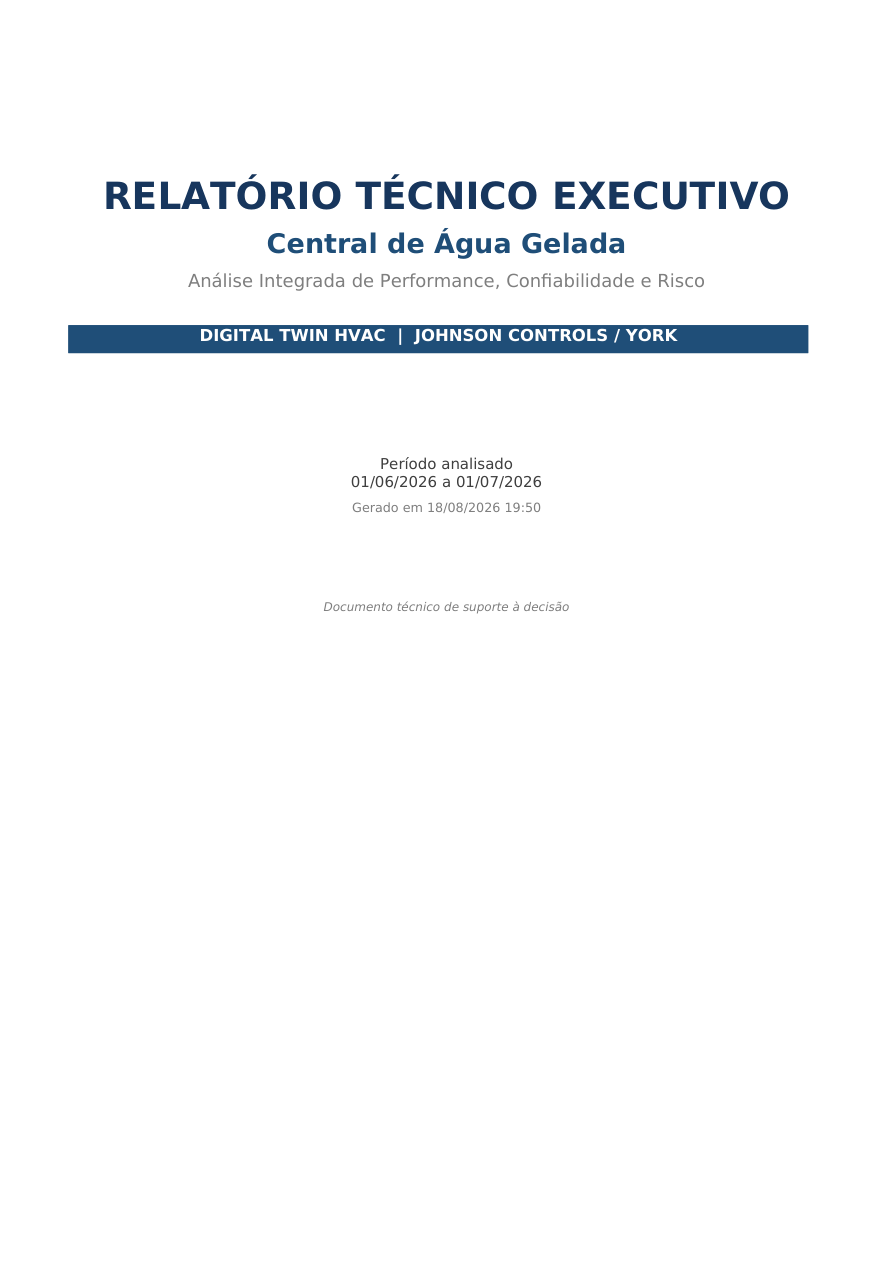


Página 2 — VERTICAL


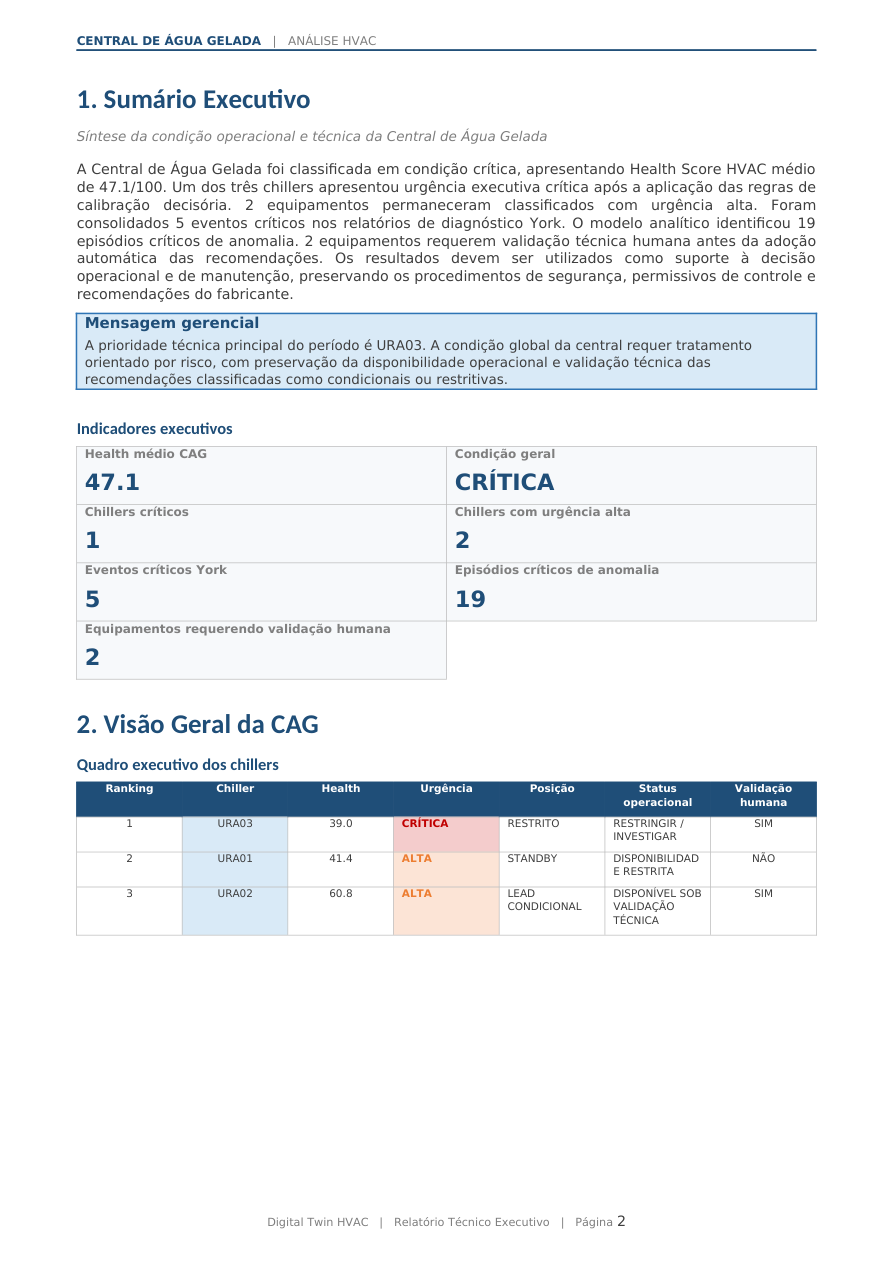


Página 3 — VERTICAL


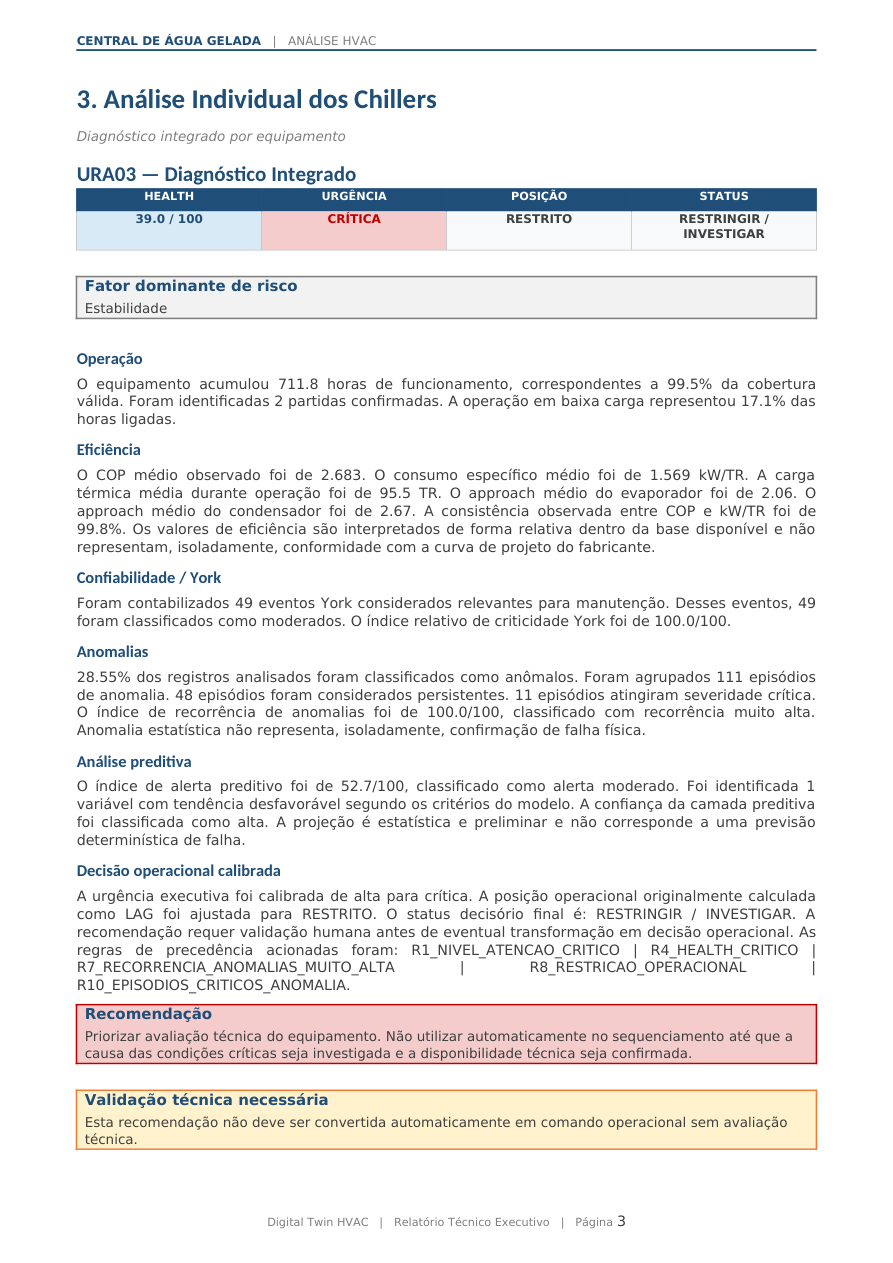


Página 4 — VERTICAL


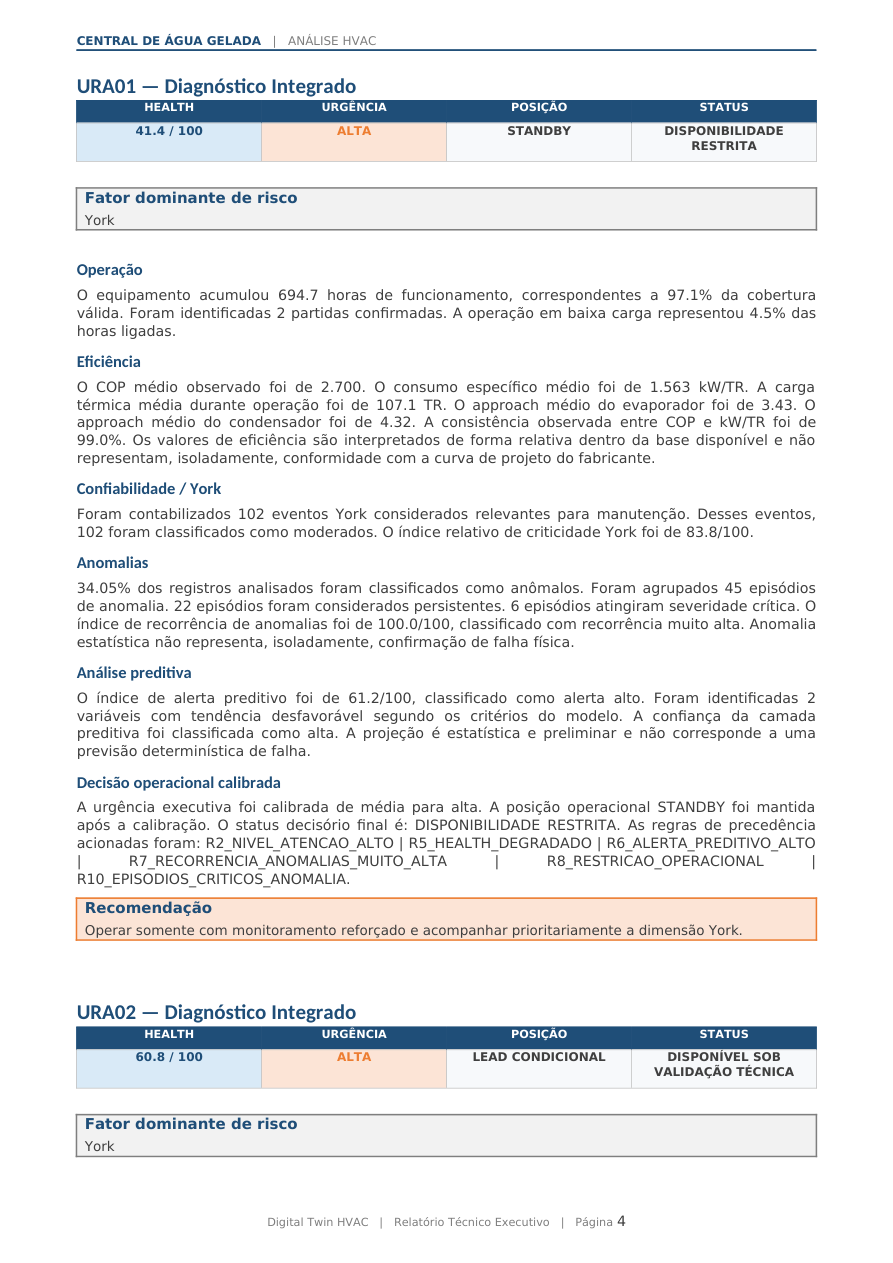


Página 5 — VERTICAL


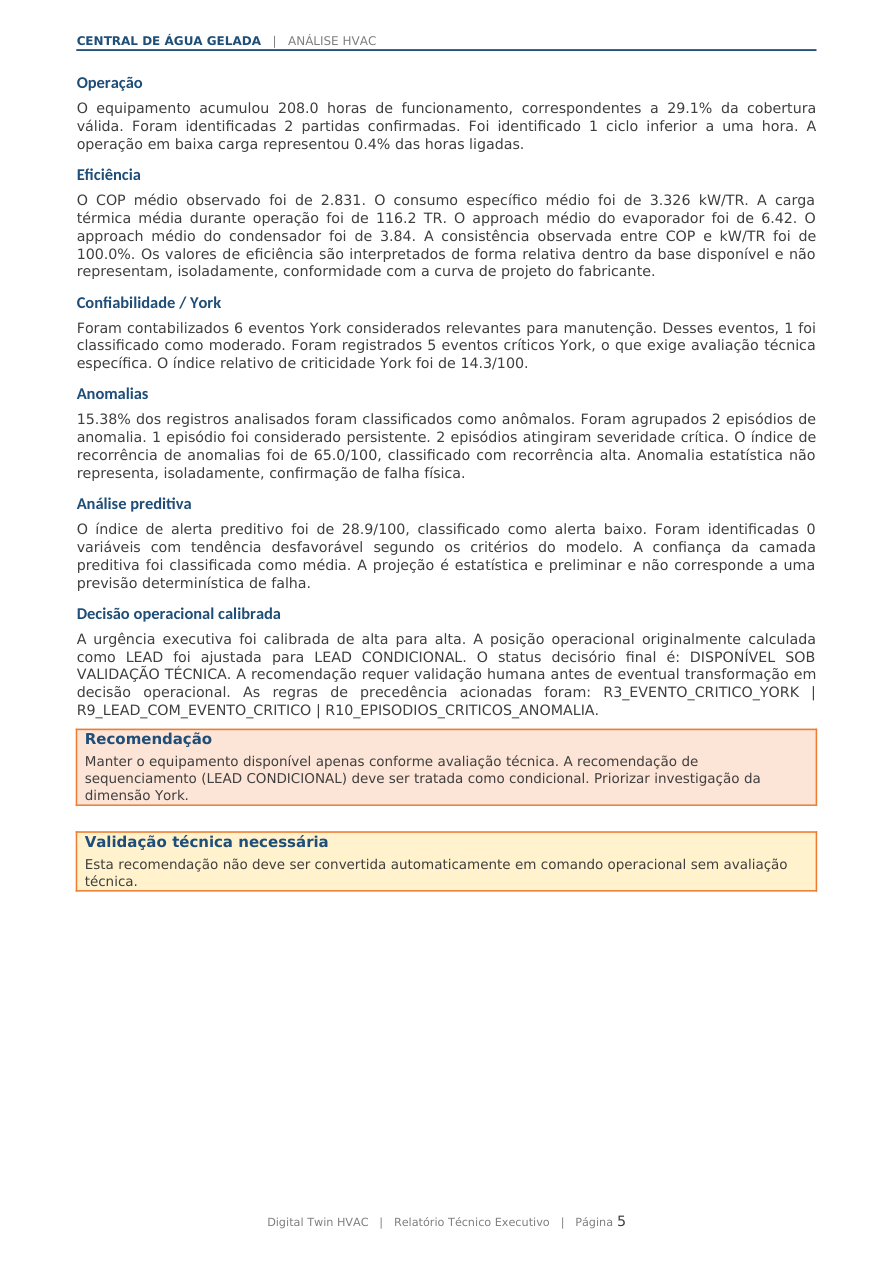


Página 6 — HORIZONTAL


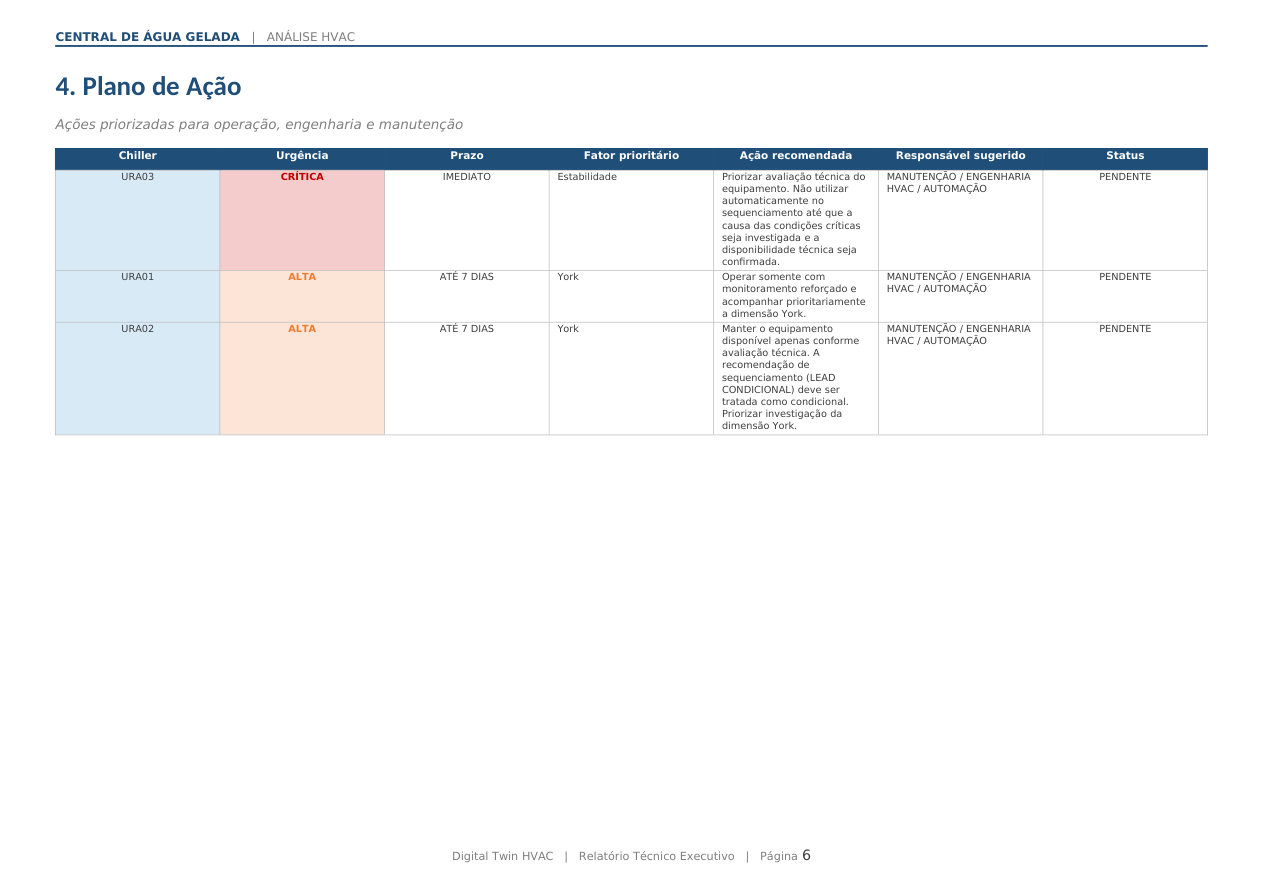


Página 7 — VERTICAL


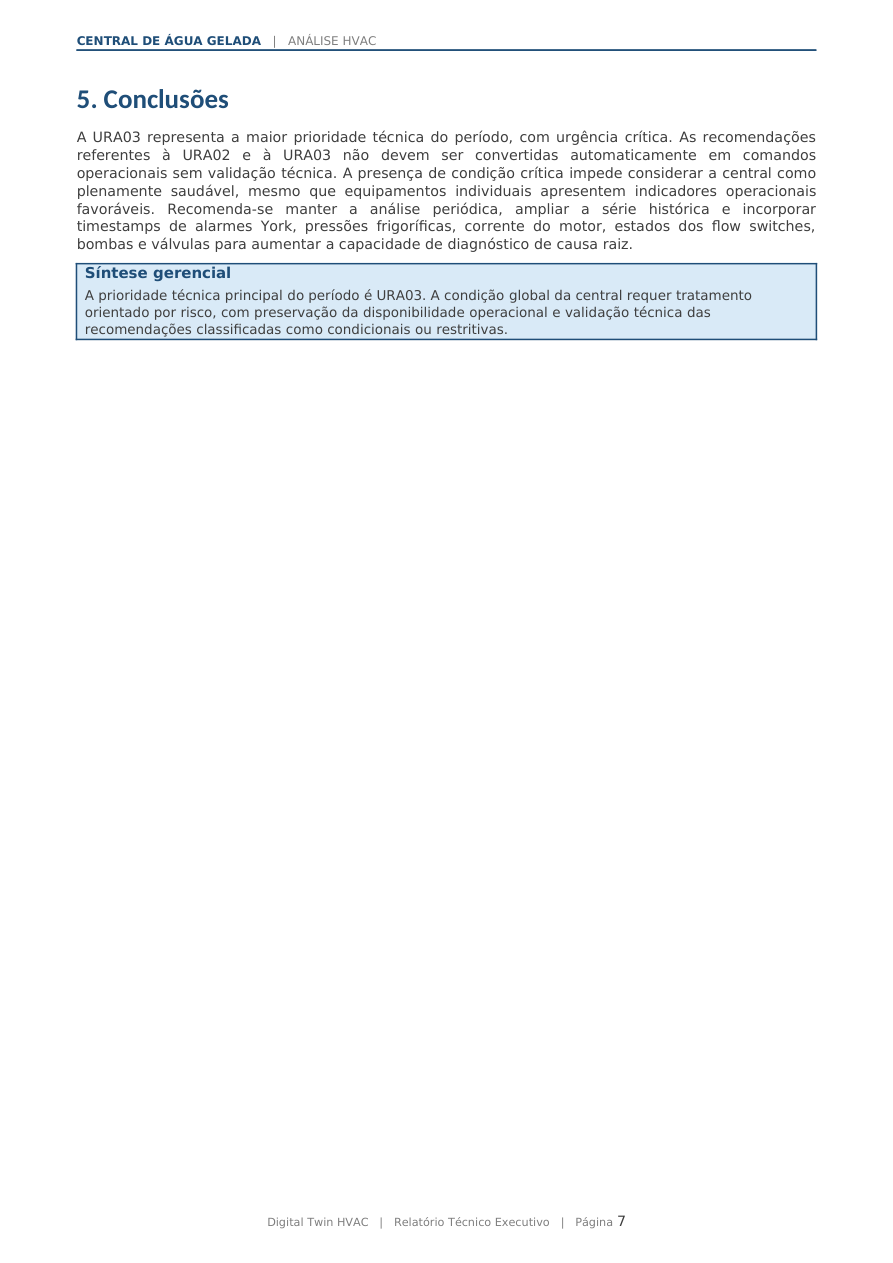


Página 8 — VERTICAL


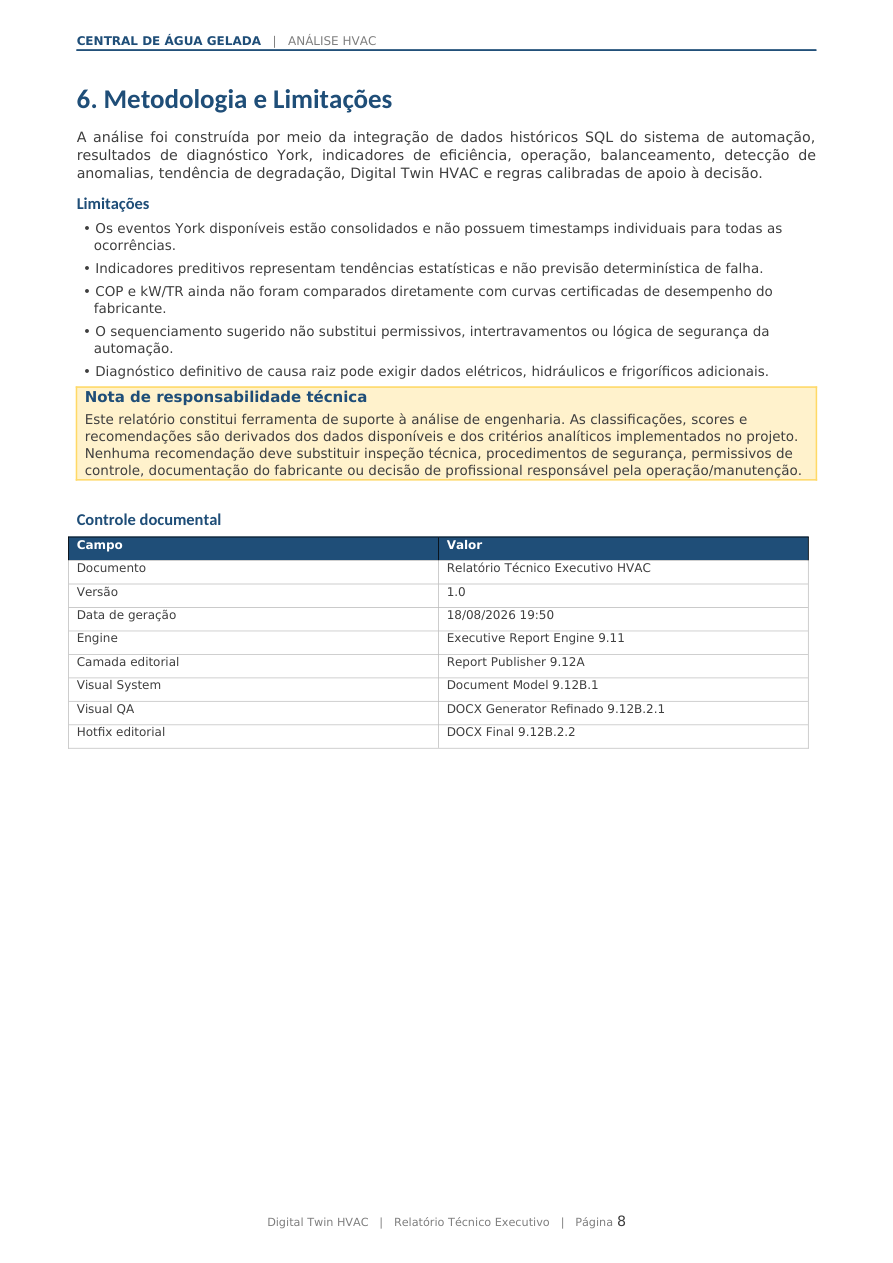


Arquivos auxiliares de QA:
/content/Resultados/MODULO_09_HVAC/REPORT_PUBLISHER/PDF/QA/09_12B3_PDF_PAGE_INVENTORY.csv
/content/Resultados/MODULO_09_HVAC/REPORT_PUBLISHER/PDF/QA/09_12B3_PDF_QA_CHECKS.csv

Objetos disponibilizados:
• hvac_pdf_final_path
• hvac_pdf_page_inventory
• hvac_pdf_physical_checks
• hvac_pdf_page_checks
• hvac_pdf_content_checks
• hvac_pdf_editorial_checks
• hvac_pdf_regression_checks
• hvac_pdf_render_checks
• hvac_pdf_all_checks
• hvac_pdf_preview_paths
• hvac_pdf_automatic_status
• hvac_pdf_final_status

CHECKPOINT 9.12B.3: AGUARDANDO VISUAL QA

Todos os testes automáticos obrigatórios foram executados.
Revise visualmente as páginas renderizadas acima.
Após a inspeção visual, o PDF poderá receber o checkpoint final de publicação.


In [136]:
# ==============================================================================
# BLOCO 9.12B.3
# PDF PUBLISHER & QUALITY ASSURANCE
# RELATÓRIO TÉCNICO EXECUTIVO HVAC
#
# OBJETIVOS:
# - Receber exclusivamente o DOCX final aprovado no Bloco 9.12B.2.2
# - Converter DOCX -> PDF no Google Colab
# - Preservar páginas verticais e horizontais
# - Validar integridade física do PDF
# - Validar quantidade e orientação das páginas
# - Extrair e validar conteúdo textual
# - Confirmar presença das seções críticas
# - Confirmar URA01 / URA02 / URA03
# - Repetir checks editoriais críticos
# - Executar checks de não regressão
# - Renderizar páginas em PNG para Visual QA
# - Gerar tabela de inventário das páginas
# - Disponibilizar objetos para os próximos blocos
#
# PRÉ-REQUISITO:
# CHECKPOINT 9.12B.2.2 = APROVADO
# ==============================================================================


# ==============================================================================
# 0. IMPORTAÇÕES
# ==============================================================================

import sys
import subprocess
import importlib.util
import re
import shutil
import os

import pandas as pd
import numpy as np

from pathlib import Path
from IPython.display import (
    display,
    Image
)


print("=" * 150)
print("BLOCO 9.12B.3 - PDF PUBLISHER & QUALITY ASSURANCE")
print("=" * 150)


# ==============================================================================
# 1. VALIDAÇÃO DO CHECKPOINT ANTERIOR
# ==============================================================================

objetos_obrigatorios = [

    "hvac_docx_final_path",
    "hvac_docx_final_checks",
    "hvac_docx_final_editorial_checks",
    "hvac_docx_final_regression_checks",
    "hvac_docx_final_section_orientations",
    "hvac_docx_final_status"
]


objetos_ausentes = [

    nome
    for nome in objetos_obrigatorios
    if nome not in globals()
]


if objetos_ausentes:

    raise NameError(

        "Execute primeiro o Bloco 9.12B.2.2. "
        f"Objetos ausentes: {objetos_ausentes}"
    )


if str(hvac_docx_final_status).upper() != "APROVADO":

    raise RuntimeError(

        "O Bloco 9.12B.2.2 não está aprovado. "
        "A publicação em PDF foi bloqueada."
    )


print("\nCheckpoint anterior:")
print("DOCX Final:", hvac_docx_final_status)


# ==============================================================================
# 2. CAMINHO DO DOCX FINAL
# ==============================================================================

DOCX_FINAL = Path(
    hvac_docx_final_path
)


if not DOCX_FINAL.exists():

    raise FileNotFoundError(

        "O DOCX final aprovado não foi encontrado:\n"
        f"{DOCX_FINAL}"
    )


print("\nDOCX fonte:")
print(DOCX_FINAL.resolve())


# ==============================================================================
# 3. INSTALAÇÃO / VALIDAÇÃO DAS DEPENDÊNCIAS
# ==============================================================================

# ------------------------------------------------------------------------------
# PyMuPDF
# ------------------------------------------------------------------------------

if importlib.util.find_spec("fitz") is None:

    print("\nInstalando PyMuPDF...")

    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "PyMuPDF",
            "-q"
        ]
    )


import fitz


# ------------------------------------------------------------------------------
# LibreOffice
#
# No Colab ele é utilizado como engine de conversão DOCX -> PDF.
# ------------------------------------------------------------------------------

libreoffice_path = shutil.which(
    "libreoffice"
)


if libreoffice_path is None:

    print("\nLibreOffice não encontrado.")
    print("Instalando LibreOffice para conversão DOCX -> PDF...")

    subprocess.check_call(
        [
            "apt-get",
            "update",
            "-qq"
        ]
    )

    subprocess.check_call(
        [
            "apt-get",
            "install",
            "-y",
            "-qq",
            "libreoffice"
        ]
    )

    libreoffice_path = shutil.which(
        "libreoffice"
    )


if libreoffice_path is None:

    raise RuntimeError(
        "Não foi possível localizar ou instalar o LibreOffice."
    )


print("\nEngine de conversão:")
print(libreoffice_path)


# ==============================================================================
# 4. DIRETÓRIOS DE PUBLICAÇÃO
# ==============================================================================

PASTA_RESULTADOS = Path(
    "Resultados"
)

PASTA_HVAC = (
    PASTA_RESULTADOS
    / "MODULO_09_HVAC"
)

PASTA_PUBLISHER = (
    PASTA_HVAC
    / "REPORT_PUBLISHER"
)

PASTA_PDF = (
    PASTA_PUBLISHER
    / "PDF"
)

PASTA_QA = (
    PASTA_PDF
    / "QA"
)

PASTA_PREVIEW = (
    PASTA_QA
    / "PREVIEW_PAGES"
)


for pasta in [

    PASTA_PDF,
    PASTA_QA,
    PASTA_PREVIEW

]:

    pasta.mkdir(
        parents=True,
        exist_ok=True
    )


# ==============================================================================
# 5. NOMES DOS ARQUIVOS
# ==============================================================================

NOME_PDF_FINAL = (
    "09_12B3_RELATORIO_TECNICO_EXECUTIVO_HVAC_FINAL.pdf"
)

PDF_FINAL = (
    PASTA_PDF
    / NOME_PDF_FINAL
)


ARQUIVO_QA_CSV = (
    PASTA_QA
    / "09_12B3_PDF_PAGE_INVENTORY.csv"
)


ARQUIVO_CHECKS_CSV = (
    PASTA_QA
    / "09_12B3_PDF_QA_CHECKS.csv"
)


# ==============================================================================
# 6. LIMPEZA DE ARQUIVOS DE PREVIEW ANTERIORES
# ==============================================================================

for arquivo in PASTA_PREVIEW.glob(
    "*.png"
):

    try:

        arquivo.unlink()

    except Exception:

        pass


# ==============================================================================
# 7. CONVERSÃO DOCX -> PDF
# ==============================================================================

print("\n" + "-" * 150)
print("CONVERSÃO DOCX -> PDF")
print("-" * 150)


# ------------------------------------------------------------------------------
# O LibreOffice cria inicialmente um PDF com o mesmo stem do DOCX.
# ------------------------------------------------------------------------------

pdf_convertido_original = (
    PASTA_PDF
    /
    f"{DOCX_FINAL.stem}.pdf"
)


# ------------------------------------------------------------------------------
# Remove versões anteriores
# ------------------------------------------------------------------------------

for arquivo in [

    pdf_convertido_original,
    PDF_FINAL

]:

    if arquivo.exists():

        try:

            arquivo.unlink()

        except Exception:

            pass


# ------------------------------------------------------------------------------
# Conversão
# ------------------------------------------------------------------------------

comando_conversao = [

    libreoffice_path,

    "--headless",

    "--convert-to",
    "pdf",

    "--outdir",
    str(
        PASTA_PDF.resolve()
    ),

    str(
        DOCX_FINAL.resolve()
    )
]


resultado_conversao = subprocess.run(

    comando_conversao,

    stdout=subprocess.PIPE,

    stderr=subprocess.PIPE,

    text=True
)


print("\nSaída da conversão:")

print(
    resultado_conversao.stdout.strip()
)


if resultado_conversao.stderr.strip():

    print("\nMensagens da engine:")

    print(
        resultado_conversao.stderr.strip()
    )


# ==============================================================================
# 8. LOCALIZAÇÃO DO PDF GERADO
# ==============================================================================

if not pdf_convertido_original.exists():

    candidatos_pdf = list(
        PASTA_PDF.glob(
            "*.pdf"
        )
    )

    candidatos_pdf = [

        p
        for p in candidatos_pdf
        if p.name != PDF_FINAL.name
    ]

    if len(candidatos_pdf) == 1:

        pdf_convertido_original = (
            candidatos_pdf[0]
        )

    else:

        raise FileNotFoundError(

            "A conversão foi executada, mas o PDF gerado "
            "não pôde ser localizado automaticamente."
        )


# ------------------------------------------------------------------------------
# Renomeia para nome oficial
# ------------------------------------------------------------------------------

if (
    pdf_convertido_original.resolve()
    !=
    PDF_FINAL.resolve()
):

    shutil.move(
        str(
            pdf_convertido_original
        ),
        str(
            PDF_FINAL
        )
    )


# ==============================================================================
# 9. VALIDAÇÃO FÍSICA INICIAL
# ==============================================================================

pdf_existe = (
    PDF_FINAL.exists()
)

pdf_tamanho_bytes = (
    PDF_FINAL.stat().st_size
    if pdf_existe
    else 0
)

pdf_tamanho_mb = (
    pdf_tamanho_bytes
    / 1024
    / 1024
)


if not pdf_existe:

    raise FileNotFoundError(
        "O PDF final não foi criado."
    )


if pdf_tamanho_bytes <= 0:

    raise RuntimeError(
        "O PDF foi criado, mas possui tamanho zero."
    )


print("\nPDF criado:")
print(PDF_FINAL.resolve())

print(
    f"Tamanho: {pdf_tamanho_mb:.3f} MB"
)


# ==============================================================================
# 10. ABERTURA DO PDF
# ==============================================================================

try:

    pdf_doc = fitz.open(
        PDF_FINAL
    )

except Exception as exc:

    raise RuntimeError(
        f"Falha ao abrir o PDF com PyMuPDF: {exc}"
    )


qtd_paginas = len(
    pdf_doc
)


if qtd_paginas == 0:

    raise RuntimeError(
        "O PDF não contém páginas."
    )


print(
    f"Páginas detectadas: {qtd_paginas}"
)


# ==============================================================================
# 11. INVENTÁRIO DAS PÁGINAS
# ==============================================================================

inventario_paginas = []


for numero_pagina in range(
    qtd_paginas
):

    page = pdf_doc[
        numero_pagina
    ]

    rect = page.rect

    largura_pt = float(
        rect.width
    )

    altura_pt = float(
        rect.height
    )

    largura_cm = (
        largura_pt
        * 2.54
        / 72
    )

    altura_cm = (
        altura_pt
        * 2.54
        / 72
    )

    if largura_pt > altura_pt:

        orientacao = (
            "HORIZONTAL"
        )

    else:

        orientacao = (
            "VERTICAL"
        )

    texto_pagina = (
        page.get_text(
            "text"
        )
        or ""
    )

    qtd_caracteres = len(
        texto_pagina.strip()
    )

    qtd_palavras = len(
        re.findall(
            r"\b\w+\b",
            texto_pagina,
            flags=re.UNICODE
        )
    )

    inventario_paginas.append({

        "PAGINA":
            numero_pagina + 1,

        "LARGURA_CM":
            round(
                largura_cm,
                2
            ),

        "ALTURA_CM":
            round(
                altura_cm,
                2
            ),

        "ORIENTACAO":
            orientacao,

        "CARACTERES":
            qtd_caracteres,

        "PALAVRAS":
            qtd_palavras
    })


inventario_paginas_df = pd.DataFrame(
    inventario_paginas
)


print("\nInventário das páginas:")

display(
    inventario_paginas_df
)


# ==============================================================================
# 12. VALIDAÇÃO DE ORIENTAÇÃO
# ==============================================================================

qtd_vertical = int(

    inventario_paginas_df[
        "ORIENTACAO"
    ]
    .eq(
        "VERTICAL"
    )
    .sum()
)


qtd_horizontal = int(

    inventario_paginas_df[
        "ORIENTACAO"
    ]
    .eq(
        "HORIZONTAL"
    )
    .sum()
)


paginas_horizontais = (

    inventario_paginas_df.loc[
        inventario_paginas_df[
            "ORIENTACAO"
        ]
        .eq(
            "HORIZONTAL"
        ),
        "PAGINA"
    ]
    .tolist()
)


print("\nOrientações:")

print(
    f"Páginas verticais   : {qtd_vertical}"
)

print(
    f"Páginas horizontais : {qtd_horizontal}"
)

print(
    f"Páginas horizontais : {paginas_horizontais}"
)


# ==============================================================================
# 13. EXTRAÇÃO TEXTUAL COMPLETA
# ==============================================================================

textos_paginas = []


for numero_pagina in range(
    qtd_paginas
):

    page = pdf_doc[
        numero_pagina
    ]

    texto = (
        page.get_text(
            "text"
        )
        or ""
    )

    textos_paginas.append(
        texto
    )


texto_pdf = "\n".join(
    textos_paginas
)


texto_pdf_normalizado = re.sub(

    r"\s+",

    " ",

    texto_pdf

).strip()


qtd_caracteres_pdf = len(
    texto_pdf_normalizado
)


qtd_palavras_pdf = len(

    re.findall(

        r"\b\w+\b",

        texto_pdf_normalizado,

        flags=re.UNICODE
    )
)


print("\nConteúdo textual:")

print(
    f"Caracteres extraídos : {qtd_caracteres_pdf}"
)

print(
    f"Palavras aproximadas : {qtd_palavras_pdf}"
)


# ==============================================================================
# 14. FUNÇÃO DE BUSCA TEXTUAL FLEXÍVEL
# ==============================================================================

def contem_texto(
    texto,
    trecho
):

    texto_norm = re.sub(
        r"\s+",
        " ",
        str(
            texto
        )
    ).strip().lower()

    trecho_norm = re.sub(
        r"\s+",
        " ",
        str(
            trecho
        )
    ).strip().lower()

    return (
        trecho_norm
        in texto_norm
    )


# ==============================================================================
# 15. CHECKS DE CONTEÚDO
# ==============================================================================

checks_conteudo_lista = [

    (
        "Título principal",
        "RELATÓRIO TÉCNICO EXECUTIVO"
    ),

    (
        "Central de Água Gelada",
        "CENTRAL DE ÁGUA GELADA"
    ),

    (
        "Sumário Executivo",
        "Sumário Executivo"
    ),

    (
        "Visão Geral da CAG",
        "Visão Geral da CAG"
    ),

    (
        "Análise Individual dos Chillers",
        "Análise Individual dos Chillers"
    ),

    (
        "URA01",
        "URA01"
    ),

    (
        "URA02",
        "URA02"
    ),

    (
        "URA03",
        "URA03"
    ),

    (
        "Plano de Ação",
        "Plano de Ação"
    ),

    (
        "Conclusões",
        "Conclusões"
    ),

    (
        "Metodologia e Limitações",
        "Metodologia e Limitações"
    ),

    (
        "Nota de responsabilidade técnica",
        "Nota de responsabilidade técnica"
    ),

    (
        "Controle documental",
        "Controle documental"
    )
]


checks_conteudo = []


for descricao, trecho in checks_conteudo_lista:

    encontrado = contem_texto(
        texto_pdf_normalizado,
        trecho
    )

    checks_conteudo.append({

        "CHECK":
            descricao,

        "TRECHO_ESPERADO":
            trecho,

        "RESULTADO":
            (
                "OK"
                if encontrado
                else
                "FALHA"
            )
    })


checks_conteudo = pd.DataFrame(
    checks_conteudo
)


# ==============================================================================
# 16. CHECKS EDITORIAIS
# ==============================================================================

problemas_editoriais_pdf = {

    r"(?<!\d)1 ciclos\b":
        "Singular de ciclo",

    r"(?<!\d)1 episódios\b":
        "Singular de episódio",

    r"(?<!\d)1 variáveis\b":
        "Singular de variável",

    r"(?<!\d)1 foram classificados\b":
        "Concordância masculina",

    r"(?<!\d)1 foram classificadas\b":
        "Concordância feminina",

    r"\bO URA0[123] representa\b":
        "Artigo feminino das URAs"
}


checks_editoriais_pdf = []


for padrao, descricao in problemas_editoriais_pdf.items():

    encontrado = bool(

        re.search(

            padrao,

            texto_pdf_normalizado,

            flags=re.IGNORECASE
        )
    )

    checks_editoriais_pdf.append({

        "CHECK":
            descricao,

        "PADRAO_VERIFICADO":
            padrao,

        "RESULTADO":
            (
                "FALHA"
                if encontrado
                else
                "OK"
            )
    })


checks_editoriais_pdf = pd.DataFrame(
    checks_editoriais_pdf
)


# ==============================================================================
# 17. CHECKS DE NÃO REGRESSÃO
# ==============================================================================

testes_nao_regressao_pdf = {

    "111 episódios de anomalia":
        "URA03 mantém 111 episódios no plural",

    "11 episódios atingiram severidade crítica":
        "URA03 mantém 11 episódios no plural",

    "1 episódio foi considerado persistente":
        "URA02 mantém episódio singular",

    "Foi identificado 1 ciclo inferior a uma hora":
        "URA02 mantém ciclo singular",

    "Foi identificada 1 variável com tendência":
        "URA03 mantém variável singular",

    "A URA03 representa":
        "Conclusão mantém artigo feminino"
}


checks_nao_regressao_pdf = []


for trecho, descricao in testes_nao_regressao_pdf.items():

    encontrado = contem_texto(
        texto_pdf_normalizado,
        trecho
    )

    checks_nao_regressao_pdf.append({

        "CHECK":
            descricao,

        "TRECHO_ESPERADO":
            trecho,

        "RESULTADO":
            (
                "OK"
                if encontrado
                else
                "FALHA"
            )
    })


checks_nao_regressao_pdf = pd.DataFrame(
    checks_nao_regressao_pdf
)


# ==============================================================================
# 18. CHECKS DE PÁGINA
# ==============================================================================

checks_paginas_lista = []


# ------------------------------------------------------------------------------
# PDF possui páginas
# ------------------------------------------------------------------------------

checks_paginas_lista.append({

    "CHECK":
        "PDF possui páginas",

    "RESULTADO":
        (
            "OK"
            if qtd_paginas > 0
            else
            "FALHA"
        )
})


# ------------------------------------------------------------------------------
# Existe página horizontal
# ------------------------------------------------------------------------------

checks_paginas_lista.append({

    "CHECK":
        "PDF possui página horizontal",

    "RESULTADO":
        (
            "OK"
            if qtd_horizontal >= 1
            else
            "FALHA"
        )
})


# ------------------------------------------------------------------------------
# Existe página vertical
# ------------------------------------------------------------------------------

checks_paginas_lista.append({

    "CHECK":
        "PDF possui páginas verticais",

    "RESULTADO":
        (
            "OK"
            if qtd_vertical >= 1
            else
            "FALHA"
        )
})


# ------------------------------------------------------------------------------
# Apenas uma página horizontal é esperada neste relatório
# ------------------------------------------------------------------------------

checks_paginas_lista.append({

    "CHECK":
        "Plano de Ação ocupa única página horizontal",

    "RESULTADO":
        (
            "OK"
            if qtd_horizontal == 1
            else
            "REVISAR"
        )
})


# ------------------------------------------------------------------------------
# Página horizontal não deve ser primeira ou última
# ------------------------------------------------------------------------------

horizontal_em_posicao_valida = (

    len(
        paginas_horizontais
    )
    >= 1

    and

    all(
        1 < pagina < qtd_paginas
        for pagina
        in paginas_horizontais
    )
)


checks_paginas_lista.append({

    "CHECK":
        "Página horizontal em posição intermediária",

    "RESULTADO":
        (
            "OK"
            if horizontal_em_posicao_valida
            else
            "REVISAR"
        )
})


# ------------------------------------------------------------------------------
# Páginas com texto
# ------------------------------------------------------------------------------

paginas_sem_texto = (

    inventario_paginas_df.loc[

        inventario_paginas_df[
            "CARACTERES"
        ]
        .eq(
            0
        ),

        "PAGINA"
    ]
    .tolist()
)


checks_paginas_lista.append({

    "CHECK":
        "Nenhuma página completamente vazia",

    "RESULTADO":
        (
            "OK"
            if len(
                paginas_sem_texto
            ) == 0
            else
            "REVISAR"
        )
})


checks_paginas = pd.DataFrame(
    checks_paginas_lista
)


# ==============================================================================
# 19. CHECKS FÍSICOS
# ==============================================================================

checks_fisicos = pd.DataFrame({

    "CHECK": [

        "Arquivo PDF criado",

        "Arquivo PDF maior que zero",

        "PDF pode ser aberto pelo PyMuPDF",

        "PDF contém texto extraível",

        "PDF contém mais de uma página"
    ],

    "RESULTADO": [

        "OK"
        if pdf_existe
        else
        "FALHA",

        "OK"
        if pdf_tamanho_bytes > 0
        else
        "FALHA",

        "OK"
        if qtd_paginas > 0
        else
        "FALHA",

        "OK"
        if qtd_caracteres_pdf > 100
        else
        "FALHA",

        "OK"
        if qtd_paginas > 1
        else
        "FALHA"
    ]
})


# ==============================================================================
# 20. RENDERIZAÇÃO DAS PÁGINAS PARA VISUAL QA
# ==============================================================================

print("\n" + "-" * 150)
print("RENDERIZAÇÃO DAS PÁGINAS PARA VISUAL QA")
print("-" * 150)


arquivos_preview = []


# ------------------------------------------------------------------------------
# Zoom 1.5 é suficiente para inspeção sem gerar imagens excessivamente pesadas.
# ------------------------------------------------------------------------------

matriz_render = fitz.Matrix(
    1.5,
    1.5
)


for numero_pagina in range(
    qtd_paginas
):

    page = pdf_doc[
        numero_pagina
    ]

    pix = page.get_pixmap(

        matrix=matriz_render,

        alpha=False
    )

    caminho_png = (

        PASTA_PREVIEW
        /
        f"pagina_{numero_pagina + 1:02d}.png"
    )

    pix.save(
        str(
            caminho_png
        )
    )

    arquivos_preview.append(
        caminho_png
    )


print(
    f"{len(arquivos_preview)} páginas renderizadas."
)


# ==============================================================================
# 21. QA DE RENDERIZAÇÃO
# ==============================================================================

checks_renderizacao = []


for numero, arquivo in enumerate(
    arquivos_preview,
    start=1
):

    existe = (
        arquivo.exists()
    )

    tamanho = (
        arquivo.stat().st_size
        if existe
        else 0
    )

    checks_renderizacao.append({

        "PAGINA":
            numero,

        "ARQUIVO":
            arquivo.name,

        "RESULTADO":
            (
                "OK"
                if existe
                and tamanho > 0
                else
                "FALHA"
            )
    })


checks_renderizacao = pd.DataFrame(
    checks_renderizacao
)


# ==============================================================================
# 22. EXPORTAÇÃO DO INVENTÁRIO
# ==============================================================================

inventario_paginas_df.to_csv(

    ARQUIVO_QA_CSV,

    index=False,

    encoding="utf-8-sig"
)


# ==============================================================================
# 23. CONSOLIDAÇÃO DOS CHECKS
# ==============================================================================

def preparar_check(
    dataframe,
    categoria
):

    temp = (
        dataframe.copy()
    )

    temp.insert(
        0,
        "CATEGORIA",
        categoria
    )

    colunas = [

        "CATEGORIA",
        "CHECK",
        "RESULTADO"
    ]

    for coluna in colunas:

        if coluna not in temp.columns:

            temp[coluna] = ""

    return temp[
        colunas
    ]


checks_consolidados = pd.concat(

    [

        preparar_check(
            checks_fisicos,
            "FÍSICO"
        ),

        preparar_check(
            checks_paginas,
            "PÁGINAS"
        ),

        preparar_check(
            checks_conteudo,
            "CONTEÚDO"
        ),

        preparar_check(
            checks_editoriais_pdf,
            "EDITORIAL"
        ),

        preparar_check(
            checks_nao_regressao_pdf,
            "NÃO REGRESSÃO"
        )

    ],

    ignore_index=True
)


# ------------------------------------------------------------------------------
# Adiciona renderização
# ------------------------------------------------------------------------------

render_resumo = pd.DataFrame({

    "CATEGORIA": [
        "RENDERIZAÇÃO"
    ],

    "CHECK": [
        "Todas as páginas renderizadas para Visual QA"
    ],

    "RESULTADO": [

        "OK"
        if (
            checks_renderizacao[
                "RESULTADO"
            ]
            .eq(
                "OK"
            )
            .all()
        )
        else
        "FALHA"
    ]
})


checks_consolidados = pd.concat(

    [
        checks_consolidados,
        render_resumo
    ],

    ignore_index=True
)


# ==============================================================================
# 24. EXPORTAÇÃO DOS CHECKS
# ==============================================================================

checks_consolidados.to_csv(

    ARQUIVO_CHECKS_CSV,

    index=False,

    encoding="utf-8-sig"
)


# ==============================================================================
# 25. CONTAGEM DOS RESULTADOS
# ==============================================================================

qtd_falhas = int(

    checks_consolidados[
        "RESULTADO"
    ]
    .eq(
        "FALHA"
    )
    .sum()
)


qtd_revisar = int(

    checks_consolidados[
        "RESULTADO"
    ]
    .eq(
        "REVISAR"
    )
    .sum()
)


qtd_ok = int(

    checks_consolidados[
        "RESULTADO"
    ]
    .eq(
        "OK"
    )
    .sum()
)


# ==============================================================================
# 26. STATUS AUTOMÁTICO
# ==============================================================================

if qtd_falhas > 0:

    STATUS_PDF_AUTOMATICO = (
        "REPROVADO"
    )

elif qtd_revisar > 0:

    STATUS_PDF_AUTOMATICO = (
        "REVISÃO VISUAL NECESSÁRIA"
    )

else:

    STATUS_PDF_AUTOMATICO = (
        "APROVADO AUTOMATICAMENTE"
    )


# ==============================================================================
# 27. CHECKPOINT DE VISUAL QA
#
# Mesmo que todos os checks automáticos sejam aprovados, o relatório
# ainda deve passar por inspeção visual das páginas renderizadas.
# ==============================================================================

if qtd_falhas == 0:

    STATUS_PDF_FINAL = (
        "AGUARDANDO VISUAL QA"
    )

else:

    STATUS_PDF_FINAL = (
        "REPROVADO"
    )


# ==============================================================================
# 28. OBJETOS DISPONIBILIZADOS
# ==============================================================================

hvac_pdf_final_path = (
    PDF_FINAL
)

hvac_pdf_page_inventory = (
    inventario_paginas_df.copy()
)

hvac_pdf_physical_checks = (
    checks_fisicos.copy()
)

hvac_pdf_page_checks = (
    checks_paginas.copy()
)

hvac_pdf_content_checks = (
    checks_conteudo.copy()
)

hvac_pdf_editorial_checks = (
    checks_editoriais_pdf.copy()
)

hvac_pdf_regression_checks = (
    checks_nao_regressao_pdf.copy()
)

hvac_pdf_render_checks = (
    checks_renderizacao.copy()
)

hvac_pdf_all_checks = (
    checks_consolidados.copy()
)

hvac_pdf_preview_paths = (
    arquivos_preview.copy()
)

hvac_pdf_automatic_status = (
    STATUS_PDF_AUTOMATICO
)

hvac_pdf_final_status = (
    STATUS_PDF_FINAL
)


# ==============================================================================
# 29. RESULTADOS — INVENTÁRIO
# ==============================================================================

print("\n" + "=" * 150)
print("RESULTADOS DO PDF PUBLISHER")
print("=" * 150)


print("\nArquivo PDF:")

print(
    PDF_FINAL.resolve()
)


print("\nInformações gerais:")

print(
    f"Páginas             : {qtd_paginas}"
)

print(
    f"Páginas verticais   : {qtd_vertical}"
)

print(
    f"Páginas horizontais : {qtd_horizontal}"
)

print(
    f"Tamanho             : {pdf_tamanho_mb:.3f} MB"
)

print(
    f"Caracteres extraídos: {qtd_caracteres_pdf}"
)

print(
    f"Palavras aprox.     : {qtd_palavras_pdf}"
)


# ==============================================================================
# 30. RESULTADOS — CHECKS
# ==============================================================================

print("\nChecks físicos:")

display(
    checks_fisicos
)


print("\nChecks de páginas:")

display(
    checks_paginas
)


print("\nChecks de conteúdo:")

display(
    checks_conteudo
)


print("\nChecks editoriais:")

display(
    checks_editoriais_pdf
)


print("\nChecks de não regressão:")

display(
    checks_nao_regressao_pdf
)


print("\nChecks de renderização:")

display(
    checks_renderizacao
)


print("\nChecks consolidados:")

display(
    checks_consolidados
)


# ==============================================================================
# 31. RESULTADOS — CONTADORES
# ==============================================================================

print("\nResumo do QA:")

print(
    f"Checks OK      : {qtd_ok}"
)

print(
    f"Checks FALHA   : {qtd_falhas}"
)

print(
    f"Checks REVISAR : {qtd_revisar}"
)


print(
    f"\nStatus automático : "
    f"{STATUS_PDF_AUTOMATICO}"
)

print(
    f"Status final      : "
    f"{STATUS_PDF_FINAL}"
)


# ==============================================================================
# 32. PREVIEW VISUAL NO COLAB
# ==============================================================================

print("\n" + "=" * 150)
print("VISUAL QA - PREVIEW DAS PÁGINAS")
print("=" * 150)


for numero, arquivo in enumerate(
    arquivos_preview,
    start=1
):

    orientacao = (

        inventario_paginas_df.loc[

            inventario_paginas_df[
                "PAGINA"
            ]
            .eq(
                numero
            ),

            "ORIENTACAO"
        ]
        .iloc[0]
    )

    print(
        f"\nPágina {numero} "
        f"— {orientacao}"
    )

    display(
        Image(
            filename=str(
                arquivo
            ),
            width=900
        )
    )


# ==============================================================================
# 33. ARQUIVOS DE QA
# ==============================================================================

print("\nArquivos auxiliares de QA:")

print(
    ARQUIVO_QA_CSV.resolve()
)

print(
    ARQUIVO_CHECKS_CSV.resolve()
)


# ==============================================================================
# 34. OBJETOS PARA PRÓXIMO BLOCO
# ==============================================================================

print("\nObjetos disponibilizados:")

print("• hvac_pdf_final_path")
print("• hvac_pdf_page_inventory")
print("• hvac_pdf_physical_checks")
print("• hvac_pdf_page_checks")
print("• hvac_pdf_content_checks")
print("• hvac_pdf_editorial_checks")
print("• hvac_pdf_regression_checks")
print("• hvac_pdf_render_checks")
print("• hvac_pdf_all_checks")
print("• hvac_pdf_preview_paths")
print("• hvac_pdf_automatic_status")
print("• hvac_pdf_final_status")


# ==============================================================================
# 35. CHECKPOINT
# ==============================================================================

print("\n" + "=" * 150)

print(
    f"CHECKPOINT 9.12B.3: "
    f"{STATUS_PDF_FINAL}"
)

print("=" * 150)


# ==============================================================================
# 36. INSTRUÇÃO FINAL
# ==============================================================================

if STATUS_PDF_FINAL == "AGUARDANDO VISUAL QA":

    print(
        "\nTodos os testes automáticos obrigatórios foram executados."
    )

    print(
        "Revise visualmente as páginas renderizadas acima."
    )

    print(
        "Após a inspeção visual, o PDF poderá receber "
        "o checkpoint final de publicação."
    )

else:

    print(
        "\nForam encontradas falhas automáticas."
    )

    print(
        "Não liberar o PDF antes da correção."
    )

In [137]:
# ==============================================================================
# BLOCO 9.13A
# PRESENTATION DATA LAYER
# CAMADA DE DADOS PARA APRESENTAÇÃO EXECUTIVA HVAC
# ==============================================================================

import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display

print("=" * 145)
print("BLOCO 9.13A - PRESENTATION DATA LAYER")
print("=" * 145)

# ==============================================================================
# 1. DIRETÓRIOS
# ==============================================================================

PASTA_RESULTADOS = Path("Resultados")

PASTA_HVAC = (
    PASTA_RESULTADOS
    / "MODULO_09_HVAC"
)

PASTA_PRESENTATION = (
    PASTA_HVAC
    / "EXECUTIVE_PRESENTATION"
)

PASTA_PRESENTATION.mkdir(
    parents=True,
    exist_ok=True
)

ARQUIVO_EXCEL_9_13A = (
    PASTA_PRESENTATION
    / "09_13A_PRESENTATION_DATA_LAYER.xlsx"
)

DATA_GERACAO_PRESENTATION = pd.Timestamp.now()

VERSAO_PRESENTATION_LAYER = "1.0"


# ==============================================================================
# 2. VALIDAÇÃO DAS FONTES
# ==============================================================================

objetos_obrigatorios = [

    "hvac_report_base",
    "hvac_report_equipment",
    "hvac_report_priorities",
    "hvac_report_action_plan",

    "hvac_decision_calibrated",
    "hvac_decision_summary",

    "hvac_cockpit_kpis",

    "hvac_publisher_executive_summary",
    "hvac_publisher_management_message"
]

objetos_ausentes = [

    nome
    for nome in objetos_obrigatorios
    if nome not in globals()
]

if objetos_ausentes:

    raise NameError(
        "Execute os blocos anteriores do Módulo 9 antes do 9.13A. "
        f"Objetos ausentes: {objetos_ausentes}"
    )


# ==============================================================================
# 3. CÓPIAS DAS BASES
# ==============================================================================

report_base = (
    hvac_report_base.copy()
)

report_equipment = (
    hvac_report_equipment.copy()
)

report_priorities = (
    hvac_report_priorities.copy()
)

report_action_plan = (
    hvac_report_action_plan.copy()
)

decision = (
    hvac_decision_calibrated.copy()
)

decision_summary = (
    hvac_decision_summary.copy()
)

cockpit_kpis = (
    hvac_cockpit_kpis.copy()
)

RESUMO_EXECUTIVO = (
    hvac_publisher_executive_summary
)

MENSAGEM_GERENCIAL = (
    hvac_publisher_management_message
)


# ==============================================================================
# 4. FUNÇÕES AUXILIARES
# ==============================================================================

def safe_text(
    value,
    default="N/D"
):

    if value is None:
        return default

    try:

        if pd.isna(value):
            return default

    except Exception:
        pass

    value = str(value).strip()

    return (
        value
        if value
        else default
    )


def safe_number(
    value,
    default=np.nan
):

    try:

        if pd.isna(value):
            return default

        return float(value)

    except Exception:

        return default


def format_br(
    value,
    decimals=1,
    suffix=""
):
    """
    Formatação brasileira apenas para exibição.
    Não altera a coluna numérica original.
    """

    try:

        if pd.isna(value):
            return "N/D"

        texto = (
            f"{float(value):,.{decimals}f}"
        )

        texto = (
            texto
            .replace(",", "X")
            .replace(".", ",")
            .replace("X", ".")
        )

        return (
            texto
            +
            suffix
        )

    except Exception:

        return safe_text(
            value
        )


def normalize_status(
    value
):

    texto = safe_text(
        value,
        ""
    ).upper()

    if "CRÍT" in texto:
        return "CRÍTICA"

    if "ALTA" in texto:
        return "ALTA"

    if "MÉD" in texto:
        return "MÉDIA"

    if "BAIX" in texto:
        return "BAIXA"

    return safe_text(
        value
    )


def priority_numeric(
    value
):

    texto = normalize_status(
        value
    )

    mapa = {

        "CRÍTICA":
            4,

        "ALTA":
            3,

        "MÉDIA":
            2,

        "BAIXA":
            1
    }

    return mapa.get(
        texto,
        0
    )


# ==============================================================================
# 5. METADADOS DA APRESENTAÇÃO
# ==============================================================================

periodo_inicio = (
    DATA_INICIO_RELATORIO
    if "DATA_INICIO_RELATORIO" in globals()
    else pd.NaT
)

periodo_fim = (
    DATA_FIM_RELATORIO
    if "DATA_FIM_RELATORIO" in globals()
    else pd.NaT
)

presentation_metadata = pd.DataFrame({

    "CAMPO": [

        "Título",

        "Subtítulo",

        "Descrição",

        "Sistema",

        "Fabricante / Tecnologia",

        "Período inicial",

        "Período final",

        "Data geração",

        "Quantidade de chillers",

        "Versão Presentation Layer"
    ],

    "VALOR": [

        "Central de Água Gelada",

        "Performance • Confiabilidade • Risco",

        (
            "Apresentação Executiva da Análise Integrada "
            "dos Chillers"
        ),

        "Digital Twin HVAC",

        "Johnson Controls / York",

        periodo_inicio,

        periodo_fim,

        DATA_GERACAO_PRESENTATION,

        len(
            report_base
        ),

        VERSAO_PRESENTATION_LAYER
    ]
})


# ==============================================================================
# 6. KPIs PRINCIPAIS
# ==============================================================================

health_medio = (
    report_base[
        "HEALTH_SCORE_HVAC"
    ]
    .mean()
    if "HEALTH_SCORE_HVAC"
    in report_base.columns
    else np.nan
)

qtd_criticos = (
    report_base[
        "CLASSIFICACAO_URGENCIA_CALIBRADA"
    ]
    .astype(str)
    .str.upper()
    .eq(
        "CRÍTICA"
    )
    .sum()
)

qtd_altos = (
    report_base[
        "CLASSIFICACAO_URGENCIA_CALIBRADA"
    ]
    .astype(str)
    .str.upper()
    .eq(
        "ALTA"
    )
    .sum()
)

eventos_york_criticos = (
    report_base[
        "EVENTOS_CRITICOS_YORK"
    ]
    .fillna(0)
    .sum()
    if "EVENTOS_CRITICOS_YORK"
    in report_base.columns
    else 0
)

episodios_criticos = (
    report_base[
        "EPISODIOS_CRITICOS"
    ]
    .fillna(0)
    .sum()
    if "EPISODIOS_CRITICOS"
    in report_base.columns
    else 0
)

validacoes_humanas = (
    report_base[
        "REQUER_VALIDACAO_HUMANA"
    ]
    .astype(str)
    .str.upper()
    .eq(
        "SIM"
    )
    .sum()
)

condicao_geral = (
    CONDICAO_GERAL_CAG
    if "CONDICAO_GERAL_CAG" in globals()
    else (
        "CRÍTICA"
        if qtd_criticos > 0
        else "ATENÇÃO"
    )
)

presentation_kpis = pd.DataFrame({

    "KPI_ID": [
        "HEALTH_CAG",
        "CONDICAO_CAG",
        "CHILLERS_CRITICOS",
        "URGENCIA_ALTA",
        "EVENTOS_YORK_CRITICOS",
        "EPISODIOS_CRITICOS",
        "VALIDACAO_HUMANA"
    ],

    "KPI": [
        "Health médio CAG",
        "Condição geral",
        "Chillers críticos",
        "Chillers urgência alta",
        "Eventos críticos York",
        "Episódios críticos",
        "Validação humana"
    ],

    "VALOR_NUMERICO": [
        health_medio,
        np.nan,
        qtd_criticos,
        qtd_altos,
        eventos_york_criticos,
        episodios_criticos,
        validacoes_humanas
    ],

    "VALOR_TEXTO": [
        format_br(
            health_medio,
            1
        ),
        safe_text(
            condicao_geral
        ),
        str(
            int(
                qtd_criticos
            )
        ),
        str(
            int(
                qtd_altos
            )
        ),
        str(
            int(
                eventos_york_criticos
            )
        ),
        str(
            int(
                episodios_criticos
            )
        ),
        str(
            int(
                validacoes_humanas
            )
        )
    ],

    "UNIDADE": [
        "/100",
        "",
        "",
        "",
        "",
        "",
        ""
    ],

    "ORDEM_VISUAL": [
        1,
        2,
        3,
        4,
        5,
        6,
        7
    ]
})


# ==============================================================================
# 7. VISÃO DA FROTA
# ==============================================================================

fleet_cols = [
    coluna
    for coluna in [

        "URA",

        "RANKING_PRIORIDADE_CALIBRADO",

        "HEALTH_SCORE_HVAC",

        "CLASSIFICACAO_HEALTH_HVAC",

        "CLASSIFICACAO_URGENCIA_CALIBRADA",

        "POSICAO_OPERACIONAL_CALIBRADA",

        "STATUS_OPERACIONAL_CALIBRADO",

        "REQUER_VALIDACAO_HUMANA",

        "FATOR_DOMINANTE_RISCO",

        "SCORE_URGENCIA_EXECUTIVA_CALIBRADO"
    ]
    if coluna in report_base.columns
]


presentation_fleet = (
    report_base[
        fleet_cols
    ]
    .copy()
)


if (
    "RANKING_PRIORIDADE_CALIBRADO"
    in presentation_fleet.columns
):

    presentation_fleet = (
        presentation_fleet
        .sort_values(
            "RANKING_PRIORIDADE_CALIBRADO"
        )
        .reset_index(drop=True)
    )


presentation_fleet[
    "HEALTH_DISPLAY"
] = (
    presentation_fleet[
        "HEALTH_SCORE_HVAC"
    ]
    .apply(
        lambda x:
        format_br(
            x,
            1
        )
    )
)


presentation_fleet[
    "URGENCIA_DISPLAY"
] = (
    presentation_fleet[
        "CLASSIFICACAO_URGENCIA_CALIBRADA"
    ]
    .apply(
        normalize_status
    )
)


presentation_fleet[
    "PRIORIDADE_NUM"
] = (
    presentation_fleet[
        "URGENCIA_DISPLAY"
    ]
    .apply(
        priority_numeric
    )
)


# ==============================================================================
# 8. MATRIZ HEALTH × URGÊNCIA
# ==============================================================================

presentation_risk_matrix = (
    presentation_fleet[
        [
            coluna
            for coluna in [

                "URA",

                "HEALTH_SCORE_HVAC",

                "SCORE_URGENCIA_EXECUTIVA_CALIBRADO",

                "CLASSIFICACAO_URGENCIA_CALIBRADA",

                "POSICAO_OPERACIONAL_CALIBRADA",

                "RANKING_PRIORIDADE_CALIBRADO"
            ]
            if coluna in presentation_fleet.columns
        ]
    ]
    .copy()
)


presentation_risk_matrix[
    "HEALTH_LIMITE"
] = 55.0


presentation_risk_matrix[
    "URGENCIA_LIMITE"
] = 55.0


def classificar_quadrante(row):

    health = safe_number(
        row.get(
            "HEALTH_SCORE_HVAC"
        )
    )

    urgencia = safe_number(
        row.get(
            "SCORE_URGENCIA_EXECUTIVA_CALIBRADO"
        )
    )

    if (
        pd.isna(
            health
        )
        or
        pd.isna(
            urgencia
        )
    ):

        return "SEM DADOS"

    if (
        health < 55
        and
        urgencia >= 55
    ):

        return (
            "HEALTH BAIXO / URGÊNCIA ALTA"
        )

    if (
        health >= 55
        and
        urgencia >= 55
    ):

        return (
            "HEALTH MELHOR / URGÊNCIA ALTA"
        )

    if (
        health < 55
        and
        urgencia < 55
    ):

        return (
            "HEALTH BAIXO / URGÊNCIA MODERADA"
        )

    return (
        "HEALTH MELHOR / URGÊNCIA MODERADA"
    )


presentation_risk_matrix[
    "QUADRANTE"
] = (
    presentation_risk_matrix
    .apply(
        classificar_quadrante,
        axis=1
    )
)


# ==============================================================================
# 9. PERFIL INDIVIDUAL DOS CHILLERS
# ==============================================================================

equipment_records = []


for _, row in report_equipment.iterrows():

    ura = safe_text(
        row.get(
            "URA"
        )
    )

    base_row = (
        report_base.loc[
            report_base[
                "URA"
            ]
            .eq(
                ura
            )
        ]
    )

    if not base_row.empty:

        base_row = (
            base_row.iloc[0]
        )

    else:

        base_row = pd.Series(
            dtype=object
        )

    equipment_records.append({

        "URA":
            ura,

        "RANKING":
            base_row.get(
                "RANKING_PRIORIDADE_CALIBRADO",
                np.nan
            ),

        "HEALTH":
            row.get(
                "HEALTH_SCORE_HVAC",
                np.nan
            ),

        "HEALTH_DISPLAY":
            format_br(
                row.get(
                    "HEALTH_SCORE_HVAC",
                    np.nan
                ),
                1
            ),

        "CLASSIFICACAO_HEALTH":
            safe_text(
                row.get(
                    "CLASSIFICACAO_HEALTH"
                )
            ),

        "URGENCIA":
            safe_text(
                row.get(
                    "URGENCIA_CALIBRADA"
                )
            ),

        "POSICAO":
            safe_text(
                row.get(
                    "POSICAO_CALIBRADA"
                )
            ),

        "STATUS":
            safe_text(
                row.get(
                    "STATUS_OPERACIONAL"
                )
            ),

        "VALIDACAO_HUMANA":
            safe_text(
                row.get(
                    "VALIDACAO_HUMANA"
                )
            ),

        "FATOR_DOMINANTE":
            safe_text(
                row.get(
                    "FATOR_DOMINANTE"
                )
            ),

        "COP_MEDIO":
            base_row.get(
                "COP_MEDIO",
                np.nan
            ),

        "COP_DISPLAY":
            format_br(
                base_row.get(
                    "COP_MEDIO",
                    np.nan
                ),
                2
            ),

        "KW_TR_MEDIO":
            base_row.get(
                "KW_TR_MEDIO",
                np.nan
            ),

        "KW_TR_DISPLAY":
            format_br(
                base_row.get(
                    "KW_TR_MEDIO",
                    np.nan
                ),
                3
            ),

        "HORAS_LIGADO":
            base_row.get(
                "HORAS_LIGADO",
                np.nan
            ),

        "HORAS_LIGADO_DISPLAY":
            format_br(
                base_row.get(
                    "HORAS_LIGADO",
                    np.nan
                ),
                1
            ),

        "UTILIZACAO_PCT":
            base_row.get(
                "UTILIZACAO_HISTORICO_PCT",
                np.nan
            ),

        "UTILIZACAO_DISPLAY":
            (
                format_br(
                    base_row.get(
                        "UTILIZACAO_HISTORICO_PCT",
                        np.nan
                    ),
                    1,
                    "%"
                )
            ),

        "EVENTOS_CRITICOS_YORK":
            base_row.get(
                "EVENTOS_CRITICOS_YORK",
                0
            ),

        "EPISODIOS_CRITICOS":
            base_row.get(
                "EPISODIOS_CRITICOS",
                0
            ),

        "INDICE_ANOMALIAS":
            base_row.get(
                "INDICE_RECORRENCIA_ANOMALIAS",
                np.nan
            ),

        "INDICE_PREDITIVO":
            base_row.get(
                "INDICE_ALERTA_PREDITIVO",
                np.nan
            ),

        "SCORE_URGENCIA":
            base_row.get(
                "SCORE_URGENCIA_EXECUTIVA_CALIBRADO",
                np.nan
            ),

        "OPERACAO":
            safe_text(
                row.get(
                    "NARRATIVA_OPERACAO"
                )
            ),

        "EFICIENCIA":
            safe_text(
                row.get(
                    "NARRATIVA_EFICIENCIA"
                )
            ),

        "YORK":
            safe_text(
                row.get(
                    "NARRATIVA_YORK"
                )
            ),

        "ANOMALIAS":
            safe_text(
                row.get(
                    "NARRATIVA_ANOMALIAS"
                )
            ),

        "PREDITIVO":
            safe_text(
                row.get(
                    "NARRATIVA_PREDITIVA"
                )
            ),

        "DECISAO":
            safe_text(
                row.get(
                    "NARRATIVA_DECISAO"
                )
            ),

        "RECOMENDACAO":
            safe_text(
                row.get(
                    "RECOMENDACAO_ENGINE"
                )
            )
    })


presentation_equipment = pd.DataFrame(
    equipment_records
)


if "RANKING" in presentation_equipment.columns:

    presentation_equipment = (
        presentation_equipment
        .sort_values(
            "RANKING"
        )
        .reset_index(drop=True)
    )


# ==============================================================================
# 10. COMPARATIVO TÉCNICO
# ==============================================================================

comparison_cols = [
    coluna
    for coluna in [

        "URA",

        "HEALTH_SCORE_HVAC",

        "COP_MEDIO",

        "KW_TR_MEDIO",

        "UTILIZACAO_HISTORICO_PCT",

        "EVENTOS_CRITICOS_YORK",

        "INDICE_CRITICIDADE_YORK",

        "INDICE_RECORRENCIA_ANOMALIAS",

        "INDICE_ALERTA_PREDITIVO",

        "SCORE_OPERACIONAL_AJUSTADO",

        "SCORE_URGENCIA_EXECUTIVA_CALIBRADO",

        "CLASSIFICACAO_URGENCIA_CALIBRADA",

        "POSICAO_OPERACIONAL_CALIBRADA"
    ]
    if coluna in report_base.columns
]


presentation_comparison = (
    report_base[
        comparison_cols
    ]
    .copy()
)


if (
    "RANKING_PRIORIDADE_CALIBRADO"
    in report_base.columns
):

    presentation_comparison[
        "RANKING"
    ] = (
        report_base[
            "RANKING_PRIORIDADE_CALIBRADO"
        ]
    )

    presentation_comparison = (
        presentation_comparison
        .sort_values(
            "RANKING"
        )
        .reset_index(drop=True)
    )


# ==============================================================================
# 11. PLANO DE AÇÃO EXECUTIVO
# ==============================================================================

action_cols = [
    coluna
    for coluna in [

        "URA",

        "ORDEM_PRIORIDADE",

        "URGENCIA",

        "PRAZO",

        "FATOR_PRIORITARIO",

        "ACAO_RECOMENDADA",

        "RESPONSAVEL_SUGERIDO",

        "STATUS_ACAO"
    ]
    if coluna in report_action_plan.columns
]


presentation_action_plan = (
    report_action_plan[
        action_cols
    ]
    .copy()
)


if (
    "ORDEM_PRIORIDADE"
    in presentation_action_plan.columns
):

    presentation_action_plan = (
        presentation_action_plan
        .sort_values(
            [
                "ORDEM_PRIORIDADE",
                "URA"
            ]
        )
        .reset_index(drop=True)
    )


# ==============================================================================
# 12. RECOMENDAÇÃO OPERACIONAL
# ==============================================================================

recommendation_cols = [
    coluna
    for coluna in [

        "URA",

        "RANKING_PRIORIDADE_CALIBRADO",

        "CLASSIFICACAO_URGENCIA_CALIBRADA",

        "POSICAO_OPERACIONAL_CALIBRADA",

        "STATUS_OPERACIONAL_CALIBRADO",

        "REQUER_VALIDACAO_HUMANA",

        "FATOR_DOMINANTE_RISCO",

        "RECOMENDACAO_PRINCIPAL"
    ]
    if coluna in report_base.columns
]


presentation_recommendations = (
    report_base[
        recommendation_cols
    ]
    .copy()
)


if (
    "RANKING_PRIORIDADE_CALIBRADO"
    in presentation_recommendations.columns
):

    presentation_recommendations = (
        presentation_recommendations
        .sort_values(
            "RANKING_PRIORIDADE_CALIBRADO"
        )
        .reset_index(drop=True)
    )


# ==============================================================================
# 13. PRÓXIMOS DADOS / OPORTUNIDADES DE EVOLUÇÃO
# ==============================================================================

presentation_next_data = pd.DataFrame({

    "ORDEM": [
        1,
        2,
        3,
        4,
        5,
        6
    ],

    "DADO": [

        "Timestamps individuais dos alarmes York",

        "Pressões frigoríficas",

        "Corrente do motor / compressor",

        "Estados de flow switches",

        "Estados de bombas e válvulas",

        "Curvas certificadas de desempenho"
    ],

    "OBJETIVO": [

        (
            "Relacionar eventos diretamente "
            "com a condição operacional."
        ),

        (
            "Aprimorar diagnóstico do ciclo frigorífico "
            "e causa raiz."
        ),

        (
            "Identificar comportamento elétrico e "
            "sobrecarga."
        ),

        (
            "Validar condições hidráulicas e "
            "intertravamentos."
        ),

        (
            "Relacionar desempenho do chiller à "
            "operação hidráulica da planta."
        ),

        (
            "Comparar COP e kW/TR medidos com "
            "performance certificada."
        )
    ],

    "IMPACTO_ESPERADO": [

        "ALTO",
        "ALTO",
        "ALTO",
        "ALTO",
        "MÉDIO",
        "ALTO"
    ]
})


# ==============================================================================
# 14. STORYLINE DA APRESENTAÇÃO
# ==============================================================================

presentation_storyline = pd.DataFrame({

    "SLIDE": [
        1,
        2,
        3,
        4,
        5,
        6,
        7,
        8,
        9,
        10,
        11,
        12
    ],

    "TIPO": [

        "CAPA",

        "EXECUTIVO",

        "EXECUTIVO",

        "ANALÍTICO",

        "EQUIPAMENTO",

        "EQUIPAMENTO",

        "EQUIPAMENTO",

        "COMPARATIVO",

        "GESTÃO",

        "DECISÃO",

        "ROADMAP",

        "CONCLUSÃO"
    ],

    "TITULO": [

        "Central de Água Gelada",

        "Executive Snapshot",

        "Visão da Frota",

        "Matriz Health × Urgência",

        "URA03 — Prioridade #1",

        "URA01 — Prioridade #2",

        "URA02 — Prioridade #3",

        "Comparativo Técnico",

        "Plano de Ação",

        "Recomendação Operacional",

        "Próximos Dados e Evolução",

        "Conclusão Executiva"
    ],

    "MENSAGEM_PRINCIPAL": [

        (
            "Performance • Confiabilidade • Risco"
        ),

        RESUMO_EXECUTIVO,

        (
            "A frota apresenta diferentes níveis de "
            "saúde e prioridade operacional."
        ),

        (
            "Health e urgência devem ser interpretados "
            "em conjunto."
        ),

        (
            "URA03 representa a maior prioridade "
            "técnica do período."
        ),

        (
            "URA01 permanece em condição degradada "
            "e deve operar como Standby."
        ),

        (
            "URA02 é a melhor candidata operacional, "
            "mas permanece Lead Condicional."
        ),

        (
            "Os chillers apresentam diferenças relevantes "
            "de eficiência, criticidade e recorrência."
        ),

        (
            "As ações devem seguir prioridade técnica "
            "e horizonte de execução."
        ),

        (
            "O sequenciamento não deve ignorar condições "
            "de manutenção e validação técnica."
        ),

        (
            "Novos dados aumentarão a capacidade de "
            "causa raiz e manutenção preditiva."
        ),

        MENSAGEM_GERENCIAL
    ],

    "VISUAL_PRIORITARIO": [

        "CAPA",

        "KPI_CARDS",

        "HEALTH_BARS",

        "RISK_SCATTER",

        "ASSET_CARD",

        "ASSET_CARD",

        "ASSET_CARD",

        "COMPARISON_MATRIX",

        "ACTION_TIMELINE",

        "OPERATING_SEQUENCE",

        "ROADMAP",

        "EXECUTIVE_MESSAGE"
    ]
})


# ==============================================================================
# 15. MANIFESTO DA APRESENTAÇÃO
# ==============================================================================

manifest_records = []


def add_manifest(
    item,
    condition
):

    manifest_records.append({

        "ELEMENTO":
            item,

        "DISPONIVEL":
            bool(
                condition
            ),

        "STATUS":
            (
                "OK"
                if condition
                else "FALHA"
            )
    })


add_manifest(
    "Metadados",
    not presentation_metadata.empty
)

add_manifest(
    "KPIs",
    not presentation_kpis.empty
)

add_manifest(
    "Visão da frota",
    not presentation_fleet.empty
)

add_manifest(
    "Matriz de risco",
    not presentation_risk_matrix.empty
)

add_manifest(
    "URA01",
    (
        "URA01"
        in
        presentation_equipment[
            "URA"
        ].values
    )
)

add_manifest(
    "URA02",
    (
        "URA02"
        in
        presentation_equipment[
            "URA"
        ].values
    )
)

add_manifest(
    "URA03",
    (
        "URA03"
        in
        presentation_equipment[
            "URA"
        ].values
    )
)

add_manifest(
    "Comparativo técnico",
    not presentation_comparison.empty
)

add_manifest(
    "Plano de ação",
    not presentation_action_plan.empty
)

add_manifest(
    "Recomendações",
    not presentation_recommendations.empty
)

add_manifest(
    "Próximos dados",
    not presentation_next_data.empty
)

add_manifest(
    "Storyline",
    (
        len(
            presentation_storyline
        )
        ==
        12
    )
)


presentation_manifest = pd.DataFrame(
    manifest_records
)


# ==============================================================================
# 16. CHECKS DE COERÊNCIA
# ==============================================================================

checks_coerencia = []


# ------------------------------------------------------------------------------
# Ranking
# ------------------------------------------------------------------------------

if (
    "RANKING_PRIORIDADE_CALIBRADO"
    in presentation_fleet.columns
):

    ranking_real = (
        presentation_fleet[
            "URA"
        ]
        .tolist()
    )

    ranking_esperado = [
        "URA03",
        "URA01",
        "URA02"
    ]

    checks_coerencia.append({

        "CHECK":
            "Ranking executivo preservado",

        "RESULTADO":
            (
                "OK"
                if ranking_real
                ==
                ranking_esperado
                else
                "FALHA"
            )
    })


# ------------------------------------------------------------------------------
# URA03 crítica
# ------------------------------------------------------------------------------

ura03 = (
    presentation_fleet.loc[
        presentation_fleet[
            "URA"
        ]
        .eq(
            "URA03"
        )
    ]
)


checks_coerencia.append({

    "CHECK":
        "URA03 permanece crítica",

    "RESULTADO":
        (
            "OK"
            if (
                not ura03.empty
                and
                normalize_status(
                    ura03.iloc[0][
                        "CLASSIFICACAO_URGENCIA_CALIBRADA"
                    ]
                )
                ==
                "CRÍTICA"
            )
            else
            "FALHA"
        )
})


# ------------------------------------------------------------------------------
# URA02 Lead Condicional
# ------------------------------------------------------------------------------

ura02 = (
    presentation_fleet.loc[
        presentation_fleet[
            "URA"
        ]
        .eq(
            "URA02"
        )
    ]
)


checks_coerencia.append({

    "CHECK":
        "URA02 permanece Lead Condicional",

    "RESULTADO":
        (
            "OK"
            if (
                not ura02.empty
                and
                "LEAD CONDICIONAL"
                in
                safe_text(
                    ura02.iloc[0][
                        "POSICAO_OPERACIONAL_CALIBRADA"
                    ]
                )
                .upper()
            )
            else
            "FALHA"
        )
})


# ------------------------------------------------------------------------------
# URA01 Standby
# ------------------------------------------------------------------------------

ura01 = (
    presentation_fleet.loc[
        presentation_fleet[
            "URA"
        ]
        .eq(
            "URA01"
        )
    ]
)


checks_coerencia.append({

    "CHECK":
        "URA01 permanece Standby",

    "RESULTADO":
        (
            "OK"
            if (
                not ura01.empty
                and
                "STANDBY"
                in
                safe_text(
                    ura01.iloc[0][
                        "POSICAO_OPERACIONAL_CALIBRADA"
                    ]
                )
                .upper()
            )
            else
            "FALHA"
        )
})


# ------------------------------------------------------------------------------
# Storyline
# ------------------------------------------------------------------------------

checks_coerencia.append({

    "CHECK":
        "Storyline possui 12 slides",

    "RESULTADO":
        (
            "OK"
            if len(
                presentation_storyline
            )
            ==
            12
            else
            "FALHA"
        )
})


presentation_checks = pd.DataFrame(
    checks_coerencia
)


# ==============================================================================
# 17. STATUS FINAL
# ==============================================================================

qtd_falhas_manifesto = (
    presentation_manifest[
        "STATUS"
    ]
    .eq(
        "FALHA"
    )
    .sum()
)

qtd_falhas_checks = (
    presentation_checks[
        "RESULTADO"
    ]
    .eq(
        "FALHA"
    )
    .sum()
)

qtd_falhas_total = (
    qtd_falhas_manifesto
    +
    qtd_falhas_checks
)


STATUS_PRESENTATION_DATA_LAYER = (
    "APROVADO"
    if qtd_falhas_total == 0
    else
    "REVISÃO NECESSÁRIA"
)


# ==============================================================================
# 18. EXPORTAÇÃO PARA EXCEL
# ==============================================================================

abas = {

    "Metadados":
        presentation_metadata,

    "KPIs":
        presentation_kpis,

    "Frota":
        presentation_fleet,

    "Matriz Risco":
        presentation_risk_matrix,

    "Equipamentos":
        presentation_equipment,

    "Comparativo":
        presentation_comparison,

    "Plano de Ação":
        presentation_action_plan,

    "Recomendações":
        presentation_recommendations,

    "Próximos Dados":
        presentation_next_data,

    "Storyline":
        presentation_storyline,

    "Manifesto":
        presentation_manifest,

    "Checks":
        presentation_checks
}


with pd.ExcelWriter(
    ARQUIVO_EXCEL_9_13A,
    engine="xlsxwriter",
    datetime_format="dd/mm/yyyy hh:mm",
    date_format="dd/mm/yyyy"
) as writer:

    workbook = writer.book

    formato_header = workbook.add_format({

        "bold":
            True,

        "font_color":
            "white",

        "bg_color":
            "#1F4E78",

        "border":
            1,

        "align":
            "center",

        "valign":
            "vcenter"
    })

    formato_wrap = workbook.add_format({

        "text_wrap":
            True,

        "valign":
            "top"
    })

    formato_ok = workbook.add_format({

        "bg_color":
            "#D9EAD3",

        "font_color":
            "#274E13",

        "bold":
            True
    })

    formato_falha = workbook.add_format({

        "bg_color":
            "#F4CCCC",

        "font_color":
            "#9C0006",

        "bold":
            True
    })


    for nome_aba, dataframe in abas.items():

        dataframe.to_excel(
            writer,
            sheet_name=nome_aba[:31],
            index=False
        )

        worksheet = (
            writer.sheets[
                nome_aba[:31]
            ]
        )

        worksheet.freeze_panes(
            1,
            0
        )

        if len(
            dataframe.columns
        ) > 0:

            worksheet.autofilter(

                0,
                0,
                max(
                    len(
                        dataframe
                    ),
                    1
                ),
                len(
                    dataframe.columns
                )
                -
                1
            )


        for indice, coluna in enumerate(
            dataframe.columns
        ):

            largura = max(
                14,
                len(
                    str(
                        coluna
                    )
                )
                +
                2
            )

            if not dataframe.empty:

                q95 = (
                    dataframe[
                        coluna
                    ]
                    .astype(str)
                    .str.len()
                    .quantile(
                        0.95
                    )
                )

                if pd.notna(
                    q95
                ):

                    largura = min(

                        max(
                            largura,
                            int(
                                q95
                            )
                            +
                            2
                        ),

                        70
                    )


            worksheet.set_column(

                indice,
                indice,
                largura,
                formato_wrap
            )

            worksheet.write(

                0,
                indice,
                coluna,
                formato_header
            )


        # ----------------------------------------------------------------------
        # Status visual
        # ----------------------------------------------------------------------

        for coluna_status in [
            "STATUS",
            "RESULTADO"
        ]:

            if (
                coluna_status
                in
                dataframe.columns
                and
                len(
                    dataframe
                )
                >
                0
            ):

                c = (
                    dataframe.columns.get_loc(
                        coluna_status
                    )
                )

                worksheet.conditional_format(

                    1,
                    c,
                    len(
                        dataframe
                    ),
                    c,

                    {
                        "type":
                            "text",

                        "criteria":
                            "containing",

                        "value":
                            "OK",

                        "format":
                            formato_ok
                    }
                )

                worksheet.conditional_format(

                    1,
                    c,
                    len(
                        dataframe
                    ),
                    c,

                    {
                        "type":
                            "text",

                        "criteria":
                            "containing",

                        "value":
                            "FALHA",

                        "format":
                            formato_falha
                    }
                )


# ==============================================================================
# 19. OBJETOS PARA O BLOCO 9.13B
# ==============================================================================

hvac_presentation_metadata = (
    presentation_metadata.copy()
)

hvac_presentation_kpis = (
    presentation_kpis.copy()
)

hvac_presentation_fleet = (
    presentation_fleet.copy()
)

hvac_presentation_risk_matrix = (
    presentation_risk_matrix.copy()
)

hvac_presentation_equipment = (
    presentation_equipment.copy()
)

hvac_presentation_comparison = (
    presentation_comparison.copy()
)

hvac_presentation_action_plan = (
    presentation_action_plan.copy()
)

hvac_presentation_recommendations = (
    presentation_recommendations.copy()
)

hvac_presentation_next_data = (
    presentation_next_data.copy()
)

hvac_presentation_storyline = (
    presentation_storyline.copy()
)

hvac_presentation_manifest = (
    presentation_manifest.copy()
)

hvac_presentation_checks = (
    presentation_checks.copy()
)

hvac_presentation_status = (
    STATUS_PRESENTATION_DATA_LAYER
)


# ==============================================================================
# 20. APRESENTAÇÃO DOS RESULTADOS
# ==============================================================================

print("\n" + "=" * 145)
print("PRESENTATION DATA LAYER - RESULTADOS")
print("=" * 145)


print("\nKPIs executivos:")

display(
    presentation_kpis
)


print("\nVisão da frota:")

display(
    presentation_fleet[
        [
            coluna
            for coluna in [

                "RANKING_PRIORIDADE_CALIBRADO",

                "URA",

                "HEALTH_DISPLAY",

                "CLASSIFICACAO_URGENCIA_CALIBRADA",

                "POSICAO_OPERACIONAL_CALIBRADA",

                "STATUS_OPERACIONAL_CALIBRADO",

                "FATOR_DOMINANTE_RISCO"
            ]
            if coluna
            in
            presentation_fleet.columns
        ]
    ]
)


print("\nMatriz Health × Urgência:")

display(
    presentation_risk_matrix
)


print("\nPlano de ação executivo:")

display(
    presentation_action_plan
)


print("\nStoryline proposta:")

display(
    presentation_storyline
)


print("\nManifesto:")

display(
    presentation_manifest
)


print("\nChecks de coerência:")

display(
    presentation_checks
)


print(
    f"\nFalhas manifesto : "
    f"{qtd_falhas_manifesto}"
)

print(
    f"Falhas coerência : "
    f"{qtd_falhas_checks}"
)

print(
    f"Falhas totais    : "
    f"{qtd_falhas_total}"
)


print(
    f"\nStatus Presentation Data Layer: "
    f"{STATUS_PRESENTATION_DATA_LAYER}"
)


print("\nArquivo gerado:")

print(
    ARQUIVO_EXCEL_9_13A.resolve()
)


print("\nObjetos disponibilizados:")

print("• hvac_presentation_metadata")
print("• hvac_presentation_kpis")
print("• hvac_presentation_fleet")
print("• hvac_presentation_risk_matrix")
print("• hvac_presentation_equipment")
print("• hvac_presentation_comparison")
print("• hvac_presentation_action_plan")
print("• hvac_presentation_recommendations")
print("• hvac_presentation_next_data")
print("• hvac_presentation_storyline")
print("• hvac_presentation_manifest")
print("• hvac_presentation_checks")
print("• hvac_presentation_status")


print("\n" + "=" * 145)

print(
    f"CHECKPOINT 9.13A: "
    f"{STATUS_PRESENTATION_DATA_LAYER}"
)

print("=" * 145)

BLOCO 9.13A - PRESENTATION DATA LAYER

PRESENTATION DATA LAYER - RESULTADOS

KPIs executivos:


,KPI_ID,KPI,VALOR_NUMERICO,VALOR_TEXTO,UNIDADE,ORDEM_VISUAL
0,HEALTH_CAG,Health médio CAG,47.0743,"47,1",/100,1
1,CONDICAO_CAG,Condição geral,NaN,CRÍTICA,,2
2,CHILLERS_CRITICOS,Chillers críticos,1.0000,1,,3
3,URGENCIA_ALTA,Chillers urgência alta,2.0000,2,,4
4,EVENTOS_YORK_CRITICOS,Eventos críticos York,5.0000,5,,5
5,EPISODIOS_CRITICOS,Episódios críticos,19.0000,19,,6
6,VALIDACAO_HUMANA,Validação humana,2.0000,2,,7



Visão da frota:


,RANKING_PRIORIDADE_CALIBRADO,URA,HEALTH_DISPLAY,CLASSIFICACAO_URGENCIA_CALIBRADA,POSICAO_OPERACIONAL_CALIBRADA,STATUS_OPERACIONAL_CALIBRADO,FATOR_DOMINANTE_RISCO
0,1,URA03,"39,0",CRÍTICA,RESTRITO,RESTRINGIR / INVESTIGAR,Estabilidade
1,2,URA01,"41,4",ALTA,STANDBY,DISPONIBILIDADE RESTRITA,York
2,3,URA02,"60,8",ALTA,LEAD CONDICIONAL,DISPONÍVEL SOB VALIDAÇÃO TÉCNICA,York



Matriz Health × Urgência:


...


Manifesto:


,ELEMENTO,DISPONIVEL,STATUS
0,Metadados,True,OK
1,KPIs,True,OK
2,Visão da frota,True,OK
3,Matriz de risco,True,OK
4,URA01,True,OK
5,URA02,True,OK
6,URA03,True,OK
7,Comparativo técnico,True,OK
8,Plano de ação,True,OK
9,Recomendações,True,OK



Checks de coerência:


,CHECK,RESULTADO
0,Ranking executivo preservado,OK
1,URA03 permanece crítica,OK
2,URA02 permanece Lead Condicional,OK
3,URA01 permanece Standby,OK
4,Storyline possui 12 slides,OK



Falhas manifesto : 0
Falhas coerência : 0
Falhas totais    : 0

Status Presentation Data Layer: APROVADO

Arquivo gerado:
/content/Resultados/MODULO_09_HVAC/EXECUTIVE_PRESENTATION/09_13A_PRESENTATION_DATA_LAYER.xlsx

Objetos disponibilizados:
• hvac_presentation_metadata
• hvac_presentation_kpis
• hvac_presentation_fleet
• hvac_presentation_risk_matrix
• hvac_presentation_equipment
• hvac_presentation_comparison
• hvac_presentation_action_plan
• hvac_presentation_recommendations
• hvac_presentation_next_data
• hvac_presentation_storyline
• hvac_presentation_manifest
• hvac_presentation_checks
• hvac_presentation_status

CHECKPOINT 9.13A: APROVADO


In [138]:
# ==============================================================================
# BLOCO 9.13B
# STORYTELLING & SLIDE ARCHITECTURE
# ARQUITETURA NARRATIVA DA APRESENTAÇÃO EXECUTIVA HVAC
# ==============================================================================

import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display

print("=" * 150)
print("BLOCO 9.13B - STORYTELLING & SLIDE ARCHITECTURE")
print("=" * 150)

# ==============================================================================
# 1. DIRETÓRIOS
# ==============================================================================

PASTA_RESULTADOS = Path("Resultados")

PASTA_HVAC = (
    PASTA_RESULTADOS
    / "MODULO_09_HVAC"
)

PASTA_PRESENTATION = (
    PASTA_HVAC
    / "EXECUTIVE_PRESENTATION"
)

PASTA_PRESENTATION.mkdir(
    parents=True,
    exist_ok=True
)

PASTA_ARCHITECTURE = (
    PASTA_PRESENTATION
    / "STORYTELLING_ARCHITECTURE"
)

PASTA_ARCHITECTURE.mkdir(
    parents=True,
    exist_ok=True
)

ARQUIVO_EXCEL_9_13B = (
    PASTA_ARCHITECTURE
    / "09_13B_STORYTELLING_SLIDE_ARCHITECTURE.xlsx"
)

DATA_GERACAO_ARQUITETURA = (
    pd.Timestamp.now()
)

VERSAO_ARQUITETURA = "1.0"


# ==============================================================================
# 2. VALIDAÇÃO DO BLOCO 9.13A
# ==============================================================================

objetos_obrigatorios = [

    "hvac_presentation_metadata",
    "hvac_presentation_kpis",
    "hvac_presentation_fleet",
    "hvac_presentation_risk_matrix",
    "hvac_presentation_equipment",
    "hvac_presentation_comparison",
    "hvac_presentation_action_plan",
    "hvac_presentation_recommendations",
    "hvac_presentation_next_data",
    "hvac_presentation_storyline",
    "hvac_presentation_manifest",
    "hvac_presentation_checks",
    "hvac_presentation_status"
]

objetos_ausentes = [

    nome
    for nome in objetos_obrigatorios
    if nome not in globals()
]

if objetos_ausentes:

    raise NameError(
        "Execute o Bloco 9.13A antes do 9.13B. "
        f"Objetos ausentes: {objetos_ausentes}"
    )

if str(
    hvac_presentation_status
).upper() != "APROVADO":

    raise RuntimeError(
        "O Presentation Data Layer 9.13A não está aprovado. "
        "A arquitetura narrativa foi bloqueada."
    )


# ==============================================================================
# 3. CÓPIAS DAS BASES
# ==============================================================================

metadata = (
    hvac_presentation_metadata.copy()
)

kpis = (
    hvac_presentation_kpis.copy()
)

fleet = (
    hvac_presentation_fleet.copy()
)

risk_matrix = (
    hvac_presentation_risk_matrix.copy()
)

equipment = (
    hvac_presentation_equipment.copy()
)

comparison = (
    hvac_presentation_comparison.copy()
)

action_plan = (
    hvac_presentation_action_plan.copy()
)

recommendations = (
    hvac_presentation_recommendations.copy()
)

next_data = (
    hvac_presentation_next_data.copy()
)

storyline_base = (
    hvac_presentation_storyline.copy()
)


# ==============================================================================
# 4. FUNÇÕES AUXILIARES
# ==============================================================================

def safe_text(
    value,
    default="N/D"
):

    if value is None:
        return default

    try:

        if pd.isna(value):
            return default

    except Exception:
        pass

    texto = str(value).strip()

    return (
        texto
        if texto
        else default
    )


def safe_number(
    value,
    default=np.nan
):

    try:

        if pd.isna(value):
            return default

        return float(value)

    except Exception:

        return default


def format_br(
    value,
    decimals=1,
    suffix=""
):

    try:

        if pd.isna(value):
            return "N/D"

        texto = (
            f"{float(value):,.{decimals}f}"
        )

        texto = (
            texto
            .replace(",", "X")
            .replace(".", ",")
            .replace("X", ".")
        )

        return (
            texto
            +
            suffix
        )

    except Exception:

        return safe_text(
            value
        )


# ==============================================================================
# 5. EXTRAÇÃO DOS PRINCIPAIS ATIVOS
# ==============================================================================

def obter_ativo(
    ura
):

    temp = (
        equipment.loc[
            equipment[
                "URA"
            ]
            .eq(
                ura
            )
        ]
    )

    if temp.empty:

        return pd.Series(
            dtype=object
        )

    return temp.iloc[0]


ura03 = obter_ativo(
    "URA03"
)

ura01 = obter_ativo(
    "URA01"
)

ura02 = obter_ativo(
    "URA02"
)


# ==============================================================================
# 6. PRINCÍPIOS DE STORYTELLING
# ==============================================================================

storytelling_principles = pd.DataFrame({

    "PRINCIPIO_ID": [
        "ST01",
        "ST02",
        "ST03",
        "ST04",
        "ST05",
        "ST06",
        "ST07",
        "ST08"
    ],

    "PRINCIPIO": [

        "Uma mensagem principal por slide",

        "Conclusão antes do detalhe",

        "Risco antes da otimização",

        "Comparação visual",

        "Decisão explícita",

        "Texto mínimo",

        "Rastreabilidade",

        "Separação executivo/técnico"
    ],

    "APLICACAO": [

        (
            "Cada slide deve responder a uma pergunta "
            "gerencial principal."
        ),

        (
            "O título ou callout deve antecipar a conclusão "
            "mais importante."
        ),

        (
            "Condições críticas e restrições aparecem antes "
            "das oportunidades de eficiência."
        ),

        (
            "Sempre que possível, comparar os três chillers "
            "na mesma escala."
        ),

        (
            "Lead, Standby, Restrito e Lead Condicional devem "
            "ser visíveis sem interpretação adicional."
        ),

        (
            "Evitar transformar narrativas do relatório em "
            "parágrafos de PowerPoint."
        ),

        (
            "Todo número apresentado deve ser derivado da "
            "Presentation Data Layer."
        ),

        (
            "Detalhes metodológicos permanecem no relatório "
            "técnico, não nos slides executivos."
        )
    ]
})


# ==============================================================================
# 7. REGRAS DE DENSIDADE VISUAL
# ==============================================================================

visual_density_rules = pd.DataFrame({

    "NIVEL": [
        "BAIXA",
        "MÉDIA",
        "ALTA"
    ],

    "MAX_ELEMENTOS_PRINCIPAIS": [
        4,
        6,
        8
    ],

    "MAX_BULLETS": [
        3,
        4,
        5
    ],

    "MAX_PALAVRAS_APROX": [
        45,
        70,
        100
    ],

    "USO": [

        "Capa, conclusão e mensagens-chave",

        "Slides executivos e fichas dos ativos",

        "Comparativos e plano de ação"
    ]
})


# ==============================================================================
# 8. ARQUITETURA DOS 12 SLIDES
# ==============================================================================

slide_architecture_records = []


def adicionar_slide(
    numero,
    titulo,
    tipo,
    pergunta,
    mensagem,
    visual,
    dados,
    callout,
    densidade,
    transicao,
    notas_apresentador
):

    slide_architecture_records.append({

        "SLIDE":
            numero,

        "TIPO":
            tipo,

        "TITULO":
            titulo,

        "PERGUNTA_GERENCIAL":
            pergunta,

        "MENSAGEM_CHAVE":
            mensagem,

        "VISUAL_PRINCIPAL":
            visual,

        "FONTE_DADOS":
            dados,

        "CALLOUT_EXECUTIVO":
            callout,

        "DENSIDADE_VISUAL":
            densidade,

        "TRANSICAO_PROXIMO_SLIDE":
            transicao,

        "NOTAS_APRESENTADOR":
            notas_apresentador
    })


# ------------------------------------------------------------------------------
# SLIDE 1
# ------------------------------------------------------------------------------

adicionar_slide(

    1,

    "Central de Água Gelada",

    "CAPA",

    (
        "Qual é o tema da apresentação?"
    ),

    (
        "Performance, confiabilidade e risco dos chillers "
        "avaliados no período."
    ),

    "CAPA INSTITUCIONAL",

    "hvac_presentation_metadata",

    (
        "Performance • Confiabilidade • Risco"
    ),

    "BAIXA",

    (
        "Apresentar o cenário geral da CAG."
    ),

    (
        "Abrir contextualizando que a apresentação resume "
        "a camada executiva do Digital Twin HVAC."
    )
)


# ------------------------------------------------------------------------------
# SLIDE 2
# ------------------------------------------------------------------------------

adicionar_slide(

    2,

    "Executive Snapshot",

    "EXECUTIVO",

    (
        "Qual é a condição geral da central?"
    ),

    (
        "A CAG está em condição crítica e possui "
        "prioridades claras de intervenção."
    ),

    "KPI CARDS + CALLOUT",

    "hvac_presentation_kpis",

    (
        f"Health médio: "
        f"{format_br(
            fleet['HEALTH_SCORE_HVAC'].mean(),
            1
        )}/100 | "
        f"1 chiller crítico | "
        f"2 em urgência alta"
    ),

    "MÉDIA",

    (
        "Mostrar quais equipamentos explicam essa condição."
    ),

    (
        "Não entrar ainda em detalhes técnicos; apresentar "
        "somente magnitude e necessidade de ação."
    )
)


# ------------------------------------------------------------------------------
# SLIDE 3
# ------------------------------------------------------------------------------

adicionar_slide(

    3,

    "Visão da Frota",

    "EXECUTIVO",

    (
        "Como os três chillers se posicionam entre si?"
    ),

    (
        "URA03 e URA01 apresentam Health degradado; "
        "URA02 possui Health superior, mas continua em alta urgência."
    ),

    "BARRAS HORIZONTAIS DE HEALTH",

    "hvac_presentation_fleet",

    (
        "Health maior não significa automaticamente menor risco."
    ),

    "MÉDIA",

    (
        "Explicar por que Health e urgência precisam ser combinados."
    ),

    (
        "Destacar URA03 = 39,0; URA01 = 41,4; URA02 = 60,8."
    )
)


# ------------------------------------------------------------------------------
# SLIDE 4
# ------------------------------------------------------------------------------

adicionar_slide(

    4,

    "Matriz Health × Urgência",

    "ANALÍTICO",

    (
        "Onde cada equipamento está no mapa de risco?"
    ),

    (
        "URA03 e URA01 combinam Health baixo e alta urgência; "
        "URA02 mantém alta urgência apesar do Health melhor."
    ),

    "SCATTER 2D COM QUADRANTES",

    "hvac_presentation_risk_matrix",

    (
        "A urgência incorpora fatores além do Health Score."
    ),

    "MÉDIA",

    (
        "Aprofundar a prioridade 1: URA03."
    ),

    (
        "Explicar rapidamente os limites de 55 para Health "
        "e urgência apenas como referência visual do cockpit."
    )
)


# ------------------------------------------------------------------------------
# SLIDE 5
# ------------------------------------------------------------------------------

adicionar_slide(

    5,

    "URA03 — Prioridade #1",

    "EQUIPAMENTO",

    (
        "Por que a URA03 é a prioridade técnica principal?"
    ),

    (
        "A URA03 combina Health crítico, recorrência elevada "
        "de anomalias e restrição operacional."
    ),

    "ASSET CARD + MINI INDICADORES",

    "hvac_presentation_equipment",

    (
        f"Health {safe_text(
            ura03.get(
                'HEALTH_DISPLAY'
            )
        )}/100 | "
        f"{safe_text(
            ura03.get(
                'URGENCIA'
            )
        )} | "
        f"{safe_text(
            ura03.get(
                'POSICAO'
            )
        )}"
    ),

    "MÉDIA",

    (
        "Comparar com a segunda prioridade: URA01."
    ),

    (
        "Enfatizar estabilidade e necessidade de investigação "
        "antes de utilização operacional normal."
    )
)


# ------------------------------------------------------------------------------
# SLIDE 6
# ------------------------------------------------------------------------------

adicionar_slide(

    6,

    "URA01 — Prioridade #2",

    "EQUIPAMENTO",

    (
        "Por que a URA01 deve permanecer em Standby?"
    ),

    (
        "A URA01 apresenta Health degradado, recorrência de "
        "anomalias e alerta preditivo alto."
    ),

    "ASSET CARD + MINI INDICADORES",

    "hvac_presentation_equipment",

    (
        f"Health {safe_text(
            ura01.get(
                'HEALTH_DISPLAY'
            )
        )}/100 | "
        f"{safe_text(
            ura01.get(
                'URGENCIA'
            )
        )} | "
        f"{safe_text(
            ura01.get(
                'POSICAO'
            )
        )}"
    ),

    "MÉDIA",

    (
        "Mostrar a situação particular da URA02."
    ),

    (
        "Destacar que a recomendação de Standby é coerente "
        "com a camada decisória calibrada."
    )
)


# ------------------------------------------------------------------------------
# SLIDE 7
# ------------------------------------------------------------------------------

adicionar_slide(

    7,

    "URA02 — Prioridade #3",

    "EQUIPAMENTO",

    (
        "Por que a melhor candidata operacional continua condicionada?"
    ),

    (
        "URA02 apresenta o melhor Health da frota, mas eventos "
        "York críticos impedem um Lead irrestrito."
    ),

    "ASSET CARD + ALERTA DE CONFLITO",

    "hvac_presentation_equipment",

    (
        f"Health {safe_text(
            ura02.get(
                'HEALTH_DISPLAY'
            )
        )}/100 | "
        f"{safe_text(
            ura02.get(
                'POSICAO'
            )
        )}"
    ),

    "MÉDIA",

    (
        "Comparar tecnicamente os três equipamentos."
    ),

    (
        "Este slide deve deixar muito clara a diferença entre "
        "melhor candidato matemático e liberação técnica."
    )
)


# ------------------------------------------------------------------------------
# SLIDE 8
# ------------------------------------------------------------------------------

adicionar_slide(

    8,

    "Comparativo Técnico",

    "COMPARATIVO",

    (
        "Quais dimensões diferenciam os três chillers?"
    ),

    (
        "Eficiência, York, anomalias e urgência explicam "
        "diferenças relevantes entre os ativos."
    ),

    "MATRIZ COMPARATIVA / HEATMAP",

    "hvac_presentation_comparison",

    (
        "Nenhum indicador isolado deve determinar o sequenciamento."
    ),

    "ALTA",

    (
        "Converter as diferenças técnicas em ações."
    ),

    (
        "Evitar excesso de variáveis; usar somente indicadores "
        "executivos selecionados."
    )
)


# ------------------------------------------------------------------------------
# SLIDE 9
# ------------------------------------------------------------------------------

adicionar_slide(

    9,

    "Plano de Ação",

    "GESTÃO",

    (
        "O que precisa ser feito e em qual horizonte?"
    ),

    (
        "URA03 requer ação imediata; URA01 e URA02 exigem "
        "tratamento prioritário em até 7 dias."
    ),

    "TIMELINE / PRIORITY LANES",

    "hvac_presentation_action_plan",

    (
        "Imediato → URA03 | Até 7 dias → URA01 e URA02"
    ),

    "ALTA",

    (
        "Mostrar como isso afeta o sequenciamento operacional."
    ),

    (
        "Apresentar ação, prazo e responsável; evitar copiar "
        "todo o texto do plano técnico."
    )
)


# ------------------------------------------------------------------------------
# SLIDE 10
# ------------------------------------------------------------------------------

adicionar_slide(

    10,

    "Recomendação Operacional",

    "DECISÃO",

    (
        "Como deve ficar o papel operacional de cada chiller?"
    ),

    (
        "A central deve operar com URA03 restrita, URA01 em "
        "Standby e URA02 como Lead Condicional."
    ),

    "SEQUÊNCIA OPERACIONAL / DECISION FLOW",

    "hvac_presentation_recommendations",

    (
        "URA03 → RESTRITO | URA01 → STANDBY | URA02 → LEAD CONDICIONAL"
    ),

    "MÉDIA",

    (
        "Apresentar o que falta para aumentar confiança no modelo."
    ),

    (
        "Reforçar que Lead Condicional exige validação técnica "
        "e não é comando automático."
    )
)


# ------------------------------------------------------------------------------
# SLIDE 11
# ------------------------------------------------------------------------------

adicionar_slide(

    11,

    "Próximos Dados e Evolução",

    "ROADMAP",

    (
        "Como aumentar a capacidade diagnóstica do Digital Twin?"
    ),

    (
        "A integração de novos dados permitirá avançar de "
        "detecção de comportamento para diagnóstico de causa raiz."
    ),

    "ROADMAP DE MATURIDADE",

    "hvac_presentation_next_data",

    (
        "Alarmes + Pressões + Corrente + Hidráulica + Curvas de projeto"
    ),

    "MÉDIA",

    (
        "Fechar com a mensagem executiva principal."
    ),

    (
        "Mostrar evolução do projeto, não lista excessivamente "
        "técnica de sensores."
    )
)


# ------------------------------------------------------------------------------
# SLIDE 12
# ------------------------------------------------------------------------------

adicionar_slide(

    12,

    "Conclusão Executiva",

    "CONCLUSÃO",

    (
        "Qual decisão deve permanecer após a apresentação?"
    ),

    (
        "URA03 é a prioridade técnica do período; o sequenciamento "
        "deve permanecer condicionado ao risco e à validação técnica."
    ),

    "EXECUTIVE MESSAGE + 3 DECISION CARDS",

    "hvac_presentation_fleet + hvac_presentation_recommendations",

    (
        "Priorizar URA03 • Manter URA01 em Standby • Validar URA02 como Lead"
    ),

    "BAIXA",

    (
        "Encerramento."
    ),

    (
        "Finalizar sem introduzir novos indicadores."
    )
)


slide_architecture = pd.DataFrame(
    slide_architecture_records
)


# ==============================================================================
# 9. ESPECIFICAÇÃO DOS VISUAIS
# ==============================================================================

visual_specifications = pd.DataFrame({

    "VISUAL_ID": [

        "COVER",
        "KPI_CARDS",
        "HEALTH_BARS",
        "RISK_SCATTER",
        "ASSET_CARD",
        "COMPARISON_MATRIX",
        "ACTION_TIMELINE",
        "OPERATING_SEQUENCE",
        "ROADMAP",
        "EXECUTIVE_MESSAGE"
    ],

    "TIPO": [

        "LAYOUT",
        "CARDS",
        "BAR",
        "SCATTER",
        "CARD",
        "MATRIX",
        "TIMELINE",
        "FLOW",
        "ROADMAP",
        "CALLOUT"
    ],

    "FINALIDADE": [

        "Identidade e contexto",

        "Síntese imediata dos KPIs",

        "Comparar Health dos chillers",

        "Mostrar Health versus Urgência",

        "Diagnóstico resumido por equipamento",

        "Comparar múltiplas dimensões",

        "Priorizar ações por prazo",

        "Mostrar posição operacional",

        "Mostrar evolução de dados/modelo",

        "Fixar a decisão principal"
    ],

    "REGRA_VISUAL": [

        "Poucos elementos e forte hierarquia",

        "Valor dominante + descrição curta",

        "Escala única 0–100",

        "Mesmos limites usados no cockpit",

        "Mesmo layout para URA03/01/02",

        "Máximo 6 indicadores",

        "Organizar por horizonte temporal",

        "Fluxo simples com três equipamentos",

        "Máximo 6 etapas",

        "Uma mensagem central"
    ]
})


# ==============================================================================
# 10. MAPA DE DADOS POR SLIDE
# ==============================================================================

slide_data_map = pd.DataFrame({

    "SLIDE": [
        1, 2, 3, 4, 5, 6,
        7, 8, 9, 10, 11, 12
    ],

    "OBJETO_PRINCIPAL": [

        "hvac_presentation_metadata",

        "hvac_presentation_kpis",

        "hvac_presentation_fleet",

        "hvac_presentation_risk_matrix",

        "hvac_presentation_equipment[URA03]",

        "hvac_presentation_equipment[URA01]",

        "hvac_presentation_equipment[URA02]",

        "hvac_presentation_comparison",

        "hvac_presentation_action_plan",

        "hvac_presentation_recommendations",

        "hvac_presentation_next_data",

        (
            "hvac_presentation_fleet + "
            "hvac_presentation_recommendations"
        )
    ],

    "OBJETO_SECUNDARIO": [

        "",

        "hvac_presentation_metadata",

        "hvac_presentation_kpis",

        "hvac_presentation_fleet",

        "hvac_presentation_fleet",

        "hvac_presentation_fleet",

        "hvac_presentation_fleet",

        "hvac_presentation_equipment",

        "hvac_presentation_recommendations",

        "hvac_presentation_fleet",

        "",

        "hvac_presentation_kpis"
    ]
})


# ==============================================================================
# 11. SELEÇÃO DE INDICADORES PARA O SLIDE COMPARATIVO
# ==============================================================================

comparison_indicator_config = pd.DataFrame({

    "ORDEM": [
        1,
        2,
        3,
        4,
        5,
        6
    ],

    "COLUNA": [

        "HEALTH_SCORE_HVAC",

        "COP_MEDIO",

        "KW_TR_MEDIO",

        "EVENTOS_CRITICOS_YORK",

        "INDICE_RECORRENCIA_ANOMALIAS",

        "SCORE_URGENCIA_EXECUTIVA_CALIBRADO"
    ],

    "LABEL": [

        "Health",

        "COP",

        "kW/TR",

        "York críticos",

        "Recorrência",

        "Urgência"
    ],

    "DIRECAO_MELHOR": [

        "MAIOR",

        "MAIOR",

        "MENOR",

        "MENOR",

        "MENOR",

        "MENOR"
    ]
})


# ==============================================================================
# 12. PRIORIDADES VISUAIS
# ==============================================================================

slide_priority = pd.DataFrame({

    "SLIDE": [
        1, 2, 3, 4, 5, 6,
        7, 8, 9, 10, 11, 12
    ],

    "IMPORTANCIA": [

        "ALTA",
        "CRÍTICA",
        "CRÍTICA",
        "ALTA",
        "CRÍTICA",
        "ALTA",
        "ALTA",
        "MÉDIA",
        "CRÍTICA",
        "CRÍTICA",
        "MÉDIA",
        "CRÍTICA"
    ],

    "TEMPO_SUGERIDO_SEG": [

        20,
        60,
        60,
        60,
        75,
        60,
        75,
        60,
        75,
        75,
        45,
        45
    ]
})


# ==============================================================================
# 13. TEMPO TOTAL ESTIMADO
# ==============================================================================

tempo_total_seg = (
    slide_priority[
        "TEMPO_SUGERIDO_SEG"
    ]
    .sum()
)

tempo_total_min = (
    tempo_total_seg
    /
    60
)


presentation_timing = pd.DataFrame({

    "METRICA": [

        "Quantidade de slides",

        "Tempo total estimado (seg)",

        "Tempo total estimado (min)"
    ],

    "VALOR": [

        len(
            slide_architecture
        ),

        tempo_total_seg,

        round(
            tempo_total_min,
            1
        )
    ]
})


# ==============================================================================
# 14. REGRAS DE TRANSIÇÃO
# ==============================================================================

transition_rules = pd.DataFrame({

    "DE_SLIDE": [
        1, 2, 3, 4, 5, 6,
        7, 8, 9, 10, 11
    ],

    "PARA_SLIDE": [
        2, 3, 4, 5, 6, 7,
        8, 9, 10, 11, 12
    ],

    "LOGICA": [

        "Contexto → Situação",

        "Situação → Comparação",

        "Comparação → Risco",

        "Risco → Prioridade #1",

        "Prioridade #1 → Prioridade #2",

        "Prioridade #2 → Prioridade #3",

        "Ativos → Comparativo",

        "Comparativo → Ação",

        "Ação → Decisão operacional",

        "Decisão → Evolução",

        "Evolução → Conclusão"
    ]
})


# ==============================================================================
# 15. MANIFESTO DA ARQUITETURA
# ==============================================================================

architecture_manifest = pd.DataFrame({

    "ELEMENTO": [

        "12 slides definidos",

        "Pergunta gerencial por slide",

        "Mensagem-chave por slide",

        "Visual principal por slide",

        "Fonte de dados por slide",

        "Callout executivo por slide",

        "Transição entre slides",

        "Notas do apresentador",

        "Mapa de dados",

        "Especificação de visuais",

        "Indicadores comparativos",

        "Tempo estimado"
    ],

    "DISPONIVEL": [

        len(
            slide_architecture
        )
        ==
        12,

        slide_architecture[
            "PERGUNTA_GERENCIAL"
        ]
        .fillna("")
        .str.len()
        .gt(0)
        .all(),

        slide_architecture[
            "MENSAGEM_CHAVE"
        ]
        .fillna("")
        .str.len()
        .gt(0)
        .all(),

        slide_architecture[
            "VISUAL_PRINCIPAL"
        ]
        .fillna("")
        .str.len()
        .gt(0)
        .all(),

        slide_architecture[
            "FONTE_DADOS"
        ]
        .fillna("")
        .str.len()
        .gt(0)
        .all(),

        slide_architecture[
            "CALLOUT_EXECUTIVO"
        ]
        .fillna("")
        .str.len()
        .gt(0)
        .all(),

        len(
            transition_rules
        )
        ==
        11,

        slide_architecture[
            "NOTAS_APRESENTADOR"
        ]
        .fillna("")
        .str.len()
        .gt(0)
        .all(),

        len(
            slide_data_map
        )
        ==
        12,

        not visual_specifications.empty,

        len(
            comparison_indicator_config
        )
        ==
        6,

        tempo_total_min > 0
    ]
})


architecture_manifest[
    "STATUS"
] = np.where(

    architecture_manifest[
        "DISPONIVEL"
    ],

    "OK",

    "FALHA"
)


# ==============================================================================
# 16. CHECKS DE COERÊNCIA DA NARRATIVA
# ==============================================================================

architecture_checks = []


# ------------------------------------------------------------------------------
# Primeiro slide = capa
# ------------------------------------------------------------------------------

architecture_checks.append({

    "CHECK":
        "Slide 1 é capa",

    "RESULTADO":
        (
            "OK"
            if (
                slide_architecture.iloc[0][
                    "TIPO"
                ]
                ==
                "CAPA"
            )
            else
            "FALHA"
        )
})


# ------------------------------------------------------------------------------
# Último slide = conclusão
# ------------------------------------------------------------------------------

architecture_checks.append({

    "CHECK":
        "Slide 12 é conclusão",

    "RESULTADO":
        (
            "OK"
            if (
                slide_architecture.iloc[-1][
                    "TIPO"
                ]
                ==
                "CONCLUSÃO"
            )
            else
            "FALHA"
        )
})


# ------------------------------------------------------------------------------
# URA03 antes de URA01 e URA02
# ------------------------------------------------------------------------------

slides_equipamentos = (
    slide_architecture.loc[
        slide_architecture[
            "TIPO"
        ]
        .eq(
            "EQUIPAMENTO"
        ),
        "TITULO"
    ]
    .tolist()
)


architecture_checks.append({

    "CHECK":
        "Ordem dos ativos segue prioridade",

    "RESULTADO":
        (
            "OK"
            if slides_equipamentos
            ==
            [
                "URA03 — Prioridade #1",
                "URA01 — Prioridade #2",
                "URA02 — Prioridade #3"
            ]
            else
            "FALHA"
        )
})


# ------------------------------------------------------------------------------
# Plano antes da recomendação operacional
# ------------------------------------------------------------------------------

slide_plano = int(
    slide_architecture.loc[
        slide_architecture[
            "TITULO"
        ]
        .eq(
            "Plano de Ação"
        ),
        "SLIDE"
    ]
    .iloc[0]
)

slide_recomendacao = int(
    slide_architecture.loc[
        slide_architecture[
            "TITULO"
        ]
        .eq(
            "Recomendação Operacional"
        ),
        "SLIDE"
    ]
    .iloc[0]
)


architecture_checks.append({

    "CHECK":
        "Plano de ação precede recomendação operacional",

    "RESULTADO":
        (
            "OK"
            if slide_plano
            <
            slide_recomendacao
            else
            "FALHA"
        )
})


# ------------------------------------------------------------------------------
# Conclusão não introduz dados novos
# ------------------------------------------------------------------------------

architecture_checks.append({

    "CHECK":
        "Conclusão usa bases já apresentadas",

    "RESULTADO":
        (
            "OK"
            if (
                "hvac_presentation_fleet"
                in
                slide_data_map.loc[
                    slide_data_map[
                        "SLIDE"
                    ]
                    .eq(
                        12
                    ),
                    "OBJETO_PRINCIPAL"
                ]
                .iloc[0]
            )
            else
            "FALHA"
        )
})


# ------------------------------------------------------------------------------
# Tempo executivo
# ------------------------------------------------------------------------------

architecture_checks.append({

    "CHECK":
        "Tempo estimado entre 8 e 15 minutos",

    "RESULTADO":
        (
            "OK"
            if (
                tempo_total_min
                >=
                8
                and
                tempo_total_min
                <=
                15
            )
            else
            "REVISAR"
        )
})


architecture_checks = pd.DataFrame(
    architecture_checks
)


# ==============================================================================
# 17. STATUS FINAL
# ==============================================================================

qtd_falhas_manifesto = (
    architecture_manifest[
        "STATUS"
    ]
    .eq(
        "FALHA"
    )
    .sum()
)


qtd_falhas_checks = (
    architecture_checks[
        "RESULTADO"
    ]
    .eq(
        "FALHA"
    )
    .sum()
)


qtd_revisar_checks = (
    architecture_checks[
        "RESULTADO"
    ]
    .eq(
        "REVISAR"
    )
    .sum()
)


if (
    qtd_falhas_manifesto > 0
    or
    qtd_falhas_checks > 0
):

    STATUS_STORYTELLING_ARCHITECTURE = (
        "REVISÃO NECESSÁRIA"
    )

elif qtd_revisar_checks > 0:

    STATUS_STORYTELLING_ARCHITECTURE = (
        "APROVADO COM OBSERVAÇÕES"
    )

else:

    STATUS_STORYTELLING_ARCHITECTURE = (
        "APROVADO"
    )


# ==============================================================================
# 18. EXPORTAÇÃO PARA EXCEL
# ==============================================================================

abas = {

    "Arquitetura Slides":
        slide_architecture,

    "Princípios Storytelling":
        storytelling_principles,

    "Densidade Visual":
        visual_density_rules,

    "Especificação Visuais":
        visual_specifications,

    "Mapa Dados":
        slide_data_map,

    "Comparativo Config":
        comparison_indicator_config,

    "Prioridade Slides":
        slide_priority,

    "Timing":
        presentation_timing,

    "Transições":
        transition_rules,

    "Manifesto":
        architecture_manifest,

    "Checks":
        architecture_checks
}


with pd.ExcelWriter(
    ARQUIVO_EXCEL_9_13B,
    engine="xlsxwriter"
) as writer:

    workbook = writer.book

    formato_header = workbook.add_format({

        "bold":
            True,

        "font_color":
            "white",

        "bg_color":
            "#1F4E78",

        "border":
            1,

        "align":
            "center",

        "valign":
            "vcenter"
    })

    formato_wrap = workbook.add_format({

        "text_wrap":
            True,

        "valign":
            "top"
    })

    formato_ok = workbook.add_format({

        "bg_color":
            "#D9EAD3",

        "font_color":
            "#274E13",

        "bold":
            True
    })

    formato_falha = workbook.add_format({

        "bg_color":
            "#F4CCCC",

        "font_color":
            "#9C0006",

        "bold":
            True
    })

    formato_revisar = workbook.add_format({

        "bg_color":
            "#FFF2CC",

        "font_color":
            "#7F6000",

        "bold":
            True
    })


    for nome_aba, dataframe in abas.items():

        dataframe.to_excel(
            writer,
            sheet_name=nome_aba[:31],
            index=False
        )

        worksheet = (
            writer.sheets[
                nome_aba[:31]
            ]
        )

        worksheet.freeze_panes(
            1,
            0
        )

        if len(
            dataframe.columns
        ) > 0:

            worksheet.autofilter(

                0,
                0,
                max(
                    len(
                        dataframe
                    ),
                    1
                ),
                len(
                    dataframe.columns
                )
                -
                1
            )


        for indice, coluna in enumerate(
            dataframe.columns
        ):

            largura = max(
                14,
                len(
                    str(
                        coluna
                    )
                )
                +
                2
            )

            if not dataframe.empty:

                q95 = (
                    dataframe[
                        coluna
                    ]
                    .astype(str)
                    .str.len()
                    .quantile(
                        0.95
                    )
                )

                if pd.notna(
                    q95
                ):

                    largura = min(

                        max(
                            largura,
                            int(
                                q95
                            )
                            +
                            2
                        ),

                        80
                    )


            worksheet.set_column(

                indice,
                indice,
                largura,
                formato_wrap
            )

            worksheet.write(

                0,
                indice,
                coluna,
                formato_header
            )


        for coluna_status in [
            "STATUS",
            "RESULTADO"
        ]:

            if (
                coluna_status
                in
                dataframe.columns
                and
                len(
                    dataframe
                )
                >
                0
            ):

                c = (
                    dataframe.columns.get_loc(
                        coluna_status
                    )
                )

                worksheet.conditional_format(

                    1,
                    c,
                    len(
                        dataframe
                    ),
                    c,

                    {
                        "type":
                            "text",

                        "criteria":
                            "containing",

                        "value":
                            "OK",

                        "format":
                            formato_ok
                    }
                )

                worksheet.conditional_format(

                    1,
                    c,
                    len(
                        dataframe
                    ),
                    c,

                    {
                        "type":
                            "text",

                        "criteria":
                            "containing",

                        "value":
                            "FALHA",

                        "format":
                            formato_falha
                    }
                )

                worksheet.conditional_format(

                    1,
                    c,
                    len(
                        dataframe
                    ),
                    c,

                    {
                        "type":
                            "text",

                        "criteria":
                            "containing",

                        "value":
                            "REVISAR",

                        "format":
                            formato_revisar
                    }
                )


# ==============================================================================
# 19. OBJETOS PARA O BLOCO 9.13C
# ==============================================================================

hvac_slide_architecture = (
    slide_architecture.copy()
)

hvac_storytelling_principles = (
    storytelling_principles.copy()
)

hvac_slide_density_rules = (
    visual_density_rules.copy()
)

hvac_visual_specifications = (
    visual_specifications.copy()
)

hvac_slide_data_map = (
    slide_data_map.copy()
)

hvac_comparison_indicator_config = (
    comparison_indicator_config.copy()
)

hvac_slide_priority = (
    slide_priority.copy()
)

hvac_presentation_timing = (
    presentation_timing.copy()
)

hvac_slide_transitions = (
    transition_rules.copy()
)

hvac_storytelling_manifest = (
    architecture_manifest.copy()
)

hvac_storytelling_checks = (
    architecture_checks.copy()
)

hvac_storytelling_status = (
    STATUS_STORYTELLING_ARCHITECTURE
)


# ==============================================================================
# 20. APRESENTAÇÃO DOS RESULTADOS
# ==============================================================================

print("\n" + "=" * 150)
print("STORYTELLING & SLIDE ARCHITECTURE - RESULTADOS")
print("=" * 150)


print("\nArquitetura dos slides:")

display(
    slide_architecture[
        [
            "SLIDE",
            "TIPO",
            "TITULO",
            "PERGUNTA_GERENCIAL",
            "MENSAGEM_CHAVE",
            "VISUAL_PRINCIPAL",
            "DENSIDADE_VISUAL"
        ]
    ]
)


print("\nEspecificação dos visuais:")

display(
    visual_specifications
)


print("\nMapa de dados:")

display(
    slide_data_map
)


print("\nIndicadores do comparativo:")

display(
    comparison_indicator_config
)


print("\nTiming da apresentação:")

display(
    presentation_timing
)


print("\nManifesto:")

display(
    architecture_manifest
)


print("\nChecks de coerência:")

display(
    architecture_checks
)


print(
    f"\nFalhas manifesto : "
    f"{qtd_falhas_manifesto}"
)

print(
    f"Falhas checks    : "
    f"{qtd_falhas_checks}"
)

print(
    f"Itens revisar    : "
    f"{qtd_revisar_checks}"
)

print(
    f"Tempo estimado   : "
    f"{tempo_total_min:.1f} min"
)


print(
    f"\nStatus Storytelling Architecture: "
    f"{STATUS_STORYTELLING_ARCHITECTURE}"
)


print("\nArquivo gerado:")

print(
    ARQUIVO_EXCEL_9_13B.resolve()
)


print("\nObjetos disponibilizados:")

print("• hvac_slide_architecture")
print("• hvac_storytelling_principles")
print("• hvac_slide_density_rules")
print("• hvac_visual_specifications")
print("• hvac_slide_data_map")
print("• hvac_comparison_indicator_config")
print("• hvac_slide_priority")
print("• hvac_presentation_timing")
print("• hvac_slide_transitions")
print("• hvac_storytelling_manifest")
print("• hvac_storytelling_checks")
print("• hvac_storytelling_status")


print("\n" + "=" * 150)

print(
    f"CHECKPOINT 9.13B: "
    f"{STATUS_STORYTELLING_ARCHITECTURE}"
)

print("=" * 150)

BLOCO 9.13B - STORYTELLING & SLIDE ARCHITECTURE

STORYTELLING & SLIDE ARCHITECTURE - RESULTADOS

Arquitetura dos slides:


,SLIDE,TIPO,TITULO,PERGUNTA_GERENCIAL,MENSAGEM_CHAVE,VISUAL_PRINCIPAL,DENSIDADE_VISUAL
0,1,CAPA,Central de Água Gelada,Qual é o tema da apresentação?,"Performance, confiabilidade e risco dos chille...",CAPA INSTITUCIONAL,BAIXA
1,2,EXECUTIVO,Executive Snapshot,Qual é a condição geral da central?,A CAG está em condição crítica e possui priori...,KPI CARDS + CALLOUT,MÉDIA
2,3,EXECUTIVO,Visão da Frota,Como os três chillers se posicionam entre si?,URA03 e URA01 apresentam Health degradado; URA...,BARRAS HORIZONTAIS DE HEALTH,MÉDIA
3,4,ANALÍTICO,Matriz Health × Urgência,Onde cada equipamento está no mapa de risco?,URA03 e URA01 combinam Health baixo e alta urg...,SCATTER 2D COM QUADRANTES,MÉDIA
4,5,EQUIPAMENTO,URA03 — Prioridade #1,Por que a URA03 é a prioridade técnica principal?,"A URA03 combina Health crítico, recorrência el...",ASSET CARD + MINI INDICADORES,MÉDIA
5,6,EQUIPAMENTO,URA01 — Prioridade #2,Por que a URA01 deve permanecer em Standby?,"A URA01 apresenta Health degradado, recorrênci...",ASSET CARD + MINI INDICADORES,MÉDIA
6,7,EQUIPAMENTO,URA02 — Prioridade #3,Por que a melhor candidata operacional continu...,"URA02 apresenta o melhor Health da frota, mas ...",ASSET CARD + ALERTA DE CONFLITO,MÉDIA
7,8,COMPARATIVO,Comparativo Técnico,Quais dimensões diferenciam os três chillers?,"Eficiência, York, anomalias e urgência explica...",MATRIZ COMPARATIVA / HEATMAP,ALTA
8,9,GESTÃO,Plano de Ação,O que precisa ser feito e em qual horizonte?,URA03 requer ação imediata; URA01 e URA02 exig...,TIMELINE / PRIORITY LANES,ALTA
9,10,DECISÃO,Recomendação Operacional,Como deve ficar o papel operacional de cada ch...,"A central deve operar com URA03 restrita, URA0...",SEQUÊNCIA OPERACIONAL / DECISION FLOW,MÉDIA



Especificação dos visuais:


,VISUAL_ID,TIPO,FINALIDADE,REGRA_VISUAL
0,COVER,LAYOUT,Identidade e contexto,Poucos elementos e forte hierarquia
1,KPI_CARDS,CARDS,Síntese imediata dos KPIs,Valor dominante + descrição curta
2,HEALTH_BARS,BAR,Comparar Health dos chillers,Escala única 0–100
3,RISK_SCATTER,SCATTER,Mostrar Health versus Urgência,Mesmos limites usados no cockpit
4,ASSET_CARD,CARD,Diagnóstico resumido por equipamento,Mesmo layout para URA03/01/02
5,COMPARISON_MATRIX,MATRIX,Comparar múltiplas dimensões,Máximo 6 indicadores
6,ACTION_TIMELINE,TIMELINE,Priorizar ações por prazo,Organizar por horizonte temporal
7,OPERATING_SEQUENCE,FLOW,Mostrar posição operacional,Fluxo simples com três equipamentos
8,ROADMAP,ROADMAP,Mostrar evolução de dados/modelo,Máximo 6 etapas
9,EXECUTIVE_MESSAGE,CALLOUT,Fixar a decisão principal,Uma mensagem central



Mapa de dados:


...


Manifesto:


,ELEMENTO,DISPONIVEL,STATUS
0,12 slides definidos,True,OK
1,Pergunta gerencial por slide,True,OK
2,Mensagem-chave por slide,True,OK
3,Visual principal por slide,True,OK
4,Fonte de dados por slide,True,OK
5,Callout executivo por slide,True,OK
6,Transição entre slides,True,OK
7,Notas do apresentador,True,OK
8,Mapa de dados,True,OK
9,Especificação de visuais,True,OK



Checks de coerência:


,CHECK,RESULTADO
0,Slide 1 é capa,OK
1,Slide 12 é conclusão,OK
2,Ordem dos ativos segue prioridade,OK
3,Plano de ação precede recomendação operacional,OK
4,Conclusão usa bases já apresentadas,OK
5,Tempo estimado entre 8 e 15 minutos,OK



Falhas manifesto : 0
Falhas checks    : 0
Itens revisar    : 0
Tempo estimado   : 11.8 min

Status Storytelling Architecture: APROVADO

Arquivo gerado:
/content/Resultados/MODULO_09_HVAC/EXECUTIVE_PRESENTATION/STORYTELLING_ARCHITECTURE/09_13B_STORYTELLING_SLIDE_ARCHITECTURE.xlsx

Objetos disponibilizados:
• hvac_slide_architecture
• hvac_storytelling_principles
• hvac_slide_density_rules
• hvac_visual_specifications
• hvac_slide_data_map
• hvac_comparison_indicator_config
• hvac_slide_priority
• hvac_presentation_timing
• hvac_slide_transitions
• hvac_storytelling_manifest
• hvac_storytelling_checks
• hvac_storytelling_status

CHECKPOINT 9.13B: APROVADO


In [139]:
# ==============================================================================
# BLOCO 9.13C
# PRESENTATION VISUAL SYSTEM
# SISTEMA VISUAL DA APRESENTAÇÃO EXECUTIVA HVAC
# ==============================================================================

import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display

print("=" * 150)
print("BLOCO 9.13C - PRESENTATION VISUAL SYSTEM")
print("=" * 150)


# ==============================================================================
# 1. DIRETÓRIOS
# ==============================================================================

PASTA_RESULTADOS = Path(
    "Resultados"
)

PASTA_HVAC = (
    PASTA_RESULTADOS
    / "MODULO_09_HVAC"
)

PASTA_PRESENTATION = (
    PASTA_HVAC
    / "EXECUTIVE_PRESENTATION"
)

PASTA_VISUAL_SYSTEM = (
    PASTA_PRESENTATION
    / "VISUAL_SYSTEM"
)

PASTA_VISUAL_SYSTEM.mkdir(
    parents=True,
    exist_ok=True
)

ARQUIVO_EXCEL_9_13C = (
    PASTA_VISUAL_SYSTEM
    / "09_13C_PRESENTATION_VISUAL_SYSTEM.xlsx"
)

DATA_GERACAO_VISUAL = (
    pd.Timestamp.now()
)

VERSAO_VISUAL_SYSTEM = "1.0"


# ==============================================================================
# 2. VALIDAÇÃO DO BLOCO 9.13B
# ==============================================================================

objetos_obrigatorios = [

    "hvac_slide_architecture",
    "hvac_storytelling_principles",
    "hvac_slide_density_rules",
    "hvac_visual_specifications",
    "hvac_slide_data_map",
    "hvac_comparison_indicator_config",
    "hvac_slide_priority",
    "hvac_presentation_timing",
    "hvac_slide_transitions",
    "hvac_storytelling_manifest",
    "hvac_storytelling_checks",
    "hvac_storytelling_status",

    # Presentation Data Layer
    "hvac_presentation_kpis",
    "hvac_presentation_fleet",
    "hvac_presentation_risk_matrix",
    "hvac_presentation_equipment",
    "hvac_presentation_comparison",
    "hvac_presentation_action_plan",
    "hvac_presentation_recommendations",
    "hvac_presentation_next_data"
]

objetos_ausentes = [

    nome
    for nome in objetos_obrigatorios
    if nome not in globals()
]

if objetos_ausentes:

    raise NameError(
        "Execute os Blocos 9.13A e 9.13B antes do 9.13C. "
        f"Objetos ausentes: {objetos_ausentes}"
    )


if (
    str(
        hvac_storytelling_status
    )
    .upper()
    !=
    "APROVADO"
):

    raise RuntimeError(
        "O Bloco 9.13B não está aprovado. "
        "A definição do sistema visual foi bloqueada."
    )


# ==============================================================================
# 3. CÓPIAS DAS BASES
# ==============================================================================

slide_architecture = (
    hvac_slide_architecture.copy()
)

storytelling_principles = (
    hvac_storytelling_principles.copy()
)

visual_specifications = (
    hvac_visual_specifications.copy()
)

fleet = (
    hvac_presentation_fleet.copy()
)

risk_matrix = (
    hvac_presentation_risk_matrix.copy()
)

equipment = (
    hvac_presentation_equipment.copy()
)

comparison = (
    hvac_presentation_comparison.copy()
)

action_plan = (
    hvac_presentation_action_plan.copy()
)

recommendations = (
    hvac_presentation_recommendations.copy()
)

next_data = (
    hvac_presentation_next_data.copy()
)


# ==============================================================================
# 4. IDENTIDADE VISUAL DA APRESENTAÇÃO
# ==============================================================================

presentation_identity = {

    "TITLE":
        "Central de Água Gelada",

    "SUBTITLE":
        "Performance • Confiabilidade • Risco",

    "SYSTEM":
        "Digital Twin HVAC",

    "TECHNOLOGY":
        "Johnson Controls / York",

    "FORMAT":
        "16:9",

    "VERSION":
        VERSAO_VISUAL_SYSTEM
}


# ==============================================================================
# 5. DIMENSÕES DO SLIDE
#
# Padrão widescreen PowerPoint:
# 13.333 x 7.5 polegadas
# ==============================================================================

SLIDE_LAYOUT = {

    "WIDTH_IN":
        13.333,

    "HEIGHT_IN":
        7.5,

    "ASPECT_RATIO":
        "16:9",

    "SAFE_MARGIN_LEFT_IN":
        0.55,

    "SAFE_MARGIN_RIGHT_IN":
        0.55,

    "SAFE_MARGIN_TOP_IN":
        0.40,

    "SAFE_MARGIN_BOTTOM_IN":
        0.38,

    "HEADER_HEIGHT_IN":
        0.45,

    "FOOTER_HEIGHT_IN":
        0.25
}


# ==============================================================================
# 6. GRID PRINCIPAL
# ==============================================================================

GRID_SYSTEM = {

    "COLUMNS":
        12,

    "GUTTER_IN":
        0.16,

    "LEFT_MARGIN_IN":
        0.55,

    "RIGHT_MARGIN_IN":
        0.55,

    "TOP_CONTENT_IN":
        0.95,

    "BOTTOM_CONTENT_IN":
        7.05
}


# ==============================================================================
# 7. PALETA CORPORATIVA
# ==============================================================================

PRESENTATION_COLORS = {

    # --------------------------------------------------------------------------
    # Cores institucionais
    # --------------------------------------------------------------------------

    "NAVY":
        "17365D",

    "DARK_BLUE":
        "1F4E78",

    "BLUE":
        "2F75B5",

    "MEDIUM_BLUE":
        "5B9BD5",

    "LIGHT_BLUE":
        "D9EAF7",

    "VERY_LIGHT_BLUE":
        "EEF5FB",

    # --------------------------------------------------------------------------
    # Neutros
    # --------------------------------------------------------------------------

    "BLACK":
        "1F1F1F",

    "DARK_GRAY":
        "404040",

    "GRAY":
        "7F7F7F",

    "MEDIUM_GRAY":
        "BFBFBF",

    "LIGHT_GRAY":
        "E7E6E6",

    "VERY_LIGHT_GRAY":
        "F4F6F8",

    "WHITE":
        "FFFFFF",

    # --------------------------------------------------------------------------
    # Semáforo de condição
    # --------------------------------------------------------------------------

    "GREEN":
        "70AD47",

    "GREEN_BG":
        "E2F0D9",

    "YELLOW":
        "BF9000",

    "YELLOW_BG":
        "FFF2CC",

    "ORANGE":
        "ED7D31",

    "ORANGE_BG":
        "FCE4D6",

    "RED":
        "C00000",

    "RED_BG":
        "F4CCCC"
}


# ==============================================================================
# 8. MAPA SEMÂNTICO DE CORES
# ==============================================================================

SEMANTIC_COLORS = {

    "CRÍTICA": {

        "PRIMARY":
            PRESENTATION_COLORS["RED"],

        "BACKGROUND":
            PRESENTATION_COLORS["RED_BG"],

        "TEXT":
            "9C0006"
    },

    "ALTA": {

        "PRIMARY":
            PRESENTATION_COLORS["ORANGE"],

        "BACKGROUND":
            PRESENTATION_COLORS["ORANGE_BG"],

        "TEXT":
            "9C5700"
    },

    "MÉDIA": {

        "PRIMARY":
            PRESENTATION_COLORS["YELLOW"],

        "BACKGROUND":
            PRESENTATION_COLORS["YELLOW_BG"],

        "TEXT":
            "7F6000"
    },

    "BAIXA": {

        "PRIMARY":
            PRESENTATION_COLORS["GREEN"],

        "BACKGROUND":
            PRESENTATION_COLORS["GREEN_BG"],

        "TEXT":
            "375623"
    },

    "RESTRITO": {

        "PRIMARY":
            PRESENTATION_COLORS["RED"],

        "BACKGROUND":
            PRESENTATION_COLORS["RED_BG"],

        "TEXT":
            "9C0006"
    },

    "STANDBY": {

        "PRIMARY":
            PRESENTATION_COLORS["ORANGE"],

        "BACKGROUND":
            PRESENTATION_COLORS["ORANGE_BG"],

        "TEXT":
            "9C5700"
    },

    "LEAD CONDICIONAL": {

        "PRIMARY":
            PRESENTATION_COLORS["ORANGE"],

        "BACKGROUND":
            PRESENTATION_COLORS["YELLOW_BG"],

        "TEXT":
            "7F6000"
    }
}


# ==============================================================================
# 9. TIPOGRAFIA
# ==============================================================================

PRESENTATION_TYPOGRAPHY = {

    "FONT_PRIMARY":
        "Aptos",

    "FONT_FALLBACK":
        "Arial",

    # --------------------------------------------------------------------------
    # Capa
    # --------------------------------------------------------------------------

    "COVER_TITLE_PT":
        28,

    "COVER_SUBTITLE_PT":
        16,

    # --------------------------------------------------------------------------
    # Slides
    # --------------------------------------------------------------------------

    "TITLE_PT":
        22,

    "SUBTITLE_PT":
        11,

    "SECTION_LABEL_PT":
        9,

    # --------------------------------------------------------------------------
    # KPI
    # --------------------------------------------------------------------------

    "KPI_VALUE_PT":
        24,

    "KPI_LABEL_PT":
        9,

    # --------------------------------------------------------------------------
    # Conteúdo
    # --------------------------------------------------------------------------

    "BODY_PT":
        11,

    "BODY_SMALL_PT":
        9,

    "CALLOUT_PT":
        13,

    "CARD_VALUE_PT":
        18,

    "CARD_LABEL_PT":
        8,

    "CHART_LABEL_PT":
        9,

    "FOOTER_PT":
        7
}


# ==============================================================================
# 10. HIERARQUIA DE TEXTO
# ==============================================================================

TEXT_HIERARCHY = pd.DataFrame({

    "ELEMENTO": [

        "Cover Title",

        "Cover Subtitle",

        "Slide Title",

        "Section Label",

        "Executive Callout",

        "KPI Value",

        "KPI Label",

        "Body",

        "Body Small",

        "Chart Label",

        "Footer"
    ],

    "SIZE_PT": [

        PRESENTATION_TYPOGRAPHY[
            "COVER_TITLE_PT"
        ],

        PRESENTATION_TYPOGRAPHY[
            "COVER_SUBTITLE_PT"
        ],

        PRESENTATION_TYPOGRAPHY[
            "TITLE_PT"
        ],

        PRESENTATION_TYPOGRAPHY[
            "SECTION_LABEL_PT"
        ],

        PRESENTATION_TYPOGRAPHY[
            "CALLOUT_PT"
        ],

        PRESENTATION_TYPOGRAPHY[
            "KPI_VALUE_PT"
        ],

        PRESENTATION_TYPOGRAPHY[
            "KPI_LABEL_PT"
        ],

        PRESENTATION_TYPOGRAPHY[
            "BODY_PT"
        ],

        PRESENTATION_TYPOGRAPHY[
            "BODY_SMALL_PT"
        ],

        PRESENTATION_TYPOGRAPHY[
            "CHART_LABEL_PT"
        ],

        PRESENTATION_TYPOGRAPHY[
            "FOOTER_PT"
        ]
    ],

    "BOLD": [

        True,
        False,
        True,
        True,
        True,
        True,
        False,
        False,
        False,
        False,
        False
    ],

    "COR": [

        "NAVY",
        "GRAY",
        "DARK_BLUE",
        "BLUE",
        "DARK_BLUE",
        "DARK_BLUE",
        "GRAY",
        "DARK_GRAY",
        "GRAY",
        "DARK_GRAY",
        "GRAY"
    ]
})


# ==============================================================================
# 11. REGRAS DE TÍTULO
# ==============================================================================

TITLE_RULES = {

    "MAX_LINES":
        2,

    "PREFERRED_LINES":
        1,

    "MAX_CHARACTERS":
        55,

    "ALIGNMENT":
        "LEFT",

    "TITLE_COLOR":
        PRESENTATION_COLORS["DARK_BLUE"],

    "TITLE_FONT":
        PRESENTATION_TYPOGRAPHY["FONT_PRIMARY"]
}


# ==============================================================================
# 12. HEADER E FOOTER
# ==============================================================================

HEADER_STYLE = {

    "SHOW_ON_COVER":
        False,

    "LEFT_TEXT":
        "CENTRAL DE ÁGUA GELADA",

    "RIGHT_TEXT":
        "DIGITAL TWIN HVAC",

    "LINE_COLOR":
        PRESENTATION_COLORS["LIGHT_BLUE"],

    "TEXT_COLOR":
        PRESENTATION_COLORS["GRAY"]
}


FOOTER_STYLE = {

    "SHOW_ON_COVER":
        False,

    "LEFT_TEXT":
        "Johnson Controls / York",

    "CENTER_TEXT":
        "Análise Executiva HVAC",

    "SHOW_SLIDE_NUMBER":
        True,

    "TEXT_COLOR":
        PRESENTATION_COLORS["GRAY"]
}


# ==============================================================================
# 13. ESTILO DOS KPI CARDS
# ==============================================================================

KPI_CARD_STYLE = {

    "BACKGROUND":
        PRESENTATION_COLORS["VERY_LIGHT_GRAY"],

    "BORDER":
        PRESENTATION_COLORS["LIGHT_GRAY"],

    "VALUE_COLOR":
        PRESENTATION_COLORS["DARK_BLUE"],

    "LABEL_COLOR":
        PRESENTATION_COLORS["GRAY"],

    "CORNER_RADIUS":
        "SMALL",

    "SHADOW":
        False,

    "MAX_CARDS_PER_ROW":
        4
}


# ==============================================================================
# 14. ESTILO DOS ASSET CARDS
# ==============================================================================

ASSET_CARD_STYLE = {

    "BACKGROUND":
        PRESENTATION_COLORS["WHITE"],

    "BORDER":
        PRESENTATION_COLORS["LIGHT_GRAY"],

    "HEADER_BACKGROUND":
        PRESENTATION_COLORS["DARK_BLUE"],

    "HEADER_TEXT":
        PRESENTATION_COLORS["WHITE"],

    "SHOW_HEALTH":
        True,

    "SHOW_URGENCY":
        True,

    "SHOW_POSITION":
        True,

    "SHOW_RISK_FACTOR":
        True,

    "SHOW_EFFICIENCY":
        True,

    "SHOW_YORK":
        True,

    "SHOW_ANOMALY":
        True,

    "SHOW_PREDICTIVE":
        True
}


# ==============================================================================
# 15. REGRAS DE HEALTH BAR
# ==============================================================================

HEALTH_BAR_STYLE = {

    "MIN":
        0,

    "MAX":
        100,

    "REFERENCE":
        55,

    "BAR_HEIGHT":
        "MEDIUM",

    "SHOW_VALUES":
        True,

    "SHOW_SCALE":
        True,

    "SHOW_REFERENCE":
        True,

    "REFERENCE_LABEL":
        "Limite de atenção"
}


# ==============================================================================
# 16. REGRAS DO SCATTER HEALTH × URGÊNCIA
# ==============================================================================

RISK_SCATTER_STYLE = {

    "X_MIN":
        0,

    "X_MAX":
        100,

    "Y_MIN":
        0,

    "Y_MAX":
        100,

    "X_REFERENCE":
        55,

    "Y_REFERENCE":
        55,

    "SHOW_QUADRANTS":
        True,

    "SHOW_LABELS":
        True,

    "MARKER_SIZE":
        18,

    "X_LABEL":
        "Health Score HVAC",

    "Y_LABEL":
        "Urgência Executiva"
}


# ==============================================================================
# 17. MATRIZ COMPARATIVA
# ==============================================================================

COMPARISON_MATRIX_STYLE = {

    "MAX_METRICS":
        6,

    "SHOW_VALUES":
        True,

    "SHOW_DIRECTION":
        True,

    "USE_HEATMAP":
        True,

    "ROW_LABEL":
        "Indicador",

    "COLUMN_LABEL":
        "Chiller"
}


# ==============================================================================
# 18. TIMELINE DO PLANO DE AÇÃO
# ==============================================================================

ACTION_TIMELINE_STYLE = {

    "LANES": [

        "IMEDIATO",

        "ATÉ 7 DIAS",

        "ATÉ 30 DIAS",

        "ROTINA"
    ],

    "SHOW_OWNER":
        True,

    "SHOW_STATUS":
        True,

    "SHOW_FULL_TEXT":
        False,

    "MAX_ACTION_TEXT_WORDS":
        18
}


# ==============================================================================
# 19. SEQUENCIAMENTO OPERACIONAL
# ==============================================================================

OPERATING_SEQUENCE_STYLE = {

    "FLOW_DIRECTION":
        "LEFT_TO_RIGHT",

    "SHOW_URA03":
        True,

    "SHOW_URA01":
        True,

    "SHOW_URA02":
        True,

    "SHOW_POSITION":
        True,

    "SHOW_VALIDATION":
        True,

    "SHOW_ARROWS":
        True
}


# ==============================================================================
# 20. ROADMAP
# ==============================================================================

ROADMAP_STYLE = {

    "MAX_STEPS":
        6,

    "FLOW_DIRECTION":
        "LEFT_TO_RIGHT",

    "SHOW_IMPACT":
        True,

    "SHOW_NUMBERING":
        True,

    "STEP_BACKGROUND":
        PRESENTATION_COLORS["VERY_LIGHT_BLUE"]
}


# ==============================================================================
# 21. LAYOUTS DISPONÍVEIS
# ==============================================================================

LAYOUT_LIBRARY = pd.DataFrame({

    "LAYOUT_ID": [

        "L01_COVER",

        "L02_KPI_SNAPSHOT",

        "L03_BAR_COMPARISON",

        "L04_SCATTER",

        "L05_ASSET_CARD",

        "L06_MATRIX",

        "L07_TIMELINE",

        "L08_FLOW",

        "L09_ROADMAP",

        "L10_EXECUTIVE_CLOSE"
    ],

    "FINALIDADE": [

        "Capa",

        "KPIs executivos",

        "Comparação de Health",

        "Matriz Health × Urgência",

        "Diagnóstico individual",

        "Comparativo técnico",

        "Plano de ação",

        "Sequenciamento operacional",

        "Roadmap de evolução",

        "Conclusão"
    ],

    "ESTRUTURA": [

        "Título central + subtítulo + faixa institucional",

        "Título + callout + cards",

        "Título + gráfico principal + insight lateral",

        "Título + scatter + quadrantes + callout",

        "Título + painel ativo + indicadores + recomendação",

        "Título + matriz central + callout inferior",

        "Título + lanes temporais",

        "Título + cards sequenciais + setas",

        "Título + etapas numeradas",

        "Título + mensagem central + 3 decision cards"
    ]
})


# ==============================================================================
# 22. MAPA DE LAYOUT POR SLIDE
# ==============================================================================

SLIDE_LAYOUT_MAP = pd.DataFrame({

    "SLIDE": [
        1, 2, 3, 4, 5, 6,
        7, 8, 9, 10, 11, 12
    ],

    "LAYOUT_ID": [

        "L01_COVER",

        "L02_KPI_SNAPSHOT",

        "L03_BAR_COMPARISON",

        "L04_SCATTER",

        "L05_ASSET_CARD",

        "L05_ASSET_CARD",

        "L05_ASSET_CARD",

        "L06_MATRIX",

        "L07_TIMELINE",

        "L08_FLOW",

        "L09_ROADMAP",

        "L10_EXECUTIVE_CLOSE"
    ]
})


# ==============================================================================
# 23. ZONAS DO SLIDE
#
# Valores relativos em polegadas.
# ==============================================================================

SLIDE_ZONES = pd.DataFrame({

    "ZONE": [

        "HEADER",

        "TITLE",

        "SUBTITLE",

        "MAIN",

        "RIGHT_PANEL",

        "BOTTOM_CALLOUT",

        "FOOTER"
    ],

    "X": [

        0.55,

        0.55,

        0.55,

        0.55,

        9.70,

        0.55,

        0.55
    ],

    "Y": [

        0.15,

        0.55,

        1.00,

        1.35,

        1.35,

        6.30,

        7.15
    ],

    "W": [

        12.23,

        12.23,

        12.23,

        8.85,

        3.05,

        12.23,

        12.23
    ],

    "H": [

        0.25,

        0.40,

        0.25,

        4.75,

        4.75,

        0.50,

        0.20
    ]
})


# ==============================================================================
# 24. REGRAS PARA GRÁFICOS
# ==============================================================================

CHART_RULES = pd.DataFrame({

    "REGRA_ID": [

        "CH01",
        "CH02",
        "CH03",
        "CH04",
        "CH05",
        "CH06",
        "CH07",
        "CH08"
    ],

    "REGRA": [

        "Não usar gráfico 3D",

        "Não usar legenda quando rótulo direto for possível",

        "Usar escala comum nas comparações",

        "Manter eixos limpos",

        "Máximo de três cores principais por gráfico",

        "Usar cores semânticas apenas para risco/status",

        "Mostrar valor quando houver até três séries",

        "Evitar excesso de linhas de grade"
    ]
})


# ==============================================================================
# 25. REGRAS DE TABELA
# ==============================================================================

TABLE_RULES = pd.DataFrame({

    "REGRA_ID": [

        "TB01",
        "TB02",
        "TB03",
        "TB04",
        "TB05"
    ],

    "REGRA": [

        "Máximo de seis indicadores no comparativo",

        "Cabeçalho azul escuro",

        "Texto mínimo de 9 pt",

        "Usar fundo alternado apenas quando necessário",

        "Usar destaque semântico somente nos campos críticos"
    ]
})


# ==============================================================================
# 26. REGRAS DE CALLOUT
# ==============================================================================

CALLOUT_RULES = pd.DataFrame({

    "TIPO": [

        "INSIGHT",

        "ALERTA",

        "DECISÃO",

        "VALIDAÇÃO",

        "CONCLUSÃO"
    ],

    "BACKGROUND": [

        "LIGHT_BLUE",

        "RED_BG",

        "VERY_LIGHT_BLUE",

        "YELLOW_BG",

        "LIGHT_BLUE"
    ],

    "BORDER": [

        "BLUE",

        "RED",

        "DARK_BLUE",

        "ORANGE",

        "DARK_BLUE"
    ],

    "MAX_LINHAS": [

        2,
        3,
        2,
        3,
        3
    ]
})


# ==============================================================================
# 27. REGRAS POR SLIDE
# ==============================================================================

slide_visual_rules = pd.DataFrame({

    "SLIDE": [
        1, 2, 3, 4, 5, 6,
        7, 8, 9, 10, 11, 12
    ],

    "FOCO": [

        "Identidade",

        "Situação geral",

        "Comparação",

        "Risco",

        "Prioridade #1",

        "Prioridade #2",

        "Prioridade #3",

        "Comparação técnica",

        "Execução",

        "Decisão",

        "Evolução",

        "Encerramento"
    ],

    "ELEMENTO_DOMINANTE": [

        "Título",

        "KPIs",

        "Health Bars",

        "Scatter",

        "Asset Card URA03",

        "Asset Card URA01",

        "Asset Card URA02",

        "Comparison Matrix",

        "Timeline",

        "Operating Flow",

        "Roadmap",

        "Executive Message"
    ],

    "COR_DESTAQUE": [

        "DARK_BLUE",

        "RED",

        "DARK_BLUE",

        "ORANGE",

        "RED",

        "ORANGE",

        "ORANGE",

        "DARK_BLUE",

        "RED",

        "DARK_BLUE",

        "BLUE",

        "DARK_BLUE"
    ],

    "DENSIDADE": [

        "BAIXA",

        "MÉDIA",

        "MÉDIA",

        "MÉDIA",

        "MÉDIA",

        "MÉDIA",

        "MÉDIA",

        "ALTA",

        "ALTA",

        "MÉDIA",

        "MÉDIA",

        "BAIXA"
    ]
})


# ==============================================================================
# 28. REGRAS DE ACESSIBILIDADE E LEGIBILIDADE
# ==============================================================================

ACCESSIBILITY_RULES = pd.DataFrame({

    "REGRA_ID": [

        "AC01",
        "AC02",
        "AC03",
        "AC04",
        "AC05",
        "AC06"
    ],

    "REGRA": [

        "Não depender apenas de cor para comunicar status",

        "Manter contraste elevado entre texto e fundo",

        "Evitar texto menor que 8 pt",

        "Usar rótulo textual junto ao status",

        "Evitar fundos muito saturados em grandes áreas",

        "Não utilizar mais que dois níveis de informação simultâneos"
    ]
})


# ==============================================================================
# 29. REGRAS DE CONSISTÊNCIA ENTRE SLIDES
# ==============================================================================

CONSISTENCY_RULES = pd.DataFrame({

    "REGRA_ID": [

        "CS01",
        "CS02",
        "CS03",
        "CS04",
        "CS05",
        "CS06"
    ],

    "REGRA": [

        "URA03 sempre aparece antes de URA01 e URA02",

        "Health sempre apresentado em escala 0–100",

        "Urgência usa classificação calibrada",

        "Posição usa decisão operacional calibrada",

        "Mesma cor semântica para o mesmo status em toda apresentação",

        "Slides 5, 6 e 7 utilizam exatamente o mesmo layout"
    ]
})


# ==============================================================================
# 30. ESPECIFICAÇÃO DOS ASSET CARDS
# ==============================================================================

ASSET_CARD_FIELDS = pd.DataFrame({

    "ORDEM": [
        1,
        2,
        3,
        4,
        5,
        6,
        7,
        8
    ],

    "CAMPO": [

        "HEALTH",

        "URGENCIA",

        "POSICAO",

        "STATUS",

        "FATOR_DOMINANTE",

        "COP_DISPLAY",

        "KW_TR_DISPLAY",

        "EVENTOS_CRITICOS_YORK"
    ],

    "LABEL": [

        "Health",

        "Urgência",

        "Posição",

        "Status",

        "Fator dominante",

        "COP",

        "kW/TR",

        "York críticos"
    ],

    "TIPO_VISUAL": [

        "KPI",

        "BADGE",

        "BADGE",

        "TEXT",

        "CALLOUT",

        "KPI",

        "KPI",

        "KPI"
    ]
})


# ==============================================================================
# 31. CONFIGURAÇÃO DO SLIDE COMPARATIVO
# ==============================================================================

COMPARISON_DISPLAY_CONFIG = (
    hvac_comparison_indicator_config.copy()
)

COMPARISON_DISPLAY_CONFIG[
    "FORMATO"
] = [

    "0,0",

    "0,00",

    "0,000",

    "0",

    "0,0",

    "0,0"
]


# ==============================================================================
# 32. CONFIGURAÇÃO VISUAL DO PLANO DE AÇÃO
# ==============================================================================

ACTION_LANES = pd.DataFrame({

    "ORDEM": [
        1,
        2,
        3,
        4
    ],

    "LANE": [

        "IMEDIATO",

        "ATÉ 7 DIAS",

        "ATÉ 30 DIAS",

        "ROTINA"
    ],

    "COR": [

        "RED",

        "ORANGE",

        "YELLOW",

        "GREEN"
    ]
})


# ==============================================================================
# 33. CONFIGURAÇÃO DA CONCLUSÃO
# ==============================================================================

FINAL_DECISION_CARDS = pd.DataFrame({

    "ORDEM": [
        1,
        2,
        3
    ],

    "URA": [

        "URA03",

        "URA01",

        "URA02"
    ],

    "DECISAO": [

        "RESTRINGIR / INVESTIGAR",

        "MANTER EM STANDBY",

        "VALIDAR COMO LEAD"
    ],

    "COR_STATUS": [

        "RED",

        "ORANGE",

        "ORANGE"
    ]
})


# ==============================================================================
# 34. MANIFESTO DO VISUAL SYSTEM
# ==============================================================================

visual_manifest = pd.DataFrame({

    "ELEMENTO": [

        "Formato 16:9",

        "Grid definido",

        "Paleta definida",

        "Tipografia definida",

        "Semântica de status",

        "Layouts definidos",

        "Layout por slide",

        "Zonas do slide",

        "KPI cards",

        "Health Bars",

        "Risk Scatter",

        "Asset Cards",

        "Matriz comparativa",

        "Timeline",

        "Sequenciamento",

        "Roadmap",

        "Conclusão",

        "Regras de gráficos",

        "Regras de acessibilidade",

        "Regras de consistência"
    ],

    "DISPONIVEL": [

        (
            SLIDE_LAYOUT[
                "ASPECT_RATIO"
            ]
            ==
            "16:9"
        ),

        (
            GRID_SYSTEM[
                "COLUMNS"
            ]
            ==
            12
        ),

        (
            len(
                PRESENTATION_COLORS
            )
            >=
            15
        ),

        bool(
            PRESENTATION_TYPOGRAPHY[
                "FONT_PRIMARY"
            ]
        ),

        (
            len(
                SEMANTIC_COLORS
            )
            >=
            4
        ),

        (
            len(
                LAYOUT_LIBRARY
            )
            >=
            10
        ),

        (
            len(
                SLIDE_LAYOUT_MAP
            )
            ==
            12
        ),

        (
            len(
                SLIDE_ZONES
            )
            >=
            5
        ),

        bool(
            KPI_CARD_STYLE
        ),

        bool(
            HEALTH_BAR_STYLE
        ),

        bool(
            RISK_SCATTER_STYLE
        ),

        bool(
            ASSET_CARD_STYLE
        ),

        bool(
            COMPARISON_MATRIX_STYLE
        ),

        bool(
            ACTION_TIMELINE_STYLE
        ),

        bool(
            OPERATING_SEQUENCE_STYLE
        ),

        bool(
            ROADMAP_STYLE
        ),

        (
            len(
                FINAL_DECISION_CARDS
            )
            ==
            3
        ),

        not CHART_RULES.empty,

        not ACCESSIBILITY_RULES.empty,

        not CONSISTENCY_RULES.empty
    ]
})


visual_manifest[
    "STATUS"
] = np.where(

    visual_manifest[
        "DISPONIVEL"
    ],

    "OK",

    "FALHA"
)


# ==============================================================================
# 35. CHECKS DE COERÊNCIA VISUAL
# ==============================================================================

visual_checks = []


# ------------------------------------------------------------------------------
# Slide 5, 6 e 7 = mesmo layout
# ------------------------------------------------------------------------------

layouts_ativos = (
    SLIDE_LAYOUT_MAP.loc[
        SLIDE_LAYOUT_MAP[
            "SLIDE"
        ]
        .isin(
            [
                5,
                6,
                7
            ]
        ),
        "LAYOUT_ID"
    ]
    .unique()
)


visual_checks.append({

    "CHECK":
        "Slides 5, 6 e 7 usam mesmo layout",

    "RESULTADO":
        (
            "OK"
            if len(
                layouts_ativos
            )
            ==
            1
            else
            "FALHA"
        )
})


# ------------------------------------------------------------------------------
# Health 0-100
# ------------------------------------------------------------------------------

visual_checks.append({

    "CHECK":
        "Health Bars utilizam escala 0-100",

    "RESULTADO":
        (
            "OK"
            if (
                HEALTH_BAR_STYLE[
                    "MIN"
                ]
                ==
                0
                and
                HEALTH_BAR_STYLE[
                    "MAX"
                ]
                ==
                100
            )
            else
            "FALHA"
        )
})


# ------------------------------------------------------------------------------
# Scatter 0-100
# ------------------------------------------------------------------------------

visual_checks.append({

    "CHECK":
        "Scatter utiliza escala 0-100",

    "RESULTADO":
        (
            "OK"
            if (
                RISK_SCATTER_STYLE[
                    "X_MIN"
                ]
                ==
                0
                and
                RISK_SCATTER_STYLE[
                    "X_MAX"
                ]
                ==
                100
                and
                RISK_SCATTER_STYLE[
                    "Y_MIN"
                ]
                ==
                0
                and
                RISK_SCATTER_STYLE[
                    "Y_MAX"
                ]
                ==
                100
            )
            else
            "FALHA"
        )
})


# ------------------------------------------------------------------------------
# Limites de referência
# ------------------------------------------------------------------------------

visual_checks.append({

    "CHECK":
        "Referência Health/Urgência preservada em 55",

    "RESULTADO":
        (
            "OK"
            if (
                HEALTH_BAR_STYLE[
                    "REFERENCE"
                ]
                ==
                55
                and
                RISK_SCATTER_STYLE[
                    "X_REFERENCE"
                ]
                ==
                55
                and
                RISK_SCATTER_STYLE[
                    "Y_REFERENCE"
                ]
                ==
                55
            )
            else
            "FALHA"
        )
})


# ------------------------------------------------------------------------------
# Comparativo máximo 6
# ------------------------------------------------------------------------------

visual_checks.append({

    "CHECK":
        "Comparativo limitado a 6 indicadores",

    "RESULTADO":
        (
            "OK"
            if (
                len(
                    COMPARISON_DISPLAY_CONFIG
                )
                ==
                6
            )
            else
            "FALHA"
        )
})


# ------------------------------------------------------------------------------
# Timeline
# ------------------------------------------------------------------------------

visual_checks.append({

    "CHECK":
        "Timeline possui horizontes executivos",

    "RESULTADO":
        (
            "OK"
            if (
                "IMEDIATO"
                in
                ACTION_LANES[
                    "LANE"
                ]
                .values
                and
                "ATÉ 7 DIAS"
                in
                ACTION_LANES[
                    "LANE"
                ]
                .values
            )
            else
            "FALHA"
        )
})


# ------------------------------------------------------------------------------
# Decisão final
# ------------------------------------------------------------------------------

visual_checks.append({

    "CHECK":
        "Conclusão possui 3 decision cards",

    "RESULTADO":
        (
            "OK"
            if len(
                FINAL_DECISION_CARDS
            )
            ==
            3
            else
            "FALHA"
        )
})


# ------------------------------------------------------------------------------
# Fontes mínimas
# ------------------------------------------------------------------------------

visual_checks.append({

    "CHECK":
        "Fonte principal de conteúdo >= 9 pt",

    "RESULTADO":
        (
            "OK"
            if (
                PRESENTATION_TYPOGRAPHY[
                    "BODY_SMALL_PT"
                ]
                >=
                9
            )
            else
            "FALHA"
        )
})


visual_checks = pd.DataFrame(
    visual_checks
)


# ==============================================================================
# 36. STATUS FINAL
# ==============================================================================

qtd_falhas_manifesto = (
    visual_manifest[
        "STATUS"
    ]
    .eq(
        "FALHA"
    )
    .sum()
)

qtd_falhas_checks = (
    visual_checks[
        "RESULTADO"
    ]
    .eq(
        "FALHA"
    )
    .sum()
)

qtd_falhas_total = (
    qtd_falhas_manifesto
    +
    qtd_falhas_checks
)


STATUS_PRESENTATION_VISUAL_SYSTEM = (
    "APROVADO"
    if qtd_falhas_total == 0
    else
    "REVISÃO NECESSÁRIA"
)


# ==============================================================================
# 37. EXPORTAÇÃO PARA EXCEL
# ==============================================================================

cores_df = pd.DataFrame(
    [
        {
            "NOME":
                nome,

            "HEX":
                valor
        }

        for nome, valor
        in
        PRESENTATION_COLORS.items()
    ]
)


semantic_df = []

for status, config in (
    SEMANTIC_COLORS.items()
):

    semantic_df.append({

        "STATUS":
            status,

        "PRIMARY":
            config[
                "PRIMARY"
            ],

        "BACKGROUND":
            config[
                "BACKGROUND"
            ],

        "TEXT":
            config[
                "TEXT"
            ]
    })

semantic_df = pd.DataFrame(
    semantic_df
)


typography_df = pd.DataFrame(
    [
        {
            "CONFIG":
                chave,

            "VALOR":
                valor
        }

        for chave, valor
        in
        PRESENTATION_TYPOGRAPHY.items()
    ]
)


slide_layout_df = pd.DataFrame(
    [
        {
            "CONFIG":
                chave,

            "VALOR":
                valor
        }

        for chave, valor
        in
        SLIDE_LAYOUT.items()
    ]
)


grid_df = pd.DataFrame(
    [
        {
            "CONFIG":
                chave,

            "VALOR":
                valor
        }

        for chave, valor
        in
        GRID_SYSTEM.items()
    ]
)


abas = {

    "Cores":
        cores_df,

    "Semântica":
        semantic_df,

    "Tipografia":
        typography_df,

    "Hierarquia Texto":
        TEXT_HIERARCHY,

    "Slide Layout":
        slide_layout_df,

    "Grid":
        grid_df,

    "Layouts":
        LAYOUT_LIBRARY,

    "Mapa Layouts":
        SLIDE_LAYOUT_MAP,

    "Zonas":
        SLIDE_ZONES,

    "Regras Slides":
        slide_visual_rules,

    "Asset Fields":
        ASSET_CARD_FIELDS,

    "Comparativo":
        COMPARISON_DISPLAY_CONFIG,

    "Action Lanes":
        ACTION_LANES,

    "Decision Cards":
        FINAL_DECISION_CARDS,

    "Gráficos":
        CHART_RULES,

    "Tabelas":
        TABLE_RULES,

    "Callouts":
        CALLOUT_RULES,

    "Acessibilidade":
        ACCESSIBILITY_RULES,

    "Consistência":
        CONSISTENCY_RULES,

    "Manifesto":
        visual_manifest,

    "Checks":
        visual_checks
}


with pd.ExcelWriter(
    ARQUIVO_EXCEL_9_13C,
    engine="xlsxwriter"
) as writer:

    workbook = writer.book

    header_format = workbook.add_format({

        "bold":
            True,

        "font_color":
            "white",

        "bg_color":
            "#1F4E78",

        "border":
            1,

        "align":
            "center",

        "valign":
            "vcenter"
    })

    wrap_format = workbook.add_format({

        "text_wrap":
            True,

        "valign":
            "top"
    })

    ok_format = workbook.add_format({

        "bg_color":
            "#D9EAD3",

        "font_color":
            "#274E13",

        "bold":
            True
    })

    fail_format = workbook.add_format({

        "bg_color":
            "#F4CCCC",

        "font_color":
            "#9C0006",

        "bold":
            True
    })


    for sheet_name, dataframe in (
        abas.items()
    ):

        dataframe.to_excel(
            writer,
            sheet_name=sheet_name[:31],
            index=False
        )

        worksheet = (
            writer.sheets[
                sheet_name[:31]
            ]
        )

        worksheet.freeze_panes(
            1,
            0
        )

        if len(
            dataframe.columns
        ) > 0:

            worksheet.autofilter(
                0,
                0,
                max(
                    len(
                        dataframe
                    ),
                    1
                ),
                len(
                    dataframe.columns
                )
                -
                1
            )


        for col_idx, col_name in enumerate(
            dataframe.columns
        ):

            width = max(
                14,
                len(
                    str(
                        col_name
                    )
                )
                +
                2
            )

            if not dataframe.empty:

                q95 = (
                    dataframe[
                        col_name
                    ]
                    .astype(str)
                    .str.len()
                    .quantile(
                        0.95
                    )
                )

                if pd.notna(
                    q95
                ):

                    width = min(
                        max(
                            width,
                            int(
                                q95
                            )
                            +
                            2
                        ),
                        70
                    )


            worksheet.set_column(
                col_idx,
                col_idx,
                width,
                wrap_format
            )

            worksheet.write(
                0,
                col_idx,
                col_name,
                header_format
            )


        for status_col in [
            "STATUS",
            "RESULTADO"
        ]:

            if (
                status_col
                in
                dataframe.columns
                and
                len(
                    dataframe
                )
                >
                0
            ):

                c = (
                    dataframe.columns.get_loc(
                        status_col
                    )
                )

                worksheet.conditional_format(
                    1,
                    c,
                    len(
                        dataframe
                    ),
                    c,
                    {
                        "type":
                            "text",

                        "criteria":
                            "containing",

                        "value":
                            "OK",

                        "format":
                            ok_format
                    }
                )

                worksheet.conditional_format(
                    1,
                    c,
                    len(
                        dataframe
                    ),
                    c,
                    {
                        "type":
                            "text",

                        "criteria":
                            "containing",

                        "value":
                            "FALHA",

                        "format":
                            fail_format
                    }
                )


# ==============================================================================
# 38. OBJETOS PARA O BLOCO 9.13D
# ==============================================================================

hvac_ppt_identity = (
    presentation_identity.copy()
)

hvac_ppt_slide_layout = (
    SLIDE_LAYOUT.copy()
)

hvac_ppt_grid_system = (
    GRID_SYSTEM.copy()
)

hvac_ppt_colors = (
    PRESENTATION_COLORS.copy()
)

hvac_ppt_semantic_colors = (
    SEMANTIC_COLORS.copy()
)

hvac_ppt_typography = (
    PRESENTATION_TYPOGRAPHY.copy()
)

hvac_ppt_text_hierarchy = (
    TEXT_HIERARCHY.copy()
)

hvac_ppt_header_style = (
    HEADER_STYLE.copy()
)

hvac_ppt_footer_style = (
    FOOTER_STYLE.copy()
)

hvac_ppt_kpi_card_style = (
    KPI_CARD_STYLE.copy()
)

hvac_ppt_asset_card_style = (
    ASSET_CARD_STYLE.copy()
)

hvac_ppt_health_bar_style = (
    HEALTH_BAR_STYLE.copy()
)

hvac_ppt_risk_scatter_style = (
    RISK_SCATTER_STYLE.copy()
)

hvac_ppt_comparison_style = (
    COMPARISON_MATRIX_STYLE.copy()
)

hvac_ppt_action_timeline_style = (
    ACTION_TIMELINE_STYLE.copy()
)

hvac_ppt_operating_sequence_style = (
    OPERATING_SEQUENCE_STYLE.copy()
)

hvac_ppt_roadmap_style = (
    ROADMAP_STYLE.copy()
)

hvac_ppt_layout_library = (
    LAYOUT_LIBRARY.copy()
)

hvac_ppt_slide_layout_map = (
    SLIDE_LAYOUT_MAP.copy()
)

hvac_ppt_slide_zones = (
    SLIDE_ZONES.copy()
)

hvac_ppt_slide_visual_rules = (
    slide_visual_rules.copy()
)

hvac_ppt_asset_card_fields = (
    ASSET_CARD_FIELDS.copy()
)

hvac_ppt_comparison_config = (
    COMPARISON_DISPLAY_CONFIG.copy()
)

hvac_ppt_action_lanes = (
    ACTION_LANES.copy()
)

hvac_ppt_final_decision_cards = (
    FINAL_DECISION_CARDS.copy()
)

hvac_ppt_chart_rules = (
    CHART_RULES.copy()
)

hvac_ppt_table_rules = (
    TABLE_RULES.copy()
)

hvac_ppt_callout_rules = (
    CALLOUT_RULES.copy()
)

hvac_ppt_accessibility_rules = (
    ACCESSIBILITY_RULES.copy()
)

hvac_ppt_consistency_rules = (
    CONSISTENCY_RULES.copy()
)

hvac_ppt_visual_manifest = (
    visual_manifest.copy()
)

hvac_ppt_visual_checks = (
    visual_checks.copy()
)

hvac_ppt_visual_status = (
    STATUS_PRESENTATION_VISUAL_SYSTEM
)


# ==============================================================================
# 39. APRESENTAÇÃO DOS RESULTADOS
# ==============================================================================

print("\n" + "=" * 150)
print("PRESENTATION VISUAL SYSTEM - RESULTADOS")
print("=" * 150)


print("\nFormato:")

print(
    f"{SLIDE_LAYOUT['WIDTH_IN']} x "
    f"{SLIDE_LAYOUT['HEIGHT_IN']} in"
)

print(
    f"Aspect Ratio: "
    f"{SLIDE_LAYOUT['ASPECT_RATIO']}"
)


print("\nPaleta de cores:")

display(
    cores_df
)


print("\nSemântica de status:")

display(
    semantic_df
)


print("\nTipografia:")

display(
    typography_df
)


print("\nLayouts disponíveis:")

display(
    LAYOUT_LIBRARY
)


print("\nMapa layout por slide:")

display(
    SLIDE_LAYOUT_MAP
)


print("\nRegras visuais por slide:")

display(
    slide_visual_rules
)


print("\nAsset Card Fields:")

display(
    ASSET_CARD_FIELDS
)


print("\nConfiguração comparativa:")

display(
    COMPARISON_DISPLAY_CONFIG
)


print("\nAction lanes:")

display(
    ACTION_LANES
)


print("\nDecision Cards finais:")

display(
    FINAL_DECISION_CARDS
)


print("\nManifesto visual:")

display(
    visual_manifest
)


print("\nChecks visuais:")

display(
    visual_checks
)


print(
    f"\nFalhas manifesto : "
    f"{qtd_falhas_manifesto}"
)

print(
    f"Falhas checks    : "
    f"{qtd_falhas_checks}"
)

print(
    f"Falhas totais    : "
    f"{qtd_falhas_total}"
)


print(
    f"\nStatus Presentation Visual System: "
    f"{STATUS_PRESENTATION_VISUAL_SYSTEM}"
)


print("\nArquivo gerado:")

print(
    ARQUIVO_EXCEL_9_13C.resolve()
)


print("\nObjetos disponibilizados:")

print("• hvac_ppt_identity")
print("• hvac_ppt_slide_layout")
print("• hvac_ppt_grid_system")
print("• hvac_ppt_colors")
print("• hvac_ppt_semantic_colors")
print("• hvac_ppt_typography")
print("• hvac_ppt_text_hierarchy")
print("• hvac_ppt_header_style")
print("• hvac_ppt_footer_style")
print("• hvac_ppt_kpi_card_style")
print("• hvac_ppt_asset_card_style")
print("• hvac_ppt_health_bar_style")
print("• hvac_ppt_risk_scatter_style")
print("• hvac_ppt_comparison_style")
print("• hvac_ppt_action_timeline_style")
print("• hvac_ppt_operating_sequence_style")
print("• hvac_ppt_roadmap_style")
print("• hvac_ppt_layout_library")
print("• hvac_ppt_slide_layout_map")
print("• hvac_ppt_slide_zones")
print("• hvac_ppt_slide_visual_rules")
print("• hvac_ppt_asset_card_fields")
print("• hvac_ppt_comparison_config")
print("• hvac_ppt_action_lanes")
print("• hvac_ppt_final_decision_cards")
print("• hvac_ppt_chart_rules")
print("• hvac_ppt_table_rules")
print("• hvac_ppt_callout_rules")
print("• hvac_ppt_accessibility_rules")
print("• hvac_ppt_consistency_rules")
print("• hvac_ppt_visual_manifest")
print("• hvac_ppt_visual_checks")
print("• hvac_ppt_visual_status")


print("\n" + "=" * 150)

print(
    f"CHECKPOINT 9.13C: "
    f"{STATUS_PRESENTATION_VISUAL_SYSTEM}"
)

print("=" * 150)

BLOCO 9.13C - PRESENTATION VISUAL SYSTEM

PRESENTATION VISUAL SYSTEM - RESULTADOS

Formato:
13.333 x 7.5 in
Aspect Ratio: 16:9

Paleta de cores:


,NOME,HEX
0,NAVY,17365D
1,DARK_BLUE,1F4E78
2,BLUE,2F75B5
3,MEDIUM_BLUE,5B9BD5
4,LIGHT_BLUE,D9EAF7
...,...,...
16,YELLOW_BG,FFF2CC
17,ORANGE,ED7D31
18,ORANGE_BG,FCE4D6
19,RED,C00000



Semântica de status:


,STATUS,PRIMARY,BACKGROUND,TEXT
0,CRÍTICA,C00000,F4CCCC,9C0006
1,ALTA,ED7D31,FCE4D6,9C5700
2,MÉDIA,BF9000,FFF2CC,7F6000
3,BAIXA,70AD47,E2F0D9,375623
4,RESTRITO,C00000,F4CCCC,9C0006
5,STANDBY,ED7D31,FCE4D6,9C5700
6,LEAD CONDICIONAL,ED7D31,FFF2CC,7F6000



Tipografia:


...


Manifesto visual:


,ELEMENTO,DISPONIVEL,STATUS
0,Formato 16:9,True,OK
1,Grid definido,True,OK
2,Paleta definida,True,OK
3,Tipografia definida,True,OK
4,Semântica de status,True,OK
5,Layouts definidos,True,OK
6,Layout por slide,True,OK
7,Zonas do slide,True,OK
8,KPI cards,True,OK
9,Health Bars,True,OK



Checks visuais:


,CHECK,RESULTADO
0,"Slides 5, 6 e 7 usam mesmo layout",OK
1,Health Bars utilizam escala 0-100,OK
2,Scatter utiliza escala 0-100,OK
3,Referência Health/Urgência preservada em 55,OK
4,Comparativo limitado a 6 indicadores,OK
5,Timeline possui horizontes executivos,OK
6,Conclusão possui 3 decision cards,OK
7,Fonte principal de conteúdo >= 9 pt,OK



Falhas manifesto : 0
Falhas checks    : 0
Falhas totais    : 0

Status Presentation Visual System: APROVADO

Arquivo gerado:
/content/Resultados/MODULO_09_HVAC/EXECUTIVE_PRESENTATION/VISUAL_SYSTEM/09_13C_PRESENTATION_VISUAL_SYSTEM.xlsx

Objetos disponibilizados:
• hvac_ppt_identity
• hvac_ppt_slide_layout
• hvac_ppt_grid_system
• hvac_ppt_colors
• hvac_ppt_semantic_colors
• hvac_ppt_typography
• hvac_ppt_text_hierarchy
• hvac_ppt_header_style
• hvac_ppt_footer_style
• hvac_ppt_kpi_card_style
• hvac_ppt_asset_card_style
• hvac_ppt_health_bar_style
• hvac_ppt_risk_scatter_style
• hvac_ppt_comparison_style
• hvac_ppt_action_timeline_style
• hvac_ppt_operating_sequence_style
• hvac_ppt_roadmap_style
• hvac_ppt_layout_library
• hvac_ppt_slide_layout_map
• hvac_ppt_slide_zones
• hvac_ppt_slide_visual_rules
• hvac_ppt_asset_card_fields
• hvac_ppt_comparison_config
• hvac_ppt_action_lanes
• hvac_ppt_final_decision_cards
• hvac_ppt_chart_rules
• hvac_ppt_table_rules
• hvac_ppt_callout_rules
• 

In [140]:
# ==============================================================================
# BLOCO 9.13D.1
# PPTX GENERATOR — EXECUTIVE PRESENTATION HVAC
# ==============================================================================

import sys, subprocess, importlib.util, re
import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display

if importlib.util.find_spec("pptx") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "python-pptx", "-q"])

from pptx import Presentation
from pptx.util import Inches, Pt
from pptx.enum.text import PP_ALIGN, MSO_ANCHOR
from pptx.enum.shapes import MSO_SHAPE
from pptx.dml.color import RGBColor

print("=" * 150)
print("BLOCO 9.13D.1 - PPTX GENERATOR")
print("=" * 150)

# ==============================================================================
# 1. VALIDAÇÃO
# ==============================================================================

objetos_obrigatorios = [
    "hvac_presentation_kpis",
    "hvac_presentation_fleet",
    "hvac_presentation_risk_matrix",
    "hvac_presentation_equipment",
    "hvac_presentation_comparison",
    "hvac_presentation_action_plan",
    "hvac_presentation_recommendations",
    "hvac_presentation_next_data",
    "hvac_slide_architecture",
    "hvac_ppt_colors",
    "hvac_ppt_semantic_colors",
    "hvac_ppt_typography",
    "hvac_ppt_visual_status"
]

ausentes = [x for x in objetos_obrigatorios if x not in globals()]

if ausentes:
    raise NameError(f"Objetos ausentes: {ausentes}")

if str(hvac_ppt_visual_status).upper() != "APROVADO":
    raise RuntimeError("O Bloco 9.13C não está aprovado.")

# ==============================================================================
# 2. DIRETÓRIOS
# ==============================================================================

PASTA_RESULTADOS = Path("Resultados")
PASTA_HVAC = PASTA_RESULTADOS / "MODULO_09_HVAC"
PASTA_PRESENTATION = PASTA_HVAC / "EXECUTIVE_PRESENTATION"
PASTA_PPTX = PASTA_PRESENTATION / "PPTX"

PASTA_PPTX.mkdir(parents=True, exist_ok=True)

ARQUIVO_PPTX_9_13D1 = (
    PASTA_PPTX / "09_13D1_APRESENTACAO_EXECUTIVA_HVAC.pptx"
)

# ==============================================================================
# 3. BASES
# ==============================================================================

kpis = hvac_presentation_kpis.copy()
fleet = hvac_presentation_fleet.copy()
risk = hvac_presentation_risk_matrix.copy()
equipment = hvac_presentation_equipment.copy()
comparison = hvac_presentation_comparison.copy()
action_plan = hvac_presentation_action_plan.copy()
recommendations = hvac_presentation_recommendations.copy()
next_data = hvac_presentation_next_data.copy()
slide_architecture = hvac_slide_architecture.copy()

COLORS = hvac_ppt_colors
SEMANTIC = hvac_ppt_semantic_colors
TYPO = hvac_ppt_typography

# ==============================================================================
# 4. FUNÇÕES
# ==============================================================================

def rgb(hex_color):
    h = str(hex_color).replace("#", "").strip()
    return RGBColor(int(h[:2], 16), int(h[2:4], 16), int(h[4:6], 16))

def safe_text(v, default="N/D"):
    if v is None:
        return default
    try:
        if pd.isna(v):
            return default
    except Exception:
        pass
    t = str(v).strip()
    return t if t else default

def num_br(v, casas=1):
    try:
        if pd.isna(v):
            return "N/D"
        s = f"{float(v):,.{casas}f}"
        return s.replace(",", "X").replace(".", ",").replace("X", ".")
    except Exception:
        return safe_text(v)

def status_color(status):
    txt = safe_text(status).upper()
    for k, v in SEMANTIC.items():
        if k in txt:
            return v["PRIMARY"], v["BACKGROUND"], v["TEXT"]
    return COLORS["DARK_BLUE"], COLORS["VERY_LIGHT_GRAY"], COLORS["DARK_GRAY"]

def add_text(slide, text, x, y, w, h, size=12, color="404040",
             bold=False, align="left", valign="top"):
    box = slide.shapes.add_textbox(Inches(x), Inches(y), Inches(w), Inches(h))
    tf = box.text_frame
    tf.clear()
    tf.word_wrap = True
    tf.vertical_anchor = {
        "top": MSO_ANCHOR.TOP,
        "middle": MSO_ANCHOR.MIDDLE,
        "bottom": MSO_ANCHOR.BOTTOM
    }.get(valign, MSO_ANCHOR.TOP)

    p = tf.paragraphs[0]
    p.alignment = {
        "left": PP_ALIGN.LEFT,
        "center": PP_ALIGN.CENTER,
        "right": PP_ALIGN.RIGHT
    }.get(align, PP_ALIGN.LEFT)

    run = p.add_run()
    run.text = safe_text(text)
    run.font.name = "Aptos"
    run.font.size = Pt(size)
    run.font.bold = bold
    run.font.color.rgb = rgb(color)
    return box

def add_rect(slide, x, y, w, h, fill, line=None):
    shp = slide.shapes.add_shape(
        MSO_SHAPE.ROUNDED_RECTANGLE,
        Inches(x), Inches(y), Inches(w), Inches(h)
    )
    shp.fill.solid()
    shp.fill.fore_color.rgb = rgb(fill)
    if line:
        shp.line.color.rgb = rgb(line)
        shp.line.width = Pt(1)
    else:
        shp.line.fill.background()
    return shp

def add_line(slide, x1, y1, x2, y2, color="BFBFBF", width=1):
    line = slide.shapes.add_connector(
        1, Inches(x1), Inches(y1), Inches(x2), Inches(y2)
    )
    line.line.color.rgb = rgb(color)
    line.line.width = Pt(width)
    return line

def add_header_footer(slide, slide_no):
    add_text(slide, "CENTRAL DE ÁGUA GELADA", 0.55, 0.15, 5, 0.25,
             size=7, color=COLORS["GRAY"], bold=True)
    add_text(slide, "DIGITAL TWIN HVAC", 9.8, 0.15, 3, 0.25,
             size=7, color=COLORS["GRAY"], align="right")
    add_line(slide, 0.55, 0.43, 12.78, 0.43, color=COLORS["LIGHT_BLUE"])
    add_text(slide, f"{slide_no}", 12.4, 7.15, 0.4, 0.2,
             size=7, color=COLORS["GRAY"], align="right")

def add_title(slide, title, subtitle=None):
    add_text(slide, title, 0.55, 0.55, 11.8, 0.45,
             size=22, color=COLORS["DARK_BLUE"], bold=True)
    if subtitle:
        add_text(slide, subtitle, 0.57, 1.02, 11.2, 0.25,
                 size=10, color=COLORS["GRAY"])

def add_callout(slide, text, x, y, w, h, status=None):
    if status:
        primary, bg, fg = status_color(status)
    else:
        primary, bg, fg = COLORS["BLUE"], COLORS["LIGHT_BLUE"], COLORS["DARK_BLUE"]
    add_rect(slide, x, y, w, h, bg, primary)
    add_text(slide, text, x + 0.12, y + 0.08, w - 0.24, h - 0.12,
             size=12, color=fg, bold=True, valign="middle")

def get_kpi(kpi_id):
    row = kpis.loc[kpis["KPI_ID"].eq(kpi_id)]
    if row.empty:
        return "N/D", ""
    r = row.iloc[0]
    return safe_text(r.get("VALOR_TEXTO")), safe_text(r.get("UNIDADE"), "")

def get_asset(ura):
    row = equipment.loc[equipment["URA"].eq(ura)]
    return row.iloc[0] if not row.empty else pd.Series(dtype=object)

def short_text(text, max_chars=105):
    t = safe_text(text)
    return t if len(t) <= max_chars else t[:max_chars].rsplit(" ", 1)[0] + "..."

def add_kpi_card(slide, label, value, unit, x, y, w, h, status=None):
    if status:
        primary, bg, fg = status_color(status)
    else:
        primary, bg, fg = COLORS["DARK_BLUE"], COLORS["VERY_LIGHT_GRAY"], COLORS["DARK_BLUE"]
    add_rect(slide, x, y, w, h, bg, COLORS["LIGHT_GRAY"])
    add_text(slide, value + (f" {unit}" if unit else ""), x + 0.12, y + 0.20, w - 0.24, 0.35,
             size=22, color=fg, bold=True, align="center")
    add_text(slide, label, x + 0.12, y + 0.70, w - 0.24, 0.25,
             size=8, color=COLORS["GRAY"], align="center")

def add_badge(slide, text, x, y, w, h, status):
    primary, bg, fg = status_color(status)
    add_rect(slide, x, y, w, h, bg, primary)
    add_text(slide, text, x + 0.08, y + 0.04, w - 0.16, h - 0.08,
             size=8, color=fg, bold=True, align="center", valign="middle")

# ==============================================================================
# 5. CRIAÇÃO DO PPTX
# ==============================================================================

prs = Presentation()
prs.slide_width = Inches(13.333)
prs.slide_height = Inches(7.5)
blank = prs.slide_layouts[6]

# ==============================================================================
# SLIDE 1 — CAPA
# ==============================================================================

slide = prs.slides.add_slide(blank)
add_rect(slide, 0, 0, 13.333, 7.5, COLORS["WHITE"])
add_text(slide, "CENTRAL DE ÁGUA GELADA", 0.75, 2.15, 11.8, 0.65,
         size=30, color=COLORS["NAVY"], bold=True, align="center")
add_text(slide, "Performance • Confiabilidade • Risco", 0.75, 2.85, 11.8, 0.35,
         size=16, color=COLORS["GRAY"], align="center")
add_rect(slide, 2.2, 3.55, 8.9, 0.48, COLORS["DARK_BLUE"])
add_text(slide, "DIGITAL TWIN HVAC  |  JOHNSON CONTROLS / YORK",
         2.25, 3.64, 8.8, 0.25, size=11, color=COLORS["WHITE"],
         bold=True, align="center")
add_text(slide, "Apresentação Executiva", 0.75, 5.95, 11.8, 0.30,
         size=10, color=COLORS["GRAY"], align="center")

# ==============================================================================
# SLIDE 2 — SNAPSHOT
# ==============================================================================

slide = prs.slides.add_slide(blank)
add_header_footer(slide, 2)
add_title(slide, "Executive Snapshot", "Condição geral da central no período analisado")

val_health, unit_health = get_kpi("HEALTH_CAG")
val_cond, _ = get_kpi("CONDICAO_CAG")
val_crit, _ = get_kpi("CHILLERS_CRITICOS")
val_alta, _ = get_kpi("URGENCIA_ALTA")
val_york, _ = get_kpi("EVENTOS_YORK_CRITICOS")
val_ep, _ = get_kpi("EPISODIOS_CRITICOS")

add_callout(slide, "A CAG está em condição crítica e possui prioridades claras de intervenção.",
            0.65, 1.35, 12.0, 0.62, status="CRÍTICA")

cards = [
    ("Health médio", val_health, "/100", "CRÍTICA"),
    ("Condição geral", val_cond, "", "CRÍTICA"),
    ("Chillers críticos", val_crit, "", "CRÍTICA"),
    ("Urgência alta", val_alta, "", "ALTA"),
    ("Eventos críticos York", val_york, "", "ALTA"),
    ("Episódios críticos", val_ep, "", "ALTA"),
]
x0, y0 = 0.75, 2.35
for i, (lab, val, unit, st) in enumerate(cards):
    x = x0 + (i % 3) * 4.1
    y = y0 + (i // 3) * 1.55
    add_kpi_card(slide, lab, val, unit, x, y, 3.6, 1.15, status=st)

# ==============================================================================
# SLIDE 3 — VISÃO DA FROTA
# ==============================================================================

slide = prs.slides.add_slide(blank)
add_header_footer(slide, 3)
add_title(slide, "Visão da Frota", "Health Score comparativo dos chillers")

add_text(slide, "Health maior não significa automaticamente menor risco.",
         9.55, 1.35, 3.0, 0.65, size=12, color=COLORS["DARK_BLUE"], bold=True)

bar_x, bar_y = 1.1, 1.65
bar_w, bar_h = 7.6, 0.38

for i, row in fleet.iterrows():
    ura = safe_text(row["URA"])
    health = float(row["HEALTH_SCORE_HVAC"])
    urg = safe_text(row["CLASSIFICACAO_URGENCIA_CALIBRADA"])
    pos = safe_text(row["POSICAO_OPERACIONAL_CALIBRADA"])
    primary, bg, fg = status_color(urg)

    y = bar_y + i * 1.35
    add_text(slide, ura, 0.65, y - 0.03, 0.6, 0.25, size=11, color=COLORS["DARK_BLUE"], bold=True)
    add_rect(slide, bar_x, y, bar_w, bar_h, COLORS["VERY_LIGHT_GRAY"], COLORS["LIGHT_GRAY"])
    add_rect(slide, bar_x, y, bar_w * health / 100, bar_h, primary)
    add_text(slide, num_br(health, 1), bar_x + bar_w + 0.15, y - 0.03, 0.8, 0.3,
             size=11, color=COLORS["DARK_GRAY"], bold=True)
    add_badge(slide, urg, 10.0, y - 0.03, 1.15, 0.32, urg)
    add_badge(slide, pos, 11.25, y - 0.03, 1.4, 0.32, pos)

add_line(slide, bar_x + bar_w * 0.55, 1.42, bar_x + bar_w * 0.55, 5.85, COLORS["ORANGE"], 1.5)
add_text(slide, "55", bar_x + bar_w * 0.55 - 0.15, 5.9, 0.5, 0.25, size=8, color=COLORS["ORANGE"])

# ==============================================================================
# SLIDE 4 — MATRIZ HEALTH × URGÊNCIA
# ==============================================================================

slide = prs.slides.add_slide(blank)
add_header_footer(slide, 4)
add_title(slide, "Matriz Health × Urgência", "Health e urgência devem ser interpretados em conjunto")

plot_x, plot_y, plot_w, plot_h = 1.15, 1.45, 8.1, 4.75
add_rect(slide, plot_x, plot_y, plot_w, plot_h, COLORS["WHITE"], COLORS["LIGHT_GRAY"])

# eixos e referências
add_line(slide, plot_x, plot_y + plot_h, plot_x + plot_w, plot_y + plot_h, COLORS["DARK_GRAY"])
add_line(slide, plot_x, plot_y, plot_x, plot_y + plot_h, COLORS["DARK_GRAY"])
add_line(slide, plot_x + plot_w * 0.55, plot_y, plot_x + plot_w * 0.55, plot_y + plot_h, COLORS["ORANGE"], 1)
add_line(slide, plot_x, plot_y + plot_h * 0.45, plot_x + plot_w, plot_y + plot_h * 0.45, COLORS["ORANGE"], 1)

add_text(slide, "Health Score HVAC", plot_x + 2.8, plot_y + plot_h + 0.2, 2.5, 0.25,
         size=9, color=COLORS["GRAY"], align="center")
add_text(slide, "Urgência Executiva", 0.18, 3.35, 1.0, 0.25,
         size=9, color=COLORS["GRAY"], align="center")

for _, row in risk.iterrows():
    ura = safe_text(row["URA"])
    health = float(row["HEALTH_SCORE_HVAC"])
    urg = float(row["SCORE_URGENCIA_EXECUTIVA_CALIBRADO"])
    status = safe_text(row["CLASSIFICACAO_URGENCIA_CALIBRADA"])
    primary, bg, fg = status_color(status)

    px = plot_x + plot_w * health / 100
    py = plot_y + plot_h * (1 - urg / 100)

    dot = slide.shapes.add_shape(MSO_SHAPE.OVAL, Inches(px-0.10), Inches(py-0.10), Inches(0.20), Inches(0.20))
    dot.fill.solid()
    dot.fill.fore_color.rgb = rgb(primary)
    dot.line.color.rgb = rgb("FFFFFF")
    add_text(slide, ura, px + 0.10, py - 0.12, 0.7, 0.25, size=8, color=COLORS["DARK_GRAY"], bold=True)

add_callout(slide, "A urgência incorpora fatores além do Health Score.",
            9.65, 1.65, 2.85, 1.0, status="ALTA")

# ==============================================================================
# FUNÇÃO SLIDES ATIVOS
# ==============================================================================

def add_asset_slide(slide_no, ura, title):
    row = get_asset(ura)
    slide = prs.slides.add_slide(blank)
    add_header_footer(slide, slide_no)
    add_title(slide, title, "Diagnóstico integrado por equipamento")

    urg = safe_text(row.get("URGENCIA"))
    pos = safe_text(row.get("POSICAO"))
    primary, bg, fg = status_color(urg)

    add_rect(slide, 0.75, 1.35, 12.0, 0.75, bg, primary)
    add_text(slide, f"Health {safe_text(row.get('HEALTH_DISPLAY'))}/100",
             0.95, 1.50, 2.4, 0.3, size=18, color=fg, bold=True)
    add_badge(slide, urg, 3.55, 1.50, 1.45, 0.35, urg)
    add_badge(slide, pos, 5.15, 1.50, 1.95, 0.35, pos)
    add_text(slide, safe_text(row.get("STATUS")), 7.35, 1.47, 4.8, 0.35,
             size=11, color=fg, bold=True)

    add_callout(slide, f"Fator dominante: {safe_text(row.get('FATOR_DOMINANTE'))}",
                0.75, 2.32, 12.0, 0.55, status=urg)

    metrics = [
        ("COP", safe_text(row.get("COP_DISPLAY"))),
        ("kW/TR", safe_text(row.get("KW_TR_DISPLAY"))),
        ("Horas ligado", safe_text(row.get("HORAS_LIGADO_DISPLAY"))),
        ("York críticos", safe_text(row.get("EVENTOS_CRITICOS_YORK"))),
        ("Episódios críticos", safe_text(row.get("EPISODIOS_CRITICOS"))),
        ("Índice preditivo", num_br(row.get("INDICE_PREDITIVO"), 1)),
    ]

    for i, (lab, val) in enumerate(metrics):
        x = 0.8 + (i % 3) * 4.0
        y = 3.15 + (i // 3) * 1.0
        add_kpi_card(slide, lab, val, "", x, y, 3.45, 0.78)

    add_callout(slide, short_text(row.get("RECOMENDACAO"), 170),
                0.8, 5.55, 12.0, 0.85, status=urg)

add_asset_slide(5, "URA03", "URA03 — Prioridade #1")
add_asset_slide(6, "URA01", "URA01 — Prioridade #2")
add_asset_slide(7, "URA02", "URA02 — Prioridade #3")

# ==============================================================================
# SLIDE 8 — COMPARATIVO TÉCNICO
# ==============================================================================

slide = prs.slides.add_slide(blank)
add_header_footer(slide, 8)
add_title(slide, "Comparativo Técnico", "Nenhum indicador isolado deve determinar o sequenciamento")

indicadores = [
    ("Health", "HEALTH_SCORE_HVAC", 1),
    ("COP", "COP_MEDIO", 2),
    ("kW/TR", "KW_TR_MEDIO", 3),
    ("York críticos", "EVENTOS_CRITICOS_YORK", 0),
    ("Recorrência", "INDICE_RECORRENCIA_ANOMALIAS", 1),
    ("Urgência", "SCORE_URGENCIA_EXECUTIVA_CALIBRADO", 1),
]

uras = ["URA03", "URA01", "URA02"]
x0, y0 = 0.85, 1.45
cell_w, cell_h = 2.55, 0.58

add_rect(slide, x0, y0, cell_w, cell_h, COLORS["DARK_BLUE"])
add_text(slide, "Indicador", x0+0.1, y0+0.14, cell_w-0.2, 0.2, size=9, color=COLORS["WHITE"], bold=True)

for j, ura in enumerate(uras):
    add_rect(slide, x0 + cell_w*(j+1), y0, cell_w, cell_h, COLORS["DARK_BLUE"])
    add_text(slide, ura, x0 + cell_w*(j+1), y0+0.14, cell_w, 0.2, size=9, color=COLORS["WHITE"], bold=True, align="center")

for i, (label, col, casas) in enumerate(indicadores):
    y = y0 + cell_h*(i+1)
    add_rect(slide, x0, y, cell_w, cell_h, COLORS["VERY_LIGHT_GRAY"], COLORS["LIGHT_GRAY"])
    add_text(slide, label, x0+0.1, y+0.14, cell_w-0.2, 0.2, size=8, color=COLORS["DARK_GRAY"], bold=True)

    for j, ura in enumerate(uras):
        row = comparison.loc[comparison["URA"].eq(ura)]
        val = row.iloc[0][col] if not row.empty and col in row.columns else np.nan
        add_rect(slide, x0 + cell_w*(j+1), y, cell_w, cell_h, COLORS["WHITE"], COLORS["LIGHT_GRAY"])
        add_text(slide, num_br(val, casas), x0 + cell_w*(j+1), y+0.14, cell_w, 0.2,
                 size=8, color=COLORS["DARK_GRAY"], align="center")

add_callout(slide, "Eficiência, York, anomalias e urgência explicam diferenças relevantes entre os ativos.",
            0.85, 6.1, 11.65, 0.55)

# ==============================================================================
# SLIDE 9 — PLANO DE AÇÃO
# ==============================================================================

slide = prs.slides.add_slide(blank)
add_header_footer(slide, 9)
add_title(slide, "Plano de Ação", "Ações priorizadas por horizonte de execução")

lanes = [("IMEDIATO", "CRÍTICA"), ("ATÉ 7 DIAS", "ALTA"), ("ATÉ 30 DIAS", "MÉDIA"), ("ROTINA", "BAIXA")]
lane_x = [0.75, 3.85, 6.95, 10.05]

for x, (lane, st) in zip(lane_x, lanes):
    primary, bg, fg = status_color(st)
    add_rect(slide, x, 1.55, 2.6, 4.9, bg, primary)
    add_text(slide, lane, x+0.1, 1.75, 2.4, 0.25, size=11, color=fg, bold=True, align="center")

for _, row in action_plan.iterrows():
    prazo = safe_text(row.get("PRAZO")).upper()
    ura = safe_text(row.get("URA"))
    urg = safe_text(row.get("URGENCIA"))
    acao = short_text(row.get("ACAO_RECOMENDADA"), 95)

    if "IMEDIATO" in prazo:
        x = lane_x[0]
    elif "7" in prazo:
        x = lane_x[1]
    elif "30" in prazo:
        x = lane_x[2]
    else:
        x = lane_x[3]

    y = 2.35 + (0.85 if ura == "URA02" else 0)
    primary, bg, fg = status_color(urg)
    add_rect(slide, x+0.15, y, 2.3, 1.25, COLORS["WHITE"], primary)
    add_text(slide, ura, x+0.28, y+0.08, 0.8, 0.22, size=10, color=fg, bold=True)
    add_text(slide, acao, x+0.28, y+0.38, 1.95, 0.65, size=7.5, color=COLORS["DARK_GRAY"])

# ==============================================================================
# SLIDE 10 — RECOMENDAÇÃO OPERACIONAL
# ==============================================================================

slide = prs.slides.add_slide(blank)
add_header_footer(slide, 10)
add_title(slide, "Recomendação Operacional", "O sequenciamento deve respeitar risco e validação técnica")

cards = [
    ("URA03", "RESTRITO", "RESTRINGIR / INVESTIGAR", "CRÍTICA"),
    ("URA01", "STANDBY", "MANTER EM STANDBY", "ALTA"),
    ("URA02", "LEAD CONDICIONAL", "VALIDAR COMO LEAD", "ALTA"),
]

x_positions = [0.9, 4.85, 8.8]
for x, (ura, pos, dec, st) in zip(x_positions, cards):
    primary, bg, fg = status_color(st)
    add_rect(slide, x, 2.05, 3.2, 2.45, bg, primary)
    add_text(slide, ura, x+0.15, 2.28, 2.9, 0.35, size=20, color=fg, bold=True, align="center")
    add_text(slide, pos, x+0.15, 2.95, 2.9, 0.35, size=11, color=fg, bold=True, align="center")
    add_text(slide, dec, x+0.25, 3.65, 2.7, 0.45, size=10, color=COLORS["DARK_GRAY"], bold=True, align="center")

add_line(slide, 4.15, 3.25, 4.75, 3.25, COLORS["GRAY"], 2)
add_line(slide, 8.1, 3.25, 8.7, 3.25, COLORS["GRAY"], 2)

add_callout(slide, "Lead Condicional exige validação técnica e não é comando automático.",
            1.2, 5.55, 10.8, 0.7, status="ALTA")

# ==============================================================================
# SLIDE 11 — ROADMAP
# ==============================================================================

slide = prs.slides.add_slide(blank)
add_header_footer(slide, 11)
add_title(slide, "Próximos Dados e Evolução", "De detecção de comportamento para diagnóstico de causa raiz")

for i, row in next_data.head(6).iterrows():
    x = 0.75 + i * 2.05
    add_rect(slide, x, 2.1, 1.75, 2.45, COLORS["VERY_LIGHT_BLUE"], COLORS["BLUE"])
    add_text(slide, str(i+1), x+0.08, 2.25, 0.3, 0.25, size=13, color=COLORS["DARK_BLUE"], bold=True)
    add_text(slide, safe_text(row.get("DADO")), x+0.15, 2.72, 1.45, 0.65, size=8, color=COLORS["DARK_BLUE"], bold=True, align="center")
    add_text(slide, safe_text(row.get("IMPACTO_ESPERADO")), x+0.15, 3.85, 1.45, 0.25, size=8, color=COLORS["GRAY"], align="center")

# ==============================================================================
# SLIDE 12 — CONCLUSÃO
# ==============================================================================

slide = prs.slides.add_slide(blank)
add_header_footer(slide, 12)
add_title(slide, "Conclusão Executiva", "Decisão principal para continuidade operacional")

add_callout(slide, "URA03 é a prioridade técnica do período; o sequenciamento deve permanecer condicionado ao risco e à validação técnica.",
            0.9, 1.45, 11.5, 0.85, status="CRÍTICA")

final_cards = [
    ("URA03", "Priorizar investigação", "CRÍTICA"),
    ("URA01", "Manter em Standby", "ALTA"),
    ("URA02", "Validar como Lead", "ALTA"),
]

for i, (ura, dec, st) in enumerate(final_cards):
    x = 1.05 + i * 4.0
    primary, bg, fg = status_color(st)
    add_rect(slide, x, 3.0, 3.3, 1.75, bg, primary)
    add_text(slide, ura, x+0.1, 3.25, 3.1, 0.35, size=20, color=fg, bold=True, align="center")
    add_text(slide, dec, x+0.2, 3.95, 2.9, 0.35, size=11, color=COLORS["DARK_GRAY"], bold=True, align="center")

add_text(slide, "PDF técnico aprovado permanece como evidência detalhada da análise.",
         1.1, 6.2, 11.2, 0.3, size=10, color=COLORS["GRAY"], align="center")

# ==============================================================================
# 6. SALVAR
# ==============================================================================

prs.save(ARQUIVO_PPTX_9_13D1)

# ==============================================================================
# 7. QA ESTRUTURAL
# ==============================================================================

prs_check = Presentation(ARQUIVO_PPTX_9_13D1)

all_text = []
for slide in prs_check.slides:
    for shape in slide.shapes:
        if hasattr(shape, "text"):
            all_text.append(shape.text)

texto_pptx = "\n".join(all_text)

checks = pd.DataFrame({
    "CHECK": [
        "Arquivo PPTX criado",
        "Apresentação possui 12 slides",
        "URA01 presente",
        "URA02 presente",
        "URA03 presente",
        "Plano de Ação presente",
        "Matriz Health × Urgência presente",
        "Conclusão Executiva presente"
    ],
    "RESULTADO": [
        "OK" if ARQUIVO_PPTX_9_13D1.exists() else "FALHA",
        "OK" if len(prs_check.slides) == 12 else "FALHA",
        "OK" if "URA01" in texto_pptx else "FALHA",
        "OK" if "URA02" in texto_pptx else "FALHA",
        "OK" if "URA03" in texto_pptx else "FALHA",
        "OK" if "Plano de Ação" in texto_pptx else "FALHA",
        "OK" if "Matriz Health" in texto_pptx else "FALHA",
        "OK" if "Conclusão Executiva" in texto_pptx else "FALHA",
    ]
})

falhas = checks["RESULTADO"].eq("FALHA").sum()

STATUS_PPTX_GENERATOR = "APROVADO" if falhas == 0 else "REVISÃO NECESSÁRIA"

hvac_pptx_path = ARQUIVO_PPTX_9_13D1
hvac_pptx_checks = checks.copy()
hvac_pptx_status = STATUS_PPTX_GENERATOR

print("\nArquivo PPTX gerado:")
print(ARQUIVO_PPTX_9_13D1.resolve())

print("\nSlides:", len(prs_check.slides))
print("\nChecks:")
display(checks)

print(f"\nStatus PPTX Generator: {STATUS_PPTX_GENERATOR}")

print("\nObjetos disponibilizados:")
print("• hvac_pptx_path")
print("• hvac_pptx_checks")
print("• hvac_pptx_status")

print("\n" + "=" * 150)
print(f"CHECKPOINT 9.13D.1: {STATUS_PPTX_GENERATOR}")
print("=" * 150)

BLOCO 9.13D.1 - PPTX GENERATOR

Arquivo PPTX gerado:
/content/Resultados/MODULO_09_HVAC/EXECUTIVE_PRESENTATION/PPTX/09_13D1_APRESENTACAO_EXECUTIVA_HVAC.pptx

Slides: 12

Checks:


,CHECK,RESULTADO
0,Arquivo PPTX criado,OK
1,Apresentação possui 12 slides,OK
2,URA01 presente,OK
3,URA02 presente,OK
4,URA03 presente,OK
5,Plano de Ação presente,OK
6,Matriz Health × Urgência presente,OK
7,Conclusão Executiva presente,OK



Status PPTX Generator: APROVADO

Objetos disponibilizados:
• hvac_pptx_path
• hvac_pptx_checks
• hvac_pptx_status

CHECKPOINT 9.13D.1: APROVADO


In [141]:
# ==============================================================================
# BLOCO 9.13D.2
# VISUAL QA & LAYOUT REFINEMENT
# APRESENTAÇÃO EXECUTIVA HVAC — VERSÃO VISUAL REFINADA
# ==============================================================================

import sys
import subprocess
import importlib.util
import math
import textwrap
import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display

if importlib.util.find_spec("pptx") is None:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "python-pptx", "-q"]
    )

from pptx import Presentation
from pptx.util import Inches, Pt
from pptx.enum.text import PP_ALIGN, MSO_ANCHOR
from pptx.enum.shapes import MSO_SHAPE, MSO_CONNECTOR
from pptx.dml.color import RGBColor

print("=" * 150)
print("BLOCO 9.13D.2 - VISUAL QA & LAYOUT REFINEMENT")
print("=" * 150)


# ==============================================================================
# 1. VALIDAÇÃO DOS BLOCOS ANTERIORES
# ==============================================================================

objetos_obrigatorios = [

    # Presentation Data Layer
    "hvac_presentation_kpis",
    "hvac_presentation_fleet",
    "hvac_presentation_risk_matrix",
    "hvac_presentation_equipment",
    "hvac_presentation_comparison",
    "hvac_presentation_action_plan",
    "hvac_presentation_recommendations",
    "hvac_presentation_next_data",

    # Storytelling
    "hvac_slide_architecture",

    # Visual System
    "hvac_ppt_colors",
    "hvac_ppt_semantic_colors",
    "hvac_ppt_typography",
    "hvac_ppt_visual_status",

    # Generator anterior
    "hvac_pptx_path",
    "hvac_pptx_status"
]

objetos_ausentes = [
    nome
    for nome in objetos_obrigatorios
    if nome not in globals()
]

if objetos_ausentes:
    raise NameError(
        "Execute os Blocos 9.13A, 9.13B, 9.13C e 9.13D.1 "
        "antes do 9.13D.2.\n"
        f"Objetos ausentes: {objetos_ausentes}"
    )

if str(hvac_ppt_visual_status).upper() != "APROVADO":
    raise RuntimeError(
        "O Bloco 9.13C não está aprovado."
    )

if str(hvac_pptx_status).upper() != "APROVADO":
    raise RuntimeError(
        "O Bloco 9.13D.1 não está aprovado."
    )


# ==============================================================================
# 2. DIRETÓRIOS
# ==============================================================================

PASTA_RESULTADOS = Path("Resultados")

PASTA_HVAC = (
    PASTA_RESULTADOS
    / "MODULO_09_HVAC"
)

PASTA_PRESENTATION = (
    PASTA_HVAC
    / "EXECUTIVE_PRESENTATION"
)

PASTA_PPTX = (
    PASTA_PRESENTATION
    / "PPTX"
)

PASTA_PPTX.mkdir(
    parents=True,
    exist_ok=True
)

ARQUIVO_PPTX_9_13D2 = (
    PASTA_PPTX
    / "09_13D2_APRESENTACAO_EXECUTIVA_HVAC_REFINADA.pptx"
)


# ==============================================================================
# 3. CÓPIAS DAS BASES
# ==============================================================================

kpis = hvac_presentation_kpis.copy()
fleet = hvac_presentation_fleet.copy()
risk = hvac_presentation_risk_matrix.copy()
equipment = hvac_presentation_equipment.copy()
comparison = hvac_presentation_comparison.copy()
action_plan = hvac_presentation_action_plan.copy()
recommendations = hvac_presentation_recommendations.copy()
next_data = hvac_presentation_next_data.copy()
slide_architecture = hvac_slide_architecture.copy()

COLORS = hvac_ppt_colors.copy()
SEMANTIC = hvac_ppt_semantic_colors.copy()
TYPO = hvac_ppt_typography.copy()


# ==============================================================================
# 4. FUNÇÕES AUXILIARES
# ==============================================================================

def rgb(hex_color):

    h = (
        str(hex_color)
        .replace("#", "")
        .strip()
    )

    return RGBColor(
        int(h[0:2], 16),
        int(h[2:4], 16),
        int(h[4:6], 16)
    )


def safe_text(
    value,
    default="N/D"
):

    if value is None:
        return default

    try:
        if pd.isna(value):
            return default
    except Exception:
        pass

    texto = str(value).strip()

    return (
        texto
        if texto
        else default
    )


def safe_float(
    value,
    default=np.nan
):

    try:

        if pd.isna(value):
            return default

        return float(value)

    except Exception:

        return default


def num_br(
    value,
    casas=1
):

    try:

        if pd.isna(value):
            return "N/D"

        texto = f"{float(value):,.{casas}f}"

        return (
            texto
            .replace(",", "X")
            .replace(".", ",")
            .replace("X", ".")
        )

    except Exception:

        return safe_text(value)


def short_text(
    text,
    max_chars=120
):

    texto = safe_text(text)

    if len(texto) <= max_chars:
        return texto

    corte = (
        texto[:max_chars]
        .rsplit(" ", 1)[0]
    )

    return corte + "..."


def status_color(
    status
):

    txt = safe_text(status).upper()

    # correspondência exata primeiro
    for chave, config in SEMANTIC.items():

        if txt == str(chave).upper():

            return (
                config["PRIMARY"],
                config["BACKGROUND"],
                config["TEXT"]
            )

    # correspondência parcial
    for chave, config in SEMANTIC.items():

        if str(chave).upper() in txt:

            return (
                config["PRIMARY"],
                config["BACKGROUND"],
                config["TEXT"]
            )

    return (
        COLORS["DARK_BLUE"],
        COLORS["VERY_LIGHT_GRAY"],
        COLORS["DARK_GRAY"]
    )


def add_text(
    slide,
    text,
    x,
    y,
    w,
    h,
    size=12,
    color="404040",
    bold=False,
    align="left",
    valign="top",
    font_name="Aptos"
):

    box = slide.shapes.add_textbox(
        Inches(x),
        Inches(y),
        Inches(w),
        Inches(h)
    )

    tf = box.text_frame

    tf.clear()
    tf.word_wrap = True

    tf.margin_left = Inches(0.03)
    tf.margin_right = Inches(0.03)
    tf.margin_top = Inches(0.02)
    tf.margin_bottom = Inches(0.02)

    tf.vertical_anchor = {

        "top":
            MSO_ANCHOR.TOP,

        "middle":
            MSO_ANCHOR.MIDDLE,

        "bottom":
            MSO_ANCHOR.BOTTOM

    }.get(
        valign,
        MSO_ANCHOR.TOP
    )

    p = tf.paragraphs[0]

    p.alignment = {

        "left":
            PP_ALIGN.LEFT,

        "center":
            PP_ALIGN.CENTER,

        "right":
            PP_ALIGN.RIGHT

    }.get(
        align,
        PP_ALIGN.LEFT
    )

    run = p.add_run()

    run.text = safe_text(text)
    run.font.name = font_name
    run.font.size = Pt(size)
    run.font.bold = bold
    run.font.color.rgb = rgb(color)

    return box


def add_rect(
    slide,
    x,
    y,
    w,
    h,
    fill,
    line=None,
    radius=True
):

    shape_type = (
        MSO_SHAPE.ROUNDED_RECTANGLE
        if radius
        else
        MSO_SHAPE.RECTANGLE
    )

    shp = slide.shapes.add_shape(
        shape_type,
        Inches(x),
        Inches(y),
        Inches(w),
        Inches(h)
    )

    shp.fill.solid()
    shp.fill.fore_color.rgb = rgb(fill)

    if line:

        shp.line.color.rgb = rgb(line)
        shp.line.width = Pt(1)

    else:

        shp.line.fill.background()

    return shp


def add_line(
    slide,
    x1,
    y1,
    x2,
    y2,
    color="BFBFBF",
    width=1
):

    line = slide.shapes.add_connector(
        MSO_CONNECTOR.STRAIGHT,
        Inches(x1),
        Inches(y1),
        Inches(x2),
        Inches(y2)
    )

    line.line.color.rgb = rgb(color)
    line.line.width = Pt(width)

    return line


def add_header_footer(
    slide,
    slide_no
):

    add_text(
        slide,
        "CENTRAL DE ÁGUA GELADA",
        0.55,
        0.14,
        5.0,
        0.23,
        size=7,
        color=COLORS["GRAY"],
        bold=True
    )

    add_text(
        slide,
        "DIGITAL TWIN HVAC",
        9.6,
        0.14,
        3.2,
        0.23,
        size=7,
        color=COLORS["GRAY"],
        align="right"
    )

    add_line(
        slide,
        0.55,
        0.43,
        12.78,
        0.43,
        color=COLORS["LIGHT_BLUE"],
        width=1
    )

    add_text(
        slide,
        str(slide_no),
        12.30,
        7.14,
        0.45,
        0.18,
        size=7,
        color=COLORS["GRAY"],
        align="right"
    )


def add_title(
    slide,
    title,
    subtitle=None
):

    add_text(
        slide,
        title,
        0.55,
        0.54,
        12.0,
        0.42,
        size=22,
        color=COLORS["DARK_BLUE"],
        bold=True
    )

    if subtitle:

        add_text(
            slide,
            subtitle,
            0.57,
            1.00,
            11.8,
            0.25,
            size=10,
            color=COLORS["GRAY"]
        )


def add_callout(
    slide,
    text,
    x,
    y,
    w,
    h,
    status=None,
    size=11.5
):

    if status:

        primary, bg, fg = status_color(status)

    else:

        primary = COLORS["BLUE"]
        bg = COLORS["LIGHT_BLUE"]
        fg = COLORS["DARK_BLUE"]

    add_rect(
        slide,
        x,
        y,
        w,
        h,
        bg,
        primary
    )

    add_text(
        slide,
        text,
        x + 0.12,
        y + 0.07,
        w - 0.24,
        h - 0.14,
        size=size,
        color=fg,
        bold=True,
        valign="middle"
    )


def add_badge(
    slide,
    text,
    x,
    y,
    w,
    h,
    status,
    size=8.5
):

    primary, bg, fg = status_color(status)

    add_rect(
        slide,
        x,
        y,
        w,
        h,
        bg,
        primary
    )

    add_text(
        slide,
        text,
        x + 0.05,
        y + 0.03,
        w - 0.10,
        h - 0.06,
        size=size,
        color=fg,
        bold=True,
        align="center",
        valign="middle"
    )


def add_kpi_card(
    slide,
    label,
    value,
    unit,
    x,
    y,
    w,
    h,
    status=None,
    value_size=20,
    label_size=8.5
):

    if status:

        primary, bg, fg = status_color(status)

    else:

        primary = COLORS["LIGHT_GRAY"]
        bg = COLORS["VERY_LIGHT_GRAY"]
        fg = COLORS["DARK_BLUE"]

    add_rect(
        slide,
        x,
        y,
        w,
        h,
        bg,
        primary
    )

    add_text(
        slide,
        (
            safe_text(value)
            +
            (
                f" {unit}"
                if unit
                else ""
            )
        ),
        x + 0.10,
        y + 0.13,
        w - 0.20,
        h * 0.42,
        size=value_size,
        color=fg,
        bold=True,
        align="center",
        valign="middle"
    )

    add_text(
        slide,
        label,
        x + 0.10,
        y + h * 0.60,
        w - 0.20,
        h * 0.25,
        size=label_size,
        color=COLORS["GRAY"],
        align="center",
        valign="middle"
    )


def get_kpi(
    kpi_id
):

    temp = kpis.loc[
        kpis["KPI_ID"].eq(kpi_id)
    ]

    if temp.empty:

        return "N/D", ""

    row = temp.iloc[0]

    return (
        safe_text(
            row.get("VALOR_TEXTO")
        ),
        safe_text(
            row.get("UNIDADE"),
            ""
        )
    )


def get_asset(
    ura
):

    temp = equipment.loc[
        equipment["URA"].eq(ura)
    ]

    if temp.empty:

        return pd.Series(
            dtype=object
        )

    return temp.iloc[0]


# ==============================================================================
# 5. FUNÇÕES DE NORMALIZAÇÃO PARA O HEATMAP
# ==============================================================================

def normalize_series(
    series,
    higher_is_better=True
):

    s = pd.to_numeric(
        series,
        errors="coerce"
    )

    minimo = s.min()
    maximo = s.max()

    if pd.isna(minimo) or pd.isna(maximo):
        return pd.Series(
            [0.5] * len(s),
            index=s.index
        )

    if maximo == minimo:

        norm = pd.Series(
            [0.5] * len(s),
            index=s.index
        )

    else:

        norm = (
            (s - minimo)
            /
            (maximo - minimo)
        )

    if not higher_is_better:
        norm = 1 - norm

    return norm


def heatmap_color(
    score
):

    if pd.isna(score):

        return COLORS["VERY_LIGHT_GRAY"]

    if score >= 0.67:

        return COLORS["GREEN_BG"]

    elif score >= 0.34:

        return COLORS["YELLOW_BG"]

    else:

        return COLORS["RED_BG"]


def heatmap_text_color(
    score
):

    if pd.isna(score):

        return COLORS["GRAY"]

    if score >= 0.67:

        return "375623"

    elif score >= 0.34:

        return "7F6000"

    else:

        return "9C0006"


# ==============================================================================
# 6. CRIAÇÃO DA APRESENTAÇÃO
# ==============================================================================

prs = Presentation()

prs.slide_width = Inches(13.333)
prs.slide_height = Inches(7.5)

blank = prs.slide_layouts[6]


# ==============================================================================
# SLIDE 1 — CAPA
# ==============================================================================

slide = prs.slides.add_slide(blank)

add_rect(
    slide,
    0,
    0,
    13.333,
    7.5,
    COLORS["WHITE"],
    radius=False
)

# elemento institucional superior
add_rect(
    slide,
    0,
    0,
    13.333,
    0.12,
    COLORS["DARK_BLUE"],
    radius=False
)

add_text(
    slide,
    "CENTRAL DE ÁGUA GELADA",
    0.75,
    2.05,
    11.8,
    0.70,
    size=30,
    color=COLORS["NAVY"],
    bold=True,
    align="center"
)

add_text(
    slide,
    "Performance • Confiabilidade • Risco",
    0.75,
    2.83,
    11.8,
    0.35,
    size=16,
    color=COLORS["GRAY"],
    align="center"
)

add_rect(
    slide,
    2.15,
    3.55,
    9.05,
    0.50,
    COLORS["DARK_BLUE"]
)

add_text(
    slide,
    "DIGITAL TWIN HVAC  |  JOHNSON CONTROLS / YORK",
    2.30,
    3.66,
    8.75,
    0.25,
    size=11,
    color=COLORS["WHITE"],
    bold=True,
    align="center"
)

add_text(
    slide,
    "Apresentação Executiva",
    0.75,
    5.95,
    11.8,
    0.30,
    size=10,
    color=COLORS["GRAY"],
    align="center"
)


# ==============================================================================
# SLIDE 2 — EXECUTIVE SNAPSHOT
# ==============================================================================

slide = prs.slides.add_slide(blank)

add_header_footer(
    slide,
    2
)

add_title(
    slide,
    "Executive Snapshot",
    "Condição geral da central no período analisado"
)

val_health, _ = get_kpi("HEALTH_CAG")
val_cond, _ = get_kpi("CONDICAO_CAG")
val_crit, _ = get_kpi("CHILLERS_CRITICOS")
val_alta, _ = get_kpi("URGENCIA_ALTA")
val_york, _ = get_kpi("EVENTOS_YORK_CRITICOS")
val_ep, _ = get_kpi("EPISODIOS_CRITICOS")

add_callout(
    slide,
    (
        "A CAG está em condição crítica e possui "
        "prioridades claras de intervenção."
    ),
    0.65,
    1.34,
    12.0,
    0.60,
    status="CRÍTICA"
)

cards = [

    (
        "Health médio",
        val_health,
        "/100",
        "CRÍTICA"
    ),

    (
        "Condição geral",
        val_cond,
        "",
        "CRÍTICA"
    ),

    (
        "Chillers críticos",
        val_crit,
        "",
        "CRÍTICA"
    ),

    (
        "Urgência alta",
        val_alta,
        "",
        "ALTA"
    ),

    (
        "Eventos críticos York",
        val_york,
        "",
        "ALTA"
    ),

    (
        "Episódios críticos",
        val_ep,
        "",
        "ALTA"
    )
]

for i, item in enumerate(cards):

    label, value, unit, status = item

    col = i % 3
    row = i // 3

    x = 0.75 + col * 4.10
    y = 2.28 + row * 1.62

    add_kpi_card(
        slide,
        label,
        value,
        unit,
        x,
        y,
        3.60,
        1.20,
        status=status,
        value_size=21,
        label_size=9
    )


# ==============================================================================
# SLIDE 3 — VISÃO DA FROTA
# ==============================================================================

slide = prs.slides.add_slide(blank)

add_header_footer(
    slide,
    3
)

add_title(
    slide,
    "Visão da Frota",
    "Health Score comparativo dos chillers"
)

add_callout(
    slide,
    "Health maior não significa automaticamente menor risco.",
    9.55,
    1.34,
    3.05,
    0.72
)

bar_x = 1.20
bar_y = 1.72
bar_w = 7.55
bar_h = 0.42

for i, (_, row) in enumerate(
    fleet.reset_index(drop=True).iterrows()
):

    ura = safe_text(
        row["URA"]
    )

    health = safe_float(
        row["HEALTH_SCORE_HVAC"],
        0
    )

    urg = safe_text(
        row["CLASSIFICACAO_URGENCIA_CALIBRADA"]
    )

    pos = safe_text(
        row["POSICAO_OPERACIONAL_CALIBRADA"]
    )

    primary, bg, fg = status_color(
        urg
    )

    y = bar_y + i * 1.42

    add_text(
        slide,
        ura,
        0.63,
        y - 0.02,
        0.55,
        0.30,
        size=11,
        color=COLORS["DARK_BLUE"],
        bold=True
    )

    add_rect(
        slide,
        bar_x,
        y,
        bar_w,
        bar_h,
        COLORS["VERY_LIGHT_GRAY"],
        COLORS["LIGHT_GRAY"]
    )

    add_rect(
        slide,
        bar_x,
        y,
        max(
            0.08,
            bar_w * health / 100
        ),
        bar_h,
        primary
    )

    add_text(
        slide,
        num_br(
            health,
            1
        ),
        bar_x + bar_w + 0.12,
        y - 0.01,
        0.65,
        0.30,
        size=11,
        color=COLORS["DARK_GRAY"],
        bold=True
    )

    # badges maiores que D.1
    add_badge(
        slide,
        urg,
        9.75,
        y - 0.04,
        1.25,
        0.40,
        urg,
        size=8.5
    )

    add_badge(
        slide,
        pos,
        11.12,
        y - 0.04,
        1.55,
        0.40,
        pos,
        size=8.0
    )

# referência 55
ref_x = (
    bar_x
    +
    bar_w * 0.55
)

add_line(
    slide,
    ref_x,
    1.48,
    ref_x,
    5.90,
    COLORS["ORANGE"],
    1.5
)

add_text(
    slide,
    "55",
    ref_x - 0.17,
    5.95,
    0.45,
    0.22,
    size=8,
    color=COLORS["ORANGE"],
    bold=True,
    align="center"
)

add_text(
    slide,
    "Referência de atenção",
    ref_x - 0.70,
    6.18,
    1.50,
    0.22,
    size=7.5,
    color=COLORS["GRAY"],
    align="center"
)


# ==============================================================================
# SLIDE 4 — MATRIZ HEALTH × URGÊNCIA
# ==============================================================================

slide = prs.slides.add_slide(blank)

add_header_footer(
    slide,
    4
)

add_title(
    slide,
    "Matriz Health × Urgência",
    "Health e urgência devem ser interpretados em conjunto"
)

plot_x = 1.15
plot_y = 1.48
plot_w = 8.20
plot_h = 4.70

# quadrantes
x_ref = plot_x + plot_w * 0.55
y_ref = plot_y + plot_h * (1 - 0.55)

# fundos dos quadrantes
add_rect(
    slide,
    plot_x,
    plot_y,
    plot_w * 0.55,
    plot_h * 0.45,
    "FCE4D6",
    radius=False
)

add_rect(
    slide,
    x_ref,
    plot_y,
    plot_w * 0.45,
    plot_h * 0.45,
    "FFF2CC",
    radius=False
)

add_rect(
    slide,
    plot_x,
    y_ref,
    plot_w * 0.55,
    plot_h * 0.55,
    "F4F6F8",
    radius=False
)

add_rect(
    slide,
    x_ref,
    y_ref,
    plot_w * 0.45,
    plot_h * 0.55,
    "E2F0D9",
    radius=False
)

# labels quadrantes
add_text(
    slide,
    "HEALTH BAIXO\nURGÊNCIA ALTA",
    1.35,
    1.67,
    1.55,
    0.55,
    size=7.5,
    color="9C5700",
    bold=True
)

add_text(
    slide,
    "HEALTH MELHOR\nURGÊNCIA ALTA",
    6.15,
    1.67,
    1.75,
    0.55,
    size=7.5,
    color="7F6000",
    bold=True
)

add_text(
    slide,
    "HEALTH BAIXO\nURGÊNCIA MENOR",
    1.35,
    5.22,
    1.65,
    0.55,
    size=7.5,
    color=COLORS["GRAY"],
    bold=True
)

add_text(
    slide,
    "HEALTH MELHOR\nURGÊNCIA MENOR",
    6.15,
    5.22,
    1.75,
    0.55,
    size=7.5,
    color="375623",
    bold=True
)

# borda
add_rect(
    slide,
    plot_x,
    plot_y,
    plot_w,
    plot_h,
    "FFFFFF",
    COLORS["LIGHT_GRAY"],
    radius=False
).fill.transparency = 100

# linhas de referência
add_line(
    slide,
    x_ref,
    plot_y,
    x_ref,
    plot_y + plot_h,
    COLORS["ORANGE"],
    1.3
)

add_line(
    slide,
    plot_x,
    y_ref,
    plot_x + plot_w,
    y_ref,
    COLORS["ORANGE"],
    1.3
)

# eixos
add_line(
    slide,
    plot_x,
    plot_y + plot_h,
    plot_x + plot_w,
    plot_y + plot_h,
    COLORS["DARK_GRAY"],
    1
)

add_line(
    slide,
    plot_x,
    plot_y,
    plot_x,
    plot_y + plot_h,
    COLORS["DARK_GRAY"],
    1
)

# labels dos eixos
add_text(
    slide,
    "Health Score HVAC",
    plot_x + 2.90,
    plot_y + plot_h + 0.20,
    2.40,
    0.25,
    size=9,
    color=COLORS["GRAY"],
    align="center"
)

add_text(
    slide,
    "Urgência Executiva",
    0.20,
    3.30,
    0.90,
    0.45,
    size=9,
    color=COLORS["GRAY"],
    align="center"
)

# referência 55
add_text(
    slide,
    "55",
    x_ref - 0.16,
    plot_y + plot_h + 0.02,
    0.35,
    0.20,
    size=7,
    color=COLORS["ORANGE"],
    align="center"
)

add_text(
    slide,
    "55",
    plot_x - 0.42,
    y_ref - 0.10,
    0.32,
    0.20,
    size=7,
    color=COLORS["ORANGE"],
    align="right"
)

# offsets específicos para impedir sobreposição
label_offsets = {

    "URA03":
        (-0.88, -0.48),

    "URA01":
        (0.18, 0.20),

    "URA02":
        (0.18, -0.42)
}

for _, row in risk.iterrows():

    ura = safe_text(
        row["URA"]
    )

    health = safe_float(
        row["HEALTH_SCORE_HVAC"],
        0
    )

    urgency = safe_float(
        row["SCORE_URGENCIA_EXECUTIVA_CALIBRADO"],
        0
    )

    status = safe_text(
        row["CLASSIFICACAO_URGENCIA_CALIBRADA"]
    )

    primary, bg, fg = status_color(
        status
    )

    px = (
        plot_x
        +
        plot_w * health / 100
    )

    py = (
        plot_y
        +
        plot_h * (1 - urgency / 100)
    )

    marker = slide.shapes.add_shape(
        MSO_SHAPE.OVAL,
        Inches(px - 0.13),
        Inches(py - 0.13),
        Inches(0.26),
        Inches(0.26)
    )

    marker.fill.solid()
    marker.fill.fore_color.rgb = rgb(primary)

    marker.line.color.rgb = rgb(
        COLORS["WHITE"]
    )

    marker.line.width = Pt(1.2)

    dx, dy = label_offsets.get(
        ura,
        (0.15, -0.10)
    )

    add_rect(
        slide,
        px + dx,
        py + dy,
        0.78,
        0.32,
        COLORS["WHITE"],
        primary
    )

    add_text(
        slide,
        ura,
        px + dx + 0.04,
        py + dy + 0.04,
        0.70,
        0.22,
        size=8,
        color=fg,
        bold=True,
        align="center"
    )

add_callout(
    slide,
    (
        "URA03 e URA01 combinam Health baixo e urgência alta. "
        "URA02 possui Health melhor, porém ainda permanece em alta urgência."
    ),
    9.65,
    1.60,
    2.85,
    1.55,
    status="ALTA",
    size=10
)

add_callout(
    slide,
    "A urgência incorpora fatores além do Health Score.",
    9.65,
    3.45,
    2.85,
    0.85,
    size=10.5
)


# ==============================================================================
# 7. FUNÇÃO DOS SLIDES DE EQUIPAMENTO
# ==============================================================================

def add_asset_slide(
    slide_no,
    ura,
    title
):

    row = get_asset(
        ura
    )

    slide = prs.slides.add_slide(
        blank
    )

    add_header_footer(
        slide,
        slide_no
    )

    add_title(
        slide,
        title,
        "Diagnóstico integrado por equipamento"
    )

    urgency = safe_text(
        row.get("URGENCIA")
    )

    position = safe_text(
        row.get("POSICAO")
    )

    primary, bg, fg = status_color(
        urgency
    )

    # faixa principal
    add_rect(
        slide,
        0.75,
        1.34,
        12.0,
        0.78,
        bg,
        primary
    )

    add_text(
        slide,
        (
            "Health "
            +
            safe_text(
                row.get(
                    "HEALTH_DISPLAY"
                )
            )
            +
            "/100"
        ),
        0.95,
        1.50,
        2.20,
        0.34,
        size=18,
        color=fg,
        bold=True
    )

    add_badge(
        slide,
        urgency,
        3.35,
        1.48,
        1.45,
        0.38,
        urgency,
        size=9
    )

    add_badge(
        slide,
        position,
        4.98,
        1.48,
        1.95,
        0.38,
        position,
        size=8.5
    )

    add_text(
        slide,
        safe_text(
            row.get("STATUS")
        ),
        7.18,
        1.46,
        5.05,
        0.38,
        size=10.5,
        color=fg,
        bold=True,
        align="right"
    )

    # fator dominante
    add_callout(
        slide,
        (
            "Fator dominante: "
            +
            safe_text(
                row.get(
                    "FATOR_DOMINANTE"
                )
            )
        ),
        0.75,
        2.28,
        12.0,
        0.55,
        status=urgency,
        size=11
    )

    metrics = [

        (
            "COP",
            safe_text(
                row.get(
                    "COP_DISPLAY"
                )
            )
        ),

        (
            "kW/TR",
            safe_text(
                row.get(
                    "KW_TR_DISPLAY"
                )
            )
        ),

        (
            "Horas ligado",
            safe_text(
                row.get(
                    "HORAS_LIGADO_DISPLAY"
                )
            )
        ),

        (
            "York críticos",
            safe_text(
                row.get(
                    "EVENTOS_CRITICOS_YORK"
                )
            )
        ),

        (
            "Episódios críticos",
            safe_text(
                row.get(
                    "EPISODIOS_CRITICOS"
                )
            )
        ),

        (
            "Índice preditivo",
            num_br(
                row.get(
                    "INDICE_PREDITIVO"
                ),
                1
            )
        )
    ]

    for i, (
        label,
        value
    ) in enumerate(metrics):

        col = i % 3
        linha = i // 3

        x = (
            0.80
            +
            col * 4.02
        )

        y = (
            3.10
            +
            linha * 1.08
        )

        add_kpi_card(
            slide,
            label,
            value,
            "",
            x,
            y,
            3.48,
            0.88,
            value_size=18,
            label_size=9
        )

    # recomendação ampliada
    recomendacao = safe_text(
        row.get(
            "RECOMENDACAO"
        )
    )

    add_callout(
        slide,
        recomendacao,
        0.80,
        5.45,
        12.0,
        1.02,
        status=urgency,
        size=10
    )


# ==============================================================================
# SLIDES 5, 6 E 7
# ==============================================================================

add_asset_slide(
    5,
    "URA03",
    "URA03 — Prioridade #1"
)

add_asset_slide(
    6,
    "URA01",
    "URA01 — Prioridade #2"
)

add_asset_slide(
    7,
    "URA02",
    "URA02 — Prioridade #3"
)


# ==============================================================================
# SLIDE 8 — COMPARATIVO TÉCNICO COM HEATMAP
# ==============================================================================

slide = prs.slides.add_slide(
    blank
)

add_header_footer(
    slide,
    8
)

add_title(
    slide,
    "Comparativo Técnico",
    "Leitura relativa dos principais indicadores dos três chillers"
)

indicadores = [

    {
        "label":
            "Health",

        "col":
            "HEALTH_SCORE_HVAC",

        "casas":
            1,

        "higher_better":
            True
    },

    {
        "label":
            "COP",

        "col":
            "COP_MEDIO",

        "casas":
            2,

        "higher_better":
            True
    },

    {
        "label":
            "kW/TR",

        "col":
            "KW_TR_MEDIO",

        "casas":
            3,

        "higher_better":
            False
    },

    {
        "label":
            "York críticos",

        "col":
            "EVENTOS_CRITICOS_YORK",

        "casas":
            0,

        "higher_better":
            False
    },

    {
        "label":
            "Recorrência",

        "col":
            "INDICE_RECORRENCIA_ANOMALIAS",

        "casas":
            1,

        "higher_better":
            False
    },

    {
        "label":
            "Urgência",

        "col":
            "SCORE_URGENCIA_EXECUTIVA_CALIBRADO",

        "casas":
            1,

        "higher_better":
            False
    }
]

uras = [
    "URA03",
    "URA01",
    "URA02"
]

comparison_ordered = (
    comparison
    .set_index("URA")
    .reindex(uras)
    .reset_index()
)

x0 = 0.80
y0 = 1.48

label_w = 2.45
cell_w = 2.65
cell_h = 0.68

# cabeçalho indicador
add_rect(
    slide,
    x0,
    y0,
    label_w,
    cell_h,
    COLORS["DARK_BLUE"]
)

add_text(
    slide,
    "Indicador",
    x0 + 0.10,
    y0 + 0.17,
    label_w - 0.20,
    0.25,
    size=9,
    color=COLORS["WHITE"],
    bold=True
)

# cabeçalhos URAs
for j, ura in enumerate(uras):

    x = (
        x0
        +
        label_w
        +
        j * cell_w
    )

    add_rect(
        slide,
        x,
        y0,
        cell_w,
        cell_h,
        COLORS["DARK_BLUE"]
    )

    add_text(
        slide,
        ura,
        x,
        y0 + 0.17,
        cell_w,
        0.25,
        size=10,
        color=COLORS["WHITE"],
        bold=True,
        align="center"
    )

# linhas
for i, config in enumerate(
    indicadores
):

    label = config["label"]
    col = config["col"]
    casas = config["casas"]
    higher_better = config[
        "higher_better"
    ]

    y = (
        y0
        +
        cell_h * (i + 1)
    )

    add_rect(
        slide,
        x0,
        y,
        label_w,
        cell_h,
        COLORS["VERY_LIGHT_GRAY"],
        COLORS["LIGHT_GRAY"]
    )

    seta = (
        "↑"
        if higher_better
        else
        "↓"
    )

    add_text(
        slide,
        f"{label}  {seta}",
        x0 + 0.12,
        y + 0.17,
        label_w - 0.24,
        0.25,
        size=9,
        color=COLORS["DARK_GRAY"],
        bold=True
    )

    serie = comparison_ordered[
        col
    ]

    normalized = normalize_series(
        serie,
        higher_is_better=higher_better
    )

    for j, ura in enumerate(
        uras
    ):

        x = (
            x0
            +
            label_w
            +
            j * cell_w
        )

        valor = (
            comparison_ordered
            .loc[
                comparison_ordered[
                    "URA"
                ]
                .eq(
                    ura
                ),
                col
            ]
            .iloc[0]
        )

        score = (
            normalized.iloc[j]
        )

        fill = heatmap_color(
            score
        )

        text_color = heatmap_text_color(
            score
        )

        add_rect(
            slide,
            x,
            y,
            cell_w,
            cell_h,
            fill,
            COLORS["WHITE"]
        )

        add_text(
            slide,
            num_br(
                valor,
                casas
            ),
            x,
            y + 0.16,
            cell_w,
            0.28,
            size=10,
            color=text_color,
            bold=True,
            align="center"
        )

# legenda
add_text(
    slide,
    "↑ maior é melhor   |   ↓ menor é melhor",
    0.82,
    5.83,
    3.8,
    0.25,
    size=8,
    color=COLORS["GRAY"]
)

add_callout(
    slide,
    (
        "O heatmap representa comparação relativa entre os três ativos. "
        "Ele não substitui limites técnicos de engenharia."
    ),
    4.70,
    5.68,
    7.70,
    0.60,
    size=9.5
)

add_callout(
    slide,
    (
        "Nenhum indicador isolado deve determinar "
        "o sequenciamento operacional."
    ),
    0.82,
    6.38,
    11.58,
    0.48,
    size=10.5
)


# ==============================================================================
# SLIDE 9 — PLANO DE AÇÃO REFINADO
# ==============================================================================

slide = prs.slides.add_slide(
    blank
)

add_header_footer(
    slide,
    9
)

add_title(
    slide,
    "Plano de Ação",
    "Prioridades por horizonte de execução"
)

lanes = [

    (
        "IMEDIATO",
        "CRÍTICA"
    ),

    (
        "ATÉ 7 DIAS",
        "ALTA"
    ),

    (
        "ATÉ 30 DIAS",
        "MÉDIA"
    ),

    (
        "ROTINA",
        "BAIXA"
    )
]

lane_x = [
    0.62,
    3.76,
    6.90,
    10.04
]

lane_w = 2.72
lane_y = 1.48
lane_h = 5.18

# criar lanes
for x, (
    lane,
    status
) in zip(
    lane_x,
    lanes
):

    primary, bg, fg = status_color(
        status
    )

    add_rect(
        slide,
        x,
        lane_y,
        lane_w,
        lane_h,
        bg,
        primary
    )

    add_rect(
        slide,
        x,
        lane_y,
        lane_w,
        0.52,
        primary,
        radius=False
    )

    add_text(
        slide,
        lane,
        x + 0.05,
        lane_y + 0.13,
        lane_w - 0.10,
        0.24,
        size=10,
        color=COLORS["WHITE"],
        bold=True,
        align="center"
    )


def classify_lane(
    prazo
):

    txt = safe_text(
        prazo
    ).upper()

    if "IMEDIATO" in txt:
        return 0

    if "7" in txt:
        return 1

    if "30" in txt:
        return 2

    if "ROTINA" in txt:
        return 3

    return 3


lane_actions = {
    0: [],
    1: [],
    2: [],
    3: []
}

for _, row in action_plan.iterrows():

    idx_lane = classify_lane(
        row.get(
            "PRAZO"
        )
    )

    lane_actions[
        idx_lane
    ].append(
        row
    )


for lane_idx in range(4):

    x = lane_x[
        lane_idx
    ]

    registros = lane_actions[
        lane_idx
    ]

    if not registros:

        add_text(
            slide,
            "Sem ações classificadas\nneste horizonte",
            x + 0.25,
            3.25,
            lane_w - 0.50,
            0.70,
            size=9,
            color=COLORS["GRAY"],
            bold=True,
            align="center",
            valign="middle"
        )

        continue

    quantidade = len(
        registros
    )

    card_h = min(
        1.52,
        4.20 / quantidade
    )

    for j, row in enumerate(
        registros
    ):

        ura = safe_text(
            row.get("URA")
        )

        urgency = safe_text(
            row.get("URGENCIA")
        )

        acao = safe_text(
            row.get(
                "ACAO_RECOMENDADA"
            )
        )

        # limite maior que D.1,
        # porém mantendo legibilidade
        acao_curta = short_text(
            acao,
            145
        )

        primary, bg, fg = status_color(
            urgency
        )

        y = (
            2.18
            +
            j * (
                card_h
                +
                0.16
            )
        )

        add_rect(
            slide,
            x + 0.16,
            y,
            lane_w - 0.32,
            card_h,
            COLORS["WHITE"],
            primary
        )

        add_badge(
            slide,
            ura,
            x + 0.27,
            y + 0.12,
            0.72,
            0.30,
            urgency,
            size=8
        )

        add_text(
            slide,
            acao_curta,
            x + 0.27,
            y + 0.52,
            lane_w - 0.54,
            card_h - 0.63,
            size=8.2,
            color=COLORS["DARK_GRAY"],
            valign="top"
        )


# ==============================================================================
# SLIDE 10 — RECOMENDAÇÃO OPERACIONAL
# ==============================================================================

slide = prs.slides.add_slide(
    blank
)

add_header_footer(
    slide,
    10
)

add_title(
    slide,
    "Recomendação Operacional",
    "O sequenciamento deve respeitar risco e validação técnica"
)

operating_cards = [

    (
        "URA03",
        "RESTRITO",
        "RESTRINGIR / INVESTIGAR",
        "CRÍTICA"
    ),

    (
        "URA01",
        "STANDBY",
        "MANTER EM STANDBY",
        "ALTA"
    ),

    (
        "URA02",
        "LEAD CONDICIONAL",
        "VALIDAR COMO LEAD",
        "ALTA"
    )
]

x_positions = [
    0.78,
    4.84,
    8.90
]

for x, (
    ura,
    position,
    decision,
    status
) in zip(
    x_positions,
    operating_cards
):

    primary, bg, fg = status_color(
        status
    )

    add_rect(
        slide,
        x,
        2.00,
        3.55,
        2.65,
        bg,
        primary
    )

    add_text(
        slide,
        ura,
        x + 0.15,
        2.25,
        3.25,
        0.38,
        size=21,
        color=fg,
        bold=True,
        align="center"
    )

    add_badge(
        slide,
        position,
        x + 0.60,
        2.95,
        2.35,
        0.42,
        position,
        size=9
    )

    add_text(
        slide,
        decision,
        x + 0.30,
        3.75,
        2.95,
        0.42,
        size=10.5,
        color=COLORS["DARK_GRAY"],
        bold=True,
        align="center"
    )

# conectores
add_line(
    slide,
    4.36,
    3.28,
    4.76,
    3.28,
    COLORS["GRAY"],
    2
)

add_line(
    slide,
    8.42,
    3.28,
    8.82,
    3.28,
    COLORS["GRAY"],
    2
)

add_callout(
    slide,
    (
        "Lead Condicional exige validação técnica "
        "e não representa comando automático de operação."
    ),
    1.10,
    5.48,
    11.15,
    0.75,
    status="ALTA",
    size=11
)


# ==============================================================================
# SLIDE 11 — ROADMAP 2 × 3
# ==============================================================================

slide = prs.slides.add_slide(
    blank
)

add_header_footer(
    slide,
    11
)

add_title(
    slide,
    "Próximos Dados e Evolução",
    "De detecção de comportamento para diagnóstico de causa raiz"
)

roadmap_data = (
    next_data
    .head(6)
    .reset_index(drop=True)
)

for i, row in roadmap_data.iterrows():

    linha = i // 3
    coluna = i % 3

    x = (
        0.82
        +
        coluna * 4.08
    )

    y = (
        1.52
        +
        linha * 2.45
    )

    dado = safe_text(
        row.get(
            "DADO"
        )
    )

    impacto = safe_text(
        row.get(
            "IMPACTO_ESPERADO"
        )
    )

    add_rect(
        slide,
        x,
        y,
        3.55,
        1.90,
        COLORS["VERY_LIGHT_BLUE"],
        COLORS["BLUE"]
    )

    # número
    add_rect(
        slide,
        x + 0.15,
        y + 0.16,
        0.42,
        0.42,
        COLORS["DARK_BLUE"]
    )

    add_text(
        slide,
        str(i + 1),
        x + 0.15,
        y + 0.23,
        0.42,
        0.20,
        size=10,
        color=COLORS["WHITE"],
        bold=True,
        align="center"
    )

    add_text(
        slide,
        dado,
        x + 0.72,
        y + 0.18,
        2.60,
        0.58,
        size=10,
        color=COLORS["DARK_BLUE"],
        bold=True
    )

    add_text(
        slide,
        "Impacto esperado",
        x + 0.20,
        y + 1.02,
        1.35,
        0.22,
        size=7.5,
        color=COLORS["GRAY"],
        bold=True
    )

    # badge do impacto
    impacto_status = (
        "ALTA"
        if "ALTO" in impacto.upper()
        else
        "MÉDIA"
        if "MÉDIO" in impacto.upper()
        else
        "BAIXA"
    )

    add_badge(
        slide,
        impacto,
        x + 1.80,
        y + 0.96,
        1.15,
        0.32,
        impacto_status,
        size=8
    )

    add_text(
        slide,
        (
            "Maior capacidade de diagnóstico "
            "e validação da condição operacional."
        ),
        x + 0.20,
        y + 1.40,
        3.10,
        0.30,
        size=7.8,
        color=COLORS["GRAY"],
        align="center"
    )

# progressão
add_text(
    slide,
    "MATURIDADE ANALÍTICA",
    0.85,
    6.43,
    1.55,
    0.20,
    size=7.5,
    color=COLORS["GRAY"],
    bold=True
)

add_line(
    slide,
    2.55,
    6.54,
    11.95,
    6.54,
    COLORS["BLUE"],
    2
)

add_text(
    slide,
    "Detecção",
    2.40,
    6.66,
    1.0,
    0.20,
    size=7,
    color=COLORS["GRAY"],
    align="center"
)

add_text(
    slide,
    "Diagnóstico",
    6.50,
    6.66,
    1.0,
    0.20,
    size=7,
    color=COLORS["GRAY"],
    align="center"
)

add_text(
    slide,
    "Causa raiz",
    10.80,
    6.66,
    1.0,
    0.20,
    size=7,
    color=COLORS["GRAY"],
    align="center"
)


# ==============================================================================
# SLIDE 12 — CONCLUSÃO EXECUTIVA
# ==============================================================================

slide = prs.slides.add_slide(
    blank
)

add_header_footer(
    slide,
    12
)

add_title(
    slide,
    "Conclusão Executiva",
    "Decisão principal para continuidade operacional"
)

add_callout(
    slide,
    (
        "URA03 é a prioridade técnica do período; "
        "o sequenciamento deve permanecer condicionado "
        "ao risco e à validação técnica."
    ),
    0.82,
    1.42,
    11.70,
    0.90,
    status="CRÍTICA",
    size=11.5
)

final_cards = [

    (
        "URA03",
        "PRIORIDADE #1",
        "Priorizar investigação",
        "CRÍTICA"
    ),

    (
        "URA01",
        "PRIORIDADE #2",
        "Manter em Standby",
        "ALTA"
    ),

    (
        "URA02",
        "PRIORIDADE #3",
        "Validar como Lead",
        "ALTA"
    )
]

for i, (
    ura,
    priority,
    decision,
    status
) in enumerate(
    final_cards
):

    x = (
        0.90
        +
        i * 4.08
    )

    primary, bg, fg = status_color(
        status
    )

    add_rect(
        slide,
        x,
        2.85,
        3.60,
        2.20,
        bg,
        primary
    )

    add_text(
        slide,
        priority,
        x + 0.20,
        3.05,
        3.20,
        0.25,
        size=8,
        color=fg,
        bold=True,
        align="center"
    )

    add_text(
        slide,
        ura,
        x + 0.15,
        3.42,
        3.30,
        0.42,
        size=22,
        color=fg,
        bold=True,
        align="center"
    )

    add_text(
        slide,
        decision,
        x + 0.25,
        4.25,
        3.10,
        0.38,
        size=11,
        color=COLORS["DARK_GRAY"],
        bold=True,
        align="center"
    )

add_callout(
    slide,
    (
        "Decisão operacional final deve combinar "
        "Health, urgência, eventos York, anomalias "
        "e validação técnica."
    ),
    1.18,
    5.55,
    10.95,
    0.68,
    size=10.5
)

add_text(
    slide,
    (
        "O relatório técnico aprovado permanece "
        "como evidência detalhada da análise."
    ),
    1.05,
    6.48,
    11.20,
    0.25,
    size=8.5,
    color=COLORS["GRAY"],
    align="center"
)


# ==============================================================================
# 8. SALVAR PPTX
# ==============================================================================

prs.save(
    ARQUIVO_PPTX_9_13D2
)


# ==============================================================================
# 9. REABRIR PARA QA
# ==============================================================================

prs_check = Presentation(
    ARQUIVO_PPTX_9_13D2
)

all_text = []

shape_counts = []

for slide_no, slide in enumerate(
    prs_check.slides,
    start=1
):

    slide_text = []

    for shape in slide.shapes:

        if hasattr(
            shape,
            "text"
        ):

            texto = safe_text(
                shape.text,
                ""
            )

            if texto:

                slide_text.append(
                    texto
                )

                all_text.append(
                    texto
                )

    shape_counts.append({

        "SLIDE":
            slide_no,

        "SHAPES":
            len(
                slide.shapes
            ),

        "TEXT_OBJECTS":
            len(
                slide_text
            ),

        "CHARACTERS":
            sum(
                len(
                    x
                )
                for x in slide_text
            )
    })


texto_pptx = "\n".join(
    all_text
)

shape_counts = pd.DataFrame(
    shape_counts
)


# ==============================================================================
# 10. CHECKS ESTRUTURAIS
# ==============================================================================

checks = []


def add_check(
    nome,
    condicao
):

    checks.append({

        "CHECK":
            nome,

        "RESULTADO":
            (
                "OK"
                if condicao
                else
                "FALHA"
            )
    })


add_check(
    "Arquivo PPTX refinado criado",
    ARQUIVO_PPTX_9_13D2.exists()
)

add_check(
    "Apresentação possui 12 slides",
    len(
        prs_check.slides
    )
    ==
    12
)

add_check(
    "URA01 presente",
    "URA01" in texto_pptx
)

add_check(
    "URA02 presente",
    "URA02" in texto_pptx
)

add_check(
    "URA03 presente",
    "URA03" in texto_pptx
)

add_check(
    "Executive Snapshot presente",
    "Executive Snapshot" in texto_pptx
)

add_check(
    "Matriz Health × Urgência presente",
    "Matriz Health × Urgência" in texto_pptx
)

add_check(
    "Comparativo Técnico presente",
    "Comparativo Técnico" in texto_pptx
)

add_check(
    "Plano de Ação presente",
    "Plano de Ação" in texto_pptx
)

add_check(
    "Recomendação Operacional presente",
    "Recomendação Operacional" in texto_pptx
)

add_check(
    "Próximos Dados e Evolução presente",
    "Próximos Dados e Evolução" in texto_pptx
)

add_check(
    "Conclusão Executiva presente",
    "Conclusão Executiva" in texto_pptx
)

checks = pd.DataFrame(
    checks
)


# ==============================================================================
# 11. CHECKS ESPECÍFICOS DO REFINAMENTO
# ==============================================================================

visual_refinement_checks = []


def add_visual_check(
    nome,
    condicao
):

    visual_refinement_checks.append({

        "CHECK":
            nome,

        "RESULTADO":
            (
                "OK"
                if condicao
                else
                "FALHA"
            )
    })


add_visual_check(
    "Slide 4 possui quadrantes identificados",
    (
        "HEALTH BAIXO"
        in
        texto_pptx
        and
        "HEALTH MELHOR"
        in
        texto_pptx
    )
)

add_visual_check(
    "Slide 8 possui orientação maior/menor",
    (
        "maior é melhor"
        in
        texto_pptx
        and
        "menor é melhor"
        in
        texto_pptx
    )
)

add_visual_check(
    "Slide 9 identifica horizontes sem ações",
    (
        "Sem ações classificadas"
        in
        texto_pptx
    )
)

add_visual_check(
    "Slide 10 preserva Lead Condicional",
    (
        "LEAD CONDICIONAL"
        in
        texto_pptx
    )
)

add_visual_check(
    "Slide 11 possui maturidade analítica",
    (
        "MATURIDADE ANALÍTICA"
        in
        texto_pptx
    )
)

add_visual_check(
    "Slide 12 preserva três prioridades",
    (
        "PRIORIDADE #1"
        in
        texto_pptx
        and
        "PRIORIDADE #2"
        in
        texto_pptx
        and
        "PRIORIDADE #3"
        in
        texto_pptx
    )
)

visual_refinement_checks = pd.DataFrame(
    visual_refinement_checks
)


# ==============================================================================
# 12. CHECK DE DENSIDADE
# ==============================================================================

density_checks = (
    shape_counts.copy()
)

density_checks[
    "STATUS_DENSIDADE"
] = np.where(

    density_checks[
        "CHARACTERS"
    ]
    <=
    900,

    "OK",

    "REVISAR"
)


# ==============================================================================
# 13. STATUS FINAL
# ==============================================================================

falhas_estrutura = (
    checks[
        "RESULTADO"
    ]
    .eq(
        "FALHA"
    )
    .sum()
)

falhas_refinamento = (
    visual_refinement_checks[
        "RESULTADO"
    ]
    .eq(
        "FALHA"
    )
    .sum()
)

slides_revisar_densidade = (
    density_checks[
        "STATUS_DENSIDADE"
    ]
    .eq(
        "REVISAR"
    )
    .sum()
)


if (
    falhas_estrutura == 0
    and
    falhas_refinamento == 0
    and
    slides_revisar_densidade == 0
):

    STATUS_PPTX_REFINADO = (
        "APROVADO"
    )

elif (
    falhas_estrutura == 0
    and
    falhas_refinamento == 0
):

    STATUS_PPTX_REFINADO = (
        "APROVADO COM OBSERVAÇÕES"
    )

else:

    STATUS_PPTX_REFINADO = (
        "REVISÃO NECESSÁRIA"
    )


# ==============================================================================
# 14. OBJETOS PARA O PRÓXIMO BLOCO
# ==============================================================================

hvac_pptx_refined_path = (
    ARQUIVO_PPTX_9_13D2
)

hvac_pptx_refined_checks = (
    checks.copy()
)

hvac_pptx_visual_refinement_checks = (
    visual_refinement_checks.copy()
)

hvac_pptx_density_checks = (
    density_checks.copy()
)

hvac_pptx_refined_status = (
    STATUS_PPTX_REFINADO
)


# ==============================================================================
# 15. RESULTADOS
# ==============================================================================

print(
    "\nArquivo PPTX refinado:"
)

print(
    ARQUIVO_PPTX_9_13D2.resolve()
)

print(
    f"\nSlides: "
    f"{len(prs_check.slides)}"
)


print(
    "\nChecks estruturais:"
)

display(
    checks
)


print(
    "\nChecks do refinamento visual:"
)

display(
    visual_refinement_checks
)


print(
    "\nDensidade por slide:"
)

display(
    density_checks
)


print(
    f"\nFalhas estruturais      : "
    f"{falhas_estrutura}"
)

print(
    f"Falhas refinamento     : "
    f"{falhas_refinamento}"
)

print(
    f"Slides revisar densidade: "
    f"{slides_revisar_densidade}"
)


print(
    f"\nStatus PPTX Refinado: "
    f"{STATUS_PPTX_REFINADO}"
)


print(
    "\nObjetos disponibilizados:"
)

print(
    "• hvac_pptx_refined_path"
)

print(
    "• hvac_pptx_refined_checks"
)

print(
    "• hvac_pptx_visual_refinement_checks"
)

print(
    "• hvac_pptx_density_checks"
)

print(
    "• hvac_pptx_refined_status"
)


print(
    "\n"
    +
    "=" * 150
)

print(
    f"CHECKPOINT 9.13D.2: "
    f"{STATUS_PPTX_REFINADO}"
)

print(
    "=" * 150
)

BLOCO 9.13D.2 - VISUAL QA & LAYOUT REFINEMENT

Arquivo PPTX refinado:
/content/Resultados/MODULO_09_HVAC/EXECUTIVE_PRESENTATION/PPTX/09_13D2_APRESENTACAO_EXECUTIVA_HVAC_REFINADA.pptx

Slides: 12

Checks estruturais:


,CHECK,RESULTADO
0,Arquivo PPTX refinado criado,OK
1,Apresentação possui 12 slides,OK
2,URA01 presente,OK
3,URA02 presente,OK
4,URA03 presente,OK
5,Executive Snapshot presente,OK
6,Matriz Health × Urgência presente,OK
7,Comparativo Técnico presente,OK
8,Plano de Ação presente,OK
9,Recomendação Operacional presente,OK



Checks do refinamento visual:


,CHECK,RESULTADO
0,Slide 4 possui quadrantes identificados,OK
1,Slide 8 possui orientação maior/menor,OK
2,Slide 9 identifica horizontes sem ações,OK
3,Slide 10 preserva Lead Condicional,OK
4,Slide 11 possui maturidade analítica,OK
5,Slide 12 preserva três prioridades,OK



Densidade por slide:


,SLIDE,SHAPES,TEXT_OBJECTS,CHARACTERS,STATUS_DENSIDADE
0,1,7,4,125,OK
1,2,26,18,294,OK
2,3,35,20,242,OK
3,4,36,18,449,OK
4,5,35,23,459,OK
5,6,35,23,345,OK
6,7,35,23,467,OK
7,8,67,36,499,OK
8,9,32,17,587,OK
9,10,25,15,314,OK



Falhas estruturais      : 0
Falhas refinamento     : 0
Slides revisar densidade: 0

Status PPTX Refinado: APROVADO

Objetos disponibilizados:
• hvac_pptx_refined_path
• hvac_pptx_refined_checks
• hvac_pptx_visual_refinement_checks
• hvac_pptx_density_checks
• hvac_pptx_refined_status

CHECKPOINT 9.13D.2: APROVADO
